# Data import

> **Reporting note:** The article is the official source for hypothesis definitions, primary analyses, and reported findings. Saved outputs are retained to show the analysis process, and no cell was rerun for the public release. Sections below are labeled as primary, sensitivity, or robustness analyses according to the article and the accompanying Supplementary Material (S1–S4).


In [2]:
import pandas as pd
from IPython.display import display

base = r'analysis_data/'

# read latest data suffix in filename
def read_latest_data(file_prefix: str) -> pd.DataFrame:
    import os
    files = [f for f in os.listdir(base) if f.startswith(file_prefix)]
    latest_file = max(files, key=lambda f: os.path.getmtime(os.path.join(base, f)))
    return pd.read_csv(os.path.join(base, latest_file))

dem = read_latest_data('prolific_data_') # demographic data from prolific
tr = read_latest_data('task_responses_')
qr = read_latest_data('questionnaire_responses_')
convs = read_latest_data('chat_conversations_')
mgs = read_latest_data('chat_message_')
ga = read_latest_data('group_assignments_')
ets = read_latest_data('dashboard_events_')



# make me a df for nasa_tlx extracted from qr when column questionnaire_name is equal NASA-TLX extracting value_numeric column participant id and task_code
nasa_tlx_df = qr[qr['questionnaire_name'] == 'NASA-TLX'][['participant_id', 'task_code', 'value_numeric']].copy()



# make me a df for accuracy extracted by tr df and taskcode
accuracy_df = tr[['participant_id', 'task_code', 'accuracy_score']].copy()
accuracy_df = accuracy_df.dropna(subset=['accuracy_score'])

# make me a df for duration ms extracted by tr df and taskcode
duration_df = tr[['participant_id', 'task_code', 'duration_ms']].copy()


# create a method that associate each participant id to the interface condition from ga df and add it as a column to the three dfs above
def add_interface_condition(df):
    return df.merge(ga[['participant_id', 'interface_cond']], on='participant_id', how='left')

nasa_tlx_df = add_interface_condition(nasa_tlx_df)
accuracy_df = add_interface_condition(accuracy_df)
duration_df = add_interface_condition(duration_df)

# i want to create a new df with participant_id, mean of the value_numeric as "tlx_mean" grouped by participant_id, task_code, and interface_cond from the nasa_tlx_df
nasa_tlx_mean_df = nasa_tlx_df.groupby(['participant_id', 'task_code', 'interface_cond'])['value_numeric'].mean().reset_index().rename(columns={'value_numeric':'tlx_mean'})
display(nasa_tlx_mean_df)

# now create two different dfs for each interface condition with the mean tlx score per task code
nasa_tlx_mean_chatbot_df = nasa_tlx_mean_df[nasa_tlx_mean_df['interface_cond'] == 'chatbot'].copy()
nasa_tlx_mean_dashboard_df = nasa_tlx_mean_df[nasa_tlx_mean_df['interface_cond'] == 'dashboard'].copy()
display(nasa_tlx_mean_chatbot_df)
display(nasa_tlx_mean_dashboard_df)




import pandas as pd

# ---- BDLI (data literacy) extracted from qr ----
bdli_df = qr.loc[qr["questionnaire_name"].str.upper().eq("BDLI")].copy()

# keep only q1..q12
bdli_df = bdli_df[bdli_df["item_key"].astype(str).str.fullmatch(r"q(?:[1-9]|1[0-2])")]

# ensure numeric
bdli_df["value_numeric"] = pd.to_numeric(bdli_df["value_numeric"], errors="coerce")

# add interface condition (reusing your helper)
bdli_df = add_interface_condition(bdli_df)

# ---- participant-level BDLI mean (across q1..q12) + optional wide columns ----
q_cols = [f"q{i}" for i in range(1, 13)]

data_litteracy_mean_df = (
    bdli_df.pivot_table(
        index=["participant_id", "interface_cond"],
        columns="item_key",
        values="value_numeric",
        aggfunc="mean"
    )
    .reindex(columns=q_cols)
    .assign(
        bdli_mean=lambda d: d.mean(axis=1, skipna=True),
        bdli_n_answered=lambda d: d.notna().sum(axis=1),
    )
    .reset_index()
)

display(data_litteracy_mean_df)

# ---- split into two dfs by interface condition ----
data_litteracy_chatbot_df   = data_litteracy_mean_df[data_litteracy_mean_df["interface_cond"] == "chatbot"].copy()
data_litteracy_dashboard_df = data_litteracy_mean_df[data_litteracy_mean_df["interface_cond"] == "dashboard"].copy()

display(data_litteracy_chatbot_df)
display(data_litteracy_dashboard_df)


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

In [3]:
tr = read_latest_data('task_responses_')

assert isinstance(tr, pd.DataFrame), f"tr not is a DataFrame, but {type(tr)}"
assert "accuracy_score" in tr.columns, f"Available columns: {list(tr.columns)}"

mask = tr["accuracy_score"].isna() | (tr["accuracy_score"] == 0)

print(f"Number of records with accuracy_score = 0 or NaN: {mask.sum()}")
display(tr.loc[mask])

Number of records with accuracy_score = 0 or NaN: 5


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

tr["accuracy_score"] = tr["accuracy_score"].fillna(0)

In [6]:
tr["accuracy_score"] = tr["accuracy_score"].fillna(0)

## Export of aggregate tables to R


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd

# ============================================================
# H3a - EXPORT DATA FOR R CLMM
# Run this AFTER your initialization script
# ============================================================

OUT_DIR = Path(base) / "R_CLMM_frequentist"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_ANALYSIS = OUT_DIR / "h3a_mwl_dl_clmm.csv"
OUT_BDLI_AUDIT = OUT_DIR / "h3a_bdli_participant_level.csv"

TASK_MAP = {"T1": "easy", "T2": "mid", "T3": "hard"}

BDLI_ITEMS = [f"q{i}" for i in range(1, 13)]
REQUIRE_ALL_BDLI_ITEMS = True

# ------------------------------------------------------------
# 1) Build participant-level BDLI from qr
# ------------------------------------------------------------
bdli_long = qr.loc[
    qr["questionnaire_name"].astype(str).str.upper().eq("BDLI")
].copy()

bdli_long = bdli_long[
    bdli_long["item_key"].astype(str).str.fullmatch(r"q(?:[1-9]|1[0-2])")
].copy()

bdli_long["value_numeric"] = pd.to_numeric(bdli_long["value_numeric"], errors="coerce")
bdli_long = add_interface_condition(bdli_long)

bdli_wide = (
    bdli_long.pivot_table(
        index=["participant_id", "interface_cond"],
        columns="item_key",
        values="value_numeric",
        aggfunc="mean"
    )
    .reindex(columns=BDLI_ITEMS)
    .reset_index()
)

bdli_wide["bdli_n_answered"] = bdli_wide[BDLI_ITEMS].notna().sum(axis=1)

if REQUIRE_ALL_BDLI_ITEMS:
    complete_mask = bdli_wide["bdli_n_answered"].eq(len(BDLI_ITEMS))
    bdli_wide["bdli_total"] = np.where(
        complete_mask,
        bdli_wide[BDLI_ITEMS].sum(axis=1),
        np.nan
    )
    bdli_wide["bdli_mean"] = np.where(
        complete_mask,
        bdli_wide[BDLI_ITEMS].mean(axis=1),
        np.nan
    )
else:
    bdli_wide["bdli_total"] = bdli_wide[BDLI_ITEMS].sum(axis=1, min_count=1)
    bdli_wide["bdli_mean"] = bdli_wide[BDLI_ITEMS].mean(axis=1, skipna=True)

# optional audit export
bdli_wide.to_csv(OUT_BDLI_AUDIT, index=False)

# ------------------------------------------------------------
# 2) Build H3a task-level MWL + participant-level BDLI dataset
# ------------------------------------------------------------
df_export = nasa_tlx_mean_df.copy()

df_export["task_id"] = df_export["task_code"]
df_export["task_complexity"] = df_export["task_code"].map(TASK_MAP)

df_export = df_export.merge(
    bdli_wide[
        ["participant_id", "interface_cond"] + BDLI_ITEMS + ["bdli_total", "bdli_mean", "bdli_n_answered"]
    ],
    on=["participant_id", "interface_cond"],
    how="left"
)

# keep only rows usable for R analysis export
df_export = df_export[
    [
        "participant_id",
        "interface_cond",
        "task_code",
        "task_id",
        "task_complexity",
        "tlx_mean",
        *BDLI_ITEMS,
        "bdli_total",
        "bdli_mean",
        "bdli_n_answered",
    ]
].copy()

df_export["tlx_mean"] = pd.to_numeric(df_export["tlx_mean"], errors="coerce")
df_export["bdli_total"] = pd.to_numeric(df_export["bdli_total"], errors="coerce")
df_export["bdli_mean"] = pd.to_numeric(df_export["bdli_mean"], errors="coerce")
df_export["bdli_n_answered"] = pd.to_numeric(df_export["bdli_n_answered"], errors="coerce")

df_export = df_export.sort_values(
    ["participant_id", "task_code"]
).reset_index(drop=True)

df_export.to_csv(OUT_ANALYSIS, index=False)

print("=" * 70)
print("H3a export completed.")
print(f"Analysis file: {OUT_ANALYSIS}")
print(f"BDLI audit file: {OUT_BDLI_AUDIT}")
print("=" * 70)

print("\nQuick checks:")
print(df_export[["participant_id", "interface_cond", "task_code", "task_complexity", "tlx_mean", "bdli_total"]].head(10))

print("\nRows:", len(df_export))
print("Participants:", df_export["participant_id"].nunique())
print("Missing bdli_total rows:", df_export["bdli_total"].isna().sum())
print("Task complexity levels:", sorted(df_export["task_complexity"].dropna().unique().tolist()))

[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]


# H1A linear and quadratic specifications


In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
from pandas.errors import EmptyDataError

# ============================================================
# CONFIG
# ============================================================
OUT_DIR = Path("analysis_data/R_CLMM_frequentist/results_H1_adjusted")

FILES = {
    "raw_by_cell": "h1_descriptives_raw_by_cell.csv",
    "raw_by_interface": "h1_descriptives_raw_by_interface.csv",
    "ord_by_cell": "h1_descriptives_ordinal_by_cell.csv",
    "coef_all": "h1_coef_all.csv",
    "coef_location": "h1_coef_location.csv",
    "coef_thresholds": "h1_coef_thresholds.csv",
    "rand_sd": "h1_random_effect_sd.csv",
    "fit": "h1_model_fit.csv",
    "emm_latent": "h1_emm_interface_latent.csv",
    "contrast_latent": "h1_contrast_interface_latent.csv",
    "emm_meanclass": "h1_emm_interface_meanclass.csv",
    "contrast_meanclass": "h1_contrast_interface_meanclass.csv",
    "category_probs": "h1_category_probabilities.csv",
    "cleaned_data": "h1_cleaned_analysis_data.csv",
}

MODEL_SUMMARY_TXT = OUT_DIR / "h1_model_summary.txt"

# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "NA"
    try:
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)

def first_col(df, candidates, required=True):
    if df is None:
        return None
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"None of these columns was found: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )
    return None

def get_single_row(df, label="table"):
    if df is None or df.empty:
        raise ValueError(f"{label} empty or missing")
    return df.iloc[0]

def ci_decision(low, high):
    if pd.isna(low) or pd.isna(high):
        return "CI unavailable"
    if low > 0:
        return "IC interamente > 0"
    if high < 0:
        return "IC interamente < 0"
    return "IC include 0"

def h1_decision_from_est_ci(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est > 0 and low > 0:
        return "SUPPORTS H1: chatbot < dashboard in the MWL"
    if est > 0 and low <= 0 <= high:
        return "Direction consistent with H1, but CI includes 0: inconclusive evidence"
    if est < 0 and high < 0:
        return "OPPOSITE RESULT TO H1: chatbot > dashboard in the MWL"
    if est < 0 and low <= 0 <= high:
        return "Direction opposite to H1, but CI includes 0: inconclusive evidence"
    return "No clear conclusion"

def print_section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

def load_csv_safe(path: Path):
    if not path.exists():
        print(f"[MISSING] {path}")
        return None

    try:
        size = path.stat().st_size
    except Exception as e:
        print(f"[ERROR STAT] {path} -> {e}")
        return None

    if size == 0:
        print(f"[EMPTY FILE - 0 bytes] {path}")
        return None

    try:
        df = pd.read_csv(path)
        if df is None or len(df.columns) == 0:
            print(f"[NO COLUMNS] {path}")
            return None

        print(f"[OK] {path.name} -> shape={df.shape}")
        return df

    except EmptyDataError:
        print(f"[EMPTY DATA] {path}")
        return None
    except Exception as e:
        print(f"[READ ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def load_text_safe(path: Path):
    if not path.exists():
        print(f"[MISSING TXT] {path}")
        return None
    try:
        size = path.stat().st_size
        if size == 0:
            print(f"[EMPTY TXT - 0 bytes] {path}")
            return None
        txt = path.read_text(encoding="utf-8", errors="replace")
        print(f"[OK TXT] {path.name} -> {len(txt.splitlines())} rows")
        return txt
    except Exception as e:
        print(f"[READ TXT ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def extract_summary_lines(txt, keywords):
    if txt is None:
        return []
    lines = txt.splitlines()
    out = []
    for line in lines:
        low = line.lower()
        if any(k.lower() in low for k in keywords):
            out.append(line)
    return out

def print_df_or_message(df, msg_if_none):
    if df is None or df.empty:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))

# ============================================================
# LOAD TABLES + DIAGNOSTICS
# ============================================================
print_section("0) DIAGNOSTICS FILE")
tables = {name: load_csv_safe(OUT_DIR / fname) for name, fname in FILES.items()}
model_summary_txt = load_text_safe(MODEL_SUMMARY_TXT)

print_section("0b) RIEPILOGO BEEN FILE")
for name, fname in FILES.items():
    df = tables[name]
    status = "OK" if df is not None else "MISSING/EMPTY/ERROR"
    print(f"{name:20s} {status:20s} {fname}")

txt_status = "OK" if model_summary_txt is not None else "MISSING/EMPTY/ERROR"
print(f"{'model_summary_txt':20s} {txt_status:20s} {MODEL_SUMMARY_TXT.name}")

print_section("0c) MODEL DIAGNOSTICS - CHECK QUICK")
if tables["contrast_latent"] is not None and tables["coef_location"] is not None:
    print("Core H1 files present: YES")
else:
    print("File centrali per H1 presenti: NO")

if tables["rand_sd"] is not None:
    print("Random-effect SD available: YES")
else:
    print("Random-effect SD available: NO")

if model_summary_txt is not None:
    key_lines = extract_summary_lines(
        model_summary_txt,
        keywords=["niter", "max.grad", "cond.h", "log-likelihood", "AIC", "link", "threshold"]
    )
    if key_lines:
        print("\nSalient rows from h1_model_summary.txt:")
        for line in key_lines[:20]:
            print(line)
    else:
        print("\nNo row-key found in the model summary.")
else:
    print("\nModel-summary text unavailable.")

# ============================================================
# 1) RAW DESCRIPTIVE STATISTICS
# ============================================================
print_section("1) RAW DESCRIPTIVE STATISTICS OF THE TLX")
raw_if = tables["raw_by_interface"]
raw_cell = tables["raw_by_cell"]

if raw_if is not None:
    print("\nMean/SD/median/IQR for interface on the tlx_mean original:")
    print(raw_if.to_string(index=False))
else:
    print("Table raw_by_interface not found or empty.")

if raw_cell is not None:
    print("\nDescriptive statistics by cell interface x complexity on the tlx_mean original:")
    print(raw_cell.to_string(index=False))
else:
    print("Table raw_by_cell not found or empty.")

# ============================================================
# 2) PRIMARY METRIC: CONTRAST LATENT
# ============================================================
print_section("2) PRIMARY METRIC FOR H1: CONTRAST LATENT dashboard_minus_chatbot")

contrast_latent = tables["contrast_latent"]
if contrast_latent is not None and not contrast_latent.empty:
    r = get_single_row(contrast_latent, "contrast_latent")

    est_col = first_col(contrast_latent, ["estimate"])
    se_col = first_col(contrast_latent, ["SE", "Std. Error"], required=False)
    z_col = first_col(contrast_latent, ["z.ratio", "t.ratio"], required=False)
    p_col = first_col(contrast_latent, ["p.value", "Pr(>|z|)", "Pr(>|t|)"], required=False)
    low_col = first_col(contrast_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col = first_col(contrast_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
    name_col = first_col(contrast_latent, ["contrast"], required=False)

    est = r[est_col]
    se = r[se_col] if se_col else np.nan
    z = r[z_col] if z_col else np.nan
    p = r[p_col] if p_col else np.nan
    low = r[low_col] if low_col else np.nan
    high = r[high_col] if high_col else np.nan
    contrast_name = r[name_col] if name_col else "dashboard_minus_chatbot"

    print(f"Contrast: {contrast_name}")
    print(f"Estimate (latent scale probit): {fmt(est)}")
    print(f"SE: {fmt(se)}")
    print(f"z: {fmt(z)}")
    print(f"p-value: {fmt(p)}")
    print(f"95% CI: [{fmt(low)}, {fmt(high)}]")
    print(f"Valutazione IC: {ci_decision(low, high)}")
    print(f"Decision H1: {h1_decision_from_est_ci(est, low, high)}")
else:
    print("Table h1_contrast_interface_latent.csv not found or empty.")

# ============================================================
# 3) SAME EFFECT IN THE TABLE OF THE COEFFICIENTS
# ============================================================
print_section("3) COEFFICIENT OF INTERFACE IN THE MODEL (location part)")

coef_loc = tables["coef_location"]
if coef_loc is not None and not coef_loc.empty:
    term_col = first_col(coef_loc, ["term"])
    est_col = first_col(coef_loc, ["Estimate", "estimate"], required=False)
    se_col = first_col(coef_loc, ["Std. Error", "SE"], required=False)
    z_col = first_col(coef_loc, ["z value", "z.ratio", "t value", "t.ratio"], required=False)
    p_col = first_col(coef_loc, ["Pr(>|z|)", "Pr(>|t|)", "p.value"], required=False)
    low_col = first_col(coef_loc, ["conf.low", "lower.CL"], required=False)
    high_col = first_col(coef_loc, ["conf.high", "upper.CL"], required=False)

    interface_rows = coef_loc[coef_loc[term_col].astype(str).str.contains("interface", case=False, na=False)]

    if not interface_rows.empty:
        r = interface_rows.iloc[0]
        est = r[est_col] if est_col else np.nan
        se = r[se_col] if se_col else np.nan
        z = r[z_col] if z_col else np.nan
        p = r[p_col] if p_col else np.nan
        low = r[low_col] if low_col else np.nan
        high = r[high_col] if high_col else np.nan

        print(f"Termine: {r[term_col]}")
        print(f"Estimate: {fmt(est)}")
        print(f"SE: {fmt(se)}")
        print(f"z: {fmt(z)}")
        print(f"p-value: {fmt(p)}")
        print(f"95% CI: [{fmt(low)}, {fmt(high)}]")
        print("Interpretation of the sign: positive = dashboard higher of the chatbot on the latent scale")
    else:
        print("No term of interface found in h1_coef_location.csv")
else:
    print("Table h1_coef_location.csv not found or empty.")

# ============================================================
# 4) EFFECTS OF task_complexity
# ============================================================
print_section("4) EFFECTS OF task_complexity IN THE MODEL")

if coef_loc is not None and not coef_loc.empty:
    term_col = first_col(coef_loc, ["term"])
    complexity_rows = coef_loc[coef_loc[term_col].astype(str).str.contains("task_complexity", case=False, na=False)]

    if not complexity_rows.empty:
        print(complexity_rows.to_string(index=False))
        print("\nInterpretation:")
        print("- task_complexity.L = trend lineare easy -> mid -> hard")
        print("- task_complexity.Q = curvature / deviation from the linearity")
    else:
        print("No term of task_complexity found.")
else:
    print("Table of the coefficients location unavailable.")

# ============================================================
# 5) SECONDARY EFFECT SIZE: mean.class
# ============================================================
print_section("5) SECONDARY EFFECT SIZE: mean.class CONTRAST")

contrast_meanclass = tables["contrast_meanclass"]
if contrast_meanclass is not None and not contrast_meanclass.empty:
    r = get_single_row(contrast_meanclass, "contrast_meanclass")

    est_col = first_col(contrast_meanclass, ["estimate"])
    se_col = first_col(contrast_meanclass, ["SE", "Std. Error"], required=False)
    z_col = first_col(contrast_meanclass, ["z.ratio", "t.ratio"], required=False)
    p_col = first_col(contrast_meanclass, ["p.value", "Pr(>|z|)", "Pr(>|t|)"], required=False)
    low_col = first_col(contrast_meanclass, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col = first_col(contrast_meanclass, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)

    est = r[est_col]
    se = r[se_col] if se_col else np.nan
    z = r[z_col] if z_col else np.nan
    p = r[p_col] if p_col else np.nan
    low = r[low_col] if low_col else np.nan
    high = r[high_col] if high_col else np.nan

    print(f"Estimate (difference in expected category): {fmt(est)}")
    print(f"SE: {fmt(se)}")
    print(f"z: {fmt(z)}")
    print(f"p-value: {fmt(p)}")
    print(f"95% CI: [{fmt(low)}, {fmt(high)}]")
    print("Interpretation of the sign: positive = dashboard tends to ordinal categories more high of the chatbot")
else:
    print("Table h1_contrast_interface_meanclass.csv not found or empty.")

# ============================================================
# 6) EMM FOR INTERFACE
# ============================================================
print_section("6) ADJUSTED MARGINAL MEANS FOR INTERFACE")

emm_latent = tables["emm_latent"]
emm_meanclass = tables["emm_meanclass"]

print("\nEMM on the latent scale:")
print_df_or_message(emm_latent, "EMM latent not found.")

print("\nEMM in mean.class:")
print_df_or_message(emm_meanclass, "EMM mean.class not found.")

# ============================================================
# 7) PREDICTED PROBABILITIES FOR CATEGORY
# ============================================================
print_section("7) PREDICTED PROBABILITIES FOR CATEGORY ORDINAL")

probs = tables["category_probs"]
if probs is not None and not probs.empty:
    interface_col = first_col(probs, ["interface_cond"], required=False)
    y_col = first_col(probs, ["y_ord"], required=False)
    prob_col = first_col(probs, ["prob"], required=False)

    if interface_col and y_col and prob_col:
        pivot = probs.pivot_table(index=y_col, columns=interface_col, values=prob_col, aggfunc="first")
        print("\nProbability by category:")
        print(pivot)

        if {"chatbot", "dashboard"}.issubset(set(pivot.columns)):
            diff = (pivot["dashboard"] - pivot["chatbot"]).rename("dashboard_minus_chatbot")
            print("\nProbability difference by category (dashboard - chatbot):")
            print(diff.to_frame())
    else:
        print(probs.to_string(index=False))
else:
    print("Table h1_category_probabilities.csv not found or empty.")

# ============================================================
# 8) RANDOM EFFECTS
# ============================================================
print_section("8) RANDOM EFFECTS")

rand_sd = tables["rand_sd"]
if rand_sd is not None and not rand_sd.empty:
    print(rand_sd.to_string(index=False))

    grp_col = first_col(rand_sd, ["group"], required=False)
    sd_col = first_col(rand_sd, ["sd_random_effect"], required=False)
    var_col = first_col(rand_sd, ["variance_random_effect"], required=False)

    if grp_col and sd_col:
        print("\nInterpretation:")
        for _, row in rand_sd.iterrows():
            group_name = row[grp_col]
            sd_value = row[sd_col]
            if var_col and var_col in rand_sd.columns:
                var_value = row[var_col]
                print(f"- {group_name}: SD = {fmt(sd_value)}, Var = {fmt(var_value)}")
            else:
                print(f"- {group_name}: SD = {fmt(sd_value)}")
        print("TO higher SD indicates greater heterogeneity baseline between units of the same group.")
else:
    print("Table h1_random_effect_sd.csv not found or empty.")

# ============================================================
# 9) CONVERGENCE / MODEL SUMMARY DIAGNOSTICS
# ============================================================
print_section("9) CONVERGENCE / MODEL SUMMARY DIAGNOSTICS")

if model_summary_txt is not None:
    interesting = extract_summary_lines(
        model_summary_txt,
        keywords=[
            "link",
            "threshold",
            "nobs",
            "logLik",
            "AIC",
            "niter",
            "max.grad",
            "cond.H",
            "warning",
            "convergence",
            "Hessian"
        ]
    )

    if interesting:
        print("Diagnostic rows found in the summary:")
        for line in interesting:
            print(line)
    else:
        print("No row diagnostics specifica found in the summary.")

    print("\nFirst 40 rows of the model summary:")
    for line in model_summary_txt.splitlines()[:40]:
        print(line)
else:
    print("h1_model_summary.txt not found or empty.")

# ============================================================
# 10) MODEL FIT
# ============================================================
print_section("10) MODEL FIT")

fit = tables["fit"]
if fit is not None and not fit.empty:
    print(fit.to_string(index=False))
    print("\nInterpretation:")
    print("- logLik: quality of fit")
    print("- AIC/BIC: are mainly used for compare models alternativi")
    print("- They are not the primary metric for determining whether H1 is supported")
else:
    print("Table h1_model_fit.csv not found or empty.")

# ============================================================
# 11) TEMPLATE FINAL
# ============================================================
print_section("11) TEXT TEMPLATE FOR THE REPORT")

if contrast_latent is not None and not contrast_latent.empty:
    r = contrast_latent.iloc[0]
    est = r[first_col(contrast_latent, ["estimate"])]
    low = r[first_col(contrast_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)]
    high = r[first_col(contrast_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)]
    z_col = first_col(contrast_latent, ["z.ratio", "t.ratio"], required=False)
    p_col = first_col(contrast_latent, ["p.value", "Pr(>|z|)", "Pr(>|t|)"], required=False)
    z = r[z_col] if z_col else np.nan
    p = r[p_col] if p_col else np.nan

    p_txt = "p < .001" if pd.notna(p) and float(p) < 0.001 else f"p = {fmt(p)}"

    print(
        f"Controlling for task complexity, the dashboard showed MWL "
        f"{'higher' if est > 0 else 'lower'} than the chatbot on the latent probit scale "
        f"(dashboard - chatbot = {fmt(est)}, 95% CI [{fmt(low)}, {fmt(high)}], "
        f"z = {fmt(z)}, {p_txt}). "
        f"{h1_decision_from_est_ci(est, low, high)}."
    )
else:
    print("Unable to build the final report text: contrast latent missing.")


0) DIAGNOSTICS FILE
[OK] h1_descriptives_raw_by_cell.csv -> shape=(6, 7)
[OK] h1_descriptives_raw_by_interface.csv -> shape=(2, 6)
[OK] h1_descriptives_ordinal_by_cell.csv -> shape=(6, 7)
[OK] h1_coef_all.csv -> shape=(21, 8)
[OK] h1_coef_location.csv -> shape=(3, 8)
[OK] h1_coef_thresholds.csv -> shape=(18, 8)
[OK] h1_random_effect_sd.csv -> shape=(1, 3)
[OK] h1_model_fit.csv -> shape=(1, 5)
[OK] h1_emm_interface_latent.csv -> shape=(2, 8)
[OK] h1_contrast_interface_latent.csv -> shape=(1, 12)
[OK] h1_emm_interface_meanclass.csv -> shape=(2, 8)
[OK] h1_contrast_interface_meanclass.csv -> shape=(1, 12)
[OK] h1_category_probabilities.csv -> shape=(38, 9)
[OK] h1_cleaned_analysis_data.csv -> shape=(402, 8)
[OK TXT] h1_model_summary.txt -> 42 rows

0b) SUMMARY BEEN FILE
raw_by_cell OK h1_descriptives_raw_by_cell.csv
raw_by_interface OK h1_descriptives_raw_by_interface.csv
ord_by_cell OK h1_descriptives_ordinal_by_cell.csv
coef_all OK h1_coef_all.csv
coef_location OK h1_coef_location.csv


# H1A

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from pandas.errors import EmptyDataError

# ============================================================
# CONFIG
# ============================================================
OUT_DIR = Path("analysis_data/R_CLMM_frequentist/results_H1_adjusted")

FILES = {
    "raw_by_cell": "h1_descriptives_raw_by_cell.csv",
    "raw_by_interface": "h1_descriptives_raw_by_interface.csv",
    "ord_by_cell": "h1_descriptives_ordinal_by_cell.csv",
    "coef_all": "h1_coef_all.csv",
    "coef_location": "h1_coef_location.csv",
    "coef_thresholds": "h1_coef_thresholds.csv",
    "rand_sd": "h1_random_effect_sd.csv",
    "fit": "h1_model_fit.csv",
    "emm_interface_latent": "h1_emm_interface_latent.csv",
    "contrast_interface_latent": "h1_contrast_interface_latent.csv",
    "emm_interface_meanclass": "h1_emm_interface_meanclass.csv",
    "contrast_interface_meanclass": "h1_contrast_interface_meanclass.csv",
    "category_probs": "h1_category_probabilities.csv",
    "cleaned_data": "h1_cleaned_analysis_data.csv",
}

SUMMARY_TXT = OUT_DIR / "h1_model_summary.txt"
COMPLEXITY_ORDER = ["easy", "mid", "hard"]

# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def first_col(df, candidates, required=True):
    if df is None:
        return None
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"None of these columns was found: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )
    return None

def print_section(title):
    print("\n" + "=" * 92)
    print(title)
    print("=" * 92)

def load_csv_safe(path: Path):
    if not path.exists():
        print(f"[MISSING] {path}")
        return None
    try:
        size = path.stat().st_size
    except Exception as e:
        print(f"[ERROR STAT] {path} -> {e}")
        return None

    if size == 0:
        print(f"[EMPTY FILE - 0 bytes] {path}")
        return None

    try:
        df = pd.read_csv(path)
        if df is None or len(df.columns) == 0:
            print(f"[NO COLUMNS] {path}")
            return None
        print(f"[OK] {path.name} -> shape={df.shape}")
        return df
    except EmptyDataError:
        print(f"[EMPTY DATA] {path}")
        return None
    except Exception as e:
        print(f"[READ ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def load_text_safe(path: Path):
    if not path.exists():
        print(f"[MISSING TXT] {path}")
        return None
    try:
        size = path.stat().st_size
        if size == 0:
            print(f"[EMPTY TXT - 0 bytes] {path}")
            return None
        txt = path.read_text(encoding="utf-8", errors="replace")
        print(f"[OK TXT] {path.name} -> {len(txt.splitlines())} rows")
        return txt
    except Exception as e:
        print(f"[READ TXT ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def extract_summary_lines(txt, keywords):
    if txt is None:
        return []
    lines = txt.splitlines()
    out = []
    for line in lines:
        low = line.lower()
        if any(k.lower() in low for k in keywords):
            out.append(line)
    return out

def print_df_or_message(df, msg_if_none):
    if df is None or df.empty:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))

def sort_complexity(df, colname):
    if df is None or df.empty or colname not in df.columns:
        return df
    order_map = {k: i for i, k in enumerate(COMPLEXITY_ORDER)}
    tmp = df.copy()
    tmp["_ord_"] = tmp[colname].astype(str).str.lower().map(order_map)
    tmp = tmp.sort_values(["_ord_"]).drop(columns=["_ord_"])
    return tmp

def get_est_se_ci(row, df):
    est_col  = first_col(df, ["estimate", "Estimate"], required=False)
    se_col   = first_col(df, ["SE", "Std. Error"], required=False)
    z_col    = first_col(df, ["z.ratio", "z value", "t.ratio", "t value"], required=False)
    p_col    = first_col(df, ["p.value", "Pr(>|z|)", "Pr(>|t|)", "Pr(>Chisq)"], required=False)
    low_col  = first_col(df, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col = first_col(df, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)

    return {
        "estimate": row[est_col] if est_col else np.nan,
        "SE": row[se_col] if se_col else np.nan,
        "z": row[z_col] if z_col else np.nan,
        "p": row[p_col] if p_col else np.nan,
        "low": row[low_col] if low_col else np.nan,
        "high": row[high_col] if high_col else np.nan,
    }

def coefficient_lookup(df, term_name_contains):
    if df is None or df.empty:
        return None
    term_col = first_col(df, ["term"], required=False)
    if not term_col:
        return None
    tmp = df[df[term_col].astype(str).str.contains(term_name_contains, regex=False, na=False)]
    if tmp.empty:
        return None
    return tmp.iloc[0]

def interface_decision(est, low, high):
    """
 Contrast primario = dashboard_minus_chatbot.
 Therefore:
 estimate > 0 => dashboard MWL > chatbot MWL
 => chatbot MWL < dashboard MWL
 => supports H1a
 """
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"

    if est > 0 and low > 0:
        return "SUPPORTS H1a: dashboard > chatbot in MWL, therefore chatbot < dashboard"
    if est > 0 and low <= 0 <= high:
        return "Direction consistent with H1a, but the CI includes 0"
    if est < 0 and high < 0:
        return "OPPOSITE RESULT TO H1a"
    if est < 0 and low <= 0 <= high:
        return "Direction opposite to H1a, but the CI includes 0"
    return "No clear conclusion"

# ============================================================
# LOAD
# ============================================================
print_section("0) DIAGNOSTICS FILE")
tables = {name: load_csv_safe(OUT_DIR / fname) for name, fname in FILES.items()}
summary_txt = load_text_safe(SUMMARY_TXT)

print_section("0b) RIEPILOGO BEEN FILE")
for name, fname in FILES.items():
    df = tables[name]
    status = "OK" if df is not None else "MISSING/EMPTY/ERROR"
    print(f"{name:28s} {status:20s} {fname}")
print(f"{'summary_txt':28s} {('OK' if summary_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {SUMMARY_TXT.name}")

# ============================================================
# MODEL OVERVIEW
# ============================================================
print_section("0c) WHICH MODEL IS BEING CHECKED")
print("Hypothesis H1a:")
print("- The conversational interface (chatbot) produce MWL subjective lower")
print(" of the graphical interface (dashboard).")
print("\nModel:")
print("- y_ord ~ interface_cond + task_complexity + (1|participant_id)")
print("\nReference coding:")
print("- interface_cond: chatbot = reference")
print("- task_complexity: easy = reference")
print("\nWith this coding:")
print("- interface_conddashboard = dashboard vs chatbot, adjusted for task")
print("- task_complexitymid = mid vs easy, adjusted for interface")
print("- task_complexityhard = hard vs easy, adjusted for interface")
print("\nMetric primary for H1a:")
print("- contrast overall dashboard - chatbot on the latent scale")
print("- estimate > 0 => dashboard higher in MWL => chatbot lower => supports H1a")

# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================
print_section("1) DESCRIPTIVE STATISTICS")

print("\n1a) tlx_mean raw for interface:")
print_df_or_message(tables["raw_by_interface"], "Table not found or empty.")

print("\n1b) tlx_mean raw for cell interface x complexity:")
tmp = tables["raw_by_cell"]
if tmp is not None and not tmp.empty:
    comp_col = first_col(tmp, ["task_complexity"], required=False)
    if comp_col:
        tmp = sort_complexity(tmp, comp_col)
print_df_or_message(tmp, "Table not found or empty.")

print("\n1c) ordinalized outcome for cell interface x complexity:")
tmp = tables["ord_by_cell"]
if tmp is not None and not tmp.empty:
    comp_col = first_col(tmp, ["task_complexity"], required=False)
    if comp_col:
        tmp = sort_complexity(tmp, comp_col)
print_df_or_message(tmp, "Table not found or empty.")

# ============================================================
# PRIMARY EFFECT
# ============================================================
print_section("2) PRIMARY METRIC FOR H1a: CONTRAST OF INTERFACE")

contrast_latent = tables["contrast_interface_latent"]
if contrast_latent is not None and not contrast_latent.empty:
    print("2a) Interface contrast - latent:")
    print(contrast_latent.to_string(index=False))

    row = contrast_latent.iloc[0]
    vals = get_est_se_ci(row, contrast_latent)

    print("\nReading the contrast:")
    print(f"- Estimate = {fmt(vals['estimate'])}")
    print(f"- SE = {fmt(vals['SE'])}")
    print(f"- 95% CI = [{fmt(vals['low'])}, {fmt(vals['high'])}]")
    print(f"- z = {fmt(vals['z'])}")
    print(f"- {p_fmt(vals['p'])}")
    print("- Sign of the contrast: positive = dashboard > chatbot in MWL, therefore chatbot < dashboard.")
    print(f"- Decision H1a: {interface_decision(vals['estimate'], vals['low'], vals['high'])}")
else:
    print("Table h1_contrast_interface_latent.csv not found or empty.")

print("\n2b) EMM interface - latent:")
print_df_or_message(tables["emm_interface_latent"], "Table EMM latent not found or empty.")

# ============================================================
# COEFFICIENTS MODEL
# ============================================================
print_section("3) MODEL COEFFICIENTS")

coef_loc = tables["coef_location"]
if coef_loc is not None and not coef_loc.empty:
    print(coef_loc.to_string(index=False))

    for key, label in [
        ("interface_conddashboard", "dashboard vs chatbot"),
        ("task_complexitymid", "mid vs easy"),
        ("task_complexityhard", "hard vs easy"),
    ]:
        row = coefficient_lookup(coef_loc, key)
        if row is not None:
            vals = get_est_se_ci(row, coef_loc)
            print(f"\n{label}")
            print(f"- Termine: {key}")
            print(f"- Estimate = {fmt(vals['estimate'])}")
            print(f"- SE = {fmt(vals['SE'])}")
            print(f"- 95% CI = [{fmt(vals['low'])}, {fmt(vals['high'])}]")
            print(f"- z = {fmt(vals['z'])}")
            print(f"- {p_fmt(vals['p'])}")
else:
    print("Table h1_coef_location.csv not found or empty.")

# ============================================================
# SECONDARY EFFECT SIZE
# ============================================================
print_section("4) EFFECT SIZE SECONDARI IN mean.class")

print("\n4a) EMM interface - mean.class:")
print_df_or_message(tables["emm_interface_meanclass"], "Table not found or empty.")

print("\n4b) Interface contrast - mean.class:")
print_df_or_message(tables["contrast_interface_meanclass"], "Table not found or empty.")

print("\nInterpretation:")
print("- mean.class indicates of how many classes ordinal attese changes the MWL.")
print("- IS a misura secondary and descriptive.")
print("- For the H1a decision, the latent scale remains primary.")

# ============================================================
# CATEGORY PROBABILITIES
# ============================================================
print_section("5) PREDICTED PROBABILITIES FOR CATEGORY")

probs = tables["category_probs"]
if probs is not None and not probs.empty:
    cond_col = first_col(probs, ["interface_cond"], required=False)
    y_col = first_col(probs, ["y_ord"], required=False)
    prob_col = first_col(probs, ["prob"], required=False)

    if cond_col and y_col and prob_col:
        piv = probs.pivot_table(index=y_col, columns=cond_col, values=prob_col, aggfunc="first")
        print(piv)

        if {"chatbot", "dashboard"}.issubset(set(piv.columns)):
            diff = (piv["dashboard"] - piv["chatbot"]).rename("dashboard_minus_chatbot")
            print("\nProbability difference by category (dashboard - chatbot):")
            print(diff.to_frame())
            print("\nInterpretation:")
            print("- values positive in the categories high suggest more probability of MWL high in the dashboard")
            print("- values positive in the categories low suggest more probability of MWL low in the chatbot")
    else:
        print(probs.to_string(index=False))
else:
    print("Table h1_category_probabilities.csv not found or empty.")

# ============================================================
# RANDOM EFFECTS
# ============================================================
print_section("6) RANDOM EFFECTS")
print_df_or_message(tables["rand_sd"], "Table random effects not found or empty.")

# ============================================================
# FIT + SUMMARY
# ============================================================
print_section("7) MODEL FIT E SUMMARY")
print_df_or_message(tables["fit"], "Table fit not found or empty.")

if summary_txt is not None:
    key_lines = extract_summary_lines(
        summary_txt,
        keywords=[
            "link", "threshold", "nobs", "logLik", "AIC",
            "niter", "max.grad", "cond.H", "warning", "convergence", "Hessian"
        ]
    )

    print("\nSalient diagnostic rows:")
    if key_lines:
        for line in key_lines[:30]:
            print(line)
    else:
        print("No row diagnostics found.")

    print("\nFirst 35 rows of the summary:")
    for line in summary_txt.splitlines()[:35]:
        print(line)

# ============================================================
# TEMPLATE
# ============================================================
print_section("8) TEXT TEMPLATE FOR THE REPORT")

if contrast_latent is not None and not contrast_latent.empty:
    row = contrast_latent.iloc[0]
    vals = get_est_se_ci(row, contrast_latent)

    print(
        f"To test H1a, was estimated a cumulative link mixed model "
        f"with interface condition as primary predictor and task complexity "
        f"as covariates of control. The contrast overall dashboard - chatbot "
        f"on the latent scale was {fmt(vals['estimate'])}, "
        f"95% CI [{fmt(vals['low'])}, {fmt(vals['high'])}], "
        f"z = {fmt(vals['z'])}, {p_fmt(vals['p'])}. "
        f"{interface_decision(vals['estimate'], vals['low'], vals['high'])}."
    )
else:
    print("Unable to build the final report text: contrast interface missing.")


0) DIAGNOSTICS FILE
[OK] h1_descriptives_raw_by_cell.csv -> shape=(6, 7)
[OK] h1_descriptives_raw_by_interface.csv -> shape=(2, 6)
[OK] h1_descriptives_ordinal_by_cell.csv -> shape=(6, 7)
[OK] h1_coef_all.csv -> shape=(21, 8)
[OK] h1_coef_location.csv -> shape=(3, 8)
[OK] h1_coef_thresholds.csv -> shape=(18, 8)
[OK] h1_random_effect_sd.csv -> shape=(1, 6)
[OK] h1_model_fit.csv -> shape=(1, 5)
[OK] h1_emm_interface_latent.csv -> shape=(2, 8)
[OK] h1_contrast_interface_latent.csv -> shape=(1, 12)
[OK] h1_emm_interface_meanclass.csv -> shape=(2, 8)
[OK] h1_contrast_interface_meanclass.csv -> shape=(1, 12)
[OK] h1_category_probabilities.csv -> shape=(38, 9)
[OK] h1_cleaned_analysis_data.csv -> shape=(402, 8)
[OK TXT] h1_model_summary.txt -> 42 rows

0b) SUMMARY BEEN FILE
raw_by_cell OK h1_descriptives_raw_by_cell.csv
raw_by_interface OK h1_descriptives_raw_by_interface.csv
ord_by_cell OK h1_descriptives_ordinal_by_cell.csv
coef_all OK h1_coef_all.csv
coef_location OK h1_coef_location.csv


## H1A robustness (Supplementary Material S2.1, Table S1)

In [24]:
import numpy as np
import pandas as pd
from scipy import stats

# ============================================================
# H1a ROBUSTNESS
# TLX ordinal -> test rank-based on summary participant-level
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
PARTICIPANT_COL = "participant_id"
TASK_COL = "task_code"
INTERFACE_COL = "interface_cond"
Y_COL = "tlx_mean"

TASK_ORDER = ["T1", "T2", "T3"]
REF_INTERFACE = "dashboard"
FOCAL_INTERFACE = "chatbot"

ROUND_TO = 5          # same logic of the ordinalization primary
N_BOOT = 3000
SEED = 123


# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return tuple(np.quantile(x, [alpha/2, 1-alpha/2]))

def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "dash" in s:
        return "dashboard"
    if "chat" in s:
        return "chatbot"
    return s

def print_section(title):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

def cliffs_delta(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    diff = x[:, None] - y[None, :]
    return (np.sum(diff > 0) - np.sum(diff < 0)) / diff.size

def hodges_lehmann_shift(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return float(np.median((x[:, None] - y[None, :]).ravel()))

def bootstrap_effects_h1a(x, y, n_boot=3000, seed=123):
    rng = np.random.default_rng(seed)
    deltas = []
    hls = []

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    for _ in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        deltas.append(cliffs_delta(xb, yb))
        hls.append(hodges_lehmann_shift(xb, yb))

    return {
        "delta_ci": pct_ci(deltas),
        "hl_ci": pct_ci(hls),
        "delta_boot": np.asarray(deltas),
        "hl_boot": np.asarray(hls),
    }

def prepare_h1a(df):
    d = df[[PARTICIPANT_COL, TASK_COL, INTERFACE_COL, Y_COL]].copy()
    d[PARTICIPANT_COL] = d[PARTICIPANT_COL].astype(str)
    d[TASK_COL] = d[TASK_COL].astype(str).str.strip()
    d[INTERFACE_COL] = d[INTERFACE_COL].apply(normalize_interface)
    d[Y_COL] = pd.to_numeric(d[Y_COL], errors="coerce")

    d = d.dropna(subset=[PARTICIPANT_COL, TASK_COL, INTERFACE_COL, Y_COL]).copy()
    d = d[d[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
    d = d[d[TASK_COL].isin(TASK_ORDER)].copy()

    # one interface for participant
    n_if = d.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    keep_ids = n_if[n_if == 1].index
    d = d[d[PARTICIPANT_COL].isin(keep_ids)].copy()

    # one row for participant x task
    dups = d.duplicated(subset=[PARTICIPANT_COL, TASK_COL], keep=False)
    if dups.any():
        raise ValueError(
            "Duplicate rows found for participant x task in nasa_tlx_mean_df. "
            "Check the TLX aggregation."
        )

    # complete triple
    counts = d.groupby(PARTICIPANT_COL)[TASK_COL].agg(lambda s: set(s))
    keep_ids = counts[counts.apply(lambda s: s == set(TASK_ORDER))].index
    d = d[d[PARTICIPANT_COL].isin(keep_ids)].copy()

    if d.empty:
        raise ValueError("No valid data remain after the cleaning.")

    # ordinalization
    d["tlx_round"] = np.round(d[Y_COL] / ROUND_TO) * ROUND_TO
    levels = sorted(d["tlx_round"].unique().tolist())
    if len(levels) < 3:
        raise ValueError("After l'ordinalization at least are required 3 categories.")

    d["tlx_ord_num"] = pd.Categorical(
        d["tlx_round"],
        categories=levels,
        ordered=True
    ).codes + 1

    # summary participant-level: sum classes on the 3 task
    p = (
        d.groupby([PARTICIPANT_COL, INTERFACE_COL], as_index=False)
         .agg(
             tlx_sum_class=("tlx_ord_num", "sum"),
             tlx_mean_class=("tlx_ord_num", "mean"),
             tlx_median_class=("tlx_ord_num", "median"),
         )
    )
    return d, p


# ============================================================
# RUN
# ============================================================
task_level_df, part_df = prepare_h1a(nasa_tlx_mean_df)

x = part_df.loc[part_df[INTERFACE_COL] == FOCAL_INTERFACE, "tlx_sum_class"].to_numpy()
y = part_df.loc[part_df[INTERFACE_COL] == REF_INTERFACE, "tlx_sum_class"].to_numpy()

mw = stats.mannwhitneyu(x, y, alternative="two-sided", method="asymptotic")

try:
    bm = stats.brunnermunzel(x, y, alternative="two-sided", distribution="t")
    bm_stat, bm_p = float(bm.statistic), float(bm.pvalue)
except Exception:
    bm_stat, bm_p = np.nan, np.nan

delta = cliffs_delta(x, y)
hl = hodges_lehmann_shift(x, y)

boot = bootstrap_effects_h1a(x, y, n_boot=N_BOOT, seed=SEED)
delta_lo, delta_hi = boot["delta_ci"]
hl_lo, hl_hi = boot["hl_ci"]

# descriptive statistics
desc = (
    part_df.groupby(INTERFACE_COL)["tlx_sum_class"]
    .agg(["count", "mean", "std", "median"])
    .reset_index()
    .rename(columns={"count": "n"})
)
desc["iqr"] = (
    part_df.groupby(INTERFACE_COL)["tlx_sum_class"]
    .apply(lambda s: s.quantile(0.75) - s.quantile(0.25))
    .values
)

# decision
if np.isfinite(hl_hi) and hl_hi < 0:
    decision = "SUPPORTS H1a: chatbot < dashboard in MWL"
elif np.isfinite(hl_lo) and hl_lo > 0:
    decision = "OPPOSITE RESULT TO H1a: chatbot > dashboard in MWL"
else:
    decision = "Inconclusive evidence for H1a"

# ============================================================
# OUTPUT
# ============================================================
print_section("H1a ROBUSTNESS - DATA CHECK")
print(f"Task-level rows: {task_level_df.shape[0]}")
print(f"Participants included: {part_df[PARTICIPANT_COL].nunique()}")
print("\nDescriptive statistics participant-level (tlx_sum_class):")
print(desc.to_string(index=False))

print_section("H1a ROBUSTNESS - TEST 1: MANN-WHITNEY U")
print(f"Statistic U = {fmt(mw.statistic)}")
print(f"p-value = {fmt(mw.pvalue)}")

print_section("H1a ROBUSTNESS - TEST 2: BRUNNER-MUNZEL")
print(f"Statistic = {fmt(bm_stat)}")
print(f"p-value = {fmt(bm_p)}")

print_section("H1a ROBUSTNESS - EFFECT SIZES")
print(f"Cliff's delta (chatbot - dashboard) = {fmt(delta)}")
print(f"95% bootstrap CI delta = [{fmt(delta_lo)}, {fmt(delta_hi)}]")

print(f"Hodges-Lehmann shift (chatbot - dashboard) = {fmt(hl)} class-points")
print(f"95% bootstrap CI HL = [{fmt(hl_lo)}, {fmt(hl_hi)}]")

print_section("H1a ROBUSTNESS - INTERPRETATION")
print("Nota: outcome testato = sum of the classes ordinal TLX on the 3 task for participant.")
print(decision)


H1a ROBUSTNESS - DATA CHECK
Task-level rows: 402
Participants included: 134

Descriptive statistics participant-level (tlx_sum_class):
interface_cond  n      mean      std  median   iqr
       chatbot 64 18.265625 9.104756    17.0 12.50
     dashboard 70 26.785714 8.913258    26.5 12.75

H1a ROBUSTNESS - TEST 1: MANN-WHITNEY U
Statistic U = 1128.000
p-value = 0.000

H1a ROBUSTNESS - TEST 2: BRUNNER-MUNZEL
Statistic = 5.859
p-value = 0.000

H1a ROBUSTNESS - EFFECT SIZES
Cliff's delta (chatbot - dashboard) = -0.496
95% bootstrap CI delta = [-0.654, -0.333]
Hodges-Lehmann shift (chatbot - dashboard) = -9.000 class-points
95% bootstrap CI HL = [-12.000, -6.000]

H1a ROBUSTNESS - INTERPRETATION
Nota: outcome testato = sum of the classes ordinal TLX on the 3 task for participant.
SUPPORTS H1a: chatbot < dashboard in MWL


# H2A

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
from pandas.errors import EmptyDataError

# ============================================================
# CONFIG
# ============================================================
OUT_DIR = Path("analysis_data/R_CLMM_frequentist/results_H2_interaction_treatment")

FILES = {
    "raw_by_cell": "h2_treat_descriptives_raw_by_cell.csv",
    "ord_by_cell": "h2_treat_descriptives_ordinal_by_cell.csv",
    "fit": "h2_treat_model_fit.csv",
    "lrt": "h2_treat_interaction_lrt.csv",
    "add_coef_all": "h2_treat_additive_coef_all.csv",
    "int_coef_all": "h2_treat_interaction_coef_all.csv",
    "add_coef_location": "h2_treat_additive_coef_location.csv",
    "int_coef_location": "h2_treat_interaction_coef_location.csv",
    "int_main_terms_only": "h2_treat_interaction_main_terms_only.csv",
    "interaction_terms_only": "h2_treat_interaction_terms_only.csv",
    "internal_did_terms_only": "h2_treat_internal_did_terms_only.csv",
    "rand_sd": "h2_treat_random_effect_sd.csv",
    "emm_interface_by_comp_latent": "h2_treat_emm_interface_by_complexity_latent.csv",
    "simple_interface_latent": "h2_treat_simple_effects_interface_by_complexity_latent.csv",
    "emm_interface_by_comp_meanclass": "h2_treat_emm_interface_by_complexity_meanclass.csv",
    "simple_interface_meanclass": "h2_treat_simple_effects_interface_by_complexity_meanclass.csv",
    "emm_complexity_by_interface_latent": "h2_treat_emm_complexity_by_interface_latent.csv",
    "simple_complexity_latent": "h2_treat_simple_effects_complexity_by_interface_latent.csv",
    "emm_complexity_by_interface_meanclass": "h2_treat_emm_complexity_by_interface_meanclass.csv",
    "simple_complexity_meanclass": "h2_treat_simple_effects_complexity_by_interface_meanclass.csv",
    "did_like_latent": "h2_treat_did_like_latent.csv",
    "did_like_meanclass": "h2_treat_did_like_meanclass.csv",
    "all_cells_latent": "h2_treat_all_cells_latent.csv",
    "all_cells_meanclass": "h2_treat_all_cells_meanclass.csv",
    "category_probs_by_cell": "h2_treat_category_probabilities_by_cell.csv",
    "overall_interface_latent": "h2_treat_overall_interface_contrast_latent_from_full_model.csv",
    "cleaned_data": "h2_treat_cleaned_analysis_data.csv",
}

ADD_SUMMARY_TXT = OUT_DIR / "h2_treat_additive_model_summary.txt"
INT_SUMMARY_TXT = OUT_DIR / "h2_treat_interaction_model_summary.txt"
LRT_TXT         = OUT_DIR / "h2_treat_interaction_lrt.txt"

COMPLEXITY_ORDER = ["easy", "mid", "hard"]

# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "NA"
    try:
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return "NA"
    try:
        p = float(p)
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def first_col(df, candidates, required=True):
    if df is None:
        return None
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"None of these columns was found: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )
    return None

def get_single_row(df, label="table"):
    if df is None or df.empty:
        raise ValueError(f"{label} empty or missing")
    return df.iloc[0]

def print_section(title):
    print("\n" + "=" * 92)
    print(title)
    print("=" * 92)

def load_csv_safe(path: Path):
    if not path.exists():
        print(f"[MISSING] {path}")
        return None

    try:
        size = path.stat().st_size
    except Exception as e:
        print(f"[ERROR STAT] {path} -> {e}")
        return None

    if size == 0:
        print(f"[EMPTY FILE - 0 bytes] {path}")
        return None

    try:
        df = pd.read_csv(path)
        if df is None or len(df.columns) == 0:
            print(f"[NO COLUMNS] {path}")
            return None
        print(f"[OK] {path.name} -> shape={df.shape}")
        return df

    except EmptyDataError:
        print(f"[EMPTY DATA] {path}")
        return None
    except Exception as e:
        print(f"[READ ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def load_text_safe(path: Path):
    if not path.exists():
        print(f"[MISSING TXT] {path}")
        return None
    try:
        size = path.stat().st_size
        if size == 0:
            print(f"[EMPTY TXT - 0 bytes] {path}")
            return None
        txt = path.read_text(encoding="utf-8", errors="replace")
        print(f"[OK TXT] {path.name} -> {len(txt.splitlines())} rows")
        return txt
    except Exception as e:
        print(f"[READ TXT ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def extract_summary_lines(txt, keywords):
    if txt is None:
        return []
    lines = txt.splitlines()
    out = []
    for line in lines:
        low = line.lower()
        if any(k.lower() in low for k in keywords):
            out.append(line)
    return out

def print_df_or_message(df, msg_if_none):
    if df is None or df.empty:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))

def ci_decision(low, high):
    if pd.isna(low) or pd.isna(high):
        return "CI unavailable"
    if low > 0:
        return "IC interamente > 0"
    if high < 0:
        return "IC interamente < 0"
    return "IC include 0"

def h2_lrt_decision(p):
    if pd.isna(p):
        return "Omnibus decision unavailable"
    if float(p) < 0.05:
        return "INTERACTION SUPPORTED: the effect of the interface depends from the task complexity"
    return "No evidence omnibus of interaction"

# Per H2a su MWL:
# - baseline contrast = dashboard - chatbot
# - support for the hypothesis if the gap DECREASES at higher levels of complexity
# - therefore support occurs when the DiD is negative
def h2_attenuation_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est < 0 and high < 0:
        return "SUPPORTS H2a: the dashboard–chatbot gap is smaller at the higher contrast level"
    if est < 0 and low <= 0 <= high:
        return "Direction consistent with H2a, but CI includes 0"
    if est > 0 and low > 0:
        return "OPPOSITE RESULT TO H2a: the dashboard–chatbot gap increases at the higher level of the contrast"
    if est > 0 and low <= 0 <= high:
        return "Direction opposite to H2a, but CI includes 0"
    return "No clear conclusion"

def interface_gap_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est > 0 and low > 0:
        return "chatbot < dashboard at this complexity level"
    if est > 0 and low <= 0 <= high:
        return "Direction consistent with chatbot < dashboard, but CI includes 0"
    if est < 0 and high < 0:
        return "chatbot > dashboard to this level of complexity"
    if est < 0 and low <= 0 <= high:
        return "Direction opposite, but CI includes 0"
    return "No clear conclusion"

def get_est_se_ci(row, df):
    est_col = first_col(df, ["estimate", "Estimate"], required=False)
    se_col  = first_col(df, ["SE", "Std. Error"], required=False)
    z_col   = first_col(df, ["z.ratio", "z value", "t.ratio", "t value"], required=False)

    p_raw_col = first_col(
        df,
        ["p.value.raw", "p.value", "Pr(>|z|)", "Pr(>|t|)", "Pr(>Chisq)"],
        required=False
    )
    p_holm_col = first_col(df, ["p.value.holm"], required=False)

    low_col = first_col(df, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col= first_col(df, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)

    out = {
        "estimate": row[est_col] if est_col else np.nan,
        "SE": row[se_col] if se_col else np.nan,
        "z": row[z_col] if z_col else np.nan,
        "p_raw": row[p_raw_col] if p_raw_col else np.nan,
        "p_holm": row[p_holm_col] if p_holm_col else np.nan,
        "low": row[low_col] if low_col else np.nan,
        "high": row[high_col] if high_col else np.nan,
    }
    return out

def sort_complexity(df, colname):
    if df is None or df.empty or colname not in df.columns:
        return df
    order_map = {k: i for i, k in enumerate(COMPLEXITY_ORDER)}
    tmp = df.copy()
    tmp["_ord_"] = tmp[colname].astype(str).str.lower().map(order_map)
    tmp = tmp.sort_values(["_ord_"]).drop(columns=["_ord_"])
    return tmp

def extract_lrt_row(df):
    if df is None or df.empty:
        return None

    p_col = first_col(df, ["Pr(>Chisq)", "p.value", "p-value"], required=False)
    if p_col:
        tmp = df[df[p_col].notna()]
        if not tmp.empty:
            return tmp.iloc[-1]
    return df.iloc[-1]

def coefficient_lookup(df, term_name_contains):
    if df is None or df.empty:
        return None
    term_col = first_col(df, ["term"], required=False)
    if not term_col:
        return None
    tmp = df[df[term_col].astype(str).str.contains(term_name_contains, regex=False, na=False)]
    if tmp.empty:
        return None
    return tmp.iloc[0]

def holm_flag_text(row, df):
    flag_col = first_col(df, ["holm_reject_0.05"], required=False)
    if flag_col is None:
        return "NA"
    val = row.get(flag_col, np.nan)
    if pd.isna(val):
        return "NA"
    return "yes" if bool(val) else "no"

# ============================================================
# LOAD TABLES + DIAGNOSTICS
# ============================================================
print_section("0) DIAGNOSTICS FILE")
tables = {name: load_csv_safe(OUT_DIR / fname) for name, fname in FILES.items()}
add_summary_txt = load_text_safe(ADD_SUMMARY_TXT)
int_summary_txt = load_text_safe(INT_SUMMARY_TXT)
lrt_txt = load_text_safe(LRT_TXT)

print_section("0b) RIEPILOGO BEEN FILE")
for name, fname in FILES.items():
    df = tables[name]
    status = "OK" if df is not None else "MISSING/EMPTY/ERROR"
    print(f"{name:32s} {status:20s} {fname}")

print(f"{'add_summary_txt':32s} {('OK' if add_summary_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {ADD_SUMMARY_TXT.name}")
print(f"{'int_summary_txt':32s} {('OK' if int_summary_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {INT_SUMMARY_TXT.name}")
print(f"{'lrt_txt':32s} {('OK' if lrt_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {LRT_TXT.name}")

# ============================================================
# 0c) MODEL OVERVIEW
# ============================================================
print_section("0c) WHICH MODEL IS BEING CHECKED")
print("Additive model: y_ord ~ interface_cond + task_complexity + (1|participant_id)")
print("Interaction model: y_ord ~ interface_cond * task_complexity + (1|participant_id)")
print("\nReference coding:")
print("- interface_cond: chatbot = reference")
print("- task_complexity: easy = reference")
print("\nWith this coding the coefficients of the interaction model are interpretable this way:")
print("- interface_conddashboard = dashboard vs chatbot a easy")
print("- task_complexitymid = mid vs easy in the chatbot")
print("- task_complexityhard = hard vs easy in the chatbot")
print("- interface_conddashboard:task_complexitymid = change of the dashboard–chatbot gap to mid relative to easy")
print("- interface_conddashboard:task_complexityhard = change of the dashboard–chatbot gap to hard relative to easy")
print("\nFor H2a, the primary metric is the moderation, therefore:")
print("1) omnibus test of the interaction (LRT)")
print("2) internal DiDs of the model (with Holm)")
print("3) simple effects of the interface within each level of complexity (with Holm)")
print("4) task effects within interface (with Holm within interface)")
print("5) DiD-like exact contrasts (with Holm)")
print("\nDirection supporting H2a:")
print("- dashboard–chatbot gap positive within a cell = chatbot with MWL lower there")
print("- a negative interaction / DiD indicates that the chatbot advantage narrows as task complexity increases")

# ============================================================
# 1) DESCRIPTIVE STATISTICS
# ============================================================
print_section("1) RAW DESCRIPTIVE STATISTICS AND ORDINAL FOR CELL")
print("\n1a) tlx_mean raw for cell interface x complexity:")
print_df_or_message(tables["raw_by_cell"], "Table h2_treat_descriptives_raw_by_cell.csv not found or empty.")

print("\n1b) ordinalized outcome for cell interface x complexity:")
print_df_or_message(tables["ord_by_cell"], "Table h2_treat_descriptives_ordinal_by_cell.csv not found or empty.")

# ============================================================
# 2) PRIMARY METRIC: TEST OMNIBUS OF THE INTERACTION
# ============================================================
print_section("2) PRIMARY METRIC FOR H2a: TEST OMNIBUS OF THE INTERACTION (LRT)")

fit = tables["fit"]
lrt = tables["lrt"]

if fit is not None and not fit.empty:
    print("2a) Model fit comparison:")
    print(fit.to_string(index=False))
    print("\nInterpretation:")
    print("- logLik: log-verosimiglianza")
    print("- AIC/BIC are useful for model comparison, but are not sufficient on their own to draw conclusions about H2a")
else:
    print("Table h2_treat_model_fit.csv not found or empty.")

if lrt is not None and not lrt.empty:
    print("\n2b) Likelihood Ratio Test (additive vs interaction):")
    print(lrt.to_string(index=False))

    row = extract_lrt_row(lrt)
    if row is not None:
        p_col = first_col(lrt, ["Pr(>Chisq)", "p.value", "p-value"], required=False)
        chisq_col = first_col(lrt, ["LR.stat", "Chisq", "L.Ratio"], required=False)
        df_col = first_col(lrt, ["df", "Df"], required=False)

        chisq = row[chisq_col] if chisq_col else np.nan
        dfv = row[df_col] if df_col else np.nan
        p = row[p_col] if p_col else np.nan

        print("\nReading the omnibus test:")
        print(f"- LR / Chi-square statistic: {fmt(chisq)}")
        print(f"- df: {fmt(dfv)}")
        print(f"- {p_fmt(p)}")
        print(f"- Decision H2a omnibus: {h2_lrt_decision(p)}")
        print("\nThis is the primary inferential quantity for H2a.")
else:
    print("Table h2_treat_interaction_lrt.csv not found or empty.")

# ============================================================
# 3) MODEL COEFFICIENTS OF INTERACTION
# ============================================================
print_section("3) MODEL COEFFICIENTS OF INTERACTION (TRATTAMENTO EASY AS REFERENCE)")

int_loc = tables["int_coef_location"]
internal_did = tables["internal_did_terms_only"]
if internal_did is None:
    internal_did = tables["interaction_terms_only"]

if int_loc is not None and not int_loc.empty:
    print(int_loc.to_string(index=False))

    print("\nInterpretation row for row of the coefficients more important:")
    for key, label in [
        ("interface_conddashboard", "dashboard vs chatbot a easy"),
        ("task_complexitymid", "mid vs easy in the chatbot"),
        ("task_complexityhard", "hard vs easy in the chatbot"),
        ("interface_conddashboard:task_complexitymid", "Internal DiD: change of the dashboard–chatbot gap to mid relative to easy"),
        ("interface_conddashboard:task_complexityhard", "Internal DiD: change of the dashboard–chatbot gap to hard relative to easy"),
    ]:
        src_df = internal_did if (":" in key and internal_did is not None and not internal_did.empty) else int_loc
        row = coefficient_lookup(src_df, key)
        if row is not None:
            vals = get_est_se_ci(row, src_df)
            print(f"\n{label}")
            print(f"- Termine: {key}")
            print(f"- Estimate: {fmt(vals['estimate'])}")
            print(f"- SE: {fmt(vals['SE'])}")
            print(f"- z: {fmt(vals['z'])}")
            print(f"- p raw: {p_fmt(vals['p_raw'])}")
            if not pd.isna(vals["p_holm"]):
                print(f"- p Holm: {p_fmt(vals['p_holm'])}")
                print(f"- significant after Holm correction to .05: {holm_flag_text(row, src_df)}")
            print(f"- 95% CI: [{fmt(vals['low'])}, {fmt(vals['high'])}]")

            if key == "interface_conddashboard":
                print("- This is the gap dashboard - chatbot to easy.")
                print("- Positive = dashboard higher of the chatbot already to easy.")
            elif key == "task_complexitymid":
                print("- This is how much the MWL changes from easy to mid in the chatbot.")
            elif key == "task_complexityhard":
                print("- This is how much the MWL changes from easy to hard in the chatbot.")
            elif "mid" in key:
                print("- This is an exact internal DiD from the treatment-coded model.")
                print("- Negative = the chatbot advantage narrows from easy to mid.")
                print(f"- Decision: {h2_attenuation_decision(vals['estimate'], vals['low'], vals['high'])}")
            elif "hard" in key:
                print("- This is an exact internal DiD from the treatment-coded model.")
                print("- Negative = the chatbot advantage narrows from easy to hard.")
                print(f"- Decision: {h2_attenuation_decision(vals['estimate'], vals['low'], vals['high'])}")
else:
    print("Table h2_treat_interaction_coef_location.csv not found or empty.")

# ============================================================
# 4) SIMPLE EFFECTS OF THE INTERFACE WITHIN EACH COMPLEXITY
# ============================================================
print_section("4) SIMPLE EFFECTS OF THE INTERFACE WITHIN EACH LEVEL OF COMPLEXITY (LATENT SCALE, HOLM)")

simple_interface_latent = tables["simple_interface_latent"]
if simple_interface_latent is not None and not simple_interface_latent.empty:
    comp_col = first_col(simple_interface_latent, ["task_complexity"], required=False)
    if comp_col:
        simple_interface_latent = sort_complexity(simple_interface_latent, comp_col)

    print(simple_interface_latent.to_string(index=False))

    est_col = first_col(simple_interface_latent, ["estimate"], required=False)
    low_col = first_col(simple_interface_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col = first_col(simple_interface_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
    p_raw_col = first_col(simple_interface_latent, ["p.value.raw", "p.value"], required=False)
    p_holm_col = first_col(simple_interface_latent, ["p.value.holm"], required=False)

    if comp_col and est_col:
        vals = {}
        print("\nDetailed interpretation:")
        for _, row in simple_interface_latent.iterrows():
            c = str(row[comp_col]).lower()
            est = row[est_col]
            low = row[low_col] if low_col else np.nan
            high = row[high_col] if high_col else np.nan
            p_raw = row[p_raw_col] if p_raw_col else np.nan
            p_holm = row[p_holm_col] if p_holm_col else np.nan
            vals[c] = est

            print(f"\nComplexity = {c}")
            print(f"- dashboard - chatbot (latent scale probit) = {fmt(est)}")
            print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
            print(f"- p raw = {p_fmt(p_raw)}")
            if not pd.isna(p_holm):
                print(f"- p Holm = {p_fmt(p_holm)}")
            print(f"- Decision: {interface_gap_decision(est, low, high)}")

        if all(k in vals for k in ["easy", "mid", "hard"]):
            print("\nPattern of the dashboard–chatbot gap across complexity:")
            print(f"- easy = {fmt(vals['easy'])}")
            print(f"- mid  = {fmt(vals['mid'])}")
            print(f"- hard = {fmt(vals['hard'])}")
            if vals["easy"] > vals["mid"] > vals["hard"]:
                print("- The gap decreases monotonically with the complexity: highly consistent pattern with H2a.")
            elif vals["hard"] < vals["easy"]:
                print("- The gap to hard is smaller that to easy: consistent pattern with H2a at least in the comparison hard vs easy.")
            else:
                print("- The gap does not show a decrease clear from easy to hard.")
else:
    print("Table h2_treat_simple_effects_interface_by_complexity_latent.csv not found or empty.")

# ============================================================
# 5) DID-LIKE CONTRASTS EXACT
# ============================================================
print_section("5) DID-LIKE CONTRASTS EXACT ON THE SCALE LATENT (HOLM)")

did_like_latent = tables["did_like_latent"]
if did_like_latent is not None and not did_like_latent.empty:
    print(did_like_latent.to_string(index=False))

    contrast_col = first_col(did_like_latent, ["contrast"], required=False)
    est_col = first_col(did_like_latent, ["estimate"], required=False)
    low_col = first_col(did_like_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col = first_col(did_like_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
    p_raw_col = first_col(did_like_latent, ["p.value.raw", "p.value"], required=False)
    p_holm_col = first_col(did_like_latent, ["p.value.holm"], required=False)

    if contrast_col and est_col:
        print("\nInterpretation of the DiD-like contrasts:")
        for _, row in did_like_latent.iterrows():
            name = str(row[contrast_col])
            est = row[est_col]
            low = row[low_col] if low_col else np.nan
            high = row[high_col] if high_col else np.nan
            p_raw = row[p_raw_col] if p_raw_col else np.nan
            p_holm = row[p_holm_col] if p_holm_col else np.nan

            print(f"\n{name}")
            print(f"- Estimate = {fmt(est)}")
            print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
            print(f"- p raw = {p_fmt(p_raw)}")
            if not pd.isna(p_holm):
                print(f"- p Holm = {p_fmt(p_holm)}")
            print("- Negative = the dashboard–chatbot gap is smaller at the higher level of the contrast.")
            print(f"- Decision: {h2_attenuation_decision(est, low, high)}")
else:
    print("Table h2_treat_did_like_latent.csv not found or empty.")

# ============================================================
# 6) SIMPLE EFFECTS OF THE COMPLEXITY WITHIN EACH INTERFACE
# ============================================================
print_section("6) SIMPLE EFFECTS OF THE COMPLEXITY WITHIN EACH INTERFACE (LATENT SCALE, HOLM WITHIN INTERFACE)")

simple_complexity_latent = tables["simple_complexity_latent"]
if simple_complexity_latent is not None and not simple_complexity_latent.empty:
    print(simple_complexity_latent.to_string(index=False))

    cond_col = first_col(simple_complexity_latent, ["interface_cond"], required=False)
    contrast_col = first_col(simple_complexity_latent, ["contrast"], required=False)
    est_col = first_col(simple_complexity_latent, ["estimate"], required=False)
    low_col = first_col(simple_complexity_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col = first_col(simple_complexity_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
    p_raw_col = first_col(simple_complexity_latent, ["p.value.raw", "p.value"], required=False)
    p_holm_col = first_col(simple_complexity_latent, ["p.value.holm"], required=False)

    if cond_col and contrast_col and est_col:
        print("\nDetailed interpretation of the task effects within interface:")
        for interface_name, sub in simple_complexity_latent.groupby(cond_col):
            print(f"\nInterface = {interface_name}")
            for _, row in sub.iterrows():
                name = str(row[contrast_col])
                est = row[est_col]
                low = row[low_col] if low_col else np.nan
                high = row[high_col] if high_col else np.nan
                p_raw = row[p_raw_col] if p_raw_col else np.nan
                p_holm = row[p_holm_col] if p_holm_col else np.nan

                print(f"- {name}: estimate = {fmt(est)}, 95% CI = [{fmt(low)}, {fmt(high)}], raw {p_fmt(p_raw)}", end="")
                if not pd.isna(p_holm):
                    print(f", Holm {p_fmt(p_holm)}")
                else:
                    print()

        print("\nInterpretation:")
        print("- These rows show how much increases the MWL from easy to mid / hard within the chatbot condition and within the dashboard condition.")
        print("- The Holm correction is applied separately within each interface.")
        print("- If the increases of the chatbot are larger of those of the dashboard, the pattern supports H2a.")
else:
    print("Table h2_treat_simple_effects_complexity_by_interface_latent.csv not found or empty.")

# ============================================================
# 7) EFFECT SIZE SECONDARI IN mean.class
# ============================================================
print_section("7) EFFECT SIZE SECONDARI IN mean.class")

print("\n7a) Interface within complexity - mean.class:")
print_df_or_message(tables["simple_interface_meanclass"], "Table h2_treat_simple_effects_interface_by_complexity_meanclass not found or empty.")

print("\n7b) Complexity within interface - mean.class:")
print_df_or_message(tables["simple_complexity_meanclass"], "Table h2_treat_simple_effects_complexity_by_interface_meanclass not found or empty.")

print("\n7c) DiD-like - mean.class:")
print_df_or_message(tables["did_like_meanclass"], "Table h2_treat_did_like_meanclass not found or empty.")

print("\nInterpretation:")
print("- mean.class is a misura secondary more intuitive.")
print("- Indicates of how many classes ordinal attese changes the result.")
print("- Not sostituisce the latent scale as primary metric of the CLMM.")

# ============================================================
# 8) EMM E ALL CELL MEANS
# ============================================================
print_section("8) EMM AND ALL-CELL MEANS OF THE MODEL OF INTERACTION")

print("\n8a) EMM interface within complexity - latent:")
print_df_or_message(tables["emm_interface_by_comp_latent"], "Table h2_treat_emm_interface_by_complexity_latent.csv not found or empty.")

print("\n8b) EMM complexity within interface - latent:")
print_df_or_message(tables["emm_complexity_by_interface_latent"], "Table h2_treat_emm_complexity_by_interface_latent.csv not found or empty.")

print("\n8c) All cells - latent:")
print_df_or_message(tables["all_cells_latent"], "Table h2_treat_all_cells_latent.csv not found or empty.")

print("\n8d) All cells - mean.class:")
print_df_or_message(tables["all_cells_meanclass"], "Table h2_treat_all_cells_meanclass.csv not found or empty.")

# ============================================================
# 9) PREDICTED PROBABILITIES FOR CATEGORY AND CELL
# ============================================================
print_section("9) PREDICTED PROBABILITIES FOR CATEGORY ORDINAL AND CELL")

probs = tables["category_probs_by_cell"]
if probs is not None and not probs.empty:
    cond_col = first_col(probs, ["interface_cond"], required=False)
    comp_col = first_col(probs, ["task_complexity"], required=False)
    y_col = first_col(probs, ["y_ord"], required=False)
    prob_col = first_col(probs, ["prob"], required=False)

    if cond_col and comp_col and y_col and prob_col:
        for comp in COMPLEXITY_ORDER:
            sub = probs[probs[comp_col].astype(str).str.lower() == comp]
            if sub.empty:
                continue
            print(f"\nComplexity = {comp}")
            piv = sub.pivot_table(index=y_col, columns=cond_col, values=prob_col, aggfunc="first")
            print(piv)

            if {"chatbot", "dashboard"}.issubset(set(piv.columns)):
                diff = (piv["dashboard"] - piv["chatbot"]).rename("dashboard_minus_chatbot")
                print("\nProbability difference by category (dashboard - chatbot):")
                print(diff.to_frame())
    else:
        print(probs.to_string(index=False))

    print("\nInterpretation:")
    print("- These tables show as the interaction si traduce in the categories observed.")
    print("- If H2a is true, at higher levels of complexity the dashboard–chatbot gap should decrease,")
    print(" therefore the difference between interfaces in the categories more high should be less marcata.")
else:
    print("Table h2_treat_category_probabilities_by_cell.csv not found or empty.")

# ============================================================
# 10) RANDOM EFFECTS
# ============================================================
print_section("10) RANDOM EFFECTS")

rand_sd = tables["rand_sd"]
if rand_sd is not None and not rand_sd.empty:
    print(rand_sd.to_string(index=False))
    print("\nInterpretation:")
    print("- The table confronta the SD of the random intercept in the models additive and with interaction.")
    print("- TO higher SD indicates greater heterogeneity baseline between participants.")
else:
    print("Table h2_treat_random_effect_sd.csv not found or empty.")

# ============================================================
# 11) CONVERGENZA / MODEL SUMMARY
# ============================================================
print_section("11) CONVERGENZA E MODEL SUMMARIES")

for label, txt in [("Additive model summary", add_summary_txt), ("Interaction model summary", int_summary_txt)]:
    print(f"\n--- {label} ---")
    if txt is None:
        print("Summary unavailable.")
        continue

    key_lines = extract_summary_lines(
        txt,
        keywords=[
            "link",
            "threshold",
            "nobs",
            "logLik",
            "AIC",
            "niter",
            "max.grad",
            "cond.H",
            "warning",
            "convergence",
            "Hessian"
        ]
    )

    if key_lines:
        print("Salient diagnostic rows:")
        for line in key_lines[:30]:
            print(line)
    else:
        print("No row diagnostics salient found with the keyword selected.")

    print("\nFirst 35 rows of the summary:")
    for line in txt.splitlines()[:35]:
        print(line)

if lrt_txt is not None:
    print("\n--- LRT TXT ---")
    for line in lrt_txt.splitlines()[:40]:
        print(line)

# ============================================================
# 12) OVERALL INTERFACE CONTRAST FROM THE MODEL FULL
# ============================================================
print_section("12) OVERALL INTERFACE CONTRAST FROM THE MODEL FULL (NOT PRIMARIO FOR H2a)")

overall = tables["overall_interface_latent"]
if overall is not None and not overall.empty:
    print(overall.to_string(index=False))
    print("\nInterpretation:")
    print("- This mean the effect of the interface in the model with interaction.")
    print("- This is not the primary metric for H2a, because H2a concerns the CHANGE of the gap with the complexity.")
else:
    print("Table h2_treat_overall_interface_contrast_latent_from_full_model.csv not found or empty.")

# ============================================================
# 13) FINAL TEXT TEMPLATE FOR THE REPORT
# ============================================================
print_section("13) TEXT TEMPLATE FOR THE REPORT")

lrt_row = extract_lrt_row(lrt) if lrt is not None and not lrt.empty else None
p_lrt = np.nan
chisq_lrt = np.nan
df_lrt = np.nan

if lrt_row is not None:
    p_col = first_col(lrt, ["Pr(>Chisq)", "p.value", "p-value"], required=False)
    chisq_col = first_col(lrt, ["LR.stat", "Chisq", "L.Ratio"], required=False)
    df_col = first_col(lrt, ["df", "Df"], required=False)

    p_lrt = lrt_row[p_col] if p_col else np.nan
    chisq_lrt = lrt_row[chisq_col] if chisq_col else np.nan
    df_lrt = lrt_row[df_col] if df_col else np.nan

hard_did_row = None
hard_did_df = did_like_latent if did_like_latent is not None and not did_like_latent.empty else None
if hard_did_df is not None:
    contrast_col = first_col(hard_did_df, ["contrast"], required=False)
    if contrast_col:
        tmp = hard_did_df[hard_did_df[contrast_col].astype(str).str.contains("hard_vs_easy", na=False)]
        if not tmp.empty:
            hard_did_row = tmp.iloc[0]

hard_did_txt = ""
if hard_did_row is not None:
    vals = get_est_se_ci(hard_did_row, hard_did_df)
    holm_piece = ""
    if not pd.isna(vals["p_holm"]):
        holm_piece = f" Holm-adjusted {p_fmt(vals['p_holm'])}."
    hard_did_txt = (
        f" The contrast DiD hard vs easy was "
        f"{fmt(vals['estimate'])}, 95% CI [{fmt(vals['low'])}, {fmt(vals['high'])}], "
        f"z = {fmt(vals['z'])}, raw {p_fmt(vals['p_raw'])}.{holm_piece} "
        f"{h2_attenuation_decision(vals['estimate'], vals['low'], vals['high'])}."
    )

if pd.notna(p_lrt):
    print(
        f"To test H2a, the primary inferential quantity was the omnibus test "
        f"of the interaction between interface condition and task complexity, confrontando the model "
        f"additive with the model containing the interaction. The comparison produced "
        f"LR = {fmt(chisq_lrt)}, df = {fmt(df_lrt)}, {p_fmt(p_lrt)}. "
        f"{h2_lrt_decision(p_lrt)}.{hard_did_txt}"
    )
else:
    print("Unable to build the final report text: LRT missing.")


0) DIAGNOSTICS FILE
[OK] h2_treat_descriptives_raw_by_cell.csv -> shape=(6, 7)
[OK] h2_treat_descriptives_ordinal_by_cell.csv -> shape=(6, 7)
[OK] h2_treat_model_fit.csv -> shape=(2, 5)
[OK] h2_treat_interaction_lrt.csv -> shape=(2, 6)
[OK] h2_treat_additive_coef_all.csv -> shape=(21, 15)
[OK] h2_treat_interaction_coef_all.csv -> shape=(23, 15)
[OK] h2_treat_additive_coef_location.csv -> shape=(3, 15)
[OK] h2_treat_interaction_coef_location.csv -> shape=(5, 15)
[OK] h2_treat_interaction_main_terms_only.csv -> shape=(3, 15)
[OK] h2_treat_interaction_terms_only.csv -> shape=(2, 19)
[OK] h2_treat_internal_did_terms_only.csv -> shape=(2, 19)
[OK] h2_treat_random_effect_sd.csv -> shape=(2, 6)
[OK] h2_treat_emm_interface_by_complexity_latent.csv -> shape=(6, 11)
[OK] h2_treat_simple_effects_interface_by_complexity_latent.csv -> shape=(3, 16)
[OK] h2_treat_emm_interface_by_complexity_meanclass.csv -> shape=(6, 11)
[OK] h2_treat_simple_effects_interface_by_complexity_meanclass.csv -> shape=(3

## H2A robustness (Supplementary Material S2.1, Table S1)

In [27]:
import numpy as np
import pandas as pd
from scipy import stats

# ============================================================
# H2a ROBUSTNESS (ordinal TLX)
# - Test 1: simple interface effects at easy and hard
# - Test 2: attenuation via participant-level ordinal change
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
SEED = 1
BOOT = 4000
PERM = 5000
ROUND_TO = 5  # ordinalization "light" of the TLX mean

PARTICIPANT_COL = "participant_id"
INTERFACE_COL = "interface_cond"
TASK_COL = "task_code"
Y_COL = "tlx_mean"

TASK_TO_COMPLEXITY = {"T1": "easy", "T2": "mid", "T3": "hard"}
COMPLEXITY_ORDER = ["easy", "mid", "hard"]

REF_INTERFACE = "dashboard"
FOCAL_INTERFACE = "chatbot"

rng = np.random.default_rng(SEED)

# -----------------------
# HELPERS
# -----------------------
def fmt(x, d=3):
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{d}f}"
    except Exception:
        return str(x)

def cliffs_delta(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan
    gt = sum((xi > y).sum() for xi in x)
    lt = sum((xi < y).sum() for xi in x)
    return (gt - lt) / (len(x) * len(y))

def vargha_delaney_A_from_delta(delta):
    return (delta + 1) / 2

def bootstrap_ci_2sample(x, y, stat_fn, B=4000, seed=1):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    vals = []
    for _ in range(B):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        vals.append(stat_fn(xb, yb))
    return np.nanpercentile(vals, [2.5, 97.5])

def permutation_pvalue_2sample(x, y, stat_fn, B=5000, seed=1):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    obs = stat_fn(x, y)
    pooled = np.concatenate([x, y])
    n_x = len(x)
    cnt = 0
    for _ in range(B):
        perm = rng.permutation(pooled)
        xb = perm[:n_x]
        yb = perm[n_x:]
        val = stat_fn(xb, yb)
        if abs(val) >= abs(obs):
            cnt += 1
    return (cnt + 1) / (B + 1)

def brunnermunzel_or_mwu(x, y):
    try:
        res = stats.brunnermunzel(x, y, alternative="two-sided")
        return {"test": "Brunner-Munzel", "stat": float(res.statistic), "p": float(res.pvalue)}
    except Exception:
        res = stats.mannwhitneyu(x, y, alternative="two-sided")
        return {"test": "Mann-Whitney U", "stat": float(res.statistic), "p": float(res.pvalue)}

def print_section(title):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

# -----------------------
# PREP DATA
# -----------------------
df = nasa_tlx_mean_df.copy()

df[PARTICIPANT_COL] = df[PARTICIPANT_COL].astype(str)
df[INTERFACE_COL] = df[INTERFACE_COL].astype(str).str.lower().str.strip()
df[TASK_COL] = df[TASK_COL].astype(str).str.strip()
df[Y_COL] = pd.to_numeric(df[Y_COL], errors="coerce")

df = df.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL, TASK_COL, Y_COL]).copy()
df = df[df[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()

df["complexity"] = df[TASK_COL].map(TASK_TO_COMPLEXITY)
df = df.dropna(subset=["complexity"]).copy()

# keep only participants with one interface and complete triple
n_conds = df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
keep_ids = n_conds[n_conds == 1].index
df = df[df[PARTICIPANT_COL].isin(keep_ids)].copy()

# one row per participant x task
dups = df.duplicated([PARTICIPANT_COL, "complexity"], keep=False)
if dups.any():
    raise ValueError("Duplicates participant_id x complexity in nasa_tlx_mean_df")

# ordinalization
df["tlx_round"] = np.round(df[Y_COL] / ROUND_TO) * ROUND_TO
levels = np.sort(df["tlx_round"].unique())
level_to_class = {v: i + 1 for i, v in enumerate(levels)}
df["tlx_ord_class"] = df["tlx_round"].map(level_to_class).astype(int)

wide = (
    df.pivot_table(
        index=[PARTICIPANT_COL, INTERFACE_COL],
        columns="complexity",
        values="tlx_ord_class",
        aggfunc="first"
    )
    .reset_index()
)

wide = wide.dropna(subset=["easy", "mid", "hard"]).copy()
for c in COMPLEXITY_ORDER:
    wide[c] = wide[c].astype(int)

wide["chg_hard_easy"] = wide["hard"] - wide["easy"]

print_section("H2a ROBUSTNESS - DATA CHECK")
print(f"N participants complete triple: {wide.shape[0]}")
print(wide.groupby(INTERFACE_COL).size())

# -----------------------
# TEST 1: simple effects at easy and hard
# higher TLX class = worse MWL
# negative chatbot-dashboard tendency = chatbot lower MWL
# -----------------------
print_section("TEST 1 - SIMPLE INTERFACE EFFECTS AT EASY AND HARD")

rows = []
for c in ["easy", "hard"]:
    x = wide.loc[wide[INTERFACE_COL] == FOCAL_INTERFACE, c].values
    y = wide.loc[wide[INTERFACE_COL] == REF_INTERFACE, c].values

    test = brunnermunzel_or_mwu(x, y)
    delta = cliffs_delta(x, y)  # chatbot vs dashboard
    A = vargha_delaney_A_from_delta(delta)
    ci_delta = bootstrap_ci_2sample(x, y, cliffs_delta, B=BOOT, seed=SEED + (0 if c == "easy" else 1))

    rows.append({
        "complexity": c,
        "n_chatbot": len(x),
        "n_dashboard": len(y),
        "median_chatbot": np.median(x),
        "median_dashboard": np.median(y),
        "mean_chatbot": np.mean(x),
        "mean_dashboard": np.mean(y),
        "test": test["test"],
        "stat": test["stat"],
        "p": test["p"],
        "cliffs_delta_chatbot_vs_dashboard": delta,
        "delta_ci_low": ci_delta[0],
        "delta_ci_high": ci_delta[1],
        "vargha_delaney_A": A,
    })

simple_df = pd.DataFrame(rows)
print(simple_df.to_string(index=False))

print("\nInterpretation:")
print("- Cliff's delta < 0 => chatbot tends ad avere MWL lower of the dashboard")
print("- For H2a ti aspetti tipicamente a effect more favorevole to the chatbot to easy that to hard")

# -----------------------
# TEST 2: attenuation via participant-level ordinal change
# H2a support if chatbot increase (hard-easy) > dashboard increase
# -----------------------
print_section("TEST 2 - ATTENUATION ON PARTICIPANT-LEVEL ORDINAL CHANGE")

x = wide.loc[wide[INTERFACE_COL] == FOCAL_INTERFACE, "chg_hard_easy"].values
y = wide.loc[wide[INTERFACE_COL] == REF_INTERFACE, "chg_hard_easy"].values

test = brunnermunzel_or_mwu(x, y)
delta = cliffs_delta(x, y)  # chatbot vs dashboard on change
A = vargha_delaney_A_from_delta(delta)
ci_delta = bootstrap_ci_2sample(x, y, cliffs_delta, B=BOOT, seed=SEED + 2)
ci_mean_diff = bootstrap_ci_2sample(x, y, lambda a, b: np.mean(a) - np.mean(b), B=BOOT, seed=SEED + 3)
perm_p = permutation_pvalue_2sample(x, y, lambda a, b: np.mean(a) - np.mean(b), B=PERM, seed=SEED + 4)

out = pd.DataFrame([{
    "n_chatbot": len(x),
    "n_dashboard": len(y),
    "mean_change_chatbot": np.mean(x),
    "mean_change_dashboard": np.mean(y),
    "median_change_chatbot": np.median(x),
    "median_change_dashboard": np.median(y),
    "mean_diff_change_chatbot_minus_dashboard": np.mean(x) - np.mean(y),
    "mean_diff_ci_low_boot": ci_mean_diff[0],
    "mean_diff_ci_high_boot": ci_mean_diff[1],
    "test": test["test"],
    "stat": test["stat"],
    "p": test["p"],
    "perm_p_mean_diff": perm_p,
    "cliffs_delta_chatbot_vs_dashboard_change": delta,
    "delta_ci_low": ci_delta[0],
    "delta_ci_high": ci_delta[1],
    "vargha_delaney_A": A,
}])
print(out.to_string(index=False))

print("\nDecision rule H2a:")
print("- If chatbot hard-easy > dashboard hard-easy, the chatbot advantage narrows with the complexity")
print("- Therefore for H2a the signal consistent is:")
print("  mean_diff_change_chatbot_minus_dashboard > 0")
print("  e/o Cliff's delta > 0")


H2a ROBUSTNESS - DATA CHECK
N participants complete triple: 134
interface_cond
chatbot      64
dashboard    70
dtype: int64

TEST 1 - SIMPLE INTERFACE EFFECTS AT EASY AND HARD
complexity  n_chatbot  n_dashboard  median_chatbot  median_dashboard  mean_chatbot  mean_dashboard           test     stat            p  cliffs_delta_chatbot_vs_dashboard  delta_ci_low  delta_ci_high  vargha_delaney_A
      easy         64           70             3.0               7.0      3.734375        7.728571 Brunner-Munzel 7.173698 5.029309e-11                          -0.556250     -0.699113      -0.403789          0.221875
      hard         64           70             9.0              11.5      8.984375       11.200000 Brunner-Munzel 2.799785 6.080159e-03                          -0.274107     -0.464291      -0.080346          0.362946

Interpretation:
- Cliff's delta < 0 => chatbot tends ad avere MWL lower of the dashboard
- For H2a ti aspetti tipicamente a effect more favorevole to the chatbot to eas

## H2A sensitivity analysis (industry-role adjusted; Supplementary Material S3, Table S5)


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
from pandas.errors import EmptyDataError

# ============================================================
# CONFIG
# ============================================================
OUT_DIR_CANDIDATES = [
    Path("analysis_data/R_CLMM_frequentist/results_H2_interaction_treatment_ALTERNATIVE"),
    Path("results_H2_interaction_treatment_ALTERNATIVE"),
]

def choose_out_dir(candidates):
    for p in candidates:
        if p.exists():
            return p
    return candidates[0]

OUT_DIR = choose_out_dir(OUT_DIR_CANDIDATES)
OUT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = OUT_DIR / "h2_treat_python_interpretation_report_ALTERNATIVE.txt"

def alt_name(filename):
    p = Path(filename)
    return f"{p.stem}_ALTERNATIVE{p.suffix}"

BASE_FILES = {
    "raw_by_cell": "h2_treat_descriptives_raw_by_cell.csv",
    "ord_by_cell": "h2_treat_descriptives_ordinal_by_cell.csv",
    "raw_by_role_cell": "h2_treat_descriptives_raw_by_role_cell.csv",

    "industry_role_counts": "h2_treat_industry_role_counts.csv",
    "industry_role_by_interface": "h2_treat_industry_role_by_interface.csv",
    "industry_role_omnibus": "h2_treat_industry_role_omnibus.csv",
    "descriptives_raw_by_industry_role": "h2_treat_descriptives_raw_by_industry_role.csv",

    "fit": "h2_treat_model_fit.csv",
    "lrt": "h2_treat_interaction_lrt.csv",

    "add_coef_all": "h2_treat_additive_coef_all.csv",
    "int_coef_all": "h2_treat_interaction_coef_all.csv",
    "add_coef_location": "h2_treat_additive_coef_location.csv",
    "int_coef_location": "h2_treat_interaction_coef_location.csv",
    "int_main_terms_only": "h2_treat_interaction_main_terms_only.csv",
    "industry_role_terms_only": "h2_treat_interaction_industry_role_terms_only.csv",
    "interaction_terms_only": "h2_treat_interaction_terms_only.csv",
    "internal_did_terms_only": "h2_treat_internal_did_terms_only.csv",

    "rand_sd": "h2_treat_random_effect_sd.csv",

    "emm_interface_by_comp_latent": "h2_treat_emm_interface_by_complexity_latent.csv",
    "simple_interface_latent": "h2_treat_simple_effects_interface_by_complexity_latent.csv",
    "emm_interface_by_comp_meanclass": "h2_treat_emm_interface_by_complexity_meanclass.csv",
    "simple_interface_meanclass": "h2_treat_simple_effects_interface_by_complexity_meanclass.csv",

    "emm_complexity_by_interface_latent": "h2_treat_emm_complexity_by_interface_latent.csv",
    "simple_complexity_latent": "h2_treat_simple_effects_complexity_by_interface_latent.csv",
    "emm_complexity_by_interface_meanclass": "h2_treat_emm_complexity_by_interface_meanclass.csv",
    "simple_complexity_meanclass": "h2_treat_simple_effects_complexity_by_interface_meanclass.csv",

    "did_like_latent": "h2_treat_did_like_latent.csv",
    "did_like_meanclass": "h2_treat_did_like_meanclass.csv",

    "all_cells_latent": "h2_treat_all_cells_latent.csv",
    "all_cells_meanclass": "h2_treat_all_cells_meanclass.csv",
    "category_probs_by_cell": "h2_treat_category_probabilities_by_cell.csv",
    "overall_interface_latent": "h2_treat_overall_interface_contrast_latent_from_full_model.csv",
    "cleaned_data": "h2_treat_cleaned_analysis_data.csv",
}

FILES = {k: alt_name(v) for k, v in BASE_FILES.items()}

ADD_SUMMARY_TXT = OUT_DIR / alt_name("h2_treat_additive_model_summary.txt")
INT_SUMMARY_TXT = OUT_DIR / alt_name("h2_treat_interaction_model_summary.txt")
LRT_TXT         = OUT_DIR / alt_name("h2_treat_interaction_lrt.txt")

COMPLEXITY_ORDER = ["easy", "mid", "hard"]

# ============================================================
# HELPERS
# ============================================================
class Tee:
    def __init__(self, *files):
        self.files = files

    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()

    def flush(self):
        for f in self.files:
            f.flush()

def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        if pd.isna(x):
            return "NA"
    except Exception:
        pass
    try:
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        if pd.isna(p):
            return "NA"
    except Exception:
        pass
    try:
        p = float(p)
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def first_col(df, candidates, required=True):
    if df is None:
        return None
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"None of these columns was found: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )
    return None

def print_section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def load_csv_safe(path: Path):
    if not path.exists():
        print(f"[MISSING] {path}")
        return None

    try:
        size = path.stat().st_size
    except Exception as e:
        print(f"[ERROR STAT] {path} -> {e}")
        return None

    if size == 0:
        print(f"[EMPTY FILE - 0 bytes] {path}")
        return None

    try:
        df = pd.read_csv(path)
        if df is None or len(df.columns) == 0:
            print(f"[NO COLUMNS] {path}")
            return None
        print(f"[OK] {path.name} -> shape={df.shape}")
        return df
    except EmptyDataError:
        print(f"[EMPTY DATA] {path}")
        return None
    except Exception as e:
        print(f"[READ ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def load_text_safe(path: Path):
    if not path.exists():
        print(f"[MISSING TXT] {path}")
        return None
    try:
        size = path.stat().st_size
        if size == 0:
            print(f"[EMPTY TXT - 0 bytes] {path}")
            return None
        txt = path.read_text(encoding="utf-8", errors="replace")
        print(f"[OK TXT] {path.name} -> {len(txt.splitlines())} rows")
        return txt
    except Exception as e:
        print(f"[READ TXT ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def print_df_or_message(df, msg_if_none):
    if df is None or df.empty:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))

def extract_summary_lines(txt, keywords):
    if txt is None:
        return []
    lines = txt.splitlines()
    out = []
    for line in lines:
        low = line.lower()
        if any(k.lower() in low for k in keywords):
            out.append(line)
    return out

def ci_decision(low, high):
    if pd.isna(low) or pd.isna(high):
        return "CI unavailable"
    if low > 0:
        return "IC interamente > 0"
    if high < 0:
        return "IC interamente < 0"
    return "IC include 0"

def h2_lrt_decision(p):
    if pd.isna(p):
        return "Omnibus decision unavailable"
    if float(p) < 0.05:
        return (
            "INTERACTION SUPPORTED AFTER CONTROLLING FOR INDUSTRY_ROLE: "
            "the effect of the interface depends from the task complexity also in the adjusted model."
        )
    return (
        "No evidence omnibus of interaction after controlling for industry_role. "
        "The adjusted version not supports clearly H2a."
    )

def h2_attenuation_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est < 0 and high < 0:
        return "SUPPORTS H2a adjusted: the dashboard–chatbot gap is smaller at the higher contrast level"
    if est < 0 and low <= 0 <= high:
        return "Direction consistent with H2a adjusted, but CI includes 0"
    if est > 0 and low > 0:
        return "OPPOSITE RESULT TO H2a adjusted: the dashboard–chatbot gap increases at the higher level of the contrast"
    if est > 0 and low <= 0 <= high:
        return "Direction opposite to H2a adjusted, but CI includes 0"
    return "No clear conclusion"

def interface_gap_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est > 0 and low > 0:
        return "chatbot < dashboard at this complexity level, adjusted for industry_role"
    if est > 0 and low <= 0 <= high:
        return "Direction consistent with chatbot < dashboard, but CI includes 0"
    if est < 0 and high < 0:
        return "chatbot > dashboard to this level of complexity, adjusted for industry_role"
    if est < 0 and low <= 0 <= high:
        return "Direction opposite, but CI includes 0"
    return "No clear conclusion"

def get_est_se_ci(row, df):
    est_col = first_col(df, ["estimate", "Estimate"], required=False)
    se_col  = first_col(df, ["SE", "Std. Error"], required=False)
    z_col   = first_col(df, ["z.ratio", "z value", "t.ratio", "t value"], required=False)

    p_raw_col = first_col(
        df,
        ["p.value.raw", "p.value", "Pr(>|z|)", "Pr(>|t|)", "Pr(>Chisq)"],
        required=False
    )
    p_holm_col = first_col(df, ["p.value.holm"], required=False)

    low_col = first_col(df, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col = first_col(df, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)

    return {
        "estimate": row[est_col] if est_col else np.nan,
        "SE": row[se_col] if se_col else np.nan,
        "z": row[z_col] if z_col else np.nan,
        "p_raw": row[p_raw_col] if p_raw_col else np.nan,
        "p_holm": row[p_holm_col] if p_holm_col else np.nan,
        "low": row[low_col] if low_col else np.nan,
        "high": row[high_col] if high_col else np.nan,
    }

def sort_complexity(df, colname):
    if df is None or df.empty or colname not in df.columns:
        return df
    order_map = {k: i for i, k in enumerate(COMPLEXITY_ORDER)}
    tmp = df.copy()
    tmp["_ord_"] = tmp[colname].astype(str).str.lower().map(order_map)
    tmp = tmp.sort_values(["_ord_"]).drop(columns=["_ord_"])
    return tmp

def extract_lrt_row(df):
    if df is None or df.empty:
        return None

    p_col = first_col(df, ["Pr(>Chisq)", "p.value", "p-value"], required=False)
    if p_col:
        tmp = df[df[p_col].notna()]
        if not tmp.empty:
            return tmp.iloc[-1]

    return df.iloc[-1]

def coefficient_lookup(df, term_name_contains):
    if df is None or df.empty:
        return None
    term_col = first_col(df, ["term"], required=False)
    if not term_col:
        return None
    tmp = df[df[term_col].astype(str).str.contains(term_name_contains, regex=False, na=False)]
    if tmp.empty:
        return None
    return tmp.iloc[0]

def holm_flag_text(row, df):
    flag_col = first_col(df, ["holm_reject_0.05"], required=False)
    if flag_col is None:
        return "NA"
    val = row.get(flag_col, np.nan)
    if pd.isna(val):
        return "NA"
    return "yes" if bool(val) else "no"

def get_lrt_values(lrt):
    row = extract_lrt_row(lrt) if lrt is not None and not lrt.empty else None
    if row is None:
        return np.nan, np.nan, np.nan

    p_col = first_col(lrt, ["Pr(>Chisq)", "p.value", "p-value"], required=False)
    chisq_col = first_col(lrt, ["LR.stat", "Chisq", "L.Ratio"], required=False)
    df_col = first_col(lrt, ["df", "Df"], required=False)

    p = row[p_col] if p_col else np.nan
    chisq = row[chisq_col] if chisq_col else np.nan
    dfv = row[df_col] if df_col else np.nan

    return chisq, dfv, p

# ============================================================
# MAIN
# ============================================================
report_file = REPORT_PATH.open("w", encoding="utf-8")
old_stdout = sys.stdout
sys.stdout = Tee(sys.__stdout__, report_file)

try:
    print_section("0) DIAGNOSTICS FILE ALTERNATIVE")
    print(f"OUT_DIR = {OUT_DIR}")
    print(f"REPORT_PATH = {REPORT_PATH}")

    tables = {name: load_csv_safe(OUT_DIR / fname) for name, fname in FILES.items()}

    add_summary_txt = load_text_safe(ADD_SUMMARY_TXT)
    int_summary_txt = load_text_safe(INT_SUMMARY_TXT)
    lrt_txt = load_text_safe(LRT_TXT)

    print_section("0b) RIEPILOGO BEEN FILE")
    for name, fname in FILES.items():
        df = tables[name]
        status = "OK" if df is not None else "MISSING/EMPTY/ERROR"
        print(f"{name:40s} {status:20s} {fname}")

    print(f"{'add_summary_txt':40s} {('OK' if add_summary_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {ADD_SUMMARY_TXT.name}")
    print(f"{'int_summary_txt':40s} {('OK' if int_summary_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {INT_SUMMARY_TXT.name}")
    print(f"{'lrt_txt':40s} {('OK' if lrt_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {LRT_TXT.name}")

    # ========================================================
    # 0c) MODEL OVERVIEW
    # ========================================================
    print_section("0c) WHICH ALTERNATIVE MODEL IS BEING CHECKED")

    print("Additive model adjusted:")
    print("y_ord ~ industry_role + interface_cond + task_complexity + (1|participant_id)")
    print()
    print("Interaction model adjusted:")
    print("y_ord ~ industry_role + interface_cond * task_complexity + (1|participant_id)")
    print()
    print("Reference coding:")
    print("- interface_cond: chatbot = reference")
    print("- task_complexity: easy = reference")
    print("- industry_role: Junior Management = reference")
    print()
    print("Industry role is used as confounder/covariates:")
    print("- IS included as main effect.")
    print("- This is not interagito with interface_cond or task_complexity.")
    print("- Therefore the model controlla the mean differences between roles, but not testa if H2a changes between roles.")
    print()
    print("How H2a changes:")
    print("- Original H2a: the dashboard-chatbot gap changes with task complexity.")
    print("- H2a adjusted: the dashboard–chatbot gap changes with the task complexity also after controlling for industry_role.")
    print()
    print("Direction supporting H2a adjusted:")
    print("- dashboard_minus_chatbot > 0 within a complexity = chatbot with MWL lower.")
    print("- interaction / DiD < 0 = the chatbot advantage narrows as task complexity increases.")

    # ========================================================
    # 1) INDUSTRY ROLE DIAGNOSTICS
    # ========================================================
    print_section("1) CONFOUNDING DIAGNOSTICS: INDUSTRY ROLE")

    print("\n1a) Sample size per industry_role:")
    print_df_or_message(
        tables["industry_role_counts"],
        "Table h2_treat_industry_role_counts_ALTERNATIVE.csv not found or empty."
    )

    print("\n1b) Distribution of industry_role within interface condition:")
    print_df_or_message(
        tables["industry_role_by_interface"],
        "Table h2_treat_industry_role_by_interface_ALTERNATIVE.csv not found or empty."
    )

    print("\nInterpretation of the possibile confounding:")
    print("- If the distribution of the roles is diversa between chatbot and dashboard, industry_role can confondere the effect of interface.")
    print("- If industry_role is associated to the NASA-TLX, then can explain part of the variance of the outcome.")
    print("- The adjusted model controlla this problema includendo industry_role as covariates.")

    print("\n1c) NASA-TLX per industry_role:")
    print_df_or_message(
        tables["descriptives_raw_by_industry_role"],
        "Table h2_treat_descriptives_raw_by_industry_role_ALTERNATIVE.csv not found or empty."
    )

    print("\n1d) Test diagnostici su industry_role:")
    print_df_or_message(
        tables["industry_role_omnibus"],
        "Table h2_treat_industry_role_omnibus_ALTERNATIVE.csv not found or empty."
    )

    role_omni = tables["industry_role_omnibus"]
    if role_omni is not None and not role_omni.empty:
        p_col = first_col(role_omni, ["p.value", "p_value"], required=False)
        analysis_col = first_col(role_omni, ["analysis"], required=False)

        if p_col and analysis_col:
            print("\nReading the diagnostic tests:")
            for _, row in role_omni.iterrows():
                print(f"- {row[analysis_col]}: {p_fmt(row[p_col])}")

    # ========================================================
    # 2) DESCRIPTIVES
    # ========================================================
    print_section("2) RAW DESCRIPTIVE STATISTICS AND ORDINAL FOR CELL")

    print("\n2a) tlx_mean raw for cell interface x complexity:")
    print_df_or_message(
        tables["raw_by_cell"],
        "Table h2_treat_descriptives_raw_by_cell_ALTERNATIVE.csv not found or empty."
    )

    print("\n2b) ordinalized outcome for cell interface x complexity:")
    print_df_or_message(
        tables["ord_by_cell"],
        "Table h2_treat_descriptives_ordinal_by_cell_ALTERNATIVE.csv not found or empty."
    )

    print("\n2c) tlx_mean raw for industry_role x interface x complexity:")
    print_df_or_message(
        tables["raw_by_role_cell"],
        "Table h2_treat_descriptives_raw_by_role_cell_ALTERNATIVE.csv not found or empty."
    )

    # ========================================================
    # 3) MODEL FIT AND LRT
    # ========================================================
    print_section("3) PRIMARY METRIC: LRT OF THE INTERACTION ADJUSTED FOR INDUSTRY_ROLE")

    fit = tables["fit"]
    lrt = tables["lrt"]

    if fit is not None and not fit.empty:
        print("3a) Model fit comparison:")
        print(fit.to_string(index=False))
        print()
        print("Interpretation:")
        print("- Confronta the adjusted model additive with the adjusted model with interaction.")
        print("- AIC/BIC aiutano, but the primary metric for H2a is the LRT.")
    else:
        print("Table h2_treat_model_fit_ALTERNATIVE.csv not found or empty.")

    if lrt is not None and not lrt.empty:
        print("\n3b) Likelihood Ratio Test adjusted:")
        print(lrt.to_string(index=False))

        chisq, dfv, p = get_lrt_values(lrt)

        print("\nReading the omnibus test adjusted:")
        print(f"- LR / Chi-square statistic: {fmt(chisq)}")
        print(f"- df: {fmt(dfv)}")
        print(f"- {p_fmt(p)}")
        print(f"- Decision H2a adjusted: {h2_lrt_decision(p)}")
    else:
        print("Table h2_treat_interaction_lrt_ALTERNATIVE.csv not found or empty.")

    # ========================================================
    # 4) COEFFICIENTS
    # ========================================================
    print_section("4) MODEL COEFFICIENTS OF INTERACTION ADJUSTED")

    int_loc = tables["int_coef_location"]
    internal_did = tables["internal_did_terms_only"]
    if internal_did is None:
        internal_did = tables["interaction_terms_only"]

    if int_loc is not None and not int_loc.empty:
        print(int_loc.to_string(index=False))

        print("\nInterpretation of the main coefficients:")
        for key, label in [
            ("industry_roleMiddle Management", "Middle Management vs Junior Management, adjusted for interface and complexity"),
            ("industry_roleUpper Management", "Upper Management vs Junior Management, adjusted for interface and complexity"),
            ("interface_conddashboard", "dashboard vs chatbot a easy, adjusted for industry_role"),
            ("task_complexitymid", "mid vs easy in the chatbot, adjusted for industry_role"),
            ("task_complexityhard", "hard vs easy in the chatbot, adjusted for industry_role"),
            ("interface_conddashboard:task_complexitymid", "Internal DiD adjusted: change of the dashboard–chatbot gap to mid relative to easy"),
            ("interface_conddashboard:task_complexityhard", "Internal DiD adjusted: change of the dashboard–chatbot gap to hard relative to easy"),
        ]:
            src_df = internal_did if (":" in key and internal_did is not None and not internal_did.empty) else int_loc
            row = coefficient_lookup(src_df, key)
            if row is None:
                continue

            vals = get_est_se_ci(row, src_df)

            print(f"\n{label}")
            print(f"- Termine: {key}")
            print(f"- Estimate: {fmt(vals['estimate'])}")
            print(f"- SE: {fmt(vals['SE'])}")
            print(f"- z: {fmt(vals['z'])}")
            print(f"- p raw: {p_fmt(vals['p_raw'])}")
            if not pd.isna(vals["p_holm"]):
                print(f"- p Holm: {p_fmt(vals['p_holm'])}")
                print(f"- significant after Holm correction to .05: {holm_flag_text(row, src_df)}")
            print(f"- 95% CI: [{fmt(vals['low'])}, {fmt(vals['high'])}]")

            if key.startswith("industry_role"):
                print("- Positive = this role has MWL latent higher relative to Junior Management.")
                print("- Negative = this role has MWL latent lower relative to Junior Management.")
                print("- This is a effect of control, not the test primary of H2a.")
            elif key == "interface_conddashboard":
                print("- This is the gap dashboard - chatbot to easy, after controlling for industry_role.")
                print("- Positive = dashboard higher of the chatbot already to easy.")
            elif key == "task_complexitymid":
                print("- This is how much the MWL changes from easy to mid in the chatbot, after controlling for industry_role.")
            elif key == "task_complexityhard":
                print("- This is how much the MWL changes from easy to hard in the chatbot, after controlling for industry_role.")
            elif "mid" in key:
                print("- Negative = the chatbot advantage narrows from easy to mid.")
                print(f"- Decision: {h2_attenuation_decision(vals['estimate'], vals['low'], vals['high'])}")
            elif "hard" in key:
                print("- Negative = the chatbot advantage narrows from easy to hard.")
                print(f"- Decision: {h2_attenuation_decision(vals['estimate'], vals['low'], vals['high'])}")
    else:
        print("Table h2_treat_interaction_coef_location_ALTERNATIVE.csv not found or empty.")

    # ========================================================
    # 5) ROLE TERMS ONLY
    # ========================================================
    print_section("5) INDUSTRY_ROLE TERMS ONLY")

    role_terms = tables["industry_role_terms_only"]
    if role_terms is not None and not role_terms.empty:
        print(role_terms.to_string(index=False))
        print()
        print("Interpretation:")
        print("- These coefficients indicate if industry_role is associated to the MWL, controlling interface and complexity.")
        print("- These are not the try of H2a.")
        print("- Are used to understand how much the confounder explains variance of the outcome.")
    else:
        print("Table h2_treat_interaction_industry_role_terms_only_ALTERNATIVE.csv not found or empty.")

    # ========================================================
    # 6) SIMPLE EFFECTS INTERFACE
    # ========================================================
    print_section("6) SIMPLE EFFECTS OF THE INTERFACE WITHIN COMPLEXITY, ADJUSTED FOR INDUSTRY_ROLE")

    simple_interface_latent = tables["simple_interface_latent"]

    if simple_interface_latent is not None and not simple_interface_latent.empty:
        comp_col = first_col(simple_interface_latent, ["task_complexity"], required=False)
        if comp_col:
            simple_interface_latent = sort_complexity(simple_interface_latent, comp_col)

        print(simple_interface_latent.to_string(index=False))

        est_col = first_col(simple_interface_latent, ["estimate"], required=False)
        low_col = first_col(simple_interface_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
        high_col = first_col(simple_interface_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
        p_raw_col = first_col(simple_interface_latent, ["p.value.raw", "p.value"], required=False)
        p_holm_col = first_col(simple_interface_latent, ["p.value.holm"], required=False)

        if comp_col and est_col:
            vals_by_complexity = {}

            print("\nDetailed interpretation:")
            for _, row in simple_interface_latent.iterrows():
                c = str(row[comp_col]).lower()
                est = row[est_col]
                low = row[low_col] if low_col else np.nan
                high = row[high_col] if high_col else np.nan
                p_raw = row[p_raw_col] if p_raw_col else np.nan
                p_holm = row[p_holm_col] if p_holm_col else np.nan

                vals_by_complexity[c] = est

                print(f"\nComplexity = {c}")
                print(f"- dashboard - chatbot, latent scale probit adjusted = {fmt(est)}")
                print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
                print(f"- p raw = {p_fmt(p_raw)}")
                if not pd.isna(p_holm):
                    print(f"- p Holm = {p_fmt(p_holm)}")
                print(f"- Decision: {interface_gap_decision(est, low, high)}")

            if all(k in vals_by_complexity for k in ["easy", "mid", "hard"]):
                print("\nPattern adjusted of the dashboard–chatbot gap across complexity:")
                print(f"- easy = {fmt(vals_by_complexity['easy'])}")
                print(f"- mid  = {fmt(vals_by_complexity['mid'])}")
                print(f"- hard = {fmt(vals_by_complexity['hard'])}")

                if vals_by_complexity["easy"] > vals_by_complexity["mid"] > vals_by_complexity["hard"]:
                    print("- The gap decreases monotonically after controlling for industry_role: highly consistent pattern with H2a adjusted.")
                elif vals_by_complexity["hard"] < vals_by_complexity["easy"]:
                    print("- The gap to hard is smaller that to easy after controlling for industry_role: consistent pattern with H2a adjusted.")
                else:
                    print("- The gap adjusted does not show a decrease clear from easy to hard.")
    else:
        print("Table h2_treat_simple_effects_interface_by_complexity_latent_ALTERNATIVE.csv not found or empty.")

    # ========================================================
    # 7) DID-LIKE CONTRASTS
    # ========================================================
    print_section("7) DID-LIKE CONTRASTS EXACT, ADJUSTED FOR INDUSTRY_ROLE")

    did_like_latent = tables["did_like_latent"]

    if did_like_latent is not None and not did_like_latent.empty:
        print(did_like_latent.to_string(index=False))

        contrast_col = first_col(did_like_latent, ["contrast"], required=False)
        est_col = first_col(did_like_latent, ["estimate"], required=False)
        low_col = first_col(did_like_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
        high_col = first_col(did_like_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
        p_raw_col = first_col(did_like_latent, ["p.value.raw", "p.value"], required=False)
        p_holm_col = first_col(did_like_latent, ["p.value.holm"], required=False)

        if contrast_col and est_col:
            print("\nInterpretation of the DiD-like contrasts adjusted:")
            for _, row in did_like_latent.iterrows():
                name = str(row[contrast_col])
                est = row[est_col]
                low = row[low_col] if low_col else np.nan
                high = row[high_col] if high_col else np.nan
                p_raw = row[p_raw_col] if p_raw_col else np.nan
                p_holm = row[p_holm_col] if p_holm_col else np.nan

                print(f"\n{name}")
                print(f"- Estimate = {fmt(est)}")
                print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
                print(f"- p raw = {p_fmt(p_raw)}")
                if not pd.isna(p_holm):
                    print(f"- p Holm = {p_fmt(p_holm)}")
                print("- Negative = the dashboard–chatbot gap is smaller at the higher level of the contrast.")
                print(f"- Decision: {h2_attenuation_decision(est, low, high)}")
    else:
        print("Table h2_treat_did_like_latent_ALTERNATIVE.csv not found or empty.")

    # ========================================================
    # 8) SIMPLE EFFECTS COMPLEXITY
    # ========================================================
    print_section("8) SIMPLE EFFECTS OF THE COMPLEXITY WITHIN INTERFACE, ADJUSTED FOR INDUSTRY_ROLE")

    simple_complexity_latent = tables["simple_complexity_latent"]

    if simple_complexity_latent is not None and not simple_complexity_latent.empty:
        print(simple_complexity_latent.to_string(index=False))

        cond_col = first_col(simple_complexity_latent, ["interface_cond"], required=False)
        contrast_col = first_col(simple_complexity_latent, ["contrast"], required=False)
        est_col = first_col(simple_complexity_latent, ["estimate"], required=False)
        low_col = first_col(simple_complexity_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
        high_col = first_col(simple_complexity_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
        p_raw_col = first_col(simple_complexity_latent, ["p.value.raw", "p.value"], required=False)
        p_holm_col = first_col(simple_complexity_latent, ["p.value.holm"], required=False)

        if cond_col and contrast_col and est_col:
            print("\nDetailed interpretation:")
            for interface_name, sub in simple_complexity_latent.groupby(cond_col):
                print(f"\nInterface = {interface_name}")
                for _, row in sub.iterrows():
                    name = str(row[contrast_col])
                    est = row[est_col]
                    low = row[low_col] if low_col else np.nan
                    high = row[high_col] if high_col else np.nan
                    p_raw = row[p_raw_col] if p_raw_col else np.nan
                    p_holm = row[p_holm_col] if p_holm_col else np.nan

                    print(
                        f"- {name}: estimate = {fmt(est)}, "
                        f"95% CI = [{fmt(low)}, {fmt(high)}], "
                        f"raw {p_fmt(p_raw)}",
                        end=""
                    )

                    if not pd.isna(p_holm):
                        print(f", Holm {p_fmt(p_holm)}")
                    else:
                        print()

        print("\nInterpretation:")
        print("- These rows show as the MWL increases from easy to mid/hard within each interface.")
        print("- Are adjusted for industry_role.")
        print("- If the increases of the chatbot are larger, the advantage chatbot narrows.")
    else:
        print("Table h2_treat_simple_effects_complexity_by_interface_latent_ALTERNATIVE.csv not found or empty.")

    # ========================================================
    # 9) MEAN.CLASS SECONDARY OUTPUTS
    # ========================================================
    print_section("9) EFFECT SIZE SECONDARI IN mean.class, ADJUSTED FOR INDUSTRY_ROLE")

    print("\n9a) Interface within complexity - mean.class:")
    print_df_or_message(
        tables["simple_interface_meanclass"],
        "Table h2_treat_simple_effects_interface_by_complexity_meanclass_ALTERNATIVE.csv not found or empty."
    )

    print("\n9b) Complexity within interface - mean.class:")
    print_df_or_message(
        tables["simple_complexity_meanclass"],
        "Table h2_treat_simple_effects_complexity_by_interface_meanclass_ALTERNATIVE.csv not found or empty."
    )

    print("\n9c) DiD-like - mean.class:")
    print_df_or_message(
        tables["did_like_meanclass"],
        "Table h2_treat_did_like_meanclass_ALTERNATIVE.csv not found or empty."
    )

    print("\nInterpretation:")
    print("- mean.class is more intuitive because indicates differences in the class ordinal expected.")
    print("- This is secondary: the CLMM's primary metric remains the latent scale.")

    # ========================================================
    # 10) EMM AND CELL MEANS
    # ========================================================
    print_section("10) EMM AND ALL-CELL MEANS OF THE MODEL ADJUSTED")

    print("\n10a) EMM interface within complexity - latent:")
    print_df_or_message(
        tables["emm_interface_by_comp_latent"],
        "Table h2_treat_emm_interface_by_complexity_latent_ALTERNATIVE.csv not found or empty."
    )

    print("\n10b) EMM complexity within interface - latent:")
    print_df_or_message(
        tables["emm_complexity_by_interface_latent"],
        "Table h2_treat_emm_complexity_by_interface_latent_ALTERNATIVE.csv not found or empty."
    )

    print("\n10c) All cells - latent:")
    print_df_or_message(
        tables["all_cells_latent"],
        "Table h2_treat_all_cells_latent_ALTERNATIVE.csv not found or empty."
    )

    print("\n10d) All cells - mean.class:")
    print_df_or_message(
        tables["all_cells_meanclass"],
        "Table h2_treat_all_cells_meanclass_ALTERNATIVE.csv not found or empty."
    )

    # ========================================================
    # 11) CATEGORY PROBABILITIES
    # ========================================================
    print_section("11) PREDICTED PROBABILITIES FOR CATEGORY ORDINAL AND CELL, ADJUSTED")

    probs = tables["category_probs_by_cell"]

    if probs is not None and not probs.empty:
        cond_col = first_col(probs, ["interface_cond"], required=False)
        comp_col = first_col(probs, ["task_complexity"], required=False)
        y_col = first_col(probs, ["y_ord"], required=False)
        prob_col = first_col(probs, ["prob"], required=False)

        if cond_col and comp_col and y_col and prob_col:
            for comp in COMPLEXITY_ORDER:
                sub = probs[probs[comp_col].astype(str).str.lower() == comp]
                if sub.empty:
                    continue

                print(f"\nComplexity = {comp}")
                piv = sub.pivot_table(
                    index=y_col,
                    columns=cond_col,
                    values=prob_col,
                    aggfunc="first"
                )
                print(piv)

                if {"chatbot", "dashboard"}.issubset(set(piv.columns)):
                    diff = (piv["dashboard"] - piv["chatbot"]).rename("dashboard_minus_chatbot")
                    print("\nProbability difference by category, dashboard - chatbot:")
                    print(diff.to_frame())
        else:
            print(probs.to_string(index=False))

        print("\nInterpretation:")
        print("- These probability translate the adjusted model in the categories observed.")
        print("- If H2a adjusted is true, at higher levels of complexity the gap between interfaces should decrease.")
    else:
        print("Table h2_treat_category_probabilities_by_cell_ALTERNATIVE.csv not found or empty.")

    # ========================================================
    # 12) RANDOM EFFECTS
    # ========================================================
    print_section("12) RANDOM EFFECTS")

    rand_sd = tables["rand_sd"]

    if rand_sd is not None and not rand_sd.empty:
        print(rand_sd.to_string(index=False))
        print("\nInterpretation:")
        print("- The SD of the random intercept misura heterogeneity baseline between participants.")
        print("- Confronta additive_adjusted e interaction_adjusted.")
    else:
        print("Table h2_treat_random_effect_sd_ALTERNATIVE.csv not found or empty.")

    # ========================================================
    # 13) MODEL SUMMARIES
    # ========================================================
    print_section("13) CONVERGENZA E MODEL SUMMARIES")

    for label, txt in [
        ("Additive adjusted model summary", add_summary_txt),
        ("Interaction adjusted model summary", int_summary_txt),
    ]:
        print(f"\n--- {label} ---")

        if txt is None:
            print("Summary unavailable.")
            continue

        key_lines = extract_summary_lines(
            txt,
            keywords=[
                "link",
                "threshold",
                "nobs",
                "logLik",
                "AIC",
                "niter",
                "max.grad",
                "cond.H",
                "warning",
                "convergence",
                "Hessian"
            ]
        )

        if key_lines:
            print("Salient diagnostic rows:")
            for line in key_lines[:30]:
                print(line)
        else:
            print("No row diagnostics salient found.")

        print("\nFirst 35 rows of the summary:")
        for line in txt.splitlines()[:35]:
            print(line)

    if lrt_txt is not None:
        print("\n--- LRT TXT ---")
        for line in lrt_txt.splitlines()[:40]:
            print(line)

    # ========================================================
    # 14) OVERALL INTERFACE CONTRAST
    # ========================================================
    print_section("14) OVERALL INTERFACE CONTRAST FROM THE MODEL FULL ADJUSTED")

    overall = tables["overall_interface_latent"]

    if overall is not None and not overall.empty:
        print(overall.to_string(index=False))
        print("\nInterpretation:")
        print("- This is the overall effect of the interface from the model with interaction, adjusted for industry_role.")
        print("- This is not the primary metric for H2a because H2a concerns the change of the gap across complexity.")
    else:
        print("Table h2_treat_overall_interface_contrast_latent_from_full_model_ALTERNATIVE.csv not found or empty.")

    # ========================================================
    # 15) FINAL REPORT TEMPLATE
    # ========================================================
    print_section("15) TEXT TEMPLATE FOR THE REPORT")

    chisq_lrt, df_lrt, p_lrt = get_lrt_values(lrt)

    hard_did_row = None
    hard_did_df = did_like_latent if did_like_latent is not None and not did_like_latent.empty else None

    if hard_did_df is not None:
        contrast_col = first_col(hard_did_df, ["contrast"], required=False)
        if contrast_col:
            tmp = hard_did_df[
                hard_did_df[contrast_col].astype(str).str.contains("hard_vs_easy", na=False)
            ]
            if not tmp.empty:
                hard_did_row = tmp.iloc[0]

    hard_did_txt = ""

    if hard_did_row is not None:
        vals = get_est_se_ci(hard_did_row, hard_did_df)

        holm_piece = ""
        if not pd.isna(vals["p_holm"]):
            holm_piece = f" Holm-adjusted {p_fmt(vals['p_holm'])}."

        hard_did_txt = (
            f" The contrast DiD adjusted hard vs easy was "
            f"{fmt(vals['estimate'])}, 95% CI [{fmt(vals['low'])}, {fmt(vals['high'])}], "
            f"z = {fmt(vals['z'])}, raw {p_fmt(vals['p_raw'])}.{holm_piece} "
            f"{h2_attenuation_decision(vals['estimate'], vals['low'], vals['high'])}."
        )

    if pd.notna(p_lrt):
        print(
            f"To test the adjusted version of H2a, was estimated a cumulative link mixed model "
            f"with outcome ordinal NASA-TLX, random intercept for participant, industry_role as covariates "
            f"of control, and the interaction between interface condition and task complexity. "
            f"The adjusted model additive was compared with the adjusted model containing "
            f"the interaction interface condition × task complexity. The comparison produced "
            f"LR = {fmt(chisq_lrt)}, df = {fmt(df_lrt)}, {p_fmt(p_lrt)}. "
            f"{h2_lrt_decision(p_lrt)}.{hard_did_txt}"
        )
    else:
        print("Unable to build the final report text: LRT missing.")

    print("\nReport saved to:")
    print(REPORT_PATH)

finally:
    sys.stdout = old_stdout
    report_file.close()


0) DIAGNOSTICS FILE ALTERNATIVE
OUT_DIR = analysis_data/R_CLMM_frequentist/results_H2_interaction_treatment_ALTERNATIVE
REPORT_PATH = analysis_data/R_CLMM_frequentist/results_H2_interaction_treatment_ALTERNATIVE/h2_treat_python_interpretation_report_ALTERNATIVE.txt
[OK] h2_treat_descriptives_raw_by_cell_ALTERNATIVE.csv -> shape=(6, 7)
[OK] h2_treat_descriptives_ordinal_by_cell_ALTERNATIVE.csv -> shape=(6, 7)
[OK] h2_treat_descriptives_raw_by_role_cell_ALTERNATIVE.csv -> shape=(18, 8)
[OK] h2_treat_industry_role_counts_ALTERNATIVE.csv -> shape=(3, 3)
[OK] h2_treat_industry_role_by_interface_ALTERNATIVE.csv -> shape=(6, 4)
[OK] h2_treat_industry_role_omnibus_ALTERNATIVE.csv -> shape=(3, 9)
[OK] h2_treat_descriptives_raw_by_industry_role_ALTERNATIVE.csv -> shape=(3, 6)
[OK] h2_treat_model_fit_ALTERNATIVE.csv -> shape=(2, 5)
[OK] h2_treat_interaction_lrt_ALTERNATIVE.csv -> shape=(2, 6)
[OK] h2_treat_additive_coef_all_ALTERNATIVE.csv -> shape=(23, 15)
[OK] h2_treat_interaction_coef_all_ALT

# H3A

In [12]:
from pathlib import Path
import pandas as pd
import numpy as np
from pandas.errors import EmptyDataError

# ============================================================
# CONFIG
# ============================================================
OUT_DIR = Path("analysis_data/R_CLMM_frequentist/results_H3")

FILES = {
    "raw_by_cell": "h3a_descriptives_raw_by_cell.csv",
    "ord_by_cell": "h3a_descriptives_ordinal_by_cell.csv",
    "n_by_interface_dl": "h3a_n_participants_by_interface_dl.csv",
    "fit": "h3a_model_fit.csv",
    "lrt": "h3a_interaction_lrt.csv",
    "add_coef_all": "h3a_additive_coef_all.csv",
    "int_coef_all": "h3a_interaction_coef_all.csv",
    "add_coef_location": "h3a_additive_coef_location.csv",
    "int_coef_location": "h3a_interaction_coef_location.csv",
    "int_main_terms_only": "h3a_interaction_main_terms_only.csv",
    "interaction_terms_only": "h3a_interaction_terms_only.csv",
    "internal_did_terms_only": "h3a_internal_did_terms_only.csv",
    "rand_sd": "h3a_random_effect_sd.csv",
    "dl_group_mapping": "h3a_dl_group_mapping.csv",
    "parameter_label_mapping": "h3a_parameter_label_mapping.csv",
    "emm_interface_by_dl_latent": "h3a_emm_interface_by_dl_latent.csv",
    "simple_interface_latent": "h3a_simple_effects_interface_by_dl_latent.csv",
    "emm_interface_by_dl_meanclass": "h3a_emm_interface_by_dl_meanclass.csv",
    "simple_interface_meanclass": "h3a_simple_effects_interface_by_dl_meanclass.csv",
    "emm_dl_by_interface_latent": "h3a_emm_dl_by_interface_latent.csv",
    "simple_dl_lowhigh_latent": "h3a_simple_effects_dl_lowhigh_by_interface_latent.csv",
    "emm_dl_by_interface_meanclass": "h3a_emm_dl_by_interface_meanclass.csv",
    "simple_dl_lowhigh_meanclass": "h3a_simple_effects_dl_lowhigh_by_interface_meanclass.csv",
    "did_like_latent": "h3a_did_like_lowhigh_latent.csv",
    "did_like_meanclass": "h3a_did_like_lowhigh_meanclass.csv",
    "all_cells_latent": "h3a_all_cells_latent.csv",
    "all_cells_meanclass": "h3a_all_cells_meanclass.csv",
    "category_probs_by_cell": "h3a_category_probabilities_by_cell.csv",
    "overall_interface_latent": "h3a_overall_interface_contrast_latent_from_full_model.csv",
    "cleaned_data": "h3a_cleaned_analysis_data.csv",
}

ADD_SUMMARY_TXT = OUT_DIR / "h3a_additive_model_summary.txt"
INT_SUMMARY_TXT = OUT_DIR / "h3a_interaction_model_summary.txt"
LRT_TXT         = OUT_DIR / "h3a_interaction_lrt.txt"

DL_ORDER = ["low", "medium", "high"]

# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def first_col(df, candidates, required=True):
    if df is None:
        return None
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"None of these columns was found: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )
    return None

def get_single_row(df, label="table"):
    if df is None or df.empty:
        raise ValueError(f"{label} empty or missing")
    return df.iloc[0]

def print_section(title):
    print("\n" + "=" * 92)
    print(title)
    print("=" * 92)

def load_csv_safe(path: Path):
    if not path.exists():
        print(f"[MISSING] {path}")
        return None

    try:
        size = path.stat().st_size
    except Exception as e:
        print(f"[ERROR STAT] {path} -> {e}")
        return None

    if size == 0:
        print(f"[EMPTY FILE - 0 bytes] {path}")
        return None

    try:
        df = pd.read_csv(path)
        if df is None or len(df.columns) == 0:
            print(f"[NO COLUMNS] {path}")
            return None
        print(f"[OK] {path.name} -> shape={df.shape}")
        return df

    except EmptyDataError:
        print(f"[EMPTY DATA] {path}")
        return None
    except Exception as e:
        print(f"[READ ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def load_text_safe(path: Path):
    if not path.exists():
        print(f"[MISSING TXT] {path}")
        return None
    try:
        size = path.stat().st_size
        if size == 0:
            print(f"[EMPTY TXT - 0 bytes] {path}")
            return None
        txt = path.read_text(encoding="utf-8", errors="replace")
        print(f"[OK TXT] {path.name} -> {len(txt.splitlines())} rows")
        return txt
    except Exception as e:
        print(f"[READ TXT ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def extract_summary_lines(txt, keywords):
    if txt is None:
        return []
    lines = txt.splitlines()
    out = []
    for line in lines:
        low = line.lower()
        if any(k.lower() in low for k in keywords):
            out.append(line)
    return out

def print_df_or_message(df, msg_if_none):
    if df is None or df.empty:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))

def ci_decision(low, high):
    if pd.isna(low) or pd.isna(high):
        return "CI unavailable"
    if low > 0:
        return "IC interamente > 0"
    if high < 0:
        return "IC interamente < 0"
    return "IC include 0"

def h3_lrt_decision(p):
    if pd.isna(p):
        return "Omnibus decision unavailable"
    if float(p) < 0.05:
        return "INTERACTION SUPPORTED: the effect of the interface depends from the data literacy"
    return "No evidence omnibus of interaction"

def h3_did_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est < 0 and high < 0:
        return "SUPPORTS H3a: low DL penalizza the dashboard more of the chatbot"
    if est < 0 and low <= 0 <= high:
        return "Direction consistent with H3a, but CI includes 0"
    if est > 0 and low > 0:
        return "OPPOSITE RESULT TO H3a: low DL penalizza relativamente of more the chatbot"
    if est > 0 and low <= 0 <= high:
        return "Direction opposite to H3a, but CI includes 0"
    return "No clear conclusion"

def interface_gap_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est > 0 and low > 0:
        return "dashboard > chatbot at this DL level"
    if est > 0 and low <= 0 <= high:
        return "Direction consistent with dashboard > chatbot, but CI includes 0"
    if est < 0 and high < 0:
        return "dashboard < chatbot to this level of DL"
    if est < 0 and low <= 0 <= high:
        return "Direction opposite, but CI includes 0"
    return "No clear conclusion"

def dl_effect_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est < 0 and high < 0:
        return "high DL - low DL < 0: low DL is associated to MWL higher"
    if est < 0 and low <= 0 <= high:
        return "Direction is consistent with a low-DL penalty, but CI includes 0"
    if est > 0 and low > 0:
        return "high DL - low DL > 0: high DL is associated to MWL higher"
    if est > 0 and low <= 0 <= high:
        return "Direction opposite, but CI includes 0"
    return "No clear conclusion"

def get_est_se_ci(row, df):
    est_col = first_col(df, ["estimate", "Estimate"], required=False)
    se_col  = first_col(df, ["SE", "Std. Error"], required=False)
    z_col   = first_col(df, ["z.ratio", "z value", "t.ratio", "t value"], required=False)
    p_raw_col = first_col(df, ["p.value.raw", "p.value", "Pr(>|z|)", "Pr(>|t|)", "Pr(>Chisq)"], required=False)
    p_holm_col = first_col(df, ["p.value.holm"], required=False)
    low_col = first_col(df, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col= first_col(df, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)

    return {
        "estimate": row[est_col] if est_col else np.nan,
        "SE": row[se_col] if se_col else np.nan,
        "z": row[z_col] if z_col else np.nan,
        "p_raw": row[p_raw_col] if p_raw_col else np.nan,
        "p_holm": row[p_holm_col] if p_holm_col else np.nan,
        "low": row[low_col] if low_col else np.nan,
        "high": row[high_col] if high_col else np.nan,
    }

def extract_lrt_row(df):
    if df is None or df.empty:
        return None

    p_col = first_col(df, ["Pr(>Chisq)", "p.value", "p-value"], required=False)
    if p_col:
        tmp = df[df[p_col].notna()]
        if not tmp.empty:
            return tmp.iloc[-1]
    return df.iloc[-1]

def coefficient_lookup(df, term_name_contains):
    if df is None or df.empty:
        return None
    term_col = first_col(df, ["term"], required=False)
    if not term_col:
        return None
    tmp = df[df[term_col].astype(str).str.contains(term_name_contains, regex=False, na=False)]
    if tmp.empty:
        return None
    return tmp.iloc[0]

def sort_dl(df, colname):
    if df is None or df.empty or colname not in df.columns:
        return df
    order_map = {k: i for i, k in enumerate(DL_ORDER)}
    tmp = df.copy()
    tmp["_ord_"] = tmp[colname].astype(str).str.lower().map(order_map)
    tmp = tmp.sort_values(["_ord_"]).drop(columns=["_ord_"])
    return tmp

def parameter_mapping_df():
    return pd.DataFrame({
        "symbolic_label": ["beta1", "beta2", "beta3", "beta4", "beta5", "beta6", "beta7"],
        "model_term": [
            "interface_conddashboard",
            "dl_ordmedium",
            "dl_ordhigh",
            "interface_conddashboard:dl_ordmedium",
            "interface_conddashboard:dl_ordhigh",
            "task_complexitymid",
            "task_complexityhard",
        ],
        "meaning": [
            "dashboard vs chatbot at low DL",
            "medium vs low DL within chatbot",
            "high vs low DL within chatbot",
            "change in dashboard-chatbot gap at medium DL vs low DL",
            "change in dashboard-chatbot gap at high DL vs low DL",
            "task complexity mid vs easy",
            "task complexity hard vs easy",
        ],
    })

def add_symbolic_labels_if_missing(df):
    if df is None or df.empty:
        return df
    if "term" not in df.columns:
        return df

    out = df.copy()
    if "symbolic_label" in out.columns and "parameter_meaning" in out.columns:
        return out

    lookup = {
        "interface_conddashboard": ("beta1", "dashboard vs chatbot at low DL"),
        "dl_ordmedium": ("beta2", "medium vs low DL within chatbot"),
        "dl_ordhigh": ("beta3", "high vs low DL within chatbot"),
        "interface_conddashboard:dl_ordmedium": ("beta4", "change in dashboard-chatbot gap at medium DL vs low DL"),
        "dl_ordmedium:interface_conddashboard": ("beta4", "change in dashboard-chatbot gap at medium DL vs low DL"),
        "interface_conddashboard:dl_ordhigh": ("beta5", "change in dashboard-chatbot gap at high DL vs low DL"),
        "dl_ordhigh:interface_conddashboard": ("beta5", "change in dashboard-chatbot gap at high DL vs low DL"),
        "task_complexitymid": ("beta6", "task complexity mid vs easy"),
        "task_complexityhard": ("beta7", "task complexity hard vs easy"),
    }

    out["symbolic_label"] = out["term"].map(lambda x: lookup.get(str(x), (np.nan, np.nan))[0])
    out["parameter_meaning"] = out["term"].map(lambda x: lookup.get(str(x), (np.nan, np.nan))[1])

    cols = list(out.columns)
    if "term" in cols and "symbolic_label" in cols:
        cols.remove("symbolic_label")
        term_idx = cols.index("term")
        cols.insert(term_idx + 1, "symbolic_label")
        if "parameter_meaning" in cols:
            cols.remove("parameter_meaning")
        cols.insert(term_idx + 2, "parameter_meaning")
        out = out[cols]

    return out

def holm_flag_text(row, df):
    flag_col = first_col(df, ["holm_reject_0.05"], required=False)
    if flag_col is None:
        return "NA"
    val = row.get(flag_col, np.nan)
    if pd.isna(val):
        return "NA"
    return "yes" if bool(val) else "no"

# ============================================================
# LOAD TABLES + DIAGNOSTICS
# ============================================================
print_section("0) DIAGNOSTICS FILE")
tables = {name: load_csv_safe(OUT_DIR / fname) for name, fname in FILES.items()}
add_summary_txt = load_text_safe(ADD_SUMMARY_TXT)
int_summary_txt = load_text_safe(INT_SUMMARY_TXT)
lrt_txt = load_text_safe(LRT_TXT)

for key in [
    "add_coef_all",
    "int_coef_all",
    "add_coef_location",
    "int_coef_location",
    "int_main_terms_only",
    "interaction_terms_only",
    "internal_did_terms_only",
]:
    tables[key] = add_symbolic_labels_if_missing(tables.get(key))

if tables["parameter_label_mapping"] is None or tables["parameter_label_mapping"].empty:
    tables["parameter_label_mapping"] = parameter_mapping_df()

print_section("0b) RIEPILOGO BEEN FILE")
for name, fname in FILES.items():
    df = tables[name]
    status = "OK" if df is not None else "MISSING/EMPTY/ERROR"
    print(f"{name:32s} {status:20s} {fname}")

print(f"{'add_summary_txt':32s} {('OK' if add_summary_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {ADD_SUMMARY_TXT.name}")
print(f"{'int_summary_txt':32s} {('OK' if int_summary_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {INT_SUMMARY_TXT.name}")
print(f"{'lrt_txt':32s} {('OK' if lrt_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {LRT_TXT.name}")

# ============================================================
# 0c) MODEL OVERVIEW
# ============================================================
print_section("0c) WHICH MODEL IS BEING CHECKED")
print("Additive model: y_ord ~ interface_cond + dl_ord + task_complexity + (1|participant_id)")
print("Interaction model: y_ord ~ interface_cond * dl_ord + task_complexity + (1|participant_id)")
print("\nReference coding:")
print("- interface_cond: chatbot = reference")
print("- task_complexity: easy = reference")
print("- dl_ord: low = reference")
print("\nLabels parameter updated:")
print("- beta1 = interface_conddashboard = dashboard vs chatbot at low DL")
print("- beta2 = dl_ordmedium = medium vs low in the chatbot")
print("- beta3 = dl_ordhigh = high vs low in the chatbot")
print("- beta4 = interface_conddashboard:dl_ordmedium = change of the dashboard–chatbot gap to DL medium vs low")
print("- beta5 = interface_conddashboard:dl_ordhigh = change of the dashboard–chatbot gap to DL high vs low")
print("- beta6 = task_complexitymid = effect of control mid vs easy")
print("- beta7 = task_complexityhard = effect of control hard vs easy")
print("\nFor H3a, the primary metric is the moderation, that is:")
print("1) omnibus test of the interaction (LRT)")
print("2) internal DiDs beta4 and beta5 with Holm")
print("3) simple effects of the interface within each level of DL with Holm")
print("4) contrast high-low DL within each interface with Holm")
print("5) DID-like contrast between the high-minus-low DL effects")
print("\nExpected pattern for the hypothesis:")
print("- the dashboard–chatbot gap should be larger to DL low")
print("- as it rises in DL, that gap should narrow")
print("- the high-minus-low contrast should be more negative for the dashboard")
print("- therefore, the DID-like contrast for high minus low should be < 0")

# ============================================================
# 1) DESCRIPTIVE STATISTICS
# ============================================================
print_section("1) RAW DESCRIPTIVE STATISTICS AND ORDINAL")

print("\n1a) tlx_mean raw for cell interface x dl x task:")
tmp = tables["raw_by_cell"]
if tmp is not None and not tmp.empty:
    dl_col = first_col(tmp, ["dl_ord"], required=False)
    if dl_col:
        tmp = sort_dl(tmp, dl_col)
print_df_or_message(tmp, "Table h3a_descriptives_raw_by_cell.csv not found or empty.")

print("\n1b) ordinalized outcome for cell interface x dl x task:")
tmp = tables["ord_by_cell"]
if tmp is not None and not tmp.empty:
    dl_col = first_col(tmp, ["dl_ord"], required=False)
    if dl_col:
        tmp = sort_dl(tmp, dl_col)
print_df_or_message(tmp, "Table h3a_descriptives_ordinal_by_cell.csv not found or empty.")

print("\n1c) Number of participants for interface x DL:")
n_by_interface_dl = tables["n_by_interface_dl"]
if n_by_interface_dl is not None and not n_by_interface_dl.empty:
    dl_col = first_col(n_by_interface_dl, ["dl_ord"], required=False)
    if dl_col:
        n_by_interface_dl = sort_dl(n_by_interface_dl, dl_col)
    print(n_by_interface_dl.to_string(index=False))
else:
    print("Table h3a_n_participants_by_interface_dl.csv not found or empty.")

print("\n1d) DL group mapping:")
print_df_or_message(tables["dl_group_mapping"], "Table h3a_dl_group_mapping.csv not found or empty.")

print("\n1e) Mapping labels parameter:")
print_df_or_message(tables["parameter_label_mapping"], "Table h3a_parameter_label_mapping.csv not found or empty.")

# ============================================================
# 2) PRIMARY METRIC: TEST OMNIBUS OF THE INTERACTION
# ============================================================
print_section("2) PRIMARY METRIC FOR H3a: TEST OMNIBUS OF THE INTERACTION (LRT)")

fit = tables["fit"]
lrt = tables["lrt"]

if fit is not None and not fit.empty:
    print("2a) Model fit comparison:")
    print(fit.to_string(index=False))
    print("\nInterpretation:")
    print("- logLik: log-verosimiglianza")
    print("- AIC/BIC are useful for model comparison, but are not sufficient on their own to draw conclusions about H3a")
else:
    print("Table h3a_model_fit.csv not found or empty.")

if lrt is not None and not lrt.empty:
    print("\n2b) Likelihood Ratio Test (additive vs interaction):")
    print(lrt.to_string(index=False))

    row = extract_lrt_row(lrt)
    if row is not None:
        p_col = first_col(lrt, ["Pr(>Chisq)", "p.value", "p-value"], required=False)
        chisq_col = first_col(lrt, ["LR.stat", "Chisq", "L.Ratio"], required=False)
        df_col = first_col(lrt, ["df", "Df"], required=False)

        chisq = row[chisq_col] if chisq_col else np.nan
        dfv = row[df_col] if df_col else np.nan
        p = row[p_col] if p_col else np.nan

        print("\nReading the omnibus test:")
        print(f"- LR / Chi-square statistic: {fmt(chisq)}")
        print(f"- df: {fmt(dfv)}")
        print(f"- {p_fmt(p)}")
        print(f"- Decision H3a omnibus: {h3_lrt_decision(p)}")
        print("\nThis is the primary inferential quantity for H3a.")
else:
    print("Table h3a_interaction_lrt.csv not found or empty.")

# ============================================================
# 3) MODEL COEFFICIENTS OF INTERACTION
# ============================================================
print_section("3) MODEL COEFFICIENTS OF INTERACTION")

int_loc = tables["int_coef_location"]
internal_did = tables["internal_did_terms_only"]
if internal_did is None:
    internal_did = tables["interaction_terms_only"]

if int_loc is not None and not int_loc.empty:
    print(int_loc.to_string(index=False))

    print("\nInterpretation row for row of the coefficients more important:")
    main_terms = tables["int_main_terms_only"]

    if main_terms is not None and not main_terms.empty:
        print("\n3a) Main terms:")
        print(main_terms.to_string(index=False))

    if internal_did is not None and not internal_did.empty:
        print("\n3b) Internal DiD terms only:")
        print(internal_did.to_string(index=False))

        term_col = first_col(internal_did, ["term"], required=False)
        beta_col = first_col(internal_did, ["symbolic_label"], required=False)

        if term_col:
            for _, row in internal_did.iterrows():
                vals = get_est_se_ci(row, internal_did)
                term = str(row[term_col])
                beta = str(row[beta_col]) if beta_col and pd.notna(row[beta_col]) else "NA"

                print(f"\nTermine: {term}")
                print(f"- Etichetta simbolica: {beta}")
                print(f"- Estimate: {fmt(vals['estimate'])}")
                print(f"- SE: {fmt(vals['SE'])}")
                print(f"- z: {fmt(vals['z'])}")
                print(f"- p raw: {p_fmt(vals['p_raw'])}")
                if not pd.isna(vals["p_holm"]):
                    print(f"- p Holm: {p_fmt(vals['p_holm'])}")
                    print(f"- significant after Holm correction to .05: {holm_flag_text(row, internal_did)}")
                print(f"- 95% CI: [{fmt(vals['low'])}, {fmt(vals['high'])}]")
                print("- Coefficient of interaction: indicates as the dashboard–chatbot gap changes to that level of DL.")
                print("- For H3a contano especially beta4 and beta5.")
else:
    print("Table h3a_interaction_coef_location.csv not found or empty.")

# ============================================================
# 4) SIMPLE EFFECTS OF THE INTERFACE WITHIN EACH LEVEL OF DL
# ============================================================
print_section("4) SIMPLE EFFECTS OF THE INTERFACE WITHIN EACH LEVEL OF DL (LATENT SCALE, HOLM)")

simple_interface_latent = tables["simple_interface_latent"]
if simple_interface_latent is not None and not simple_interface_latent.empty:
    dl_col = first_col(simple_interface_latent, ["dl_ord"], required=False)
    if dl_col:
        simple_interface_latent = sort_dl(simple_interface_latent, dl_col)

    print(simple_interface_latent.to_string(index=False))

    est_col = first_col(simple_interface_latent, ["estimate"], required=False)
    low_col = first_col(simple_interface_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col = first_col(simple_interface_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
    p_raw_col = first_col(simple_interface_latent, ["p.value.raw", "p.value"], required=False)
    p_holm_col = first_col(simple_interface_latent, ["p.value.holm"], required=False)

    if dl_col and est_col:
        print("\nDetailed interpretation:")
        for _, row in simple_interface_latent.iterrows():
            d = str(row[dl_col])
            est = row[est_col]
            low = row[low_col] if low_col else np.nan
            high = row[high_col] if high_col else np.nan
            p_raw = row[p_raw_col] if p_raw_col else np.nan
            p_holm = row[p_holm_col] if p_holm_col else np.nan

            print(f"\nDL = {d}")
            print(f"- dashboard - chatbot (latent scale of the model) = {fmt(est)}")
            print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
            print(f"- p raw = {p_fmt(p_raw)}")
            if not pd.isna(p_holm):
                print(f"- p Holm = {p_fmt(p_holm)}")
            print(f"- Decision: {interface_gap_decision(est, low, high)}")

        print("\nInterpretation for H3a:")
        print("- if the your hypothesis is correct, this gap should be largest to LOW DL")
        print("- and poi decrease to medium/high")
else:
    print("Table h3a_simple_effects_interface_by_dl_latent.csv not found or empty.")

# ============================================================
# 5) DID-LIKE CONTRASTS EXACT ON THE EFFECT HIGH-LOW DL
# ============================================================
print_section("5) DID-LIKE CONTRASTS EXACT ON THE SCALE LATENT")

did_like_latent = tables["did_like_latent"]
if did_like_latent is not None and not did_like_latent.empty:
    print(did_like_latent.to_string(index=False))

    contrast_col = first_col(did_like_latent, ["contrast"], required=False)
    est_col = first_col(did_like_latent, ["estimate"], required=False)
    low_col = first_col(did_like_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col = first_col(did_like_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
    p_raw_col = first_col(did_like_latent, ["p.value.raw", "p.value"], required=False)
    p_holm_col = first_col(did_like_latent, ["p.value.holm"], required=False)

    if contrast_col and est_col:
        print("\nInterpretation of the DiD-like contrasts:")
        for _, row in did_like_latent.iterrows():
            name = str(row[contrast_col])
            est = row[est_col]
            low = row[low_col] if low_col else np.nan
            high = row[high_col] if high_col else np.nan
            p_raw = row[p_raw_col] if p_raw_col else np.nan
            p_holm = row[p_holm_col] if p_holm_col else np.nan

            print(f"\n{name}")
            print(f"- Estimate = {fmt(est)}")
            print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
            print(f"- p raw = {p_fmt(p_raw)}")
            if not pd.isna(p_holm):
                print(f"- p Holm = {p_fmt(p_holm)}")
            print("- Negative = the miglioramento high-vs-low DL is more strong in the dashboard.")
            print("- Equivalentemente: low DL penalizza of more the dashboard that the chatbot.")
            print(f"- Decision: {h3_did_decision(est, low, high)}")
else:
    print("Table h3a_did_like_lowhigh_latent.csv not found or empty.")

# ============================================================
# 6) SIMPLE EFFECTS OF THE DL WITHIN EACH INTERFACE
# ============================================================
print_section("6) SIMPLE EFFECTS OF THE DL WITHIN EACH INTERFACE (LATENT SCALE, HOLM)")

simple_dl_lowhigh_latent = tables["simple_dl_lowhigh_latent"]
if simple_dl_lowhigh_latent is not None and not simple_dl_lowhigh_latent.empty:
    print(simple_dl_lowhigh_latent.to_string(index=False))
    print("\nDetailed interpretation:")

    cond_col = first_col(simple_dl_lowhigh_latent, ["interface_cond"], required=False)
    est_col = first_col(simple_dl_lowhigh_latent, ["estimate"], required=False)
    low_col = first_col(simple_dl_lowhigh_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col = first_col(simple_dl_lowhigh_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
    p_raw_col = first_col(simple_dl_lowhigh_latent, ["p.value.raw", "p.value"], required=False)
    p_holm_col = first_col(simple_dl_lowhigh_latent, ["p.value.holm"], required=False)

    if cond_col and est_col:
        for _, row in simple_dl_lowhigh_latent.iterrows():
            cond = str(row[cond_col]).lower()
            est = row[est_col]
            low = row[low_col] if low_col else np.nan
            high = row[high_col] if high_col else np.nan
            p_raw = row[p_raw_col] if p_raw_col else np.nan
            p_holm = row[p_holm_col] if p_holm_col else np.nan

            print(f"\nInterface = {cond}")
            print(f"- high DL - low DL = {fmt(est)}")
            print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
            print(f"- p raw = {p_fmt(p_raw)}")
            if not pd.isna(p_holm):
                print(f"- p Holm = {p_fmt(p_holm)}")
            print(f"- Decision: {dl_effect_decision(est, low, high)}")

        print("\nConfronto concettuale:")
        print("- If the effect high-low DL is more negative in the dashboard that in the chatbot, the pattern supports H3a.")
        print("- That is: the passaggio from low to high DL 'aiuta' of more the dashboard.")
else:
    print("Table h3a_simple_effects_dl_lowhigh_by_interface_latent.csv not found or empty.")

# ============================================================
# 7) EFFECT SIZE SECONDARI IN mean.class
# ============================================================
print_section("7) EFFECT SIZE SECONDARI IN mean.class")

print("\n7a) Interface within DL - mean.class:")
tmp = tables["simple_interface_meanclass"]
if tmp is not None and not tmp.empty:
    dl_col = first_col(tmp, ["dl_ord"], required=False)
    if dl_col:
        tmp = sort_dl(tmp, dl_col)
print_df_or_message(tmp, "Table h3a_simple_effects_interface_by_dl_meanclass not found or empty.")

print("\n7b) DL high-low within interface - mean.class:")
print_df_or_message(tables["simple_dl_lowhigh_meanclass"], "Table h3a_simple_effects_dl_lowhigh_by_interface_meanclass not found or empty.")

print("\n7c) DiD-like - mean.class:")
print_df_or_message(tables["did_like_meanclass"], "Table h3a_did_like_lowhigh_meanclass not found or empty.")

print("\nInterpretation:")
print("- mean.class is a misura secondary more intuitive.")
print("- Indicates of how many classes ordinal attese changes the result.")
print("- Not sostituisce the latent scale as primary metric of the CLMM.")

# ============================================================
# 8) EMM E ALL CELL MEANS
# ============================================================
print_section("8) EMM AND ALL-CELL MEANS OF THE MODEL OF INTERACTION")

print("\n8a) EMM interface within DL - latent:")
tmp = tables["emm_interface_by_dl_latent"]
if tmp is not None and not tmp.empty:
    dl_col = first_col(tmp, ["dl_ord"], required=False)
    if dl_col:
        tmp = sort_dl(tmp, dl_col)
print_df_or_message(tmp, "Table h3a_emm_interface_by_dl_latent.csv not found or empty.")

print("\n8b) EMM DL within interface - latent:")
tmp = tables["emm_dl_by_interface_latent"]
if tmp is not None and not tmp.empty:
    dl_col = first_col(tmp, ["dl_ord"], required=False)
    if dl_col:
        tmp = sort_dl(tmp, dl_col)
print_df_or_message(tmp, "Table h3a_emm_dl_by_interface_latent.csv not found or empty.")

print("\n8c) All cells - latent:")
tmp = tables["all_cells_latent"]
if tmp is not None and not tmp.empty:
    dl_col = first_col(tmp, ["dl_ord"], required=False)
    if dl_col:
        tmp = sort_dl(tmp, dl_col)
print_df_or_message(tmp, "Table h3a_all_cells_latent.csv not found or empty.")

print("\n8d) All cells - mean.class:")
tmp = tables["all_cells_meanclass"]
if tmp is not None and not tmp.empty:
    dl_col = first_col(tmp, ["dl_ord"], required=False)
    if dl_col:
        tmp = sort_dl(tmp, dl_col)
print_df_or_message(tmp, "Table h3a_all_cells_meanclass.csv not found or empty.")

# ============================================================
# 9) PREDICTED PROBABILITIES FOR CATEGORY AND CELL
# ============================================================
print_section("9) PREDICTED PROBABILITIES FOR CATEGORY ORDINAL AND CELL")

probs = tables["category_probs_by_cell"]
if probs is not None and not probs.empty:
    cond_col = first_col(probs, ["interface_cond"], required=False)
    dl_col = first_col(probs, ["dl_ord"], required=False)
    y_col = first_col(probs, ["y_ord"], required=False)
    prob_col = first_col(probs, ["prob"], required=False)

    if cond_col and dl_col and y_col and prob_col:
        for dl in DL_ORDER:
            sub = probs[probs[dl_col].astype(str).str.lower() == dl]
            if sub.empty:
                continue

            print(f"\nDL = {dl}")
            piv = sub.pivot_table(index=y_col, columns=cond_col, values=prob_col, aggfunc="first")
            print(piv)

            if {"chatbot", "dashboard"}.issubset(set(piv.columns)):
                diff = (piv["dashboard"] - piv["chatbot"]).rename("dashboard_minus_chatbot")
                print("\nProbability difference by category (dashboard - chatbot):")
                print(diff.to_frame())
    else:
        print(probs.to_string(index=False))

    print("\nInterpretation:")
    print("- These tables show as the interaction si traduce in the categories observed.")
    print("- If H3a is true, the profilo of the dashboard should peggiorare especially to DL low.")
else:
    print("Table h3a_category_probabilities_by_cell.csv not found or empty.")

# ============================================================
# 10) RANDOM EFFECTS
# ============================================================
print_section("10) RANDOM EFFECTS")

rand_sd = tables["rand_sd"]
if rand_sd is not None and not rand_sd.empty:
    print(rand_sd.to_string(index=False))
    print("\nInterpretation:")
    print("- The table confronta the SD of the random intercept in the models additive and with interaction.")
    print("- TO higher SD indicates greater heterogeneity baseline between participants.")
else:
    print("Table h3a_random_effect_sd.csv not found or empty.")

# ============================================================
# 11) CONVERGENZA / MODEL SUMMARY
# ============================================================
print_section("11) CONVERGENZA E MODEL SUMMARIES")

for label, txt in [("Additive model summary", add_summary_txt), ("Interaction model summary", int_summary_txt)]:
    print(f"\n--- {label} ---")
    if txt is None:
        print("Summary unavailable.")
        continue

    key_lines = extract_summary_lines(
        txt,
        keywords=[
            "link",
            "threshold",
            "nobs",
            "logLik",
            "AIC",
            "niter",
            "max.grad",
            "cond.H",
            "warning",
            "convergence",
            "Hessian"
        ]
    )

    if key_lines:
        print("Salient diagnostic rows:")
        for line in key_lines[:30]:
            print(line)
    else:
        print("No row diagnostics salient found with the keyword selected.")

    print("\nFirst 35 rows of the summary:")
    for line in txt.splitlines()[:35]:
        print(line)

if lrt_txt is not None:
    print("\n--- LRT TXT ---")
    for line in lrt_txt.splitlines()[:40]:
        print(line)

# ============================================================
# 12) OVERALL INTERFACE CONTRAST FROM THE MODEL FULL
# ============================================================
print_section("12) OVERALL INTERFACE CONTRAST FROM THE MODEL FULL (NOT PRIMARIO FOR H3a)")

overall = tables["overall_interface_latent"]
if overall is not None and not overall.empty:
    print(overall.to_string(index=False))
    print("\nInterpretation:")
    print("- This mean the effect of the interface in the model with interaction.")
    print("- This is not the primary metric for H3a, because H3a concerns the CHANGE of the gap with the DL.")
else:
    print("Table h3a_overall_interface_contrast_latent_from_full_model.csv not found or empty.")

# ============================================================
# 13) FINAL TEXT TEMPLATE FOR THE REPORT
# ============================================================
print_section("13) TEXT TEMPLATE FOR THE REPORT")

lrt_row = extract_lrt_row(lrt) if lrt is not None and not lrt.empty else None
p_lrt = np.nan
chisq_lrt = np.nan
df_lrt = np.nan

if lrt_row is not None:
    p_col = first_col(lrt, ["Pr(>Chisq)", "p.value", "p-value"], required=False)
    chisq_col = first_col(lrt, ["LR.stat", "Chisq", "L.Ratio"], required=False)
    df_col = first_col(lrt, ["df", "Df"], required=False)

    p_lrt = lrt_row[p_col] if p_col else np.nan
    chisq_lrt = lrt_row[chisq_col] if chisq_col else np.nan
    df_lrt = lrt_row[df_col] if df_col else np.nan

did_row = None
if did_like_latent is not None and not did_like_latent.empty:
    did_row = did_like_latent.iloc[0]

did_txt = ""
if did_row is not None:
    vals = get_est_se_ci(did_row, did_like_latent)
    holm_piece = ""
    if not pd.isna(vals["p_holm"]):
        holm_piece = f" Holm-adjusted {p_fmt(vals['p_holm'])}."
    did_txt = (
        f" The contrast DID-like high-minus-low DL was "
        f"{fmt(vals['estimate'])}, 95% CI [{fmt(vals['low'])}, {fmt(vals['high'])}], "
        f"z = {fmt(vals['z'])}, raw {p_fmt(vals['p_raw'])}.{holm_piece} "
        f"{h3_did_decision(vals['estimate'], vals['low'], vals['high'])}."
    )

if pd.notna(p_lrt):
    print(
        f"To test H3a, the primary inferential quantity was the omnibus test "
        f"of the interaction between interface condition and data literacy, confrontando the model "
        f"additive with the model containing the interaction. The comparison produced "
        f"LR = {fmt(chisq_lrt)}, df = {fmt(df_lrt)}, {p_fmt(p_lrt)}. "
        f"{h3_lrt_decision(p_lrt)}.{did_txt}"
    )
else:
    print("Unable to build the final report text: LRT missing.")


0) DIAGNOSTICS FILE
[OK] h3a_descriptives_raw_by_cell.csv -> shape=(18, 8)
[OK] h3a_descriptives_ordinal_by_cell.csv -> shape=(18, 8)
[OK] h3a_n_participants_by_interface_dl.csv -> shape=(6, 3)
[OK] h3a_model_fit.csv -> shape=(2, 5)
[OK] h3a_interaction_lrt.csv -> shape=(2, 6)
[OK] h3a_additive_coef_all.csv -> shape=(23, 17)
[OK] h3a_interaction_coef_all.csv -> shape=(25, 17)
[OK] h3a_additive_coef_location.csv -> shape=(5, 17)
[OK] h3a_interaction_coef_location.csv -> shape=(7, 17)
[OK] h3a_interaction_main_terms_only.csv -> shape=(5, 17)
[OK] h3a_interaction_terms_only.csv -> shape=(2, 21)
[OK] h3a_internal_did_terms_only.csv -> shape=(2, 21)
[OK] h3a_random_effect_sd.csv -> shape=(2, 6)
[OK] h3a_dl_group_mapping.csv -> shape=(3, 6)
[OK] h3a_parameter_label_mapping.csv -> shape=(7, 3)
[OK] h3a_emm_interface_by_dl_latent.csv -> shape=(6, 11)
[OK] h3a_simple_effects_interface_by_dl_latent.csv -> shape=(3, 16)
[OK] h3a_emm_interface_by_dl_meanclass.csv -> shape=(6, 11)
[OK] h3a_simple_

## H3A robustness (Supplementary Material S2.1, Table S1)

In [36]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.miscmodels.ordinal_model import OrderedModel

try:
    from IPython.display import display
except Exception:
    display = print


# ============================================================
# H3a ROBUSTNESS
# Ordered logit + participant cluster bootstrap
#
# Hypothesis 3a:
# Data literacy moderates the effect of interface type on MWL,
# such that lower data literacy disadvantages the graphical
# interface more than the conversational interface.
#
# REQUIRED OBJECTS IN MEMORY
#   - nasa_tlx_mean_df
#   - data_litteracy_mean_df
#
# PRIMARY ROBUSTNESS TARGETS
# 1) omnibus interaction test: interface × dl_ord
# 2) simple interface effects within DL levels
# 3) high-vs-low DL effect within each interface
# 4) DID-like contrast on the high-vs-low effect
#
# EFFECT SIZES
# - cumulative odds ratios (OR)
# - expected ordinal class differences
# - bootstrap CIs for cell means and contrasts
# ============================================================


# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PID = "participant_id"
COND = "interface_cond"
TASK = "task_code"
Y_RAW = "tlx_mean"

REF_INTERFACE = "chatbot"
FOCAL_INTERFACE = "dashboard"

TASK_ORDER = ["T1", "T2", "T3"]
DL_LEVELS = ["low", "medium", "high"]
DL_REF = "low"

ROUND_TO = 5
BOOT = 500
BOOT_SEED = 1

OUT_DIR = Path("analysis_data/robustness_H3a_ordered_logit")
OUT_DIR.mkdir(parents=True, exist_ok=True)


# -----------------------
# guards
# -----------------------
for obj in ["nasa_tlx_mean_df", "data_litteracy_mean_df"]:
    if obj not in globals():
        raise NameError(f"Missing required object in memory: {obj!r}")


# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def print_section(title):
    print("\n" + "=" * 96)
    print(title)
    print("=" * 96)

def save_csv(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

def save_txt(text, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(str(text), encoding="utf-8")

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "dash" in s:
        return "dashboard"
    if "chat" in s or "conv" in s:
        return "chatbot"
    return s

def categorize_dl(x):
    if pd.isna(x):
        return np.nan
    x = float(x)
    if 1 <= x <= 5:
        return "low"
    elif 5 < x <= 6:
        return "medium"
    elif 6 < x <= 7:
        return "high"
    else:
        return np.nan

def linear_contrast(beta, V, c):
    beta = np.asarray(beta, dtype=float).reshape(-1)
    V = np.asarray(V, dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ beta)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_logit": est,
        "SE": se,
        "z": z,
        "p": p,
        "CI_low_logit": lo,
        "CI_high_logit": hi,
        "OR": float(np.exp(est)),
        "OR_CI_low": float(np.exp(lo)),
        "OR_CI_high": float(np.exp(hi)),
    }

def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []
    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)


# ============================================================
# BUILD ANALYSIS DATA
# ============================================================
print_section("1) BUILD ANALYSIS DATA")

df = nasa_tlx_mean_df.copy()
df[PID] = df[PID].astype(str)
df[COND] = df[COND].apply(normalize_interface)
df[TASK] = df[TASK].astype(str).str.strip()
df[Y_RAW] = pd.to_numeric(df[Y_RAW], errors="coerce")

dl = data_litteracy_mean_df.copy()
dl[PID] = dl[PID].astype(str)
dl[COND] = dl[COND].apply(normalize_interface)
dl["bdli_mean"] = pd.to_numeric(dl["bdli_mean"], errors="coerce")
dl["bdli_n_answered"] = pd.to_numeric(dl["bdli_n_answered"], errors="coerce")
dl["dl_ord"] = dl["bdli_mean"].apply(categorize_dl)

dl = dl.dropna(subset=[PID, COND, "bdli_mean", "dl_ord"]).copy()
dl = dl[dl["bdli_n_answered"] >= 12].copy()

df = df.merge(
    dl[[PID, COND, "bdli_mean", "dl_ord"]],
    on=[PID, COND],
    how="inner"
)

df = df.dropna(subset=[PID, COND, TASK, Y_RAW, "dl_ord"]).copy()
df = df[df[COND].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
df = df[df[TASK].isin(TASK_ORDER)].copy()

# keep only participants with all tasks
counts = df.groupby(PID)[TASK].nunique()
keep_ids = counts[counts == len(TASK_ORDER)].index
df = df[df[PID].isin(keep_ids)].copy()

# duplicates check
dup_mask = df.duplicated(subset=[PID, TASK], keep=False)
if dup_mask.any():
    raise ValueError(
        "Duplicate participant × task rows found.\n"
        + df.loc[dup_mask, [PID, TASK, COND, Y_RAW]].head(20).to_string(index=False)
    )

# ordinalize TLX
df["tlx_round"] = (df[Y_RAW] / ROUND_TO).round() * ROUND_TO
levels = sorted(df["tlx_round"].dropna().unique().tolist())
if len(levels) < 3:
    raise ValueError("Need at least 3 ordinal TLX categories after rounding.")

level_to_num = {lev: i for i, lev in enumerate(levels)}
df["y_ord_num"] = df["tlx_round"].map(level_to_num).astype(int)

df["dl_ord"] = pd.Categorical(df["dl_ord"], categories=DL_LEVELS, ordered=True)
df[TASK] = pd.Categorical(df[TASK], categories=TASK_ORDER, ordered=True)
df["iface_dash"] = (df[COND] == FOCAL_INTERFACE).astype(int)

# cell checks
n_by_cell = (
    df[[PID, COND, "dl_ord"]]
    .drop_duplicates()
    .groupby([COND, "dl_ord"], observed=False)
    .size()
    .reset_index(name="n_participants")
)
rows_by_cell = (
    df.groupby([COND, "dl_ord", TASK], observed=False)
      .size()
      .reset_index(name="n_rows")
)

if (n_by_cell["n_participants"] == 0).any():
    raise ValueError("At least one interface × DL cell has zero participants.")
if (rows_by_cell["n_rows"] == 0).any():
    raise ValueError("At least one interface × DL × task cell has zero rows.")

print("\nParticipants by interface × DL:")
display(n_by_cell)

print("\nRows by interface × DL × task:")
display(rows_by_cell)

save_csv(df, OUT_DIR / "h3a_robust_cleaned_data.csv")
save_csv(n_by_cell, OUT_DIR / "h3a_robust_n_participants_by_interface_dl.csv")
save_csv(rows_by_cell, OUT_DIR / "h3a_robust_rows_by_cell.csv")


# ============================================================
# DESCRIPTIVES
# ============================================================
print_section("2) DESCRIPTIVES")

desc = (
    df.groupby([COND, "dl_ord", TASK], observed=False)[Y_RAW]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n_rows"})
)
desc["iqr"] = (
    df.groupby([COND, "dl_ord", TASK], observed=False)[Y_RAW]
      .apply(iqr_num)
      .values
)

print(desc.to_string(index=False))
save_csv(desc, OUT_DIR / "h3a_robust_descriptives.csv")


# ============================================================
# ORDERED LOGIT HELPERS
# ============================================================
def build_ordered_exog(data, model_type="additive"):
    d = data.copy()

    X = pd.DataFrame({
        "iface_dash": d["iface_dash"].astype(int),
        "dl_medium": (d["dl_ord"].astype(str) == "medium").astype(int),
        "dl_high": (d["dl_ord"].astype(str) == "high").astype(int),
        "task_T2": (d[TASK].astype(str) == "T2").astype(int),
        "task_T3": (d[TASK].astype(str) == "T3").astype(int),
    }, index=d.index)

    if model_type == "full":
        X["iface_dash_x_dl_medium"] = X["iface_dash"] * X["dl_medium"]
        X["iface_dash_x_dl_high"] = X["iface_dash"] * X["dl_high"]

    # safety: OrderedModel must not receive any constant column
    nunique = X.nunique(dropna=False)
    const_cols = nunique[nunique <= 1].index.tolist()
    if const_cols:
        raise ValueError(
            "Found constant columns in exog for OrderedModel: "
            + ", ".join(const_cols)
        )

    return X

def fit_ordered_logit(data, model_type="additive"):
    X = build_ordered_exog(data, model_type=model_type)
    model = OrderedModel(data["y_ord_num"], X, distr="logit")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = model.fit(method="bfgs", disp=False, maxiter=300)
    return res, list(X.columns)


# ============================================================
# FIT ORDERED LOGIT
# ============================================================
print_section("3) FIT ORDERED LOGIT")

add_res, add_cols = fit_ordered_logit(df, model_type="additive")
full_res, full_cols = fit_ordered_logit(df, model_type="full")

print(full_res.summary())
save_txt(full_res.summary(), OUT_DIR / "h3a_robust_full_model_summary.txt")
save_txt(add_res.summary(), OUT_DIR / "h3a_robust_additive_model_summary.txt")

# omnibus LRT
lrt_stat = 2 * (full_res.llf - add_res.llf)
lrt_df = len(full_cols) - len(add_cols)
lrt_p = stats.chi2.sf(lrt_stat, lrt_df)

lrt_tbl = pd.DataFrame([{
    "comparison": "full vs additive",
    "LL_add": add_res.llf,
    "LL_full": full_res.llf,
    "LR_stat": lrt_stat,
    "df": lrt_df,
    "p": lrt_p,
}])
print("\nOmnibus interaction LRT:")
print(lrt_tbl.to_string(index=False))
save_csv(lrt_tbl, OUT_DIR / "h3a_robust_lrt.csv")


# ============================================================
# COEFFICIENT TABLE
# ============================================================
print_section("4) COEFFICIENTS")

beta = np.asarray(full_res.params.iloc[:len(full_cols)], dtype=float)
se = np.asarray(full_res.bse.iloc[:len(full_cols)], dtype=float)
zv = beta / se
pv = 2 * stats.norm.sf(np.abs(zv))
lo = beta - Z * se
hi = beta + Z * se

coef_tbl = pd.DataFrame({
    "term": full_cols,
    "Estimate_logit": beta,
    "SE": se,
    "z": zv,
    "p": pv,
    "CI_low_logit": lo,
    "CI_high_logit": hi,
    "OR": np.exp(beta),
    "OR_CI_low": np.exp(lo),
    "OR_CI_high": np.exp(hi),
})
print(coef_tbl.to_string(index=False))
save_csv(coef_tbl, OUT_DIR / "h3a_robust_coef_table.csv")


# ============================================================
# PREDICTIONS / CONTRASTS
# ============================================================
print_section("5) PREDICTIONS AND CONTRASTS")

ordinal_classes = np.arange(1, len(levels) + 1)

def make_exog_row(interface_level, dl_level, task_level, model_type="full"):
    row = {
        "iface_dash": 1 if interface_level == FOCAL_INTERFACE else 0,
        "dl_medium": 1 if dl_level == "medium" else 0,
        "dl_high": 1 if dl_level == "high" else 0,
        "task_T2": 1 if task_level == "T2" else 0,
        "task_T3": 1 if task_level == "T3" else 0,
    }

    if model_type == "full":
        row["iface_dash_x_dl_medium"] = row["iface_dash"] * row["dl_medium"]
        row["iface_dash_x_dl_high"] = row["iface_dash"] * row["dl_high"]

    cols = full_cols if model_type == "full" else add_cols
    return pd.DataFrame([row], columns=cols)

def pred_probs(res, interface_level, dl_level, task_level, model_type="full"):
    X = make_exog_row(interface_level, dl_level, task_level, model_type=model_type)
    probs = np.asarray(res.model.predict(res.params, exog=X)).reshape(-1)
    return probs

def expected_class(res, interface_level, dl_level, task_level, model_type="full"):
    probs = pred_probs(res, interface_level, dl_level, task_level, model_type=model_type)
    return float(np.dot(probs, ordinal_classes))

def expected_class_avg_tasks(res, interface_level, dl_level, task_levels, model_type="full"):
    vals = [expected_class(res, interface_level, dl_level, t, model_type=model_type) for t in task_levels]
    return float(np.mean(vals))

def design_row(interface_level, dl_level, task_level, model_type="full"):
    X = make_exog_row(interface_level, dl_level, task_level, model_type=model_type)
    return np.asarray(X, dtype=float).reshape(-1)

def avg_design_row(interface_level, dl_level, task_levels, model_type="full"):
    rows = [design_row(interface_level, dl_level, t, model_type=model_type) for t in task_levels]
    return np.mean(np.vstack(rows), axis=0)

V_beta = np.asarray(
    full_res.cov_params().iloc[:len(full_cols), :len(full_cols)],
    dtype=float
)

def interface_effect_within_dl(res, dl_level, V):
    m_dash = expected_class_avg_tasks(res, FOCAL_INTERFACE, dl_level, TASK_ORDER, model_type="full")
    m_chat = expected_class_avg_tasks(res, REF_INTERFACE, dl_level, TASK_ORDER, model_type="full")
    diff_class = m_dash - m_chat

    c = avg_design_row(FOCAL_INTERFACE, dl_level, TASK_ORDER, model_type="full") - \
        avg_design_row(REF_INTERFACE, dl_level, TASK_ORDER, model_type="full")
    logit_out = linear_contrast(beta, V, c)

    return {
        "dl_ord": dl_level,
        "pred_dashboard": m_dash,
        "pred_chatbot": m_chat,
        "diff_expected_class": diff_class,
        **logit_out,
    }

def dl_effect_within_interface(res, interface_level, V, dl_low="low", dl_high="high"):
    m_low = expected_class_avg_tasks(res, interface_level, dl_low, TASK_ORDER, model_type="full")
    m_high = expected_class_avg_tasks(res, interface_level, dl_high, TASK_ORDER, model_type="full")
    diff_class = m_high - m_low

    c = avg_design_row(interface_level, dl_high, TASK_ORDER, model_type="full") - \
        avg_design_row(interface_level, dl_low, TASK_ORDER, model_type="full")
    logit_out = linear_contrast(beta, V, c)

    return {
        "interface": interface_level,
        "pred_low": m_low,
        "pred_high": m_high,
        "diff_expected_class_high_minus_low": diff_class,
        **logit_out,
    }

def did_high_low(res, V):
    dash = dl_effect_within_interface(res, FOCAL_INTERFACE, V)
    chat = dl_effect_within_interface(res, REF_INTERFACE, V)

    c = (
        avg_design_row(FOCAL_INTERFACE, "high", TASK_ORDER, model_type="full")
        - avg_design_row(FOCAL_INTERFACE, "low", TASK_ORDER, model_type="full")
        - avg_design_row(REF_INTERFACE, "high", TASK_ORDER, model_type="full")
        + avg_design_row(REF_INTERFACE, "low", TASK_ORDER, model_type="full")
    )
    logit_out = linear_contrast(beta, V, c)

    return {
        "delta_dashboard": dash["diff_expected_class_high_minus_low"],
        "delta_chatbot": chat["diff_expected_class_high_minus_low"],
        "did_diff_expected_class": dash["diff_expected_class_high_minus_low"] - chat["diff_expected_class_high_minus_low"],
        **logit_out,
    }

pred_rows = []
for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
    for dl_level in DL_LEVELS:
        pred_rows.append({
            "interface": iface,
            "dl_ord": dl_level,
            "expected_class": expected_class_avg_tasks(full_res, iface, dl_level, TASK_ORDER, model_type="full"),
        })

pred_tbl = pd.DataFrame(pred_rows)
print("\nPredicted expected class:")
print(pred_tbl.to_string(index=False))
save_csv(pred_tbl, OUT_DIR / "h3a_robust_predicted_expected_classes.csv")

simple_if_tbl = pd.DataFrame([
    interface_effect_within_dl(full_res, dl_level, V_beta)
    for dl_level in DL_LEVELS
])
print("\nSimple interface effects within DL:")
print(simple_if_tbl.to_string(index=False))
save_csv(simple_if_tbl, OUT_DIR / "h3a_robust_simple_interface_effects.csv")

dl_within_tbl = pd.DataFrame([
    dl_effect_within_interface(full_res, iface, V_beta)
    for iface in [REF_INTERFACE, FOCAL_INTERFACE]
])
print("\nHigh-vs-low DL within interface:")
print(dl_within_tbl.to_string(index=False))
save_csv(dl_within_tbl, OUT_DIR / "h3a_robust_high_low_dl_within_interface.csv")

did_tbl = pd.DataFrame([did_high_low(full_res, V_beta)])
print("\nDID high-vs-low:")
print(did_tbl.to_string(index=False))
save_csv(did_tbl, OUT_DIR / "h3a_robust_did.csv")


# ============================================================
# CLUSTER BOOTSTRAP
# ============================================================
print_section("6) CLUSTER BOOTSTRAP")

def bootstrap_one(data):
    b_res, b_cols = fit_ordered_logit(data, model_type="full")
    b_coef = np.asarray(b_res.params.iloc[:len(b_cols)], dtype=float)

    def b_make_exog_row(interface_level, dl_level, task_level):
        row = {
            "iface_dash": 1 if interface_level == FOCAL_INTERFACE else 0,
            "dl_medium": 1 if dl_level == "medium" else 0,
            "dl_high": 1 if dl_level == "high" else 0,
            "task_T2": 1 if task_level == "T2" else 0,
            "task_T3": 1 if task_level == "T3" else 0,
        }
        row["iface_dash_x_dl_medium"] = row["iface_dash"] * row["dl_medium"]
        row["iface_dash_x_dl_high"] = row["iface_dash"] * row["dl_high"]
        return pd.DataFrame([row], columns=b_cols)

    def b_expected_class(interface_level, dl_level, task_level):
        X = b_make_exog_row(interface_level, dl_level, task_level)
        probs = np.asarray(b_res.model.predict(b_res.params, exog=X)).reshape(-1)
        return float(np.dot(probs, ordinal_classes))

    def b_expected_class_avg(interface_level, dl_level):
        return float(np.mean([b_expected_class(interface_level, dl_level, t) for t in TASK_ORDER]))

    def b_design_row(interface_level, dl_level, task_level):
        return np.asarray(b_make_exog_row(interface_level, dl_level, task_level), dtype=float).reshape(-1)

    def b_avg_design(interface_level, dl_level):
        rows = [b_design_row(interface_level, dl_level, t) for t in TASK_ORDER]
        return np.mean(np.vstack(rows), axis=0)

    out = {}

    for dl_level in DL_LEVELS:
        out[f"CELL__chatbot__{dl_level}"] = b_expected_class_avg(REF_INTERFACE, dl_level)
        out[f"CELL__dashboard__{dl_level}"] = b_expected_class_avg(FOCAL_INTERFACE, dl_level)

        diff_cls = out[f"CELL__dashboard__{dl_level}"] - out[f"CELL__chatbot__{dl_level}"]
        c = b_avg_design(FOCAL_INTERFACE, dl_level) - b_avg_design(REF_INTERFACE, dl_level)
        or_val = float(np.exp(c @ b_coef))
        out[f"IF_DIFFCLASS__{dl_level}"] = diff_cls
        out[f"IF_OR__{dl_level}"] = or_val

    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        high = b_expected_class_avg(iface, "high")
        low = b_expected_class_avg(iface, "low")
        diff_cls = high - low
        c = b_avg_design(iface, "high") - b_avg_design(iface, "low")
        or_val = float(np.exp(c @ b_coef))
        out[f"DL_DIFFCLASS__{iface}"] = diff_cls
        out[f"DL_OR__{iface}"] = or_val

    c_did = (
        b_avg_design(FOCAL_INTERFACE, "high")
        - b_avg_design(FOCAL_INTERFACE, "low")
        - b_avg_design(REF_INTERFACE, "high")
        + b_avg_design(REF_INTERFACE, "low")
    )
    out["DID_DIFFCLASS"] = out["DL_DIFFCLASS__dashboard"] - out["DL_DIFFCLASS__chatbot"]
    out["DID_OR_RATIO"] = float(np.exp(c_did @ b_coef))
    return out

rng = np.random.default_rng(BOOT_SEED)
boot_draws = []

for _ in range(BOOT):
    boot = resample_clusters(df, PID, rng)
    try:
        boot_draws.append(bootstrap_one(boot))
    except Exception:
        continue

boot_df = pd.DataFrame(boot_draws)
print(f"Bootstrap successful draws: {boot_df.shape[0]}")
save_csv(boot_df, OUT_DIR / "h3a_robust_bootstrap_draws.csv")

# add bootstrap CIs
pred_tbl_ci = pred_tbl.copy()
pred_tbl_ci["CI_low_boot"] = [
    pct_ci(boot_df[f"CELL__{row.interface}__{row.dl_ord}"])[0] if f"CELL__{row.interface}__{row.dl_ord}" in boot_df else np.nan
    for row in pred_tbl_ci.itertuples()
]
pred_tbl_ci["CI_high_boot"] = [
    pct_ci(boot_df[f"CELL__{row.interface}__{row.dl_ord}"])[1] if f"CELL__{row.interface}__{row.dl_ord}" in boot_df else np.nan
    for row in pred_tbl_ci.itertuples()
]
save_csv(pred_tbl_ci, OUT_DIR / "h3a_robust_predicted_expected_classes_with_ci.csv")

simple_if_tbl["diff_class_CI_low_boot"] = [pct_ci(boot_df[f"IF_DIFFCLASS__{dl}"])[0] for dl in simple_if_tbl["dl_ord"]]
simple_if_tbl["diff_class_CI_high_boot"] = [pct_ci(boot_df[f"IF_DIFFCLASS__{dl}"])[1] for dl in simple_if_tbl["dl_ord"]]
simple_if_tbl["OR_CI_low_boot"] = [pct_ci(boot_df[f"IF_OR__{dl}"])[0] for dl in simple_if_tbl["dl_ord"]]
simple_if_tbl["OR_CI_high_boot"] = [pct_ci(boot_df[f"IF_OR__{dl}"])[1] for dl in simple_if_tbl["dl_ord"]]
save_csv(simple_if_tbl, OUT_DIR / "h3a_robust_simple_interface_effects_with_ci.csv")

dl_within_tbl["diff_class_CI_low_boot"] = [pct_ci(boot_df[f"DL_DIFFCLASS__{iface}"])[0] for iface in dl_within_tbl["interface"]]
dl_within_tbl["diff_class_CI_high_boot"] = [pct_ci(boot_df[f"DL_DIFFCLASS__{iface}"])[1] for iface in dl_within_tbl["interface"]]
dl_within_tbl["OR_CI_low_boot"] = [pct_ci(boot_df[f"DL_OR__{iface}"])[0] for iface in dl_within_tbl["interface"]]
dl_within_tbl["OR_CI_high_boot"] = [pct_ci(boot_df[f"DL_OR__{iface}"])[1] for iface in dl_within_tbl["interface"]]
save_csv(dl_within_tbl, OUT_DIR / "h3a_robust_high_low_dl_within_interface_with_ci.csv")

did_tbl["diff_class_CI_low_boot"] = pct_ci(boot_df["DID_DIFFCLASS"])[0]
did_tbl["diff_class_CI_high_boot"] = pct_ci(boot_df["DID_DIFFCLASS"])[1]
did_tbl["OR_ratio_CI_low_boot"] = pct_ci(boot_df["DID_OR_RATIO"])[0]
did_tbl["OR_ratio_CI_high_boot"] = pct_ci(boot_df["DID_OR_RATIO"])[1]
save_csv(did_tbl, OUT_DIR / "h3a_robust_did_with_ci.csv")


# ============================================================
# FINAL TEMPLATE
# ============================================================
print_section("7) REPORT TEMPLATE")

print(
    f"Robustness check H3a: a ordered logit with task as covariates and "
    f"interaction interface × data literacy produced a omnibus test "
    f"of the interaction equal to LR = {fmt(lrt_stat)}, df = {lrt_df}, {p_fmt(lrt_p)}. "
    f"In the contrast directional high-vs-low DL, the DID sull’expected ordinal class is "
    f"{fmt(did_tbl.loc[0, 'did_diff_expected_class'])} "
    f"(95% CI bootstrap [{fmt(did_tbl.loc[0, 'diff_class_CI_low_boot'])}, {fmt(did_tbl.loc[0, 'diff_class_CI_high_boot'])}]). "
    f"The corresponding ratio-of-ORs is {fmt(did_tbl.loc[0, 'OR'])} "
    f"(95% CI bootstrap [{fmt(did_tbl.loc[0, 'OR_ratio_CI_low_boot'])}, {fmt(did_tbl.loc[0, 'OR_ratio_CI_high_boot'])}])."
)

print("\nDONE.")


1) BUILD ANALYSIS DATA

Participants by interface × DL:


,interface_cond,dl_ord,n_participants
0,chatbot,low,10
1,chatbot,medium,37
2,chatbot,high,17
3,dashboard,low,8
4,dashboard,medium,43
5,dashboard,high,19



Rows by interface × DL × task:


,interface_cond,dl_ord,task_code,n_rows
0,chatbot,low,T1,10
1,chatbot,low,T2,10
2,chatbot,low,T3,10
3,chatbot,medium,T1,37
4,chatbot,medium,T2,37
5,chatbot,medium,T3,37
6,chatbot,high,T1,17
7,chatbot,high,T2,17
8,chatbot,high,T3,17
9,dashboard,low,T1,8



2) DESCRIPTIVES
interface_cond dl_ord task_code  n_rows      mean       std    median       iqr
       chatbot    low        T1      10 14.083333 14.398699 10.833333 19.166667
       chatbot    low        T2      10 21.166667 19.052397 16.666667 29.583333
       chatbot    low        T3      10 36.333333 22.368270 44.166667 36.041667
       chatbot medium        T1      37 14.774775 14.969940 12.500000 14.166667
       chatbot medium        T2      37 26.081081 18.315295 22.500000 21.666667
       chatbot medium        T3      37 42.049550 23.381724 40.833333 38.333333
       chatbot   high        T1      17 11.225490 12.693357  5.833333 17.500000
       chatbot   high        T2      17 16.323529 17.032594  9.166667 16.666667
       chatbot   high        T3      17 37.303922 21.956257 35.833333 29.166667
     dashboard    low        T1       8 40.208333 28.628539 42.916667 52.291667
     dashboard    low        T2       8 46.979167 22.921266 45.833333 46.875000
     dashboard    low  

## H3A sensitivity analysis (industry-role adjusted; Supplementary Material S3, Table S5)


In [5]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
from pandas.errors import EmptyDataError

# ============================================================
# CONFIG
# ============================================================
def get_script_dir():
    try:
        return Path(__file__).resolve().parent
    except NameError:
        return Path.cwd().resolve()

SCRIPT_DIR = get_script_dir()

OUT_DIR_CANDIDATES = [
    SCRIPT_DIR / "results_H3_ALTERNATIVE",
    SCRIPT_DIR / "analysis_data" / "R_CLMM_frequentist" / "results_H3_ALTERNATIVE",
    Path.cwd() / "results_H3_ALTERNATIVE",
    Path.cwd() / "analysis_data" / "R_CLMM_frequentist" / "results_H3_ALTERNATIVE",
]

def resolve_out_dir():
    for p in OUT_DIR_CANDIDATES:
        if p.exists():
            return p
    return OUT_DIR_CANDIDATES[0]

OUT_DIR = resolve_out_dir()
OUT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = OUT_DIR / "h3a_python_interpretation_report_ALTERNATIVE.txt"

def alt_name(filename):
    p = Path(filename)
    return f"{p.stem}_ALTERNATIVE{p.suffix}"

BASE_FILES = {
    "raw_by_cell": "h3a_descriptives_raw_by_cell.csv",
    "ord_by_cell": "h3a_descriptives_ordinal_by_cell.csv",
    "n_by_interface_dl": "h3a_n_participants_by_interface_dl.csv",

    "industry_role_counts": "h3a_industry_role_counts.csv",
    "industry_role_by_interface": "h3a_industry_role_by_interface.csv",
    "industry_role_by_dl": "h3a_industry_role_by_dl.csv",
    "industry_role_by_interface_dl": "h3a_industry_role_by_interface_dl.csv",
    "industry_role_omnibus": "h3a_industry_role_omnibus.csv",
    "descriptives_raw_by_industry_role": "h3a_descriptives_raw_by_industry_role.csv",

    "fit": "h3a_model_fit.csv",
    "lrt": "h3a_interaction_lrt.csv",

    "add_coef_all": "h3a_additive_coef_all.csv",
    "int_coef_all": "h3a_interaction_coef_all.csv",
    "add_coef_location": "h3a_additive_coef_location.csv",
    "int_coef_location": "h3a_interaction_coef_location.csv",
    "int_main_terms_only": "h3a_interaction_main_terms_only.csv",
    "industry_role_terms_only": "h3a_interaction_industry_role_terms_only.csv",
    "interaction_terms_only": "h3a_interaction_terms_only.csv",
    "internal_did_terms_only": "h3a_internal_did_terms_only.csv",

    "rand_sd": "h3a_random_effect_sd.csv",
    "dl_group_mapping": "h3a_dl_group_mapping.csv",
    "parameter_label_mapping": "h3a_parameter_label_mapping.csv",

    "emm_interface_by_dl_latent": "h3a_emm_interface_by_dl_latent.csv",
    "simple_interface_latent": "h3a_simple_effects_interface_by_dl_latent.csv",
    "emm_interface_by_dl_meanclass": "h3a_emm_interface_by_dl_meanclass.csv",
    "simple_interface_meanclass": "h3a_simple_effects_interface_by_dl_meanclass.csv",

    "emm_dl_by_interface_latent": "h3a_emm_dl_by_interface_latent.csv",
    "simple_dl_lowhigh_latent": "h3a_simple_effects_dl_lowhigh_by_interface_latent.csv",
    "emm_dl_by_interface_meanclass": "h3a_emm_dl_by_interface_meanclass.csv",
    "simple_dl_lowhigh_meanclass": "h3a_simple_effects_dl_lowhigh_by_interface_meanclass.csv",

    "did_like_latent": "h3a_did_like_lowhigh_latent.csv",
    "did_like_meanclass": "h3a_did_like_lowhigh_meanclass.csv",

    "all_cells_latent": "h3a_all_cells_latent.csv",
    "all_cells_meanclass": "h3a_all_cells_meanclass.csv",
    "category_probs_by_cell": "h3a_category_probabilities_by_cell.csv",
    "overall_interface_latent": "h3a_overall_interface_contrast_latent_from_full_model.csv",
    "cleaned_data": "h3a_cleaned_analysis_data.csv",
}

FILES = {k: alt_name(v) for k, v in BASE_FILES.items()}

ADD_SUMMARY_TXT = OUT_DIR / alt_name("h3a_additive_model_summary.txt")
INT_SUMMARY_TXT = OUT_DIR / alt_name("h3a_interaction_model_summary.txt")
LRT_TXT         = OUT_DIR / alt_name("h3a_interaction_lrt.txt")

DL_ORDER = ["low", "medium", "high"]

# ============================================================
# HELPERS
# ============================================================
class Tee:
    def __init__(self, *files):
        self.files = files

    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()

    def flush(self):
        for f in self.files:
            f.flush()

def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        if pd.isna(x):
            return "NA"
    except Exception:
        pass
    try:
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        if pd.isna(p):
            return "NA"
    except Exception:
        pass
    try:
        p = float(p)
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def first_col(df, candidates, required=True):
    if df is None:
        return None
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"None of these columns was found: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )
    return None

def print_section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def load_csv_safe(path: Path):
    if not path.exists():
        print(f"[MISSING] {path}")
        return None

    try:
        size = path.stat().st_size
    except Exception as e:
        print(f"[ERROR STAT] {path} -> {e}")
        return None

    if size == 0:
        print(f"[EMPTY FILE - 0 bytes] {path}")
        return None

    try:
        df = pd.read_csv(path)
        if df is None or len(df.columns) == 0:
            print(f"[NO COLUMNS] {path}")
            return None
        print(f"[OK] {path.name} -> shape={df.shape}")
        return df
    except EmptyDataError:
        print(f"[EMPTY DATA] {path}")
        return None
    except Exception as e:
        print(f"[READ ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def load_text_safe(path: Path):
    if not path.exists():
        print(f"[MISSING TXT] {path}")
        return None
    try:
        size = path.stat().st_size
        if size == 0:
            print(f"[EMPTY TXT - 0 bytes] {path}")
            return None
        txt = path.read_text(encoding="utf-8", errors="replace")
        print(f"[OK TXT] {path.name} -> {len(txt.splitlines())} rows")
        return txt
    except Exception as e:
        print(f"[READ TXT ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def extract_summary_lines(txt, keywords):
    if txt is None:
        return []
    lines = txt.splitlines()
    out = []
    for line in lines:
        low = line.lower()
        if any(k.lower() in low for k in keywords):
            out.append(line)
    return out

def print_df_or_message(df, msg_if_none):
    if df is None or df.empty:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))

def sort_dl(df, colname):
    if df is None or df.empty or colname not in df.columns:
        return df
    order_map = {k: i for i, k in enumerate(DL_ORDER)}
    tmp = df.copy()
    tmp["_ord_"] = tmp[colname].astype(str).str.lower().map(order_map)
    tmp = tmp.sort_values(["_ord_"]).drop(columns=["_ord_"])
    return tmp

def extract_lrt_row(df):
    if df is None or df.empty:
        return None
    p_col = first_col(df, ["Pr(>Chisq)", "p.value", "p-value"], required=False)
    if p_col:
        tmp = df[df[p_col].notna()]
        if not tmp.empty:
            return tmp.iloc[-1]
    return df.iloc[-1]

def get_lrt_values(lrt):
    row = extract_lrt_row(lrt) if lrt is not None and not lrt.empty else None
    if row is None:
        return np.nan, np.nan, np.nan

    p_col = first_col(lrt, ["Pr(>Chisq)", "p.value", "p-value"], required=False)
    chisq_col = first_col(lrt, ["LR.stat", "Chisq", "L.Ratio"], required=False)
    df_col = first_col(lrt, ["df", "Df"], required=False)

    p = row[p_col] if p_col else np.nan
    chisq = row[chisq_col] if chisq_col else np.nan
    dfv = row[df_col] if df_col else np.nan

    return chisq, dfv, p

def coefficient_lookup(df, term_name_contains):
    if df is None or df.empty:
        return None
    term_col = first_col(df, ["term"], required=False)
    if not term_col:
        return None
    tmp = df[df[term_col].astype(str).str.contains(term_name_contains, regex=False, na=False)]
    if tmp.empty:
        return None
    return tmp.iloc[0]

def get_est_se_ci(row, df):
    est_col = first_col(df, ["estimate", "Estimate"], required=False)
    se_col  = first_col(df, ["SE", "Std. Error"], required=False)
    z_col   = first_col(df, ["z.ratio", "z value", "t.ratio", "t value"], required=False)
    p_raw_col = first_col(df, ["p.value.raw", "p.value", "Pr(>|z|)", "Pr(>|t|)", "Pr(>Chisq)"], required=False)
    p_holm_col = first_col(df, ["p.value.holm"], required=False)
    low_col = first_col(df, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col = first_col(df, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)

    return {
        "estimate": row[est_col] if est_col else np.nan,
        "SE": row[se_col] if se_col else np.nan,
        "z": row[z_col] if z_col else np.nan,
        "p_raw": row[p_raw_col] if p_raw_col else np.nan,
        "p_holm": row[p_holm_col] if p_holm_col else np.nan,
        "low": row[low_col] if low_col else np.nan,
        "high": row[high_col] if high_col else np.nan,
    }

def holm_flag_text(row, df):
    flag_col = first_col(df, ["holm_reject_0.05"], required=False)
    if flag_col is None:
        return "NA"
    val = row.get(flag_col, np.nan)
    if pd.isna(val):
        return "NA"
    return "yes" if bool(val) else "no"

def h3_lrt_decision(p):
    if pd.isna(p):
        return "Omnibus decision unavailable"
    if float(p) < 0.05:
        return (
            "INTERACTION SUPPORTED AFTER CONTROLLING FOR INDUSTRY_ROLE: "
            "the effect of the interface depends from the data literacy also in the adjusted model."
        )
    return (
        "No evidence omnibus of interaction after controlling for industry_role. "
        "The adjusted version not supports clearly H3a."
    )

def h3_did_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est < 0 and high < 0:
        return "SUPPORTS H3a adjusted: low DL penalizza the dashboard more of the chatbot"
    if est < 0 and low <= 0 <= high:
        return "Direction consistent with H3a adjusted, but CI includes 0"
    if est > 0 and low > 0:
        return "OPPOSITE RESULT TO H3a adjusted: low DL penalizza relativamente of more the chatbot"
    if est > 0 and low <= 0 <= high:
        return "Direction opposite to H3a adjusted, but CI includes 0"
    return "No clear conclusion"

def interface_gap_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est > 0 and low > 0:
        return "dashboard > chatbot at this DL level, adjusted for industry_role"
    if est > 0 and low <= 0 <= high:
        return "Direction consistent with dashboard > chatbot, but CI includes 0"
    if est < 0 and high < 0:
        return "dashboard < chatbot to this level of DL, adjusted for industry_role"
    if est < 0 and low <= 0 <= high:
        return "Direction opposite, but CI includes 0"
    return "No clear conclusion"

def dl_effect_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est < 0 and high < 0:
        return "high DL - low DL < 0: low DL is associated to MWL higher"
    if est < 0 and low <= 0 <= high:
        return "Direction is consistent with a low-DL penalty, but CI includes 0"
    if est > 0 and low > 0:
        return "high DL - low DL > 0: high DL is associated to MWL higher"
    if est > 0 and low <= 0 <= high:
        return "Direction opposite, but CI includes 0"
    return "No clear conclusion"

# ============================================================
# MAIN
# ============================================================
report_file = REPORT_PATH.open("w", encoding="utf-8")
old_stdout = sys.stdout
sys.stdout = Tee(sys.__stdout__, report_file)

try:
    print_section("0) DIAGNOSTICS FILE H3A ALTERNATIVE")
    print(f"OUT_DIR = {OUT_DIR}")
    print(f"REPORT_PATH = {REPORT_PATH}")

    tables = {name: load_csv_safe(OUT_DIR / fname) for name, fname in FILES.items()}
    add_summary_txt = load_text_safe(ADD_SUMMARY_TXT)
    int_summary_txt = load_text_safe(INT_SUMMARY_TXT)
    lrt_txt = load_text_safe(LRT_TXT)

    print_section("0b) RIEPILOGO BEEN FILE")
    for name, fname in FILES.items():
        df = tables[name]
        status = "OK" if df is not None else "MISSING/EMPTY/ERROR"
        print(f"{name:42s} {status:20s} {fname}")

    print(f"{'add_summary_txt':42s} {('OK' if add_summary_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {ADD_SUMMARY_TXT.name}")
    print(f"{'int_summary_txt':42s} {('OK' if int_summary_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {INT_SUMMARY_TXT.name}")
    print(f"{'lrt_txt':42s} {('OK' if lrt_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {LRT_TXT.name}")

    print_section("0c) MODEL H3A ALTERNATIVE")
    print("Additive model adjusted:")
    print("y_ord ~ industry_role + interface_cond + dl_ord + task_complexity + (1|participant_id)")
    print()
    print("Interaction model adjusted:")
    print("y_ord ~ industry_role + interface_cond * dl_ord + task_complexity + (1|participant_id)")
    print()
    print("H3a originale:")
    print("- Data literacy moderates the effect of the interface on the MWL.")
    print()
    print("H3a adjusted:")
    print("- Data literacy moderates the effect of the interface on the MWL also after controlling for industry_role.")
    print()
    print("industry_role is to confounder/covariates:")
    print("- included as main effect")
    print("- not interacted with interface_cond or dl_ord")
    print("- not testa if H3a changes between roles")

    # ========================================================
    # ROLE DIAGNOSTICS
    # ========================================================
    print_section("1) CONFOUNDING DIAGNOSTICS: INDUSTRY_ROLE")

    print("\n1a) Sample size per industry_role:")
    print_df_or_message(
        tables["industry_role_counts"],
        "Table h3a_industry_role_counts_ALTERNATIVE.csv not found or empty."
    )

    print("\n1b) Distribution of industry_role within interface condition:")
    print_df_or_message(
        tables["industry_role_by_interface"],
        "Table h3a_industry_role_by_interface_ALTERNATIVE.csv not found or empty."
    )

    print("\n1c) Distribution industry_role within DL:")
    print_df_or_message(
        tables["industry_role_by_dl"],
        "Table h3a_industry_role_by_dl_ALTERNATIVE.csv not found or empty."
    )

    print("\n1d) Distribution of industry_role within interface x DL:")
    print_df_or_message(
        tables["industry_role_by_interface_dl"],
        "Table h3a_industry_role_by_interface_dl_ALTERNATIVE.csv not found or empty."
    )

    print("\n1e) NASA-TLX per industry_role:")
    print_df_or_message(
        tables["descriptives_raw_by_industry_role"],
        "Table h3a_descriptives_raw_by_industry_role_ALTERNATIVE.csv not found or empty."
    )

    print("\n1f) Test diagnostici su industry_role:")
    print_df_or_message(
        tables["industry_role_omnibus"],
        "Table h3a_industry_role_omnibus_ALTERNATIVE.csv not found or empty."
    )

    role_omni = tables["industry_role_omnibus"]
    if role_omni is not None and not role_omni.empty:
        p_col = first_col(role_omni, ["p.value", "p_value"], required=False)
        analysis_col = first_col(role_omni, ["analysis"], required=False)
        if p_col and analysis_col:
            print("\nReading the diagnostic tests:")
            for _, row in role_omni.iterrows():
                print(f"- {row[analysis_col]}: {p_fmt(row[p_col])}")

    # ========================================================
    # DESCRIPTIVES
    # ========================================================
    print_section("2) DESCRIPTIVE STATISTICS")

    print("\n2a) tlx_mean raw for interface x DL x task:")
    tmp = tables["raw_by_cell"]
    if tmp is not None and not tmp.empty:
        dl_col = first_col(tmp, ["dl_ord"], required=False)
        if dl_col:
            tmp = sort_dl(tmp, dl_col)
    print_df_or_message(tmp, "Table h3a_descriptives_raw_by_cell_ALTERNATIVE.csv not found or empty.")

    print("\n2b) ordinalized outcome for interface x DL x task:")
    tmp = tables["ord_by_cell"]
    if tmp is not None and not tmp.empty:
        dl_col = first_col(tmp, ["dl_ord"], required=False)
        if dl_col:
            tmp = sort_dl(tmp, dl_col)
    print_df_or_message(tmp, "Table h3a_descriptives_ordinal_by_cell_ALTERNATIVE.csv not found or empty.")

    print("\n2c) Participants for interface x DL:")
    tmp = tables["n_by_interface_dl"]
    if tmp is not None and not tmp.empty:
        dl_col = first_col(tmp, ["dl_ord"], required=False)
        if dl_col:
            tmp = sort_dl(tmp, dl_col)
    print_df_or_message(tmp, "Table h3a_n_participants_by_interface_dl_ALTERNATIVE.csv not found or empty.")

    print("\n2d) Mapping groups DL:")
    print_df_or_message(tables["dl_group_mapping"], "Mapping DL unavailable.")

    # ========================================================
    # LRT
    # ========================================================
    print_section("3) PRIMARY METRIC H3A ADJUSTED: LRT INTERACTION")

    fit = tables["fit"]
    lrt = tables["lrt"]

    print("\n3a) Model fit comparison:")
    print_df_or_message(fit, "Table h3a_model_fit_ALTERNATIVE.csv not found or empty.")

    if lrt is not None and not lrt.empty:
        print("\n3b) Likelihood Ratio Test adjusted:")
        print(lrt.to_string(index=False))

        chisq, dfv, p = get_lrt_values(lrt)

        print("\nReading the omnibus test adjusted:")
        print(f"- LR / Chi-square statistic: {fmt(chisq)}")
        print(f"- df: {fmt(dfv)}")
        print(f"- {p_fmt(p)}")
        print(f"- Decision H3a adjusted: {h3_lrt_decision(p)}")
    else:
        print("Table h3a_interaction_lrt_ALTERNATIVE.csv not found or empty.")

    # ========================================================
    # COEFFICIENTS
    # ========================================================
    print_section("4) MODEL COEFFICIENTS OF INTERACTION ADJUSTED")

    int_loc = tables["int_coef_location"]
    internal_did = tables["internal_did_terms_only"]
    if internal_did is None:
        internal_did = tables["interaction_terms_only"]

    if int_loc is not None and not int_loc.empty:
        print(int_loc.to_string(index=False))

        print("\nInterpretation of the coefficients key:")
        keys = [
            ("industry_roleMiddle Management", "Middle Management vs Junior Management, control effect"),
            ("industry_roleUpper Management", "Upper Management vs Junior Management, control effect"),
            ("interface_conddashboard", "dashboard vs chatbot at low DL, adjusted for industry_role"),
            ("dl_ordmedium", "medium vs low DL within chatbot, adjusted for industry_role"),
            ("dl_ordhigh", "high vs low DL within chatbot, adjusted for industry_role"),
            ("interface_conddashboard:dl_ordmedium", "Internal DiD adjusted: dashboard-chatbot gap at medium DL vs low DL"),
            ("interface_conddashboard:dl_ordhigh", "Internal DiD adjusted: dashboard-chatbot gap at high DL vs low DL"),
            ("task_complexitymid", "mid vs easy, nuisance control"),
            ("task_complexityhard", "hard vs easy, nuisance control"),
        ]

        for key, label in keys:
            src_df = internal_did if (":" in key and internal_did is not None and not internal_did.empty) else int_loc
            row = coefficient_lookup(src_df, key)
            if row is None:
                continue

            vals = get_est_se_ci(row, src_df)

            print(f"\n{label}")
            print(f"- Termine: {key}")
            print(f"- Estimate: {fmt(vals['estimate'])}")
            print(f"- SE: {fmt(vals['SE'])}")
            print(f"- z: {fmt(vals['z'])}")
            print(f"- p raw: {p_fmt(vals['p_raw'])}")
            if not pd.isna(vals["p_holm"]):
                print(f"- p Holm: {p_fmt(vals['p_holm'])}")
                print(f"- significant after Holm correction to .05: {holm_flag_text(row, src_df)}")
            print(f"- 95% CI: [{fmt(vals['low'])}, {fmt(vals['high'])}]")

            if key.startswith("industry_role"):
                print("- This is a effect of control, not the test primary of H3a.")
            elif ":" in key:
                print("- Negative = the dashboard–chatbot gap decreases relative to low DL.")
                print("- For H3a, beta4/beta5 negative are consistent with larger dashboard penalty at low DL.")

    else:
        print("Table h3a_interaction_coef_location_ALTERNATIVE.csv not found or empty.")

    print_section("5) INDUSTRY_ROLE TERMS ONLY")

    role_terms = tables["industry_role_terms_only"]
    if role_terms is not None and not role_terms.empty:
        print(role_terms.to_string(index=False))
        print("\nInterpretation:")
        print("- These coefficients indicate if industry_role is associated to MWL in the adjusted model.")
        print("- These are not the test primary of H3a.")
    else:
        print("Table h3a_interaction_industry_role_terms_only_ALTERNATIVE.csv not found or empty.")

    # ========================================================
    # SIMPLE INTERFACE EFFECTS
    # ========================================================
    print_section("6) SIMPLE EFFECTS INTERFACE WITHIN DL, ADJUSTED")

    simple_interface_latent = tables["simple_interface_latent"]

    if simple_interface_latent is not None and not simple_interface_latent.empty:
        dl_col = first_col(simple_interface_latent, ["dl_ord"], required=False)
        if dl_col:
            simple_interface_latent = sort_dl(simple_interface_latent, dl_col)

        print(simple_interface_latent.to_string(index=False))

        est_col = first_col(simple_interface_latent, ["estimate"], required=False)
        low_col = first_col(simple_interface_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
        high_col = first_col(simple_interface_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
        p_raw_col = first_col(simple_interface_latent, ["p.value.raw", "p.value"], required=False)
        p_holm_col = first_col(simple_interface_latent, ["p.value.holm"], required=False)

        gaps = {}

        if dl_col and est_col:
            print("\nDetailed interpretation:")
            for _, row in simple_interface_latent.iterrows():
                d = str(row[dl_col]).lower()
                est = row[est_col]
                low = row[low_col] if low_col else np.nan
                high = row[high_col] if high_col else np.nan
                p_raw = row[p_raw_col] if p_raw_col else np.nan
                p_holm = row[p_holm_col] if p_holm_col else np.nan
                gaps[d] = est

                print(f"\nDL = {d}")
                print(f"- dashboard - chatbot = {fmt(est)}")
                print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
                print(f"- p raw = {p_fmt(p_raw)}")
                if not pd.isna(p_holm):
                    print(f"- p Holm = {p_fmt(p_holm)}")
                print(f"- Decision: {interface_gap_decision(est, low, high)}")

            if all(k in gaps for k in ["low", "medium", "high"]):
                print("\nAdjusted pattern of dashboard-chatbot gaps:")
                print(f"- low    = {fmt(gaps['low'])}")
                print(f"- medium = {fmt(gaps['medium'])}")
                print(f"- high   = {fmt(gaps['high'])}")

                if gaps["low"] > gaps["medium"] and gaps["low"] > gaps["high"]:
                    print("- The gap is largest to low DL: consistent pattern with H3a adjusted.")
                else:
                    print("- The gap not is clearly maximum to low DL.")
    else:
        print("Table simple interface effects not found or empty.")

    # ========================================================
    # DL EFFECTS
    # ========================================================
    print_section("7) HIGH-LOW DL WITHIN INTERFACE, ADJUSTED")

    simple_dl_lowhigh_latent = tables["simple_dl_lowhigh_latent"]

    if simple_dl_lowhigh_latent is not None and not simple_dl_lowhigh_latent.empty:
        print(simple_dl_lowhigh_latent.to_string(index=False))

        cond_col = first_col(simple_dl_lowhigh_latent, ["interface_cond"], required=False)
        est_col = first_col(simple_dl_lowhigh_latent, ["estimate"], required=False)
        low_col = first_col(simple_dl_lowhigh_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
        high_col = first_col(simple_dl_lowhigh_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
        p_raw_col = first_col(simple_dl_lowhigh_latent, ["p.value.raw", "p.value"], required=False)
        p_holm_col = first_col(simple_dl_lowhigh_latent, ["p.value.holm"], required=False)

        if cond_col and est_col:
            print("\nDetailed interpretation:")
            for _, row in simple_dl_lowhigh_latent.iterrows():
                cond = str(row[cond_col]).lower()
                est = row[est_col]
                low = row[low_col] if low_col else np.nan
                high = row[high_col] if high_col else np.nan
                p_raw = row[p_raw_col] if p_raw_col else np.nan
                p_holm = row[p_holm_col] if p_holm_col else np.nan

                print(f"\nInterface = {cond}")
                print(f"- high DL - low DL = {fmt(est)}")
                print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
                print(f"- p raw = {p_fmt(p_raw)}")
                if not pd.isna(p_holm):
                    print(f"- p Holm = {p_fmt(p_holm)}")
                print(f"- Decision: {dl_effect_decision(est, low, high)}")
    else:
        print("Table high-low DL effects not found or empty.")

    # ========================================================
    # DID-LIKE
    # ========================================================
    print_section("8) DID-LIKE HIGH-LOW DL, ADJUSTED")

    did_like_latent = tables["did_like_latent"]

    if did_like_latent is not None and not did_like_latent.empty:
        print(did_like_latent.to_string(index=False))

        contrast_col = first_col(did_like_latent, ["contrast"], required=False)
        est_col = first_col(did_like_latent, ["estimate"], required=False)
        low_col = first_col(did_like_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
        high_col = first_col(did_like_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
        p_raw_col = first_col(did_like_latent, ["p.value.raw", "p.value"], required=False)
        p_holm_col = first_col(did_like_latent, ["p.value.holm"], required=False)

        if contrast_col and est_col:
            for _, row in did_like_latent.iterrows():
                name = str(row[contrast_col])
                est = row[est_col]
                low = row[low_col] if low_col else np.nan
                high = row[high_col] if high_col else np.nan
                p_raw = row[p_raw_col] if p_raw_col else np.nan
                p_holm = row[p_holm_col] if p_holm_col else np.nan

                print(f"\n{name}")
                print(f"- Estimate = {fmt(est)}")
                print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
                print(f"- p raw = {p_fmt(p_raw)}")
                if not pd.isna(p_holm):
                    print(f"- p Holm = {p_fmt(p_holm)}")
                print("- Negative = high-low DL effect is more negative in dashboard.")
                print("- Equivalentemente: low DL penalizza more dashboard that chatbot.")
                print(f"- Decision: {h3_did_decision(est, low, high)}")
    else:
        print("Table h3a_did_like_lowhigh_latent_ALTERNATIVE.csv not found or empty.")

    # ========================================================
    # MEAN CLASS
    # ========================================================
    print_section("9) EFFECT SIZE SECONDARI IN mean.class")

    print("\n9a) Interface within DL - mean.class:")
    tmp = tables["simple_interface_meanclass"]
    if tmp is not None and not tmp.empty:
        dl_col = first_col(tmp, ["dl_ord"], required=False)
        if dl_col:
            tmp = sort_dl(tmp, dl_col)
    print_df_or_message(tmp, "Table mean.class simple interface not found.")

    print("\n9b) High-low DL within interface - mean.class:")
    print_df_or_message(tables["simple_dl_lowhigh_meanclass"], "Table mean.class high-low DL not found.")

    print("\n9c) DiD-like - mean.class:")
    print_df_or_message(tables["did_like_meanclass"], "Table mean.class did-like not found.")

    # ========================================================
    # EMM
    # ========================================================
    print_section("10) EMM E ALL-CELL MEANS")

    print("\n10a) EMM interface within DL - latent:")
    tmp = tables["emm_interface_by_dl_latent"]
    if tmp is not None and not tmp.empty:
        dl_col = first_col(tmp, ["dl_ord"], required=False)
        if dl_col:
            tmp = sort_dl(tmp, dl_col)
    print_df_or_message(tmp, "EMM interface by DL latent not found.")

    print("\n10b) EMM DL within interface - latent:")
    tmp = tables["emm_dl_by_interface_latent"]
    if tmp is not None and not tmp.empty:
        dl_col = first_col(tmp, ["dl_ord"], required=False)
        if dl_col:
            tmp = sort_dl(tmp, dl_col)
    print_df_or_message(tmp, "EMM DL by interface latent not found.")

    print("\n10c) All cells - latent:")
    tmp = tables["all_cells_latent"]
    if tmp is not None and not tmp.empty:
        dl_col = first_col(tmp, ["dl_ord"], required=False)
        if dl_col:
            tmp = sort_dl(tmp, dl_col)
    print_df_or_message(tmp, "All cells latent not found.")

    print("\n10d) All cells - mean.class:")
    tmp = tables["all_cells_meanclass"]
    if tmp is not None and not tmp.empty:
        dl_col = first_col(tmp, ["dl_ord"], required=False)
        if dl_col:
            tmp = sort_dl(tmp, dl_col)
    print_df_or_message(tmp, "All cells mean.class not found.")

    # ========================================================
    # CATEGORY PROBS
    # ========================================================
    print_section("11) PREDICTED PROBABILITIES FOR CATEGORY ORDINAL")

    probs = tables["category_probs_by_cell"]

    if probs is not None and not probs.empty:
        cond_col = first_col(probs, ["interface_cond"], required=False)
        dl_col = first_col(probs, ["dl_ord"], required=False)
        y_col = first_col(probs, ["y_ord"], required=False)
        prob_col = first_col(probs, ["prob"], required=False)

        if cond_col and dl_col and y_col and prob_col:
            for dl in DL_ORDER:
                sub = probs[probs[dl_col].astype(str).str.lower() == dl]
                if sub.empty:
                    continue
                print(f"\nDL = {dl}")
                piv = sub.pivot_table(index=y_col, columns=cond_col, values=prob_col, aggfunc="first")
                print(piv)

                if {"chatbot", "dashboard"}.issubset(set(piv.columns)):
                    diff = (piv["dashboard"] - piv["chatbot"]).rename("dashboard_minus_chatbot")
                    print("\nDifference dashboard - chatbot:")
                    print(diff.to_frame())
        else:
            print(probs.to_string(index=False))
    else:
        print("Predicted probabilities not found.")

    # ========================================================
    # RANDOM EFFECTS / SUMMARY
    # ========================================================
    print_section("12) RANDOM EFFECTS")
    print_df_or_message(tables["rand_sd"], "Random effects not found.")

    print_section("13) CONVERGENZA E MODEL SUMMARIES")

    for label, txt in [
        ("Additive adjusted model summary", add_summary_txt),
        ("Interaction adjusted model summary", int_summary_txt),
    ]:
        print(f"\n--- {label} ---")
        if txt is None:
            print("Summary unavailable.")
            continue

        key_lines = extract_summary_lines(
            txt,
            keywords=[
                "link", "threshold", "nobs", "logLik", "AIC",
                "niter", "max.grad", "cond.H",
                "warning", "convergence", "Hessian"
            ]
        )

        if key_lines:
            print("Salient diagnostic rows:")
            for line in key_lines[:30]:
                print(line)

        print("\nFirst 35 rows:")
        for line in txt.splitlines()[:35]:
            print(line)

    if lrt_txt is not None:
        print("\n--- LRT TXT ---")
        for line in lrt_txt.splitlines()[:40]:
            print(line)

    # ========================================================
    # OVERALL
    # ========================================================
    print_section("14) OVERALL INTERFACE CONTRAST, NOT PRIMARIO")

    overall = tables["overall_interface_latent"]
    print_df_or_message(overall, "Overall interface contrast not found.")
    print("\nThis is not the primary metric for H3a because H3a concerns the moderation with DL.")

    # ========================================================
    # TEMPLATE
    # ========================================================
    print_section("15) TEXT TEMPLATE FOR THE REPORT")

    chisq_lrt, df_lrt, p_lrt = get_lrt_values(tables["lrt"])

    did_row = None
    did_like_latent = tables["did_like_latent"]

    if did_like_latent is not None and not did_like_latent.empty:
        did_row = did_like_latent.iloc[0]

    did_txt = ""

    if did_row is not None:
        vals = get_est_se_ci(did_row, did_like_latent)

        holm_piece = ""
        if not pd.isna(vals["p_holm"]):
            holm_piece = f" Holm-adjusted {p_fmt(vals['p_holm'])}."

        did_txt = (
            f" The contrast DID-like adjusted high-minus-low DL was "
            f"{fmt(vals['estimate'])}, 95% CI [{fmt(vals['low'])}, {fmt(vals['high'])}], "
            f"z = {fmt(vals['z'])}, raw {p_fmt(vals['p_raw'])}.{holm_piece} "
            f"{h3_did_decision(vals['estimate'], vals['low'], vals['high'])}."
        )

    if pd.notna(p_lrt):
        print(
            f"To test the adjusted version of H3a, was estimated a cumulative link mixed model "
            f"with outcome ordinal NASA-TLX, random intercept for participant, industry_role as covariates "
            f"of control, task_complexity as covariates nuisance, and the interaction between interface condition "
            f"and data literacy. The adjusted model additive was compared with the adjusted model "
            f"containing the interaction interface condition × data literacy. The comparison produced "
            f"LR = {fmt(chisq_lrt)}, df = {fmt(df_lrt)}, {p_fmt(p_lrt)}. "
            f"{h3_lrt_decision(p_lrt)}.{did_txt}"
        )
    else:
        print("Unable to build the final report text: LRT missing.")

    print("\nReport saved to:")
    print(REPORT_PATH)

finally:
    sys.stdout = old_stdout
    report_file.close()


0) DIAGNOSTICS FILE H3A ALTERNATIVE
OUT_DIR = <PROJECT_ROOT>/analysis_data/R_CLMM_frequentist/results_H3_ALTERNATIVE
REPORT_PATH = <PROJECT_ROOT>/analysis_data/R_CLMM_frequentist/results_H3_ALTERNATIVE/h3a_python_interpretation_report_ALTERNATIVE.txt
[OK] h3a_descriptives_raw_by_cell_ALTERNATIVE.csv -> shape=(18, 8)
[OK] h3a_descriptives_ordinal_by_cell_ALTERNATIVE.csv -> shape=(18, 8)
[OK] h3a_n_participants_by_interface_dl_ALTERNATIVE.csv -> shape=(6, 3)
[OK] h3a_industry_role_counts_ALTERNATIVE.csv -> shape=(3, 3)
[OK] h3a_industry_role_by_interface_ALTERNATIVE.csv -> shape=(6, 4)
[OK] h3a_industry_role_by_dl_ALTERNATIVE.csv -> shape=(9, 4)
[OK] h3a_industry_role_by_interface_dl_ALTERNATIVE.csv -> shape=(18, 5)
[OK] h3a_industry_role_omnibus_ALTERNATIVE.csv -> shape=(4, 9)
[OK] h3a_descriptives_raw_by_industry_role_ALTERNATIVE.csv -> shape=(3, 6)
[OK] h3a_model_fit_ALTERNATIVE.csv -> shape=(2, 5)
[OK] h3a_interaction_lrt_ALTERNATIVE.csv -> shape=(2, 6)
[OK] h3a_additive_coef_all_AL

# H4A

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
from pandas.errors import EmptyDataError

# ============================================================
# CONFIG
# ============================================================
def get_script_dir():
    try:
        return Path(__file__).resolve().parent
    except NameError:
        return Path.cwd().resolve()

SCRIPT_DIR = get_script_dir()

def resolve_out_dir():
    candidates = [
        SCRIPT_DIR / "results_H4",
        SCRIPT_DIR / "analysis_data" / "R_CLMM_frequentist" / "results_H4",
        Path.cwd() / "results_H4",
        Path.cwd() / "analysis_data" / "R_CLMM_frequentist" / "results_H4",
    ]
    for p in candidates:
        if p.exists():
            return p
    return candidates[0]

OUT_DIR = resolve_out_dir()

FILES = {
    "raw_by_complexity": "h4a_descriptives_raw_by_complexity.csv",
    "raw_by_cell": "h4a_descriptives_raw_by_cell.csv",
    "ord_by_complexity": "h4a_descriptives_ordinal_by_complexity.csv",
    "ord_by_cell": "h4a_descriptives_ordinal_by_cell.csv",
    "n_by_interface": "h4a_n_participants_by_interface.csv",
    "fit": "h4a_model_fit.csv",
    "lrt": "h4a_complexity_lrt.csv",
    "null_coef_all": "h4a_null_coef_all.csv",
    "add_coef_all": "h4a_additive_coef_all.csv",
    "null_coef_location": "h4a_null_coef_location.csv",
    "add_coef_location": "h4a_additive_coef_location.csv",
    "rand_sd": "h4a_random_effect_sd.csv",
    "emm_complexity_latent": "h4a_emm_complexity_latent.csv",
    "contrasts_complexity_latent": "h4a_contrasts_complexity_latent.csv",
    "emm_complexity_meanclass": "h4a_emm_complexity_meanclass.csv",
    "contrasts_complexity_meanclass": "h4a_contrasts_complexity_meanclass.csv",
    "emm_interface_latent": "h4a_emm_interface_latent.csv",
    "overall_interface_latent": "h4a_overall_interface_contrast_latent_from_additive_model.csv",
    "all_cells_latent": "h4a_all_cells_latent.csv",
    "all_cells_meanclass": "h4a_all_cells_meanclass.csv",
    "category_probs_by_cell": "h4a_category_probabilities_by_cell.csv",
    "cleaned_data": "h4a_cleaned_analysis_data.csv",
}

NULL_SUMMARY_TXT = OUT_DIR / "h4a_null_model_summary.txt"
ADD_SUMMARY_TXT  = OUT_DIR / "h4a_additive_model_summary.txt"
LRT_TXT          = OUT_DIR / "h4a_complexity_lrt.txt"

COMPLEXITY_ORDER = ["easy", "mid", "hard"]

# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "NA"
    try:
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return "NA"
    try:
        p = float(p)
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def first_col(df, candidates, required=True):
    if df is None:
        return None
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"None of these columns was found: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )
    return None

def print_section(title):
    print("\n" + "=" * 92)
    print(title)
    print("=" * 92)

def load_csv_safe(path: Path):
    if not path.exists():
        print(f"[MISSING] {path}")
        return None

    try:
        size = path.stat().st_size
    except Exception as e:
        print(f"[ERROR STAT] {path} -> {e}")
        return None

    if size == 0:
        print(f"[EMPTY FILE - 0 bytes] {path}")
        return None

    try:
        df = pd.read_csv(path)
        if df is None or len(df.columns) == 0:
            print(f"[NO COLUMNS] {path}")
            return None
        print(f"[OK] {path.name} -> shape={df.shape}")
        return df
    except EmptyDataError:
        print(f"[EMPTY DATA] {path}")
        return None
    except Exception as e:
        print(f"[READ ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def load_text_safe(path: Path):
    if not path.exists():
        print(f"[MISSING TXT] {path}")
        return None
    try:
        size = path.stat().st_size
        if size == 0:
            print(f"[EMPTY TXT - 0 bytes] {path}")
            return None
        txt = path.read_text(encoding="utf-8", errors="replace")
        print(f"[OK TXT] {path.name} -> {len(txt.splitlines())} rows")
        return txt
    except Exception as e:
        print(f"[READ TXT ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def extract_summary_lines(txt, keywords):
    if txt is None:
        return []
    lines = txt.splitlines()
    out = []
    for line in lines:
        low = line.lower()
        if any(k.lower() in low for k in keywords):
            out.append(line)
    return out

def print_df_or_message(df, msg_if_none):
    if df is None or df.empty:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))

def sort_complexity(df, colname):
    if df is None or df.empty or colname not in df.columns:
        return df
    order_map = {k: i for i, k in enumerate(COMPLEXITY_ORDER)}
    tmp = df.copy()
    tmp["_ord_"] = tmp[colname].astype(str).str.lower().map(order_map)
    tmp = tmp.sort_values(["_ord_"]).drop(columns=["_ord_"])
    return tmp

def extract_lrt_row(df):
    if df is None or df.empty:
        return None
    p_col = first_col(df, ["Pr(>Chisq)", "p.value", "p-value"], required=False)
    if p_col:
        tmp = df[df[p_col].notna()]
        if not tmp.empty:
            return tmp.iloc[-1]
    return df.iloc[-1]

def coefficient_lookup(df, term_name_contains):
    if df is None or df.empty:
        return None
    term_col = first_col(df, ["term"], required=False)
    if not term_col:
        return None
    tmp = df[df[term_col].astype(str).str.contains(term_name_contains, regex=False, na=False)]
    if tmp.empty:
        return None
    return tmp.iloc[0]

def get_est_se_ci(row, df):
    est_col = first_col(df, ["estimate", "Estimate"], required=False)
    se_col  = first_col(df, ["SE", "Std. Error"], required=False)
    z_col   = first_col(df, ["z.ratio", "z value", "t.ratio", "t value"], required=False)
    p_col   = first_col(df, ["p.value", "Pr(>|z|)", "Pr(>|t|)", "Pr(>Chisq)"], required=False)
    low_col = first_col(df, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col= first_col(df, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)

    return {
        "estimate": row[est_col] if est_col else np.nan,
        "SE": row[se_col] if se_col else np.nan,
        "z": row[z_col] if z_col else np.nan,
        "p": row[p_col] if p_col else np.nan,
        "low": row[low_col] if low_col else np.nan,
        "high": row[high_col] if high_col else np.nan,
    }

def h4_lrt_decision(p):
    if pd.isna(p):
        return "Omnibus decision unavailable"
    if float(p) < 0.05:
        return "EFFECT OF TASK COMPLEXITY SUPPORTED: MWL varies with task complexity"
    return "No evidence omnibus of effect of the task complexity"

def complexity_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est > 0 and low > 0:
        return "Supports H4a: the higher-complexity level has higher MWL"
    if est > 0 and low <= 0 <= high:
        return "Direction consistent with H4a, but CI includes 0"
    if est < 0 and high < 0:
        return "Result opposite to H4a"
    if est < 0 and low <= 0 <= high:
        return "Direction opposite to H4a, but CI includes 0"
    return "No clear conclusion"

def normalize_contrast_name(x):
    return str(x).strip().lower().replace(" ", "")

def contrast_row_lookup(df, contrast_name):
    if df is None or df.empty:
        return None
    contrast_col = first_col(df, ["contrast"], required=False)
    if not contrast_col:
        return None
    key = normalize_contrast_name(contrast_name)
    tmp = df[df[contrast_col].astype(str).map(normalize_contrast_name) == key]
    if tmp.empty:
        return None
    return tmp.iloc[0]

def monotonic_h4a_summary(df):
    needed = ["mid_minus_easy", "hard_minus_easy", "hard_minus_mid"]
    rows = {name: contrast_row_lookup(df, name) for name in needed}
    if any(v is None for v in rows.values()):
        return "Pattern monotonic easy < mid < hard cannot be evaluated completely."

    results = {}
    for name, row in rows.items():
        vals = get_est_se_ci(row, df)
        results[name] = vals

    all_positive = all(results[k]["estimate"] > 0 for k in needed if not pd.isna(results[k]["estimate"]))
    all_sig_positive = all(results[k]["low"] > 0 for k in needed if not pd.isna(results[k]["low"]))

    if all_sig_positive:
        return "A fully monotonic pattern supports H4a: easy < mid < hard, with all primary contrasts positive and confidence intervals excluding 0."
    if all_positive:
        return "The monotonic pattern is in the expected direction (easy < mid < hard), but not all contrasts have confidence intervals excluding 0."
    return "A clear monotonic pattern of easy < mid < hard does not emerge."

# ============================================================
# LOAD
# ============================================================
print_section("0) DIAGNOSTICS FILE")
print(f"OUT_DIR risolto: {OUT_DIR}")
tables = {name: load_csv_safe(OUT_DIR / fname) for name, fname in FILES.items()}
null_summary_txt = load_text_safe(NULL_SUMMARY_TXT)
add_summary_txt = load_text_safe(ADD_SUMMARY_TXT)
lrt_txt = load_text_safe(LRT_TXT)

print_section("0b) RIEPILOGO BEEN FILE")
for name, fname in FILES.items():
    df = tables[name]
    status = "OK" if df is not None else "MISSING/EMPTY/ERROR"
    print(f"{name:32s} {status:20s} {fname}")

print(f"{'null_summary_txt':32s} {('OK' if null_summary_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {NULL_SUMMARY_TXT.name}")
print(f"{'add_summary_txt':32s} {('OK' if add_summary_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {ADD_SUMMARY_TXT.name}")
print(f"{'lrt_txt':32s} {('OK' if lrt_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {LRT_TXT.name}")

# ============================================================
# OVERVIEW
# ============================================================
print_section("0c) WHICH MODEL IS BEING CHECKED")
print("Model nullo: y_ord ~ interface_cond + (1|participant_id)")
print("Additive model: y_ord ~ interface_cond + task_complexity + (1|participant_id)")
print("\nReference coding:")
print("- interface_cond: chatbot = reference")
print("- task_complexity: easy = reference")
print("\nFor H4a, the primary metric is the omnibus test of the effect of task_complexity.")
print("Primary follow-ups: mid-easy, hard-easy, and hard-mid contrasts.")

# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================
print_section("1) DESCRIPTIVE STATISTICS")

print("\n1a) tlx_mean raw for complexity:")
tmp = tables["raw_by_complexity"]
if tmp is not None and not tmp.empty:
    comp_col = first_col(tmp, ["task_complexity"], required=False)
    if comp_col:
        tmp = sort_complexity(tmp, comp_col)
print_df_or_message(tmp, "Table not found or empty.")

print("\n1b) tlx_mean raw for cell interface x complexity:")
tmp = tables["raw_by_cell"]
if tmp is not None and not tmp.empty:
    comp_col = first_col(tmp, ["task_complexity"], required=False)
    if comp_col:
        tmp = sort_complexity(tmp, comp_col)
print_df_or_message(tmp, "Table not found or empty.")

print("\n1c) ordinalized outcome for complexity:")
tmp = tables["ord_by_complexity"]
if tmp is not None and not tmp.empty:
    comp_col = first_col(tmp, ["task_complexity"], required=False)
    if comp_col:
        tmp = sort_complexity(tmp, comp_col)
print_df_or_message(tmp, "Table not found or empty.")

# ============================================================
# PRIMARY TEST
# ============================================================
print_section("2) PRIMARY METRIC FOR H4a: TEST OMNIBUS OF THE TASK COMPLEXITY (LRT)")

fit = tables["fit"]
lrt = tables["lrt"]

print("\n2a) Model fit comparison:")
print_df_or_message(fit, "Table fit not found or empty.")

if lrt is not None and not lrt.empty:
    print("\n2b) Likelihood Ratio Test (nullo vs additivo):")
    print(lrt.to_string(index=False))

    row = extract_lrt_row(lrt)
    if row is not None:
        p_col = first_col(lrt, ["Pr(>Chisq)", "p.value", "p-value"], required=False)
        chisq_col = first_col(lrt, ["LR.stat", "Chisq", "L.Ratio"], required=False)
        df_col = first_col(lrt, ["df", "Df"], required=False)

        chisq = row[chisq_col] if chisq_col else np.nan
        dfv = row[df_col] if df_col else np.nan
        p = row[p_col] if p_col else np.nan

        print("\nReading the omnibus test:")
        print(f"- LR / Chi-square statistic: {fmt(chisq)}")
        print(f"- df: {fmt(dfv)}")
        print(f"- {p_fmt(p)}")
        print(f"- Decision H4a omnibus: {h4_lrt_decision(p)}")
else:
    print("Table h4a_complexity_lrt.csv not found or empty.")

# ============================================================
# COEFFICIENTS
# ============================================================
print_section("3) MODEL COEFFICIENTS ADDITIVE")

add_loc = tables["add_coef_location"]
if add_loc is not None and not add_loc.empty:
    print(add_loc.to_string(index=False))

    for key, label in [
        ("interface_conddashboard", "dashboard vs chatbot"),
        ("task_complexitymid", "mid vs easy"),
        ("task_complexityhard", "hard vs easy"),
    ]:
        row = coefficient_lookup(add_loc, key)
        if row is not None:
            vals = get_est_se_ci(row, add_loc)
            print(f"\n{label}")
            print(f"- Termine: {key}")
            print(f"- Estimate = {fmt(vals['estimate'])}")
            print(f"- SE = {fmt(vals['SE'])}")
            print(f"- 95% CI = [{fmt(vals['low'])}, {fmt(vals['high'])}]")
            print(f"- z = {fmt(vals['z'])}")
            print(f"- {p_fmt(vals['p'])}")
else:
    print("Table h4a_additive_coef_location.csv not found or empty.")

# ============================================================
# COMPLEXITY CONTRASTS
# ============================================================
print_section("4) TASK-COMPLEXITY CONTRASTS (LATENT SCALE)")

print("\n4a) EMM task_complexity - latent:")
tmp = tables["emm_complexity_latent"]
if tmp is not None and not tmp.empty:
    comp_col = first_col(tmp, ["task_complexity"], required=False)
    if comp_col:
        tmp = sort_complexity(tmp, comp_col)
print_df_or_message(tmp, "Table not found or empty.")

print("\n4b) Task-complexity contrasts - latent:")
contrasts_complexity_latent = tables["contrasts_complexity_latent"]
print_df_or_message(contrasts_complexity_latent, "Table not found or empty.")

if contrasts_complexity_latent is not None and not contrasts_complexity_latent.empty:
    contrast_col = first_col(contrasts_complexity_latent, ["contrast"], required=False)
    est_col = first_col(contrasts_complexity_latent, ["estimate"], required=False)
    low_col = first_col(contrasts_complexity_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col = first_col(contrasts_complexity_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
    p_col = first_col(contrasts_complexity_latent, ["p.value", "Pr(>|z|)", "Pr(>|t|)"], required=False)

    for _, row in contrasts_complexity_latent.iterrows():
        name = str(row[contrast_col])
        est = row[est_col]
        low = row[low_col] if low_col else np.nan
        high = row[high_col] if high_col else np.nan
        p = row[p_col] if p_col else np.nan

        print(f"\n{name}")
        print(f"- Estimate = {fmt(est)}")
        print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
        print(f"- {p_fmt(p)}")
        print("- Positive = MWL is higher at the higher-complexity level in the contrast.")
        print(f"- Decision: {complexity_decision(est, low, high)}")

    print("\nSintesi pattern monotonic:")
    print(f"- {monotonic_h4a_summary(contrasts_complexity_latent)}")

# ============================================================
# EFFECT SIZE SECONDARI
# ============================================================
print_section("5) EFFECT SIZE SECONDARI IN mean.class")

print("\n5a) EMM task_complexity - mean.class:")
tmp = tables["emm_complexity_meanclass"]
if tmp is not None and not tmp.empty:
    comp_col = first_col(tmp, ["task_complexity"], required=False)
    if comp_col:
        tmp = sort_complexity(tmp, comp_col)
print_df_or_message(tmp, "Table not found or empty.")

print("\n5b) Task-complexity contrasts - mean.class:")
print_df_or_message(tables["contrasts_complexity_meanclass"], "Table not found or empty.")

# ============================================================
# CATEGORY PROBABILITIES
# ============================================================
print_section("6) ALL-CELL MEANS AND PREDICTED PROBABILITIES")

print("\n6a) All cells - latent:")
tmp = tables["all_cells_latent"]
if tmp is not None and not tmp.empty:
    comp_col = first_col(tmp, ["task_complexity"], required=False)
    if comp_col:
        tmp = sort_complexity(tmp, comp_col)
print_df_or_message(tmp, "Table not found or empty.")

print("\n6b) All cells - mean.class:")
tmp = tables["all_cells_meanclass"]
if tmp is not None and not tmp.empty:
    comp_col = first_col(tmp, ["task_complexity"], required=False)
    if comp_col:
        tmp = sort_complexity(tmp, comp_col)
print_df_or_message(tmp, "Table not found or empty.")

print("\n6c) Predicted probabilities for category and cell:")
probs = tables["category_probs_by_cell"]
if probs is not None and not probs.empty:
    cond_col = first_col(probs, ["interface_cond"], required=False)
    comp_col = first_col(probs, ["task_complexity"], required=False)
    y_col = first_col(probs, ["y_ord"], required=False)
    prob_col = first_col(probs, ["prob"], required=False)

    if cond_col and comp_col and y_col and prob_col:
        for comp in COMPLEXITY_ORDER:
            sub = probs[probs[comp_col].astype(str).str.lower() == comp]
            if sub.empty:
                continue
            print(f"\nComplexity = {comp}")
            piv = sub.pivot_table(index=y_col, columns=cond_col, values=prob_col, aggfunc="first")
            print(piv)
    else:
        print(probs.to_string(index=False))
else:
    print("Table h4a_category_probabilities_by_cell.csv not found or empty.")

# ============================================================
# INTERFACE EXPLORATORY
# ============================================================
print_section("7) EFFECT OF THE INTERFACE (ESPLORATIVO)")

print("\n7a) EMM interface - latent:")
print_df_or_message(tables["emm_interface_latent"], "Table not found or empty.")

print("\n7b) Contrast overall of the interface:")
print_df_or_message(tables["overall_interface_latent"], "Table not found or empty.")

# ============================================================
# RANDOM EFFECTS
# ============================================================
print_section("8) RANDOM EFFECTS")
print_df_or_message(tables["rand_sd"], "Table random effects not found or empty.")

# ============================================================
# SUMMARIES
# ============================================================
print_section("9) CONVERGENZA E MODEL SUMMARIES")

for label, txt in [("Null model summary", null_summary_txt), ("Additive model summary", add_summary_txt)]:
    print(f"\n--- {label} ---")
    if txt is None:
        print("Summary unavailable.")
        continue

    key_lines = extract_summary_lines(
        txt,
        keywords=[
            "link", "threshold", "nobs", "logLik", "AIC",
            "niter", "max.grad", "cond.H", "warning", "convergence", "Hessian"
        ]
    )

    if key_lines:
        print("Salient diagnostic rows:")
        for line in key_lines[:30]:
            print(line)
    else:
        print("No row diagnostics salient found.")

    print("\nFirst 35 rows of the summary:")
    for line in txt.splitlines()[:35]:
        print(line)

if lrt_txt is not None:
    print("\n--- LRT TXT ---")
    for line in lrt_txt.splitlines()[:40]:
        print(line)

# ============================================================
# TEMPLATE
# ============================================================
print_section("10) TEXT TEMPLATE FOR THE REPORT")

lrt_row = extract_lrt_row(tables["lrt"]) if tables["lrt"] is not None and not tables["lrt"].empty else None
p_lrt = np.nan
chisq_lrt = np.nan
df_lrt = np.nan

if lrt_row is not None:
    p_col = first_col(tables["lrt"], ["Pr(>Chisq)", "p.value", "p-value"], required=False)
    chisq_col = first_col(tables["lrt"], ["LR.stat", "Chisq", "L.Ratio"], required=False)
    df_col = first_col(tables["lrt"], ["df", "Df"], required=False)

    p_lrt = lrt_row[p_col] if p_col else np.nan
    chisq_lrt = lrt_row[chisq_col] if chisq_col else np.nan
    df_lrt = lrt_row[df_col] if df_col else np.nan

contrast_texts = []
for cname in ["mid_minus_easy", "hard_minus_easy", "hard_minus_mid"]:
    row = contrast_row_lookup(contrasts_complexity_latent, cname) if contrasts_complexity_latent is not None else None
    if row is not None:
        vals = get_est_se_ci(row, contrasts_complexity_latent)
        contrast_texts.append(
            f"{cname}: estimate = {fmt(vals['estimate'])}, 95% CI [{fmt(vals['low'])}, {fmt(vals['high'])}], "
            f"z = {fmt(vals['z'])}, {p_fmt(vals['p'])}"
        )

mono_txt = monotonic_h4a_summary(contrasts_complexity_latent) if contrasts_complexity_latent is not None else ""

if pd.notna(p_lrt):
    print(
        f"To test H4a, the primary inferential quantity was the omnibus test "
        f"of the effect of the task complexity, confrontando the model with only interface "
        f"of control with the additive model containing also task_complexity. "
        f"The comparison produced LR = {fmt(chisq_lrt)}, df = {fmt(df_lrt)}, {p_fmt(p_lrt)}. "
        f"{h4_lrt_decision(p_lrt)} "
        f"THE follow-up on the latent scale are: {'; '.join(contrast_texts) if contrast_texts else 'unavailable'}. "
        f"{mono_txt}"
    )
else:
    print("Unable to build the final report text: LRT missing.")


0) DIAGNOSTICS FILE
OUT_DIR resolved: <PROJECT_ROOT>/analysis_data/R_CLMM_frequentist/results_H4
[OK] h4a_descriptives_raw_by_complexity.csv -> shape=(3, 6)
[OK] h4a_descriptives_raw_by_cell.csv -> shape=(6, 7)
[OK] h4a_descriptives_ordinal_by_complexity.csv -> shape=(3, 6)
[OK] h4a_descriptives_ordinal_by_cell.csv -> shape=(6, 7)
[OK] h4a_n_participants_by_interface.csv -> shape=(2, 2)
[OK] h4a_model_fit.csv -> shape=(2, 5)
[OK] h4a_complexity_lrt.csv -> shape=(2, 6)
[OK] h4a_null_coef_all.csv -> shape=(19, 8)
[OK] h4a_additive_coef_all.csv -> shape=(21, 8)
[OK] h4a_null_coef_location.csv -> shape=(1, 8)
[OK] h4a_additive_coef_location.csv -> shape=(3, 8)
[OK] h4a_random_effect_sd.csv -> shape=(2, 6)
[OK] h4a_emm_complexity_latent.csv -> shape=(3, 8)
[OK] h4a_contrasts_complexity_latent.csv -> shape=(3, 12)
[OK] h4a_emm_complexity_meanclass.csv -> shape=(3, 8)
[OK] h4a_contrasts_complexity_meanclass.csv -> shape=(3, 12)
[OK] h4a_emm_interface_latent.csv -> shape=(2, 8)
[OK] h4a_overa

## H4A robustness (Supplementary Material S2.1, Table S1)

In [33]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ============================================================
# H4a ROBUSTNESS CHECK
# Higher task complexity -> higher MWL
#
# Data expected in memory:
#   nasa_tlx_mean_df
# with columns:
#   participant_id, task_code, interface_cond, tlx_mean
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
BOOT = 5000
BOOT_SEED = 123

PARTICIPANT_COL = "participant_id"
TASK_COL = "task_code"
INTERFACE_COL = "interface_cond"
Y_COL = "tlx_mean"

TASK_TO_COMPLEXITY = {"T1": "easy", "T2": "mid", "T3": "hard"}
ORDER = ["easy", "mid", "hard"]

# one-sided hypotheses for H4a:
# mid - easy > 0
# hard - easy > 0
# hard - mid  > 0


# -----------------------
# HELPERS
# -----------------------
def fmt(x, digits=3):
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def rank_biserial_paired(x, y):
    d = np.asarray(y, dtype=float) - np.asarray(x, dtype=float)
    d = d[np.isfinite(d)]
    d = d[d != 0]
    if d.size == 0:
        return np.nan
    ranks = stats.rankdata(np.abs(d))
    w_pos = np.sum(ranks[d > 0])
    w_neg = np.sum(ranks[d < 0])
    denom = w_pos + w_neg
    if denom == 0:
        return np.nan
    return (w_pos - w_neg) / denom

def bootstrap_ci_paired_stat(x, y, stat_func, n_boot=5000, seed=123, alpha=0.05):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    n = len(x)
    if n == 0:
        return np.nan, np.nan

    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            vals.append(stat_func(x[idx], y[idx]))
        except Exception:
            continue

    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.nan, np.nan
    return np.quantile(vals, alpha/2), np.quantile(vals, 1-alpha/2)

def mean_diff(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return np.mean(y - x)

def prepare_h4a(df):
    needed = [PARTICIPANT_COL, TASK_COL, INTERFACE_COL, Y_COL]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    d = df[needed].copy()
    d[PARTICIPANT_COL] = d[PARTICIPANT_COL].astype(str).str.strip()
    d[TASK_COL] = d[TASK_COL].astype(str).str.upper().str.strip()
    d[INTERFACE_COL] = d[INTERFACE_COL].astype(str).str.lower().str.strip()
    d[Y_COL] = pd.to_numeric(d[Y_COL], errors="coerce")

    d = d.dropna(subset=needed).copy()
    d = d[d[TASK_COL].isin(TASK_TO_COMPLEXITY.keys())].copy()
    d["complexity"] = d[TASK_COL].map(TASK_TO_COMPLEXITY)

    # between-subject interface sanity check
    n_if = d.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    if (n_if > 1).any():
        bad = n_if[n_if > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface (up to 10 shown): {bad}")
        keep = n_if[n_if == 1].index
        d = d[d[PARTICIPANT_COL].isin(keep)].copy()

    # aggregate again just in case
    d = (
        d.groupby([PARTICIPANT_COL, "complexity", INTERFACE_COL], as_index=False)[Y_COL]
         .mean()
    )

    wide = d.pivot_table(index=PARTICIPANT_COL, columns="complexity", values=Y_COL, aggfunc="mean")
    wide = wide.reindex(columns=ORDER)

    # keep complete triples
    wide = wide.dropna(subset=ORDER).copy()

    # attach interface per participant for diagnostics
    iface = (
        d[[PARTICIPANT_COL, INTERFACE_COL]]
        .drop_duplicates(subset=[PARTICIPANT_COL])
        .set_index(PARTICIPANT_COL)
    )
    wide = wide.join(iface, how="left")

    return wide.reset_index()

def wilcoxon_one_sided_greater(x, y):
    # H1: y > x
    res = stats.wilcoxon(
        y, x,
        alternative="greater",
        zero_method="wilcox",
        correction=False,
        mode="auto"
    )
    return res


# -----------------------
# PREP
# -----------------------
wide = prepare_h4a(nasa_tlx_mean_df)

print("=" * 92)
print("H4a ROBUSTNESS CHECK - TLX / MWL")
print("=" * 92)
print(f"N participants with complete triples: {wide[PARTICIPANT_COL].nunique()}")
print("\nParticipants by interface:")
display(wide[INTERFACE_COL].value_counts(dropna=False).rename_axis("interface_cond").reset_index(name="n"))

print("\nWide data preview:")
display(wide.head())

# descriptives
desc = wide[ORDER].agg(["mean", "std", "median"]).T
desc["iqr"] = [wide[c].quantile(0.75) - wide[c].quantile(0.25) for c in ORDER]
desc["n"] = len(wide)
print("\nDescriptives by complexity:")
display(desc.reset_index().rename(columns={"index": "complexity"}))

# -----------------------
# OMNIBUS: FRIEDMAN
# -----------------------
fried = stats.friedmanchisquare(wide["easy"], wide["mid"], wide["hard"])
n = len(wide)
k = 3
kendalls_w = fried.statistic / (n * (k - 1))

print("\n" + "=" * 92)
print("1) FRIEDMAN OMNIBUS TEST")
print("=" * 92)
print(f"Chi-square = {fmt(fried.statistic)}")
print(f"df = {k - 1}")
print(f"{p_fmt(fried.pvalue)}")
print(f"Kendall's W = {fmt(kendalls_w)}")
print("Interpretation: H4a is consistent with a pattern easy < mid < hard in the MWL.")

# -----------------------
# PAIRWISE WILCOXON
# -----------------------
contrasts = [
    ("easy", "mid", "mid_vs_easy"),
    ("easy", "hard", "hard_vs_easy"),
    ("mid", "hard", "hard_vs_mid"),
]

rows = []
for a, b, label in contrasts:
    x = wide[a].to_numpy(dtype=float)
    y = wide[b].to_numpy(dtype=float)

    w = wilcoxon_one_sided_greater(x, y)
    md = mean_diff(x, y)
    md_lo, md_hi = bootstrap_ci_paired_stat(x, y, mean_diff, n_boot=BOOT, seed=BOOT_SEED, alpha=ALPHA)

    rrb = rank_biserial_paired(x, y)
    rrb_lo, rrb_hi = bootstrap_ci_paired_stat(
        x, y, rank_biserial_paired, n_boot=BOOT, seed=BOOT_SEED, alpha=ALPHA
    )

    rows.append({
        "contrast": label,
        "from": a,
        "to": b,
        "mean_from": np.mean(x),
        "mean_to": np.mean(y),
        "mean_diff_to_minus_from": md,
        "mean_diff_CI_low_boot": md_lo,
        "mean_diff_CI_high_boot": md_hi,
        "wilcoxon_stat": w.statistic,
        "p_value": w.pvalue,
        "rank_biserial": rrb,
        "rank_biserial_CI_low_boot": rrb_lo,
        "rank_biserial_CI_high_boot": rrb_hi,
    })

pairwise = pd.DataFrame(rows)
pairwise["p_value_holm"] = multipletests(pairwise["p_value"], method="holm")[1]

print("\n" + "=" * 92)
print("2) PAIRWISE WILCOXON SIGNED-RANK TESTS (ONE-SIDED)")
print("=" * 92)
display(pairwise)

print("\nQuick interpretation:")
for _, r in pairwise.iterrows():
    print(
        f"- {r['contrast']}: diff = {fmt(r['mean_diff_to_minus_from'])}, "
        f"95% CI [{fmt(r['mean_diff_CI_low_boot'])}, {fmt(r['mean_diff_CI_high_boot'])}], "
        f"rank-biserial = {fmt(r['rank_biserial'])}, "
        f"95% CI [{fmt(r['rank_biserial_CI_low_boot'])}, {fmt(r['rank_biserial_CI_high_boot'])}], "
        f"{p_fmt(r['p_value'])}, Holm-adjusted {p_fmt(r['p_value_holm'])}"
    )

print("\nDecision rule per H4a:")
print("- Strong support: Friedman significant + contrasts positive and consistent (especially hard_vs_easy, hard_vs_mid).")
print("- Pattern expected: easy < mid < hard.")

H4a ROBUSTNESS CHECK - TLX / MWL
N participants with complete triples: 134

Participants by interface:


,interface_cond,n
0,dashboard,70
1,chatbot,64



Wide data preview:


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]


Descriptives by complexity:


,complexity,mean,std,median,iqr,n
0,easy,24.185323,21.579366,16.666667,28.958333,134
1,mid,28.731343,18.669653,25.833333,27.916667,134
2,hard,45.839552,20.511040,49.166667,29.166667,134



1) FRIEDMAN OMNIBUS TEST
Chi-square = 100.128
df = 2
p < .001
Kendall's W = 0.374
Interpretation: H4a is consistent with a pattern easy < mid < hard in the MWL.

2) PAIRWISE WILCOXON SIGNED-RANK TESTS (ONE-SIDED)


,contrast,from,to,mean_from,mean_to,mean_diff_to_minus_from,mean_diff_CI_low_boot,mean_diff_CI_high_boot,wilcoxon_stat,p_value,rank_biserial,rank_biserial_CI_low_boot,rank_biserial_CI_high_boot,p_value_holm
0,mid_vs_easy,easy,mid,24.185323,28.731343,4.546020,1.349502,7.605877,5793.5,8.375621e-05,0.381872,0.183864,0.563391,8.375621e-05
1,hard_vs_easy,easy,hard,24.185323,45.839552,21.654229,17.555815,25.584733,7482.0,7.529248e-16,0.812500,0.704708,0.900263,1.505850e-15
2,hard_vs_mid,mid,hard,28.731343,45.839552,17.108209,14.110541,20.255131,7489.0,9.989005e-18,0.872016,0.779860,0.944889,2.996701e-17



Quick interpretation:
- mid_vs_easy: diff = 4.546, 95% CI [1.350, 7.606], rank-biserial = 0.382, 95% CI [0.184, 0.563], p < .001, Holm-adjusted p < .001
- hard_vs_easy: diff = 21.654, 95% CI [17.556, 25.585], rank-biserial = 0.812, 95% CI [0.705, 0.900], p < .001, Holm-adjusted p < .001
- hard_vs_mid: diff = 17.108, 95% CI [14.111, 20.255], rank-biserial = 0.872, 95% CI [0.780, 0.945], p < .001, Holm-adjusted p < .001

Decision rule per H4a:
- Strong support: Friedman significant + contrasts positive and consistent (especially hard_vs_easy, hard_vs_mid).
- Pattern expected: easy < mid < hard.


## H4A sensitivity analysis (industry-role adjusted; Supplementary Material S3, Table S5)


In [8]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
from pandas.errors import EmptyDataError

# ============================================================
# CONFIG
# ============================================================
def get_script_dir():
    try:
        return Path(__file__).resolve().parent
    except NameError:
        return Path.cwd().resolve()

SCRIPT_DIR = get_script_dir()

OUT_DIR_CANDIDATES = [
    SCRIPT_DIR / "results_H4_ALTERNATIVE",
    SCRIPT_DIR / "analysis_data" / "R_CLMM_frequentist" / "results_H4_ALTERNATIVE",
    Path.cwd() / "results_H4_ALTERNATIVE",
    Path.cwd() / "analysis_data" / "R_CLMM_frequentist" / "results_H4_ALTERNATIVE",
]

def resolve_out_dir():
    for p in OUT_DIR_CANDIDATES:
        if p.exists():
            return p
    return OUT_DIR_CANDIDATES[0]

OUT_DIR = resolve_out_dir()
OUT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = OUT_DIR / "h4a_python_interpretation_report_ALTERNATIVE.txt"

def alt_name(filename):
    p = Path(filename)
    return f"{p.stem}_ALTERNATIVE{p.suffix}"

BASE_FILES = {
    "raw_by_complexity": "h4a_descriptives_raw_by_complexity.csv",
    "raw_by_cell": "h4a_descriptives_raw_by_cell.csv",
    "ord_by_complexity": "h4a_descriptives_ordinal_by_complexity.csv",
    "ord_by_cell": "h4a_descriptives_ordinal_by_cell.csv",
    "n_by_interface": "h4a_n_participants_by_interface.csv",

    "industry_role_counts": "h4a_industry_role_counts.csv",
    "industry_role_by_interface": "h4a_industry_role_by_interface.csv",
    "industry_role_omnibus": "h4a_industry_role_omnibus.csv",
    "descriptives_raw_by_industry_role": "h4a_descriptives_raw_by_industry_role.csv",

    "fit": "h4a_model_fit.csv",
    "lrt": "h4a_complexity_lrt.csv",

    "null_coef_all": "h4a_null_coef_all.csv",
    "add_coef_all": "h4a_additive_coef_all.csv",
    "null_coef_location": "h4a_null_coef_location.csv",
    "add_coef_location": "h4a_additive_coef_location.csv",
    "industry_role_terms_only": "h4a_additive_industry_role_terms_only.csv",

    "rand_sd": "h4a_random_effect_sd.csv",

    "emm_complexity_latent": "h4a_emm_complexity_latent.csv",
    "contrasts_complexity_latent": "h4a_contrasts_complexity_latent.csv",
    "emm_complexity_meanclass": "h4a_emm_complexity_meanclass.csv",
    "contrasts_complexity_meanclass": "h4a_contrasts_complexity_meanclass.csv",

    "emm_interface_latent": "h4a_emm_interface_latent.csv",
    "overall_interface_latent": "h4a_overall_interface_contrast_latent_from_additive_model.csv",

    "all_cells_latent": "h4a_all_cells_latent.csv",
    "all_cells_meanclass": "h4a_all_cells_meanclass.csv",
    "category_probs_by_cell": "h4a_category_probabilities_by_cell.csv",
    "cleaned_data": "h4a_cleaned_analysis_data.csv",
}

FILES = {k: alt_name(v) for k, v in BASE_FILES.items()}

NULL_SUMMARY_TXT = OUT_DIR / alt_name("h4a_null_model_summary.txt")
ADD_SUMMARY_TXT  = OUT_DIR / alt_name("h4a_additive_model_summary.txt")
LRT_TXT          = OUT_DIR / alt_name("h4a_complexity_lrt.txt")

COMPLEXITY_ORDER = ["easy", "mid", "hard"]

# ============================================================
# HELPERS
# ============================================================
class Tee:
    def __init__(self, *files):
        self.files = files

    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()

    def flush(self):
        for f in self.files:
            f.flush()

def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        if pd.isna(x):
            return "NA"
    except Exception:
        pass
    try:
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        if pd.isna(p):
            return "NA"
    except Exception:
        pass
    try:
        p = float(p)
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def first_col(df, candidates, required=True):
    if df is None:
        return None
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"None of these columns was found: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )
    return None

def print_section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def load_csv_safe(path: Path):
    if not path.exists():
        print(f"[MISSING] {path}")
        return None

    try:
        size = path.stat().st_size
    except Exception as e:
        print(f"[ERROR STAT] {path} -> {e}")
        return None

    if size == 0:
        print(f"[EMPTY FILE - 0 bytes] {path}")
        return None

    try:
        df = pd.read_csv(path)
        if df is None or len(df.columns) == 0:
            print(f"[NO COLUMNS] {path}")
            return None
        print(f"[OK] {path.name} -> shape={df.shape}")
        return df
    except EmptyDataError:
        print(f"[EMPTY DATA] {path}")
        return None
    except Exception as e:
        print(f"[READ ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def load_text_safe(path: Path):
    if not path.exists():
        print(f"[MISSING TXT] {path}")
        return None
    try:
        size = path.stat().st_size
        if size == 0:
            print(f"[EMPTY TXT - 0 bytes] {path}")
            return None
        txt = path.read_text(encoding="utf-8", errors="replace")
        print(f"[OK TXT] {path.name} -> {len(txt.splitlines())} rows")
        return txt
    except Exception as e:
        print(f"[READ TXT ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def extract_summary_lines(txt, keywords):
    if txt is None:
        return []
    lines = txt.splitlines()
    out = []
    for line in lines:
        low = line.lower()
        if any(k.lower() in low for k in keywords):
            out.append(line)
    return out

def print_df_or_message(df, msg_if_none):
    if df is None or df.empty:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))

def sort_complexity(df, colname):
    if df is None or df.empty or colname not in df.columns:
        return df
    order_map = {k: i for i, k in enumerate(COMPLEXITY_ORDER)}
    tmp = df.copy()
    tmp["_ord_"] = tmp[colname].astype(str).str.lower().map(order_map)
    tmp = tmp.sort_values(["_ord_"]).drop(columns=["_ord_"])
    return tmp

def extract_lrt_row(df):
    if df is None or df.empty:
        return None
    p_col = first_col(df, ["Pr(>Chisq)", "p.value", "p-value"], required=False)
    if p_col:
        tmp = df[df[p_col].notna()]
        if not tmp.empty:
            return tmp.iloc[-1]
    return df.iloc[-1]

def get_lrt_values(lrt):
    row = extract_lrt_row(lrt) if lrt is not None and not lrt.empty else None
    if row is None:
        return np.nan, np.nan, np.nan

    p_col = first_col(lrt, ["Pr(>Chisq)", "p.value", "p-value"], required=False)
    chisq_col = first_col(lrt, ["LR.stat", "Chisq", "L.Ratio"], required=False)
    df_col = first_col(lrt, ["df", "Df"], required=False)

    p = row[p_col] if p_col else np.nan
    chisq = row[chisq_col] if chisq_col else np.nan
    dfv = row[df_col] if df_col else np.nan

    return chisq, dfv, p

def coefficient_lookup(df, term_name_contains):
    if df is None or df.empty:
        return None
    term_col = first_col(df, ["term"], required=False)
    if not term_col:
        return None
    tmp = df[df[term_col].astype(str).str.contains(term_name_contains, regex=False, na=False)]
    if tmp.empty:
        return None
    return tmp.iloc[0]

def get_est_se_ci(row, df):
    est_col = first_col(df, ["estimate", "Estimate"], required=False)
    se_col  = first_col(df, ["SE", "Std. Error"], required=False)
    z_col   = first_col(df, ["z.ratio", "z value", "t.ratio", "t value"], required=False)
    p_col   = first_col(df, ["p.value.raw", "p.value", "Pr(>|z|)", "Pr(>|t|)", "Pr(>Chisq)"], required=False)
    low_col = first_col(df, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col= first_col(df, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)

    return {
        "estimate": row[est_col] if est_col else np.nan,
        "SE": row[se_col] if se_col else np.nan,
        "z": row[z_col] if z_col else np.nan,
        "p": row[p_col] if p_col else np.nan,
        "low": row[low_col] if low_col else np.nan,
        "high": row[high_col] if high_col else np.nan,
    }

def normalize_contrast_name(x):
    return str(x).strip().lower().replace(" ", "")

def contrast_row_lookup(df, contrast_name):
    if df is None or df.empty:
        return None
    contrast_col = first_col(df, ["contrast"], required=False)
    if not contrast_col:
        return None
    key = normalize_contrast_name(contrast_name)
    tmp = df[df[contrast_col].astype(str).map(normalize_contrast_name) == key]
    if tmp.empty:
        return None
    return tmp.iloc[0]

def h4_lrt_decision(p):
    if pd.isna(p):
        return "Omnibus decision unavailable"
    if float(p) < 0.05:
        return (
            "EFFECT OF TASK COMPLEXITY SUPPORTED AFTER CONTROLLING FOR INDUSTRY_ROLE: "
            "MWL varies with task complexity also in the adjusted model."
        )
    return (
        "No evidence omnibus of the effect of task complexity after controlling for industry_role."
    )

def complexity_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est > 0 and low > 0:
        return "Supports adjusted H4a: the higher-complexity level has higher MWL"
    if est > 0 and low <= 0 <= high:
        return "Direction consistent with H4a adjusted, but CI includes 0"
    if est < 0 and high < 0:
        return "Result opposite to H4a adjusted"
    if est < 0 and low <= 0 <= high:
        return "Direction opposite to H4a adjusted, but CI includes 0"
    return "No clear conclusion"

def monotonic_h4a_summary(df):
    needed = ["mid_minus_easy", "hard_minus_easy", "hard_minus_mid"]
    rows = {name: contrast_row_lookup(df, name) for name in needed}

    if any(v is None for v in rows.values()):
        return "Pattern monotonic easy < mid < hard cannot be evaluated completely."

    results = {}

    for name, row in rows.items():
        vals = get_est_se_ci(row, df)
        results[name] = vals

    all_positive = all(
        results[k]["estimate"] > 0
        for k in needed
        if not pd.isna(results[k]["estimate"])
    )

    all_sig_positive = all(
        results[k]["low"] > 0
        for k in needed
        if not pd.isna(results[k]["low"])
    )

    if all_sig_positive:
        return (
            "A fully monotonic pattern supports adjusted H4a: "
            "easy < mid < hard, with all contrasts positive and confidence intervals excluding 0."
        )

    if all_positive:
        return (
            "Pattern monotonic in the direction expected, but not all the contrasts "
            "have confidence intervals excluding 0."
        )

    return "A clear monotonic pattern of easy < mid < hard does not emerge."

# ============================================================
# MAIN
# ============================================================
report_file = REPORT_PATH.open("w", encoding="utf-8")
old_stdout = sys.stdout
sys.stdout = Tee(sys.__stdout__, report_file)

try:
    print_section("0) DIAGNOSTICS FILE H4A ALTERNATIVE")
    print(f"OUT_DIR = {OUT_DIR}")
    print(f"REPORT_PATH = {REPORT_PATH}")

    tables = {name: load_csv_safe(OUT_DIR / fname) for name, fname in FILES.items()}
    null_summary_txt = load_text_safe(NULL_SUMMARY_TXT)
    add_summary_txt = load_text_safe(ADD_SUMMARY_TXT)
    lrt_txt = load_text_safe(LRT_TXT)

    print_section("0b) RIEPILOGO BEEN FILE")
    for name, fname in FILES.items():
        df = tables[name]
        status = "OK" if df is not None else "MISSING/EMPTY/ERROR"
        print(f"{name:42s} {status:20s} {fname}")

    print(f"{'null_summary_txt':42s} {('OK' if null_summary_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {NULL_SUMMARY_TXT.name}")
    print(f"{'add_summary_txt':42s} {('OK' if add_summary_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {ADD_SUMMARY_TXT.name}")
    print(f"{'lrt_txt':42s} {('OK' if lrt_txt is not None else 'MISSING/EMPTY/ERROR'):20s} {LRT_TXT.name}")

    # ========================================================
    # OVERVIEW
    # ========================================================
    print_section("0c) MODEL H4A ALTERNATIVE")
    print("Model nullo adjusted:")
    print("y_ord ~ industry_role + interface_cond + (1|participant_id)")
    print()
    print("Additive model adjusted:")
    print("y_ord ~ industry_role + interface_cond + task_complexity + (1|participant_id)")
    print()
    print("H4a originale:")
    print("- Higher task complexity is associated with higher MWL.")
    print()
    print("H4a adjusted:")
    print("- Higher task complexity is associated with higher MWL after controlling for industry_role and interface condition.")
    print()
    print("industry_role is to confounder/covariates:")
    print("- included as main effect")
    print("- not interacted with task_complexity")
    print("- not testa if H4a changes between roles")

    # ========================================================
    # ROLE DIAGNOSTICS
    # ========================================================
    print_section("1) CONFOUNDING DIAGNOSTICS: INDUSTRY_ROLE")

    print("\n1a) Sample size per industry_role:")
    print_df_or_message(
        tables["industry_role_counts"],
        "Table h4a_industry_role_counts_ALTERNATIVE.csv not found or empty."
    )

    print("\n1b) Distribution of industry_role within interface condition:")
    print_df_or_message(
        tables["industry_role_by_interface"],
        "Table h4a_industry_role_by_interface_ALTERNATIVE.csv not found or empty."
    )

    print("\n1c) NASA-TLX per industry_role:")
    print_df_or_message(
        tables["descriptives_raw_by_industry_role"],
        "Table h4a_descriptives_raw_by_industry_role_ALTERNATIVE.csv not found or empty."
    )

    print("\n1d) Test diagnostici su industry_role:")
    print_df_or_message(
        tables["industry_role_omnibus"],
        "Table h4a_industry_role_omnibus_ALTERNATIVE.csv not found or empty."
    )

    role_omni = tables["industry_role_omnibus"]
    if role_omni is not None and not role_omni.empty:
        p_col = first_col(role_omni, ["p.value", "p_value"], required=False)
        analysis_col = first_col(role_omni, ["analysis"], required=False)
        if p_col and analysis_col:
            print("\nReading the diagnostic tests:")
            for _, row in role_omni.iterrows():
                print(f"- {row[analysis_col]}: {p_fmt(row[p_col])}")

    # ========================================================
    # DESCRIPTIVES
    # ========================================================
    print_section("2) DESCRIPTIVE STATISTICS")

    print("\n2a) tlx_mean raw for complexity:")
    tmp = tables["raw_by_complexity"]
    if tmp is not None and not tmp.empty:
        comp_col = first_col(tmp, ["task_complexity"], required=False)
        if comp_col:
            tmp = sort_complexity(tmp, comp_col)
    print_df_or_message(tmp, "Table raw_by_complexity not found.")

    print("\n2b) tlx_mean raw for interface x complexity:")
    tmp = tables["raw_by_cell"]
    if tmp is not None and not tmp.empty:
        comp_col = first_col(tmp, ["task_complexity"], required=False)
        if comp_col:
            tmp = sort_complexity(tmp, comp_col)
    print_df_or_message(tmp, "Table raw_by_cell not found.")

    print("\n2c) ordinalized outcome for complexity:")
    tmp = tables["ord_by_complexity"]
    if tmp is not None and not tmp.empty:
        comp_col = first_col(tmp, ["task_complexity"], required=False)
        if comp_col:
            tmp = sort_complexity(tmp, comp_col)
    print_df_or_message(tmp, "Table ord_by_complexity not found.")

    print("\n2d) Participants for interface:")
    print_df_or_message(tables["n_by_interface"], "Table n_by_interface not found.")

    # ========================================================
    # LRT
    # ========================================================
    print_section("3) PRIMARY METRIC H4A ADJUSTED: LRT TASK_COMPLEXITY")

    fit = tables["fit"]
    lrt = tables["lrt"]

    print("\n3a) Model fit comparison:")
    print_df_or_message(fit, "Table h4a_model_fit_ALTERNATIVE.csv not found.")

    if lrt is not None and not lrt.empty:
        print("\n3b) Likelihood Ratio Test adjusted:")
        print(lrt.to_string(index=False))

        chisq, dfv, p = get_lrt_values(lrt)

        print("\nReading the omnibus test adjusted:")
        print(f"- LR / Chi-square statistic: {fmt(chisq)}")
        print(f"- df: {fmt(dfv)}")
        print(f"- {p_fmt(p)}")
        print(f"- Decision H4a adjusted: {h4_lrt_decision(p)}")
    else:
        print("Table h4a_complexity_lrt_ALTERNATIVE.csv not found or empty.")

    # ========================================================
    # COEFFICIENTS
    # ========================================================
    print_section("4) MODEL COEFFICIENTS ADDITIVE ADJUSTED")

    add_loc = tables["add_coef_location"]

    if add_loc is not None and not add_loc.empty:
        print(add_loc.to_string(index=False))

        for key, label in [
            ("industry_roleMiddle Management", "Middle Management vs Junior Management, control effect"),
            ("industry_roleUpper Management", "Upper Management vs Junior Management, control effect"),
            ("interface_conddashboard", "dashboard vs chatbot, adjusted for complexity and industry_role"),
            ("task_complexitymid", "mid vs easy, adjusted for interface and industry_role"),
            ("task_complexityhard", "hard vs easy, adjusted for interface and industry_role"),
        ]:
            row = coefficient_lookup(add_loc, key)
            if row is not None:
                vals = get_est_se_ci(row, add_loc)
                print(f"\n{label}")
                print(f"- Termine: {key}")
                print(f"- Estimate = {fmt(vals['estimate'])}")
                print(f"- SE = {fmt(vals['SE'])}")
                print(f"- 95% CI = [{fmt(vals['low'])}, {fmt(vals['high'])}]")
                print(f"- z = {fmt(vals['z'])}")
                print(f"- {p_fmt(vals['p'])}")

                if key.startswith("task_complexity"):
                    print(f"- Decision: {complexity_decision(vals['estimate'], vals['low'], vals['high'])}")
                elif key.startswith("industry_role"):
                    print("- This is a effect of control, not the test primary of H4a.")
    else:
        print("Table h4a_additive_coef_location_ALTERNATIVE.csv not found.")

    print_section("5) INDUSTRY_ROLE TERMS ONLY")

    role_terms = tables["industry_role_terms_only"]
    if role_terms is not None and not role_terms.empty:
        print(role_terms.to_string(index=False))
        print("\nInterpretation:")
        print("- These coefficients indicate if industry_role is associated to MWL in the adjusted model.")
        print("- These are not the test primary of H4a.")
    else:
        print("Table h4a_additive_industry_role_terms_only_ALTERNATIVE.csv not found or empty.")

    # ========================================================
    # COMPLEXITY CONTRASTS
    # ========================================================
    print_section("6) ADJUSTED TASK-COMPLEXITY CONTRASTS")

    print("\n6a) EMM task_complexity - latent:")
    tmp = tables["emm_complexity_latent"]
    if tmp is not None and not tmp.empty:
        comp_col = first_col(tmp, ["task_complexity"], required=False)
        if comp_col:
            tmp = sort_complexity(tmp, comp_col)
    print_df_or_message(tmp, "EMM complexity latent not found.")

    print("\n6b) Task-complexity contrasts - latent:")
    contrasts_complexity_latent = tables["contrasts_complexity_latent"]
    print_df_or_message(contrasts_complexity_latent, "Contrasts complexity latent not found.")

    if contrasts_complexity_latent is not None and not contrasts_complexity_latent.empty:
        contrast_col = first_col(contrasts_complexity_latent, ["contrast"], required=False)
        est_col = first_col(contrasts_complexity_latent, ["estimate"], required=False)
        low_col = first_col(contrasts_complexity_latent, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
        high_col = first_col(contrasts_complexity_latent, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
        p_col = first_col(contrasts_complexity_latent, ["p.value", "p.value.raw", "Pr(>|z|)", "Pr(>|t|)"], required=False)

        for _, row in contrasts_complexity_latent.iterrows():
            name = str(row[contrast_col])
            est = row[est_col]
            low = row[low_col] if low_col else np.nan
            high = row[high_col] if high_col else np.nan
            p = row[p_col] if p_col else np.nan

            print(f"\n{name}")
            print(f"- Estimate = {fmt(est)}")
            print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
            print(f"- {p_fmt(p)}")
            print("- Positive = MWL is higher at the higher-complexity level in the contrast.")
            print(f"- Decision: {complexity_decision(est, low, high)}")

        print("\nSintesi pattern monotonic:")
        print(f"- {monotonic_h4a_summary(contrasts_complexity_latent)}")

    # ========================================================
    # MEAN CLASS
    # ========================================================
    print_section("7) EFFECT SIZE SECONDARI IN mean.class")

    print("\n7a) EMM task_complexity - mean.class:")
    tmp = tables["emm_complexity_meanclass"]
    if tmp is not None and not tmp.empty:
        comp_col = first_col(tmp, ["task_complexity"], required=False)
        if comp_col:
            tmp = sort_complexity(tmp, comp_col)
    print_df_or_message(tmp, "EMM complexity mean.class not found.")

    print("\n7b) Task-complexity contrasts - mean.class:")
    print_df_or_message(tables["contrasts_complexity_meanclass"], "Contrasts complexity mean.class not found.")

    # ========================================================
    # ALL CELLS / CATEGORY PROBS
    # ========================================================
    print_section("8) ALL-CELL MEANS AND PREDICTED PROBABILITIES")

    print("\n8a) All cells - latent:")
    tmp = tables["all_cells_latent"]
    if tmp is not None and not tmp.empty:
        comp_col = first_col(tmp, ["task_complexity"], required=False)
        if comp_col:
            tmp = sort_complexity(tmp, comp_col)
    print_df_or_message(tmp, "All cells latent not found.")

    print("\n8b) All cells - mean.class:")
    tmp = tables["all_cells_meanclass"]
    if tmp is not None and not tmp.empty:
        comp_col = first_col(tmp, ["task_complexity"], required=False)
        if comp_col:
            tmp = sort_complexity(tmp, comp_col)
    print_df_or_message(tmp, "All cells mean.class not found.")

    print("\n8c) Predicted probabilities for category and cell:")
    probs = tables["category_probs_by_cell"]

    if probs is not None and not probs.empty:
        cond_col = first_col(probs, ["interface_cond"], required=False)
        comp_col = first_col(probs, ["task_complexity"], required=False)
        y_col = first_col(probs, ["y_ord"], required=False)
        prob_col = first_col(probs, ["prob"], required=False)

        if cond_col and comp_col and y_col and prob_col:
            for comp in COMPLEXITY_ORDER:
                sub = probs[probs[comp_col].astype(str).str.lower() == comp]
                if sub.empty:
                    continue

                print(f"\nComplexity = {comp}")
                piv = sub.pivot_table(index=y_col, columns=cond_col, values=prob_col, aggfunc="first")
                print(piv)
        else:
            print(probs.to_string(index=False))
    else:
        print("Predicted probabilities not found.")

    # ========================================================
    # INTERFACE EXPLORATORY
    # ========================================================
    print_section("9) EFFECT OF THE INTERFACE, ESPLORATIVO")

    print("\n9a) EMM interface - latent:")
    print_df_or_message(tables["emm_interface_latent"], "EMM interface latent not found.")

    print("\n9b) Contrast overall of the interface:")
    print_df_or_message(tables["overall_interface_latent"], "Overall interface contrast not found.")

    # ========================================================
    # RANDOM EFFECTS / SUMMARIES
    # ========================================================
    print_section("10) RANDOM EFFECTS")
    print_df_or_message(tables["rand_sd"], "Random effects not found.")

    print_section("11) CONVERGENZA E MODEL SUMMARIES")

    for label, txt in [
        ("Null adjusted model summary", null_summary_txt),
        ("Additive adjusted model summary", add_summary_txt),
    ]:
        print(f"\n--- {label} ---")
        if txt is None:
            print("Summary unavailable.")
            continue

        key_lines = extract_summary_lines(
            txt,
            keywords=[
                "link", "threshold", "nobs", "logLik", "AIC",
                "niter", "max.grad", "cond.H",
                "warning", "convergence", "Hessian"
            ]
        )

        if key_lines:
            print("Salient diagnostic rows:")
            for line in key_lines[:30]:
                print(line)

        print("\nFirst 35 rows:")
        for line in txt.splitlines()[:35]:
            print(line)

    if lrt_txt is not None:
        print("\n--- LRT TXT ---")
        for line in lrt_txt.splitlines()[:40]:
            print(line)

    # ========================================================
    # TEMPLATE
    # ========================================================
    print_section("12) TEXT TEMPLATE FOR THE REPORT")

    chisq_lrt, df_lrt, p_lrt = get_lrt_values(tables["lrt"])
    contrasts_complexity_latent = tables["contrasts_complexity_latent"]

    contrast_texts = []

    for cname in ["mid_minus_easy", "hard_minus_easy", "hard_minus_mid"]:
        row = contrast_row_lookup(contrasts_complexity_latent, cname) if contrasts_complexity_latent is not None else None
        if row is not None:
            vals = get_est_se_ci(row, contrasts_complexity_latent)
            contrast_texts.append(
                f"{cname}: estimate = {fmt(vals['estimate'])}, "
                f"95% CI [{fmt(vals['low'])}, {fmt(vals['high'])}], "
                f"z = {fmt(vals['z'])}, {p_fmt(vals['p'])}"
            )

    mono_txt = (
        monotonic_h4a_summary(contrasts_complexity_latent)
        if contrasts_complexity_latent is not None
        else ""
    )

    if pd.notna(p_lrt):
        print(
            f"To test the adjusted version of H4a, was estimated a cumulative link mixed model "
            f"with outcome ordinal NASA-TLX, random intercept for participant, industry_role as covariates "
            f"of control, interface condition as covariates nuisance, and task_complexity as predictor "
            f"primario. The adjusted model without task_complexity was compared with the adjusted model "
            f"containing task_complexity. The comparison produced LR = {fmt(chisq_lrt)}, "
            f"df = {fmt(df_lrt)}, {p_fmt(p_lrt)}. {h4_lrt_decision(p_lrt)} "
            f"THE follow-up on the latent scale are: "
            f"{'; '.join(contrast_texts) if contrast_texts else 'unavailable'}. "
            f"{mono_txt}"
        )
    else:
        print("Unable to build the final report text: LRT missing.")

    print("\nReport saved to:")
    print(REPORT_PATH)

finally:
    sys.stdout = old_stdout
    report_file.close()


0) DIAGNOSTICS FILE H4A ALTERNATIVE
OUT_DIR = <PROJECT_ROOT>/analysis_data/R_CLMM_frequentist/results_H4_ALTERNATIVE
REPORT_PATH = <PROJECT_ROOT>/analysis_data/R_CLMM_frequentist/results_H4_ALTERNATIVE/h4a_python_interpretation_report_ALTERNATIVE.txt
[OK] h4a_descriptives_raw_by_complexity_ALTERNATIVE.csv -> shape=(3, 6)
[OK] h4a_descriptives_raw_by_cell_ALTERNATIVE.csv -> shape=(6, 7)
[OK] h4a_descriptives_ordinal_by_complexity_ALTERNATIVE.csv -> shape=(3, 6)
[OK] h4a_descriptives_ordinal_by_cell_ALTERNATIVE.csv -> shape=(6, 7)
[OK] h4a_n_participants_by_interface_ALTERNATIVE.csv -> shape=(2, 2)
[OK] h4a_industry_role_counts_ALTERNATIVE.csv -> shape=(3, 3)
[OK] h4a_industry_role_by_interface_ALTERNATIVE.csv -> shape=(6, 4)
[OK] h4a_industry_role_omnibus_ALTERNATIVE.csv -> shape=(3, 9)
[OK] h4a_descriptives_raw_by_industry_role_ALTERNATIVE.csv -> shape=(3, 6)
[OK] h4a_model_fit_ALTERNATIVE.csv -> shape=(2, 5)
[OK] h4a_complexity_lrt_ALTERNATIVE.csv -> shape=(2, 6)
[OK] h4a_null_coef_a

# H1B

In [6]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

try:
    from IPython.display import display
except Exception:
    display = print

# ============================================================
# H1b - FRACTIONAL LOGIT GEE (VERBOSE DIAGNOSTIC SCRIPT)
# accuracy_score in [0,1]
#
# Hypothesis 1(b):
#   The conversational interface yields DIFFERENT decision accuracy
#   than the dashboard.
#
# PRIMARY TARGET:
#   Average interface effect (chatbot - dashboard),
#   adjusted for task.
#
# MODEL:
#   accuracy_score ~ interface_cond + task_code
#
# REFERENCES:
#   interface_cond: dashboard
#   task_code:      T1
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PARTICIPANT_COL = "participant_id"
INTERFACE_COL   = "interface_cond"
TASK_COL        = "task_code"
Y_COL           = "accuracy_score"

TASK_ORDER = ["T1", "T2", "T3"]
TASK_LABELS = {"T1": "easy", "T2": "mid", "T3": "hard"}

REF_INTERFACE   = "dashboard"
FOCAL_INTERFACE = "chatbot"

WORKING_CORR = "exchangeable"   # alternative: "independence"
BOOT = 2000
BOOT_SEED = 1

SHOW_FULL_COEF_TABLE = True


# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def print_section(title):
    print("\n" + "=" * 92)
    print(title)
    print("=" * 92)

def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def cohens_h(p1, p0, eps=1e-12):
    p1 = np.clip(float(p1), eps, 1 - eps)
    p0 = np.clip(float(p0), eps, 1 - eps)
    return float(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p0)))

def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()
    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()
    elif kind == "independence":
        return sm.cov_struct.Independence()
    else:
        raise ValueError(f"Unknown WORKING_CORR: {kind}")

def fit_fractional_gee(formula, data, group_col):
    model = smf.gee(
        formula=formula,
        groups=data[group_col],
        data=data,
        family=sm.families.Binomial(),
        cov_struct=make_cov_struct(WORKING_CORR)
    )
    return model.fit(maxiter=200)

def prepare_data(input_df):
    df = input_df.copy()
    df = df.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL, TASK_COL, Y_COL]).copy()

    df[Y_COL] = df[Y_COL].astype(float)
    df[INTERFACE_COL] = df[INTERFACE_COL].astype(str).str.lower().str.strip()
    df[TASK_COL] = df[TASK_COL].astype(str).str.strip()

    if (df[Y_COL] < 0).any() or (df[Y_COL] > 1).any():
        raise ValueError(f"{Y_COL} must be in [0,1].")

    # keep only between-subject interface assignment
    n_conds = df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface (up to 10 shown): {bad}")
        keep = n_conds[n_conds == 1].index
        df = df[df[PARTICIPANT_COL].isin(keep)].copy()

    missing_tasks = [t for t in TASK_ORDER if t not in set(df[TASK_COL])]
    if missing_tasks:
        raise ValueError(f"Missing task levels: {missing_tasks}")

    df = df[df[TASK_COL].isin(TASK_ORDER)].copy()

    iface_levels = sorted(df[INTERFACE_COL].unique().tolist())
    expected = {REF_INTERFACE, FOCAL_INTERFACE}
    if set(iface_levels) != expected:
        raise ValueError(f"Expected interfaces {expected}, found {iface_levels}")

    df[INTERFACE_COL] = pd.Categorical(
        df[INTERFACE_COL],
        categories=[REF_INTERFACE, FOCAL_INTERFACE],
        ordered=False
    )
    df[TASK_COL] = pd.Categorical(
        df[TASK_COL],
        categories=TASK_ORDER,
        ordered=False
    )
    return df

def param_table_logit(res):
    est = pd.Series(res.params, index=res.params.index, dtype=float)
    se = pd.Series(res.bse, index=res.bse.index, dtype=float)
    z = est / se
    p = 2 * stats.norm.sf(np.abs(z))
    lo = est - Z * se
    hi = est + Z * se
    return pd.DataFrame({
        "Estimate_logit": est,
        "SE_robust": se,
        "z": z,
        "p": p,
        "CI_low_logit": lo,
        "CI_high_logit": hi,
        "OR": np.exp(est),
        "OR_CI_low": np.exp(lo),
        "OR_CI_high": np.exp(hi),
    })

def first_row_contains(df, text):
    if df is None or df.empty:
        return None
    idx = [i for i in df.index if text in str(i)]
    if len(idx) == 0:
        return None
    return df.loc[idx[0]]

def term_index(res, contains_all=None, contains_none=None):
    contains_all = contains_all or []
    contains_none = contains_none or []
    names = list(res.params.index)
    out = []
    for i, nm in enumerate(names):
        ok_all = all(s in nm for s in contains_all)
        ok_none = all(s not in nm for s in contains_none)
        if ok_all and ok_none:
            out.append(i)
    return out

def joint_wald_test(res, idx, label):
    k = len(res.params)
    idx = list(idx)
    if len(idx) == 0:
        return {"Effect": label, "chi2": np.nan, "df": 0, "p": np.nan}

    L = np.zeros((len(idx), k), dtype=float)
    for r, j in enumerate(idx):
        L[r, j] = 1.0

    try:
        wt = res.wald_test(L, scalar=True)
    except TypeError:
        wt = res.wald_test(L)

    stat = float(np.asarray(wt.statistic).squeeze())
    p = float(np.asarray(wt.pvalue).squeeze())
    return {"Effect": label, "chi2": stat, "df": len(idx), "p": p}

def equal_weight_interface_mean(res, data, interface_level):
    grid = pd.DataFrame({
        INTERFACE_COL: pd.Categorical(
            [interface_level] * len(TASK_ORDER),
            categories=list(data[INTERFACE_COL].cat.categories)
        ),
        TASK_COL: pd.Categorical(
            TASK_ORDER,
            categories=list(data[TASK_COL].cat.categories)
        )
    })
    preds = np.asarray(res.predict(grid), dtype=float)
    return float(np.mean(preds))

def equal_weight_task_mean(res, data, task_level):
    grid = pd.DataFrame({
        INTERFACE_COL: pd.Categorical(
            list(data[INTERFACE_COL].cat.categories),
            categories=list(data[INTERFACE_COL].cat.categories)
        ),
        TASK_COL: pd.Categorical(
            [task_level] * len(list(data[INTERFACE_COL].cat.categories)),
            categories=list(data[TASK_COL].cat.categories)
        )
    })
    preds = np.asarray(res.predict(grid), dtype=float)
    return float(np.mean(preds))

def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []
    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)

def h1b_boot_estimands(res, data):
    out = {}

    # primary interface effect: equal weights across tasks
    p_chat = equal_weight_interface_mean(res, data, FOCAL_INTERFACE)
    p_dash = equal_weight_interface_mean(res, data, REF_INTERFACE)

    out["adj_mean_chatbot"] = p_chat
    out["adj_mean_dashboard"] = p_dash
    out["adj_diff_interface"] = p_chat - p_dash
    out["adj_h_interface"] = cohens_h(p_chat, p_dash)

    # task means: equal weights across interfaces
    task_means = {t: equal_weight_task_mean(res, data, t) for t in TASK_ORDER}
    for t, val in task_means.items():
        out[f"task_mean__{t}"] = val

    out["task_diff_T2_T1"] = task_means["T2"] - task_means["T1"]
    out["task_diff_T3_T2"] = task_means["T3"] - task_means["T2"]
    out["task_diff_T3_T1"] = task_means["T3"] - task_means["T1"]

    return out

def bootstrap_h1b(df, formula):
    rng = np.random.default_rng(BOOT_SEED)
    draws = []

    for _ in range(BOOT):
        boot = resample_clusters(df, PARTICIPANT_COL, rng)
        try:
            res_b = fit_fractional_gee(formula, boot, PARTICIPANT_COL)
            draws.append(h1b_boot_estimands(res_b, boot))
        except Exception:
            continue

    if len(draws) == 0:
        return pd.DataFrame()

    return pd.DataFrame(draws)

def get_working_corr_param(res):
    try:
        dep = getattr(res.cov_struct, "dep_params", None)
        if dep is None:
            return np.nan
        arr = np.asarray(dep, dtype=float).reshape(-1)
        if arr.size == 0:
            return np.nan
        return float(arr[0])
    except Exception:
        return np.nan

def get_qic_safe(res):
    try:
        q = res.qic()
        if isinstance(q, tuple) and len(q) >= 2:
            return float(q[0]), float(q[1])
        if np.isscalar(q):
            return float(q), np.nan
        return np.nan, np.nan
    except Exception:
        return np.nan, np.nan

def get_fit_history_safe(res):
    fh = getattr(res, "fit_history", None)
    if fh is None:
        return {}
    return fh

def ci_decision(low, high):
    if np.isnan(low) or np.isnan(high):
        return "CI unavailable"
    if low > 0:
        return "IC interamente > 0"
    if high < 0:
        return "IC interamente < 0"
    return "IC include 0"

def h1b_decision_from_est_ci(est, low, high):
    """
 H1b is not directional: 'different accuracy'.
 Therefore the hypothesis is supported if l'IC esclude 0.
 The sign is used only to indicate the direction of the difference.
 """
    if np.isnan(est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"

    if low > 0:
        return "SUPPORTS H1b: c'is a difference of accuracy between interfaces, with chatbot > dashboard"
    if high < 0:
        return "SUPPORTS H1b: c'is a difference of accuracy between interfaces, with chatbot < dashboard"
    return "H1b not conclusively supported: the CI includes 0"

def direction_label(est):
    if np.isnan(est):
        return "direction unavailable"
    if est > 0:
        return "chatbot > dashboard"
    if est < 0:
        return "chatbot < dashboard"
    return "chatbot = dashboard"

def print_df_or_message(df, msg_if_none):
    if df is None or df.empty:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))


# ============================================================
# DATA + MODEL
# ============================================================
df = prepare_data(accuracy_df)

I = f"C({INTERFACE_COL}, Treatment(reference='{REF_INTERFACE}'))"
T = f"C({TASK_COL}, Treatment(reference='{TASK_ORDER[0]}'))"
add_f = f"{Y_COL} ~ {I} + {T}"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res = fit_fractional_gee(add_f, df, PARTICIPANT_COL)

coef_tbl = param_table_logit(res)
boot_df = bootstrap_h1b(df, add_f)

# primary interface quantities
p_chat = equal_weight_interface_mean(res, df, FOCAL_INTERFACE)
p_dash = equal_weight_interface_mean(res, df, REF_INTERFACE)
diff_prob = p_chat - p_dash
h = cohens_h(p_chat, p_dash)

ifc_param_name = [nm for nm in res.params.index if f"C({INTERFACE_COL}" in nm][0]
ifc_est = float(res.params[ifc_param_name])
ifc_se = float(res.bse[ifc_param_name])
ifc_lo = ifc_est - Z * ifc_se
ifc_hi = ifc_est + Z * ifc_se
ifc_z = ifc_est / ifc_se
ifc_p = 2 * stats.norm.sf(abs(ifc_z))

lo_mean_chat, hi_mean_chat = pct_ci(boot_df["adj_mean_chatbot"]) if "adj_mean_chatbot" in boot_df.columns else (np.nan, np.nan)
lo_mean_dash, hi_mean_dash = pct_ci(boot_df["adj_mean_dashboard"]) if "adj_mean_dashboard" in boot_df.columns else (np.nan, np.nan)
lo_diff, hi_diff = pct_ci(boot_df["adj_diff_interface"]) if "adj_diff_interface" in boot_df.columns else (np.nan, np.nan)
lo_h, hi_h = pct_ci(boot_df["adj_h_interface"]) if "adj_h_interface" in boot_df.columns else (np.nan, np.nan)

# omnibus
idx_task = term_index(
    res,
    contains_all=[f"C({TASK_COL}", "[T."],
    contains_none=[":"]
)
idx_ifc = term_index(
    res,
    contains_all=[f"C({INTERFACE_COL}", "[T."],
    contains_none=[":"]
)

omnibus_primary = pd.DataFrame([
    joint_wald_test(res, idx_ifc, "PRIMARY: INTERFACE (adjusted for task)"),
    joint_wald_test(res, idx_task, "EXPLORATORY: TASK (adjusted for interface)"),
])

# descriptives
raw_by_interface = (
    df.groupby(INTERFACE_COL, observed=False)[Y_COL]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n"})
)
raw_by_interface["iqr"] = (
    df.groupby(INTERFACE_COL, observed=False)[Y_COL].apply(iqr_num).values
)

raw_by_cell = (
    df.groupby([INTERFACE_COL, TASK_COL], observed=False)[Y_COL]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n"})
)
raw_by_cell["iqr"] = (
    df.groupby([INTERFACE_COL, TASK_COL], observed=False)[Y_COL].apply(iqr_num).values
)
raw_by_cell["task_label"] = raw_by_cell[TASK_COL].map(TASK_LABELS)

# task summary
task_mean_rows = []
for t in TASK_ORDER:
    est = equal_weight_task_mean(res, df, t)
    lo, hi = pct_ci(boot_df[f"task_mean__{t}"]) if f"task_mean__{t}" in boot_df.columns else (np.nan, np.nan)
    task_mean_rows.append({
        "effect_type": "EXPLORATORY task mean",
        "label": f"{t} ({TASK_LABELS[t]})",
        "estimate": est,
        "CI_low_boot": lo,
        "CI_high_boot": hi
    })

task_contrast_specs = [
    ("task_diff_T2_T1", "T2 - T1 (mid - easy)"),
    ("task_diff_T3_T2", "T3 - T2 (hard - mid)"),
    ("task_diff_T3_T1", "T3 - T1 (hard - easy)")
]

task_contrast_rows = []
for key, label in task_contrast_specs:
    if key == "task_diff_T2_T1":
        est = equal_weight_task_mean(res, df, "T2") - equal_weight_task_mean(res, df, "T1")
    elif key == "task_diff_T3_T2":
        est = equal_weight_task_mean(res, df, "T3") - equal_weight_task_mean(res, df, "T2")
    else:
        est = equal_weight_task_mean(res, df, "T3") - equal_weight_task_mean(res, df, "T1")

    lo, hi = pct_ci(boot_df[key]) if key in boot_df.columns else (np.nan, np.nan)
    task_contrast_rows.append({
        "effect_type": "EXPLORATORY task contrast",
        "label": label,
        "estimate": est,
        "CI_low_boot": lo,
        "CI_high_boot": hi
    })

task_summary_exploratory = pd.DataFrame(task_mean_rows + task_contrast_rows)

# model fit / diagnostics
qic, qicu = get_qic_safe(res)
dep_param = get_working_corr_param(res)
fit_history = get_fit_history_safe(res)

# ============================================================
# 0) DATA SETUP / CHECK
# ============================================================
print_section("0) QUICK DATA SETUP AND CHECKS")
print(f"Rows: {df.shape[0]}")
print(f"Participants: {df[PARTICIPANT_COL].nunique()}")
print(f"Primary contrast direction (for signed reporting only): {FOCAL_INTERFACE} - {REF_INTERFACE}")
print(f"Task order: {TASK_ORDER} ({TASK_LABELS['T1']} -> {TASK_LABELS['T2']} -> {TASK_LABELS['T3']})")
print(f"Working correlation: {WORKING_CORR}")

cluster_sizes = df.groupby(PARTICIPANT_COL).size()
print("\nDistribution of observations for participant:")
print(cluster_sizes.describe())

print("\nNumber of rows for cell interface x task:")
cell_n = (
    df.groupby([INTERFACE_COL, TASK_COL], observed=False)
      .size()
      .reset_index(name="n")
)
print(cell_n.to_string(index=False))

# ============================================================
# 0b) MODEL OVERVIEW
# ============================================================
print_section("0b) WHICH MODEL IS BEING CHECKED")
print(f"Additive model GEE: {add_f}")
print("\nReference coding:")
print(f"- {INTERFACE_COL}: {REF_INTERFACE} = reference")
print(f"- {TASK_COL}: {TASK_ORDER[0]} = reference")
print("\nWith this coding the coefficients are interpretable this way:")
print("- Intercept = dashboard @ T1")
print("- C(interface)[T.chatbot] = chatbot - dashboard (adjusted for task)")
print("- C(task)[T.T2] = T2 - T1 (adjusted for interface)")
print("- C(task)[T.T3] = T3 - T1 (adjusted for interface)")
print("\nFor H1b, the primary metric is the overall effect of the interface, therefore:")
print("1) robust Wald test of the interface")
print("2) adjusted means for interface")
print("3) diff_prob = p_chatbot - p_dashboard")
print("4) effect sizes secondari: Cohen's h, logit effect, OR")
print("\nATTENZIONE:")
print("- H1b here is NOT directional: 'different accuracy'")
print("- therefore H1b is supported if l'IC of diff_prob esclude 0")
print("- the sign of the contrast is used only to indicate the direction of the difference")

# ============================================================
# 0c) MODEL DIAGNOSTICS - CHECK QUICK
# ============================================================
print_section("0c) MODEL DIAGNOSTICS - CHECK QUICK")
print(f"Interface coefficient present: {'YES' if ifc_param_name in res.params.index else 'NO'}")
print(f"Bootstrap available: {'YES' if not boot_df.empty else 'NO'}")
print(f"Estimated dep_param (alpha): {fmt(dep_param)}")
print(f"QIC: {fmt(qic)}")
print(f"QICu: {fmt(qicu)}")

if fit_history:
    print("\nKeys fit_history available:")
    print(list(fit_history.keys()))
else:
    print("\nfit_history unavailable.")

# ============================================================
# 1) RAW DESCRIPTIVE STATISTICS
# ============================================================
print_section("1) RAW DESCRIPTIVE STATISTICS OF ACCURACY")

print("\n1a) Descriptive statistics raw for interface:")
print_df_or_message(raw_by_interface, "Table descriptive for interface unavailable.")

print("\n1b) Descriptive statistics raw for cell interface x task:")
print_df_or_message(
    raw_by_cell[[INTERFACE_COL, TASK_COL, "task_label", "n", "mean", "std", "median", "iqr"]],
    "Table descriptive for cell unavailable."
)

# ============================================================
# 2) PRIMARY METRIC: EFFECT INTERFACE
# ============================================================
print_section("2) PRIMARY METRIC FOR H1b: EFFECT MEAN OF THE INTERFACE")

print("2a) Wald omnibus test of the interface:")
print(omnibus_primary.to_string(index=False))

print("\n2b) Adjusted interface effect (scale risposta + scale logit):")
print(f"adj_mean_chatbot = {fmt(p_chat)}")
print(f"95% CI bootstrap chatbot = [{fmt(lo_mean_chat)}, {fmt(hi_mean_chat)}]")
print(f"adj_mean_dashboard = {fmt(p_dash)}")
print(f"95% CI bootstrap dashboard = [{fmt(lo_mean_dash)}, {fmt(hi_mean_dash)}]")
print(f"diff_prob = chatbot - dashboard = {fmt(diff_prob)}")
print(f"95% CI bootstrap diff_prob = [{fmt(lo_diff)}, {fmt(hi_diff)}]")
print(f"Direction = {direction_label(diff_prob)}")
print(f"Cohen's h = {fmt(h)}")
print(f"95% CI bootstrap Cohen's h = [{fmt(lo_h)}, {fmt(hi_h)}]")
print(f"logit_effect = {fmt(ifc_est)}")
print(f"SE_robust = {fmt(ifc_se)}")
print(f"z = {fmt(ifc_z)}")
print(f"{p_fmt(ifc_p)}")
print(f"95% CI logit = [{fmt(ifc_lo)}, {fmt(ifc_hi)}]")
print(f"OR = {fmt(np.exp(ifc_est))}")
print(f"95% CI OR = [{fmt(np.exp(ifc_lo))}, {fmt(np.exp(ifc_hi))}]")
print(f"Valutazione IC diff_prob: {ci_decision(lo_diff, hi_diff)}")
print(f"Decision H1b: {h1b_decision_from_est_ci(diff_prob, lo_diff, hi_diff)}")

# ============================================================
# 3) SAME EFFECT IN THE TABLE OF THE COEFFICIENTS
# ============================================================
print_section("3) COEFFICIENT OF INTERFACE IN THE MODEL")

ifc_row = first_row_contains(coef_tbl, f"C({INTERFACE_COL}")
if ifc_row is not None:
    print(f"Termine: {ifc_row.name}")
    print(f"Estimate_logit = {fmt(ifc_row['Estimate_logit'])}")
    print(f"SE_robust = {fmt(ifc_row['SE_robust'])}")
    print(f"z = {fmt(ifc_row['z'])}")
    print(f"{p_fmt(ifc_row['p'])}")
    print(f"95% CI logit = [{fmt(ifc_row['CI_low_logit'])}, {fmt(ifc_row['CI_high_logit'])}]")
    print(f"OR = {fmt(ifc_row['OR'])}")
    print(f"95% CI OR = [{fmt(ifc_row['OR_CI_low'])}, {fmt(ifc_row['OR_CI_high'])}]")
    print("Interpretation of the sign: positive = chatbot more accurato; negative = chatbot less accurato.")
else:
    print("No interface coefficient found.")

if SHOW_FULL_COEF_TABLE:
    print("\nTable completa of the coefficients:")
    print(coef_tbl.to_string())

# ============================================================
# 4) EFFECTS OF TASK IN THE MODEL
# ============================================================
print_section("4) EFFECTS OF TASK IN THE MODEL")

task_rows = coef_tbl.loc[[i for i in coef_tbl.index if f"C({TASK_COL}" in str(i)]]
if not task_rows.empty:
    print(task_rows.to_string())

    print("\nInterpretation:")
    for idx, row in task_rows.iterrows():
        print(f"\nTermine: {idx}")
        print(f"- Estimate_logit = {fmt(row['Estimate_logit'])}")
        print(f"- SE_robust = {fmt(row['SE_robust'])}")
        print(f"- z = {fmt(row['z'])}")
        print(f"- {p_fmt(row['p'])}")
        print(f"- 95% CI logit = [{fmt(row['CI_low_logit'])}, {fmt(row['CI_high_logit'])}]")
        print(f"- OR = {fmt(row['OR'])}")
        print(f"- 95% CI OR = [{fmt(row['OR_CI_low'])}, {fmt(row['OR_CI_high'])}]")
else:
    print("No coefficient of task found.")

# ============================================================
# 5) EFFECT SIZE SECONDARI
# ============================================================
print_section("5) EFFECT SIZE SECONDARI")

effect_size_tbl = pd.DataFrame([{
    "contrast": f"{FOCAL_INTERFACE} - {REF_INTERFACE}",
    "diff_prob": diff_prob,
    "diff_prob_CI_low_boot": lo_diff,
    "diff_prob_CI_high_boot": hi_diff,
    "cohens_h": h,
    "cohens_h_CI_low_boot": lo_h,
    "cohens_h_CI_high_boot": hi_h,
    "logit_effect": ifc_est,
    "SE_robust": ifc_se,
    "z": ifc_z,
    "p_value": ifc_p,
    "OR": float(np.exp(ifc_est)),
    "OR_CI_low": float(np.exp(ifc_lo)),
    "OR_CI_high": float(np.exp(ifc_hi)),
}])

print(effect_size_tbl.to_string(index=False))
print("\nInterpretation:")
print("- diff_prob = difference of accuracy predicted on the scale original")
print("- Cohen's h = standardized effect size for differences between proportions")
print("- logit_effect = coefficient of the model on the log scaleit")
print("- OR = odds ratio corresponding to the effect of interface")
print("- For H1b the point key not is the sign itself, but if the difference is compatible or no with 0")

# ============================================================
# 6) MARGINAL MEANS AGGIUSTATE
# ============================================================
print_section("6) MARGINAL MEANS AGGIUSTATE")

interface_primary = pd.DataFrame([{
    "effect_type": "PRIMARY interface effect",
    "label": f"{FOCAL_INTERFACE} - {REF_INTERFACE} (adjusted for task)",
    "adj_mean_chatbot": p_chat,
    "adj_mean_chatbot_CI_low_boot": lo_mean_chat,
    "adj_mean_chatbot_CI_high_boot": hi_mean_chat,
    "adj_mean_dashboard": p_dash,
    "adj_mean_dashboard_CI_low_boot": lo_mean_dash,
    "adj_mean_dashboard_CI_high_boot": hi_mean_dash,
    "diff_prob": diff_prob,
    "diff_prob_CI_low_boot": lo_diff,
    "diff_prob_CI_high_boot": hi_diff,
    "cohens_h": h,
    "cohens_h_CI_low_boot": lo_h,
    "cohens_h_CI_high_boot": hi_h,
    "logit_effect": ifc_est,
    "p_value": ifc_p,
    "OR": float(np.exp(ifc_est)),
    "OR_CI_low": float(np.exp(ifc_lo)),
    "OR_CI_high": float(np.exp(ifc_hi)),
}])

print("\n6a) Adjusted means for interface:")
print(interface_primary.to_string(index=False))

task_means_tbl = pd.DataFrame([
    {
        "task": t,
        "task_label": TASK_LABELS[t],
        "adjusted_mean": equal_weight_task_mean(res, df, t),
        "CI_low_boot": pct_ci(boot_df[f"task_mean__{t}"])[0] if f"task_mean__{t}" in boot_df.columns else np.nan,
        "CI_high_boot": pct_ci(boot_df[f"task_mean__{t}"])[1] if f"task_mean__{t}" in boot_df.columns else np.nan,
    }
    for t in TASK_ORDER
])

print("\n6b) Adjusted means per task:")
print(task_means_tbl.to_string(index=False))

# ============================================================
# 7) TASK SUMMARY EXPLORATORY
# ============================================================
print_section("7) TASK SUMMARY EXPLORATORY")

print(task_summary_exploratory.to_string(index=False))

print("\nInterpretation:")
print("- The prime rows are the adjusted means for task.")
print("- The rows following are the contrasts between task on the scale of the predicted probabilities.")
print("- These quantities are secondary for H1b, because H1b concerns especially the effect of the interface.")

# ============================================================
# 8) WORKING CORRELATION / CLUSTER DIAGNOSTICS
# ============================================================
print_section("8) WORKING CORRELATION / CLUSTER DIAGNOSTICS")

print(f"Working correlation structure: {WORKING_CORR}")
print(f"Estimated dep_param (alpha if exchangeable): {fmt(dep_param)}")
print(f"Participants / clusters: {df[PARTICIPANT_COL].nunique()}")
print(f"Mean cluster size: {fmt(cluster_sizes.mean())}")
print(f"Min cluster size: {fmt(cluster_sizes.min())}")
print(f"Max cluster size: {fmt(cluster_sizes.max())}")

print("\nInterpretation:")
print("- In a GEE not ci are random effects as in the CLMM.")
print("- The dipendenza intra-participant is modellata tramite the working correlation.")
print("- dep_param (alpha) riassume the correlation mean within participant, if the structure is exchangeable.")

# ============================================================
# 9) CONVERGENCE / MODEL SUMMARY DIAGNOSTICS
# ============================================================
print_section("9) CONVERGENCE / MODEL SUMMARY DIAGNOSTICS")

print(f"Converged attribute available: {hasattr(res, 'converged')}")
if hasattr(res, "converged"):
    print(f"Converged = {res.converged}")

if fit_history:
    print("\nfit_history available. Keys:")
    print(list(fit_history.keys()))
    print("\nDettaglio sintetico fit_history:")
    for k, v in fit_history.items():
        if isinstance(v, (list, tuple, np.ndarray)):
            try:
                print(f"- {k}: len={len(v)}, last={v[-1]}")
            except Exception:
                print(f"- {k}: {v}")
        else:
            print(f"- {k}: {v}")
else:
    print("fit_history unavailable.")

# ============================================================
# 10) MODEL FIT
# ============================================================
print_section("10) MODEL FIT")

fit_tbl = pd.DataFrame([{
    "model": "H1b_fractional_logit_GEE",
    "nobs": getattr(res, "nobs", np.nan),
    "n_params": len(res.params),
    "working_corr": WORKING_CORR,
    "dep_param_est": dep_param,
    "QIC": qic,
    "QICu": qicu,
}])

print(fit_tbl.to_string(index=False))
print("\nInterpretation:")
print("- GEE does not typically use logLik / AIC / BIC as a classical likelihood-based model does.")
print("- QIC and QICu are useful quasi-likelihood criteria, especially for comparing GEE specifications.")
print("- They are not the primary metric for determining whether H1b is supported.")

# ============================================================
# 11) TEMPLATE FINAL
# ============================================================
print_section("11) TEXT TEMPLATE FOR THE REPORT")

p_txt = "p < .001" if pd.notna(ifc_p) and float(ifc_p) < 0.001 else f"p = {fmt(ifc_p)}"

direction_txt = (
    "higher" if diff_prob > 0 else
    "lower" if diff_prob < 0 else
    "equal"
)

print(
    f"Controlling for task, the chatbot showed {direction_txt} accuracy "
    f"than the dashboard "
    f"(adjusted mean chatbot = {fmt(p_chat)}, adjusted mean dashboard = {fmt(p_dash)}, "
    f"chatbot - dashboard = {fmt(diff_prob)}, 95% CI bootstrap [{fmt(lo_diff)}, {fmt(hi_diff)}], "
    f"logit effect = {fmt(ifc_est)}, z = {fmt(ifc_z)}, {p_txt}, "
    f"OR = {fmt(np.exp(ifc_est))}, 95% CI OR [{fmt(np.exp(ifc_lo))}, {fmt(np.exp(ifc_hi))}]). "
    f"{h1b_decision_from_est_ci(diff_prob, lo_diff, hi_diff)}."
)


0) QUICK DATA SETUP AND CHECKS
Rows: 399
Participants: 134
Primary contrast direction (for signed reporting only): chatbot - dashboard
Task order: ['T1', 'T2', 'T3'] (easy -> mid -> hard)
Working correlation: exchangeable

Distribution of observations for participant:
count    134.000000
mean       2.977612
std        0.148497
min        2.000000
25%        3.000000
50%        3.000000
75%        3.000000
max        3.000000
dtype: float64

Number of rows for cell interface x task:
interface_cond task_code  n
     dashboard        T1 69
     dashboard        T2 70
     dashboard        T3 70
       chatbot        T1 64
       chatbot        T2 64
       chatbot        T3 62

0b) WHICH MODEL IS BEING CHECKED
Additive model GEE: accuracy_score ~ C(interface_cond, Treatment(reference='dashboard')) + C(task_code, Treatment(reference='T1'))

Reference coding:
- interface_cond: dashboard = reference
- task_code: T1 = reference

With this coding the coefficients are interpretable this way:
-

statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "


## H1B robustness (Supplementary Material S2.2, Table S2) 

In [48]:
import numpy as np
import pandas as pd
from scipy import stats

# ============================================================
# H1b ROBUSTNESS
# accuracy in [0,1] -> summary participant-level
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
PARTICIPANT_COL = "participant_id"
TASK_COL = "task_code"
INTERFACE_COL = "interface_cond"
Y_COL = "accuracy_score"

TASK_ORDER = ["T1", "T2", "T3"]
REF_INTERFACE = "dashboard"
FOCAL_INTERFACE = "chatbot"

N_BOOT = 4000
N_PERM = 10000
SEED = 123


# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return tuple(np.quantile(x, [alpha/2, 1-alpha/2]))

def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "dash" in s:
        return "dashboard"
    if "chat" in s:
        return "chatbot"
    return s

def print_section(title):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

def hedges_g(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    mx, my = np.mean(x), np.mean(y)
    sx2, sy2 = np.var(x, ddof=1), np.var(y, ddof=1)

    sp = np.sqrt(((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2))
    if sp == 0:
        return np.nan

    d = (mx - my) / sp
    J = 1 - 3 / (4 * (nx + ny) - 9)
    return J * d

def welch_ci_mean_diff(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    nx, ny = len(x), len(y)
    mx, my = np.mean(x), np.mean(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)

    diff = mx - my
    se = np.sqrt(vx / nx + vy / ny)
    if se == 0:
        return diff, np.nan, np.nan, np.nan

    df = (vx / nx + vy / ny) ** 2 / (((vx / nx) ** 2) / (nx - 1) + ((vy / ny) ** 2) / (ny - 1))
    tcrit = stats.t.ppf(1 - alpha / 2, df)
    lo = diff - tcrit * se
    hi = diff + tcrit * se
    return diff, lo, hi, df

def bootstrap_effects_h1b(x, y, n_boot=4000, seed=123):
    rng = np.random.default_rng(seed)
    diffs, gs = [], []

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    for _ in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        diffs.append(np.mean(xb) - np.mean(yb))
        gs.append(hedges_g(xb, yb))

    return {
        "diff_ci": pct_ci(diffs),
        "g_ci": pct_ci(gs),
    }

def permutation_pvalue_mean_diff(x, y, n_perm=10000, seed=123):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    obs = np.mean(x) - np.mean(y)
    pooled = np.concatenate([x, y])
    nx = len(x)

    perm_stats = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        perm = rng.permutation(pooled)
        perm_stats[i] = np.mean(perm[:nx]) - np.mean(perm[nx:])

    p_two = np.mean(np.abs(perm_stats) >= abs(obs))
    return obs, p_two

def prepare_h1b(df):
    d = df[[PARTICIPANT_COL, TASK_COL, INTERFACE_COL, Y_COL]].copy()
    d[PARTICIPANT_COL] = d[PARTICIPANT_COL].astype(str)
    d[TASK_COL] = d[TASK_COL].astype(str).str.strip()
    d[INTERFACE_COL] = d[INTERFACE_COL].apply(normalize_interface)
    d[Y_COL] = pd.to_numeric(d[Y_COL], errors="coerce")

    d = d.dropna(subset=[PARTICIPANT_COL, TASK_COL, INTERFACE_COL, Y_COL]).copy()
    d = d[d[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
    d = d[d[TASK_COL].isin(TASK_ORDER)].copy()
    d = d[(d[Y_COL] >= 0) & (d[Y_COL] <= 1)].copy()

    # a only interface for participant
    n_if = d.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    keep_ids = n_if[n_if == 1].index
    d = d[d[PARTICIPANT_COL].isin(keep_ids)].copy()

    # one row for participant x task
    dups = d.duplicated(subset=[PARTICIPANT_COL, TASK_COL], keep=False)
    if dups.any():
        raise ValueError("Duplicate rows found for participant x task in accuracy_df.")

    # complete triple
    counts = d.groupby(PARTICIPANT_COL)[TASK_COL].agg(lambda s: set(s))
    keep_ids = counts[counts.apply(lambda s: s == set(TASK_ORDER))].index
    d = d[d[PARTICIPANT_COL].isin(keep_ids)].copy()

    if d.empty:
        raise ValueError("No valid data remain after the cleaning.")

    p = (
        d.groupby([PARTICIPANT_COL, INTERFACE_COL], as_index=False)
         .agg(
             mean_accuracy=(Y_COL, "mean"),
             median_accuracy=(Y_COL, "median"),
         )
    )
    return d, p


# ============================================================
# RUN
# ============================================================
task_level_df, part_df = prepare_h1b(accuracy_df)

x = part_df.loc[part_df[INTERFACE_COL] == FOCAL_INTERFACE, "mean_accuracy"].to_numpy()
y = part_df.loc[part_df[INTERFACE_COL] == REF_INTERFACE, "mean_accuracy"].to_numpy()

# Test 1: Welch
welch = stats.ttest_ind(x, y, equal_var=False, alternative="two-sided")
diff, diff_lo, diff_hi, welch_df = welch_ci_mean_diff(x, y)
g = hedges_g(x, y)

# Test 2: Permutation
obs_perm, p_perm = permutation_pvalue_mean_diff(x, y, n_perm=N_PERM, seed=SEED)

# Bootstrap CI
boot = bootstrap_effects_h1b(x, y, n_boot=N_BOOT, seed=SEED)
g_lo, g_hi = boot["g_ci"]
boot_diff_lo, boot_diff_hi = boot["diff_ci"]

# descriptive statistics
desc = (
    part_df.groupby(INTERFACE_COL)["mean_accuracy"]
    .agg(["count", "mean", "std", "median"])
    .reset_index()
    .rename(columns={"count": "n"})
)
desc["iqr"] = (
    part_df.groupby(INTERFACE_COL)["mean_accuracy"]
    .apply(lambda s: s.quantile(0.75) - s.quantile(0.25))
    .values
)

# decision
if np.isfinite(boot_diff_lo) and boot_diff_lo > 0:
    decision = "SUPPORTS H1b: chatbot > dashboard in accuracy"
elif np.isfinite(boot_diff_hi) and boot_diff_hi < 0:
    decision = "SUPPORTS H1b: chatbot < dashboard in accuracy"
else:
    decision = "H1b not conclusively supported"

# ============================================================
# OUTPUT
# ============================================================
print_section("H1b ROBUSTNESS - DATA CHECK")
print(f"Task-level rows: {task_level_df.shape[0]}")
print(f"Participants included: {part_df[PARTICIPANT_COL].nunique()}")
print("\nDescriptive statistics participant-level (mean_accuracy):")
print(desc.to_string(index=False))

print_section("H1b ROBUSTNESS - TEST 1: WELCH T-TEST")
print(f"t = {fmt(welch.statistic)}")
print(f"df = {fmt(welch_df)}")
print(f"p-value = {fmt(welch.pvalue)}")
print(f"Mean diff (chatbot - dashboard) = {fmt(diff)}")
print(f"95% Welch CI diff = [{fmt(diff_lo)}, {fmt(diff_hi)}]")

print_section("H1b ROBUSTNESS - TEST 2: PERMUTATION TEST")
print(f"Observed mean diff = {fmt(obs_perm)}")
print(f"Permutation p-value (two-sided) = {fmt(p_perm)}")

print_section("H1b ROBUSTNESS - EFFECT SIZES")
print(f"Bootstrap mean diff (chatbot - dashboard) = {fmt(diff)}")
print(f"95% bootstrap CI diff = [{fmt(boot_diff_lo)}, {fmt(boot_diff_hi)}]")

print(f"Hedges g = {fmt(g)}")
print(f"95% bootstrap CI g = [{fmt(g_lo)}, {fmt(g_hi)}]")

print_section("H1b ROBUSTNESS - INTERPRETATION")
print("Nota: outcome testato = mean accuracy on the 3 task for participant.")
print(decision)


H1b ROBUSTNESS - DATA CHECK
Task-level rows: 393
Participants included: 131

Descriptive statistics participant-level (mean_accuracy):
interface_cond  n     mean      std   median      iqr
       chatbot 62 0.759208 0.100818 0.767425 0.119632
     dashboard 69 0.729286 0.131548 0.756671 0.158134

H1b ROBUSTNESS - TEST 1: WELCH T-TEST
t = 1.469
df = 125.959
p-value = 0.144
Mean diff (chatbot - dashboard) = 0.030
95% Welch CI diff = [-0.010, 0.070]

H1b ROBUSTNESS - TEST 2: PERMUTATION TEST
Observed mean diff = 0.030
Permutation p-value (two-sided) = 0.148

H1b ROBUSTNESS - EFFECT SIZES
Bootstrap mean diff (chatbot - dashboard) = 0.030
95% bootstrap CI diff = [-0.009, 0.071]
Hedges g = 0.252
95% bootstrap CI g = [-0.081, 0.593]

H1b ROBUSTNESS - INTERPRETATION
Nota: outcome testato = mean accuracy on the 3 task for participant.
H1b not conclusively supported


## PLOT


0) DATA CHECK
Rows: 399
Participants: 134

Rows by interface x task:
interface_cond task_code  n
     dashboard        T1 69
     dashboard        T2 70
     dashboard        T3 70
       chatbot        T1 64
       chatbot        T2 64
       chatbot        T3 62

1) MAIN ADJUSTED MEANS BY INTERFACE
interface  estimate   ci_low  ci_high
  chatbot  0.755872 0.728791 0.779989
dashboard  0.729718 0.698355 0.758697

2) INTERFACE x TASK PREDICTED PROFILE
interface task_code task_label  estimate   ci_low  ci_high
dashboard        T1       easy  0.886187 0.848509 0.919587
dashboard        T2        mid  0.835160 0.788573 0.875139
dashboard        T3       hard  0.467808 0.423271 0.511697
  chatbot        T1       easy  0.901831 0.868810 0.928959
  chatbot        T2        mid  0.856683 0.820103 0.891132
  chatbot        T3       hard  0.509102 0.465250 0.553734


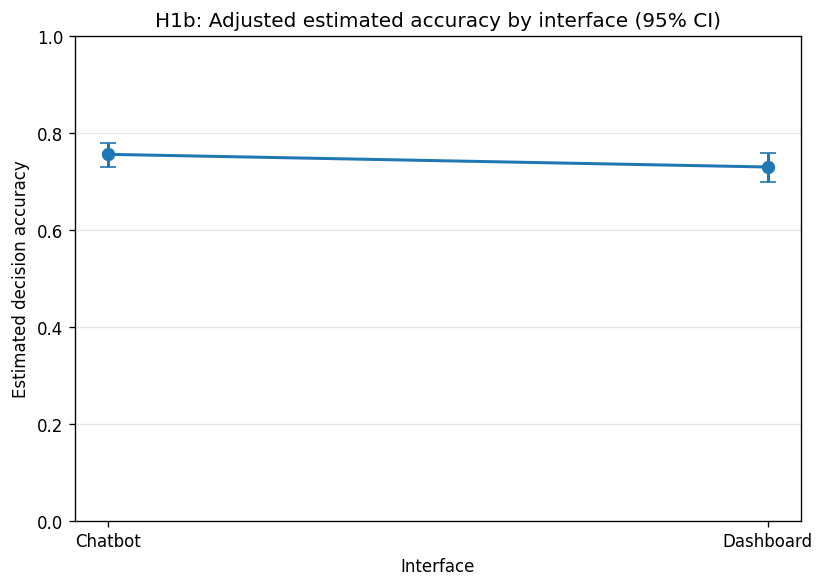

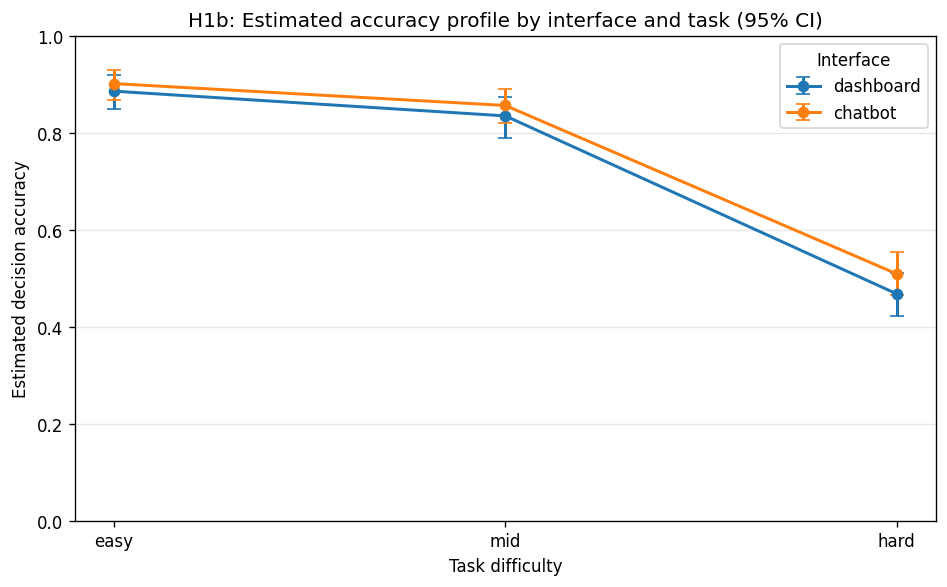

In [57]:
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# ============================================================
# H1b - PLOT ESTIMATED ACCURACY FOR CHATBOT VS DASHBOARD
# Fractional Logit GEE + cluster bootstrap 95% CI
#
# REQUIRED INPUT:
#   accuracy_df
#
# REQUIRED COLUMNS IN accuracy_df:
#   - participant_id
#   - interface_cond
#   - task_code
#   - accuracy_score
#
# NOTE:
#   For H1b the Y-axis should be ESTIMATED DECISION ACCURACY,
#   not workload. Workload belongs to H1a.
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
PARTICIPANT_COL = "participant_id"
INTERFACE_COL   = "interface_cond"
TASK_COL        = "task_code"
Y_COL           = "accuracy_score"

REF_INTERFACE   = "dashboard"
FOCAL_INTERFACE = "chatbot"

TASK_ORDER  = ["T1", "T2", "T3"]
TASK_LABELS = {"T1": "easy", "T2": "mid", "T3": "hard"}

WORKING_CORR = "exchangeable"   # "exchangeable" or "independence"
BOOT = 2000
BOOT_SEED = 1
ALPHA = 0.05

# Plot settings
FIGSIZE_MAIN = (7, 5)
FIGSIZE_PROFILE = (8, 5)
DPI = 120

# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return (
        float(np.quantile(x, alpha / 2)),
        float(np.quantile(x, 1 - alpha / 2))
    )

def print_section(title):
    print("\n" + "=" * 92)
    print(title)
    print("=" * 92)

def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()
    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()
    elif kind == "independence":
        return sm.cov_struct.Independence()
    else:
        raise ValueError(f"Unknown WORKING_CORR: {kind}")

def prepare_data(input_df):
    df = input_df.copy()

    needed = [PARTICIPANT_COL, INTERFACE_COL, TASK_COL, Y_COL]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df.dropna(subset=needed).copy()

    df[PARTICIPANT_COL] = df[PARTICIPANT_COL].astype(str)
    df[INTERFACE_COL] = df[INTERFACE_COL].astype(str).str.lower().str.strip()
    df[TASK_COL] = df[TASK_COL].astype(str).str.strip()
    df[Y_COL] = pd.to_numeric(df[Y_COL], errors="coerce")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[Y_COL]).copy()

    if (df[Y_COL] < 0).any() or (df[Y_COL] > 1).any():
        bad = df.loc[(df[Y_COL] < 0) | (df[Y_COL] > 1), Y_COL].head().tolist()
        raise ValueError(f"{Y_COL} must be in [0,1]. Examples of bad values: {bad}")

    # keep only the two expected interfaces
    df = df[df[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()

    # keep only expected task levels
    df = df[df[TASK_COL].isin(TASK_ORDER)].copy()

    # remove participants assigned to >1 interface
    n_conds = df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface (up to 10 shown): {bad}")
        keep_ids = n_conds[n_conds == 1].index
        df = df[df[PARTICIPANT_COL].isin(keep_ids)].copy()

    # categorical coding
    df[INTERFACE_COL] = pd.Categorical(
        df[INTERFACE_COL],
        categories=[REF_INTERFACE, FOCAL_INTERFACE],
        ordered=False
    )
    df[TASK_COL] = pd.Categorical(
        df[TASK_COL],
        categories=TASK_ORDER,
        ordered=False
    )

    df = df.sort_values([PARTICIPANT_COL, TASK_COL]).reset_index(drop=True)
    return df

def fit_fractional_gee(data):
    formula = (
        f"{Y_COL} ~ "
        f"C({INTERFACE_COL}, Treatment(reference='{REF_INTERFACE}')) + "
        f"C({TASK_COL}, Treatment(reference='{TASK_ORDER[0]}'))"
    )

    model = smf.gee(
        formula=formula,
        groups=data[PARTICIPANT_COL],
        data=data,
        family=sm.families.Binomial(),
        cov_struct=make_cov_struct(WORKING_CORR)
    )
    return model.fit(maxiter=200)

def predict_interface_mean_equal_weight(res, df, interface_level):
    """
    Adjusted mean for one interface, averaging equally over T1/T2/T3.
    """
    grid = pd.DataFrame({
        INTERFACE_COL: pd.Categorical(
            [interface_level] * len(TASK_ORDER),
            categories=list(df[INTERFACE_COL].cat.categories)
        ),
        TASK_COL: pd.Categorical(
            TASK_ORDER,
            categories=list(df[TASK_COL].cat.categories)
        )
    })
    preds = np.asarray(res.predict(grid), dtype=float)
    return float(np.mean(preds))

def predict_cell_mean(res, df, interface_level, task_level):
    """
    Predicted mean for one interface x task cell.
    """
    grid = pd.DataFrame({
        INTERFACE_COL: pd.Categorical(
            [interface_level],
            categories=list(df[INTERFACE_COL].cat.categories)
        ),
        TASK_COL: pd.Categorical(
            [task_level],
            categories=list(df[TASK_COL].cat.categories)
        )
    })
    pred = np.asarray(res.predict(grid), dtype=float)
    return float(pred[0])

def compute_point_estimands(res, df):
    out = {}

    # main adjusted marginal means by interface
    out["adj_mean_dashboard"] = predict_interface_mean_equal_weight(res, df, REF_INTERFACE)
    out["adj_mean_chatbot"] = predict_interface_mean_equal_weight(res, df, FOCAL_INTERFACE)
    out["diff_prob"] = out["adj_mean_chatbot"] - out["adj_mean_dashboard"]

    # interface x task profile
    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        for task in TASK_ORDER:
            key = f"cell__{iface}__{task}"
            out[key] = predict_cell_mean(res, df, iface, task)

    return out

def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []
    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)

def bootstrap_estimands(df, n_boot=2000, seed=1):
    rng = np.random.default_rng(seed)
    draws = []

    for b in range(n_boot):
        boot = resample_clusters(df, PARTICIPANT_COL, rng)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res_b = fit_fractional_gee(boot)
            draws.append(compute_point_estimands(res_b, boot))
        except Exception:
            continue

    if len(draws) == 0:
        return pd.DataFrame()

    return pd.DataFrame(draws)

# ============================================================
# RUN MODEL
# ============================================================
df = prepare_data(accuracy_df)

print_section("0) DATA CHECK")
print(f"Rows: {len(df)}")
print(f"Participants: {df[PARTICIPANT_COL].nunique()}")
print("\nRows by interface x task:")
print(
    df.groupby([INTERFACE_COL, TASK_COL], observed=False)
      .size()
      .reset_index(name="n")
      .to_string(index=False)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res = fit_fractional_gee(df)

point_est = compute_point_estimands(res, df)
boot_df = bootstrap_estimands(df, n_boot=BOOT, seed=BOOT_SEED)

# ============================================================
# BUILD TABLES FOR PLOTTING
# ============================================================
# Main plot: adjusted means by interface
main_rows = []
for iface in [FOCAL_INTERFACE, REF_INTERFACE]:
    key = f"adj_mean_{iface}"
    est = point_est[key]
    lo, hi = pct_ci(boot_df[key], alpha=ALPHA) if key in boot_df.columns else (np.nan, np.nan)
    main_rows.append({
        "interface": iface,
        "estimate": est,
        "ci_low": lo,
        "ci_high": hi
    })

plot_main_df = pd.DataFrame(main_rows)

# Secondary profile plot: predicted interface x task cells
profile_rows = []
for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
    for task in TASK_ORDER:
        key = f"cell__{iface}__{task}"
        est = point_est[key]
        lo, hi = pct_ci(boot_df[key], alpha=ALPHA) if key in boot_df.columns else (np.nan, np.nan)
        profile_rows.append({
            "interface": iface,
            "task_code": task,
            "task_label": TASK_LABELS[task],
            "estimate": est,
            "ci_low": lo,
            "ci_high": hi
        })

plot_profile_df = pd.DataFrame(profile_rows)

# ============================================================
# PRINT NUMERIC SUMMARY
# ============================================================
print_section("1) MAIN ADJUSTED MEANS BY INTERFACE")
print(plot_main_df.to_string(index=False))

print_section("2) INTERFACE x TASK PREDICTED PROFILE")
print(plot_profile_df.to_string(index=False))

# ============================================================
# PLOT 1: MAIN H1b PLOT
# X = chatbot/dashboard
# Y = estimated decision accuracy
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE_MAIN, dpi=DPI)

x_labels = [FOCAL_INTERFACE, REF_INTERFACE]
x = np.arange(len(x_labels))

tmp = (
    plot_main_df.set_index("interface")
                .loc[x_labels]
                .reset_index()
)

y = tmp["estimate"].to_numpy(dtype=float)
yerr_low = y - tmp["ci_low"].to_numpy(dtype=float)
yerr_high = tmp["ci_high"].to_numpy(dtype=float) - y

ax.errorbar(
    x,
    y,
    yerr=[yerr_low, yerr_high],
    fmt="o-",
    capsize=5,
    linewidth=1.8,
    markersize=7
)

ax.set_xticks(x)
ax.set_xticklabels(["Chatbot", "Dashboard"])
ax.set_ylabel("Estimated decision accuracy")
ax.set_xlabel("Interface")
ax.set_title("H1b: Adjusted estimated accuracy by interface (95% CI)")
ax.set_ylim(0, 1)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: PROFILE PLOT BY TASK
# one line for chatbot, one for dashboard
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE_PROFILE, dpi=DPI)

x = np.arange(len(TASK_ORDER))

for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
    sub = (
        plot_profile_df[plot_profile_df["interface"] == iface]
        .set_index("task_code")
        .loc[TASK_ORDER]
        .reset_index()
    )

    y = sub["estimate"].to_numpy(dtype=float)
    yerr_low = y - sub["ci_low"].to_numpy(dtype=float)
    yerr_high = sub["ci_high"].to_numpy(dtype=float) - y

    ax.errorbar(
        x,
        y,
        yerr=[yerr_low, yerr_high],
        fmt="o-",
        capsize=4,
        linewidth=1.8,
        markersize=6,
        label=iface
    )

ax.set_xticks(x)
ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER])
ax.set_ylabel("Estimated decision accuracy")
ax.set_xlabel("Task difficulty")
ax.set_title("H1b: Estimated accuracy profile by interface and task (95% CI)")
ax.set_ylim(0, 1)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(title="Interface")

plt.tight_layout()
plt.show()

# H2B

In [7]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from patsy import build_design_matrices
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

try:
    from IPython.display import display
except Exception:
    display = print

# ============================================================
# H2b - FRACTIONAL LOGIT GEE (VERBOSE DIAGNOSTIC SCRIPT)
# Hypothesis:
#   Task complexity moderates the effect of interface type
#   on decision accuracy in [0,1], such that the overall
#   advantage of the conversational interface attenuates
#   as task complexity rises.
#
# REQUIRED INPUT:
#   accuracy_df with columns:
#       participant_id, interface_cond, task_code, accuracy_score
#
# MODEL:
#   full: accuracy_score ~ interface_cond * task_code
#   add : accuracy_score ~ interface_cond + task_code
#
# REFERENCE LEVELS:
#   interface_cond: dashboard
#   task_code:      T1
#
# PRIMARY H2b TARGETS:
#   1) Omnibus interaction Wald test
#   2) Simple effects of interface within each task
#   3) PRIMARY DiD = [chatbot-dashboard]@T3 - [chatbot-dashboard]@T1
#
# DIRECTION SUPPORTING H2b:
#   Since the focal contrast is chatbot - dashboard,
#   attenuation of chatbot advantage implies:
#       DiD < 0
#
# MULTIPLICITY CONTROL:
#   Holm correction is applied to:
#   - simple interface effects within task (3 tests)
#   - internal DiD contrasts (3 tests)
#   - task effects within interface (3 tests within dashboard,
#     3 tests within chatbot; corrected separately by interface)
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PARTICIPANT_COL = "participant_id"
INTERFACE_COL   = "interface_cond"
TASK_COL        = "task_code"
Y_COL           = "accuracy_score"

TASK_ORDER = ["T1", "T2", "T3"]
TASK_LABELS = {"T1": "easy", "T2": "mid", "T3": "hard"}

REF_INTERFACE   = "dashboard"
FOCAL_INTERFACE = "chatbot"

WORKING_CORR = "exchangeable"   # alternative: "independence"
BOOT = 2000
BOOT_SEED = 1

SHOW_ALL_COEFFICIENT_TABLES = True
MULTIPLICITY_METHOD = "holm"


# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def yes_no(x):
    if pd.isna(x):
        return "NA"
    return "Yes" if bool(x) else "No"

def print_section(title):
    print("\n" + "=" * 96)
    print(title)
    print("=" * 96)

def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def cohens_h(p1, p0, eps=1e-12):
    p1 = np.clip(float(p1), eps, 1 - eps)
    p0 = np.clip(float(p0), eps, 1 - eps)
    return float(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p0)))

def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()
    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()
    elif kind == "independence":
        return sm.cov_struct.Independence()
    else:
        raise ValueError(f"Unknown WORKING_CORR: {kind}")

def get_working_corr_param(res):
    try:
        dep = getattr(res.cov_struct, "dep_params", None)
        if dep is None:
            return np.nan
        arr = np.asarray(dep, dtype=float).reshape(-1)
        if arr.size == 0:
            return np.nan
        return float(arr[0])
    except Exception:
        return np.nan

def get_qic_safe(res):
    try:
        q = res.qic()
        if isinstance(q, tuple) and len(q) >= 2:
            return float(q[0]), float(q[1])
        if np.isscalar(q):
            return float(q), np.nan
        return np.nan, np.nan
    except Exception:
        return np.nan, np.nan

def get_fit_history_safe(res):
    fh = getattr(res, "fit_history", None)
    if fh is None:
        return {}
    return fh

def fit_fractional_gee(formula, data, group_col):
    model = smf.gee(
        formula=formula,
        groups=data[group_col],
        data=data,
        family=sm.families.Binomial(),
        cov_struct=make_cov_struct(WORKING_CORR)
    )
    return model.fit(maxiter=200)

def prepare_data(input_df):
    df = input_df.copy()
    df = df.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL, TASK_COL, Y_COL]).copy()

    df[Y_COL] = df[Y_COL].astype(float)
    df[INTERFACE_COL] = df[INTERFACE_COL].astype(str).str.lower().str.strip()
    df[TASK_COL] = df[TASK_COL].astype(str).str.strip()

    if (df[Y_COL] < 0).any() or (df[Y_COL] > 1).any():
        raise ValueError(f"{Y_COL} must be in [0,1].")

    n_conds = df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface (up to 10 shown): {bad}")
        keep = n_conds[n_conds == 1].index
        df = df[df[PARTICIPANT_COL].isin(keep)].copy()

    missing_tasks = [t for t in TASK_ORDER if t not in set(df[TASK_COL])]
    if missing_tasks:
        raise ValueError(f"Missing task levels: {missing_tasks}")

    df = df[df[TASK_COL].isin(TASK_ORDER)].copy()

    iface_levels = sorted(df[INTERFACE_COL].unique().tolist())
    expected = {REF_INTERFACE, FOCAL_INTERFACE}
    if set(iface_levels) != expected:
        raise ValueError(f"Expected interfaces {expected}, found {iface_levels}")

    df[INTERFACE_COL] = pd.Categorical(
        df[INTERFACE_COL],
        categories=[REF_INTERFACE, FOCAL_INTERFACE],
        ordered=False
    )
    df[TASK_COL] = pd.Categorical(
        df[TASK_COL],
        categories=TASK_ORDER,
        ordered=False
    )
    return df

def param_table_logit(res):
    est = pd.Series(res.params, index=res.params.index, dtype=float)
    se = pd.Series(res.bse, index=res.bse.index, dtype=float)
    z = est / se
    p = 2 * stats.norm.sf(np.abs(z))
    lo = est - Z * se
    hi = est + Z * se
    return pd.DataFrame({
        "Estimate_logit": est,
        "SE_robust": se,
        "z": z,
        "p": p,
        "CI_low_logit": lo,
        "CI_high_logit": hi,
        "OR": np.exp(est),
        "OR_CI_low": np.exp(lo),
        "OR_CI_high": np.exp(hi),
    })

def term_index(res, contains_all=None, contains_none=None):
    contains_all = contains_all or []
    contains_none = contains_none or []
    names = list(res.params.index)
    out = []
    for i, nm in enumerate(names):
        ok_all = all(s in nm for s in contains_all)
        ok_none = all(s not in nm for s in contains_none)
        if ok_all and ok_none:
            out.append(i)
    return out

def joint_wald_test(res, idx, label):
    k = len(res.params)
    idx = list(idx)
    if len(idx) == 0:
        return {"Effect": label, "chi2": np.nan, "df": 0, "p": np.nan}

    L = np.zeros((len(idx), k), dtype=float)
    for r, j in enumerate(idx):
        L[r, j] = 1.0

    try:
        wt = res.wald_test(L, scalar=True)
    except TypeError:
        wt = res.wald_test(L)

    stat = float(np.asarray(wt.statistic).squeeze())
    p = float(np.asarray(wt.pvalue).squeeze())
    return {"Effect": label, "chi2": stat, "df": len(idx), "p": p}

def _newdata_for_cell(res, interface_level, task_level):
    base = res.model.data.frame
    int_cats = list(pd.Categorical(base[INTERFACE_COL]).categories)
    task_cats = list(pd.Categorical(base[TASK_COL]).categories)

    nd = pd.DataFrame({
        INTERFACE_COL: [interface_level],
        TASK_COL: [task_level]
    })
    nd[INTERFACE_COL] = pd.Categorical(nd[INTERFACE_COL], categories=int_cats)
    nd[TASK_COL] = pd.Categorical(nd[TASK_COL], categories=task_cats)
    return nd

def design_row(res, interface_level, task_level):
    nd = _newdata_for_cell(res, interface_level, task_level)
    X = build_design_matrices([res.model.data.design_info], nd)[0]
    return np.asarray(X, dtype=float).reshape(-1)

def cell_prob(res, interface_level, task_level):
    nd = _newdata_for_cell(res, interface_level, task_level)
    return float(np.asarray(res.predict(nd)).reshape(-1)[0])

def linear_contrast(res, c):
    b = np.asarray(res.params, dtype=float).reshape(-1)
    V = np.asarray(res.cov_params(), dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ b)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_logit": est,
        "SE_robust": se,
        "CI_low_logit": lo,
        "CI_high_logit": hi,
        "z": z,
        "p": p,
        "OR": float(np.exp(est)),
        "OR_CI_low": float(np.exp(lo)),
        "OR_CI_high": float(np.exp(hi)),
    }

def interface_effect_prob(res, task_level):
    p_focal = cell_prob(res, FOCAL_INTERFACE, task_level)
    p_ref = cell_prob(res, REF_INTERFACE, task_level)
    return p_focal - p_ref

def simple_effect_logit_contrast(res, task_level):
    x_focal = design_row(res, FOCAL_INTERFACE, task_level)
    x_ref = design_row(res, REF_INTERFACE, task_level)
    return linear_contrast(res, x_focal - x_ref)

def task_effect_prob_within_interface(res, interface_level, task_a, task_b):
    return cell_prob(res, interface_level, task_b) - cell_prob(res, interface_level, task_a)

def task_effect_logit_contrast(res, interface_level, task_a, task_b):
    x_b = design_row(res, interface_level, task_b)
    x_a = design_row(res, interface_level, task_a)
    return linear_contrast(res, x_b - x_a)

def did_prob(res, task_a, task_b):
    # [chatbot-dashboard]@task_b - [chatbot-dashboard]@task_a
    diff_a = interface_effect_prob(res, task_a)
    diff_b = interface_effect_prob(res, task_b)
    return diff_b - diff_a

def did_logit_contrast(res, task_a, task_b):
    x_fb = design_row(res, FOCAL_INTERFACE, task_b)
    x_rb = design_row(res, REF_INTERFACE, task_b)
    x_fa = design_row(res, FOCAL_INTERFACE, task_a)
    x_ra = design_row(res, REF_INTERFACE, task_a)
    c = (x_fb - x_rb) - (x_fa - x_ra)
    return linear_contrast(res, c)

def standardized_mean_for_interface(res, data, interface_level):
    d = data.copy()
    d[INTERFACE_COL] = pd.Categorical(
        [interface_level] * len(d),
        categories=list(data[INTERFACE_COL].cat.categories)
    )
    d[TASK_COL] = pd.Categorical(
        d[TASK_COL],
        categories=list(data[TASK_COL].cat.categories)
    )
    return float(np.mean(np.asarray(res.predict(d), dtype=float)))

def standardized_mean_for_task(res, data, task_level):
    d = data.copy()
    d[TASK_COL] = pd.Categorical(
        [task_level] * len(d),
        categories=list(data[TASK_COL].cat.categories)
    )
    d[INTERFACE_COL] = pd.Categorical(
        d[INTERFACE_COL],
        categories=list(data[INTERFACE_COL].cat.categories)
    )
    return float(np.mean(np.asarray(res.predict(d), dtype=float)))

def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []
    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)

def h2_boot_estimands(res, data):
    out = {}

    for i in [REF_INTERFACE, FOCAL_INTERFACE]:
        for t in TASK_ORDER:
            out[f"CELL__{i}__{t}"] = cell_prob(res, i, t)

    for t in TASK_ORDER:
        pf = cell_prob(res, FOCAL_INTERFACE, t)
        pr = cell_prob(res, REF_INTERFACE, t)
        out[f"DIFF__{t}"] = pf - pr
        out[f"H__{t}"] = cohens_h(pf, pr)

    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        out[f"TASKDIFF__{iface}__T2_vs_T1"] = task_effect_prob_within_interface(res, iface, "T1", "T2")
        out[f"TASKDIFF__{iface}__T3_vs_T1"] = task_effect_prob_within_interface(res, iface, "T1", "T3")
        out[f"TASKDIFF__{iface}__T3_vs_T2"] = task_effect_prob_within_interface(res, iface, "T2", "T3")

    out["DID__T2_vs_T1"] = out["DIFF__T2"] - out["DIFF__T1"]
    out["DID__T3_vs_T2"] = out["DIFF__T3"] - out["DIFF__T2"]
    out["DID__T3_vs_T1"] = out["DIFF__T3"] - out["DIFF__T1"]

    p_chat = standardized_mean_for_interface(res, data, FOCAL_INTERFACE)
    p_dash = standardized_mean_for_interface(res, data, REF_INTERFACE)
    out["OVERALL__chatbot"] = p_chat
    out["OVERALL__dashboard"] = p_dash
    out["OVERALL__diff"] = p_chat - p_dash
    out["OVERALL__h"] = cohens_h(p_chat, p_dash)

    return out

def bootstrap_h2(df, formula):
    rng = np.random.default_rng(BOOT_SEED)
    draws = []

    for _ in range(BOOT):
        boot = resample_clusters(df, PARTICIPANT_COL, rng)
        try:
            res_b = fit_fractional_gee(formula, boot, PARTICIPANT_COL)
            draws.append(h2_boot_estimands(res_b, boot))
        except Exception:
            continue

    if len(draws) == 0:
        return pd.DataFrame()

    return pd.DataFrame(draws)

def holm_adjust_series(pvals, alpha=0.05):
    p = pd.to_numeric(pd.Series(pvals), errors="coerce")
    adj = pd.Series(np.nan, index=p.index, dtype=float)
    reject = pd.Series(False, index=p.index, dtype=bool)

    valid = p.notna()
    if valid.any():
        rej, p_adj, _, _ = multipletests(p[valid].to_numpy(), alpha=alpha, method="holm")
        adj.loc[valid] = p_adj
        reject.loc[valid] = rej

    return adj, reject

def add_holm_correction(df, p_col, family_name=None, group_cols=None, alpha=0.05):
    out = df.copy()
    out["p_value_holm"] = np.nan
    out["reject_holm"] = False

    if group_cols is None:
        adj, rej = holm_adjust_series(out[p_col], alpha=alpha)
        out["p_value_holm"] = adj
        out["reject_holm"] = rej
        out["holm_family"] = family_name if family_name is not None else "all_tests"
        return out

    if isinstance(group_cols, str):
        group_cols = [group_cols]

    out["holm_family"] = out[group_cols].astype(str).agg(" | ".join, axis=1)

    grouped = out.groupby(group_cols, dropna=False, sort=False)
    for grp_key, idx in grouped.groups.items():
        idx = list(idx)
        adj, rej = holm_adjust_series(out.loc[idx, p_col], alpha=alpha)
        out.loc[idx, "p_value_holm"] = adj.to_numpy()
        out.loc[idx, "reject_holm"] = rej.to_numpy()

        if family_name is not None:
            label = f"{family_name} | {grp_key}" if not isinstance(grp_key, tuple) else f"{family_name} | {' | '.join(map(str, grp_key))}"
            out.loc[idx, "holm_family"] = label

    return out

def did_decision(est, low, high):
    if np.isnan(est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if est < 0 and high < 0:
        return "SUPPORTS H2b: the gap chatbot-dashboard decreases for the more difficult task"
    if est < 0 and low <= 0 <= high:
        return "Direction consistent with H2b, but CI include 0"
    if est > 0 and low > 0:
        return "OPPOSITE RESULT TO H2b: the gap chatbot-dashboard increases for the more difficult task"
    if est > 0 and low <= 0 <= high:
        return "Direction opposite to H2b, but CI include 0"
    return "No clear conclusion"

def simple_interface_decision(est, low, high):
    if np.isnan(est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if est > 0 and low > 0:
        return "chatbot > dashboard to this task"
    if est > 0 and low <= 0 <= high:
        return "Direction consistent with chatbot > dashboard, but CI include 0"
    if est < 0 and high < 0:
        return "chatbot < dashboard to this task"
    if est < 0 and low <= 0 <= high:
        return "Direction consistent with chatbot < dashboard, but CI include 0"
    return "No clear conclusion"

def print_df_or_message(df, msg_if_none):
    if df is None or len(df) == 0:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))


# ============================================================
# DATA + MODELS
# ============================================================
df = prepare_data(accuracy_df)

I = f"C({INTERFACE_COL}, Treatment(reference='{REF_INTERFACE}'))"
T = f"C({TASK_COL}, Treatment(reference='{TASK_ORDER[0]}'))"

full_f = f"{Y_COL} ~ {I} * {T}"
add_f  = f"{Y_COL} ~ {I} + {T}"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    full_res = fit_fractional_gee(full_f, df, PARTICIPANT_COL)
    add_res  = fit_fractional_gee(add_f,  df, PARTICIPANT_COL)

# ============================================================
# 0) DATA SETUP
# ============================================================
print_section("0) DATA SETUP AND CHECKS")
print(f"Rows: {df.shape[0]}")
print(f"Participants: {df[PARTICIPANT_COL].nunique()}")
print(f"Primary contrast direction: {FOCAL_INTERFACE} - {REF_INTERFACE}")
print(f"Task order: {TASK_ORDER} ({TASK_LABELS['T1']} -> {TASK_LABELS['T2']} -> {TASK_LABELS['T3']})")
print(f"Working correlation: {WORKING_CORR}")
print(f"Multiplicity correction for follow-up contrasts: {MULTIPLICITY_METHOD}")

cluster_sizes = df.groupby(PARTICIPANT_COL).size()
print("\nDistribution of observations for participant:")
print(cluster_sizes.describe())

cell_n = (
    df.groupby([INTERFACE_COL, TASK_COL], observed=False)
      .size()
      .reset_index(name="n")
)
print("\nNumber of rows for cell interface x task:")
print(cell_n.to_string(index=False))

# ============================================================
# 0b) MODEL OVERVIEW
# ============================================================
print_section("0b) WHICH MODEL IS BEING CHECKED")
print(f"Additive model: {add_f}")
print(f"Full model: {full_f}")
print("\nReference coding:")
print(f"- {INTERFACE_COL}: {REF_INTERFACE} = reference")
print(f"- {TASK_COL}: {TASK_ORDER[0]} = reference")
print("\nInterpretation of the coefficients in the full model:")
print("- Intercept = dashboard @ T1")
print("- C(interface)[T.chatbot] = chatbot - dashboard @ T1")
print("- C(task)[T.T2] = T2 - T1 in the dashboard")
print("- C(task)[T.T3] = T3 - T1 in the dashboard")
print("- interaction chatbot:T2 = DiD T2 vs T1")
print("- interaction chatbot:T3 = DiD T3 vs T1")
print("\nThe primary targets for H2b are:")
print("1) Wald omnibus of the interaction")
print("2) Simple effects of the interface within T1/T2/T3")
print("3) PRIMARY DID = [chatbot-dashboard]@T3 - [chatbot-dashboard]@T1")
print("\nDirection supporting H2b:")
print("- chatbot-dashboard > 0 within a task = chatbot advantage in that task")
print("- DID < 0 = the chatbot advantage narrows as task difficulty increases")
print("\nCorrection Holm applied to the follow-up:")
print("- Simple interface effects: 3 test")
print("- Internal DiD contrasts: 3 test")
print("- Task effects within interface: 3 test within dashboard and 3 test within chatbot")

# ============================================================
# 1) RAW DESCRIPTIVE STATISTICS
# ============================================================
print_section("1) RAW DESCRIPTIVE STATISTICS OF ACCURACY")

desc_by_interface = (
    df.groupby(INTERFACE_COL, observed=False)[Y_COL]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n"})
)
desc_by_interface["iqr"] = (
    df.groupby(INTERFACE_COL, observed=False)[Y_COL]
      .apply(iqr_num)
      .values
)

desc_by_cell = (
    df.groupby([INTERFACE_COL, TASK_COL], observed=False)[Y_COL]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n"})
)
desc_by_cell["iqr"] = (
    df.groupby([INTERFACE_COL, TASK_COL], observed=False)[Y_COL]
      .apply(iqr_num)
      .values
)
desc_by_cell["task_label"] = desc_by_cell[TASK_COL].map(TASK_LABELS)

print("\n1a) Raw accuracy for interface:")
print(desc_by_interface.to_string(index=False))

print("\n1b) Raw accuracy for cell interface x task:")
print(desc_by_cell[[INTERFACE_COL, TASK_COL, "task_label", "n", "mean", "std", "median", "iqr"]].to_string(index=False))

# ============================================================
# 2) MODEL FIT, QIC, WORKING CORR, OMNIBUS
# ============================================================
print_section("2) MODEL FIT, WORKING CORRELATION, QIC E TEST OMNIBUS")

add_qic, add_qicu = get_qic_safe(add_res)
full_qic, full_qicu = get_qic_safe(full_res)

fit_rows = []
for label, res, qic, qicu in [
    ("additive", add_res, add_qic, add_qicu),
    ("full_interaction", full_res, full_qic, full_qicu),
]:
    fit_rows.append({
        "model": label,
        "nobs": getattr(res, "nobs", np.nan),
        "n_params": len(res.params),
        "working_corr": WORKING_CORR,
        "dep_param_est": get_working_corr_param(res),
        "QIC": qic,
        "QICu": qicu,
    })

fit_tbl = pd.DataFrame(fit_rows)
print("2a) Model fit / working correlation:")
print(fit_tbl.to_string(index=False))

idx_task_add = term_index(
    add_res,
    contains_all=[f"C({TASK_COL}", "[T."],
    contains_none=[":"]
)
idx_ifc_add = term_index(
    add_res,
    contains_all=[f"C({INTERFACE_COL}", "[T."],
    contains_none=[":"]
)
idx_int_full = term_index(
    full_res,
    contains_all=[f"C({INTERFACE_COL}", f"C({TASK_COL}", ":"]
)

omnibus_primary = pd.DataFrame([
    joint_wald_test(full_res, idx_int_full, "PRIMARY: INTERFACE × TASK (full model)"),
    joint_wald_test(add_res, idx_ifc_add,  "EXPLORATORY: INTERFACE (additive model)"),
    joint_wald_test(add_res, idx_task_add, "EXPLORATORY: TASK (additive model)"),
])

print("\n2b) Wald omnibus tests:")
print(omnibus_primary.to_string(index=False))

# ============================================================
# 3) COEFFICIENT TABLES
# ============================================================
print_section("3) TABLES COMPLETE OF THE COEFFICIENTS")

add_coef_tbl = param_table_logit(add_res)
full_coef_tbl = param_table_logit(full_res)

if SHOW_ALL_COEFFICIENT_TABLES:
    print("\n3a) Coefficients additive model:")
    print(add_coef_tbl.to_string())

    print("\n3b) Coefficients full model with interaction:")
    print(full_coef_tbl.to_string())

print("\n3c) Interpretation of the coefficients key of the full model:")
for nm in full_res.params.index:
    est = float(full_res.params[nm])
    se = float(full_res.bse[nm])
    z = est / se
    p = 2 * stats.norm.sf(abs(z))
    lo = est - Z * se
    hi = est + Z * se
    print(f"\nTermine: {nm}")
    print(f"- Estimate logit: {fmt(est)}")
    print(f"- SE robust: {fmt(se)}")
    print(f"- z: {fmt(z)}")
    print(f"- {p_fmt(p)}")
    print(f"- 95% CI logit: [{fmt(lo)}, {fmt(hi)}]")
    print(f"- OR / ratio OR: {fmt(np.exp(est))}")
    print(f"- 95% CI OR: [{fmt(np.exp(lo))}, {fmt(np.exp(hi))}]")

# ============================================================
# 4) BOOTSTRAP
# ============================================================
print_section("4) BOOTSTRAP CLUSTER-LEVEL")
print(f"Running cluster bootstrap by participant (B={BOOT})...")
boot_df = bootstrap_h2(df, full_f)
print(f"Bootstrap successful draws: {boot_df.shape[0]}")

# ============================================================
# 5) CELL MEANS
# ============================================================
print_section("5) CELL MEANS PREDDETTE (SCALE RISPOSTA)")

cell_rows = []
for i in [REF_INTERFACE, FOCAL_INTERFACE]:
    for t in TASK_ORDER:
        est = cell_prob(full_res, i, t)
        lo, hi = pct_ci(boot_df[f"CELL__{i}__{t}"]) if f"CELL__{i}__{t}" in boot_df.columns else (np.nan, np.nan)
        cell_rows.append({
            "interface": i,
            "task": t,
            "task_label": TASK_LABELS[t],
            "predicted_accuracy": est,
            "CI_low_boot": lo,
            "CI_high_boot": hi,
        })

cell_means_primary = pd.DataFrame(cell_rows)
print(cell_means_primary.to_string(index=False))

# ============================================================
# 6) SIMPLE EFFECTS OF THE INTERFACE WITHIN TASK
# ============================================================
print_section("6) SIMPLE EFFECTS OF THE INTERFACE WITHIN EACH TASK")

simple_rows = []
for t in TASK_ORDER:
    pf = cell_prob(full_res, FOCAL_INTERFACE, t)
    pr = cell_prob(full_res, REF_INTERFACE, t)
    d = pf - pr
    h = cohens_h(pf, pr)
    logit_out = simple_effect_logit_contrast(full_res, t)

    lo_d, hi_d = pct_ci(boot_df[f"DIFF__{t}"]) if f"DIFF__{t}" in boot_df.columns else (np.nan, np.nan)
    lo_h, hi_h = pct_ci(boot_df[f"H__{t}"]) if f"H__{t}" in boot_df.columns else (np.nan, np.nan)

    simple_rows.append({
        "analysis_role": "PRIMARY simple effect",
        "task": t,
        "task_label": TASK_LABELS[t],
        "pred_chatbot": pf,
        "pred_dashboard": pr,
        "diff_prob": d,
        "diff_prob_CI_low_boot": lo_d,
        "diff_prob_CI_high_boot": hi_d,
        "cohens_h": h,
        "cohens_h_CI_low_boot": lo_h,
        "cohens_h_CI_high_boot": hi_h,
        "logit_effect": logit_out["estimate_logit"],
        "SE_robust": logit_out["SE_robust"],
        "z": logit_out["z"],
        "p_value": logit_out["p"],
        "OR": logit_out["OR"],
        "OR_CI_low": logit_out["OR_CI_low"],
        "OR_CI_high": logit_out["OR_CI_high"],
    })

simple_interface_df = pd.DataFrame(simple_rows)
simple_interface_df = add_holm_correction(
    simple_interface_df,
    p_col="p_value",
    family_name="simple_interface_within_task",
    group_cols=None,
    alpha=ALPHA
)

print(simple_interface_df.to_string(index=False))

print("\nDetailed interpretation:")
for _, row in simple_interface_df.iterrows():
    print(f"\nTask = {row['task']} ({row['task_label']})")
    print(f"- pred_chatbot = {fmt(row['pred_chatbot'])}")
    print(f"- pred_dashboard = {fmt(row['pred_dashboard'])}")
    print(f"- diff_prob = {fmt(row['diff_prob'])}")
    print(f"- 95% CI boot diff = [{fmt(row['diff_prob_CI_low_boot'])}, {fmt(row['diff_prob_CI_high_boot'])}]")
    print(f"- Cohen's h = {fmt(row['cohens_h'])}")
    print(f"- logit_effect = {fmt(row['logit_effect'])}")
    print(f"- OR = {fmt(row['OR'])}")
    print(f"- raw {p_fmt(row['p_value'])}")
    print(f"- Holm-adjusted {p_fmt(row['p_value_holm'])}")
    print(f"- Reject Holm @ alpha={ALPHA}: {yes_no(row['reject_holm'])}")
    print(f"- Decision (direction/CI): {simple_interface_decision(row['diff_prob'], row['diff_prob_CI_low_boot'], row['diff_prob_CI_high_boot'])}")

# ============================================================
# 7) DID CONTRASTS
# ============================================================
print_section("7) DID CONTRASTS (ATTENUATION OF THE ADVANTAGE OF THE CHATBOT)")

did_specs = [
    ("PRIMARY moderation contrast",    "T1", "T3", "DID__T3_vs_T1"),
    ("EXPLORATORY follow-up contrast", "T1", "T2", "DID__T2_vs_T1"),
    ("EXPLORATORY follow-up contrast", "T2", "T3", "DID__T3_vs_T2"),
]

did_rows = []
for role, task_a, task_b, boot_key in did_specs:
    est_prob = did_prob(full_res, task_a, task_b)
    lo_prob, hi_prob = pct_ci(boot_df[boot_key]) if boot_key in boot_df.columns else (np.nan, np.nan)
    out_logit = did_logit_contrast(full_res, task_a, task_b)

    did_rows.append({
        "analysis_role": role,
        "task_a": task_a,
        "task_b": task_b,
        "label": f"DID = [{FOCAL_INTERFACE}-{REF_INTERFACE}]@{task_b} - [{FOCAL_INTERFACE}-{REF_INTERFACE}]@{task_a}",
        "diff_prob": est_prob,
        "diff_prob_CI_low_boot": lo_prob,
        "diff_prob_CI_high_boot": hi_prob,
        "logit_effect": out_logit["estimate_logit"],
        "SE_robust": out_logit["SE_robust"],
        "z": out_logit["z"],
        "p_value": out_logit["p"],
        "ratio_OR": out_logit["OR"],
        "ratio_OR_CI_low": out_logit["OR_CI_low"],
        "ratio_OR_CI_high": out_logit["OR_CI_high"],
    })

did_df = pd.DataFrame(did_rows)
did_df = add_holm_correction(
    did_df,
    p_col="p_value",
    family_name="internal_did_contrasts",
    group_cols=None,
    alpha=ALPHA
)

print(did_df.to_string(index=False))

print("\nInterpretation of the DiD:")
for _, row in did_df.iterrows():
    print(f"\n{row['label']}")
    print(f"- diff_prob = {fmt(row['diff_prob'])}")
    print(f"- 95% CI boot diff = [{fmt(row['diff_prob_CI_low_boot'])}, {fmt(row['diff_prob_CI_high_boot'])}]")
    print(f"- logit_effect = {fmt(row['logit_effect'])}")
    print(f"- ratio_OR = {fmt(row['ratio_OR'])}")
    print(f"- raw {p_fmt(row['p_value'])}")
    print(f"- Holm-adjusted {p_fmt(row['p_value_holm'])}")
    print(f"- Reject Holm @ alpha={ALPHA}: {yes_no(row['reject_holm'])}")
    print("- Negative = the advantage chatbot-dashboard is smaller in the task more difficult.")
    print(f"- Decision (direction/CI): {did_decision(row['diff_prob'], row['diff_prob_CI_low_boot'], row['diff_prob_CI_high_boot'])}")

# ============================================================
# 8) SIMPLE EFFECTS OF THE TASK WITHIN INTERFACE
# ============================================================
print_section("8) SIMPLE EFFECTS OF THE TASK WITHIN EACH INTERFACE")

task_specs = [
    ("T1", "T2", "mid_minus_easy"),
    ("T1", "T3", "hard_minus_easy"),
    ("T2", "T3", "hard_minus_mid"),
]

task_rows = []
for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
    for task_a, task_b, label in task_specs:
        diff_prob = task_effect_prob_within_interface(full_res, iface, task_a, task_b)
        out_logit = task_effect_logit_contrast(full_res, iface, task_a, task_b)
        boot_key = f"TASKDIFF__{iface}__{task_b}_vs_{task_a}"
        lo, hi = pct_ci(boot_df[boot_key]) if boot_key in boot_df.columns else (np.nan, np.nan)

        task_rows.append({
            "interface": iface,
            "contrast": label,
            "from_task": task_a,
            "to_task": task_b,
            "diff_prob": diff_prob,
            "diff_prob_CI_low_boot": lo,
            "diff_prob_CI_high_boot": hi,
            "logit_effect": out_logit["estimate_logit"],
            "SE_robust": out_logit["SE_robust"],
            "z": out_logit["z"],
            "p_value": out_logit["p"],
            "OR": out_logit["OR"],
            "OR_CI_low": out_logit["OR_CI_low"],
            "OR_CI_high": out_logit["OR_CI_high"],
        })

task_effects_df = pd.DataFrame(task_rows)
task_effects_df = add_holm_correction(
    task_effects_df,
    p_col="p_value",
    family_name="task_effects_within_interface",
    group_cols="interface",
    alpha=ALPHA
)

print(task_effects_df.to_string(index=False))

print("\nInterpretation:")
print("- These rows show how much changes l'accuracy passando from T1/T2/T3 within dashboard and within chatbot.")
print("- If the chatbot loses more advantage of the dashboard to the increasing of the difficulty, the pattern is consistent with H2b.")
print("- In practice, for H2b the gap chatbot-dashboard must decrease for the more difficult task.")
print("- If invece the chatbot degrada less of the dashboard, the chatbot advantage si amplia and the pattern va in the direction opposite.")
print("- THE p-value Holm are corretti separately within dashboard and within chatbot.")

for _, row in task_effects_df.iterrows():
    print(f"\nInterface = {row['interface']} | contrast = {row['contrast']} ({row['from_task']} -> {row['to_task']})")
    print(f"- diff_prob = {fmt(row['diff_prob'])}")
    print(f"- 95% CI boot diff = [{fmt(row['diff_prob_CI_low_boot'])}, {fmt(row['diff_prob_CI_high_boot'])}]")
    print(f"- logit_effect = {fmt(row['logit_effect'])}")
    print(f"- OR = {fmt(row['OR'])}")
    print(f"- raw {p_fmt(row['p_value'])}")
    print(f"- Holm-adjusted {p_fmt(row['p_value_holm'])}")
    print(f"- Reject Holm @ alpha={ALPHA}: {yes_no(row['reject_holm'])}")

# ============================================================
# 9) EFFECT SIZE SUMMARY
# ============================================================
print_section("9) EFFECT SIZE SUMMARY")

effect_size_rows = []

for _, row in simple_interface_df.iterrows():
    effect_size_rows.append({
        "family": "simple_interface",
        "label": f"{FOCAL_INTERFACE}-{REF_INTERFACE}@{row['task']}",
        "prob_diff": row["diff_prob"],
        "prob_diff_CI_low_boot": row["diff_prob_CI_low_boot"],
        "prob_diff_CI_high_boot": row["diff_prob_CI_high_boot"],
        "cohens_h": row["cohens_h"],
        "cohens_h_CI_low_boot": row["cohens_h_CI_low_boot"],
        "cohens_h_CI_high_boot": row["cohens_h_CI_high_boot"],
        "logit_effect": row["logit_effect"],
        "OR_or_ratioOR": row["OR"],
        "p_value": row["p_value"],
        "p_value_holm": row["p_value_holm"],
        "reject_holm": row["reject_holm"],
    })

for _, row in did_df.iterrows():
    effect_size_rows.append({
        "family": "did",
        "label": row["label"],
        "prob_diff": row["diff_prob"],
        "prob_diff_CI_low_boot": row["diff_prob_CI_low_boot"],
        "prob_diff_CI_high_boot": row["diff_prob_CI_high_boot"],
        "cohens_h": np.nan,
        "cohens_h_CI_low_boot": np.nan,
        "cohens_h_CI_high_boot": np.nan,
        "logit_effect": row["logit_effect"],
        "OR_or_ratioOR": row["ratio_OR"],
        "p_value": row["p_value"],
        "p_value_holm": row["p_value_holm"],
        "reject_holm": row["reject_holm"],
    })

effect_sizes_df = pd.DataFrame(effect_size_rows)
print(effect_sizes_df.to_string(index=False))

print("\nInterpretation:")
print("- prob_diff = difference in accuracy predicted on the scale original")
print("- Cohen's h = standardized effect size for differences between proportions")
print("- logit_effect = contrast on the log scaleit")
print("- OR_or_ratioOR = odds ratio per simple effects, ratio of ORs per i DiD")
print("- p_value_holm = p-value correct for multiple comparisons within the respective family")

# ============================================================
# 10) OVERALL STANDARDIZED INTERFACE EFFECT (NOT PRIMARIO FOR H2)
# ============================================================
print_section("10) OVERALL INTERFACE EFFECT STANDARDIZED (NOT PRIMARIO FOR H2b)")

overall_add_chat = standardized_mean_for_interface(add_res, df, FOCAL_INTERFACE)
overall_add_dash = standardized_mean_for_interface(add_res, df, REF_INTERFACE)
overall_add_diff = overall_add_chat - overall_add_dash
overall_add_h = cohens_h(overall_add_chat, overall_add_dash)

overall_full_chat = standardized_mean_for_interface(full_res, df, FOCAL_INTERFACE)
overall_full_dash = standardized_mean_for_interface(full_res, df, REF_INTERFACE)
overall_full_diff = overall_full_chat - overall_full_dash
overall_full_h = cohens_h(overall_full_chat, overall_full_dash)

overall_add_logit = linear_contrast(
    add_res,
    design_row(add_res, FOCAL_INTERFACE, "T1") - design_row(add_res, REF_INTERFACE, "T1")
)

lo_overall_chat, hi_overall_chat = pct_ci(boot_df["OVERALL__chatbot"]) if "OVERALL__chatbot" in boot_df.columns else (np.nan, np.nan)
lo_overall_dash, hi_overall_dash = pct_ci(boot_df["OVERALL__dashboard"]) if "OVERALL__dashboard" in boot_df.columns else (np.nan, np.nan)
lo_overall_diff, hi_overall_diff = pct_ci(boot_df["OVERALL__diff"]) if "OVERALL__diff" in boot_df.columns else (np.nan, np.nan)
lo_overall_h, hi_overall_h = pct_ci(boot_df["OVERALL__h"]) if "OVERALL__h" in boot_df.columns else (np.nan, np.nan)

overall_tbl = pd.DataFrame([
    {
        "model": "additive",
        "adj_mean_chatbot": overall_add_chat,
        "adj_mean_dashboard": overall_add_dash,
        "diff_prob": overall_add_diff,
        "diff_prob_CI_low_boot": np.nan,
        "diff_prob_CI_high_boot": np.nan,
        "cohens_h": overall_add_h,
        "cohens_h_CI_low_boot": np.nan,
        "cohens_h_CI_high_boot": np.nan,
        "logit_effect": overall_add_logit["estimate_logit"],
        "p_value": overall_add_logit["p"],
        "OR": overall_add_logit["OR"],
        "OR_CI_low": overall_add_logit["OR_CI_low"],
        "OR_CI_high": overall_add_logit["OR_CI_high"],
    },
    {
        "model": "full_interaction_standardized",
        "adj_mean_chatbot": overall_full_chat,
        "adj_mean_dashboard": overall_full_dash,
        "diff_prob": overall_full_diff,
        "diff_prob_CI_low_boot": lo_overall_diff,
        "diff_prob_CI_high_boot": hi_overall_diff,
        "cohens_h": overall_full_h,
        "cohens_h_CI_low_boot": lo_overall_h,
        "cohens_h_CI_high_boot": hi_overall_h,
        "logit_effect": np.nan,
        "p_value": np.nan,
        "OR": np.nan,
        "OR_CI_low": np.nan,
        "OR_CI_high": np.nan,
    },
])

print(overall_tbl.to_string(index=False))
print("\nInterpretation:")
print("- These quantities mediano the effect of the interface on the distribution observed of the task.")
print("- These are not the primary metric for H2b, because H2b concerns the CHANGE of the gap with the task.")

# ============================================================
# 11) DIAGNOSTICS FIT HISTORY / WORKING CORR
# ============================================================
print_section("11) DIAGNOSTICS FIT HISTORY / WORKING CORRELATION")

for label, res in [("additive", add_res), ("full_interaction", full_res)]:
    print(f"\n--- {label} ---")
    print(f"Working correlation structure: {WORKING_CORR}")
    print(f"Estimated dep_param (alpha if exchangeable): {fmt(get_working_corr_param(res))}")

    fh = get_fit_history_safe(res)
    if not fh:
        print("fit_history unavailable.")
    else:
        print("Keys fit_history available:", list(fh.keys()))
        for k, v in fh.items():
            if isinstance(v, (list, tuple, np.ndarray)):
                try:
                    print(f"- {k}: len={len(v)} ; last={v[-1]}")
                except Exception:
                    print(f"- {k}: {v}")
            else:
                print(f"- {k}: {v}")

# ============================================================
# 12) FINAL TEXT TEMPLATE FOR THE REPORT
# ============================================================
print_section("12) TEXT TEMPLATE FOR THE REPORT")

omni_row = omnibus_primary.loc[omnibus_primary["Effect"] == "PRIMARY: INTERFACE × TASK (full model)"]
if not omni_row.empty:
    omni_row = omni_row.iloc[0]
    primary_did = did_df.loc[did_df["analysis_role"] == "PRIMARY moderation contrast"].iloc[0]

    print(
        f"To test H2b for accuracy, a fractional-logit GEE was estimated with "
        f"interaction between interface condition and task. The omnibus test of the interaction "
        f"produced chi-square = {fmt(omni_row['chi2'])}, df = {fmt(omni_row['df'])}, "
        f"{p_fmt(omni_row['p'])}. "
        f"The primary moderation contrast T3 vs T1 was "
        f"{fmt(primary_did['diff_prob'])} on the scale of predicted accuracy, "
        f"with 95% CI bootstrap [{fmt(primary_did['diff_prob_CI_low_boot'])}, "
        f"{fmt(primary_did['diff_prob_CI_high_boot'])}], e a {fmt(primary_did['logit_effect'])} "
        f"on the log scaleit (raw {p_fmt(primary_did['p_value'])}; "
        f"Holm-adjusted {p_fmt(primary_did['p_value_holm'])}). "
        f"{did_decision(primary_did['diff_prob'], primary_did['diff_prob_CI_low_boot'], primary_did['diff_prob_CI_high_boot'])}. "
        f"The Holm-corrected test for the family of internal DiDs is "
        f"{'significant' if bool(primary_did['reject_holm']) else 'not significant'} a alpha = {ALPHA}."
    )
else:
    print("Unable to build the final report text: omnibus test primario unavailable.")


0) DATA SETUP AND CHECKS
Rows: 399
Participants: 134
Primary contrast direction: chatbot - dashboard
Task order: ['T1', 'T2', 'T3'] (easy -> mid -> hard)
Working correlation: exchangeable
Multiplicity correction for follow-up contrasts: holm

Distribution of observations for participant:
count    134.000000
mean       2.977612
std        0.148497
min        2.000000
25%        3.000000
50%        3.000000
75%        3.000000
max        3.000000
dtype: float64

Number of rows for cell interface x task:
interface_cond task_code  n
     dashboard        T1 69
     dashboard        T2 70
     dashboard        T3 70
       chatbot        T1 64
       chatbot        T2 64
       chatbot        T3 62

0b) WHICH MODEL IS BEING CHECKED
Additive model: accuracy_score ~ C(interface_cond, Treatment(reference='dashboard')) + C(task_code, Treatment(reference='T1'))
Full model: accuracy_score ~ C(interface_cond, Treatment(reference='dashboard')) * C(task_code, Treatment(reference='T1'))

Reference c

statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "


Bootstrap successful draws: 2000

5) CELL MEANS PREDDETTE (SCALE RISPOSTA)
interface task task_label  predicted_accuracy  CI_low_boot  CI_high_boot
dashboard   T1       easy            0.856905     0.807909      0.899141
dashboard   T2        mid            0.827108     0.770551      0.877176
dashboard   T3       hard            0.502266     0.457587      0.545998
  chatbot   T1       easy            0.933458     0.890794      0.966005
  chatbot   T2        mid            0.865597     0.814105      0.911128
  chatbot   T3       hard            0.470270     0.426320      0.516047

6) SIMPLE EFFECTS OF THE INTERFACE WITHIN EACH TASK
        analysis_role task task_label  pred_chatbot  pred_dashboard  diff_prob  diff_prob_CI_low_boot  diff_prob_CI_high_boot  cohens_h  cohens_h_CI_low_boot  cohens_h_CI_high_boot  logit_effect  SE_robust         z  p_value       OR  OR_CI_low  OR_CI_high  p_value_holm  reject_holm                  holm_family
PRIMARY simple effect   T1       easy      0.933

## H2B sensitivity analysis (industry-role adjusted; Supplementary Material S3, Table S5)


In [5]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from patsy import build_design_matrices
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

try:
    from IPython.display import display
except Exception:
    display = print

# ============================================================
# H2b ALTERNATIVE - FRACTIONAL LOGIT GEE ADJUSTED FOR INDUSTRY_ROLE
#
# H2b original:
#   Task complexity moderates the effect of interface type on accuracy,
#   such that the chatbot advantage attenuates as task complexity rises.
#
# H2b alternative / adjusted:
#   Task complexity moderates the effect of interface type on accuracy
#   AFTER controlling for industry_role.
#
# MODEL:
#   additive adjusted:
#       accuracy_score ~ industry_role + interface_cond + task_code
#
#   full adjusted:
#       accuracy_score ~ industry_role + interface_cond * task_code
#
# REFERENCE LEVELS:
#   interface_cond: dashboard
#   task_code: T1
#   industry_role: Junior Management
#
# PRIMARY H2b TEST:
#   Wald omnibus test for interface_cond × task_code
#
# PRIMARY DIRECTION:
#   focal contrast = chatbot - dashboard
#
#   chatbot - dashboard > 0
#       chatbot has higher predicted accuracy
#
#   DiD < 0
#       chatbot advantage is smaller at the harder task
#       therefore supports attenuation
#
# OUTPUT:
#   results_H2b_accuracy_ALTERNATIVE/
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PARTICIPANT_COL = "participant_id"
INTERFACE_COL   = "interface_cond"
TASK_COL        = "task_code"
Y_COL           = "accuracy_score"

INDUSTRY_ROLE_COL = "industry_role"
INDUSTRY_ROLE_CODE_COL = "industry_role_code"

TASK_ORDER = ["T1", "T2", "T3"]
TASK_LABELS = {"T1": "easy", "T2": "mid", "T3": "hard"}

REF_INTERFACE   = "dashboard"
FOCAL_INTERFACE = "chatbot"

ROLE_ORDER = [
    "Junior Management",
    "Middle Management",
    "Upper Management",
]
REF_INDUSTRY_ROLE = "Junior Management"

WORKING_CORR = "exchangeable"
BOOT = 2000
BOOT_SEED = 1

SHOW_ALL_COEFFICIENT_TABLES = True
MULTIPLICITY_METHOD = "holm"

OUT_DIR = Path("results_H2b_accuracy_ALTERNATIVE")
OUT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = OUT_DIR / "h2b_accuracy_interpretation_report_ALTERNATIVE.txt"

TASK_RESPONSES_CANDIDATES = [
    Path("analysis_data/task_responses_20260203094443.csv"),
    Path("../../analysis_data/task_responses_20260203094443.csv"),
    Path("task_responses_20260203094443.csv"),
    Path("latest_data/task_responses.parquet"),
    Path("../../latest_data/task_responses.parquet"),
]

GROUP_ASSIGNMENTS_CANDIDATES = [
    Path("analysis_data/group_assignments_20260203094443.csv"),
    Path("../../analysis_data/group_assignments_20260203094443.csv"),
    Path("group_assignments_20260203094443.csv"),
]

QUESTIONNAIRE_CSV_CANDIDATES = [
    Path("analysis_data/questionnaire_responses_20260203094443.csv"),
    Path("../../analysis_data/questionnaire_responses_20260203094443.csv"),
    Path("questionnaire_responses_20260203094443.csv"),
    Path("questionnaire_responses.csv"),
]

ROLE_BY_PARTICIPANT_CANDIDATES = [
    Path("industry_role_by_participant.csv"),
    Path("analysis_data/industry_role_by_participant.csv"),
    Path("../../analysis_data/industry_role_by_participant.csv"),
]

INPUT_ACCURACY_CSV = None


# ============================================================
# IO HELPERS
# ============================================================
def alt_name(filename):
    p = Path(filename)
    return f"{p.stem}_ALTERNATIVE{p.suffix}"

def save_table(df, filename):
    path = OUT_DIR / alt_name(filename)
    df.to_csv(path, index=False)
    return path

class Tee:
    def __init__(self, *files):
        self.files = files

    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()

    def flush(self):
        for f in self.files:
            f.flush()

def first_existing_path(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None

def read_any_table(path):
    path = Path(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)

def find_col(df, candidates, required=True, label="column"):
    lower_map = {str(c).lower(): c for c in df.columns}

    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    if required:
        raise KeyError(
            f"Could not find {label}. Tried: {candidates}\n"
            f"Available columns:\n{list(df.columns)}"
        )

    return None


# ============================================================
# PRINT / FORMAT HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"

    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"

    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def yes_no(x):
    if pd.isna(x):
        return "NA"
    return "Yes" if bool(x) else "No"

def print_section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if x.size == 0:
        return np.nan, np.nan

    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def cohens_h(p1, p0, eps=1e-12):
    p1 = np.clip(float(p1), eps, 1 - eps)
    p0 = np.clip(float(p0), eps, 1 - eps)
    return float(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p0)))

def print_df_or_message(df, msg_if_none):
    if df is None or len(df) == 0:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))


# ============================================================
# DATA LOADING HELPERS
# ============================================================
def normalize_interface_value(x):
    if pd.isna(x):
        return np.nan

    s = str(x).lower().strip()

    if "dashboard" in s or s == "dash":
        return "dashboard"

    if "chatbot" in s or "chat" in s or "conversational" in s:
        return "chatbot"

    return s

def normalize_task_value(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    low = s.lower().strip()

    direct = {
        "t1": "T1",
        "t2": "T2",
        "t3": "T3",
        "1": "T1",
        "2": "T2",
        "3": "T3",
        "easy": "T1",
        "mid": "T2",
        "medium": "T2",
        "hard": "T3",
    }

    if low in direct:
        return direct[low]

    for t in TASK_ORDER:
        if t.lower() in low:
            return t

    if "easy" in low:
        return "T1"
    if "mid" in low or "medium" in low:
        return "T2"
    if "hard" in low:
        return "T3"

    return s

def extract_role_from_questionnaire(qr_df):
    needed = {PARTICIPANT_COL, "questionnaire_name", "item_key", "value_text"}
    missing = needed - set(qr_df.columns)

    if missing:
        raise ValueError(f"Questionnaire file missing columns: {sorted(missing)}")

    role_df = (
        qr_df.loc[
            (qr_df["questionnaire_name"] == "PrescreenStart") &
            (qr_df["item_key"] == "industry_role"),
            [PARTICIPANT_COL, "value_text"]
        ]
        .drop_duplicates(subset=PARTICIPANT_COL)
        .rename(columns={"value_text": INDUSTRY_ROLE_COL})
        .copy()
    )

    return role_df

def load_industry_role_df():
    if "role_df" in globals():
        rd = globals()["role_df"].copy()

        if {PARTICIPANT_COL, INDUSTRY_ROLE_COL}.issubset(rd.columns):
            print("industry_role loaded from existing role_df object.")
            return rd[[PARTICIPANT_COL, INDUSTRY_ROLE_COL]].drop_duplicates(PARTICIPANT_COL)

    if "qr" in globals():
        print("industry_role extracted from existing qr dataframe.")
        return extract_role_from_questionnaire(globals()["qr"])

    role_path = first_existing_path(ROLE_BY_PARTICIPANT_CANDIDATES)

    if role_path is not None:
        print(f"industry_role loaded from participant-level CSV: {role_path}")
        rd = read_any_table(role_path)

        if {PARTICIPANT_COL, INDUSTRY_ROLE_COL}.issubset(rd.columns):
            return rd[[PARTICIPANT_COL, INDUSTRY_ROLE_COL]].drop_duplicates(PARTICIPANT_COL)

        raise ValueError(
            f"{role_path} must contain {PARTICIPANT_COL} and {INDUSTRY_ROLE_COL}."
        )

    qr_path = first_existing_path(QUESTIONNAIRE_CSV_CANDIDATES)

    if qr_path is not None:
        print(f"industry_role extracted from questionnaire CSV: {qr_path}")
        qr_df = read_any_table(qr_path)
        return extract_role_from_questionnaire(qr_df)

    raise RuntimeError(
        "Could not find industry_role. Provide role_df, qr, "
        "industry_role_by_participant.csv, or questionnaire_responses CSV."
    )

def load_group_assignments_df():
    path = first_existing_path(GROUP_ASSIGNMENTS_CANDIDATES)

    if path is None:
        return None

    print(f"Loading group/interface assignments from: {path}")
    g = read_any_table(path)

    pid_col = find_col(
        g,
        [PARTICIPANT_COL, "participant", "participantId", "prolific_pid"],
        required=True,
        label="participant id in group assignments"
    )

    interface_candidate = find_col(
        g,
        [
            INTERFACE_COL,
            "interface",
            "interface_type",
            "condition",
            "assigned_condition",
            "assigned_group",
            "group",
            "group_name",
            "treatment",
            "variant",
        ],
        required=False,
        label="interface condition in group assignments"
    )

    if interface_candidate is None:
        print("Could not identify interface column in group assignment file.")
        print("Available columns:", list(g.columns))
        return None

    out = g[[pid_col, interface_candidate]].copy()
    out = out.rename(
        columns={
            pid_col: PARTICIPANT_COL,
            interface_candidate: INTERFACE_COL
        }
    )

    out[PARTICIPANT_COL] = out[PARTICIPANT_COL].astype(str)
    out[INTERFACE_COL] = out[INTERFACE_COL].map(normalize_interface_value)

    out = out.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL])
    out = out[out[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])]
    out = out.drop_duplicates(PARTICIPANT_COL)

    return out

def build_accuracy_df_from_raw(raw):
    df = raw.copy()

    pid_col = find_col(
        df,
        [PARTICIPANT_COL, "participant", "participantId", "prolific_pid"],
        required=True,
        label="participant id"
    )

    y_col = find_col(
        df,
        [Y_COL, "accuracy", "acc", "correct", "is_correct", "score"],
        required=True,
        label="accuracy column"
    )

    task_col = find_col(
        df,
        [TASK_COL, "task_id", "task", "task_name", "task_number"],
        required=True,
        label="task column"
    )

    interface_col = find_col(
        df,
        [
            INTERFACE_COL,
            "interface",
            "interface_type",
            "condition",
            "assigned_condition",
            "assigned_group",
            "group",
            "group_name",
            "treatment",
            "variant",
        ],
        required=False,
        label="interface condition"
    )

    keep_cols = [pid_col, y_col, task_col]

    if interface_col is not None:
        keep_cols.append(interface_col)

    out = df[keep_cols].copy()

    rename_map = {
        pid_col: PARTICIPANT_COL,
        y_col: Y_COL,
        task_col: TASK_COL,
    }

    if interface_col is not None:
        rename_map[interface_col] = INTERFACE_COL

    out = out.rename(columns=rename_map)

    out[PARTICIPANT_COL] = out[PARTICIPANT_COL].astype(str)
    out[Y_COL] = pd.to_numeric(out[Y_COL], errors="coerce")
    out[TASK_COL] = out[TASK_COL].map(normalize_task_value)

    if INTERFACE_COL in out.columns:
        out[INTERFACE_COL] = out[INTERFACE_COL].map(normalize_interface_value)
    else:
        g = load_group_assignments_df()

        if g is None or g.empty:
            raise RuntimeError(
                "interface_cond is missing from task responses and no usable group assignment file was found."
            )

        out = out.merge(g, on=PARTICIPANT_COL, how="left")

    out = out.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL, TASK_COL, Y_COL]).copy()

    out = out[out[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])]
    out = out[out[TASK_COL].isin(TASK_ORDER)]

    return out

def get_accuracy_input():
    if "accuracy_df" in globals():
        print("Using accuracy_df from current Python session.")
        return globals()["accuracy_df"].copy()

    if "tr" in globals():
        print("Using tr dataframe from current Python session and building accuracy_df.")
        return build_accuracy_df_from_raw(globals()["tr"])

    if INPUT_ACCURACY_CSV is not None and Path(INPUT_ACCURACY_CSV).exists():
        print(f"Loading accuracy data from INPUT_ACCURACY_CSV: {INPUT_ACCURACY_CSV}")
        raw = read_any_table(INPUT_ACCURACY_CSV)
        return build_accuracy_df_from_raw(raw)

    task_path = first_existing_path(TASK_RESPONSES_CANDIDATES)

    if task_path is not None:
        print(f"Loading task responses from: {task_path}")
        raw = read_any_table(task_path)
        return build_accuracy_df_from_raw(raw)

    raise RuntimeError(
        "No accuracy_df, no tr dataframe, and no task response file found. "
        "Set INPUT_ACCURACY_CSV or check TASK_RESPONSES_CANDIDATES."
    )

def prepare_data(input_df):
    df = input_df.copy()

    if INDUSTRY_ROLE_COL not in df.columns:
        role_df = load_industry_role_df()
        df = df.merge(role_df, on=PARTICIPANT_COL, how="left")

    needed_cols = [
        PARTICIPANT_COL,
        INTERFACE_COL,
        TASK_COL,
        Y_COL,
        INDUSTRY_ROLE_COL,
    ]

    missing = [c for c in needed_cols if c not in df.columns]

    if missing:
        raise ValueError(f"Missing required columns after merging: {missing}")

    df = df.dropna(subset=needed_cols).copy()

    df[PARTICIPANT_COL] = df[PARTICIPANT_COL].astype(str)
    df[Y_COL] = pd.to_numeric(df[Y_COL], errors="coerce")
    df[INTERFACE_COL] = df[INTERFACE_COL].map(normalize_interface_value)
    df[TASK_COL] = df[TASK_COL].map(normalize_task_value)
    df[INDUSTRY_ROLE_COL] = df[INDUSTRY_ROLE_COL].astype(str).str.strip()

    df = df.dropna(subset=needed_cols).copy()

    if (df[Y_COL] < 0).any() or (df[Y_COL] > 1).any():
        raise ValueError(f"{Y_COL} must be in [0,1].")

    unexpected_roles = sorted(set(df[INDUSTRY_ROLE_COL].dropna()) - set(ROLE_ORDER))

    if unexpected_roles:
        print("WARNING: unexpected industry_role labels excluded:")
        print(unexpected_roles)
        df = df[df[INDUSTRY_ROLE_COL].isin(ROLE_ORDER)].copy()

    n_roles = df.groupby(PARTICIPANT_COL)[INDUSTRY_ROLE_COL].nunique()

    if (n_roles > 1).any():
        bad = n_roles[n_roles > 1].index.tolist()[:10]
        raise ValueError(
            f"Some participants have more than one industry_role. Up to 10 shown: {bad}"
        )

    n_conds = df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()

    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface. Up to 10 shown: {bad}")

        keep = n_conds[n_conds == 1].index
        df = df[df[PARTICIPANT_COL].isin(keep)].copy()

    missing_tasks = [t for t in TASK_ORDER if t not in set(df[TASK_COL])]

    if missing_tasks:
        raise ValueError(f"Missing task levels after cleaning: {missing_tasks}")

    iface_levels = sorted(df[INTERFACE_COL].unique().tolist())
    expected = {REF_INTERFACE, FOCAL_INTERFACE}

    if set(iface_levels) != expected:
        raise ValueError(f"Expected interfaces {expected}, found {iface_levels}")

    df = (
        df.groupby(
            [PARTICIPANT_COL, INTERFACE_COL, TASK_COL, INDUSTRY_ROLE_COL],
            as_index=False,
            observed=True
        )[Y_COL]
        .mean()
    )

    df[INTERFACE_COL] = pd.Categorical(
        df[INTERFACE_COL],
        categories=[REF_INTERFACE, FOCAL_INTERFACE],
        ordered=False
    )

    df[TASK_COL] = pd.Categorical(
        df[TASK_COL],
        categories=TASK_ORDER,
        ordered=False
    )

    df[INDUSTRY_ROLE_COL] = pd.Categorical(
        df[INDUSTRY_ROLE_COL],
        categories=ROLE_ORDER,
        ordered=False
    )

    df[INDUSTRY_ROLE_CODE_COL] = df[INDUSTRY_ROLE_COL].cat.codes

    return df


# ============================================================
# MODEL HELPERS
# ============================================================
def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()

    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()

    if kind == "independence":
        return sm.cov_struct.Independence()

    raise ValueError(f"Unknown WORKING_CORR: {kind}")

def fit_fractional_gee(formula, data, group_col):
    model = smf.gee(
        formula=formula,
        groups=data[group_col],
        data=data,
        family=sm.families.Binomial(),
        cov_struct=make_cov_struct(WORKING_CORR)
    )

    return model.fit(maxiter=200)

def get_working_corr_param(res):
    try:
        dep = getattr(res.cov_struct, "dep_params", None)

        if dep is None:
            return np.nan

        arr = np.asarray(dep, dtype=float).reshape(-1)

        if arr.size == 0:
            return np.nan

        return float(arr[0])

    except Exception:
        return np.nan

def get_qic_safe(res):
    try:
        q = res.qic()

        if isinstance(q, tuple) and len(q) >= 2:
            return float(q[0]), float(q[1])

        if np.isscalar(q):
            return float(q), np.nan

        return np.nan, np.nan

    except Exception:
        return np.nan, np.nan

def get_fit_history_safe(res):
    fh = getattr(res, "fit_history", None)

    if fh is None:
        return {}

    return fh

def param_table_logit(res):
    est = pd.Series(res.params, index=res.params.index, dtype=float)
    se = pd.Series(res.bse, index=res.bse.index, dtype=float)

    z = est / se

    # FIXED:
    # scipy returns a NumPy array here, so convert it explicitly to pd.Series.
    p = pd.Series(
        2 * stats.norm.sf(np.abs(z.to_numpy())),
        index=est.index,
        dtype=float
    )

    lo = est - Z * se
    hi = est + Z * se

    return pd.DataFrame({
        "term": est.index.to_numpy(),
        "Estimate_logit": est.to_numpy(),
        "SE_robust": se.to_numpy(),
        "z": z.to_numpy(),
        "p": p.to_numpy(),
        "CI_low_logit": lo.to_numpy(),
        "CI_high_logit": hi.to_numpy(),
        "OR": np.exp(est.to_numpy()),
        "OR_CI_low": np.exp(lo.to_numpy()),
        "OR_CI_high": np.exp(hi.to_numpy()),
    })

def term_index(res, contains_all=None, contains_none=None):
    contains_all = contains_all or []
    contains_none = contains_none or []

    names = list(res.params.index)
    out = []

    for i, nm in enumerate(names):
        ok_all = all(s in nm for s in contains_all)
        ok_none = all(s not in nm for s in contains_none)

        if ok_all and ok_none:
            out.append(i)

    return out

def joint_wald_test(res, idx, label):
    k = len(res.params)
    idx = list(idx)

    if len(idx) == 0:
        return {
            "Effect": label,
            "chi2": np.nan,
            "df": 0,
            "p": np.nan
        }

    L = np.zeros((len(idx), k), dtype=float)

    for r, j in enumerate(idx):
        L[r, j] = 1.0

    try:
        wt = res.wald_test(L, scalar=True)
    except TypeError:
        wt = res.wald_test(L)

    stat = float(np.asarray(wt.statistic).squeeze())
    p = float(np.asarray(wt.pvalue).squeeze())

    return {
        "Effect": label,
        "chi2": stat,
        "df": len(idx),
        "p": p
    }

def _categories(data, col):
    if hasattr(data[col], "cat"):
        return list(data[col].cat.categories)

    return sorted(pd.Series(data[col]).dropna().unique().tolist())

def _newdata_for_design(res, interface_level, task_level, role_level=REF_INDUSTRY_ROLE):
    base = res.model.data.frame

    nd = pd.DataFrame({
        INTERFACE_COL: [interface_level],
        TASK_COL: [task_level],
        INDUSTRY_ROLE_COL: [role_level],
    })

    nd[INTERFACE_COL] = pd.Categorical(
        nd[INTERFACE_COL],
        categories=_categories(base, INTERFACE_COL)
    )

    nd[TASK_COL] = pd.Categorical(
        nd[TASK_COL],
        categories=_categories(base, TASK_COL)
    )

    nd[INDUSTRY_ROLE_COL] = pd.Categorical(
        nd[INDUSTRY_ROLE_COL],
        categories=_categories(base, INDUSTRY_ROLE_COL)
    )

    return nd

def design_row(res, interface_level, task_level, role_level=REF_INDUSTRY_ROLE):
    nd = _newdata_for_design(res, interface_level, task_level, role_level)
    X = build_design_matrices([res.model.data.design_info], nd)[0]

    return np.asarray(X, dtype=float).reshape(-1)

def standardized_cell_prob(res, data, interface_level, task_level):
    d = data.copy()

    d[INTERFACE_COL] = pd.Categorical(
        [interface_level] * len(d),
        categories=_categories(data, INTERFACE_COL)
    )

    d[TASK_COL] = pd.Categorical(
        [task_level] * len(d),
        categories=_categories(data, TASK_COL)
    )

    d[INDUSTRY_ROLE_COL] = pd.Categorical(
        d[INDUSTRY_ROLE_COL],
        categories=_categories(data, INDUSTRY_ROLE_COL)
    )

    return float(np.mean(np.asarray(res.predict(d), dtype=float)))

def cell_prob(res, data, interface_level, task_level):
    return standardized_cell_prob(res, data, interface_level, task_level)

def linear_contrast(res, c):
    b = np.asarray(res.params, dtype=float).reshape(-1)
    V = np.asarray(res.cov_params(), dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ b)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_logit": est,
        "SE_robust": se,
        "CI_low_logit": lo,
        "CI_high_logit": hi,
        "z": z,
        "p": p,
        "OR": float(np.exp(est)),
        "OR_CI_low": float(np.exp(lo)),
        "OR_CI_high": float(np.exp(hi)),
    }

def interface_effect_prob(res, data, task_level):
    p_focal = cell_prob(res, data, FOCAL_INTERFACE, task_level)
    p_ref = cell_prob(res, data, REF_INTERFACE, task_level)

    return p_focal - p_ref

def simple_effect_logit_contrast(res, task_level):
    x_focal = design_row(res, FOCAL_INTERFACE, task_level)
    x_ref = design_row(res, REF_INTERFACE, task_level)

    return linear_contrast(res, x_focal - x_ref)

def task_effect_prob_within_interface(res, data, interface_level, task_a, task_b):
    return cell_prob(res, data, interface_level, task_b) - cell_prob(res, data, interface_level, task_a)

def task_effect_logit_contrast(res, interface_level, task_a, task_b):
    x_b = design_row(res, interface_level, task_b)
    x_a = design_row(res, interface_level, task_a)

    return linear_contrast(res, x_b - x_a)

def did_prob(res, data, task_a, task_b):
    diff_a = interface_effect_prob(res, data, task_a)
    diff_b = interface_effect_prob(res, data, task_b)

    return diff_b - diff_a

def did_logit_contrast(res, task_a, task_b):
    x_fb = design_row(res, FOCAL_INTERFACE, task_b)
    x_rb = design_row(res, REF_INTERFACE, task_b)
    x_fa = design_row(res, FOCAL_INTERFACE, task_a)
    x_ra = design_row(res, REF_INTERFACE, task_a)

    c = (x_fb - x_rb) - (x_fa - x_ra)

    return linear_contrast(res, c)

def standardized_mean_for_interface(res, data, interface_level):
    d = data.copy()

    d[INTERFACE_COL] = pd.Categorical(
        [interface_level] * len(d),
        categories=_categories(data, INTERFACE_COL)
    )

    d[TASK_COL] = pd.Categorical(
        d[TASK_COL],
        categories=_categories(data, TASK_COL)
    )

    d[INDUSTRY_ROLE_COL] = pd.Categorical(
        d[INDUSTRY_ROLE_COL],
        categories=_categories(data, INDUSTRY_ROLE_COL)
    )

    return float(np.mean(np.asarray(res.predict(d), dtype=float)))


# ============================================================
# BOOTSTRAP + MULTIPLICITY
# ============================================================
def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []

    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)

def h2_boot_estimands(res, data):
    out = {}

    for i in [REF_INTERFACE, FOCAL_INTERFACE]:
        for t in TASK_ORDER:
            out[f"CELL__{i}__{t}"] = cell_prob(res, data, i, t)

    for t in TASK_ORDER:
        pf = cell_prob(res, data, FOCAL_INTERFACE, t)
        pr = cell_prob(res, data, REF_INTERFACE, t)

        out[f"DIFF__{t}"] = pf - pr
        out[f"H__{t}"] = cohens_h(pf, pr)

    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        out[f"TASKDIFF__{iface}__T2_vs_T1"] = task_effect_prob_within_interface(
            res, data, iface, "T1", "T2"
        )
        out[f"TASKDIFF__{iface}__T3_vs_T1"] = task_effect_prob_within_interface(
            res, data, iface, "T1", "T3"
        )
        out[f"TASKDIFF__{iface}__T3_vs_T2"] = task_effect_prob_within_interface(
            res, data, iface, "T2", "T3"
        )

    out["DID__T2_vs_T1"] = out["DIFF__T2"] - out["DIFF__T1"]
    out["DID__T3_vs_T2"] = out["DIFF__T3"] - out["DIFF__T2"]
    out["DID__T3_vs_T1"] = out["DIFF__T3"] - out["DIFF__T1"]

    p_chat = standardized_mean_for_interface(res, data, FOCAL_INTERFACE)
    p_dash = standardized_mean_for_interface(res, data, REF_INTERFACE)

    out["OVERALL__chatbot"] = p_chat
    out["OVERALL__dashboard"] = p_dash
    out["OVERALL__diff"] = p_chat - p_dash
    out["OVERALL__h"] = cohens_h(p_chat, p_dash)

    return out

def bootstrap_h2(df, formula):
    rng = np.random.default_rng(BOOT_SEED)
    draws = []

    for b in range(BOOT):
        boot = resample_clusters(df, PARTICIPANT_COL, rng)

        try:
            res_b = fit_fractional_gee(formula, boot, PARTICIPANT_COL)
            draws.append(h2_boot_estimands(res_b, boot))
        except Exception:
            continue

        if (b + 1) % 100 == 0:
            print(f"Bootstrap progress: {b + 1}/{BOOT}; successful={len(draws)}")

    if len(draws) == 0:
        return pd.DataFrame()

    return pd.DataFrame(draws)

def holm_adjust_series(pvals, alpha=0.05):
    p = pd.to_numeric(pd.Series(pvals), errors="coerce")

    adj = pd.Series(np.nan, index=p.index, dtype=float)
    reject = pd.Series(False, index=p.index, dtype=bool)

    valid = p.notna()

    if valid.any():
        rej, p_adj, _, _ = multipletests(
            p[valid].to_numpy(),
            alpha=alpha,
            method="holm"
        )

        adj.loc[valid] = p_adj
        reject.loc[valid] = rej

    return adj, reject

def add_holm_correction(df, p_col, family_name=None, group_cols=None, alpha=0.05):
    out = df.copy()
    out["p_value_holm"] = np.nan
    out["reject_holm"] = False

    if group_cols is None:
        adj, rej = holm_adjust_series(out[p_col], alpha=alpha)

        out["p_value_holm"] = adj
        out["reject_holm"] = rej
        out["holm_family"] = family_name if family_name is not None else "all_tests"

        return out

    if isinstance(group_cols, str):
        group_cols = [group_cols]

    out["holm_family"] = out[group_cols].astype(str).agg(" | ".join, axis=1)

    grouped = out.groupby(group_cols, dropna=False, sort=False)

    for grp_key, idx in grouped.groups.items():
        idx = list(idx)

        adj, rej = holm_adjust_series(out.loc[idx, p_col], alpha=alpha)

        out.loc[idx, "p_value_holm"] = adj.to_numpy()
        out.loc[idx, "reject_holm"] = rej.to_numpy()

        if family_name is not None:
            if isinstance(grp_key, tuple):
                key_txt = " | ".join(map(str, grp_key))
            else:
                key_txt = str(grp_key)

            out.loc[idx, "holm_family"] = f"{family_name} | {key_txt}"

    return out


# ============================================================
# DECISION HELPERS
# ============================================================
def did_decision(est, low, high):
    if np.isnan(est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"

    if est < 0 and high < 0:
        return "SUPPORTS Adjusted H2b: the gap chatbot-dashboard decreases for the more difficult task"

    if est < 0 and low <= 0 <= high:
        return "Direction consistent with Adjusted H2b, but CI include 0"

    if est > 0 and low > 0:
        return "OPPOSITE RESULT TO Adjusted H2b: the gap chatbot-dashboard increases for the more difficult task"

    if est > 0 and low <= 0 <= high:
        return "Direction opposite to Adjusted H2b, but CI include 0"

    return "No clear conclusion"

def simple_interface_decision(est, low, high):
    if np.isnan(est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"

    if est > 0 and low > 0:
        return "chatbot > dashboard to this task, adjusted for industry_role"

    if est > 0 and low <= 0 <= high:
        return "Direction consistent with chatbot > dashboard, but CI include 0"

    if est < 0 and high < 0:
        return "chatbot < dashboard to this task, adjusted for industry_role"

    if est < 0 and low <= 0 <= high:
        return "Direction consistent with chatbot < dashboard, but CI include 0"

    return "No clear conclusion"


# ============================================================
# MAIN ANALYSIS
# ============================================================
report_file = REPORT_PATH.open("w", encoding="utf-8")
old_stdout = sys.stdout
sys.stdout = Tee(sys.__stdout__, report_file)

try:
    # ========================================================
    # DATA + MODELS
    # ========================================================
    raw_accuracy = get_accuracy_input()
    df = prepare_data(raw_accuracy)

    save_table(df, "h2b_accuracy_cleaned_analysis_data.csv")

    I = f"C({INTERFACE_COL}, Treatment(reference='{REF_INTERFACE}'))"
    T = f"C({TASK_COL}, Treatment(reference='{TASK_ORDER[0]}'))"
    R = f"C({INDUSTRY_ROLE_COL}, Treatment(reference='{REF_INDUSTRY_ROLE}'))"

    full_f = f"{Y_COL} ~ {R} + {I} * {T}"
    add_f  = f"{Y_COL} ~ {R} + {I} + {T}"

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        full_res = fit_fractional_gee(full_f, df, PARTICIPANT_COL)
        add_res  = fit_fractional_gee(add_f,  df, PARTICIPANT_COL)

    # ========================================================
    # 0) DATA SETUP
    # ========================================================
    print_section("0) DATA SETUP AND CHECKS - H2b ALTERNATIVE")

    print(f"Output directory: {OUT_DIR}")
    print(f"Report path: {REPORT_PATH}")
    print(f"Rows after participant-task aggregation: {df.shape[0]}")
    print(f"Participants: {df[PARTICIPANT_COL].nunique()}")
    print(f"Primary contrast direction: {FOCAL_INTERFACE} - {REF_INTERFACE}")
    print(f"Task order: {TASK_ORDER} ({TASK_LABELS['T1']} -> {TASK_LABELS['T2']} -> {TASK_LABELS['T3']})")
    print(f"Industry role order: {ROLE_ORDER}")
    print(f"Working correlation: {WORKING_CORR}")
    print(f"Multiplicity correction for follow-up contrasts: {MULTIPLICITY_METHOD}")

    cluster_sizes = df.groupby(PARTICIPANT_COL).size()

    print("\nDistribution of observations for participant:")
    print(cluster_sizes.describe())

    cell_n = (
        df.groupby([INTERFACE_COL, TASK_COL], observed=False)
          .size()
          .reset_index(name="n")
    )

    save_table(cell_n, "h2b_accuracy_rows_by_interface_task.csv")

    print("\nNumber of rows for cell interface x task:")
    print(cell_n.to_string(index=False))

    # ========================================================
    # 0b) MODEL OVERVIEW
    # ========================================================
    print_section("0b) WHICH ALTERNATIVE MODEL IS BEING CHECKED")

    print(f"Additive model adjusted: {add_f}")
    print(f"Full model adjusted: {full_f}")

    print("\nReference coding:")
    print(f"- {INTERFACE_COL}: {REF_INTERFACE} = reference")
    print(f"- {TASK_COL}: {TASK_ORDER[0]} = reference")
    print(f"- {INDUSTRY_ROLE_COL}: {REF_INDUSTRY_ROLE} = reference")

    print("\nHow H2b changes:")
    print("- Original H2b: task complexity moderates the effect of the interface for accuracy.")
    print("- Adjusted H2b: task complexity moderates the effect of the interface for accuracy after controlling for industry_role.")
    print("- industry_role is to covariates/confounder, not to moderator.")
    print("- Therefore, this does NOT test if H2b changes between Junior/Middle/Upper Management.")
    print("- This tests if H2b remains valid after accounting for differences of industry_role.")

    print("\nInterpretation of the coefficients in the full model adjusted:")
    print("- Intercept = dashboard @ T1 per Junior Management.")
    print("- industry_role terms = differences relative to Junior Management, controlling interface and task.")
    print("- C(interface)[T.chatbot] = chatbot - dashboard @ T1, adjusted for industry_role.")
    print("- C(task)[T.T2] = T2 - T1 in the dashboard, adjusted for industry_role.")
    print("- C(task)[T.T3] = T3 - T1 in the dashboard, adjusted for industry_role.")
    print("- interaction chatbot:T2 = DiD T2 vs T1, adjusted for industry_role.")
    print("- interaction chatbot:T3 = DiD T3 vs T1, adjusted for industry_role.")

    print("\nDirection supporting Adjusted H2b:")
    print("- chatbot-dashboard > 0 within a task = chatbot advantage in that task.")
    print("- DiD < 0 = the chatbot advantage narrows as task difficulty increases.")

    # ========================================================
    # 1) INDUSTRY ROLE DIAGNOSTICS
    # ========================================================
    print_section("1) CONFOUNDING DIAGNOSTICS: INDUSTRY_ROLE")

    participant_role_df = (
        df.groupby([PARTICIPANT_COL, INDUSTRY_ROLE_COL, INTERFACE_COL], observed=True)[Y_COL]
          .mean()
          .reset_index()
          .rename(columns={Y_COL: "accuracy_mean_participant"})
          .dropna()
    )

    role_counts = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)
          .size()
          .reset_index(name="n")
    )

    role_counts["prop"] = role_counts["n"] / role_counts["n"].sum()

    role_by_interface = (
        participant_role_df.groupby([INTERFACE_COL, INDUSTRY_ROLE_COL], observed=False)
          .size()
          .reset_index(name="n")
    )

    role_by_interface["prop_within_interface"] = (
        role_by_interface["n"] /
        role_by_interface.groupby(INTERFACE_COL, observed=False)["n"].transform("sum")
    )

    desc_accuracy_by_role = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)["accuracy_mean_participant"]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )

    desc_accuracy_by_role["iqr"] = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)["accuracy_mean_participant"]
          .apply(iqr_num)
          .values
    )

    role_groups = [
        participant_role_df.loc[
            participant_role_df[INDUSTRY_ROLE_COL] == r,
            "accuracy_mean_participant"
        ].to_numpy()
        for r in ROLE_ORDER
    ]

    role_groups = [g for g in role_groups if len(g) > 0]

    if len(role_groups) >= 2:
        role_kw = stats.kruskal(*role_groups)
        role_kw_stat = float(role_kw.statistic)
        role_kw_p = float(role_kw.pvalue)
    else:
        role_kw_stat = np.nan
        role_kw_p = np.nan

    role_spearman = stats.spearmanr(
        participant_role_df[INDUSTRY_ROLE_COL].cat.codes,
        participant_role_df["accuracy_mean_participant"],
        nan_policy="omit"
    )

    role_interface_tbl = pd.crosstab(
        participant_role_df[INDUSTRY_ROLE_COL],
        participant_role_df[INTERFACE_COL]
    )

    try:
        role_interface_chi = stats.chi2_contingency(role_interface_tbl)
        chi_stat = float(role_interface_chi.statistic)
        chi_df = float(role_interface_chi.dof)
        chi_p = float(role_interface_chi.pvalue)
    except Exception:
        chi_stat = np.nan
        chi_df = np.nan
        chi_p = np.nan

    industry_role_omnibus = pd.DataFrame([
        {
            "analysis": "Industry role vs participant-level accuracy",
            "test": "Kruskal-Wallis",
            "statistic_name": "H",
            "statistic": role_kw_stat,
            "df": len(ROLE_ORDER) - 1,
            "p_value": role_kw_p,
            "n": participant_role_df[PARTICIPANT_COL].nunique(),
        },
        {
            "analysis": "Ordinal trend: industry role code vs participant-level accuracy",
            "test": "Spearman rank correlation",
            "statistic_name": "rho",
            "statistic": float(role_spearman.statistic),
            "df": np.nan,
            "p_value": float(role_spearman.pvalue),
            "n": participant_role_df[PARTICIPANT_COL].nunique(),
        },
        {
            "analysis": "Industry role balance across interface condition",
            "test": "Chi-square",
            "statistic_name": "X-squared",
            "statistic": chi_stat,
            "df": chi_df,
            "p_value": chi_p,
            "n": participant_role_df[PARTICIPANT_COL].nunique(),
        },
    ])

    save_table(role_counts, "h2b_accuracy_industry_role_counts.csv")
    save_table(role_by_interface, "h2b_accuracy_industry_role_by_interface.csv")
    save_table(desc_accuracy_by_role, "h2b_accuracy_descriptives_by_industry_role.csv")
    save_table(industry_role_omnibus, "h2b_accuracy_industry_role_omnibus.csv")

    print("\n1a) Sample size per industry_role:")
    print(role_counts.to_string(index=False))

    print("\n1b) Distribution of industry_role within interface condition:")
    print(role_by_interface.to_string(index=False))

    print("\n1c) Accuracy mean for industry_role:")
    print(desc_accuracy_by_role.to_string(index=False))

    print("\n1d) Test diagnostici su industry_role:")
    print(industry_role_omnibus.to_string(index=False))

    print("\nInterpretation:")
    print("- If industry_role is sbilanciato between chatbot and dashboard, can confondere the effect of interface.")
    print("- If industry_role is associated with accuracy, can explain part of the variance of the outcome.")
    print("- The adjusted model controlla this rischio includendo industry_role as covariates.")

    # ========================================================
    # 2) DESCRIPTIVES
    # ========================================================
    print_section("2) RAW DESCRIPTIVE STATISTICS OF ACCURACY")

    desc_by_interface = (
        df.groupby(INTERFACE_COL, observed=False)[Y_COL]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )

    desc_by_interface["iqr"] = (
        df.groupby(INTERFACE_COL, observed=False)[Y_COL]
          .apply(iqr_num)
          .values
    )

    desc_by_cell = (
        df.groupby([INTERFACE_COL, TASK_COL], observed=False)[Y_COL]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )

    desc_by_cell["iqr"] = (
        df.groupby([INTERFACE_COL, TASK_COL], observed=False)[Y_COL]
          .apply(iqr_num)
          .values
    )

    desc_by_cell["task_label"] = desc_by_cell[TASK_COL].map(TASK_LABELS)

    desc_by_role_cell = (
        df.groupby([INDUSTRY_ROLE_COL, INTERFACE_COL, TASK_COL], observed=False)[Y_COL]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )

    desc_by_role_cell["iqr"] = (
        df.groupby([INDUSTRY_ROLE_COL, INTERFACE_COL, TASK_COL], observed=False)[Y_COL]
          .apply(iqr_num)
          .values
    )

    desc_by_role_cell["task_label"] = desc_by_role_cell[TASK_COL].map(TASK_LABELS)

    save_table(desc_by_interface, "h2b_accuracy_descriptives_by_interface.csv")
    save_table(desc_by_cell, "h2b_accuracy_descriptives_by_interface_task.csv")
    save_table(desc_by_role_cell, "h2b_accuracy_descriptives_by_role_interface_task.csv")

    print("\n2a) Raw accuracy for interface:")
    print(desc_by_interface.to_string(index=False))

    print("\n2b) Raw accuracy for cell interface x task:")
    print(desc_by_cell[[INTERFACE_COL, TASK_COL, "task_label", "n", "mean", "std", "median", "iqr"]].to_string(index=False))

    print("\n2c) Raw accuracy for industry_role x interface x task:")
    print(desc_by_role_cell[[INDUSTRY_ROLE_COL, INTERFACE_COL, TASK_COL, "task_label", "n", "mean", "std", "median", "iqr"]].to_string(index=False))

    # ========================================================
    # 3) MODEL FIT / OMNIBUS
    # ========================================================
    print_section("3) MODEL FIT, WORKING CORRELATION, QIC E TEST OMNIBUS ADJUSTED")

    add_qic, add_qicu = get_qic_safe(add_res)
    full_qic, full_qicu = get_qic_safe(full_res)

    fit_tbl = pd.DataFrame([
        {
            "model": "additive_adjusted_for_industry_role",
            "nobs": getattr(add_res, "nobs", np.nan),
            "n_params": len(add_res.params),
            "working_corr": WORKING_CORR,
            "dep_param_est": get_working_corr_param(add_res),
            "QIC": add_qic,
            "QICu": add_qicu,
        },
        {
            "model": "full_interaction_adjusted_for_industry_role",
            "nobs": getattr(full_res, "nobs", np.nan),
            "n_params": len(full_res.params),
            "working_corr": WORKING_CORR,
            "dep_param_est": get_working_corr_param(full_res),
            "QIC": full_qic,
            "QICu": full_qicu,
        },
    ])

    save_table(fit_tbl, "h2b_accuracy_model_fit.csv")

    print("3a) Model fit / working correlation:")
    print(fit_tbl.to_string(index=False))

    idx_role_full = term_index(
        full_res,
        contains_all=[f"C({INDUSTRY_ROLE_COL}", "[T."],
        contains_none=[":"]
    )

    idx_task_add = term_index(
        add_res,
        contains_all=[f"C({TASK_COL}", "[T."],
        contains_none=[":"]
    )

    idx_ifc_add = term_index(
        add_res,
        contains_all=[f"C({INTERFACE_COL}", "[T."],
        contains_none=[":"]
    )

    idx_int_full = term_index(
        full_res,
        contains_all=[f"C({INTERFACE_COL}", f"C({TASK_COL}", ":"]
    )

    omnibus_primary = pd.DataFrame([
        joint_wald_test(full_res, idx_int_full, "PRIMARY: INTERFACE × TASK adjusted for industry_role"),
        joint_wald_test(full_res, idx_role_full, "CONTROL: INDUSTRY_ROLE in full adjusted model"),
        joint_wald_test(add_res, idx_ifc_add, "EXPLORATORY: INTERFACE adjusted additive model"),
        joint_wald_test(add_res, idx_task_add, "EXPLORATORY: TASK adjusted additive model"),
    ])

    save_table(omnibus_primary, "h2b_accuracy_omnibus_tests.csv")

    print("\n3b) Wald omnibus tests:")
    print(omnibus_primary.to_string(index=False))

    primary_row = omnibus_primary.loc[
        omnibus_primary["Effect"] == "PRIMARY: INTERFACE × TASK adjusted for industry_role"
    ].iloc[0]

    print("\nInterpretation of the test primario:")
    print(f"- chi-square = {fmt(primary_row['chi2'])}")
    print(f"- df = {fmt(primary_row['df'])}")
    print(f"- {p_fmt(primary_row['p'])}")

    if primary_row["p"] < ALPHA:
        print("- Adjusted H2b: interaction supported. L'effect of the interface for accuracy changes with the task also after controlling for industry_role.")
    else:
        print("- Adjusted H2b: interaction not supported. After control for industry_role not c'is evidence clear of moderation.")

    # ========================================================
    # 4) COEFFICIENT TABLES
    # ========================================================
    print_section("4) TABLES COMPLETE OF THE COEFFICIENTS")

    add_coef_tbl = param_table_logit(add_res)
    full_coef_tbl = param_table_logit(full_res)

    role_terms_tbl = full_coef_tbl[
        full_coef_tbl["term"].astype(str).str.contains(f"C\\({INDUSTRY_ROLE_COL}", regex=True)
    ].copy()

    interaction_terms_tbl = full_coef_tbl[
        full_coef_tbl["term"].astype(str).str.contains(":", regex=False)
    ].copy()

    if not interaction_terms_tbl.empty:
        interaction_terms_tbl = add_holm_correction(
            interaction_terms_tbl,
            p_col="p",
            family_name="internal_interaction_terms",
            group_cols=None,
            alpha=ALPHA
        )

    if not role_terms_tbl.empty:
        role_terms_tbl = add_holm_correction(
            role_terms_tbl,
            p_col="p",
            family_name="industry_role_terms",
            group_cols=None,
            alpha=ALPHA
        )

    save_table(add_coef_tbl, "h2b_accuracy_additive_coef_table.csv")
    save_table(full_coef_tbl, "h2b_accuracy_full_coef_table.csv")
    save_table(role_terms_tbl, "h2b_accuracy_industry_role_terms_only.csv")
    save_table(interaction_terms_tbl, "h2b_accuracy_interaction_terms_only.csv")

    if SHOW_ALL_COEFFICIENT_TABLES:
        print("\n4a) Coefficients additive model adjusted:")
        print(add_coef_tbl.to_string(index=False))

        print("\n4b) Coefficients full model adjusted with interaction:")
        print(full_coef_tbl.to_string(index=False))

    print("\n4c) Industry role terms only:")
    print_df_or_message(role_terms_tbl, "No industry_role terms found.")

    print("\n4d) Interaction terms only:")
    print_df_or_message(interaction_terms_tbl, "No interaction terms found.")

    print("\nInterpretation of the coefficients:")
    print("- THE coefficients are on the log scaleit.")
    print("- OR > 1 indicates odds of accuracy more high.")
    print("- THE terms industry_role are controlli relative to Junior Management.")
    print("- THE terms of interaction are DiD on the log scaleit.")
    print("- For Adjusted H2b, the direction of support is interaction negative, that is attenuation of the advantage chatbot.")

    # ========================================================
    # 5) BOOTSTRAP
    # ========================================================
    print_section("5) BOOTSTRAP CLUSTER-LEVEL")

    print(f"Running cluster bootstrap by participant, B={BOOT}...")
    boot_df = bootstrap_h2(df, full_f)

    save_table(boot_df, "h2b_accuracy_bootstrap_draws.csv")

    print(f"Bootstrap successful draws: {boot_df.shape[0]}")

    # ========================================================
    # 6) CELL MEANS
    # ========================================================
    print_section("6) CELL MEANS PREDDETTE, ADJUSTED FOR INDUSTRY_ROLE")

    cell_rows = []

    for i in [REF_INTERFACE, FOCAL_INTERFACE]:
        for t in TASK_ORDER:
            est = cell_prob(full_res, df, i, t)
            key = f"CELL__{i}__{t}"
            lo, hi = pct_ci(boot_df[key]) if key in boot_df.columns else (np.nan, np.nan)

            cell_rows.append({
                "interface": i,
                "task": t,
                "task_label": TASK_LABELS[t],
                "predicted_accuracy": est,
                "CI_low_boot": lo,
                "CI_high_boot": hi,
            })

    cell_means_primary = pd.DataFrame(cell_rows)

    save_table(cell_means_primary, "h2b_accuracy_predicted_cell_means.csv")

    print(cell_means_primary.to_string(index=False))

    print("\nInterpretation:")
    print("- The cells are standardizzate on the distribution observed of industry_role.")
    print("- Therefore confrontano chatbot and dashboard as if avessero the same distribution of industry_role.")

    # ========================================================
    # 7) SIMPLE EFFECTS INTERFACE
    # ========================================================
    print_section("7) SIMPLE EFFECTS OF THE INTERFACE WITHIN EACH TASK, ADJUSTED")

    simple_rows = []

    for t in TASK_ORDER:
        pf = cell_prob(full_res, df, FOCAL_INTERFACE, t)
        pr = cell_prob(full_res, df, REF_INTERFACE, t)

        d = pf - pr
        h = cohens_h(pf, pr)
        logit_out = simple_effect_logit_contrast(full_res, t)

        lo_d, hi_d = pct_ci(boot_df[f"DIFF__{t}"]) if f"DIFF__{t}" in boot_df.columns else (np.nan, np.nan)
        lo_h, hi_h = pct_ci(boot_df[f"H__{t}"]) if f"H__{t}" in boot_df.columns else (np.nan, np.nan)

        simple_rows.append({
            "analysis_role": "PRIMARY simple effect",
            "task": t,
            "task_label": TASK_LABELS[t],
            "pred_chatbot": pf,
            "pred_dashboard": pr,
            "diff_prob": d,
            "diff_prob_CI_low_boot": lo_d,
            "diff_prob_CI_high_boot": hi_d,
            "cohens_h": h,
            "cohens_h_CI_low_boot": lo_h,
            "cohens_h_CI_high_boot": hi_h,
            "logit_effect": logit_out["estimate_logit"],
            "SE_robust": logit_out["SE_robust"],
            "z": logit_out["z"],
            "p_value": logit_out["p"],
            "OR": logit_out["OR"],
            "OR_CI_low": logit_out["OR_CI_low"],
            "OR_CI_high": logit_out["OR_CI_high"],
        })

    simple_interface_df = pd.DataFrame(simple_rows)

    simple_interface_df = add_holm_correction(
        simple_interface_df,
        p_col="p_value",
        family_name="simple_interface_within_task",
        group_cols=None,
        alpha=ALPHA
    )

    save_table(simple_interface_df, "h2b_accuracy_simple_interface_effects_by_task.csv")

    print(simple_interface_df.to_string(index=False))

    print("\nDetailed interpretation:")

    for _, row in simple_interface_df.iterrows():
        print(f"\nTask = {row['task']} ({row['task_label']})")
        print(f"- pred_chatbot = {fmt(row['pred_chatbot'])}")
        print(f"- pred_dashboard = {fmt(row['pred_dashboard'])}")
        print(f"- diff_prob = {fmt(row['diff_prob'])}")
        print(f"- 95% CI boot diff = [{fmt(row['diff_prob_CI_low_boot'])}, {fmt(row['diff_prob_CI_high_boot'])}]")
        print(f"- Cohen's h = {fmt(row['cohens_h'])}")
        print(f"- logit_effect = {fmt(row['logit_effect'])}")
        print(f"- OR = {fmt(row['OR'])}")
        print(f"- raw {p_fmt(row['p_value'])}")
        print(f"- Holm-adjusted {p_fmt(row['p_value_holm'])}")
        print(f"- Reject Holm @ alpha={ALPHA}: {yes_no(row['reject_holm'])}")
        print(f"- Decision: {simple_interface_decision(row['diff_prob'], row['diff_prob_CI_low_boot'], row['diff_prob_CI_high_boot'])}")

    # ========================================================
    # 8) DID CONTRASTS
    # ========================================================
    print_section("8) DID CONTRASTS, ADJUSTED FOR INDUSTRY_ROLE")

    did_specs = [
        ("PRIMARY moderation contrast", "T1", "T3", "DID__T3_vs_T1"),
        ("EXPLORATORY follow-up contrast", "T1", "T2", "DID__T2_vs_T1"),
        ("EXPLORATORY follow-up contrast", "T2", "T3", "DID__T3_vs_T2"),
    ]

    did_rows = []

    for role, task_a, task_b, boot_key in did_specs:
        est_prob = did_prob(full_res, df, task_a, task_b)
        lo_prob, hi_prob = pct_ci(boot_df[boot_key]) if boot_key in boot_df.columns else (np.nan, np.nan)
        out_logit = did_logit_contrast(full_res, task_a, task_b)

        did_rows.append({
            "analysis_role": role,
            "task_a": task_a,
            "task_b": task_b,
            "label": f"DID = [{FOCAL_INTERFACE}-{REF_INTERFACE}]@{task_b} - [{FOCAL_INTERFACE}-{REF_INTERFACE}]@{task_a}",
            "diff_prob": est_prob,
            "diff_prob_CI_low_boot": lo_prob,
            "diff_prob_CI_high_boot": hi_prob,
            "logit_effect": out_logit["estimate_logit"],
            "SE_robust": out_logit["SE_robust"],
            "z": out_logit["z"],
            "p_value": out_logit["p"],
            "ratio_OR": out_logit["OR"],
            "ratio_OR_CI_low": out_logit["OR_CI_low"],
            "ratio_OR_CI_high": out_logit["OR_CI_high"],
        })

    did_df = pd.DataFrame(did_rows)

    did_df = add_holm_correction(
        did_df,
        p_col="p_value",
        family_name="internal_did_contrasts",
        group_cols=None,
        alpha=ALPHA
    )

    save_table(did_df, "h2b_accuracy_did_contrasts.csv")

    print(did_df.to_string(index=False))

    print("\nInterpretation of the DiD:")

    for _, row in did_df.iterrows():
        print(f"\n{row['label']}")
        print(f"- diff_prob = {fmt(row['diff_prob'])}")
        print(f"- 95% CI boot diff = [{fmt(row['diff_prob_CI_low_boot'])}, {fmt(row['diff_prob_CI_high_boot'])}]")
        print(f"- logit_effect = {fmt(row['logit_effect'])}")
        print(f"- ratio_OR = {fmt(row['ratio_OR'])}")
        print(f"- raw {p_fmt(row['p_value'])}")
        print(f"- Holm-adjusted {p_fmt(row['p_value_holm'])}")
        print(f"- Reject Holm @ alpha={ALPHA}: {yes_no(row['reject_holm'])}")
        print("- Negative = the advantage chatbot-dashboard is smaller in the task more difficult.")
        print(f"- Decision: {did_decision(row['diff_prob'], row['diff_prob_CI_low_boot'], row['diff_prob_CI_high_boot'])}")

    # ========================================================
    # 9) TASK EFFECTS WITHIN INTERFACE
    # ========================================================
    print_section("9) SIMPLE EFFECTS OF THE TASK WITHIN EACH INTERFACE, ADJUSTED")

    task_specs = [
        ("T1", "T2", "mid_minus_easy"),
        ("T1", "T3", "hard_minus_easy"),
        ("T2", "T3", "hard_minus_mid"),
    ]

    task_rows = []

    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        for task_a, task_b, label in task_specs:
            diff_prob = task_effect_prob_within_interface(full_res, df, iface, task_a, task_b)
            out_logit = task_effect_logit_contrast(full_res, iface, task_a, task_b)
            boot_key = f"TASKDIFF__{iface}__{task_b}_vs_{task_a}"
            lo, hi = pct_ci(boot_df[boot_key]) if boot_key in boot_df.columns else (np.nan, np.nan)

            task_rows.append({
                "interface": iface,
                "contrast": label,
                "from_task": task_a,
                "to_task": task_b,
                "diff_prob": diff_prob,
                "diff_prob_CI_low_boot": lo,
                "diff_prob_CI_high_boot": hi,
                "logit_effect": out_logit["estimate_logit"],
                "SE_robust": out_logit["SE_robust"],
                "z": out_logit["z"],
                "p_value": out_logit["p"],
                "OR": out_logit["OR"],
                "OR_CI_low": out_logit["OR_CI_low"],
                "OR_CI_high": out_logit["OR_CI_high"],
            })

    task_effects_df = pd.DataFrame(task_rows)

    task_effects_df = add_holm_correction(
        task_effects_df,
        p_col="p_value",
        family_name="task_effects_within_interface",
        group_cols="interface",
        alpha=ALPHA
    )

    save_table(task_effects_df, "h2b_accuracy_task_effects_within_interface.csv")

    print(task_effects_df.to_string(index=False))

    print("\nInterpretation:")
    print("- These rows show how much changes l'accuracy passando from T1/T2/T3 within dashboard and chatbot.")
    print("- Are adjusted for industry_role.")
    print("- For H2b, the gap chatbot-dashboard must decrease for the more difficult task.")
    print("- THE p-value Holm are corretti separately within dashboard and chatbot.")

    # ========================================================
    # 10) EFFECT SIZE SUMMARY
    # ========================================================
    print_section("10) EFFECT SIZE SUMMARY")

    effect_size_rows = []

    for _, row in simple_interface_df.iterrows():
        effect_size_rows.append({
            "family": "simple_interface",
            "label": f"{FOCAL_INTERFACE}-{REF_INTERFACE}@{row['task']}",
            "prob_diff": row["diff_prob"],
            "prob_diff_CI_low_boot": row["diff_prob_CI_low_boot"],
            "prob_diff_CI_high_boot": row["diff_prob_CI_high_boot"],
            "cohens_h": row["cohens_h"],
            "cohens_h_CI_low_boot": row["cohens_h_CI_low_boot"],
            "cohens_h_CI_high_boot": row["cohens_h_CI_high_boot"],
            "logit_effect": row["logit_effect"],
            "OR_or_ratioOR": row["OR"],
            "p_value": row["p_value"],
            "p_value_holm": row["p_value_holm"],
            "reject_holm": row["reject_holm"],
        })

    for _, row in did_df.iterrows():
        effect_size_rows.append({
            "family": "did",
            "label": row["label"],
            "prob_diff": row["diff_prob"],
            "prob_diff_CI_low_boot": row["diff_prob_CI_low_boot"],
            "prob_diff_CI_high_boot": row["diff_prob_CI_high_boot"],
            "cohens_h": np.nan,
            "cohens_h_CI_low_boot": np.nan,
            "cohens_h_CI_high_boot": np.nan,
            "logit_effect": row["logit_effect"],
            "OR_or_ratioOR": row["ratio_OR"],
            "p_value": row["p_value"],
            "p_value_holm": row["p_value_holm"],
            "reject_holm": row["reject_holm"],
        })

    effect_sizes_df = pd.DataFrame(effect_size_rows)

    save_table(effect_sizes_df, "h2b_accuracy_effect_sizes_summary.csv")

    print(effect_sizes_df.to_string(index=False))

    print("\nInterpretation:")
    print("- prob_diff = difference in accuracy predicted on the scale original.")
    print("- Cohen's h = standardized effect size for differences between proportions.")
    print("- logit_effect = contrast on the log scaleit.")
    print("- OR_or_ratioOR = odds ratio per simple effects, ratio of ORs per DiD.")
    print("- p_value_holm = p-value correct within the respective family.")

    # ========================================================
    # 11) OVERALL STANDARDIZED INTERFACE EFFECT
    # ========================================================
    print_section("11) OVERALL INTERFACE EFFECT STANDARDIZED, NOT PRIMARIO FOR H2b")

    overall_add_chat = standardized_mean_for_interface(add_res, df, FOCAL_INTERFACE)
    overall_add_dash = standardized_mean_for_interface(add_res, df, REF_INTERFACE)
    overall_add_diff = overall_add_chat - overall_add_dash
    overall_add_h = cohens_h(overall_add_chat, overall_add_dash)

    overall_full_chat = standardized_mean_for_interface(full_res, df, FOCAL_INTERFACE)
    overall_full_dash = standardized_mean_for_interface(full_res, df, REF_INTERFACE)
    overall_full_diff = overall_full_chat - overall_full_dash
    overall_full_h = cohens_h(overall_full_chat, overall_full_dash)

    overall_add_logit = linear_contrast(
        add_res,
        design_row(add_res, FOCAL_INTERFACE, "T1") -
        design_row(add_res, REF_INTERFACE, "T1")
    )

    lo_overall_diff, hi_overall_diff = (
        pct_ci(boot_df["OVERALL__diff"])
        if "OVERALL__diff" in boot_df.columns
        else (np.nan, np.nan)
    )

    lo_overall_h, hi_overall_h = (
        pct_ci(boot_df["OVERALL__h"])
        if "OVERALL__h" in boot_df.columns
        else (np.nan, np.nan)
    )

    overall_tbl = pd.DataFrame([
        {
            "model": "additive_adjusted",
            "adj_mean_chatbot": overall_add_chat,
            "adj_mean_dashboard": overall_add_dash,
            "diff_prob": overall_add_diff,
            "diff_prob_CI_low_boot": np.nan,
            "diff_prob_CI_high_boot": np.nan,
            "cohens_h": overall_add_h,
            "cohens_h_CI_low_boot": np.nan,
            "cohens_h_CI_high_boot": np.nan,
            "logit_effect": overall_add_logit["estimate_logit"],
            "p_value": overall_add_logit["p"],
            "OR": overall_add_logit["OR"],
            "OR_CI_low": overall_add_logit["OR_CI_low"],
            "OR_CI_high": overall_add_logit["OR_CI_high"],
        },
        {
            "model": "full_interaction_adjusted_standardized",
            "adj_mean_chatbot": overall_full_chat,
            "adj_mean_dashboard": overall_full_dash,
            "diff_prob": overall_full_diff,
            "diff_prob_CI_low_boot": lo_overall_diff,
            "diff_prob_CI_high_boot": hi_overall_diff,
            "cohens_h": overall_full_h,
            "cohens_h_CI_low_boot": lo_overall_h,
            "cohens_h_CI_high_boot": hi_overall_h,
            "logit_effect": np.nan,
            "p_value": np.nan,
            "OR": np.nan,
            "OR_CI_low": np.nan,
            "OR_CI_high": np.nan,
        },
    ])

    save_table(overall_tbl, "h2b_accuracy_overall_interface_standardized.csv")

    print(overall_tbl.to_string(index=False))

    print("\nInterpretation:")
    print("- These quantities mediano the effect of the interface on the distribution observed of the task and industry_role.")
    print("- These are not the primary metric for H2b, because H2b concerns the change of the gap with the task.")

    # ========================================================
    # 12) FIT HISTORY
    # ========================================================
    print_section("12) DIAGNOSTICS FIT HISTORY / WORKING CORRELATION")

    for label, res in [
        ("additive_adjusted", add_res),
        ("full_interaction_adjusted", full_res),
    ]:
        print(f"\n--- {label} ---")
        print(f"Working correlation structure: {WORKING_CORR}")
        print(f"Estimated dep_param: {fmt(get_working_corr_param(res))}")

        fh = get_fit_history_safe(res)

        if not fh:
            print("fit_history unavailable.")
        else:
            print("Keys fit_history available:", list(fh.keys()))

            for k, v in fh.items():
                if isinstance(v, (list, tuple, np.ndarray)):
                    try:
                        print(f"- {k}: len={len(v)} ; last={v[-1]}")
                    except Exception:
                        print(f"- {k}: {v}")
                else:
                    print(f"- {k}: {v}")

    # ========================================================
    # 13) FINAL REPORT TEMPLATE
    # ========================================================
    print_section("13) TEXT TEMPLATE FOR THE REPORT")

    omni_row = omnibus_primary.loc[
        omnibus_primary["Effect"] == "PRIMARY: INTERFACE × TASK adjusted for industry_role"
    ]

    if not omni_row.empty:
        omni_row = omni_row.iloc[0]

        primary_did = did_df.loc[
            did_df["analysis_role"] == "PRIMARY moderation contrast"
        ].iloc[0]

        print(
            f"To test the adjusted version of H2b for accuracy, was estimated "
            f"a fractional logit GEE with structure of correlation {WORKING_CORR}, "
            f"clustering by participant, industry_role as a control covariate, "
            f"and interaction between interface condition and task. "
            f"The omnibus test of the interaction interface condition × task, adjusted for industry_role, "
            f"produced chi-square = {fmt(omni_row['chi2'])}, df = {fmt(omni_row['df'])}, "
            f"{p_fmt(omni_row['p'])}. "
            f"The primary moderation contrast T3 vs T1 was "
            f"{fmt(primary_did['diff_prob'])} on the scale of predicted accuracy, "
            f"with 95% CI bootstrap [{fmt(primary_did['diff_prob_CI_low_boot'])}, "
            f"{fmt(primary_did['diff_prob_CI_high_boot'])}], e a "
            f"{fmt(primary_did['logit_effect'])} on the log scaleit "
            f"(raw {p_fmt(primary_did['p_value'])}; "
            f"Holm-adjusted {p_fmt(primary_did['p_value_holm'])}). "
            f"{did_decision(primary_did['diff_prob'], primary_did['diff_prob_CI_low_boot'], primary_did['diff_prob_CI_high_boot'])}. "
            f"The Holm-corrected test for the family of internal DiDs is "
            f"{'significant' if bool(primary_did['reject_holm']) else 'not significant'} "
            f"a alpha = {ALPHA}."
        )
    else:
        print("Unable to build the final report text: omnibus test primario unavailable.")

    print("\nReport saved to:")
    print(REPORT_PATH)

finally:
    sys.stdout = old_stdout
    report_file.close()

Using accuracy_df from current Python session.
industry_role extracted from questionnaire CSV: analysis_data/questionnaire_responses_20260203094443.csv

0) DATA SETUP AND CHECKS - H2b ALTERNATIVE
Output directory: results_H2b_accuracy_ALTERNATIVE
Report path: results_H2b_accuracy_ALTERNATIVE/h2b_accuracy_interpretation_report_ALTERNATIVE.txt
Rows after participant-task aggregation: 399
Participants: 134
Primary contrast direction: chatbot - dashboard
Task order: ['T1', 'T2', 'T3'] (easy -> mid -> hard)
Industry role order: ['Junior Management', 'Middle Management', 'Upper Management']
Working correlation: exchangeable
Multiplicity correction for follow-up contrasts: holm

Distribution of observations for participant:
count    134.000000
mean       2.977612
std        0.148497
min        2.000000
25%        3.000000
50%        3.000000
75%        3.000000
max        3.000000
dtype: float64

Number of rows for cell interface x task:
interface_cond task_code  n
     dashboard        T1 69

statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "


3a) Model fit / working correlation:
                                      model  nobs  n_params working_corr  dep_param_est       QIC       QICu
        additive_adjusted_for_industry_role   399         6 exchangeable       0.051926 98.439479 109.923708
full_interaction_adjusted_for_industry_role   399         8 exchangeable       0.059363 96.440279 111.802669

3b) Wald omnibus tests:
                                              Effect       chi2  df            p
PRIMARY: INTERFACE × TASK adjusted for industry_role   7.615714   2 2.219569e-02
       CONTROL: INDUSTRY_ROLE in full adjusted model   0.000038   2 9.999808e-01
      EXPLORATORY: INTERFACE adjusted additive model   1.638879   1 2.004794e-01
           EXPLORATORY: TASK adjusted additive model 229.538513   2 1.433327e-50

Interpretation of the test primario:
- chi-square = 7.616
- df = 2.000
- p = 0.022
- Adjusted H2b: interaction supported. L'effect of the interface for accuracy changes with the task also after controlling

## H2B robustness (Supplementary Material S2.2, Table S2)

In [9]:
import numpy as np
import pandas as pd
from scipy import stats

# ============================================================
# H2b ROBUSTNESS (accuracy in [0,1])
# - Test 1: simple interface effects at easy and hard
# - Test 2: attenuation via participant-level accuracy drop
# ============================================================

SEED = 1
BOOT = 4000
PERM = 5000

PARTICIPANT_COL = "participant_id"
INTERFACE_COL = "interface_cond"
TASK_COL = "task_code"
Y_COL = "accuracy_score"

TASK_TO_COMPLEXITY = {"T1": "easy", "T2": "mid", "T3": "hard"}
REF_INTERFACE = "dashboard"
FOCAL_INTERFACE = "chatbot"

def fmt(x, d=3):
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{d}f}"
    except Exception:
        return str(x)

def cohens_h(p1, p0, eps=1e-12):
    p1 = np.clip(float(p1), eps, 1 - eps)
    p0 = np.clip(float(p0), eps, 1 - eps)
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p0))

def hedges_g(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    mx, my = np.mean(x), np.mean(y)
    sx2, sy2 = np.var(x, ddof=1), np.var(y, ddof=1)
    sp2 = ((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2)
    if sp2 <= 0:
        return np.nan
    d = (mx - my) / np.sqrt(sp2)
    J = 1 - 3 / (4 * (nx + ny) - 9)
    return J * d

def bootstrap_ci_2sample(x, y, stat_fn, B=4000, seed=1):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    vals = []
    for _ in range(B):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        vals.append(stat_fn(xb, yb))
    return np.nanpercentile(vals, [2.5, 97.5])

def permutation_pvalue_2sample(x, y, stat_fn, B=5000, seed=1):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    obs = stat_fn(x, y)
    pooled = np.concatenate([x, y])
    n_x = len(x)
    cnt = 0
    for _ in range(B):
        perm = rng.permutation(pooled)
        xb = perm[:n_x]
        yb = perm[n_x:]
        val = stat_fn(xb, yb)
        if abs(val) >= abs(obs):
            cnt += 1
    return (cnt + 1) / (B + 1)

def print_section(title):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

# -----------------------
# PREP DATA
# -----------------------
df = accuracy_df.copy()
df[PARTICIPANT_COL] = df[PARTICIPANT_COL].astype(str)
df[INTERFACE_COL] = df[INTERFACE_COL].astype(str).str.lower().str.strip()
df[TASK_COL] = df[TASK_COL].astype(str).str.strip()
df[Y_COL] = pd.to_numeric(df[Y_COL], errors="coerce")

df = df.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL, TASK_COL, Y_COL]).copy()
df = df[df[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
df = df[(df[Y_COL] >= 0) & (df[Y_COL] <= 1)].copy()

df["complexity"] = df[TASK_COL].map(TASK_TO_COMPLEXITY)
df = df.dropna(subset=["complexity"]).copy()

n_conds = df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
keep_ids = n_conds[n_conds == 1].index
df = df[df[PARTICIPANT_COL].isin(keep_ids)].copy()

dups = df.duplicated([PARTICIPANT_COL, "complexity"], keep=False)
if dups.any():
    raise ValueError("Duplicates participant_id x complexity in accuracy_df")

wide = (
    df.pivot_table(
        index=[PARTICIPANT_COL, INTERFACE_COL],
        columns="complexity",
        values=Y_COL,
        aggfunc="first"
    )
    .reset_index()
)

wide = wide.dropna(subset=["easy", "mid", "hard"]).copy()
wide["drop_easy_hard"] = wide["easy"] - wide["hard"]  # >0 = peggioramento

print_section("H2b ROBUSTNESS - DATA CHECK")
print(f"N participants complete triple: {wide.shape[0]}")
print(wide.groupby(INTERFACE_COL).size())

# -----------------------
# TEST 1: simple interface effects at easy and hard
# diff > 0 means chatbot better
# -----------------------
print_section("TEST 1 - SIMPLE INTERFACE EFFECTS AT EASY AND HARD")

rows = []
for c in ["easy", "hard"]:
    x = wide.loc[wide[INTERFACE_COL] == FOCAL_INTERFACE, c].values
    y = wide.loc[wide[INTERFACE_COL] == REF_INTERFACE, c].values

    diff = np.mean(x) - np.mean(y)
    h = cohens_h(np.mean(x), np.mean(y))
    g = hedges_g(x, y)

    ci_diff = bootstrap_ci_2sample(x, y, lambda a, b: np.mean(a) - np.mean(b), B=BOOT, seed=SEED + (0 if c == "easy" else 1))
    ci_h = bootstrap_ci_2sample(x, y, lambda a, b: cohens_h(np.mean(a), np.mean(b)), B=BOOT, seed=SEED + 10)
    ci_g = bootstrap_ci_2sample(x, y, hedges_g, B=BOOT, seed=SEED + 20)
    perm_p = permutation_pvalue_2sample(x, y, lambda a, b: np.mean(a) - np.mean(b), B=PERM, seed=SEED + 30)

    rows.append({
        "complexity": c,
        "n_chatbot": len(x),
        "n_dashboard": len(y),
        "mean_chatbot": np.mean(x),
        "mean_dashboard": np.mean(y),
        "diff_chatbot_minus_dashboard": diff,
        "diff_ci_low_boot": ci_diff[0],
        "diff_ci_high_boot": ci_diff[1],
        "perm_p_diff": perm_p,
        "cohens_h": h,
        "h_ci_low_boot": ci_h[0],
        "h_ci_high_boot": ci_h[1],
        "hedges_g": g,
        "g_ci_low_boot": ci_g[0],
        "g_ci_high_boot": ci_g[1],
    })

simple_df = pd.DataFrame(rows)
print(simple_df.to_string(index=False))

print("\nInterpretation:")
print("- diff_chatbot_minus_dashboard > 0 => chatbot more accurato")
print("- For H2b you generally expect a advantage more clear to easy that to hard")

# -----------------------
# TEST 2: attenuation via drop score easy-hard
# H2b support if chatbot drop > dashboard drop
# -----------------------
print_section("TEST 2 - ATTENUATION ON PARTICIPANT-LEVEL ACCURACY DROP")

x = wide.loc[wide[INTERFACE_COL] == FOCAL_INTERFACE, "drop_easy_hard"].values
y = wide.loc[wide[INTERFACE_COL] == REF_INTERFACE, "drop_easy_hard"].values

diff_drop = np.mean(x) - np.mean(y)
g_drop = hedges_g(x, y)

ci_diff_drop = bootstrap_ci_2sample(x, y, lambda a, b: np.mean(a) - np.mean(b), B=BOOT, seed=SEED + 2)
ci_g_drop = bootstrap_ci_2sample(x, y, hedges_g, B=BOOT, seed=SEED + 3)
perm_p_drop = permutation_pvalue_2sample(x, y, lambda a, b: np.mean(a) - np.mean(b), B=PERM, seed=SEED + 4)

# equivalent DID on raw cell means
did_raw = (
    (wide.loc[wide[INTERFACE_COL] == FOCAL_INTERFACE, "hard"].mean()
     - wide.loc[wide[INTERFACE_COL] == REF_INTERFACE, "hard"].mean())
    -
    (wide.loc[wide[INTERFACE_COL] == FOCAL_INTERFACE, "easy"].mean()
     - wide.loc[wide[INTERFACE_COL] == REF_INTERFACE, "easy"].mean())
)

# bootstrap DID
def did_stat(a_df, d_df):
    return (a_df["hard"].mean() - d_df["hard"].mean()) - (a_df["easy"].mean() - d_df["easy"].mean())

rng = np.random.default_rng(SEED + 5)
boot_vals = []
chat = wide.loc[wide[INTERFACE_COL] == FOCAL_INTERFACE].copy()
dash = wide.loc[wide[INTERFACE_COL] == REF_INTERFACE].copy()
for _ in range(BOOT):
    cb = chat.sample(n=len(chat), replace=True, random_state=int(rng.integers(0, 1e9)))
    db = dash.sample(n=len(dash), replace=True, random_state=int(rng.integers(0, 1e9)))
    boot_vals.append(did_stat(cb, db))
did_ci = np.nanpercentile(boot_vals, [2.5, 97.5])

out = pd.DataFrame([{
    "n_chatbot": len(x),
    "n_dashboard": len(y),
    "mean_drop_chatbot": np.mean(x),
    "mean_drop_dashboard": np.mean(y),
    "drop_diff_chatbot_minus_dashboard": diff_drop,
    "drop_diff_ci_low_boot": ci_diff_drop[0],
    "drop_diff_ci_high_boot": ci_diff_drop[1],
    "perm_p_drop_diff": perm_p_drop,
    "hedges_g_drop": g_drop,
    "g_ci_low_boot": ci_g_drop[0],
    "g_ci_high_boot": ci_g_drop[1],
    "equivalent_DID_raw": did_raw,
    "DID_ci_low_boot": did_ci[0],
    "DID_ci_high_boot": did_ci[1],
}])
print(out.to_string(index=False))

print("\nDecision rule H2b:")
print("- If drop_easy_hard of the chatbot > drop_easy_hard of the dashboard, the chatbot advantage narrows")
print("- Therefore for H2b the signal consistent is:")
print("  drop_diff_chatbot_minus_dashboard > 0")
print("  e equivalent_DID_raw < 0")


H2b ROBUSTNESS - DATA CHECK
N participants complete triple: 131
interface_cond
chatbot      62
dashboard    69
dtype: int64

TEST 1 - SIMPLE INTERFACE EFFECTS AT EASY AND HARD
complexity  n_chatbot  n_dashboard  mean_chatbot  mean_dashboard  diff_chatbot_minus_dashboard  diff_ci_low_boot  diff_ci_high_boot  perm_p_diff  cohens_h  h_ci_low_boot  h_ci_high_boot  hedges_g  g_ci_low_boot  g_ci_high_boot
      easy         62           69      0.931311        0.856991                      0.074320          0.012924           0.135138     0.020796  0.245262       0.038690        0.450000  0.408463       0.070142        0.779665
      hard         62           69      0.470839        0.501626                     -0.030787         -0.093817           0.034630     0.360328 -0.061606      -0.183976        0.063173 -0.164008      -0.516963        0.178622

Interpretation:
- diff_chatbot_minus_dashboard > 0 => chatbot more accurato
- For H2b you generally expect a advantage more clear to easy tha

# H3B

In [11]:
from pathlib import Path
import warnings
import re

import numpy as np
import pandas as pd
from scipy import stats
from patsy import build_design_matrices
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

try:
    from IPython.display import display
except Exception:
    display = print


# ============================================================
# H3b - INTERFACE × DATA LITERACY -> ACCURACY
# Fractional logit GEE, frequentist, verbose diagnostic script
#
# REQUIRED OBJECTS IN MEMORY
#   - accuracy_df with columns:
#       participant_id, interface_cond, task_code, accuracy_score
#   - qr with columns:
#       participant_id, questionnaire_name, value_numeric
#   - OPTIONAL: data_litteracy_mean_df
#
# MAIN IDEA
#   - outcome = accuracy_score in [0,1]  -> fractional logit GEE
#   - clustering = participant_id        -> repeated tasks within subject
#   - interface = between-subject factor
# - Data Literacy = mean of the 12 item, poi categorizzata ordinalmente:
#       low    : mean <= 5
#       medium : 5 < mean <= 6
#       high   : 6 < mean <= 7
#   - task_code = nuisance fixed effect
#
# PRIMARY H3b TARGETS
#   1) Omnibus Wald test of interface × dl_ord
#   2) Predicted accuracy by interface × DL level (task-standardized)
#   3) Directional follow-up:
#      [high-low DL] in dashboard - [high-low DL] in chatbot
#
# EXPECTED H3b PATTERN
#   - dashboard - chatbot should be most NEGATIVE at low DL
#   - high-low DL should be more POSITIVE in dashboard than in chatbot
#   - DID = ([high-low] dashboard - [high-low] chatbot) > 0 supports H3b
#
# MULTIPLICITY CONTROL:
#   Holm correction is applied to:
#   - simple interface effects within DL (3 tests: low, medium, high)
#   - high-vs-low DL effects within interface (2 tests: chatbot, dashboard)
#   - primary DID is a single test, so Holm = raw p (trivial family size = 1)
# ============================================================


# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PID = "participant_id"
COND = "interface_cond"
TASK = "task_code"
Y = "accuracy_score"

REF_INTERFACE = "chatbot"
FOCAL_INTERFACE = "dashboard"

TASK_ORDER = ["T1", "T2", "T3"]
TASK_LABELS = {"T1": "easy", "T2": "mid", "T3": "hard"}

DL_LEVELS = ["low", "medium", "high"]
DL_REF = "low"

BDLI_ITEMS = 12

# Regex used only if bisogna ricostruire the mean from qr
BDLI_NAME_REGEX = r"(?i)bdli|data[\s_\-]*lit|data[\s_\-]*literacy"

# If esiste already a data_litteracy_mean_df in memoria, usa that as before choice
PREFER_EXISTING_DL_DF = True

REQUIRE_ALL_TASKS = True
WORKING_CORR = "exchangeable"   # alternative: "independence"
BOOT = 300                      # you can increase to 1000/2000
BOOT_SEED = 1

SHOW_ALL_COEFFICIENT_TABLES = True
MULTIPLICITY_METHOD = "holm"

OUT_DIR = Path("analysis_data/H3b_accuracy_fractional_logit_dl_mean_3levels/results")
OUT_DIR.mkdir(parents=True, exist_ok=True)


# -----------------------
# guards
# -----------------------
for obj in ["accuracy_df", "qr"]:
    if obj not in globals():
        raise NameError(f"Missing required object in memory: {obj!r}")


# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def yes_no(x):
    if pd.isna(x):
        return "NA"
    return "Yes" if bool(x) else "No"

def print_section(title):
    print("\n" + "=" * 96)
    print(title)
    print("=" * 96)

def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def cohens_h(p1, p0, eps=1e-12):
    p1 = np.clip(float(p1), eps, 1 - eps)
    p0 = np.clip(float(p0), eps, 1 - eps)
    return float(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p0)))

def save_csv(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()
    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()
    elif kind == "independence":
        return sm.cov_struct.Independence()
    else:
        raise ValueError(f"Unknown WORKING_CORR: {kind}")

def get_working_corr_param(res):
    try:
        dep = getattr(res.cov_struct, "dep_params", None)
        if dep is None:
            return np.nan
        arr = np.asarray(dep, dtype=float).reshape(-1)
        if arr.size == 0:
            return np.nan
        return float(arr[0])
    except Exception:
        return np.nan

def get_qic_safe(res):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            q = res.qic()
        if isinstance(q, tuple) and len(q) >= 2:
            return float(q[0]), float(q[1])
        if np.isscalar(q):
            return float(q), np.nan
        return np.nan, np.nan
    except Exception:
        return np.nan, np.nan

def fit_fractional_gee(formula, data, group_col):
    model = smf.gee(
        formula=formula,
        groups=data[group_col],
        data=data,
        family=sm.families.Binomial(),
        cov_struct=make_cov_struct(WORKING_CORR),
    )
    return model.fit(maxiter=200)

def holm_adjust_series(pvals, alpha=0.05):
    p = pd.to_numeric(pd.Series(pvals), errors="coerce")
    adj = pd.Series(np.nan, index=p.index, dtype=float)
    reject = pd.Series(False, index=p.index, dtype=bool)

    valid = p.notna()
    if valid.any():
        rej, p_adj, _, _ = multipletests(p[valid].to_numpy(), alpha=alpha, method="holm")
        adj.loc[valid] = p_adj
        reject.loc[valid] = rej

    return adj, reject

def add_holm_correction(df, p_col, family_name=None, group_cols=None, alpha=0.05):
    out = df.copy()
    out["p_value_holm"] = np.nan
    out["reject_holm"] = False

    if group_cols is None:
        adj, rej = holm_adjust_series(out[p_col], alpha=alpha)
        out["p_value_holm"] = adj
        out["reject_holm"] = rej
        out["holm_family"] = family_name if family_name is not None else "all_tests"
        return out

    if isinstance(group_cols, str):
        group_cols = [group_cols]

    out["holm_family"] = out[group_cols].astype(str).agg(" | ".join, axis=1)

    grouped = out.groupby(group_cols, dropna=False, sort=False)
    for grp_key, idx in grouped.groups.items():
        idx = list(idx)
        adj, rej = holm_adjust_series(out.loc[idx, p_col], alpha=alpha)
        out.loc[idx, "p_value_holm"] = adj.to_numpy()
        out.loc[idx, "reject_holm"] = rej.to_numpy()

        if family_name is not None:
            if isinstance(grp_key, tuple):
                label = f"{family_name} | {' | '.join(map(str, grp_key))}"
            else:
                label = f"{family_name} | {grp_key}"
            out.loc[idx, "holm_family"] = label

    return out

def prepare_interface_map(acc_df):
    iface = acc_df[[PID, COND]].dropna().copy()
    iface[COND] = iface[COND].astype(str).str.lower().str.strip()

    n_conds = iface.groupby(PID)[COND].nunique()
    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface (first 10 shown): {bad}")
        keep = set(n_conds[n_conds == 1].index)
        iface = iface[iface[PID].isin(keep)].copy()

    iface = iface.drop_duplicates(subset=[PID])
    return iface

def guess_existing_dl_mean_df(existing_df, n_items=12):
    if existing_df is None or not isinstance(existing_df, pd.DataFrame) or existing_df.empty:
        return None
    if PID not in existing_df.columns:
        return None

    d = existing_df.copy()

    mean_candidates = [c for c in d.columns if re.search(r"(?i)(bdli|data.*lit|dl).*(mean|avg|average)", c)]
    total_candidates = [c for c in d.columns if re.search(r"(?i)(bdli|data.*lit|dl).*(total|sum)", c)]
    num_candidates = [c for c in d.columns if c != PID and pd.api.types.is_numeric_dtype(d[c])]

    mean_col = mean_candidates[0] if mean_candidates else None
    total_col = total_candidates[0] if total_candidates else None

    out = d[[PID]].copy()

    if mean_col is not None:
        out["bdli_mean"] = pd.to_numeric(d[mean_col], errors="coerce")
    elif total_col is not None:
        out["bdli_mean"] = pd.to_numeric(d[total_col], errors="coerce") / float(n_items)
    elif len(num_candidates) == 1:
        out["bdli_mean"] = pd.to_numeric(d[num_candidates[0]], errors="coerce")
    else:
        return None

    out = out.dropna(subset=["bdli_mean"]).copy()
    return out

def build_dl_mean_df(qr, acc_df, existing_mean_df=None, n_items=12):
    iface_map = prepare_interface_map(acc_df)

    if PREFER_EXISTING_DL_DF:
        out = guess_existing_dl_mean_df(existing_mean_df, n_items=n_items)
        if out is not None:
            out = out.merge(iface_map, on=PID, how="left")
            out = out.dropna(subset=[COND, "bdli_mean"]).drop_duplicates(subset=[PID]).copy()
            return out

    required = {PID, "questionnaire_name", "value_numeric"}
    missing = required.difference(qr.columns)
    if missing:
        raise ValueError(
            f"qr is missing required columns for raw BDLI extraction: {sorted(missing)}. "
            f"Either add those columns or provide data_litteracy_mean_df."
        )

    q = qr[[PID, "questionnaire_name", "value_numeric"]].copy()
    q["questionnaire_name"] = q["questionnaire_name"].astype(str)
    q = q[q["questionnaire_name"].str.contains(BDLI_NAME_REGEX, regex=True, na=False)].copy()

    if q.empty:
        raise ValueError(
            "No BDLI rows found in qr with the current BDLI_NAME_REGEX. "
            "Update BDLI_NAME_REGEX or provide data_litteracy_mean_df."
        )

    q["value_numeric"] = pd.to_numeric(q["value_numeric"], errors="coerce")
    q = q.dropna(subset=[PID, "value_numeric"]).copy()
    q = q[(q["value_numeric"] >= 1) & (q["value_numeric"] <= 7)].copy()

    counts = q.groupby(PID)["value_numeric"].size()
    keep = counts[counts >= n_items].index
    q = q[q[PID].isin(keep)].copy()

    q = (
        q.reset_index(drop=False)
         .sort_values([PID, "questionnaire_name", "index"])
         .groupby(PID, as_index=False)
         .head(n_items)
    )

    dl = (
        q.groupby(PID, as_index=False)["value_numeric"]
         .agg(bdli_mean="mean", n_items_found="size")
    )
    dl = dl[dl["n_items_found"] == n_items].copy()
    dl = dl.merge(iface_map, on=PID, how="left")
    dl = dl.dropna(subset=[COND, "bdli_mean"]).drop(columns=["n_items_found"]).copy()
    return dl

def categorize_dl_mean(dl_mean_df, mean_col="bdli_mean", group_col="dl_ord"):
    d = dl_mean_df.copy()
    d[mean_col] = pd.to_numeric(d[mean_col], errors="coerce")
    d = d.dropna(subset=[mean_col]).copy()

    if ((d[mean_col] < 1) | (d[mean_col] > 7)).any():
        bad = d.loc[(d[mean_col] < 1) | (d[mean_col] > 7), [PID, mean_col]].head(10)
        raise ValueError(
            "Found DL means outside [1,7]. First problematic rows:\n"
            + bad.to_string(index=False)
        )

    d[group_col] = pd.cut(
        d[mean_col],
        bins=[1 - 1e-9, 5, 6, 7],
        labels=DL_LEVELS,
        include_lowest=True,
        right=True
    )

    d[group_col] = pd.Categorical(
        d[group_col],
        categories=DL_LEVELS,
        ordered=True
    )

    counts = d[group_col].value_counts(dropna=False).reindex(DL_LEVELS)
    if (counts.fillna(0) == 0).any():
        raise ValueError(
            "At least one requested DL category has zero participants.\n"
            f"Counts:\n{counts.to_string()}"
        )

    map_df = (
        d.groupby(group_col, observed=False)[mean_col]
         .agg(
             mean_min="min",
             mean_max="max",
             n_participants="size"
         )
         .reset_index()
    )
    return d, map_df

def prepare_analysis_df(accuracy_df, dl_mean_df):
    acc = accuracy_df[[PID, TASK, COND, Y]].copy()
    acc[COND] = acc[COND].astype(str).str.lower().str.strip()
    acc[TASK] = acc[TASK].astype(str).str.strip()
    acc[Y] = pd.to_numeric(acc[Y], errors="coerce")

    acc = acc.replace([np.inf, -np.inf], np.nan).dropna(subset=[PID, COND, TASK, Y]).copy()
    acc = acc[(acc[Y] >= 0.0) & (acc[Y] <= 1.0)].copy()
    acc = acc[acc[TASK].isin(TASK_ORDER)].copy()

    n_conds = acc.groupby(PID)[COND].nunique()
    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface (first 10 shown): {bad}")
        keep = n_conds[n_conds == 1].index
        acc = acc[acc[PID].isin(keep)].copy()

    if REQUIRE_ALL_TASKS:
        counts = acc.groupby(PID)[TASK].nunique()
        keep = counts[counts == len(TASK_ORDER)].index
        acc = acc[acc[PID].isin(keep)].copy()

    dup_mask = acc.duplicated(subset=[PID, TASK], keep=False)
    if dup_mask.any():
        bad = acc.loc[dup_mask, [PID, TASK, COND, Y]].sort_values([PID, TASK]).head(20)
        raise ValueError(
            "Found duplicate rows for the same participant-task cell. "
            "Resolve duplicates before fitting the model.\n"
            + bad.to_string(index=False)
        )

    iface_found = set(acc[COND].astype(str).str.lower().unique().tolist())
    iface_expected = {REF_INTERFACE, FOCAL_INTERFACE}
    if iface_found != iface_expected:
        raise ValueError(f"Expected interfaces {iface_expected}, found {iface_found}")

    acc[COND] = pd.Categorical(acc[COND], categories=[REF_INTERFACE, FOCAL_INTERFACE], ordered=False)
    acc[TASK] = pd.Categorical(acc[TASK], categories=TASK_ORDER, ordered=False)

    df = acc.merge(dl_mean_df[[PID, "bdli_mean", "dl_ord"]], on=PID, how="inner")
    df = df.dropna(subset=["dl_ord"]).copy()
    df["dl_ord"] = pd.Categorical(df["dl_ord"], categories=DL_LEVELS, ordered=True)
    df["iface_dash"] = (df[COND].astype(str) == FOCAL_INTERFACE).astype(int)

    cell_n = (
        df[[PID, COND, "dl_ord"]]
        .drop_duplicates()
        .groupby([COND, "dl_ord"], observed=False)
        .size()
        .unstack(fill_value=0)
        .reindex(index=[REF_INTERFACE, FOCAL_INTERFACE], columns=DL_LEVELS, fill_value=0)
    )

    if (cell_n.values == 0).any():
        raise ValueError(
            "At least one interface × DL cell has zero participants.\n"
            + cell_n.to_string()
        )

    return df, cell_n.reset_index()

def param_table_logit(res):
    est = pd.Series(np.asarray(res.params, dtype=float).reshape(-1), index=res.params.index)
    se = pd.Series(np.asarray(res.bse, dtype=float).reshape(-1), index=res.params.index)
    z = est / se
    p = 2 * stats.norm.sf(np.abs(z.to_numpy()))
    lo = est - Z * se
    hi = est + Z * se

    return pd.DataFrame({
        "term": list(est.index),
        "Estimate_logit": est.to_numpy(),
        "SE_robust": se.to_numpy(),
        "z": z.to_numpy(),
        "p": p,
        "CI_low_logit": lo.to_numpy(),
        "CI_high_logit": hi.to_numpy(),
        "OR": np.exp(est.to_numpy()),
        "OR_CI_low": np.exp(lo.to_numpy()),
        "OR_CI_high": np.exp(hi.to_numpy()),
    })

def term_index(res, contains_all=None, contains_none=None):
    contains_all = contains_all or []
    contains_none = contains_none or []
    names = list(res.params.index)
    out = []
    for i, nm in enumerate(names):
        ok_all = all(s in nm for s in contains_all)
        ok_none = all(s not in nm for s in contains_none)
        if ok_all and ok_none:
            out.append(i)
    return out

def joint_wald_test(res, idx, label):
    k = len(res.params)
    idx = list(idx)
    if len(idx) == 0:
        return {"Effect": label, "chi2": np.nan, "df": 0, "p": np.nan}

    L = np.zeros((len(idx), k), dtype=float)
    for r, j in enumerate(idx):
        L[r, j] = 1.0

    try:
        wt = res.wald_test(L, scalar=True)
    except TypeError:
        wt = res.wald_test(L)

    stat = float(np.asarray(wt.statistic).squeeze())
    p = float(np.asarray(wt.pvalue).squeeze())
    return {"Effect": label, "chi2": stat, "df": len(idx), "p": p}

def _newdata_for_cell(res, interface_level, dl_level, task_level):
    base = res.model.data.frame

    nd = pd.DataFrame({
        "iface_dash": [1 if interface_level == FOCAL_INTERFACE else 0],
        "dl_ord": [dl_level],
        TASK: [task_level],
    })
    nd["dl_ord"] = pd.Categorical(nd["dl_ord"], categories=list(base["dl_ord"].cat.categories), ordered=True)
    nd[TASK] = pd.Categorical(nd[TASK], categories=list(base[TASK].cat.categories), ordered=False)
    return nd

def design_row(res, interface_level, dl_level, task_level):
    nd = _newdata_for_cell(res, interface_level, dl_level, task_level)
    X = build_design_matrices([res.model.data.design_info], nd)[0]
    return np.asarray(X, dtype=float).reshape(-1)

def avg_design_row(res, interface_level, dl_level, task_levels):
    rows = [design_row(res, interface_level, dl_level, t) for t in task_levels]
    return np.mean(np.vstack(rows), axis=0)

def cell_prob(res, interface_level, dl_level, task_level):
    nd = _newdata_for_cell(res, interface_level, dl_level, task_level)
    return float(np.asarray(res.predict(nd)).reshape(-1)[0])

def standardized_prob(res, interface_level, dl_level, task_levels):
    return float(np.mean([cell_prob(res, interface_level, dl_level, t) for t in task_levels]))

def linear_contrast(res, c):
    b = np.asarray(res.params, dtype=float).reshape(-1)
    V = np.asarray(res.cov_params(), dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ b)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_logit": est,
        "SE_robust": se,
        "CI_low_logit": lo,
        "CI_high_logit": hi,
        "z": z,
        "p": p,
        "OR": float(np.exp(est)),
        "OR_CI_low": float(np.exp(lo)),
        "OR_CI_high": float(np.exp(hi)),
    }

def standardized_interface_effect(res, dl_level, task_levels):
    p_dash = standardized_prob(res, FOCAL_INTERFACE, dl_level, task_levels)
    p_chat = standardized_prob(res, REF_INTERFACE, dl_level, task_levels)

    c = (
        avg_design_row(res, FOCAL_INTERFACE, dl_level, task_levels)
        - avg_design_row(res, REF_INTERFACE, dl_level, task_levels)
    )
    out = linear_contrast(res, c)
    out.update({
        "pred_dashboard": p_dash,
        "pred_chatbot": p_chat,
        "diff_prob": p_dash - p_chat,
        "cohens_h": cohens_h(p_dash, p_chat),
    })
    return out

def standardized_dl_effect(res, interface_level, dl_low, dl_high, task_levels):
    p_low = standardized_prob(res, interface_level, dl_low, task_levels)
    p_high = standardized_prob(res, interface_level, dl_high, task_levels)

    c = (
        avg_design_row(res, interface_level, dl_high, task_levels)
        - avg_design_row(res, interface_level, dl_low, task_levels)
    )
    out = linear_contrast(res, c)
    out.update({
        "pred_low": p_low,
        "pred_high": p_high,
        "diff_prob": p_high - p_low,
        "cohens_h": cohens_h(p_high, p_low),
    })
    return out

def standardized_did_high_low(res, dl_low, dl_high, task_levels):
    dash = standardized_dl_effect(res, FOCAL_INTERFACE, dl_low, dl_high, task_levels)
    chat = standardized_dl_effect(res, REF_INTERFACE, dl_low, dl_high, task_levels)

    c = (
        avg_design_row(res, FOCAL_INTERFACE, dl_high, task_levels)
        - avg_design_row(res, FOCAL_INTERFACE, dl_low, task_levels)
        - avg_design_row(res, REF_INTERFACE, dl_high, task_levels)
        + avg_design_row(res, REF_INTERFACE, dl_low, task_levels)
    )
    out = linear_contrast(res, c)
    out.update({
        "diff_prob": dash["diff_prob"] - chat["diff_prob"],
        "delta_dashboard": dash["diff_prob"],
        "delta_chatbot": chat["diff_prob"],
    })
    return out

def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []
    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)

def bootstrap_estimands(res, dl_levels, task_levels):
    out = {}

    for dl in dl_levels:
        eff_if = standardized_interface_effect(res, dl, task_levels)
        out[f"IFDIFF__{dl}"] = eff_if["diff_prob"]
        out[f"IFH__{dl}"] = eff_if["cohens_h"]

        for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
            out[f"CELL__{iface}__{dl}"] = standardized_prob(res, iface, dl, task_levels)

    low_dl = "low"
    high_dl = "high"
    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        eff_dl = standardized_dl_effect(res, iface, low_dl, high_dl, task_levels)
        out[f"DLGRAD__{iface}"] = eff_dl["diff_prob"]
        out[f"DLH__{iface}"] = eff_dl["cohens_h"]

    out["DID__HIGH_LOW"] = standardized_did_high_low(res, low_dl, high_dl, task_levels)["diff_prob"]
    return out

def bootstrap_h3b(df, formula, dl_levels, task_levels):
    rng = np.random.default_rng(BOOT_SEED)
    draws = []

    for _ in range(BOOT):
        boot = resample_clusters(df, PID, rng)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res_b = fit_fractional_gee(formula, boot, PID)
            draws.append(bootstrap_estimands(res_b, dl_levels, task_levels))
        except Exception:
            continue

    if len(draws) == 0:
        return pd.DataFrame()

    return pd.DataFrame(draws)

def simple_interface_decision(est, low, high):
    if np.isnan(est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if est < 0 and high < 0:
        return "dashboard < chatbot to this level of DL"
    if est < 0 and low <= 0 <= high:
        return "Direction consistent with dashboard < chatbot, but CI include 0"
    if est > 0 and low > 0:
        return "dashboard > chatbot at this DL level"
    if est > 0 and low <= 0 <= high:
        return "Direction consistent with dashboard > chatbot, but CI include 0"
    return "No clear conclusion"

def dl_gradient_decision(est, low, high):
    if np.isnan(est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if est > 0 and low > 0:
        return "accuracy higher ad high DL relative to low DL"
    if est > 0 and low <= 0 <= high:
        return "Direction consistent with high DL > low DL, but CI include 0"
    if est < 0 and high < 0:
        return "accuracy lower ad high DL relative to low DL"
    if est < 0 and low <= 0 <= high:
        return "Direction consistent with high DL < low DL, but CI include 0"
    return "No clear conclusion"

def did_decision(est, low, high):
    if np.isnan(est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if est > 0 and low > 0:
        return "SUPPORTS H3b: low DL penalizza the dashboard more of the chatbot"
    if est > 0 and low <= 0 <= high:
        return "Direction consistent with H3b, but CI include 0"
    if est < 0 and high < 0:
        return "OPPOSITE RESULT TO H3b: low DL penalizza relativamente of more the chatbot"
    if est < 0 and low <= 0 <= high:
        return "Direction opposite to H3b, but CI include 0"
    return "No clear conclusion"


# ============================================================
# 1) BUILD DL MEAN + ORDINAL CATEGORIES
# ============================================================
print_section("1) BUILDING DATA LITERACY MEAN + ORDINAL CATEGORIES")

existing_dl_df = globals().get("data_litteracy_mean_df", None)

dl_mean_df = build_dl_mean_df(
    qr=qr,
    acc_df=accuracy_df,
    existing_mean_df=existing_dl_df,
    n_items=BDLI_ITEMS,
)

dl_mean_df, dl_map = categorize_dl_mean(
    dl_mean_df,
    mean_col="bdli_mean",
    group_col="dl_ord",
)

print("Data-literacy mapping/grouping (mean of the 12 item):")
display(dl_map)
save_csv(dl_map, OUT_DIR / "dl_group_mapping_from_mean.csv")


# ============================================================
# 2) BUILD ANALYSIS DATASET + RAW DESCRIPTIVES
# ============================================================
print_section("2) BUILD ANALYSIS DATASET AND RAW DESCRIPTIVE STATISTICS")

df, n_participants_cell = prepare_analysis_df(accuracy_df, dl_mean_df)
save_csv(df, OUT_DIR / "cleaned_analysis_data.csv")
save_csv(n_participants_cell, OUT_DIR / "n_participants_by_interface_dl.csv")

dl_levels = list(df["dl_ord"].cat.categories)
task_levels = list(df[TASK].cat.categories)

print(f"Rows: {df.shape[0]}")
print(f"Participants: {df[PID].nunique()}")
print(f"Primary contrast direction (interface): {FOCAL_INTERFACE} - {REF_INTERFACE}")
print(f"DL levels (ordered): {dl_levels}")
print(f"Task order: {task_levels}")
print(f"Working correlation: {WORKING_CORR}")
print(f"Multiplicity correction for follow-up contrasts: {MULTIPLICITY_METHOD}")

cluster_sizes = df.groupby(PID).size()
print("\nDistribution of observations for participant:")
print(cluster_sizes.describe())

print("\n2a) Number of participants for interface × DL:")
print(n_participants_cell.to_string(index=False))

desc_dl_only = (
    dl_mean_df.groupby("dl_ord", observed=False)["bdli_mean"]
              .agg(["count", "mean", "std", "median"])
              .reset_index()
              .rename(columns={"count": "n_participants", "mean": "mean_of_mean"})
)
print("\n2b) Distribution of mean BDLI by category:")
print(desc_dl_only.to_string(index=False))
save_csv(desc_dl_only, OUT_DIR / "dl_mean_descriptives_by_group.csv")

desc_by_interface_dl = (
    df.groupby([COND, "dl_ord"], observed=False)[Y]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n_rows"})
)
desc_by_interface_dl["iqr"] = (
    df.groupby([COND, "dl_ord"], observed=False)[Y]
      .apply(iqr_num)
      .values
)

desc_by_cell = (
    df.groupby([COND, "dl_ord", TASK], observed=False)[Y]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n_rows"})
)
desc_by_cell["iqr"] = (
    df.groupby([COND, "dl_ord", TASK], observed=False)[Y]
      .apply(iqr_num)
      .values
)
desc_by_cell["task_label"] = desc_by_cell[TASK].map(TASK_LABELS)

print("\n2c) Raw accuracy for interface × DL:")
print(desc_by_interface_dl.to_string(index=False))

print("\n2d) Raw accuracy for interface × DL × task:")
print(desc_by_cell[[COND, "dl_ord", TASK, "task_label", "n_rows", "mean", "std", "median", "iqr"]].to_string(index=False))

save_csv(desc_by_interface_dl, OUT_DIR / "descriptives_by_interface_dl.csv")
save_csv(desc_by_cell, OUT_DIR / "descriptives_by_interface_dl_task.csv")


# ============================================================
# 3) MODEL OVERVIEW + FIT
# ============================================================
print_section("3) MODEL OVERVIEW + FIT")

task_ref = task_levels[0]

I = "iface_dash"
D = f"C(dl_ord, Treatment(reference='{DL_REF}'))"
T = f"C({TASK}, Treatment(reference='{task_ref}'))"

full_f = f"{Y} ~ {I} * {D} + {T}"
add_f  = f"{Y} ~ {I} + {D} + {T}"

print("Model ridotto:")
print(add_f)
print("\nFull model:")
print(full_f)

print("\nReference coding:")
print(f"- {COND}: {REF_INTERFACE} = reference")
print(f"- dl_ord: {DL_REF} = reference")
print(f"- {TASK}: {task_ref} = reference")

print("\nInterpretation of the coefficients in the full model:")
print(f"- Intercept = {REF_INTERFACE} @ DL_ref ({DL_REF}) @ {task_ref}")
print(f"- iface_dash = {FOCAL_INTERFACE} - {REF_INTERFACE} @ DL_ref ({DL_REF}) @ {task_ref}")
print(f"- C(dl_ord)[T.medium] = medium - low within {REF_INTERFACE} @ {task_ref}")
print(f"- C(dl_ord)[T.high] = high - low within {REF_INTERFACE} @ {task_ref}")
print(f"- C({TASK})[T.T2] = T2 - T1 within {REF_INTERFACE} @ DL low")
print(f"- C({TASK})[T.T3] = T3 - T1 within {REF_INTERFACE} @ DL low")
print("- iface_dash:C(dl_ord)[T.medium] = how much changes the effect dashboard-vs-chatbot to DL medium relative to low")
print("- iface_dash:C(dl_ord)[T.high] = how much changes the effect dashboard-vs-chatbot to DL high relative to low")

print("\nPattern expected for H3b:")
print("- dashboard - chatbot more negative to low DL")
print("- miglioramento high-vs-low DL more strong in the dashboard")
print("- DID high-low > 0")

print("\nHolm correction applied to:")
print("- simple interface effects within DL: 3 test")
print("- high-vs-low DL within interface: 2 test")
print("- primary DID: family of size 1 (therefore p_holm = raw p)")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    full_res = fit_fractional_gee(full_f, df, PID)
    add_res = fit_fractional_gee(add_f, df, PID)


# ============================================================
# 4) MODEL FIT, WORKING CORRELATION, QIC, OMNIBUS
# ============================================================
print_section("4) MODEL FIT, WORKING CORRELATION, QIC E TEST OMNIBUS")

add_qic, add_qicu = get_qic_safe(add_res)
full_qic, full_qicu = get_qic_safe(full_res)

fit_tbl = pd.DataFrame([
    {
        "model": "additive",
        "nobs": getattr(add_res, "nobs", np.nan),
        "n_params": len(add_res.params),
        "working_corr": WORKING_CORR,
        "dep_param_est": get_working_corr_param(add_res),
        "QIC": add_qic,
        "QICu": add_qicu,
    },
    {
        "model": "full_interaction",
        "nobs": getattr(full_res, "nobs", np.nan),
        "n_params": len(full_res.params),
        "working_corr": WORKING_CORR,
        "dep_param_est": get_working_corr_param(full_res),
        "QIC": full_qic,
        "QICu": full_qicu,
    },
])
print("4a) Model fit / working correlation:")
print(fit_tbl.to_string(index=False))
save_csv(fit_tbl, OUT_DIR / "model_fit.csv")

idx_if_add = term_index(add_res, contains_all=["iface_dash"], contains_none=[":"])
idx_dl_add = term_index(add_res, contains_all=["C(dl_ord", "[T."], contains_none=[":"])
idx_task_add = term_index(add_res, contains_all=[f"C({TASK}", "[T."], contains_none=[":"])
idx_int_full = term_index(full_res, contains_all=["iface_dash", "C(dl_ord", ":"], contains_none=[])

omnibus_tbl = pd.DataFrame([
    joint_wald_test(full_res, idx_int_full, "PRIMARY: INTERFACE × DL (full model)"),
    joint_wald_test(add_res, idx_if_add, "EXPLORATORY: INTERFACE (additive model)"),
    joint_wald_test(add_res, idx_dl_add, "EXPLORATORY: DL (additive model)"),
    joint_wald_test(add_res, idx_task_add, "EXPLORATORY: TASK nuisance effect (additive model)"),
])

print("\n4b) Wald omnibus tests:")
print(omnibus_tbl.to_string(index=False))
save_csv(omnibus_tbl, OUT_DIR / "omnibus_tests.csv")


# ============================================================
# 5) COEFFICIENT TABLES
# ============================================================
print_section("5) TABLES COMPLETE OF THE COEFFICIENTS")

add_coef_tbl = param_table_logit(add_res)
full_coef_tbl = param_table_logit(full_res)
interaction_only_tbl = full_coef_tbl[full_coef_tbl["term"].astype(str).str.contains("iface_dash:C\\(dl_ord", regex=True, na=False)].copy()

if SHOW_ALL_COEFFICIENT_TABLES:
    print("\n5a) Coefficients additive model:")
    print(add_coef_tbl.to_string(index=False))

    print("\n5b) Coefficients full model with interaction:")
    print(full_coef_tbl.to_string(index=False))

    print("\n5c) Only terms of interaction:")
    print(interaction_only_tbl.to_string(index=False))

save_csv(add_coef_tbl, OUT_DIR / "coef_table_additive.csv")
save_csv(full_coef_tbl, OUT_DIR / "coef_table_full.csv")
save_csv(interaction_only_tbl, OUT_DIR / "coef_table_interaction_only.csv")


# ============================================================
# 6) BOOTSTRAP
# ============================================================
print_section("6) BOOTSTRAP CLUSTER-LEVEL")

print(f"Running cluster bootstrap by participant (B={BOOT})...")
boot_df = bootstrap_h3b(df, full_f, dl_levels, task_levels)
print(f"Bootstrap successful draws: {boot_df.shape[0]}")
save_csv(boot_df, OUT_DIR / "bootstrap_draws.csv")


# ============================================================
# 7) TASK-STANDARDIZED PREDICTED MEANS: INTERFACE × DL
# ============================================================
print_section("7) PREDICTED ACCURACY: INTERFACE × DL (TASK-STANDARDIZED)")

pred_rows = []
for dl in dl_levels:
    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        est = standardized_prob(full_res, iface, dl, task_levels)
        lo, hi = pct_ci(boot_df[f"CELL__{iface}__{dl}"]) if f"CELL__{iface}__{dl}" in boot_df.columns else (np.nan, np.nan)

        pred_rows.append({
            "interface": iface,
            "dl_ord": dl,
            "pred_accuracy": est,
            "CI_low_boot": lo,
            "CI_high_boot": hi,
        })

pred_tbl = pd.DataFrame(pred_rows)
print(pred_tbl.to_string(index=False))
save_csv(pred_tbl, OUT_DIR / "predicted_accuracy_interface_dl.csv")


# ============================================================
# 8) SIMPLE EFFECTS OF INTERFACE WITHIN EACH DL LEVEL
# ============================================================
print_section("8) SIMPLE EFFECTS OF INTERFACE WITHIN EACH DL LEVEL")

simple_if_rows = []
for dl in dl_levels:
    out = standardized_interface_effect(full_res, dl, task_levels)

    lo_d, hi_d = pct_ci(boot_df[f"IFDIFF__{dl}"]) if f"IFDIFF__{dl}" in boot_df.columns else (np.nan, np.nan)
    lo_h, hi_h = pct_ci(boot_df[f"IFH__{dl}"]) if f"IFH__{dl}" in boot_df.columns else (np.nan, np.nan)

    simple_if_rows.append({
        "dl_ord": dl,
        "pred_dashboard": out["pred_dashboard"],
        "pred_chatbot": out["pred_chatbot"],
        "diff_prob_dashboard_minus_chatbot": out["diff_prob"],
        "diff_prob_CI_low_boot": lo_d,
        "diff_prob_CI_high_boot": hi_d,
        "cohens_h": out["cohens_h"],
        "cohens_h_CI_low_boot": lo_h,
        "cohens_h_CI_high_boot": hi_h,
        "avg_logit_contrast": out["estimate_logit"],
        "SE_robust": out["SE_robust"],
        "z": out["z"],
        "p_value": out["p"],
        "avg_OR_across_tasks": out["OR"],
        "avg_OR_CI_low": out["OR_CI_low"],
        "avg_OR_CI_high": out["OR_CI_high"],
    })

simple_if_tbl = pd.DataFrame(simple_if_rows)
simple_if_tbl = add_holm_correction(
    simple_if_tbl,
    p_col="p_value",
    family_name="simple_interface_within_dl",
    group_cols=None,
    alpha=ALPHA
)

print(simple_if_tbl.to_string(index=False))
save_csv(simple_if_tbl, OUT_DIR / "simple_interface_effects_by_dl.csv")

print("\nDetailed interpretation:")
for _, row in simple_if_tbl.iterrows():
    print(f"\nDL = {row['dl_ord']}")
    print(f"- pred_dashboard = {fmt(row['pred_dashboard'])}")
    print(f"- pred_chatbot = {fmt(row['pred_chatbot'])}")
    print(f"- diff_prob (dashboard - chatbot) = {fmt(row['diff_prob_dashboard_minus_chatbot'])}")
    print(f"- 95% CI boot diff = [{fmt(row['diff_prob_CI_low_boot'])}, {fmt(row['diff_prob_CI_high_boot'])}]")
    print(f"- Cohen's h = {fmt(row['cohens_h'])}")
    print(f"- avg_logit_contrast = {fmt(row['avg_logit_contrast'])}")
    print(f"- avg_OR_across_tasks = {fmt(row['avg_OR_across_tasks'])}")
    print(f"- raw {p_fmt(row['p_value'])}")
    print(f"- Holm-adjusted {p_fmt(row['p_value_holm'])}")
    print(f"- Reject Holm @ alpha={ALPHA}: {yes_no(row['reject_holm'])}")
    print(f"- Decision: {simple_interface_decision(row['diff_prob_dashboard_minus_chatbot'], row['diff_prob_CI_low_boot'], row['diff_prob_CI_high_boot'])}")

print("\nFor H3b, the pattern more consistent is:")
print("- value more negative of dashboard - chatbot to LOW DL")
print("- attenuation of the gap at medium/high")


# ============================================================
# 9) LOW vs HIGH DL WITHIN EACH INTERFACE
# ============================================================
print_section("9) LOW vs HIGH DL WITHIN EACH INTERFACE")

low_dl = "low"
high_dl = "high"

dl_grad_rows = []
for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
    out = standardized_dl_effect(full_res, iface, low_dl, high_dl, task_levels)
    lo_d, hi_d = pct_ci(boot_df[f"DLGRAD__{iface}"]) if f"DLGRAD__{iface}" in boot_df.columns else (np.nan, np.nan)
    lo_h, hi_h = pct_ci(boot_df[f"DLH__{iface}"]) if f"DLH__{iface}" in boot_df.columns else (np.nan, np.nan)

    dl_grad_rows.append({
        "interface": iface,
        "low_dl": low_dl,
        "high_dl": high_dl,
        "pred_low": out["pred_low"],
        "pred_high": out["pred_high"],
        "diff_prob_high_minus_low": out["diff_prob"],
        "diff_prob_CI_low_boot": lo_d,
        "diff_prob_CI_high_boot": hi_d,
        "cohens_h": out["cohens_h"],
        "cohens_h_CI_low_boot": lo_h,
        "cohens_h_CI_high_boot": hi_h,
        "avg_logit_contrast": out["estimate_logit"],
        "SE_robust": out["SE_robust"],
        "z": out["z"],
        "p_value": out["p"],
        "avg_OR_across_tasks": out["OR"],
        "avg_OR_CI_low": out["OR_CI_low"],
        "avg_OR_CI_high": out["OR_CI_high"],
    })

dl_grad_tbl = pd.DataFrame(dl_grad_rows)
dl_grad_tbl = add_holm_correction(
    dl_grad_tbl,
    p_col="p_value",
    family_name="high_vs_low_dl_within_interface",
    group_cols=None,
    alpha=ALPHA
)

print(dl_grad_tbl.to_string(index=False))
save_csv(dl_grad_tbl, OUT_DIR / "low_high_dl_within_interface.csv")

print("\nDetailed interpretation:")
for _, row in dl_grad_tbl.iterrows():
    print(f"\nInterface = {row['interface']}")
    print(f"- pred_low ({low_dl}) = {fmt(row['pred_low'])}")
    print(f"- pred_high ({high_dl}) = {fmt(row['pred_high'])}")
    print(f"- diff_prob (high - low) = {fmt(row['diff_prob_high_minus_low'])}")
    print(f"- 95% CI boot diff = [{fmt(row['diff_prob_CI_low_boot'])}, {fmt(row['diff_prob_CI_high_boot'])}]")
    print(f"- Cohen's h = {fmt(row['cohens_h'])}")
    print(f"- avg_logit_contrast = {fmt(row['avg_logit_contrast'])}")
    print(f"- avg_OR_across_tasks = {fmt(row['avg_OR_across_tasks'])}")
    print(f"- raw {p_fmt(row['p_value'])}")
    print(f"- Holm-adjusted {p_fmt(row['p_value_holm'])}")
    print(f"- Reject Holm @ alpha={ALPHA}: {yes_no(row['reject_holm'])}")
    print(f"- Decision: {dl_gradient_decision(row['diff_prob_high_minus_low'], row['diff_prob_CI_low_boot'], row['diff_prob_CI_high_boot'])}")

print("\nFor H3b, the pattern more consistent is:")
print("- high-low DL more positive in the dashboard")
print("- that is the dashboard beneficia of more of the passaggio from low to high DL")


# ============================================================
# 10) PRIMARY DIRECTIONAL FOLLOW-UP: DID HIGH-LOW DL
# ============================================================
print_section("10) PRIMARY DIRECTIONAL FOLLOW-UP: DID HIGH-LOW DL")

did_out = standardized_did_high_low(full_res, low_dl, high_dl, task_levels)
lo_did, hi_did = pct_ci(boot_df["DID__HIGH_LOW"]) if "DID__HIGH_LOW" in boot_df.columns else (np.nan, np.nan)

did_tbl = pd.DataFrame([{
    "contrast": f"[high-low DL] in {FOCAL_INTERFACE} - [high-low DL] in {REF_INTERFACE}",
    "low_dl": low_dl,
    "high_dl": high_dl,
    "delta_dashboard": did_out["delta_dashboard"],
    "delta_chatbot": did_out["delta_chatbot"],
    "diff_prob": did_out["diff_prob"],
    "diff_prob_CI_low_boot": lo_did,
    "diff_prob_CI_high_boot": hi_did,
    "avg_logit_contrast": did_out["estimate_logit"],
    "SE_robust": did_out["SE_robust"],
    "z": did_out["z"],
    "p_value": did_out["p"],
    "ratio_OR": did_out["OR"],
    "ratio_OR_CI_low": did_out["OR_CI_low"],
    "ratio_OR_CI_high": did_out["OR_CI_high"],
}])

# Family of a only test: Holm correction trivial
did_tbl = add_holm_correction(
    did_tbl,
    p_col="p_value",
    family_name="primary_did_high_low",
    group_cols=None,
    alpha=ALPHA
)

print(did_tbl.to_string(index=False))
save_csv(did_tbl, OUT_DIR / "primary_did_high_low_dl.csv")

print("\nInterpretation of the contrast of moderation:")
print(f"- delta_dashboard = {fmt(did_out['delta_dashboard'])}")
print(f"- delta_chatbot = {fmt(did_out['delta_chatbot'])}")
print(f"- diff_prob = {fmt(did_out['diff_prob'])}")
print(f"- 95% CI boot diff = [{fmt(lo_did)}, {fmt(hi_did)}]")
print(f"- avg_logit_contrast = {fmt(did_out['estimate_logit'])}")
print(f"- ratio_OR = {fmt(did_out['OR'])}")
print(f"- raw {p_fmt(did_out['p'])}")
print(f"- Holm-adjusted {p_fmt(did_tbl.loc[0, 'p_value_holm'])}")
print(f"- Reject Holm @ alpha={ALPHA}: {yes_no(did_tbl.loc[0, 'reject_holm'])}")
print(f"- Decision: {did_decision(did_out['diff_prob'], lo_did, hi_did)}")

print("\nRule of sign for H3b:")
print("- DID > 0 => support to H3b")
print("- DID < 0 => pattern opposite")


# ============================================================
# 11) EFFECT SIZE SUMMARY
# ============================================================
print_section("11) EFFECT SIZE SUMMARY")

effect_size_rows = []

for _, row in simple_if_tbl.iterrows():
    effect_size_rows.append({
        "family": "simple_interface_by_dl",
        "label": f"{FOCAL_INTERFACE}-{REF_INTERFACE} @ DL={row['dl_ord']}",
        "prob_diff": row["diff_prob_dashboard_minus_chatbot"],
        "prob_diff_CI_low_boot": row["diff_prob_CI_low_boot"],
        "prob_diff_CI_high_boot": row["diff_prob_CI_high_boot"],
        "cohens_h": row["cohens_h"],
        "cohens_h_CI_low_boot": row["cohens_h_CI_low_boot"],
        "cohens_h_CI_high_boot": row["cohens_h_CI_high_boot"],
        "avg_logit_contrast": row["avg_logit_contrast"],
        "OR_or_ratioOR": row["avg_OR_across_tasks"],
        "p_value": row["p_value"],
        "p_value_holm": row["p_value_holm"],
        "reject_holm": row["reject_holm"],
    })

for _, row in dl_grad_tbl.iterrows():
    effect_size_rows.append({
        "family": "low_high_dl_within_interface",
        "label": f"high-low DL @ {row['interface']}",
        "prob_diff": row["diff_prob_high_minus_low"],
        "prob_diff_CI_low_boot": row["diff_prob_CI_low_boot"],
        "prob_diff_CI_high_boot": row["diff_prob_CI_high_boot"],
        "cohens_h": row["cohens_h"],
        "cohens_h_CI_low_boot": row["cohens_h_CI_low_boot"],
        "cohens_h_CI_high_boot": row["cohens_h_CI_high_boot"],
        "avg_logit_contrast": row["avg_logit_contrast"],
        "OR_or_ratioOR": row["avg_OR_across_tasks"],
        "p_value": row["p_value"],
        "p_value_holm": row["p_value_holm"],
        "reject_holm": row["reject_holm"],
    })

effect_size_rows.append({
    "family": "did_high_low",
    "label": f"[high-low DL] {FOCAL_INTERFACE} - {REF_INTERFACE}",
    "prob_diff": did_out["diff_prob"],
    "prob_diff_CI_low_boot": lo_did,
    "prob_diff_CI_high_boot": hi_did,
    "cohens_h": np.nan,
    "cohens_h_CI_low_boot": np.nan,
    "cohens_h_CI_high_boot": np.nan,
    "avg_logit_contrast": did_out["estimate_logit"],
    "OR_or_ratioOR": did_out["OR"],
    "p_value": did_tbl.loc[0, "p_value"],
    "p_value_holm": did_tbl.loc[0, "p_value_holm"],
    "reject_holm": did_tbl.loc[0, "reject_holm"],
})

effect_sizes_tbl = pd.DataFrame(effect_size_rows)
print(effect_sizes_tbl.to_string(index=False))
save_csv(effect_sizes_tbl, OUT_DIR / "effect_sizes_summary.csv")

print("\nInterpretation:")
print("- prob_diff = difference on the scale original of predicted accuracy")
print("- Cohen's h = standardized effect size for differences between proportions/fractions")
print("- avg_logit_contrast = contrast on the log scaleit, mediato on the task")
print("- OR_or_ratioOR = odds ratio averaged across tasks; for the DiD, it is a ratio of ORs")
print("- p_value_holm = p-value correct for multiple comparisons within the respective family")


# ============================================================
# 12) TEMPLATE REPORT
# ============================================================
print_section("12) TEXT TEMPLATE FOR THE REPORT")

omni_row = omnibus_tbl.loc[omnibus_tbl["Effect"] == "PRIMARY: INTERFACE × DL (full model)"]
if not omni_row.empty:
    omni_row = omni_row.iloc[0]
    print(
        f"To test H3b for accuracy, a fractional-logit GEE was estimated with "
        f"interaction between interface condition and Data Literacy ordinal, costruita as "
        f"mean of the 12 item and poi categorizzata in low (<=5), medium (>5 and <=6) and high (>6). "
        f"The task was included as covariates nuisance. The omnibus test of the interaction "
        f"produced chi-square = {fmt(omni_row['chi2'])}, df = {fmt(omni_row['df'])}, "
        f"{p_fmt(omni_row['p'])}. In the follow-up directional low-vs-high DL, the gradiente in the "
        f"{FOCAL_INTERFACE} was {fmt(did_out['delta_dashboard'])}, in the {REF_INTERFACE} "
        f"{fmt(did_out['delta_chatbot'])}, with a contrast difference-in-differences equal to "
        f"{fmt(did_out['diff_prob'])} on the scale of predicted accuracy, 95% CI bootstrap "
        f"[{fmt(lo_did)}, {fmt(hi_did)}], e a {fmt(did_out['estimate_logit'])} on the log scaleit "
        f"(raw {p_fmt(did_tbl.loc[0, 'p_value'])}; Holm-adjusted {p_fmt(did_tbl.loc[0, 'p_value_holm'])}). "
        f"{did_decision(did_out['diff_prob'], lo_did, hi_did)}."
    )
else:
    print("Unable to build the final report text: omnibus test primario unavailable.")

print("\nDONE.")


1) BUILDING DATA LITERACY MEAN + ORDINAL CATEGORIES
Data-literacy mapping/grouping (mean of the 12 item):


,dl_ord,mean_min,mean_max,n_participants
0,low,2.500000,5.0,18
1,medium,5.083333,6.0,80
2,high,6.083333,7.0,36



2) BUILD ANALYSIS DATASET AND RAW DESCRIPTIVE STATISTICS
Rows: 393
Participants: 131
Primary contrast direction (interface): dashboard - chatbot
DL levels (ordered): ['low', 'medium', 'high']
Task order: ['T1', 'T2', 'T3']
Working correlation: exchangeable
Multiplicity correction for follow-up contrasts: holm

Distribution of observations for participant:
count    131.0
mean       3.0
std        0.0
min        3.0
25%        3.0
50%        3.0
75%        3.0
max        3.0
dtype: float64

2a) Number of participants for interface × DL:
interface_cond  low  medium  high
       chatbot   10      36    16
     dashboard    8      43    18

2b) Distribution of mean BDLI by category:
dl_ord  n_participants  mean_of_mean      std   median
   low              18      4.333333 0.721405 4.666667
medium              80      5.576042 0.270175 5.583333
  high              36      6.611111 0.355791 6.625000

2c) Raw accuracy for interface × DL:
interface_cond dl_ord  n_rows     mean      std   medi

## H3B robustness (Supplementary Material S2.2, Table S2)

In [52]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from patsy import build_design_matrices
import statsmodels.api as sm
import statsmodels.formula.api as smf

try:
    from IPython.display import display
except Exception:
    display = print


# ============================================================
# H3b ROBUSTNESS
# Fractional logit GLM + participant-cluster robust SE
# + participant cluster bootstrap
#
# Hypothesis 3b:
# Data literacy moderates the effect of interface type on
# accuracy, such that lower data literacy disadvantages the
# graphical interface more than the conversational interface.
#
# PRIMARY ROBUSTNESS TARGETS
# 1) robust Wald test of interface × dl_ord
# 2) simple interface effects within DL levels
# 3) high-vs-low DL effect within each interface
# 4) DID-like contrast on the high-vs-low effect
#
# EFFECT SIZES
# - odds ratios (OR)
# - probability differences
# - Cohen's h
# - bootstrap CIs
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PID = "participant_id"
COND = "interface_cond"
TASK = "task_code"
Y = "accuracy_score"

REF_INTERFACE = "chatbot"
FOCAL_INTERFACE = "dashboard"

TASK_ORDER = ["T1", "T2", "T3"]
DL_LEVELS = ["low", "medium", "high"]
DL_REF = "low"

BOOT = 1000
BOOT_SEED = 1

OUT_DIR = Path("analysis_data/robustness_H3b_fractional_glm")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------
# guards
# -----------------------
for obj in ["accuracy_df", "data_litteracy_mean_df"]:
    if obj not in globals():
        raise NameError(f"Missing required object in memory: {obj!r}")


# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def print_section(title):
    print("\n" + "=" * 96)
    print(title)
    print("=" * 96)

def save_csv(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "dash" in s:
        return "dashboard"
    if "chat" in s or "conv" in s:
        return "chatbot"
    return s

def categorize_dl(x):
    if pd.isna(x):
        return np.nan
    x = float(x)
    if 1 <= x <= 5:
        return "low"
    elif 5 < x <= 6:
        return "medium"
    elif 6 < x <= 7:
        return "high"
    else:
        return np.nan

def cohens_h(p1, p0, eps=1e-12):
    p1 = np.clip(float(p1), eps, 1 - eps)
    p0 = np.clip(float(p0), eps, 1 - eps)
    return float(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p0)))

def linear_contrast(beta, V, c):
    beta = np.asarray(beta, dtype=float).reshape(-1)
    V = np.asarray(V, dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ beta)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_logit": est,
        "SE": se,
        "z": z,
        "p": p,
        "CI_low_logit": lo,
        "CI_high_logit": hi,
        "OR": float(np.exp(est)),
        "OR_CI_low": float(np.exp(lo)),
        "OR_CI_high": float(np.exp(hi)),
    }

def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []
    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)


# ============================================================
# BUILD ANALYSIS DATA
# ============================================================
print_section("1) BUILD ANALYSIS DATA")

df = accuracy_df.copy()
df[PID] = df[PID].astype(str)
df[COND] = df[COND].apply(normalize_interface)
df[TASK] = df[TASK].astype(str).str.strip()
df[Y] = pd.to_numeric(df[Y], errors="coerce")

dl = data_litteracy_mean_df.copy()
dl[PID] = dl[PID].astype(str)
dl[COND] = dl[COND].apply(normalize_interface)
dl["bdli_mean"] = pd.to_numeric(dl["bdli_mean"], errors="coerce")
dl["bdli_n_answered"] = pd.to_numeric(dl["bdli_n_answered"], errors="coerce")
dl["dl_ord"] = dl["bdli_mean"].apply(categorize_dl)

dl = dl.dropna(subset=[PID, COND, "bdli_mean", "dl_ord"]).copy()
dl = dl[dl["bdli_n_answered"] >= 12].copy()

df = df.merge(
    dl[[PID, COND, "bdli_mean", "dl_ord"]],
    on=[PID, COND],
    how="inner"
)

df = df.dropna(subset=[PID, COND, TASK, Y, "dl_ord"]).copy()
df = df[df[COND].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
df = df[df[TASK].isin(TASK_ORDER)].copy()
df = df[(df[Y] >= 0.0) & (df[Y] <= 1.0)].copy()

# keep only participants with all tasks
counts = df.groupby(PID)[TASK].nunique()
keep_ids = counts[counts == len(TASK_ORDER)].index
df = df[df[PID].isin(keep_ids)].copy()

dup_mask = df.duplicated(subset=[PID, TASK], keep=False)
if dup_mask.any():
    raise ValueError(
        "Duplicate participant × task rows found.\n"
        + df.loc[dup_mask, [PID, TASK, COND, Y]].head(20).to_string(index=False)
    )

df["dl_ord"] = pd.Categorical(df["dl_ord"], categories=DL_LEVELS, ordered=True)
df[TASK] = pd.Categorical(df[TASK], categories=TASK_ORDER, ordered=True)
df["iface_dash"] = (df[COND] == FOCAL_INTERFACE).astype(int)

n_by_cell = (
    df[[PID, COND, "dl_ord"]]
    .drop_duplicates()
    .groupby([COND, "dl_ord"], observed=False)
    .size()
    .reset_index(name="n_participants")
)
rows_by_cell = (
    df.groupby([COND, "dl_ord", TASK], observed=False)
      .size()
      .reset_index(name="n_rows")
)

display(n_by_cell)
display(rows_by_cell)

save_csv(df, OUT_DIR / "h3b_robust_cleaned_data.csv")


# ============================================================
# DESCRIPTIVES
# ============================================================
print_section("2) DESCRIPTIVES")

desc = (
    df.groupby([COND, "dl_ord", TASK], observed=False)[Y]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n_rows"})
)
desc["iqr"] = (
    df.groupby([COND, "dl_ord", TASK], observed=False)[Y]
      .apply(iqr_num)
      .values
)

print(desc.to_string(index=False))
save_csv(desc, OUT_DIR / "h3b_robust_descriptives.csv")


# ============================================================
# FIT FRACTIONAL LOGIT GLM
# ============================================================
print_section("3) FIT FRACTIONAL LOGIT GLM")

FULL_F = f"{Y} ~ iface_dash * C(dl_ord, Treatment(reference='low')) + C(task_code, Treatment(reference='T1'))"
ADD_F  = f"{Y} ~ iface_dash + C(dl_ord, Treatment(reference='low')) + C(task_code, Treatment(reference='T1'))"

full_mod = smf.glm(FULL_F, data=df, family=sm.families.Binomial())
add_mod  = smf.glm(ADD_F,  data=df, family=sm.families.Binomial())

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    full_res = full_mod.fit(cov_type="cluster", cov_kwds={"groups": df[PID]})
    add_res  = add_mod.fit(cov_type="cluster", cov_kwds={"groups": df[PID]})

print(full_res.summary())

# robust Wald omnibus for interaction
param_names = list(full_res.params.index)
idx_int = [i for i, nm in enumerate(param_names) if ("iface_dash:C(dl_ord" in nm)]
R = np.zeros((len(idx_int), len(param_names)))
for r, i in enumerate(idx_int):
    R[r, i] = 1.0

wt = full_res.wald_test(R)
omni_stat = float(np.asarray(wt.statistic).squeeze())
omni_p = float(np.asarray(wt.pvalue).squeeze())
omni_df = len(idx_int)

omni_tbl = pd.DataFrame([{
    "test": "PRIMARY: interface × dl_ord",
    "chi2": omni_stat,
    "df": omni_df,
    "p": omni_p,
}])
print("\nRobust omnibus Wald test:")
print(omni_tbl.to_string(index=False))
save_csv(omni_tbl, OUT_DIR / "h3b_robust_omnibus.csv")


# ============================================================
# COEFFICIENT TABLE
# ============================================================
print_section("4) COEFFICIENTS")

beta = np.asarray(full_res.params, dtype=float)
se = np.asarray(full_res.bse, dtype=float)
zv = beta / se
pv = 2 * stats.norm.sf(np.abs(zv))
lo = beta - Z * se
hi = beta + Z * se

coef_tbl = pd.DataFrame({
    "term": param_names,
    "Estimate_logit": beta,
    "SE": se,
    "z": zv,
    "p": pv,
    "CI_low_logit": lo,
    "CI_high_logit": hi,
    "OR": np.exp(beta),
    "OR_CI_low": np.exp(lo),
    "OR_CI_high": np.exp(hi),
})
print(coef_tbl.to_string(index=False))
save_csv(coef_tbl, OUT_DIR / "h3b_robust_coef_table.csv")


# ============================================================
# PREDICTIONS / CONTRASTS
# ============================================================
print_section("5) PREDICTIONS AND CONTRASTS")

design_info = full_res.model.data.design_info
V = np.asarray(full_res.cov_params(), dtype=float)

def make_newdata(interface_level, dl_level, task_level):
    nd = pd.DataFrame({
        "iface_dash": [1 if interface_level == FOCAL_INTERFACE else 0],
        "dl_ord": [dl_level],
        "task_code": [task_level],
    })
    nd["dl_ord"] = pd.Categorical(nd["dl_ord"], categories=DL_LEVELS, ordered=True)
    nd["task_code"] = pd.Categorical(nd["task_code"], categories=TASK_ORDER, ordered=True)
    return nd

def design_row(interface_level, dl_level, task_level):
    nd = make_newdata(interface_level, dl_level, task_level)
    X = build_design_matrices([design_info], nd)[0]
    return np.asarray(X, dtype=float).reshape(-1)

def avg_design_row(interface_level, dl_level):
    rows = [design_row(interface_level, dl_level, t) for t in TASK_ORDER]
    return np.mean(np.vstack(rows), axis=0)

def pred_prob(interface_level, dl_level, task_level):
    return float(full_res.predict(make_newdata(interface_level, dl_level, task_level))[0])

def pred_prob_avg_tasks(interface_level, dl_level):
    vals = [pred_prob(interface_level, dl_level, t) for t in TASK_ORDER]
    return float(np.mean(vals))

def interface_effect_within_dl(dl_level):
    p_dash = pred_prob_avg_tasks(FOCAL_INTERFACE, dl_level)
    p_chat = pred_prob_avg_tasks(REF_INTERFACE, dl_level)
    diff = p_dash - p_chat
    h = cohens_h(p_dash, p_chat)

    c = avg_design_row(FOCAL_INTERFACE, dl_level) - avg_design_row(REF_INTERFACE, dl_level)
    out = linear_contrast(beta, V, c)
    return {
        "dl_ord": dl_level,
        "pred_dashboard": p_dash,
        "pred_chatbot": p_chat,
        "diff_prob": diff,
        "cohens_h": h,
        **out,
    }

def dl_effect_within_interface(interface_level, low_dl="low", high_dl="high"):
    p_low = pred_prob_avg_tasks(interface_level, low_dl)
    p_high = pred_prob_avg_tasks(interface_level, high_dl)
    diff = p_high - p_low
    h = cohens_h(p_high, p_low)

    c = avg_design_row(interface_level, high_dl) - avg_design_row(interface_level, low_dl)
    out = linear_contrast(beta, V, c)
    return {
        "interface": interface_level,
        "pred_low": p_low,
        "pred_high": p_high,
        "diff_prob_high_minus_low": diff,
        "cohens_h": h,
        **out,
    }

def did_high_low():
    dash = dl_effect_within_interface(FOCAL_INTERFACE)
    chat = dl_effect_within_interface(REF_INTERFACE)

    c = (
        avg_design_row(FOCAL_INTERFACE, "high")
        - avg_design_row(FOCAL_INTERFACE, "low")
        - avg_design_row(REF_INTERFACE, "high")
        + avg_design_row(REF_INTERFACE, "low")
    )
    out = linear_contrast(beta, V, c)
    return {
        "delta_dashboard": dash["diff_prob_high_minus_low"],
        "delta_chatbot": chat["diff_prob_high_minus_low"],
        "did_diff_prob": dash["diff_prob_high_minus_low"] - chat["diff_prob_high_minus_low"],
        **out,
    }

pred_tbl = pd.DataFrame([
    {"interface": iface, "dl_ord": dl, "pred_accuracy": pred_prob_avg_tasks(iface, dl)}
    for iface in [REF_INTERFACE, FOCAL_INTERFACE]
    for dl in DL_LEVELS
])
print(pred_tbl.to_string(index=False))
save_csv(pred_tbl, OUT_DIR / "h3b_robust_predicted_probs.csv")

simple_if_tbl = pd.DataFrame([interface_effect_within_dl(dl) for dl in DL_LEVELS])
print("\nSimple interface effects within DL:")
print(simple_if_tbl.to_string(index=False))
save_csv(simple_if_tbl, OUT_DIR / "h3b_robust_simple_interface_effects.csv")

dl_within_tbl = pd.DataFrame([dl_effect_within_interface(iface) for iface in [REF_INTERFACE, FOCAL_INTERFACE]])
print("\nHigh-vs-low DL within interface:")
print(dl_within_tbl.to_string(index=False))
save_csv(dl_within_tbl, OUT_DIR / "h3b_robust_high_low_dl_within_interface.csv")

did_tbl = pd.DataFrame([did_high_low()])
print("\nDID high-vs-low:")
print(did_tbl.to_string(index=False))
save_csv(did_tbl, OUT_DIR / "h3b_robust_did.csv")


# ============================================================
# CLUSTER BOOTSTRAP
# ============================================================
print_section("6) CLUSTER BOOTSTRAP")

def fit_boot_glm(data):
    m = smf.glm(FULL_F, data=data, family=sm.families.Binomial())
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r = m.fit()
    return r, m.data.design_info

def bootstrap_one(data):
    r, d_info = fit_boot_glm(data)
    b = np.asarray(r.params, dtype=float)

    def b_newdata(interface_level, dl_level, task_level):
        nd = pd.DataFrame({
            "iface_dash": [1 if interface_level == FOCAL_INTERFACE else 0],
            "dl_ord": [dl_level],
            "task_code": [task_level],
        })
        nd["dl_ord"] = pd.Categorical(nd["dl_ord"], categories=DL_LEVELS, ordered=True)
        nd["task_code"] = pd.Categorical(nd["task_code"], categories=TASK_ORDER, ordered=True)
        return nd

    def b_design_row(interface_level, dl_level, task_level):
        nd = b_newdata(interface_level, dl_level, task_level)
        X = build_design_matrices([d_info], nd)[0]
        return np.asarray(X, dtype=float).reshape(-1)

    def b_avg_design(interface_level, dl_level):
        rows = [b_design_row(interface_level, dl_level, t) for t in TASK_ORDER]
        return np.mean(np.vstack(rows), axis=0)

    def b_pred_avg(interface_level, dl_level):
        return float(np.mean([r.predict(b_newdata(interface_level, dl_level, t))[0] for t in TASK_ORDER]))

    out = {}
    for dl in DL_LEVELS:
        out[f"CELL__chatbot__{dl}"] = b_pred_avg(REF_INTERFACE, dl)
        out[f"CELL__dashboard__{dl}"] = b_pred_avg(FOCAL_INTERFACE, dl)
        out[f"IF_DIFF__{dl}"] = out[f"CELL__dashboard__{dl}"] - out[f"CELL__chatbot__{dl}"]
        out[f"IF_H__{dl}"] = cohens_h(out[f"CELL__dashboard__{dl}"], out[f"CELL__chatbot__{dl}"])

    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        low = b_pred_avg(iface, "low")
        high = b_pred_avg(iface, "high")
        out[f"DL_DIFF__{iface}"] = high - low
        out[f"DL_H__{iface}"] = cohens_h(high, low)

    out["DID_DIFF"] = out["DL_DIFF__dashboard"] - out["DL_DIFF__chatbot"]
    return out

rng = np.random.default_rng(BOOT_SEED)
boot_draws = []

for _ in range(BOOT):
    boot = resample_clusters(df, PID, rng)
    try:
        boot_draws.append(bootstrap_one(boot))
    except Exception:
        continue

boot_df = pd.DataFrame(boot_draws)
print(f"Bootstrap successful draws: {boot_df.shape[0]}")
save_csv(boot_df, OUT_DIR / "h3b_robust_bootstrap_draws.csv")

pred_tbl["CI_low_boot"] = [pct_ci(boot_df[f"CELL__{row.interface}__{row.dl_ord}"])[0] for row in pred_tbl.itertuples()]
pred_tbl["CI_high_boot"] = [pct_ci(boot_df[f"CELL__{row.interface}__{row.dl_ord}"])[1] for row in pred_tbl.itertuples()]
save_csv(pred_tbl, OUT_DIR / "h3b_robust_predicted_probs_with_ci.csv")

simple_if_tbl["diff_prob_CI_low_boot"] = [pct_ci(boot_df[f"IF_DIFF__{dl}"])[0] for dl in simple_if_tbl["dl_ord"]]
simple_if_tbl["diff_prob_CI_high_boot"] = [pct_ci(boot_df[f"IF_DIFF__{dl}"])[1] for dl in simple_if_tbl["dl_ord"]]
simple_if_tbl["cohens_h_CI_low_boot"] = [pct_ci(boot_df[f"IF_H__{dl}"])[0] for dl in simple_if_tbl["dl_ord"]]
simple_if_tbl["cohens_h_CI_high_boot"] = [pct_ci(boot_df[f"IF_H__{dl}"])[1] for dl in simple_if_tbl["dl_ord"]]
save_csv(simple_if_tbl, OUT_DIR / "h3b_robust_simple_interface_effects_with_ci.csv")

dl_within_tbl["diff_prob_CI_low_boot"] = [pct_ci(boot_df[f"DL_DIFF__{iface}"])[0] for iface in dl_within_tbl["interface"]]
dl_within_tbl["diff_prob_CI_high_boot"] = [pct_ci(boot_df[f"DL_DIFF__{iface}"])[1] for iface in dl_within_tbl["interface"]]
dl_within_tbl["cohens_h_CI_low_boot"] = [pct_ci(boot_df[f"DL_H__{iface}"])[0] for iface in dl_within_tbl["interface"]]
dl_within_tbl["cohens_h_CI_high_boot"] = [pct_ci(boot_df[f"DL_H__{iface}"])[1] for iface in dl_within_tbl["interface"]]
save_csv(dl_within_tbl, OUT_DIR / "h3b_robust_high_low_dl_within_interface_with_ci.csv")

did_tbl["did_diff_prob_CI_low_boot"] = pct_ci(boot_df["DID_DIFF"])[0]
did_tbl["did_diff_prob_CI_high_boot"] = pct_ci(boot_df["DID_DIFF"])[1]
save_csv(did_tbl, OUT_DIR / "h3b_robust_did_with_ci.csv")


# ============================================================
# FINAL TEMPLATE
# ============================================================
print_section("7) REPORT TEMPLATE")

print(
    f"Robustness check H3b: a fractional logit GLM with participant-clustered robust standard errors "
    f"produced for the interaction interface × data literacy a Wald chi-square = {fmt(omni_stat)}, "
    f"df = {omni_df}, {p_fmt(omni_p)}. "
    f"In the contrast directional high-vs-low DL, the DID on the predicted probabilities of accuracy is "
    f"{fmt(did_tbl.loc[0, 'did_diff_prob'])} "
    f"(95% CI bootstrap [{fmt(did_tbl.loc[0, 'did_diff_prob_CI_low_boot'])}, {fmt(did_tbl.loc[0, 'did_diff_prob_CI_high_boot'])}]). "
    f"The corresponding ratio-of-ORs is {fmt(did_tbl.loc[0, 'OR'])} "
    f"(95% CI [{fmt(did_tbl.loc[0, 'OR_CI_low'])}, {fmt(did_tbl.loc[0, 'OR_CI_high'])}])."
)

print("\nDONE.")


1) BUILD ANALYSIS DATA


,interface_cond,dl_ord,n_participants
0,chatbot,low,10
1,chatbot,medium,36
2,chatbot,high,16
3,dashboard,low,8
4,dashboard,medium,43
5,dashboard,high,18


,interface_cond,dl_ord,task_code,n_rows
0,chatbot,low,T1,10
1,chatbot,low,T2,10
2,chatbot,low,T3,10
3,chatbot,medium,T1,36
4,chatbot,medium,T2,36
5,chatbot,medium,T3,36
6,chatbot,high,T1,16
7,chatbot,high,T2,16
8,chatbot,high,T3,16
9,dashboard,low,T1,8



2) DESCRIPTIVES
interface_cond dl_ord task_code  n_rows     mean      std   median      iqr
       chatbot    low        T1      10 0.988617 0.035997 1.000000 0.000000
       chatbot    low        T2      10 0.914288 0.097005 0.939563 0.124262
       chatbot    low        T3      10 0.543855 0.177674 0.546429 0.227129
       chatbot medium        T1      36 0.917606 0.192833 1.000000 0.140685
       chatbot medium        T2      36 0.834175 0.211541 0.942247 0.187223
       chatbot medium        T3      36 0.447225 0.183293 0.440659 0.273237
       chatbot   high        T1      16 0.926332 0.121570 1.000000 0.140685
       chatbot   high        T2      16 0.944139 0.068473 0.942247 0.057753
       chatbot   high        T3      16 0.478337 0.152656 0.467445 0.163851
     dashboard    low        T1       8 0.815640 0.217860 0.886169 0.111387
     dashboard    low        T2       8 0.839974 0.166501 0.880416 0.331606
     dashboard    low        T3       8 0.411321 0.075521 0.383288 0.09

statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(



High-vs-low DL within interface:
interface  pred_low  pred_high  diff_prob_high_minus_low  cohens_h  estimate_logit       SE         z        p  CI_low_logit  CI_high_logit       OR  OR_CI_low  OR_CI_high
  chatbot  0.815587   0.782936                 -0.032651 -0.081575       -0.240059 0.215741 -1.112717 0.265830     -0.662904       0.182786 0.786582   0.515353    1.200558
dashboard  0.688979   0.743632                  0.054653  0.121365        0.330396 0.283627  1.164896 0.244061     -0.225503       0.886296 1.391519   0.798115    2.426125

DID high-vs-low:
 delta_dashboard  delta_chatbot  did_diff_prob  estimate_logit       SE        z        p  CI_low_logit  CI_high_logit       OR  OR_CI_low  OR_CI_high
        0.054653      -0.032651       0.087304        0.570455 0.356115 1.601883 0.109181     -0.127518       1.268428 1.769072   0.880277    3.555261

6) CLUSTER BOOTSTRAP
Bootstrap successful draws: 1000

7) REPORT TEMPLATE
Robustness check H3b: a fractional logit GLM with parti

## H3B sensitivity analysis (industry-role adjusted; Supplementary Material S3, Table S5)


In [1]:
from pathlib import Path
import sys
import warnings
import re

import numpy as np
import pandas as pd
from scipy import stats
from patsy import build_design_matrices
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

try:
    from IPython.display import display
except Exception:
    display = print


# ============================================================
# H3b ALTERNATIVE - INTERFACE × DATA LITERACY -> ACCURACY
# Fractional logit GEE adjusted for industry_role
#
# Original H3b:
#   The relationship between Data Literacy and accuracy differs
#   between chatbot and dashboard.
#
# Adjusted H3b:
#   The relationship between Data Literacy and accuracy differs
#   between chatbot and dashboard AFTER controlling for industry_role.
#
# MODEL:
#   additive adjusted:
#       accuracy_score ~ industry_role + interface + data_literacy + task
#
#   full adjusted:
#       accuracy_score ~ industry_role + interface * data_literacy + task
#
# REFERENCE LEVELS:
#   interface_cond: chatbot
#   dl_ord: low
#   task_code: T1
#   industry_role: Junior Management
#
# PRIMARY H3b TARGETS:
#   1) Omnibus Wald test of interface × dl_ord adjusted for industry_role
#   2) Predicted accuracy by interface × DL level, task-standardized and role-adjusted
#   3) Directional DID:
#      [high-low DL] in dashboard - [high-low DL] in chatbot
#
# DIRECTION SUPPORTING H3b:
#   DID > 0
#   Meaning: high-vs-low DL improvement is stronger in dashboard than chatbot.
#   Equivalently: low DL penalizes dashboard more than chatbot.
#
# MULTIPLICITY CONTROL:
#   Holm correction applied to:
#   - simple interface effects within DL: 3 tests
#   - high-vs-low DL effects within interface: 2 tests
#   - primary DID: one-test family, so Holm = raw p
#
# OUTPUT:
#   analysis_data/H3b_accuracy_fractional_logit_dl_mean_3levels_ALTERNATIVE/results
# ============================================================


# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PID = "participant_id"
COND = "interface_cond"
TASK = "task_code"
Y = "accuracy_score"

INDUSTRY_ROLE_COL = "industry_role"
INDUSTRY_ROLE_CODE_COL = "industry_role_code"

REF_INTERFACE = "chatbot"
FOCAL_INTERFACE = "dashboard"

TASK_ORDER = ["T1", "T2", "T3"]
TASK_LABELS = {"T1": "easy", "T2": "mid", "T3": "hard"}

DL_LEVELS = ["low", "medium", "high"]
DL_REF = "low"

ROLE_ORDER = [
    "Junior Management",
    "Middle Management",
    "Upper Management",
]
REF_INDUSTRY_ROLE = "Junior Management"

BDLI_ITEMS = 12
BDLI_NAME_REGEX = r"(?i)bdli|data[\s_\-]*lit|data[\s_\-]*literacy"

PREFER_EXISTING_DL_DF = True
REQUIRE_ALL_TASKS = True

WORKING_CORR = "exchangeable"
BOOT = 300
BOOT_SEED = 1

SHOW_ALL_COEFFICIENT_TABLES = True
MULTIPLICITY_METHOD = "holm"

OUT_DIR = Path("analysis_data/H3b_accuracy_fractional_logit_dl_mean_3levels_ALTERNATIVE/results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = OUT_DIR / "h3b_accuracy_interpretation_report_ALTERNATIVE.txt"

TASK_RESPONSES_CANDIDATES = [
    Path("analysis_data/task_responses_20260203094443.csv"),
    Path("../../analysis_data/task_responses_20260203094443.csv"),
    Path("task_responses_20260203094443.csv"),
    Path("latest_data/task_responses.parquet"),
    Path("../../latest_data/task_responses.parquet"),
]

GROUP_ASSIGNMENTS_CANDIDATES = [
    Path("analysis_data/group_assignments_20260203094443.csv"),
    Path("../../analysis_data/group_assignments_20260203094443.csv"),
    Path("group_assignments_20260203094443.csv"),
]

QUESTIONNAIRE_CSV_CANDIDATES = [
    Path("analysis_data/questionnaire_responses_20260203094443.csv"),
    Path("../../analysis_data/questionnaire_responses_20260203094443.csv"),
    Path("questionnaire_responses_20260203094443.csv"),
    Path("questionnaire_responses.csv"),
]

ROLE_BY_PARTICIPANT_CANDIDATES = [
    Path("industry_role_by_participant.csv"),
    Path("analysis_data/industry_role_by_participant.csv"),
    Path("../../analysis_data/industry_role_by_participant.csv"),
]

INPUT_ACCURACY_CSV = None
INPUT_QR_CSV = None
INPUT_GROUP_ASSIGNMENTS = None


# ============================================================
# IO HELPERS
# ============================================================
def alt_name(filename):
    p = Path(filename)
    return f"{p.stem}_ALTERNATIVE{p.suffix}"

def save_csv(df, filename):
    path = OUT_DIR / alt_name(filename)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return path

class Tee:
    def __init__(self, *files):
        self.files = files

    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()

    def flush(self):
        for f in self.files:
            f.flush()

def first_existing_path(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None

def read_any_table(path):
    path = Path(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)

def find_col(df, candidates, required=True, label="column"):
    lower_map = {str(c).lower(): c for c in df.columns}

    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    if required:
        raise KeyError(
            f"Could not find {label}. Tried: {candidates}\n"
            f"Available columns:\n{list(df.columns)}"
        )
    return None


# ============================================================
# FORMAT HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def yes_no(x):
    if pd.isna(x):
        return "NA"
    return "Yes" if bool(x) else "No"

def print_section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def cohens_h(p1, p0, eps=1e-12):
    p1 = np.clip(float(p1), eps, 1 - eps)
    p0 = np.clip(float(p0), eps, 1 - eps)
    return float(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p0)))

def print_df_or_message(df, msg_if_none):
    if df is None or len(df) == 0:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))


# ============================================================
# NORMALIZATION / LOADING HELPERS
# ============================================================
def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "dash" in s:
        return "dashboard"
    if "chat" in s or "conversational" in s:
        return "chatbot"
    return s

def normalize_task_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    low = s.lower()

    direct = {
        "t1": "T1",
        "t2": "T2",
        "t3": "T3",
        "1": "T1",
        "2": "T2",
        "3": "T3",
        "easy": "T1",
        "mid": "T2",
        "medium": "T2",
        "hard": "T3",
    }

    if low in direct:
        return direct[low]

    for t in TASK_ORDER:
        if t.lower() in low:
            return t

    if "easy" in low:
        return "T1"
    if "mid" in low or "medium" in low:
        return "T2"
    if "hard" in low:
        return "T3"

    return s

def load_questionnaire_df():
    if "qr" in globals():
        print("Using qr dataframe from current Python session.")
        return globals()["qr"].copy()

    if INPUT_QR_CSV is not None and Path(INPUT_QR_CSV).exists():
        print(f"Loading questionnaire data from INPUT_QR_CSV: {INPUT_QR_CSV}")
        return read_any_table(INPUT_QR_CSV)

    path = first_existing_path(QUESTIONNAIRE_CSV_CANDIDATES)
    if path is not None:
        print(f"Loading questionnaire data from: {path}")
        return read_any_table(path)

    raise RuntimeError(
        "Could not find qr/questionnaire file. Provide qr in memory or set INPUT_QR_CSV."
    )

def load_group_assignments_df():
    if "ga" in globals():
        print("Using ga dataframe from current Python session.")
        g = globals()["ga"].copy()
    elif INPUT_GROUP_ASSIGNMENTS is not None and Path(INPUT_GROUP_ASSIGNMENTS).exists():
        print(f"Loading group assignments from INPUT_GROUP_ASSIGNMENTS: {INPUT_GROUP_ASSIGNMENTS}")
        g = read_any_table(INPUT_GROUP_ASSIGNMENTS)
    else:
        path = first_existing_path(GROUP_ASSIGNMENTS_CANDIDATES)
        if path is None:
            return None
        print(f"Loading group/interface assignments from: {path}")
        g = read_any_table(path)

    pid_col = find_col(
        g,
        [PID, "participant", "participantId", "prolific_pid"],
        required=True,
        label="participant id in group assignments"
    )

    interface_col = find_col(
        g,
        [
            COND,
            "interface",
            "interface_type",
            "condition",
            "assigned_condition",
            "assigned_group",
            "group",
            "group_name",
            "treatment",
            "variant",
        ],
        required=True,
        label="interface condition in group assignments"
    )

    out = g[[pid_col, interface_col]].copy()
    out = out.rename(columns={pid_col: PID, interface_col: COND})
    out[PID] = out[PID].astype(str)
    out[COND] = out[COND].map(normalize_interface)
    out = out.dropna(subset=[PID, COND])
    out = out[out[COND].isin([REF_INTERFACE, FOCAL_INTERFACE])]
    out = out.drop_duplicates(PID)
    return out

def build_accuracy_df_from_raw(raw):
    df = raw.copy()

    pid_col = find_col(
        df,
        [PID, "participant", "participantId", "prolific_pid"],
        required=True,
        label="participant id"
    )

    task_col = find_col(
        df,
        [TASK, "task_id", "task", "task_name", "task_number"],
        required=True,
        label="task column"
    )

    y_col = find_col(
        df,
        [Y, "accuracy", "acc", "correct", "is_correct", "score"],
        required=True,
        label="accuracy column"
    )

    interface_col = find_col(
        df,
        [
            COND,
            "interface",
            "interface_type",
            "condition",
            "assigned_condition",
            "assigned_group",
            "group",
            "group_name",
            "treatment",
            "variant",
        ],
        required=False,
        label="interface condition"
    )

    keep_cols = [pid_col, task_col, y_col]
    if interface_col is not None:
        keep_cols.append(interface_col)

    out = df[keep_cols].copy()

    rename_map = {
        pid_col: PID,
        task_col: TASK,
        y_col: Y,
    }

    if interface_col is not None:
        rename_map[interface_col] = COND

    out = out.rename(columns=rename_map)

    out[PID] = out[PID].astype(str)
    out[TASK] = out[TASK].map(normalize_task_code)
    out[Y] = pd.to_numeric(out[Y], errors="coerce")

    if COND in out.columns:
        out[COND] = out[COND].map(normalize_interface)
    else:
        ga_df = load_group_assignments_df()
        if ga_df is None or ga_df.empty:
            raise RuntimeError(
                "interface_cond is missing from task responses and no usable group assignment file was found."
            )
        out = out.merge(ga_df, on=PID, how="left")

    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=[PID, COND, TASK, Y]).copy()
    out = out[out[COND].isin([REF_INTERFACE, FOCAL_INTERFACE])]
    out = out[out[TASK].isin(TASK_ORDER)]
    out = out[(out[Y] >= 0.0) & (out[Y] <= 1.0)]

    return out

def get_accuracy_input():
    if "accuracy_df" in globals():
        print("Using accuracy_df from current Python session.")
        return globals()["accuracy_df"].copy()

    if "tr" in globals():
        print("Using tr dataframe from current Python session and building accuracy_df.")
        return build_accuracy_df_from_raw(globals()["tr"])

    if INPUT_ACCURACY_CSV is not None and Path(INPUT_ACCURACY_CSV).exists():
        print(f"Loading accuracy data from INPUT_ACCURACY_CSV: {INPUT_ACCURACY_CSV}")
        raw = read_any_table(INPUT_ACCURACY_CSV)
        return build_accuracy_df_from_raw(raw)

    task_path = first_existing_path(TASK_RESPONSES_CANDIDATES)
    if task_path is not None:
        print(f"Loading task responses from: {task_path}")
        raw = read_any_table(task_path)
        return build_accuracy_df_from_raw(raw)

    raise RuntimeError(
        "No accuracy_df, no tr dataframe, and no task response file found. "
        "Set INPUT_ACCURACY_CSV or check TASK_RESPONSES_CANDIDATES."
    )

def extract_role_from_questionnaire(qr_df):
    needed = {PID, "questionnaire_name", "item_key", "value_text"}
    missing = needed - set(qr_df.columns)

    if missing:
        raise ValueError(f"Questionnaire file missing columns for industry_role: {sorted(missing)}")

    role_df = (
        qr_df.loc[
            (qr_df["questionnaire_name"] == "PrescreenStart") &
            (qr_df["item_key"] == "industry_role"),
            [PID, "value_text"]
        ]
        .drop_duplicates(subset=PID)
        .rename(columns={"value_text": INDUSTRY_ROLE_COL})
        .copy()
    )

    role_df[PID] = role_df[PID].astype(str)
    role_df[INDUSTRY_ROLE_COL] = role_df[INDUSTRY_ROLE_COL].astype(str).str.strip()

    return role_df

def load_industry_role_df(qr_df=None):
    if "role_df" in globals():
        rd = globals()["role_df"].copy()
        if {PID, INDUSTRY_ROLE_COL}.issubset(rd.columns):
            print("industry_role loaded from existing role_df object.")
            rd[PID] = rd[PID].astype(str)
            return rd[[PID, INDUSTRY_ROLE_COL]].drop_duplicates(PID)

    role_path = first_existing_path(ROLE_BY_PARTICIPANT_CANDIDATES)
    if role_path is not None:
        print(f"industry_role loaded from participant-level CSV: {role_path}")
        rd = read_any_table(role_path)
        if {PID, INDUSTRY_ROLE_COL}.issubset(rd.columns):
            rd[PID] = rd[PID].astype(str)
            return rd[[PID, INDUSTRY_ROLE_COL]].drop_duplicates(PID)
        raise ValueError(f"{role_path} must contain {PID} and {INDUSTRY_ROLE_COL}.")

    if qr_df is None:
        qr_df = load_questionnaire_df()

    print("industry_role extracted from questionnaire dataframe.")
    return extract_role_from_questionnaire(qr_df)


# ============================================================
# MODEL HELPERS
# ============================================================
def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()
    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()
    if kind == "independence":
        return sm.cov_struct.Independence()
    raise ValueError(f"Unknown WORKING_CORR: {kind}")

def get_working_corr_param(res):
    try:
        dep = getattr(res.cov_struct, "dep_params", None)
        if dep is None:
            return np.nan
        arr = np.asarray(dep, dtype=float).reshape(-1)
        if arr.size == 0:
            return np.nan
        return float(arr[0])
    except Exception:
        return np.nan

def get_qic_safe(res):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            q = res.qic()
        if isinstance(q, tuple) and len(q) >= 2:
            return float(q[0]), float(q[1])
        if np.isscalar(q):
            return float(q), np.nan
        return np.nan, np.nan
    except Exception:
        return np.nan, np.nan

def fit_fractional_gee(formula, data, group_col):
    model = smf.gee(
        formula=formula,
        groups=data[group_col],
        data=data,
        family=sm.families.Binomial(),
        cov_struct=make_cov_struct(WORKING_CORR),
    )
    return model.fit(maxiter=200)

def param_table_logit(res):
    est = pd.Series(res.params, index=res.params.index, dtype=float)
    se = pd.Series(res.bse, index=res.bse.index, dtype=float)
    z = est / se

    p = pd.Series(
        2 * stats.norm.sf(np.abs(z.to_numpy())),
        index=est.index,
        dtype=float
    )

    lo = est - Z * se
    hi = est + Z * se

    return pd.DataFrame({
        "term": est.index.to_numpy(),
        "Estimate_logit": est.to_numpy(),
        "SE_robust": se.to_numpy(),
        "z": z.to_numpy(),
        "p": p.to_numpy(),
        "CI_low_logit": lo.to_numpy(),
        "CI_high_logit": hi.to_numpy(),
        "OR": np.exp(est.to_numpy()),
        "OR_CI_low": np.exp(lo.to_numpy()),
        "OR_CI_high": np.exp(hi.to_numpy()),
    })

def term_index(res, contains_all=None, contains_none=None):
    contains_all = contains_all or []
    contains_none = contains_none or []

    names = list(res.params.index)
    out = []

    for i, nm in enumerate(names):
        ok_all = all(s in nm for s in contains_all)
        ok_none = all(s not in nm for s in contains_none)
        if ok_all and ok_none:
            out.append(i)

    return out

def joint_wald_test(res, idx, label):
    k = len(res.params)
    idx = list(idx)

    if len(idx) == 0:
        return {"Effect": label, "chi2": np.nan, "df": 0, "p": np.nan}

    L = np.zeros((len(idx), k), dtype=float)

    for r, j in enumerate(idx):
        L[r, j] = 1.0

    try:
        wt = res.wald_test(L, scalar=True)
    except TypeError:
        wt = res.wald_test(L)

    stat = float(np.asarray(wt.statistic).squeeze())
    p = float(np.asarray(wt.pvalue).squeeze())

    return {"Effect": label, "chi2": stat, "df": len(idx), "p": p}

def holm_adjust_series(pvals, alpha=0.05):
    p = pd.to_numeric(pd.Series(pvals), errors="coerce")
    adj = pd.Series(np.nan, index=p.index, dtype=float)
    reject = pd.Series(False, index=p.index, dtype=bool)

    valid = p.notna()

    if valid.any():
        rej, p_adj, _, _ = multipletests(
            p[valid].to_numpy(),
            alpha=alpha,
            method="holm"
        )
        adj.loc[valid] = p_adj
        reject.loc[valid] = rej

    return adj, reject

def add_holm_correction(df, p_col, family_name=None, group_cols=None, alpha=0.05):
    out = df.copy()
    out["p_value_holm"] = np.nan
    out["reject_holm"] = False

    if group_cols is None:
        adj, rej = holm_adjust_series(out[p_col], alpha=alpha)
        out["p_value_holm"] = adj
        out["reject_holm"] = rej
        out["holm_family"] = family_name if family_name is not None else "all_tests"
        return out

    if isinstance(group_cols, str):
        group_cols = [group_cols]

    out["holm_family"] = out[group_cols].astype(str).agg(" | ".join, axis=1)

    grouped = out.groupby(group_cols, dropna=False, sort=False)

    for grp_key, idx in grouped.groups.items():
        idx = list(idx)
        adj, rej = holm_adjust_series(out.loc[idx, p_col], alpha=alpha)
        out.loc[idx, "p_value_holm"] = adj.to_numpy()
        out.loc[idx, "reject_holm"] = rej.to_numpy()

        if family_name is not None:
            if isinstance(grp_key, tuple):
                label = f"{family_name} | {' | '.join(map(str, grp_key))}"
            else:
                label = f"{family_name} | {grp_key}"
            out.loc[idx, "holm_family"] = label

    return out


# ============================================================
# DATA LITERACY HELPERS
# ============================================================
def prepare_interface_map(acc_df):
    iface = acc_df[[PID, COND]].dropna().copy()
    iface[PID] = iface[PID].astype(str)
    iface[COND] = iface[COND].map(normalize_interface)

    n_conds = iface.groupby(PID)[COND].nunique()

    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface. First 10: {bad}")
        keep = set(n_conds[n_conds == 1].index)
        iface = iface[iface[PID].isin(keep)].copy()

    iface = iface.drop_duplicates(subset=[PID])
    return iface

def guess_existing_dl_mean_df(existing_df, n_items=12):
    if existing_df is None or not isinstance(existing_df, pd.DataFrame) or existing_df.empty:
        return None
    if PID not in existing_df.columns:
        return None

    d = existing_df.copy()

    mean_candidates = [
        c for c in d.columns
        if re.search(r"(?i)(bdli|data.*lit|dl).*(mean|avg|average)", str(c))
    ]
    total_candidates = [
        c for c in d.columns
        if re.search(r"(?i)(bdli|data.*lit|dl).*(total|sum)", str(c))
    ]
    num_candidates = [
        c for c in d.columns
        if c != PID and pd.api.types.is_numeric_dtype(d[c])
    ]

    mean_col = mean_candidates[0] if mean_candidates else None
    total_col = total_candidates[0] if total_candidates else None

    out = d[[PID]].copy()
    out[PID] = out[PID].astype(str)

    if mean_col is not None:
        out["bdli_mean"] = pd.to_numeric(d[mean_col], errors="coerce")
    elif total_col is not None:
        out["bdli_mean"] = pd.to_numeric(d[total_col], errors="coerce") / float(n_items)
    elif len(num_candidates) == 1:
        out["bdli_mean"] = pd.to_numeric(d[num_candidates[0]], errors="coerce")
    else:
        return None

    out = out.dropna(subset=["bdli_mean"]).copy()
    return out

def build_dl_mean_df(qr_df, acc_df, existing_mean_df=None, n_items=12):
    iface_map = prepare_interface_map(acc_df)

    if PREFER_EXISTING_DL_DF:
        out = guess_existing_dl_mean_df(existing_mean_df, n_items=n_items)
        if out is not None:
            out = out.merge(iface_map, on=PID, how="left")
            out = out.dropna(subset=[COND, "bdli_mean"]).drop_duplicates(subset=[PID]).copy()
            return out

    required = {PID, "questionnaire_name", "value_numeric"}
    missing = required.difference(qr_df.columns)

    if missing:
        raise ValueError(
            f"qr is missing required columns for raw BDLI extraction: {sorted(missing)}. "
            f"Either add those columns or provide data_litteracy_mean_df."
        )

    q = qr_df[[PID, "questionnaire_name", "value_numeric"]].copy()
    q[PID] = q[PID].astype(str)
    q["questionnaire_name"] = q["questionnaire_name"].astype(str)

    q = q[q["questionnaire_name"].str.contains(BDLI_NAME_REGEX, regex=True, na=False)].copy()

    if q.empty:
        raise ValueError(
            "No BDLI rows found in qr with the current BDLI_NAME_REGEX. "
            "Update BDLI_NAME_REGEX or provide data_litteracy_mean_df."
        )

    q["value_numeric"] = pd.to_numeric(q["value_numeric"], errors="coerce")
    q = q.dropna(subset=[PID, "value_numeric"]).copy()
    q = q[(q["value_numeric"] >= 1) & (q["value_numeric"] <= 7)].copy()

    counts = q.groupby(PID)["value_numeric"].size()
    keep = counts[counts >= n_items].index
    q = q[q[PID].isin(keep)].copy()

    q = (
        q.reset_index(drop=False)
         .sort_values([PID, "questionnaire_name", "index"])
         .groupby(PID, as_index=False)
         .head(n_items)
    )

    dl = (
        q.groupby(PID, as_index=False)["value_numeric"]
         .agg(bdli_mean="mean", n_items_found="size")
    )

    dl = dl[dl["n_items_found"] == n_items].copy()
    dl = dl.merge(iface_map, on=PID, how="left")
    dl = dl.dropna(subset=[COND, "bdli_mean"]).drop(columns=["n_items_found"]).copy()

    return dl

def categorize_dl_mean(dl_mean_df, mean_col="bdli_mean", group_col="dl_ord"):
    d = dl_mean_df.copy()
    d[mean_col] = pd.to_numeric(d[mean_col], errors="coerce")
    d = d.dropna(subset=[mean_col]).copy()

    if ((d[mean_col] < 1) | (d[mean_col] > 7)).any():
        bad = d.loc[(d[mean_col] < 1) | (d[mean_col] > 7), [PID, mean_col]].head(10)
        raise ValueError(
            "Found DL means outside [1,7]. First problematic rows:\n"
            + bad.to_string(index=False)
        )

    d[group_col] = pd.cut(
        d[mean_col],
        bins=[1 - 1e-9, 5, 6, 7],
        labels=DL_LEVELS,
        include_lowest=True,
        right=True
    )

    d[group_col] = pd.Categorical(
        d[group_col],
        categories=DL_LEVELS,
        ordered=True
    )

    counts = d[group_col].value_counts(dropna=False).reindex(DL_LEVELS)

    if (counts.fillna(0) == 0).any():
        raise ValueError(
            "At least one requested DL category has zero participants.\n"
            f"Counts:\n{counts.to_string()}"
        )

    map_df = (
        d.groupby(group_col, observed=False)[mean_col]
         .agg(
             mean_min="min",
             mean_max="max",
             n_participants="size"
         )
         .reset_index()
    )

    return d, map_df

def prepare_analysis_df(acc_df, dl_mean_df, role_df):
    acc = acc_df[[PID, TASK, COND, Y]].copy()

    acc[PID] = acc[PID].astype(str)
    acc[COND] = acc[COND].map(normalize_interface)
    acc[TASK] = acc[TASK].map(normalize_task_code)
    acc[Y] = pd.to_numeric(acc[Y], errors="coerce")

    acc = acc.replace([np.inf, -np.inf], np.nan)
    acc = acc.dropna(subset=[PID, COND, TASK, Y]).copy()
    acc = acc[(acc[Y] >= 0.0) & (acc[Y] <= 1.0)].copy()
    acc = acc[acc[TASK].isin(TASK_ORDER)].copy()
    acc = acc[acc[COND].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()

    n_conds = acc.groupby(PID)[COND].nunique()

    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface. First 10: {bad}")
        keep = n_conds[n_conds == 1].index
        acc = acc[acc[PID].isin(keep)].copy()

    if REQUIRE_ALL_TASKS:
        counts = acc.groupby(PID)[TASK].nunique()
        keep = counts[counts == len(TASK_ORDER)].index
        acc = acc[acc[PID].isin(keep)].copy()

    # Aggregate duplicates safely.
    acc = (
        acc.groupby([PID, COND, TASK], as_index=False, observed=True)[Y]
           .mean()
    )

    iface_found = set(acc[COND].astype(str).str.lower().unique().tolist())
    iface_expected = {REF_INTERFACE, FOCAL_INTERFACE}

    if iface_found != iface_expected:
        raise ValueError(f"Expected interfaces {iface_expected}, found {iface_found}")

    role_df = role_df.copy()
    role_df[PID] = role_df[PID].astype(str)
    role_df[INDUSTRY_ROLE_COL] = role_df[INDUSTRY_ROLE_COL].astype(str).str.strip()

    unexpected_roles = sorted(set(role_df[INDUSTRY_ROLE_COL].dropna()) - set(ROLE_ORDER))

    if unexpected_roles:
        print("WARNING: unexpected industry_role labels excluded:")
        print(unexpected_roles)
        role_df = role_df[role_df[INDUSTRY_ROLE_COL].isin(ROLE_ORDER)].copy()

    dl_keep = dl_mean_df[[PID, "bdli_mean", "dl_ord"]].copy()
    dl_keep[PID] = dl_keep[PID].astype(str)

    df = (
        acc.merge(dl_keep, on=PID, how="inner")
           .merge(role_df[[PID, INDUSTRY_ROLE_COL]], on=PID, how="inner")
    )

    df = df.dropna(subset=["dl_ord", INDUSTRY_ROLE_COL]).copy()

    df[COND] = pd.Categorical(
        df[COND],
        categories=[REF_INTERFACE, FOCAL_INTERFACE],
        ordered=False
    )

    df[TASK] = pd.Categorical(
        df[TASK],
        categories=TASK_ORDER,
        ordered=False
    )

    df["dl_ord"] = pd.Categorical(
        df["dl_ord"],
        categories=DL_LEVELS,
        ordered=True
    )

    df[INDUSTRY_ROLE_COL] = pd.Categorical(
        df[INDUSTRY_ROLE_COL],
        categories=ROLE_ORDER,
        ordered=False
    )

    df[INDUSTRY_ROLE_CODE_COL] = df[INDUSTRY_ROLE_COL].cat.codes
    df["iface_dash"] = (df[COND].astype(str) == FOCAL_INTERFACE).astype(int)

    cell_n = (
        df[[PID, COND, "dl_ord"]]
        .drop_duplicates()
        .groupby([COND, "dl_ord"], observed=False)
        .size()
        .unstack(fill_value=0)
        .reindex(index=[REF_INTERFACE, FOCAL_INTERFACE], columns=DL_LEVELS, fill_value=0)
    )

    if (cell_n.values == 0).any():
        raise ValueError(
            "At least one interface × DL cell has zero participants.\n"
            + cell_n.to_string()
        )

    return df, cell_n.reset_index()


# ============================================================
# PREDICTION / CONTRAST HELPERS
# ============================================================
def _categories(data, col):
    if hasattr(data[col], "cat"):
        return list(data[col].cat.categories)
    return sorted(pd.Series(data[col]).dropna().unique().tolist())

def _newdata_from_reference(data, interface_level, dl_level):
    d = data[[TASK, INDUSTRY_ROLE_COL]].copy()

    d["iface_dash"] = 1 if interface_level == FOCAL_INTERFACE else 0
    d["dl_ord"] = dl_level

    d["dl_ord"] = pd.Categorical(
        d["dl_ord"],
        categories=_categories(data, "dl_ord"),
        ordered=True
    )

    d[TASK] = pd.Categorical(
        d[TASK],
        categories=_categories(data, TASK),
        ordered=False
    )

    d[INDUSTRY_ROLE_COL] = pd.Categorical(
        d[INDUSTRY_ROLE_COL],
        categories=_categories(data, INDUSTRY_ROLE_COL),
        ordered=False
    )

    return d

def avg_design_row(res, data, interface_level, dl_level):
    nd = _newdata_from_reference(data, interface_level, dl_level)
    X = build_design_matrices([res.model.data.design_info], nd)[0]
    return np.asarray(X, dtype=float).mean(axis=0)

def standardized_prob(res, data, interface_level, dl_level):
    nd = _newdata_from_reference(data, interface_level, dl_level)
    pred = np.asarray(res.predict(nd), dtype=float)
    return float(np.mean(pred))

def linear_contrast(res, c):
    b = np.asarray(res.params, dtype=float).reshape(-1)
    V = np.asarray(res.cov_params(), dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ b)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_logit": est,
        "SE_robust": se,
        "CI_low_logit": lo,
        "CI_high_logit": hi,
        "z": z,
        "p": p,
        "OR": float(np.exp(est)),
        "OR_CI_low": float(np.exp(lo)),
        "OR_CI_high": float(np.exp(hi)),
    }

def standardized_interface_effect(res, data, dl_level):
    p_dash = standardized_prob(res, data, FOCAL_INTERFACE, dl_level)
    p_chat = standardized_prob(res, data, REF_INTERFACE, dl_level)

    c = (
        avg_design_row(res, data, FOCAL_INTERFACE, dl_level)
        - avg_design_row(res, data, REF_INTERFACE, dl_level)
    )

    out = linear_contrast(res, c)
    out.update({
        "pred_dashboard": p_dash,
        "pred_chatbot": p_chat,
        "diff_prob": p_dash - p_chat,
        "cohens_h": cohens_h(p_dash, p_chat),
    })
    return out

def standardized_dl_effect(res, data, interface_level, dl_low, dl_high):
    p_low = standardized_prob(res, data, interface_level, dl_low)
    p_high = standardized_prob(res, data, interface_level, dl_high)

    c = (
        avg_design_row(res, data, interface_level, dl_high)
        - avg_design_row(res, data, interface_level, dl_low)
    )

    out = linear_contrast(res, c)
    out.update({
        "pred_low": p_low,
        "pred_high": p_high,
        "diff_prob": p_high - p_low,
        "cohens_h": cohens_h(p_high, p_low),
    })
    return out

def standardized_did_high_low(res, data, dl_low, dl_high):
    dash = standardized_dl_effect(res, data, FOCAL_INTERFACE, dl_low, dl_high)
    chat = standardized_dl_effect(res, data, REF_INTERFACE, dl_low, dl_high)

    c = (
        avg_design_row(res, data, FOCAL_INTERFACE, dl_high)
        - avg_design_row(res, data, FOCAL_INTERFACE, dl_low)
        - avg_design_row(res, data, REF_INTERFACE, dl_high)
        + avg_design_row(res, data, REF_INTERFACE, dl_low)
    )

    out = linear_contrast(res, c)
    out.update({
        "diff_prob": dash["diff_prob"] - chat["diff_prob"],
        "delta_dashboard": dash["diff_prob"],
        "delta_chatbot": chat["diff_prob"],
    })
    return out

def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []

    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)

def bootstrap_estimands(res, data, dl_levels):
    out = {}

    for dl in dl_levels:
        eff_if = standardized_interface_effect(res, data, dl)
        out[f"IFDIFF__{dl}"] = eff_if["diff_prob"]
        out[f"IFH__{dl}"] = eff_if["cohens_h"]

        for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
            out[f"CELL__{iface}__{dl}"] = standardized_prob(res, data, iface, dl)

    low_dl = "low"
    high_dl = "high"

    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        eff_dl = standardized_dl_effect(res, data, iface, low_dl, high_dl)
        out[f"DLGRAD__{iface}"] = eff_dl["diff_prob"]
        out[f"DLH__{iface}"] = eff_dl["cohens_h"]

    out["DID__HIGH_LOW"] = standardized_did_high_low(res, data, low_dl, high_dl)["diff_prob"]

    return out

def bootstrap_h3b(df, formula, dl_levels):
    rng = np.random.default_rng(BOOT_SEED)
    draws = []

    for b in range(BOOT):
        boot = resample_clusters(df, PID, rng)

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res_b = fit_fractional_gee(formula, boot, PID)
            draws.append(bootstrap_estimands(res_b, boot, dl_levels))
        except Exception:
            continue

        if (b + 1) % 100 == 0:
            print(f"Bootstrap progress: {b + 1}/{BOOT}; successful={len(draws)}")

    if len(draws) == 0:
        return pd.DataFrame()

    return pd.DataFrame(draws)


# ============================================================
# DECISION HELPERS
# ============================================================
def simple_interface_decision(est, low, high):
    if np.isnan(est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"

    if est < 0 and high < 0:
        return "dashboard < chatbot to this level of DL, adjusted for industry_role"

    if est < 0 and low <= 0 <= high:
        return "Direction consistent with dashboard < chatbot, but CI include 0"

    if est > 0 and low > 0:
        return "dashboard > chatbot at this DL level, adjusted for industry_role"

    if est > 0 and low <= 0 <= high:
        return "Direction consistent with dashboard > chatbot, but CI include 0"

    return "No clear conclusion"

def dl_gradient_decision(est, low, high):
    if np.isnan(est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"

    if est > 0 and low > 0:
        return "accuracy higher ad high DL relative to low DL"

    if est > 0 and low <= 0 <= high:
        return "Direction consistent with high DL > low DL, but CI include 0"

    if est < 0 and high < 0:
        return "accuracy lower ad high DL relative to low DL"

    if est < 0 and low <= 0 <= high:
        return "Direction consistent with high DL < low DL, but CI include 0"

    return "No clear conclusion"

def did_decision(est, low, high):
    if np.isnan(est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"

    if est > 0 and low > 0:
        return "SUPPORTS H3b adjusted: low DL penalizza the dashboard more of the chatbot also after controlling for industry_role"

    if est > 0 and low <= 0 <= high:
        return "Direction consistent with H3b adjusted, but CI include 0"

    if est < 0 and high < 0:
        return "OPPOSITE RESULT TO H3b adjusted: low DL penalizza relativamente of more the chatbot"

    if est < 0 and low <= 0 <= high:
        return "Direction opposite to H3b adjusted, but CI include 0"

    return "No clear conclusion"


# ============================================================
# MAIN ANALYSIS
# ============================================================
report_file = REPORT_PATH.open("w", encoding="utf-8")
old_stdout = sys.stdout
sys.stdout = Tee(sys.__stdout__, report_file)

try:
    # ========================================================
    # 1) LOAD INPUTS
    # ========================================================
    print_section("1) LOAD INPUTS")

    accuracy_df = get_accuracy_input()
    qr_df = load_questionnaire_df()
    role_df = load_industry_role_df(qr_df)

    existing_dl_df = globals().get("data_litteracy_mean_df", None)

    print(f"accuracy_df shape: {accuracy_df.shape}")
    print(f"qr_df shape: {qr_df.shape}")
    print(f"role_df shape: {role_df.shape}")

    # ========================================================
    # 2) BUILD DL MEAN + ORDINAL CATEGORIES
    # ========================================================
    print_section("2) BUILDING DATA LITERACY MEAN + ORDINAL CATEGORIES")

    dl_mean_df = build_dl_mean_df(
        qr_df=qr_df,
        acc_df=accuracy_df,
        existing_mean_df=existing_dl_df,
        n_items=BDLI_ITEMS,
    )

    dl_mean_df, dl_map = categorize_dl_mean(
        dl_mean_df,
        mean_col="bdli_mean",
        group_col="dl_ord",
    )

    print("Mapping / grouping di Data Literacy:")
    print(dl_map.to_string(index=False))

    save_csv(dl_map, "dl_group_mapping_from_mean.csv")

    # ========================================================
    # 3) BUILD ANALYSIS DATASET
    # ========================================================
    print_section("3) BUILD ANALYSIS DATASET AND RAW DESCRIPTIVE STATISTICS")

    df, n_participants_cell = prepare_analysis_df(accuracy_df, dl_mean_df, role_df)

    save_csv(df, "cleaned_analysis_data.csv")
    save_csv(n_participants_cell, "n_participants_by_interface_dl.csv")

    dl_levels = list(df["dl_ord"].cat.categories)
    task_levels = list(df[TASK].cat.categories)

    print(f"Rows: {df.shape[0]}")
    print(f"Participants: {df[PID].nunique()}")
    print(f"Primary interface contrast: {FOCAL_INTERFACE} - {REF_INTERFACE}")
    print(f"DL levels: {dl_levels}")
    print(f"Task order: {task_levels}")
    print(f"Industry role order: {ROLE_ORDER}")
    print(f"Working correlation: {WORKING_CORR}")
    print(f"Multiplicity correction: {MULTIPLICITY_METHOD}")

    cluster_sizes = df.groupby(PID).size()

    print("\nDistribution of observations for participant:")
    print(cluster_sizes.describe())

    print("\n3a) Number of participants for interface × DL:")
    print(n_participants_cell.to_string(index=False))

    desc_dl_only = (
        dl_mean_df.groupby("dl_ord", observed=False)["bdli_mean"]
                  .agg(["count", "mean", "std", "median"])
                  .reset_index()
                  .rename(columns={"count": "n_participants", "mean": "mean_of_mean"})
    )

    save_csv(desc_dl_only, "dl_mean_descriptives_by_group.csv")

    print("\n3b) Distribution of mean BDLI by category:")
    print(desc_dl_only.to_string(index=False))

    desc_by_interface_dl = (
        df.groupby([COND, "dl_ord"], observed=False)[Y]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n_rows"})
    )

    desc_by_interface_dl["iqr"] = (
        df.groupby([COND, "dl_ord"], observed=False)[Y]
          .apply(iqr_num)
          .values
    )

    desc_by_cell = (
        df.groupby([COND, "dl_ord", TASK], observed=False)[Y]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n_rows"})
    )

    desc_by_cell["iqr"] = (
        df.groupby([COND, "dl_ord", TASK], observed=False)[Y]
          .apply(iqr_num)
          .values
    )

    desc_by_cell["task_label"] = desc_by_cell[TASK].map(TASK_LABELS)

    desc_by_role_cell = (
        df.groupby([INDUSTRY_ROLE_COL, COND, "dl_ord"], observed=False)[Y]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n_rows"})
    )

    desc_by_role_cell["iqr"] = (
        df.groupby([INDUSTRY_ROLE_COL, COND, "dl_ord"], observed=False)[Y]
          .apply(iqr_num)
          .values
    )

    save_csv(desc_by_interface_dl, "descriptives_by_interface_dl.csv")
    save_csv(desc_by_cell, "descriptives_by_interface_dl_task.csv")
    save_csv(desc_by_role_cell, "descriptives_by_industry_role_interface_dl.csv")

    print("\n3c) Raw accuracy for interface × DL:")
    print(desc_by_interface_dl.to_string(index=False))

    print("\n3d) Raw accuracy for interface × DL × task:")
    print(desc_by_cell[[COND, "dl_ord", TASK, "task_label", "n_rows", "mean", "std", "median", "iqr"]].to_string(index=False))

    print("\n3e) Raw accuracy for industry_role × interface × DL:")
    print(desc_by_role_cell.to_string(index=False))

    # ========================================================
    # 4) INDUSTRY ROLE DIAGNOSTICS
    # ========================================================
    print_section("4) CONFOUNDING DIAGNOSTICS: INDUSTRY_ROLE")

    participant_role_df = (
        df.groupby([PID, INDUSTRY_ROLE_COL, COND], observed=True)[Y]
          .mean()
          .reset_index()
          .rename(columns={Y: "accuracy_mean_participant"})
    )

    role_counts = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)
          .size()
          .reset_index(name="n")
    )
    role_counts["prop"] = role_counts["n"] / role_counts["n"].sum()

    role_by_interface = (
        participant_role_df.groupby([COND, INDUSTRY_ROLE_COL], observed=False)
          .size()
          .reset_index(name="n")
    )
    role_by_interface["prop_within_interface"] = (
        role_by_interface["n"] /
        role_by_interface.groupby(COND, observed=False)["n"].transform("sum")
    )

    desc_accuracy_by_role = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)["accuracy_mean_participant"]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    desc_accuracy_by_role["iqr"] = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)["accuracy_mean_participant"]
          .apply(iqr_num)
          .values
    )

    role_groups = [
        participant_role_df.loc[
            participant_role_df[INDUSTRY_ROLE_COL] == r,
            "accuracy_mean_participant"
        ].to_numpy()
        for r in ROLE_ORDER
    ]
    role_groups = [g for g in role_groups if len(g) > 0]

    if len(role_groups) >= 2:
        role_kw = stats.kruskal(*role_groups)
        role_kw_stat = float(role_kw.statistic)
        role_kw_p = float(role_kw.pvalue)
    else:
        role_kw_stat = np.nan
        role_kw_p = np.nan

    participant_role_df[INDUSTRY_ROLE_COL] = pd.Categorical(
        participant_role_df[INDUSTRY_ROLE_COL],
        categories=ROLE_ORDER,
        ordered=True
    )

    role_spearman = stats.spearmanr(
        participant_role_df[INDUSTRY_ROLE_COL].cat.codes,
        participant_role_df["accuracy_mean_participant"],
        nan_policy="omit"
    )

    role_interface_tbl = pd.crosstab(
        participant_role_df[INDUSTRY_ROLE_COL],
        participant_role_df[COND]
    )

    try:
        role_interface_chi = stats.chi2_contingency(role_interface_tbl)
        chi_stat = float(role_interface_chi.statistic)
        chi_df = float(role_interface_chi.dof)
        chi_p = float(role_interface_chi.pvalue)
    except Exception:
        chi_stat = np.nan
        chi_df = np.nan
        chi_p = np.nan

    industry_role_omnibus = pd.DataFrame([
        {
            "analysis": "Industry role vs participant-level accuracy",
            "test": "Kruskal-Wallis",
            "statistic_name": "H",
            "statistic": role_kw_stat,
            "df": len(ROLE_ORDER) - 1,
            "p_value": role_kw_p,
            "n": participant_role_df[PID].nunique(),
        },
        {
            "analysis": "Ordinal trend: industry role code vs participant-level accuracy",
            "test": "Spearman rank correlation",
            "statistic_name": "rho",
            "statistic": float(role_spearman.statistic),
            "df": np.nan,
            "p_value": float(role_spearman.pvalue),
            "n": participant_role_df[PID].nunique(),
        },
        {
            "analysis": "Industry role balance across interface condition",
            "test": "Chi-square",
            "statistic_name": "X-squared",
            "statistic": chi_stat,
            "df": chi_df,
            "p_value": chi_p,
            "n": participant_role_df[PID].nunique(),
        },
    ])

    save_csv(role_counts, "industry_role_counts.csv")
    save_csv(role_by_interface, "industry_role_by_interface.csv")
    save_csv(desc_accuracy_by_role, "descriptives_by_industry_role.csv")
    save_csv(industry_role_omnibus, "industry_role_omnibus.csv")

    print("\n4a) Sample size per industry_role:")
    print(role_counts.to_string(index=False))

    print("\n4b) Distribution of industry_role within interface condition:")
    print(role_by_interface.to_string(index=False))

    print("\n4c) Accuracy mean for industry_role:")
    print(desc_accuracy_by_role.to_string(index=False))

    print("\n4d) Test diagnostici su industry_role:")
    print(industry_role_omnibus.to_string(index=False))

    print("\nInterpretation:")
    print("- If industry_role is sbilanciato between chatbot and dashboard, can confondere the effect of the interface.")
    print("- If industry_role is associated with accuracy, can explain part of the variance of the outcome.")
    print("- The adjusted model controlla this rischio includendo industry_role as covariates.")

    # ========================================================
    # 5) MODEL OVERVIEW + FIT
    # ========================================================
    print_section("5) MODEL OVERVIEW + FIT")

    task_ref = task_levels[0]

    I = "iface_dash"
    D = f"C(dl_ord, Treatment(reference='{DL_REF}'))"
    T = f"C({TASK}, Treatment(reference='{task_ref}'))"
    R = f"C({INDUSTRY_ROLE_COL}, Treatment(reference='{REF_INDUSTRY_ROLE}'))"

    full_f = f"{Y} ~ {R} + {I} * {D} + {T}"
    add_f  = f"{Y} ~ {R} + {I} + {D} + {T}"

    print("Additive model adjusted:")
    print(add_f)

    print("\nFull model adjusted:")
    print(full_f)

    print("\nReference coding:")
    print(f"- {COND}: {REF_INTERFACE} = reference")
    print(f"- dl_ord: {DL_REF} = reference")
    print(f"- {TASK}: {task_ref} = reference")
    print(f"- {INDUSTRY_ROLE_COL}: {REF_INDUSTRY_ROLE} = reference")

    print("\nHow H3b changes:")
    print("- H3b original: the effect of the Data Literacy for accuracy changes between chatbot and dashboard.")
    print("- H3b adjusted: the effect of the Data Literacy for accuracy changes between chatbot and dashboard after controlling for industry_role.")
    print("- industry_role is to confounder/covariates, not to moderator.")
    print("- Therefore, this does NOT test if H3b changes between Junior/Middle/Upper Management.")
    print("- This tests if H3b remains valid after accounting for differences medie between industry_role.")

    print("\nPattern expected for H3b adjusted:")
    print("- dashboard - chatbot should be more negative to low DL.")
    print("- high-low DL should be more positive in the dashboard that in the chatbot.")
    print("- DID = ([high-low] dashboard - [high-low] chatbot) > 0 supports H3b adjusted.")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        full_res = fit_fractional_gee(full_f, df, PID)
        add_res = fit_fractional_gee(add_f, df, PID)

    # ========================================================
    # 6) MODEL FIT / OMNIBUS
    # ========================================================
    print_section("6) MODEL FIT, WORKING CORRELATION, QIC E TEST OMNIBUS ADJUSTED")

    add_qic, add_qicu = get_qic_safe(add_res)
    full_qic, full_qicu = get_qic_safe(full_res)

    fit_tbl = pd.DataFrame([
        {
            "model": "additive_adjusted_for_industry_role",
            "nobs": getattr(add_res, "nobs", np.nan),
            "n_params": len(add_res.params),
            "working_corr": WORKING_CORR,
            "dep_param_est": get_working_corr_param(add_res),
            "QIC": add_qic,
            "QICu": add_qicu,
        },
        {
            "model": "full_interaction_adjusted_for_industry_role",
            "nobs": getattr(full_res, "nobs", np.nan),
            "n_params": len(full_res.params),
            "working_corr": WORKING_CORR,
            "dep_param_est": get_working_corr_param(full_res),
            "QIC": full_qic,
            "QICu": full_qicu,
        },
    ])

    print("6a) Model fit / working correlation:")
    print(fit_tbl.to_string(index=False))
    save_csv(fit_tbl, "model_fit.csv")

    idx_role_full = term_index(
        full_res,
        contains_all=[f"C({INDUSTRY_ROLE_COL}", "[T."],
        contains_none=[":"]
    )
    idx_if_add = term_index(add_res, contains_all=["iface_dash"], contains_none=[":"])
    idx_dl_add = term_index(add_res, contains_all=["C(dl_ord", "[T."], contains_none=[":"])
    idx_task_add = term_index(add_res, contains_all=[f"C({TASK}", "[T."], contains_none=[":"])
    idx_int_full = term_index(full_res, contains_all=["iface_dash", "C(dl_ord", ":"], contains_none=[])

    omnibus_tbl = pd.DataFrame([
        joint_wald_test(full_res, idx_int_full, "PRIMARY: INTERFACE × DL adjusted for industry_role"),
        joint_wald_test(full_res, idx_role_full, "CONTROL: INDUSTRY_ROLE in full adjusted model"),
        joint_wald_test(add_res, idx_if_add, "EXPLORATORY: INTERFACE adjusted additive model"),
        joint_wald_test(add_res, idx_dl_add, "EXPLORATORY: DL adjusted additive model"),
        joint_wald_test(add_res, idx_task_add, "EXPLORATORY: TASK nuisance effect adjusted additive model"),
    ])

    print("\n6b) Wald omnibus tests:")
    print(omnibus_tbl.to_string(index=False))
    save_csv(omnibus_tbl, "omnibus_tests.csv")

    primary_row = omnibus_tbl.loc[
        omnibus_tbl["Effect"] == "PRIMARY: INTERFACE × DL adjusted for industry_role"
    ].iloc[0]

    print("\nInterpretation of the test primario:")
    print(f"- chi-square = {fmt(primary_row['chi2'])}")
    print(f"- df = {fmt(primary_row['df'])}")
    print(f"- {p_fmt(primary_row['p'])}")

    if primary_row["p"] < ALPHA:
        print("- H3b adjusted: interaction supported. The relazione DL-accuracy changes between interfaces also after controlling for industry_role.")
    else:
        print("- H3b adjusted: interaction not supported. After control for industry_role not c'is evidence clear of moderation.")

    # ========================================================
    # 7) COEFFICIENT TABLES
    # ========================================================
    print_section("7) TABLES COMPLETE OF THE COEFFICIENTS")

    add_coef_tbl = param_table_logit(add_res)
    full_coef_tbl = param_table_logit(full_res)

    role_terms_tbl = full_coef_tbl[
        full_coef_tbl["term"].astype(str).str.contains(f"C\\({INDUSTRY_ROLE_COL}", regex=True, na=False)
    ].copy()

    interaction_only_tbl = full_coef_tbl[
        full_coef_tbl["term"].astype(str).str.contains("iface_dash:C\\(dl_ord", regex=True, na=False)
    ].copy()

    if not role_terms_tbl.empty:
        role_terms_tbl = add_holm_correction(
            role_terms_tbl,
            p_col="p",
            family_name="industry_role_terms",
            group_cols=None,
            alpha=ALPHA
        )

    if not interaction_only_tbl.empty:
        interaction_only_tbl = add_holm_correction(
            interaction_only_tbl,
            p_col="p",
            family_name="interface_by_dl_terms",
            group_cols=None,
            alpha=ALPHA
        )

    if SHOW_ALL_COEFFICIENT_TABLES:
        print("\n7a) Coefficients additive model adjusted:")
        print(add_coef_tbl.to_string(index=False))

        print("\n7b) Coefficients full model adjusted:")
        print(full_coef_tbl.to_string(index=False))

    print("\n7c) Industry role terms only:")
    print_df_or_message(role_terms_tbl, "No industry_role terms found.")

    print("\n7d) Interface × DL terms only:")
    print_df_or_message(interaction_only_tbl, "No interaction terms found.")

    save_csv(add_coef_tbl, "coef_table_additive.csv")
    save_csv(full_coef_tbl, "coef_table_full.csv")
    save_csv(role_terms_tbl, "coef_table_industry_role_only.csv")
    save_csv(interaction_only_tbl, "coef_table_interaction_only.csv")

    print("\nInterpretation:")
    print("- THE coefficients are on the log scaleit.")
    print("- OR > 1 indicates odds of accuracy more high.")
    print("- THE terms industry_role are controlli relative to Junior Management.")
    print("- THE terms iface_dash:C(dl_ord) indicano how much changes the effect dashboard-vs-chatbot to medium/high DL relative to low DL.")
    print("- For adjusted H3b, the primary tests remain the interface × DL omnibus test and the high-minus-low DID.")

    # ========================================================
    # 8) BOOTSTRAP
    # ========================================================
    print_section("8) BOOTSTRAP CLUSTER-LEVEL")

    print(f"Running cluster bootstrap by participant, B={BOOT}...")
    boot_df = bootstrap_h3b(df, full_f, dl_levels)

    print(f"Bootstrap successful draws: {boot_df.shape[0]}")
    save_csv(boot_df, "bootstrap_draws.csv")

    # ========================================================
    # 9) PREDICTED ACCURACY
    # ========================================================
    print_section("9) PREDICTED ACCURACY: INTERFACE × DL, TASK-STANDARDIZED AND ROLE-ADJUSTED")

    pred_rows = []

    for dl in dl_levels:
        for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
            est = standardized_prob(full_res, df, iface, dl)
            key = f"CELL__{iface}__{dl}"
            lo, hi = pct_ci(boot_df[key]) if key in boot_df.columns else (np.nan, np.nan)

            pred_rows.append({
                "interface": iface,
                "dl_ord": dl,
                "pred_accuracy": est,
                "CI_low_boot": lo,
                "CI_high_boot": hi,
            })

    pred_tbl = pd.DataFrame(pred_rows)

    print(pred_tbl.to_string(index=False))
    save_csv(pred_tbl, "predicted_accuracy_interface_dl.csv")

    print("\nInterpretation:")
    print("- These stime are standardizzate on the task observed and on the distribution observed of industry_role.")
    print("- Confrontano chatbot and dashboard as if avessero the same distribution of industry_role.")

    # ========================================================
    # 10) SIMPLE INTERFACE EFFECTS WITHIN DL
    # ========================================================
    print_section("10) SIMPLE EFFECTS OF INTERFACE WITHIN EACH DL LEVEL, ADJUSTED")

    simple_if_rows = []

    for dl in dl_levels:
        out = standardized_interface_effect(full_res, df, dl)

        lo_d, hi_d = pct_ci(boot_df[f"IFDIFF__{dl}"]) if f"IFDIFF__{dl}" in boot_df.columns else (np.nan, np.nan)
        lo_h, hi_h = pct_ci(boot_df[f"IFH__{dl}"]) if f"IFH__{dl}" in boot_df.columns else (np.nan, np.nan)

        simple_if_rows.append({
            "dl_ord": dl,
            "pred_dashboard": out["pred_dashboard"],
            "pred_chatbot": out["pred_chatbot"],
            "diff_prob_dashboard_minus_chatbot": out["diff_prob"],
            "diff_prob_CI_low_boot": lo_d,
            "diff_prob_CI_high_boot": hi_d,
            "cohens_h": out["cohens_h"],
            "cohens_h_CI_low_boot": lo_h,
            "cohens_h_CI_high_boot": hi_h,
            "avg_logit_contrast": out["estimate_logit"],
            "SE_robust": out["SE_robust"],
            "z": out["z"],
            "p_value": out["p"],
            "avg_OR_across_tasks": out["OR"],
            "avg_OR_CI_low": out["OR_CI_low"],
            "avg_OR_CI_high": out["OR_CI_high"],
        })

    simple_if_tbl = pd.DataFrame(simple_if_rows)

    simple_if_tbl = add_holm_correction(
        simple_if_tbl,
        p_col="p_value",
        family_name="simple_interface_within_dl",
        group_cols=None,
        alpha=ALPHA
    )

    print(simple_if_tbl.to_string(index=False))
    save_csv(simple_if_tbl, "simple_interface_effects_by_dl.csv")

    print("\nDetailed interpretation:")

    for _, row in simple_if_tbl.iterrows():
        print(f"\nDL = {row['dl_ord']}")
        print(f"- pred_dashboard = {fmt(row['pred_dashboard'])}")
        print(f"- pred_chatbot = {fmt(row['pred_chatbot'])}")
        print(f"- diff_prob dashboard - chatbot = {fmt(row['diff_prob_dashboard_minus_chatbot'])}")
        print(f"- 95% CI boot diff = [{fmt(row['diff_prob_CI_low_boot'])}, {fmt(row['diff_prob_CI_high_boot'])}]")
        print(f"- Cohen's h = {fmt(row['cohens_h'])}")
        print(f"- avg_logit_contrast = {fmt(row['avg_logit_contrast'])}")
        print(f"- avg_OR_across_tasks = {fmt(row['avg_OR_across_tasks'])}")
        print(f"- raw {p_fmt(row['p_value'])}")
        print(f"- Holm-adjusted {p_fmt(row['p_value_holm'])}")
        print(f"- Reject Holm @ alpha={ALPHA}: {yes_no(row['reject_holm'])}")
        print(f"- Decision: {simple_interface_decision(row['diff_prob_dashboard_minus_chatbot'], row['diff_prob_CI_low_boot'], row['diff_prob_CI_high_boot'])}")

    # ========================================================
    # 11) LOW vs HIGH DL WITHIN EACH INTERFACE
    # ========================================================
    print_section("11) LOW vs HIGH DL WITHIN EACH INTERFACE, ADJUSTED")

    low_dl = "low"
    high_dl = "high"

    dl_grad_rows = []

    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        out = standardized_dl_effect(full_res, df, iface, low_dl, high_dl)

        lo_d, hi_d = pct_ci(boot_df[f"DLGRAD__{iface}"]) if f"DLGRAD__{iface}" in boot_df.columns else (np.nan, np.nan)
        lo_h, hi_h = pct_ci(boot_df[f"DLH__{iface}"]) if f"DLH__{iface}" in boot_df.columns else (np.nan, np.nan)

        dl_grad_rows.append({
            "interface": iface,
            "low_dl": low_dl,
            "high_dl": high_dl,
            "pred_low": out["pred_low"],
            "pred_high": out["pred_high"],
            "diff_prob_high_minus_low": out["diff_prob"],
            "diff_prob_CI_low_boot": lo_d,
            "diff_prob_CI_high_boot": hi_d,
            "cohens_h": out["cohens_h"],
            "cohens_h_CI_low_boot": lo_h,
            "cohens_h_CI_high_boot": hi_h,
            "avg_logit_contrast": out["estimate_logit"],
            "SE_robust": out["SE_robust"],
            "z": out["z"],
            "p_value": out["p"],
            "avg_OR_across_tasks": out["OR"],
            "avg_OR_CI_low": out["OR_CI_low"],
            "avg_OR_CI_high": out["OR_CI_high"],
        })

    dl_grad_tbl = pd.DataFrame(dl_grad_rows)

    dl_grad_tbl = add_holm_correction(
        dl_grad_tbl,
        p_col="p_value",
        family_name="high_vs_low_dl_within_interface",
        group_cols=None,
        alpha=ALPHA
    )

    print(dl_grad_tbl.to_string(index=False))
    save_csv(dl_grad_tbl, "low_high_dl_within_interface.csv")

    print("\nDetailed interpretation:")

    for _, row in dl_grad_tbl.iterrows():
        print(f"\nInterface = {row['interface']}")
        print(f"- pred_low = {fmt(row['pred_low'])}")
        print(f"- pred_high = {fmt(row['pred_high'])}")
        print(f"- diff_prob high - low = {fmt(row['diff_prob_high_minus_low'])}")
        print(f"- 95% CI boot diff = [{fmt(row['diff_prob_CI_low_boot'])}, {fmt(row['diff_prob_CI_high_boot'])}]")
        print(f"- Cohen's h = {fmt(row['cohens_h'])}")
        print(f"- avg_logit_contrast = {fmt(row['avg_logit_contrast'])}")
        print(f"- avg_OR_across_tasks = {fmt(row['avg_OR_across_tasks'])}")
        print(f"- raw {p_fmt(row['p_value'])}")
        print(f"- Holm-adjusted {p_fmt(row['p_value_holm'])}")
        print(f"- Reject Holm @ alpha={ALPHA}: {yes_no(row['reject_holm'])}")
        print(f"- Decision: {dl_gradient_decision(row['diff_prob_high_minus_low'], row['diff_prob_CI_low_boot'], row['diff_prob_CI_high_boot'])}")

    # ========================================================
    # 12) PRIMARY DID
    # ========================================================
    print_section("12) PRIMARY DIRECTIONAL FOLLOW-UP: DID HIGH-LOW DL, ADJUSTED")

    did_out = standardized_did_high_low(full_res, df, low_dl, high_dl)
    lo_did, hi_did = pct_ci(boot_df["DID__HIGH_LOW"]) if "DID__HIGH_LOW" in boot_df.columns else (np.nan, np.nan)

    did_tbl = pd.DataFrame([{
        "contrast": f"[high-low DL] in {FOCAL_INTERFACE} - [high-low DL] in {REF_INTERFACE}",
        "low_dl": low_dl,
        "high_dl": high_dl,
        "delta_dashboard": did_out["delta_dashboard"],
        "delta_chatbot": did_out["delta_chatbot"],
        "diff_prob": did_out["diff_prob"],
        "diff_prob_CI_low_boot": lo_did,
        "diff_prob_CI_high_boot": hi_did,
        "avg_logit_contrast": did_out["estimate_logit"],
        "SE_robust": did_out["SE_robust"],
        "z": did_out["z"],
        "p_value": did_out["p"],
        "ratio_OR": did_out["OR"],
        "ratio_OR_CI_low": did_out["OR_CI_low"],
        "ratio_OR_CI_high": did_out["OR_CI_high"],
    }])

    did_tbl = add_holm_correction(
        did_tbl,
        p_col="p_value",
        family_name="primary_did_high_low",
        group_cols=None,
        alpha=ALPHA
    )

    print(did_tbl.to_string(index=False))
    save_csv(did_tbl, "primary_did_high_low_dl.csv")

    print("\nInterpretation of the contrast of moderation:")
    print(f"- delta_dashboard = {fmt(did_out['delta_dashboard'])}")
    print(f"- delta_chatbot = {fmt(did_out['delta_chatbot'])}")
    print(f"- DID diff_prob = {fmt(did_out['diff_prob'])}")
    print(f"- 95% CI boot DID = [{fmt(lo_did)}, {fmt(hi_did)}]")
    print(f"- avg_logit_contrast = {fmt(did_out['estimate_logit'])}")
    print(f"- ratio_OR = {fmt(did_out['OR'])}")
    print(f"- raw {p_fmt(did_out['p'])}")
    print(f"- Holm-adjusted {p_fmt(did_tbl.loc[0, 'p_value_holm'])}")
    print(f"- Reject Holm @ alpha={ALPHA}: {yes_no(did_tbl.loc[0, 'reject_holm'])}")
    print(f"- Decision: {did_decision(did_out['diff_prob'], lo_did, hi_did)}")

    print("\nRule of sign for H3b adjusted:")
    print("- DID > 0 => support to H3b adjusted.")
    print("- DID < 0 => pattern opposite.")

    # ========================================================
    # 13) EFFECT SIZE SUMMARY
    # ========================================================
    print_section("13) EFFECT SIZE SUMMARY")

    effect_size_rows = []

    for _, row in simple_if_tbl.iterrows():
        effect_size_rows.append({
            "family": "simple_interface_by_dl",
            "label": f"{FOCAL_INTERFACE}-{REF_INTERFACE} @ DL={row['dl_ord']}",
            "prob_diff": row["diff_prob_dashboard_minus_chatbot"],
            "prob_diff_CI_low_boot": row["diff_prob_CI_low_boot"],
            "prob_diff_CI_high_boot": row["diff_prob_CI_high_boot"],
            "cohens_h": row["cohens_h"],
            "cohens_h_CI_low_boot": row["cohens_h_CI_low_boot"],
            "cohens_h_CI_high_boot": row["cohens_h_CI_high_boot"],
            "avg_logit_contrast": row["avg_logit_contrast"],
            "OR_or_ratioOR": row["avg_OR_across_tasks"],
            "p_value": row["p_value"],
            "p_value_holm": row["p_value_holm"],
            "reject_holm": row["reject_holm"],
        })

    for _, row in dl_grad_tbl.iterrows():
        effect_size_rows.append({
            "family": "low_high_dl_within_interface",
            "label": f"high-low DL @ {row['interface']}",
            "prob_diff": row["diff_prob_high_minus_low"],
            "prob_diff_CI_low_boot": row["diff_prob_CI_low_boot"],
            "prob_diff_CI_high_boot": row["diff_prob_CI_high_boot"],
            "cohens_h": row["cohens_h"],
            "cohens_h_CI_low_boot": row["cohens_h_CI_low_boot"],
            "cohens_h_CI_high_boot": row["cohens_h_CI_high_boot"],
            "avg_logit_contrast": row["avg_logit_contrast"],
            "OR_or_ratioOR": row["avg_OR_across_tasks"],
            "p_value": row["p_value"],
            "p_value_holm": row["p_value_holm"],
            "reject_holm": row["reject_holm"],
        })

    effect_size_rows.append({
        "family": "did_high_low",
        "label": f"[high-low DL] {FOCAL_INTERFACE} - {REF_INTERFACE}",
        "prob_diff": did_out["diff_prob"],
        "prob_diff_CI_low_boot": lo_did,
        "prob_diff_CI_high_boot": hi_did,
        "cohens_h": np.nan,
        "cohens_h_CI_low_boot": np.nan,
        "cohens_h_CI_high_boot": np.nan,
        "avg_logit_contrast": did_out["estimate_logit"],
        "OR_or_ratioOR": did_out["OR"],
        "p_value": did_tbl.loc[0, "p_value"],
        "p_value_holm": did_tbl.loc[0, "p_value_holm"],
        "reject_holm": did_tbl.loc[0, "reject_holm"],
    })

    effect_sizes_tbl = pd.DataFrame(effect_size_rows)

    print(effect_sizes_tbl.to_string(index=False))
    save_csv(effect_sizes_tbl, "effect_sizes_summary.csv")

    print("\nInterpretation:")
    print("- prob_diff = difference on the scale original of predicted accuracy.")
    print("- Cohen's h = standardized effect size for differences between proportions/fractions.")
    print("- avg_logit_contrast = contrast on the log scaleit, task-standardized and role-adjusted.")
    print("- OR_or_ratioOR = average odds ratio; for the DiD, it is a ratio of ORs.")
    print("- p_value_holm = p-value correct for multiple comparisons within the respective family.")

    # ========================================================
    # 14) TEMPLATE REPORT
    # ========================================================
    print_section("14) TEXT TEMPLATE FOR THE REPORT")

    omni_row = omnibus_tbl.loc[
        omnibus_tbl["Effect"] == "PRIMARY: INTERFACE × DL adjusted for industry_role"
    ]

    if not omni_row.empty:
        omni_row = omni_row.iloc[0]

        print(
            f"To test the adjusted version of H3b for accuracy, was estimated "
            f"a fractional logit GEE with structure of correlation {WORKING_CORR}, "
            f"clustering by participant, industry_role as a control covariate, "
            f"task as covariates nuisance, and interaction between interface condition and Data Literacy ordinal. "
            f"The Data Literacy was costruita as mean of the {BDLI_ITEMS} item e poi categorizzata "
            f"in low (<=5), medium (>5 e <=6) e high (>6). "
            f"The omnibus test of the interaction interface condition × Data Literacy, adjusted for industry_role, "
            f"produced chi-square = {fmt(omni_row['chi2'])}, df = {fmt(omni_row['df'])}, "
            f"{p_fmt(omni_row['p'])}. "
            f"In the follow-up directional high-vs-low DL, the gradiente in the dashboard was "
            f"{fmt(did_out['delta_dashboard'])}, in the chatbot {fmt(did_out['delta_chatbot'])}, "
            f"with a contrast difference-in-differences equal to {fmt(did_out['diff_prob'])} "
            f"on the scale of predicted accuracy, 95% CI bootstrap [{fmt(lo_did)}, {fmt(hi_did)}], "
            f"e a {fmt(did_out['estimate_logit'])} on the log scaleit "
            f"(raw {p_fmt(did_tbl.loc[0, 'p_value'])}; "
            f"Holm-adjusted {p_fmt(did_tbl.loc[0, 'p_value_holm'])}). "
            f"{did_decision(did_out['diff_prob'], lo_did, hi_did)}."
        )
    else:
        print("Unable to build the final report text: omnibus test primario unavailable.")

    print("\nReport saved to:")
    print(REPORT_PATH)

finally:
    sys.stdout = old_stdout
    report_file.close()


1) LOAD INPUTS
Loading task responses from: analysis_data/task_responses_20260203094443.csv
Loading group/interface assignments from: analysis_data/group_assignments_20260203094443.csv
Loading questionnaire data from: analysis_data/questionnaire_responses_20260203094443.csv
industry_role extracted from questionnaire dataframe.
accuracy_df shape: (399, 4)
qr_df shape: (7538, 8)
role_df shape: (134, 2)

2) BUILDING DATA LITERACY MEAN + ORDINAL CATEGORIES
Mapping / grouping di Data Literacy:
dl_ord  mean_min  mean_max  n_participants
   low  2.500000       5.0              18
medium  5.083333       6.0              80
  high  6.083333       7.0              36

3) BUILD ANALYSIS DATASET AND RAW DESCRIPTIVE STATISTICS
Rows: 393
Participants: 131
Primary interface contrast: dashboard - chatbot
DL levels: ['low', 'medium', 'high']
Task order: ['T1', 'T2', 'T3']
Industry role order: ['Junior Management', 'Middle Management', 'Upper Management']
Working correlation: exchangeable
Multiplicity 

## Optional audit: 134-to-131 complete-triple accuracy subset (not used by models)

This collapsed participant-level diagnostic inspects exclusions. It does not supply an input to later model cells; the complete-triple robustness sample is reported in Supplementary Material S2.2 (Table S2). Its participant-level output remains withheld from the public release.


In [53]:
# ============================================================
# OPTIONAL AUDIT - inspect why the accuracy sample drops from 134 to 131
# Requires dl_mean_df; not required by any subsequent model cell.
# ============================================================

import numpy as np
import pandas as pd

PID = "participant_id"
COND = "interface_cond"
TASK = "task_code"
Y = "accuracy_score"
TASK_ORDER = ["T1", "T2", "T3"]

def print_section(title):
    print("\n" + "=" * 110)
    print(title)
    print("=" * 110)

# -----------------------
# guards
# -----------------------
required_objs = ["accuracy_df", "dl_mean_df"]
for obj in required_objs:
    if obj not in globals():
        raise NameError(f"Missing required object in memory: {obj!r}")

# -----------------------
# raw copies
# -----------------------
acc_raw = accuracy_df.copy()
dl_raw = dl_mean_df.copy()

# normalize only for debugging consistency
acc = acc_raw[[PID, COND, TASK, Y]].copy()
acc[PID] = acc[PID]
acc[COND] = acc[COND].astype(str).str.lower().str.strip()
acc[TASK] = acc[TASK].astype(str).str.strip()
acc[Y] = pd.to_numeric(acc[Y], errors="coerce")

dl = dl_raw[[PID] + [c for c in dl_raw.columns if c != PID]].copy()
dl_ids = set(dl[PID].dropna().unique())

print_section("0) HIGH-LEVEL COUNTS")
print(f"Participants in dl_mean_df: {len(dl_ids)}")
print(f"Participants in raw accuracy_df: {acc[PID].nunique()}")

# -----------------------
# participant-level diagnostics from raw accuracy
# -----------------------
def uniq_sorted_str(vals):
    vals = pd.Series(vals).dropna().astype(str).unique().tolist()
    vals = sorted(vals)
    return ", ".join(vals)

part_diag = (
    acc.groupby(PID, dropna=False)
       .agg(
           n_rows_raw=(Y, "size"),
           n_nonmissing_accuracy=(Y, lambda s: int(s.notna().sum())),
           n_missing_accuracy=(Y, lambda s: int(s.isna().sum())),
           min_accuracy=(Y, "min"),
           max_accuracy=(Y, "max"),
           n_interfaces_raw=(COND, lambda s: s.dropna().astype(str).nunique()),
           interface_values=(COND, uniq_sorted_str),
           n_tasks_raw=(TASK, lambda s: s.dropna().astype(str).nunique()),
           task_values=(TASK, uniq_sorted_str),
       )
       .reset_index()
)

# flags before task/interface restrictions
part_diag["has_any_acc_row"] = part_diag["n_rows_raw"] > 0
part_diag["has_any_nonmissing_acc"] = part_diag["n_nonmissing_accuracy"] > 0
part_diag["all_nonmissing_acc_in_0_1"] = (
    part_diag["n_nonmissing_accuracy"] > 0
) & (
    (part_diag["min_accuracy"] >= 0) | part_diag["min_accuracy"].isna()
) & (
    (part_diag["max_accuracy"] <= 1) | part_diag["max_accuracy"].isna()
)

# -----------------------
# stage-by-stage filtered datasets
# -----------------------
stage0 = acc.copy()

stage1 = stage0.dropna(subset=[PID, COND, TASK, Y]).copy()

stage2 = stage1[(stage1[Y] >= 0.0) & (stage1[Y] <= 1.0)].copy()

stage3 = stage2[stage2[TASK].isin(TASK_ORDER)].copy()

# participants with exactly one interface
cond_counts = stage3.groupby(PID)[COND].nunique()
keep_one_interface = set(cond_counts[cond_counts == 1].index)
stage4 = stage3[stage3[PID].isin(keep_one_interface)].copy()

# participants with all required tasks
task_counts = stage4.groupby(PID)[TASK].nunique()
keep_all_tasks = set(task_counts[task_counts == len(TASK_ORDER)].index)
stage5 = stage4[stage4[PID].isin(keep_all_tasks)].copy()

# final merge with DL
final_ids = set(stage5[PID].unique()).intersection(dl_ids)
stage6 = stage5[stage5[PID].isin(final_ids)].copy()

print_section("1) COUNTS AT EACH FILTERING STEP")
print(f"DL-valid participants                                  : {len(dl_ids)}")
print(f"Participants in raw accuracy_df                        : {stage0[PID].nunique()}")
print(f"After dropna on PID/COND/TASK/Y                        : {stage1[PID].nunique()}")
print(f"After restricting {Y} to [0,1]                         : {stage2[PID].nunique()}")
print(f"After restricting task_code to {TASK_ORDER}            : {stage3[PID].nunique()}")
print(f"After requiring exactly one interface per participant  : {stage4[PID].nunique()}")
print(f"After requiring all {len(TASK_ORDER)} tasks            : {stage5[PID].nunique()}")
print(f"Final participants after intersection with dl_mean_df  : {len(final_ids)}")
print(f"Final rows                                             : {stage6.shape[0]}")

# -----------------------
# build participant-level pass/fail table
# -----------------------
debug = pd.DataFrame({PID: sorted(dl_ids)})

# presence in raw accuracy
debug["in_accuracy_raw"] = debug[PID].isin(set(stage0[PID].dropna().unique()))
debug["after_dropna_pid_cond_task_y"] = debug[PID].isin(set(stage1[PID].dropna().unique()))
debug["after_accuracy_in_0_1"] = debug[PID].isin(set(stage2[PID].dropna().unique()))
debug["after_task_filter"] = debug[PID].isin(set(stage3[PID].dropna().unique()))
debug["after_single_interface_filter"] = debug[PID].isin(set(stage4[PID].dropna().unique()))
debug["after_all_tasks_filter"] = debug[PID].isin(set(stage5[PID].dropna().unique()))
debug["in_final_analysis"] = debug[PID].isin(final_ids)

debug = debug.merge(part_diag, on=PID, how="left")

# task counts after filters
tmp_task_counts_stage3 = stage3.groupby(PID)[TASK].nunique().rename("n_tasks_after_task_filter").reset_index()
tmp_task_values_stage3 = stage3.groupby(PID)[TASK].apply(uniq_sorted_str).rename("task_values_after_task_filter").reset_index()

tmp_cond_counts_stage3 = stage3.groupby(PID)[COND].nunique().rename("n_interfaces_after_task_filter").reset_index()
tmp_cond_values_stage3 = stage3.groupby(PID)[COND].apply(uniq_sorted_str).rename("interface_values_after_task_filter").reset_index()

debug = debug.merge(tmp_task_counts_stage3, on=PID, how="left")
debug = debug.merge(tmp_task_values_stage3, on=PID, how="left")
debug = debug.merge(tmp_cond_counts_stage3, on=PID, how="left")
debug = debug.merge(tmp_cond_values_stage3, on=PID, how="left")

debug["n_tasks_after_task_filter"] = debug["n_tasks_after_task_filter"].fillna(0).astype(int)
debug["n_interfaces_after_task_filter"] = debug["n_interfaces_after_task_filter"].fillna(0).astype(int)

# reason column
def exclusion_reason(row):
    reasons = []
    if not row["in_accuracy_raw"]:
        reasons.append("not present in accuracy_df")
    if row["in_accuracy_raw"] and not row["after_dropna_pid_cond_task_y"]:
        reasons.append("all rows removed by dropna(PID, COND, TASK, Y)")
    if row["after_dropna_pid_cond_task_y"] and not row["after_accuracy_in_0_1"]:
        reasons.append("all remaining rows have accuracy outside [0,1]")
    if row["after_accuracy_in_0_1"] and not row["after_task_filter"]:
        reasons.append(f"all remaining rows have task_code not in {TASK_ORDER}")
    if row["after_task_filter"] and not row["after_single_interface_filter"]:
        reasons.append("participant has >1 interface after task filter")
    if row["after_single_interface_filter"] and not row["after_all_tasks_filter"]:
        reasons.append(f"participant has fewer than {len(TASK_ORDER)} valid tasks after filters")
    if row["after_all_tasks_filter"] and not row["in_final_analysis"]:
        reasons.append("missing from final intersection with dl_mean_df")
    if not reasons and not row["in_final_analysis"]:
        reasons.append("excluded for unspecified reason")
    if row["in_final_analysis"]:
        return "KEPT"
    return " | ".join(reasons)

debug["reason"] = debug.apply(exclusion_reason, axis=1)

lost = debug.loc[~debug["in_final_analysis"]].copy()
kept = debug.loc[debug["in_final_analysis"]].copy()

print_section("2) LOST PARTICIPANTS SUMMARY")
print(f"DL-valid participants: {len(debug)}")
print(f"Kept in final analysis: {len(kept)}")
print(f"Lost participants: {len(lost)}")

if lost.empty:
    print("No lost participants found.")
else:
    cols_show = [
        PID,
        "reason",
        "n_rows_raw",
        "n_nonmissing_accuracy",
        "n_missing_accuracy",
        "min_accuracy",
        "max_accuracy",
        "n_interfaces_raw",
        "interface_values",
        "n_tasks_raw",
        "task_values",
        "n_interfaces_after_task_filter",
        "interface_values_after_task_filter",
        "n_tasks_after_task_filter",
        "task_values_after_task_filter",
    ]
    print(lost[cols_show].to_string(index=False))

# -----------------------
# show raw rows for lost participants
# -----------------------
if not lost.empty:
    lost_ids = lost[PID].tolist()

    print_section("3) RAW ACCURACY ROWS FOR LOST PARTICIPANTS")
    raw_lost_rows = acc_raw[acc_raw[PID].isin(lost_ids)].copy()
    if raw_lost_rows.empty:
        print("No raw accuracy rows found for lost participants.")
    else:
        cols = [c for c in [PID, COND, TASK, Y] if c in raw_lost_rows.columns]
        other_cols = [c for c in raw_lost_rows.columns if c not in cols]
        raw_lost_rows = raw_lost_rows[cols + other_cols]
        print(raw_lost_rows.sort_values([PID, TASK]).to_string(index=False))

    print_section("4) CLEANED ACCURACY ROWS FOR LOST PARTICIPANTS (AFTER NORMALIZATION)")
    clean_lost_rows = acc[acc[PID].isin(lost_ids)].copy()
    if clean_lost_rows.empty:
        print("No cleaned accuracy rows found for lost participants.")
    else:
        print(clean_lost_rows.sort_values([PID, TASK]).to_string(index=False))

# -----------------------
# optional: compare with final df if it already exists
# -----------------------
if "df" in globals():
    print_section("5) CROSS-CHECK AGAINST CURRENT FINAL df OBJECT")
    final_df_ids = set(df[PID].dropna().unique())
    print(f"Participants in current df object: {len(final_df_ids)}")
    print(f"Participants in reconstructed final set: {len(final_ids)}")
    print(f"IDs only in current df but not reconstructed: {sorted(list(final_df_ids - final_ids))[:20]}")
    print(f"IDs only in reconstructed but not current df: {sorted(list(final_ids - final_df_ids))[:20]}")

print_section("6) QUICK DIAGNOSTIC COUNTS BY FAILURE TYPE")
if lost.empty:
    print("No failures.")
else:
    print(lost["reason"].value_counts(dropna=False).to_string())

[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]


# H4B

In [54]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from patsy import build_design_matrices
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

try:
    from IPython.display import display
except Exception:
    display = print

# ============================================================
# H4b - FRACTIONAL LOGIT GEE (VERBOSE DIAGNOSTIC SCRIPT)
# accuracy_score in [0,1]
#
# Hypothesis 4(b):
#   Higher task complexity is associated with lower decision accuracy.
#
# PRIMARY TARGET:
#   Average task-complexity effect on accuracy, adjusted for interface.
#
# MODEL:
#   accuracy_score ~ interface_cond + task_code
#
# REFERENCES:
#   interface_cond: dashboard
#   task_code:      T1
#
# PRIMARY H4b TARGETS:
#   1) Omnibus Wald test for TASK
#   2) Planned contrasts:
#        - T2 - T1   (mid - easy)
#        - T3 - T1   (hard - easy)
#        - T3 - T2   (hard - mid)
#   3) Adjusted means by task
#
# IMPORTANT INTERPRETATION:
#   For H4b, support is in the NEGATIVE direction:
#   harder task -> lower predicted accuracy
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PARTICIPANT_COL = "participant_id"
INTERFACE_COL   = "interface_cond"
TASK_COL        = "task_code"
Y_COL           = "accuracy_score"

TASK_ORDER = ["T1", "T2", "T3"]
TASK_LABELS = {"T1": "easy", "T2": "mid", "T3": "hard"}

REF_INTERFACE   = "dashboard"
FOCAL_INTERFACE = "chatbot"

WORKING_CORR = "exchangeable"   # alternative: "independence"
BOOT = 2000
BOOT_SEED = 1

SHOW_FULL_COEF_TABLE = True

# expected unique row at this aggregation level:
# one row per participant x interface x task
CHECK_DUPLICATES = True


# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def print_section(title):
    print("\n" + "=" * 92)
    print(title)
    print("=" * 92)

def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def cohens_h(p1, p0, eps=1e-12):
    p1 = np.clip(float(p1), eps, 1 - eps)
    p0 = np.clip(float(p0), eps, 1 - eps)
    return float(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p0)))

def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()
    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()
    elif kind == "independence":
        return sm.cov_struct.Independence()
    else:
        raise ValueError(f"Unknown WORKING_CORR: {kind}")

def fit_fractional_gee(formula, data, group_col):
    model = smf.gee(
        formula=formula,
        groups=data[group_col],
        data=data,
        family=sm.families.Binomial(),
        cov_struct=make_cov_struct(WORKING_CORR)
    )
    return model.fit(maxiter=200)

def prepare_data(input_df):
    if input_df is None:
        raise ValueError("accuracy_df is None.")
    if not isinstance(input_df, pd.DataFrame):
        raise TypeError("accuracy_df must be a pandas DataFrame.")

    needed = [PARTICIPANT_COL, INTERFACE_COL, TASK_COL, Y_COL]
    missing = [c for c in needed if c not in input_df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = input_df.copy()
    df = df.dropna(subset=needed).copy()

    df[PARTICIPANT_COL] = df[PARTICIPANT_COL].astype(str).str.strip()
    df[INTERFACE_COL]   = df[INTERFACE_COL].astype(str).str.lower().str.strip()
    df[TASK_COL]        = df[TASK_COL].astype(str).str.upper().str.strip()
    df[Y_COL]           = pd.to_numeric(df[Y_COL], errors="coerce")

    df = df.dropna(subset=[Y_COL]).copy()

    if (df[Y_COL] < 0).any() or (df[Y_COL] > 1).any():
        raise ValueError(f"{Y_COL} must be in [0,1].")

    # enforce between-subject interface assignment
    n_conds = df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface (up to 10 shown): {bad}")
        keep = n_conds[n_conds == 1].index
        df = df[df[PARTICIPANT_COL].isin(keep)].copy()

    # keep only target task levels
    missing_tasks = [t for t in TASK_ORDER if t not in set(df[TASK_COL])]
    if missing_tasks:
        raise ValueError(f"Missing task levels: {missing_tasks}")

    df = df[df[TASK_COL].isin(TASK_ORDER)].copy()

    iface_levels = sorted(df[INTERFACE_COL].unique().tolist())
    expected = sorted([REF_INTERFACE, FOCAL_INTERFACE])
    if iface_levels != expected:
        raise ValueError(f"Expected interfaces {expected}, found {iface_levels}")

    if CHECK_DUPLICATES:
        dup_mask = df.duplicated(subset=[PARTICIPANT_COL, INTERFACE_COL, TASK_COL], keep=False)
        if dup_mask.any():
            dup_n = int(dup_mask.sum())
            example = (
                df.loc[dup_mask, [PARTICIPANT_COL, INTERFACE_COL, TASK_COL]]
                .head(10)
                .to_dict(orient="records")
            )
            raise ValueError(
                f"Found duplicate rows at participant x interface x task level "
                f"(n duplicated rows = {dup_n}). Example(s): {example}"
            )

    df[INTERFACE_COL] = pd.Categorical(
        df[INTERFACE_COL],
        categories=[REF_INTERFACE, FOCAL_INTERFACE],
        ordered=False
    )
    df[TASK_COL] = pd.Categorical(
        df[TASK_COL],
        categories=TASK_ORDER,
        ordered=True
    )

    df = df.sort_values([PARTICIPANT_COL, TASK_COL, INTERFACE_COL]).reset_index(drop=True)
    return df

def param_table_logit(res):
    est = pd.Series(res.params, index=res.params.index, dtype=float)
    se = pd.Series(res.bse, index=res.bse.index, dtype=float)
    z = est / se
    p = 2 * stats.norm.sf(np.abs(z))
    lo = est - Z * se
    hi = est + Z * se
    return pd.DataFrame({
        "Estimate_logit": est,
        "SE_robust": se,
        "z": z,
        "p": p,
        "CI_low_logit": lo,
        "CI_high_logit": hi,
        "OR": np.exp(est),
        "OR_CI_low": np.exp(lo),
        "OR_CI_high": np.exp(hi),
    })

def first_row_contains(df, text):
    if df is None or df.empty:
        return None
    idx = [i for i in df.index if text in str(i)]
    if len(idx) == 0:
        return None
    return df.loc[idx[0]]

def term_index(res, contains_all=None, contains_none=None):
    contains_all = contains_all or []
    contains_none = contains_none or []
    names = list(res.params.index)
    out = []
    for i, nm in enumerate(names):
        ok_all = all(s in nm for s in contains_all)
        ok_none = all(s not in nm for s in contains_none)
        if ok_all and ok_none:
            out.append(i)
    return out

def joint_wald_test(res, idx, label):
    k = len(res.params)
    idx = list(idx)
    if len(idx) == 0:
        return {"Effect": label, "chi2": np.nan, "df": 0, "p": np.nan}

    L = np.zeros((len(idx), k), dtype=float)
    for r, j in enumerate(idx):
        L[r, j] = 1.0

    try:
        wt = res.wald_test(L, scalar=True)
    except TypeError:
        wt = res.wald_test(L)

    stat = float(np.asarray(wt.statistic).squeeze())
    p = float(np.asarray(wt.pvalue).squeeze())
    return {"Effect": label, "chi2": stat, "df": len(idx), "p": p}

def get_model_categories(res):
    base = res.model.data.frame
    interface_levels = list(base[INTERFACE_COL].cat.categories)
    task_levels = list(base[TASK_COL].cat.categories)
    return interface_levels, task_levels

def _newdata_for_cell(res, interface_level, task_level):
    base = res.model.data.frame
    int_cats = list(base[INTERFACE_COL].cat.categories)
    task_cats = list(base[TASK_COL].cat.categories)

    nd = pd.DataFrame({
        INTERFACE_COL: [interface_level],
        TASK_COL: [task_level]
    })
    nd[INTERFACE_COL] = pd.Categorical(nd[INTERFACE_COL], categories=int_cats)
    nd[TASK_COL] = pd.Categorical(nd[TASK_COL], categories=task_cats, ordered=True)
    return nd

def design_row(res, interface_level, task_level):
    nd = _newdata_for_cell(res, interface_level, task_level)
    X = build_design_matrices([res.model.data.design_info], nd)[0]
    return np.asarray(X, dtype=float).reshape(-1)

def linear_contrast(res, c):
    b = np.asarray(res.params, dtype=float).reshape(-1)
    V = np.asarray(res.cov_params(), dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ b)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_logit": est,
        "SE_robust": se,
        "CI_low_logit": lo,
        "CI_high_logit": hi,
        "z": z,
        "p": p,
        "OR": float(np.exp(est)),
        "OR_CI_low": float(np.exp(lo)),
        "OR_CI_high": float(np.exp(hi)),
    }

# ------------------------------------------------------------
# EQUAL-WEIGHT ADJUSTED MEANS
# ------------------------------------------------------------
def adjusted_mean_for_task(res, task_level):
    interface_levels, _ = get_model_categories(res)
    nd = pd.DataFrame({
        INTERFACE_COL: interface_levels,
        TASK_COL: [task_level] * len(interface_levels)
    })
    nd[INTERFACE_COL] = pd.Categorical(nd[INTERFACE_COL], categories=interface_levels)
    nd[TASK_COL] = pd.Categorical(nd[TASK_COL], categories=TASK_ORDER, ordered=True)
    pred = np.asarray(res.predict(nd), dtype=float)
    return float(np.mean(pred))

def adjusted_mean_for_interface(res, interface_level):
    _, task_levels = get_model_categories(res)
    nd = pd.DataFrame({
        INTERFACE_COL: [interface_level] * len(task_levels),
        TASK_COL: task_levels
    })
    nd[INTERFACE_COL] = pd.Categorical(nd[INTERFACE_COL], categories=[REF_INTERFACE, FOCAL_INTERFACE])
    nd[TASK_COL] = pd.Categorical(nd[TASK_COL], categories=TASK_ORDER, ordered=True)
    pred = np.asarray(res.predict(nd), dtype=float)
    return float(np.mean(pred))

def avg_design_row_for_task(res, task_level):
    interface_levels, _ = get_model_categories(res)
    rows = [design_row(res, iface, task_level) for iface in interface_levels]
    return np.mean(np.vstack(rows), axis=0)

def task_contrast_prob(res, task_b, task_a):
    return adjusted_mean_for_task(res, task_b) - adjusted_mean_for_task(res, task_a)

def task_contrast_logit(res, task_b, task_a):
    x_b = avg_design_row_for_task(res, task_b)
    x_a = avg_design_row_for_task(res, task_a)
    return linear_contrast(res, x_b - x_a)

# ------------------------------------------------------------
# BOOTSTRAP
# ------------------------------------------------------------
def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []
    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)

def h4_boot_estimands(res):
    out = {}

    # adjusted task means (equal-weight over interface)
    task_means = {t: adjusted_mean_for_task(res, t) for t in TASK_ORDER}
    for t, val in task_means.items():
        out[f"task_mean__{t}"] = val

    # primary task contrasts
    out["task_diff_T2_T1"] = task_means["T2"] - task_means["T1"]
    out["task_diff_T3_T1"] = task_means["T3"] - task_means["T1"]
    out["task_diff_T3_T2"] = task_means["T3"] - task_means["T2"]

    out["task_h_T2_T1"] = cohens_h(task_means["T2"], task_means["T1"])
    out["task_h_T3_T1"] = cohens_h(task_means["T3"], task_means["T1"])
    out["task_h_T3_T2"] = cohens_h(task_means["T3"], task_means["T2"])

    # nuisance interface summary (equal-weight over tasks)
    p_chat = adjusted_mean_for_interface(res, FOCAL_INTERFACE)
    p_dash = adjusted_mean_for_interface(res, REF_INTERFACE)
    out["adj_mean_chatbot"] = p_chat
    out["adj_mean_dashboard"] = p_dash
    out["adj_diff_interface"] = p_chat - p_dash

    return out

def bootstrap_h4(df, formula):
    rng = np.random.default_rng(BOOT_SEED)
    draws = []
    failures = 0

    for _ in range(BOOT):
        boot = resample_clusters(df, PARTICIPANT_COL, rng)
        try:
            res_b = fit_fractional_gee(formula, boot, PARTICIPANT_COL)
            draws.append(h4_boot_estimands(res_b))
        except Exception:
            failures += 1
            continue

    if len(draws) == 0:
        return pd.DataFrame(), {"attempted": BOOT, "success": 0, "failures": failures}

    return pd.DataFrame(draws), {"attempted": BOOT, "success": len(draws), "failures": failures}

# ------------------------------------------------------------
# OTHER DIAGNOSTICS
# ------------------------------------------------------------
def get_working_corr_param(res):
    try:
        dep = getattr(res.cov_struct, "dep_params", None)
        if dep is None:
            return np.nan
        arr = np.asarray(dep, dtype=float).reshape(-1)
        if arr.size == 0:
            return np.nan
        return float(arr[0])
    except Exception:
        return np.nan

def get_qic_safe(res):
    try:
        q = res.qic()
        if isinstance(q, tuple) and len(q) >= 2:
            return float(q[0]), float(q[1])
        if np.isscalar(q):
            return float(q), np.nan
        return np.nan, np.nan
    except Exception:
        return np.nan, np.nan

def get_fit_history_safe(res):
    fh = getattr(res, "fit_history", None)
    if fh is None:
        return {}
    return fh

def ci_decision(low, high):
    if np.isnan(low) or np.isnan(high):
        return "CI unavailable"
    if low > 0:
        return "IC interamente > 0"
    if high < 0:
        return "IC interamente < 0"
    return "IC include 0"

def h4_decision_from_est_ci(est, low, high, label):
    if np.isnan(est) or np.isnan(low) or np.isnan(high):
        return f"Decision unavailable for {label}"
    if est < 0 and high < 0:
        return f"SUPPORTS H4b: {label} shows a decrease of accuracy with higher complexity"
    if est < 0 and low <= 0 <= high:
        return f"Direction consistent with H4b for {label}, but CI includes 0: inconclusive evidence"
    if est > 0 and low > 0:
        return f"OPPOSITE RESULT TO H4b for {label}: accuracy higher with higher complexity"
    if est > 0 and low <= 0 <= high:
        return f"Direction opposite to H4b for {label}, but CI includes 0: inconclusive evidence"
    return f"No clear conclusion for {label}"

def print_df_or_message(df, msg_if_none):
    if df is None or df.empty:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))

def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out = np.full_like(pvals, np.nan, dtype=float)
    mask = np.isfinite(pvals)
    if mask.any():
        out[mask] = multipletests(pvals[mask], method="holm")[1]
    return out

def contrast_pattern_decision(task_contrasts_df):
    if task_contrasts_df is None or task_contrasts_df.empty:
        return "Pattern of the contrasts unavailable."

    needed = {
        "T2 - T1 (mid - easy)",
        "T3 - T1 (hard - easy)",
        "T3 - T2 (hard - mid)"
    }
    if set(task_contrasts_df["contrast"]) != needed:
        return "Pattern of the contrasts cannot be evaluated completely."

    d = {row["contrast"]: row for _, row in task_contrasts_df.iterrows()}

    r21 = d["T2 - T1 (mid - easy)"]
    r31 = d["T3 - T1 (hard - easy)"]
    r32 = d["T3 - T2 (hard - mid)"]

    all_neg_sig = (
        r21["diff_prob_CI_high_boot"] < 0 and
        r31["diff_prob_CI_high_boot"] < 0 and
        r32["diff_prob_CI_high_boot"] < 0
    )
    all_neg = (
        r21["diff_prob"] < 0 and
        r31["diff_prob"] < 0 and
        r32["diff_prob"] < 0
    )

    if all_neg_sig:
        return "A fully monotonic pattern supports H4b: easy > mid > hard in accuracy, with all primary contrasts negative and confidence intervals excluding 0."
    if all_neg:
        return "The pattern is consistent with H4b in the expected direction (easy > mid > hard), but not all contrasts have confidence intervals excluding 0."
    return "A clear monotonic pattern of easy > mid > hard does not emerge."

# ============================================================
# DATA + MODEL
# ============================================================
if "accuracy_df" not in globals():
    raise NameError("The script expects a DataFrame named 'accuracy_df' already loaded in memory.")

df = prepare_data(accuracy_df)

I = f"C({INTERFACE_COL}, Treatment(reference='{REF_INTERFACE}'))"
T = f"C({TASK_COL}, Treatment(reference='{TASK_ORDER[0]}'))"
add_f = f"{Y_COL} ~ {I} + {T}"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res = fit_fractional_gee(add_f, df, PARTICIPANT_COL)

coef_tbl = param_table_logit(res)
boot_df, boot_meta = bootstrap_h4(df, add_f)

# adjusted task means (equal-weight over interface)
task_means = {t: adjusted_mean_for_task(res, t) for t in TASK_ORDER}

# task coefficient names
task_coef_names = [nm for nm in res.params.index if f"C({TASK_COL}" in nm]

# planned contrasts
contrast_specs = [
    ("T2", "T1", "mid - easy"),
    ("T3", "T1", "hard - easy"),
    ("T3", "T2", "hard - mid"),
]

contrast_rows = []
for task_b, task_a, label in contrast_specs:
    diff_prob = task_contrast_prob(res, task_b, task_a)
    logit_out = task_contrast_logit(res, task_b, task_a)
    h = cohens_h(task_means[task_b], task_means[task_a])

    if task_b == "T2" and task_a == "T1":
        key = "task_diff_T2_T1"
        hkey = "task_h_T2_T1"
    elif task_b == "T3" and task_a == "T1":
        key = "task_diff_T3_T1"
        hkey = "task_h_T3_T1"
    else:
        key = "task_diff_T3_T2"
        hkey = "task_h_T3_T2"

    lo_diff, hi_diff = pct_ci(boot_df[key]) if key in boot_df.columns else (np.nan, np.nan)
    lo_h, hi_h = pct_ci(boot_df[hkey]) if hkey in boot_df.columns else (np.nan, np.nan)

    contrast_rows.append({
        "contrast": f"{task_b} - {task_a} ({label})",
        "task_b": task_b,
        "task_a": task_a,
        "pred_task_b": task_means[task_b],
        "pred_task_a": task_means[task_a],
        "diff_prob": diff_prob,
        "diff_prob_CI_low_boot": lo_diff,
        "diff_prob_CI_high_boot": hi_diff,
        "cohens_h": h,
        "cohens_h_CI_low_boot": lo_h,
        "cohens_h_CI_high_boot": hi_h,
        "logit_effect": logit_out["estimate_logit"],
        "SE_robust": logit_out["SE_robust"],
        "z": logit_out["z"],
        "p_value": logit_out["p"],
        "OR": logit_out["OR"],
        "OR_CI_low": logit_out["OR_CI_low"],
        "OR_CI_high": logit_out["OR_CI_high"],
    })

task_contrasts_df = pd.DataFrame(contrast_rows)
if not task_contrasts_df.empty:
    task_contrasts_df["p_value_holm"] = holm_adjust(task_contrasts_df["p_value"])

# interface nuisance summary (equal-weight over tasks)
p_chat = adjusted_mean_for_interface(res, FOCAL_INTERFACE)
p_dash = adjusted_mean_for_interface(res, REF_INTERFACE)
diff_interface = p_chat - p_dash
lo_ifdiff, hi_ifdiff = pct_ci(boot_df["adj_diff_interface"]) if "adj_diff_interface" in boot_df.columns else (np.nan, np.nan)

# omnibus
idx_task = term_index(
    res,
    contains_all=[f"C({TASK_COL}", "[T."],
    contains_none=[":"]
)
idx_ifc = term_index(
    res,
    contains_all=[f"C({INTERFACE_COL}", "[T."],
    contains_none=[":"]
)

omnibus_primary = pd.DataFrame([
    joint_wald_test(res, idx_task, "PRIMARY: TASK (adjusted for interface)"),
    joint_wald_test(res, idx_ifc, "EXPLORATORY: INTERFACE (adjusted for task)"),
])

# descriptives
raw_by_task = (
    df.groupby(TASK_COL, observed=False)[Y_COL]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n"})
)
raw_by_task["iqr"] = (
    df.groupby(TASK_COL, observed=False)[Y_COL].apply(iqr_num).values
)
raw_by_task["task_label"] = raw_by_task[TASK_COL].map(TASK_LABELS)

raw_by_cell = (
    df.groupby([INTERFACE_COL, TASK_COL], observed=False)[Y_COL]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n"})
)
raw_by_cell["iqr"] = (
    df.groupby([INTERFACE_COL, TASK_COL], observed=False)[Y_COL].apply(iqr_num).values
)
raw_by_cell["task_label"] = raw_by_cell[TASK_COL].map(TASK_LABELS)

# task summary
task_mean_rows = []
for t in TASK_ORDER:
    lo, hi = pct_ci(boot_df[f"task_mean__{t}"]) if f"task_mean__{t}" in boot_df.columns else (np.nan, np.nan)
    task_mean_rows.append({
        "effect_type": "PRIMARY adjusted task mean",
        "task": t,
        "task_label": TASK_LABELS[t],
        "estimate": task_means[t],
        "CI_low_boot": lo,
        "CI_high_boot": hi
    })

task_means_tbl = pd.DataFrame(task_mean_rows)

# model fit / diagnostics
qic, qicu = get_qic_safe(res)
dep_param = get_working_corr_param(res)
fit_history = get_fit_history_safe(res)

# ============================================================
# 0) DATA SETUP / CHECK
# ============================================================
print_section("0) QUICK DATA SETUP AND CHECKS")
print(f"Rows: {df.shape[0]}")
print(f"Participants: {df[PARTICIPANT_COL].nunique()}")
print(f"Primary hypothesis target: TASK effect on accuracy")
print(f"Task order: {TASK_ORDER} ({TASK_LABELS['T1']} -> {TASK_LABELS['T2']} -> {TASK_LABELS['T3']})")
print(f"Nuisance adjustment: {INTERFACE_COL}")
print(f"Working correlation: {WORKING_CORR}")

cluster_sizes = df.groupby(PARTICIPANT_COL).size()
print("\nDistribution of observations for participant:")
print(cluster_sizes.describe())

n_tasks_per_participant = df.groupby(PARTICIPANT_COL)[TASK_COL].nunique()
print("\nNumber of task observed for participant:")
print(n_tasks_per_participant.describe())

if (n_tasks_per_participant < len(TASK_ORDER)).any():
    n_incomplete = int((n_tasks_per_participant < len(TASK_ORDER)).sum())
    print(f"WARNING: {n_incomplete} participants not have all the task.")

print("\nNumber of rows for cell interface x task:")
cell_n = (
    df.groupby([INTERFACE_COL, TASK_COL], observed=False)
      .size()
      .reset_index(name="n")
)
print(cell_n.to_string(index=False))

# ============================================================
# 0b) MODEL OVERVIEW
# ============================================================
print_section("0b) WHICH MODEL IS BEING CHECKED")
print(f"Additive model GEE: {add_f}")
print("\nReference coding:")
print(f"- {INTERFACE_COL}: {REF_INTERFACE} = reference")
print(f"- {TASK_COL}: {TASK_ORDER[0]} = reference")
print("\nWith this coding the coefficients are interpretable this way:")
print("- Intercept = dashboard @ T1")
print("- C(interface)[T.chatbot] = chatbot - dashboard (adjusted for task)")
print("- C(task)[T.T2] = T2 - T1 (adjusted for interface)")
print("- C(task)[T.T3] = T3 - T1 (adjusted for interface)")
print("\nThe primary metrics for H4b are:")
print("1) robust Wald test of TASK")
print("2) adjusted means per task")
print("3) planned contrasts T2-T1, T3-T1, T3-T2")
print("4) effect sizes secondari: Cohen's h, logit effect, OR")
print("\nExpected direction supporting H4b:")
print("- accuracy(T2) < accuracy(T1)")
print("- accuracy(T3) < accuracy(T1)")
print("- accuracy(T3) < accuracy(T2)")

# ============================================================
# 0c) MODEL DIAGNOSTICS - CHECK QUICK
# ============================================================
print_section("0c) MODEL DIAGNOSTICS - CHECK QUICK")
print(f"Task coefficients presenti: {'YES' if len(task_coef_names) > 0 else 'NO'}")
print(f"Bootstrap available: {'YES' if not boot_df.empty else 'NO'}")
print(f"Bootstrap attempted: {boot_meta['attempted']}")
print(f"Bootstrap success: {boot_meta['success']}")
print(f"Bootstrap failures: {boot_meta['failures']}")
print(f"Estimated dep_param (alpha): {fmt(dep_param)}")
print(f"QIC: {fmt(qic)}")
print(f"QICu: {fmt(qicu)}")

if fit_history:
    print("\nKeys fit_history available:")
    print(list(fit_history.keys()))
else:
    print("\nfit_history unavailable.")

# ============================================================
# 1) RAW DESCRIPTIVE STATISTICS
# ============================================================
print_section("1) RAW DESCRIPTIVE STATISTICS OF ACCURACY")

print("\n1a) Descriptive statistics raw for task:")
print_df_or_message(
    raw_by_task[[TASK_COL, "task_label", "n", "mean", "std", "median", "iqr"]],
    "Table descriptive for task unavailable."
)

print("\n1b) Descriptive statistics raw for cell interface x task:")
print_df_or_message(
    raw_by_cell[[INTERFACE_COL, TASK_COL, "task_label", "n", "mean", "std", "median", "iqr"]],
    "Table descriptive for cell unavailable."
)

# ============================================================
# 2) PRIMARY METRIC: EFFECT TASK
# ============================================================
print_section("2) PRIMARY METRIC FOR H4b: EFFECT OF THE TASK")

print("2a) Wald omnibus test of task:")
print(omnibus_primary.to_string(index=False))

print("\n2b) Adjusted means per task (equal-weight over interface):")
print(task_means_tbl.to_string(index=False))

print("\n2c) Planned task contrasts (scale risposta + scale logit):")
print(task_contrasts_df.to_string(index=False))

print("\n2d) Summary of the contrast pattern:")
print(contrast_pattern_decision(task_contrasts_df))

print("\nDetailed interpretation of the primary contrasts:")
for _, row in task_contrasts_df.iterrows():
    print(f"\nContrast: {row['contrast']}")
    print(f"- pred_{row['task_b']} = {fmt(row['pred_task_b'])}")
    print(f"- pred_{row['task_a']} = {fmt(row['pred_task_a'])}")
    print(f"- diff_prob = {fmt(row['diff_prob'])}")
    print(f"- 95% CI bootstrap diff_prob = [{fmt(row['diff_prob_CI_low_boot'])}, {fmt(row['diff_prob_CI_high_boot'])}]")
    print(f"- Cohen's h = {fmt(row['cohens_h'])}")
    print(f"- 95% CI bootstrap h = [{fmt(row['cohens_h_CI_low_boot'])}, {fmt(row['cohens_h_CI_high_boot'])}]")
    print(f"- logit_effect = {fmt(row['logit_effect'])}")
    print(f"- SE_robust = {fmt(row['SE_robust'])}")
    print(f"- z = {fmt(row['z'])}")
    print(f"- {p_fmt(row['p_value'])}")
    print(f"- Holm-adjusted p = {p_fmt(row['p_value_holm'])}")
    print(f"- OR = {fmt(row['OR'])}")
    print(f"- 95% CI OR = [{fmt(row['OR_CI_low'])}, {fmt(row['OR_CI_high'])}]")
    print(f"- Valutazione IC diff_prob: {ci_decision(row['diff_prob_CI_low_boot'], row['diff_prob_CI_high_boot'])}")
    print(f"- Decision: {h4_decision_from_est_ci(row['diff_prob'], row['diff_prob_CI_low_boot'], row['diff_prob_CI_high_boot'], row['contrast'])}")

# ============================================================
# 3) COEFFICIENTS OF TASK IN THE MODEL
# ============================================================
print_section("3) COEFFICIENTS OF TASK IN THE MODEL")

task_rows = coef_tbl.loc[[i for i in coef_tbl.index if f"C({TASK_COL}" in str(i)]]
if not task_rows.empty:
    print(task_rows.to_string())

    print("\nInterpretation of the coefficients of task:")
    for idx, row in task_rows.iterrows():
        print(f"\nTermine: {idx}")
        print(f"- Estimate_logit = {fmt(row['Estimate_logit'])}")
        print(f"- SE_robust = {fmt(row['SE_robust'])}")
        print(f"- z = {fmt(row['z'])}")
        print(f"- {p_fmt(row['p'])}")
        print(f"- 95% CI logit = [{fmt(row['CI_low_logit'])}, {fmt(row['CI_high_logit'])}]")
        print(f"- OR = {fmt(row['OR'])}")
        print(f"- 95% CI OR = [{fmt(row['OR_CI_low'])}, {fmt(row['OR_CI_high'])}]")
        print("- Interpretation of the sign: negative = accuracy lower relative to T1")
else:
    print("No coefficient of task found.")

if SHOW_FULL_COEF_TABLE:
    print("\nTable completa of the coefficients:")
    print(coef_tbl.to_string())

# ============================================================
# 4) EFFECT SIZE SUMMARY
# ============================================================
print_section("4) EFFECT-SIZE SUMMARY OF TASK CONTRASTS")

effect_size_tbl = task_contrasts_df[[
    "contrast",
    "diff_prob",
    "diff_prob_CI_low_boot",
    "diff_prob_CI_high_boot",
    "cohens_h",
    "cohens_h_CI_low_boot",
    "cohens_h_CI_high_boot",
    "logit_effect",
    "SE_robust",
    "z",
    "p_value",
    "p_value_holm",
    "OR",
    "OR_CI_low",
    "OR_CI_high",
]].copy()

print(effect_size_tbl.to_string(index=False))
print("\nInterpretation:")
print("- diff_prob = difference of accuracy predicted on the scale original")
print("- Cohen's h = standardized effect size for differences between proportions")
print("- logit_effect = contrast of the model on the log scaleit")
print("- OR = odds ratio corresponding to the contrast of task")
print("- For H4b, contrasts negative indicano lower accuracy in the task more complessi")

# ============================================================
# 5) INTERFACE SUMMARY (NUISANCE / EXPLORATORY)
# ============================================================
print_section("5) INTERFACE SUMMARY (NUISANCE / EXPLORATORY)")

print(f"Adjusted mean chatbot = {fmt(p_chat)}")
print(f"Adjusted mean dashboard = {fmt(p_dash)}")
print(f"chatbot - dashboard = {fmt(diff_interface)}")
print(f"95% CI bootstrap diff = [{fmt(lo_ifdiff)}, {fmt(hi_ifdiff)}]")

ifc_row = first_row_contains(coef_tbl, f"C({INTERFACE_COL}")
if ifc_row is not None:
    print(f"\nInterface coefficient row: {ifc_row.name}")
    print(f"- Estimate_logit = {fmt(ifc_row['Estimate_logit'])}")
    print(f"- SE_robust = {fmt(ifc_row['SE_robust'])}")
    print(f"- z = {fmt(ifc_row['z'])}")
    print(f"- {p_fmt(ifc_row['p'])}")
    print(f"- 95% CI logit = [{fmt(ifc_row['CI_low_logit'])}, {fmt(ifc_row['CI_high_logit'])}]")
    print(f"- OR = {fmt(ifc_row['OR'])}")
    print(f"- 95% CI OR = [{fmt(ifc_row['OR_CI_low'])}, {fmt(ifc_row['OR_CI_high'])}]")

# ============================================================
# 6) WORKING CORRELATION / CLUSTER DIAGNOSTICS
# ============================================================
print_section("6) WORKING CORRELATION / CLUSTER DIAGNOSTICS")

print(f"Working correlation structure: {WORKING_CORR}")
print(f"Estimated dep_param (alpha if exchangeable): {fmt(dep_param)}")
print(f"Participants / clusters: {df[PARTICIPANT_COL].nunique()}")
print(f"Mean cluster size: {fmt(cluster_sizes.mean())}")
print(f"Min cluster size: {fmt(cluster_sizes.min())}")
print(f"Max cluster size: {fmt(cluster_sizes.max())}")

print("\nInterpretation:")
print("- In a GEE not ci are random effects as in the CLMM.")
print("- The dipendenza intra-participant is modellata tramite the working correlation.")
print("- dep_param (alpha) riassume the correlation mean within participant, if the structure is exchangeable.")

# ============================================================
# 7) CONVERGENCE / MODEL SUMMARY DIAGNOSTICS
# ============================================================
print_section("7) CONVERGENCE / MODEL SUMMARY DIAGNOSTICS")

print(f"Converged attribute available: {hasattr(res, 'converged')}")
if hasattr(res, "converged"):
    print(f"Converged = {res.converged}")

if fit_history:
    print("\nfit_history available. Keys:")
    print(list(fit_history.keys()))
    print("\nDettaglio sintetico fit_history:")
    for k, v in fit_history.items():
        if isinstance(v, (list, tuple, np.ndarray)):
            try:
                print(f"- {k}: len={len(v)}, last={v[-1]}")
            except Exception:
                print(f"- {k}: {v}")
        else:
            print(f"- {k}: {v}")
else:
    print("fit_history unavailable.")

# ============================================================
# 8) MODEL FIT
# ============================================================
print_section("8) MODEL FIT")

fit_tbl = pd.DataFrame([{
    "model": "H4b_fractional_logit_GEE",
    "nobs": getattr(res, "nobs", np.nan),
    "n_params": len(res.params),
    "working_corr": WORKING_CORR,
    "dep_param_est": dep_param,
    "QIC": qic,
    "QICu": qicu,
}])

print(fit_tbl.to_string(index=False))
print("\nInterpretation:")
print("- GEE does not typically use logLik / AIC / BIC as a classical likelihood-based model does.")
print("- QIC and QICu are useful quasi-likelihood criteria, especially for comparing GEE specifications.")
print("- They are not the primary metric for determining whether H4b is supported.")

# ============================================================
# 9) TEMPLATE FINAL
# ============================================================
print_section("9) TEXT TEMPLATE FOR THE REPORT")

omni_row = omnibus_primary.loc[omnibus_primary["Effect"] == "PRIMARY: TASK (adjusted for interface)"]
omni = omni_row.iloc[0] if not omni_row.empty else None

row_t3_t1 = task_contrasts_df.loc[task_contrasts_df["contrast"] == "T3 - T1 (hard - easy)"]
row_t2_t1 = task_contrasts_df.loc[task_contrasts_df["contrast"] == "T2 - T1 (mid - easy)"]

if omni is not None and not row_t3_t1.empty and not row_t2_t1.empty:
    r31 = row_t3_t1.iloc[0]
    r21 = row_t2_t1.iloc[0]

    print(
        f"To test H4b for accuracy, a fractional-logit GEE was estimated with task as "
        f"primary predictor and interface as an adjustment covariate. "
        f"The omnibus test of the task produced chi-square = {fmt(omni['chi2'])}, df = {fmt(omni['df'])}, {p_fmt(omni['p'])}. "
        f"Relative to the easy task (T1), the medium task (T2) showed a difference of "
        f"{fmt(r21['diff_prob'])} on the scale of predicted accuracy, with 95% CI bootstrap "
        f"[{fmt(r21['diff_prob_CI_low_boot'])}, {fmt(r21['diff_prob_CI_high_boot'])}], "
        f"Holm-adjusted {p_fmt(r21['p_value_holm'])}; the hard task (T3) showed a difference of "
        f"{fmt(r31['diff_prob'])}, with 95% CI bootstrap "
        f"[{fmt(r31['diff_prob_CI_low_boot'])}, {fmt(r31['diff_prob_CI_high_boot'])}], "
        f"Holm-adjusted {p_fmt(r31['p_value_holm'])}. "
        f"{h4_decision_from_est_ci(r31['diff_prob'], r31['diff_prob_CI_low_boot'], r31['diff_prob_CI_high_boot'], 'T3 - T1 (hard - easy)')} "
        f"{contrast_pattern_decision(task_contrasts_df)}"
    )
else:
    print("Unable to build the final report text: one or more primary metrics are unavailable.")


0) QUICK DATA SETUP AND CHECKS
Rows: 399
Participants: 134
Primary hypothesis target: TASK effect on accuracy
Task order: ['T1', 'T2', 'T3'] (easy -> mid -> hard)
Nuisance adjustment: interface_cond
Working correlation: exchangeable

Distribution of observations for participant:
count    134.000000
mean       2.977612
std        0.148497
min        2.000000
25%        3.000000
50%        3.000000
75%        3.000000
max        3.000000
dtype: float64

Number of task observed for participant:
count    134.000000
mean       2.977612
std        0.148497
min        2.000000
25%        3.000000
50%        3.000000
75%        3.000000
max        3.000000
Name: task_code, dtype: float64

Number of rows for cell interface x task:
interface_cond task_code  n
     dashboard        T1 69
     dashboard        T2 70
     dashboard        T3 70
       chatbot        T1 64
       chatbot        T2 64
       chatbot        T3 62

0b) WHICH MODEL IS BEING CHECKED
Additive model GEE: accuracy_score ~ 

statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "


## H4B robustness (Supplementary Material S2.2, Table S2)

In [55]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ============================================================
# H4b ROBUSTNESS CHECK
# Higher task complexity -> lower decision accuracy
#
# Data expected in memory:
#   accuracy_df
# with columns:
#   participant_id, task_code, accuracy_score, interface_cond
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
BOOT = 5000
BOOT_SEED = 123

PARTICIPANT_COL = "participant_id"
TASK_COL = "task_code"
INTERFACE_COL = "interface_cond"
Y_COL = "accuracy_score"

TASK_TO_COMPLEXITY = {"T1": "easy", "T2": "mid", "T3": "hard"}
ORDER = ["easy", "mid", "hard"]

# one-sided hypotheses for H4b:
# mid - easy < 0
# hard - easy < 0
# hard - mid  < 0


# -----------------------
# HELPERS
# -----------------------
def fmt(x, digits=3):
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def rank_biserial_paired(x, y):
    d = np.asarray(y, dtype=float) - np.asarray(x, dtype=float)
    d = d[np.isfinite(d)]
    d = d[d != 0]
    if d.size == 0:
        return np.nan
    ranks = stats.rankdata(np.abs(d))
    w_pos = np.sum(ranks[d > 0])
    w_neg = np.sum(ranks[d < 0])
    denom = w_pos + w_neg
    if denom == 0:
        return np.nan
    return (w_pos - w_neg) / denom

def bootstrap_ci_paired_stat(x, y, stat_func, n_boot=5000, seed=123, alpha=0.05):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    n = len(x)
    if n == 0:
        return np.nan, np.nan

    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            vals.append(stat_func(x[idx], y[idx]))
        except Exception:
            continue

    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.nan, np.nan
    return np.quantile(vals, alpha/2), np.quantile(vals, 1-alpha/2)

def mean_diff(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return np.mean(y - x)

def cohens_h_from_vectors(x, y, eps=1e-12):
    p1 = np.clip(np.mean(y), eps, 1 - eps)
    p0 = np.clip(np.mean(x), eps, 1 - eps)
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p0))

def prepare_h4b(df):
    needed = [PARTICIPANT_COL, TASK_COL, INTERFACE_COL, Y_COL]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    d = df[needed].copy()
    d[PARTICIPANT_COL] = d[PARTICIPANT_COL].astype(str).str.strip()
    d[TASK_COL] = d[TASK_COL].astype(str).str.upper().str.strip()
    d[INTERFACE_COL] = d[INTERFACE_COL].astype(str).str.lower().str.strip()
    d[Y_COL] = pd.to_numeric(d[Y_COL], errors="coerce")

    d = d.dropna(subset=needed).copy()
    d = d[d[TASK_COL].isin(TASK_TO_COMPLEXITY.keys())].copy()

    if (d[Y_COL] < 0).any() or (d[Y_COL] > 1).any():
        raise ValueError("accuracy_score must be in [0,1].")

    d["complexity"] = d[TASK_COL].map(TASK_TO_COMPLEXITY)

    # between-subject interface sanity check
    n_if = d.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    if (n_if > 1).any():
        bad = n_if[n_if > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface (up to 10 shown): {bad}")
        keep = n_if[n_if == 1].index
        d = d[d[PARTICIPANT_COL].isin(keep)].copy()

    # aggregate again just in case
    d = (
        d.groupby([PARTICIPANT_COL, "complexity", INTERFACE_COL], as_index=False)[Y_COL]
         .mean()
    )

    wide = d.pivot_table(index=PARTICIPANT_COL, columns="complexity", values=Y_COL, aggfunc="mean")
    wide = wide.reindex(columns=ORDER)
    wide = wide.dropna(subset=ORDER).copy()

    iface = (
        d[[PARTICIPANT_COL, INTERFACE_COL]]
        .drop_duplicates(subset=[PARTICIPANT_COL])
        .set_index(PARTICIPANT_COL)
    )
    wide = wide.join(iface, how="left")

    return wide.reset_index()

def wilcoxon_one_sided_less(x, y):
    # H1: y < x
    res = stats.wilcoxon(
        y, x,
        alternative="less",
        zero_method="wilcox",
        correction=False,
        mode="auto"
    )
    return res


# -----------------------
# PREP
# -----------------------
wide = prepare_h4b(accuracy_df)

print("=" * 92)
print("H4b ROBUSTNESS CHECK - ACCURACY")
print("=" * 92)
print(f"N participants with complete triples: {wide[PARTICIPANT_COL].nunique()}")
print("\nParticipants by interface:")
display(wide[INTERFACE_COL].value_counts(dropna=False).rename_axis("interface_cond").reset_index(name="n"))

print("\nWide data preview:")
display(wide.head())

desc = wide[ORDER].agg(["mean", "std", "median"]).T
desc["iqr"] = [wide[c].quantile(0.75) - wide[c].quantile(0.25) for c in ORDER]
desc["n"] = len(wide)
print("\nDescriptives by complexity:")
display(desc.reset_index().rename(columns={"index": "complexity"}))

# -----------------------
# OMNIBUS: FRIEDMAN
# -----------------------
fried = stats.friedmanchisquare(wide["easy"], wide["mid"], wide["hard"])
n = len(wide)
k = 3
kendalls_w = fried.statistic / (n * (k - 1))

print("\n" + "=" * 92)
print("1) FRIEDMAN OMNIBUS TEST")
print("=" * 92)
print(f"Chi-square = {fmt(fried.statistic)}")
print(f"df = {k - 1}")
print(f"{p_fmt(fried.pvalue)}")
print(f"Kendall's W = {fmt(kendalls_w)}")
print("Interpretation: H4b is consistent with a pattern easy > mid > hard in accuracy.")

# -----------------------
# PAIRWISE WILCOXON
# -----------------------
contrasts = [
    ("easy", "mid", "mid_vs_easy"),
    ("easy", "hard", "hard_vs_easy"),
    ("mid", "hard", "hard_vs_mid"),
]

rows = []
for a, b, label in contrasts:
    x = wide[a].to_numpy(dtype=float)
    y = wide[b].to_numpy(dtype=float)

    w = wilcoxon_one_sided_less(x, y)  # tests y < x
    md = mean_diff(x, y)               # expected negative under H4b
    md_lo, md_hi = bootstrap_ci_paired_stat(x, y, mean_diff, n_boot=BOOT, seed=BOOT_SEED, alpha=ALPHA)

    rrb = rank_biserial_paired(x, y)   # expected negative under H4b
    rrb_lo, rrb_hi = bootstrap_ci_paired_stat(
        x, y, rank_biserial_paired, n_boot=BOOT, seed=BOOT_SEED, alpha=ALPHA
    )

    h = cohens_h_from_vectors(x, y)    # expected negative under H4b
    h_lo, h_hi = bootstrap_ci_paired_stat(
        x, y, cohens_h_from_vectors, n_boot=BOOT, seed=BOOT_SEED, alpha=ALPHA
    )

    rows.append({
        "contrast": label,
        "from": a,
        "to": b,
        "mean_from": np.mean(x),
        "mean_to": np.mean(y),
        "mean_diff_to_minus_from": md,
        "mean_diff_CI_low_boot": md_lo,
        "mean_diff_CI_high_boot": md_hi,
        "wilcoxon_stat": w.statistic,
        "p_value": w.pvalue,
        "rank_biserial": rrb,
        "rank_biserial_CI_low_boot": rrb_lo,
        "rank_biserial_CI_high_boot": rrb_hi,
        "cohens_h": h,
        "cohens_h_CI_low_boot": h_lo,
        "cohens_h_CI_high_boot": h_hi,
    })

pairwise = pd.DataFrame(rows)
pairwise["p_value_holm"] = multipletests(pairwise["p_value"], method="holm")[1]

print("\n" + "=" * 92)
print("2) PAIRWISE WILCOXON SIGNED-RANK TESTS (ONE-SIDED)")
print("=" * 92)
display(pairwise)

print("\nQuick interpretation:")
for _, r in pairwise.iterrows():
    print(
        f"- {r['contrast']}: diff = {fmt(r['mean_diff_to_minus_from'])}, "
        f"95% CI [{fmt(r['mean_diff_CI_low_boot'])}, {fmt(r['mean_diff_CI_high_boot'])}], "
        f"rank-biserial = {fmt(r['rank_biserial'])}, "
        f"95% CI [{fmt(r['rank_biserial_CI_low_boot'])}, {fmt(r['rank_biserial_CI_high_boot'])}], "
        f"Cohen's h = {fmt(r['cohens_h'])}, "
        f"95% CI [{fmt(r['cohens_h_CI_low_boot'])}, {fmt(r['cohens_h_CI_high_boot'])}], "
        f"{p_fmt(r['p_value'])}, Holm-adjusted {p_fmt(r['p_value_holm'])}"
    )

print("\nDecision rule per H4b:")
print("- Strong support: Friedman significant + contrasts negative consistent.")
print("- Pattern expected: easy > mid > hard in accuracy.")

H4b ROBUSTNESS CHECK - ACCURACY
N participants with complete triples: 131

Participants by interface:


,interface_cond,n
0,dashboard,69
1,chatbot,62



Wide data preview:


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]


Descriptives by complexity:


,complexity,mean,std,median,iqr,n
0,easy,0.892165,0.184004,1.000000,0.114239,131
1,mid,0.851122,0.209240,0.942247,0.216999,131
2,hard,0.487055,0.186540,0.451282,0.282830,131



1) FRIEDMAN OMNIBUS TEST
Chi-square = 148.190
df = 2
p < .001
Kendall's W = 0.566
Interpretation: H4b is consistent with a pattern easy > mid > hard in accuracy.

2) PAIRWISE WILCOXON SIGNED-RANK TESTS (ONE-SIDED)


,contrast,from,to,mean_from,mean_to,mean_diff_to_minus_from,mean_diff_CI_low_boot,mean_diff_CI_high_boot,wilcoxon_stat,p_value,rank_biserial,rank_biserial_CI_low_boot,rank_biserial_CI_high_boot,cohens_h,cohens_h_CI_low_boot,cohens_h_CI_high_boot,p_value_holm
0,mid_vs_easy,easy,mid,0.892165,0.851122,-0.041043,-0.086434,0.003247,2768.0,9.728530e-02,-0.140506,-0.345124,0.077663,-0.123071,-0.258032,0.009678,9.728530e-02
1,hard_vs_easy,easy,hard,0.892165,0.487055,-0.405110,-0.446093,-0.361080,224.0,2.333882e-21,-0.948184,-0.992829,-0.875087,-0.927509,-1.040941,-0.810683,7.001646e-21
2,hard_vs_mid,mid,hard,0.851122,0.487055,-0.364067,-0.411829,-0.314570,486.0,6.010275e-19,-0.887578,-0.965533,-0.782321,-0.804438,-0.926896,-0.683934,1.202055e-18



Quick interpretation:
- mid_vs_easy: diff = -0.041, 95% CI [-0.086, 0.003], rank-biserial = -0.141, 95% CI [-0.345, 0.078], Cohen's h = -0.123, 95% CI [-0.258, 0.010], p = 0.097, Holm-adjusted p = 0.097
- hard_vs_easy: diff = -0.405, 95% CI [-0.446, -0.361], rank-biserial = -0.948, 95% CI [-0.993, -0.875], Cohen's h = -0.928, 95% CI [-1.041, -0.811], p < .001, Holm-adjusted p < .001
- hard_vs_mid: diff = -0.364, 95% CI [-0.412, -0.315], rank-biserial = -0.888, 95% CI [-0.966, -0.782], Cohen's h = -0.804, 95% CI [-0.927, -0.684], p < .001, Holm-adjusted p < .001

Decision rule per H4b:
- Strong support: Friedman significant + contrasts negative consistent.
- Pattern expected: easy > mid > hard in accuracy.


## H4B sensitivity analysis (industry-role adjusted; Supplementary Material S3, Table S5)


In [3]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from patsy import build_design_matrices
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

try:
    from IPython.display import display
except Exception:
    display = print


# ============================================================
# H4b ALTERNATIVE - FRACTIONAL LOGIT GEE
# ADJUSTED FOR INDUSTRY_ROLE
#
# Outcome:
#   accuracy_score in [0,1]
#
# Original H4b:
#   Higher task complexity is associated with lower decision accuracy.
#
# Adjusted H4b:
#   Higher task complexity is associated with lower decision accuracy
#   after controlling for interface condition and industry_role.
#
# MODEL:
#   accuracy_score ~ industry_role + interface_cond + task_code
#
# REFERENCES:
#   interface_cond: dashboard
#   task_code: T1
#   industry_role: Junior Management
#
# PRIMARY TARGETS:
#   1) Omnibus Wald test for task_code
#   2) Adjusted task means
#   3) Planned contrasts:
#        T2 - T1
#        T3 - T1
#        T3 - T2
#
# DIRECTION SUPPORTING H4b:
#   diff_prob < 0
#   OR < 1
#
# OUTPUT:
#   results_H4b_accuracy_ALTERNATIVE/
# ============================================================


# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PARTICIPANT_COL = "participant_id"
INTERFACE_COL   = "interface_cond"
TASK_COL        = "task_code"
Y_COL           = "accuracy_score"

INDUSTRY_ROLE_COL = "industry_role"
INDUSTRY_ROLE_CODE_COL = "industry_role_code"

TASK_ORDER = ["T1", "T2", "T3"]
TASK_LABELS = {"T1": "easy", "T2": "mid", "T3": "hard"}

REF_INTERFACE   = "dashboard"
FOCAL_INTERFACE = "chatbot"

ROLE_ORDER = [
    "Junior Management",
    "Middle Management",
    "Upper Management",
]
REF_INDUSTRY_ROLE = "Junior Management"

WORKING_CORR = "exchangeable"
BOOT = 2000
BOOT_SEED = 1

SHOW_FULL_COEF_TABLE = True
CHECK_DUPLICATES = False

OUT_DIR = Path("results_H4b_accuracy_ALTERNATIVE")
OUT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = OUT_DIR / "h4b_accuracy_interpretation_report_ALTERNATIVE.txt"

# Optional manual inputs.
INPUT_ACCURACY_CSV = None
INPUT_GROUP_ASSIGNMENTS = None
INPUT_QUESTIONNAIRE_CSV = None

ACCURACY_CANDIDATES = [
    Path("accuracy_df.csv"),
    Path("analysis_data/accuracy_df.csv"),
    Path("../../analysis_data/accuracy_df.csv"),
    Path("analysis_data/task_responses_20260203094443.csv"),
    Path("../../analysis_data/task_responses_20260203094443.csv"),
    Path("task_responses_20260203094443.csv"),
    Path("latest_data/task_responses.parquet"),
    Path("../../latest_data/task_responses.parquet"),
    Path("analysis_data/H3b_accuracy_fractional_logit_dl_mean_3levels/results/cleaned_analysis_data.csv"),
    Path("../../analysis_data/H3b_accuracy_fractional_logit_dl_mean_3levels/results/cleaned_analysis_data.csv"),
    Path("analysis_data/H3b_accuracy_fractional_logit_dl_verbose/results/cleaned_analysis_data.csv"),
    Path("../../analysis_data/H3b_accuracy_fractional_logit_dl_verbose/results/cleaned_analysis_data.csv"),
]

GROUP_ASSIGNMENTS_CANDIDATES = [
    Path("analysis_data/group_assignments_20260203094443.csv"),
    Path("../../analysis_data/group_assignments_20260203094443.csv"),
    Path("group_assignments_20260203094443.csv"),
]

QUESTIONNAIRE_CANDIDATES = [
    Path("analysis_data/questionnaire_responses_20260203094443.csv"),
    Path("../../analysis_data/questionnaire_responses_20260203094443.csv"),
    Path("questionnaire_responses_20260203094443.csv"),
    Path("questionnaire_responses.csv"),
]

ROLE_BY_PARTICIPANT_CANDIDATES = [
    Path("industry_role_by_participant.csv"),
    Path("analysis_data/industry_role_by_participant.csv"),
    Path("../../analysis_data/industry_role_by_participant.csv"),
]


# ============================================================
# IO HELPERS
# ============================================================
class Tee:
    def __init__(self, *files):
        self.files = files

    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()

    def flush(self):
        for f in self.files:
            f.flush()


def alt_name(filename):
    p = Path(filename)
    return f"{p.stem}_ALTERNATIVE{p.suffix}"


def save_table(df, filename):
    path = OUT_DIR / alt_name(filename)
    df.to_csv(path, index=False)
    return path


def first_existing_path(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def read_any_table(path):
    path = Path(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)


def find_col(df, candidates, required=True, label="column"):
    lower_map = {str(c).lower(): c for c in df.columns}

    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    if required:
        raise KeyError(
            f"Could not find {label}. Tried: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )

    return None


# ============================================================
# FORMAT HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)


def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)


def print_section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)


def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))


def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))


def cohens_h(p1, p0, eps=1e-12):
    p1 = np.clip(float(p1), eps, 1 - eps)
    p0 = np.clip(float(p0), eps, 1 - eps)
    return float(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p0)))


def print_df_or_message(df, msg):
    if df is None or df.empty:
        print(msg)
    else:
        print(df.to_string(index=False))


# ============================================================
# NORMALIZATION
# ============================================================
def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "dash" in s:
        return "dashboard"
    if "chat" in s or "conversational" in s:
        return "chatbot"
    return s


def normalize_task_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    low = s.lower()

    mapping = {
        "t1": "T1",
        "t2": "T2",
        "t3": "T3",
        "1": "T1",
        "2": "T2",
        "3": "T3",
        "easy": "T1",
        "mid": "T2",
        "medium": "T2",
        "hard": "T3",
    }

    if low in mapping:
        return mapping[low]

    for t in TASK_ORDER:
        if t.lower() in low:
            return t

    if "easy" in low:
        return "T1"
    if "mid" in low or "medium" in low:
        return "T2"
    if "hard" in low:
        return "T3"

    return s.upper()


# ============================================================
# LOAD DATA
# ============================================================
def extract_role_from_questionnaire(qr_df):
    needed = {PARTICIPANT_COL, "questionnaire_name", "item_key", "value_text"}
    missing = needed - set(qr_df.columns)

    if missing:
        raise ValueError(f"Questionnaire file missing columns: {sorted(missing)}")

    role_df = (
        qr_df.loc[
            (qr_df["questionnaire_name"] == "PrescreenStart") &
            (qr_df["item_key"] == "industry_role"),
            [PARTICIPANT_COL, "value_text"]
        ]
        .drop_duplicates(subset=PARTICIPANT_COL)
        .rename(columns={"value_text": INDUSTRY_ROLE_COL})
        .copy()
    )

    role_df[PARTICIPANT_COL] = role_df[PARTICIPANT_COL].astype(str).str.strip()
    role_df[INDUSTRY_ROLE_COL] = role_df[INDUSTRY_ROLE_COL].astype(str).str.strip()

    return role_df


def load_industry_role_df():
    if "role_df" in globals():
        rd = globals()["role_df"].copy()
        if {PARTICIPANT_COL, INDUSTRY_ROLE_COL}.issubset(rd.columns):
            print("industry_role loaded from existing role_df object.")
            return rd[[PARTICIPANT_COL, INDUSTRY_ROLE_COL]].drop_duplicates(PARTICIPANT_COL)

    if "qr" in globals():
        print("industry_role extracted from existing qr dataframe.")
        return extract_role_from_questionnaire(globals()["qr"])

    role_path = first_existing_path(ROLE_BY_PARTICIPANT_CANDIDATES)
    if role_path is not None:
        print(f"industry_role loaded from participant-level file: {role_path}")
        rd = read_any_table(role_path)

        if {PARTICIPANT_COL, INDUSTRY_ROLE_COL}.issubset(rd.columns):
            rd = rd[[PARTICIPANT_COL, INDUSTRY_ROLE_COL]].copy()
            rd[PARTICIPANT_COL] = rd[PARTICIPANT_COL].astype(str).str.strip()
            rd[INDUSTRY_ROLE_COL] = rd[INDUSTRY_ROLE_COL].astype(str).str.strip()
            return rd.drop_duplicates(PARTICIPANT_COL)

        raise ValueError(
            f"{role_path} must contain {PARTICIPANT_COL} and {INDUSTRY_ROLE_COL}."
        )

    if INPUT_QUESTIONNAIRE_CSV is not None and Path(INPUT_QUESTIONNAIRE_CSV).exists():
        qr_path = Path(INPUT_QUESTIONNAIRE_CSV)
    else:
        qr_path = first_existing_path(QUESTIONNAIRE_CANDIDATES)

    if qr_path is not None:
        print(f"industry_role extracted from questionnaire file: {qr_path}")
        qr_df = read_any_table(qr_path)
        return extract_role_from_questionnaire(qr_df)

    raise RuntimeError(
        "Could not find industry_role. Provide role_df, qr, "
        "industry_role_by_participant.csv, or questionnaire_responses CSV."
    )


def load_group_assignments_df():
    if "ga" in globals():
        print("Using ga dataframe from current Python session.")
        g = globals()["ga"].copy()
    elif INPUT_GROUP_ASSIGNMENTS is not None and Path(INPUT_GROUP_ASSIGNMENTS).exists():
        print(f"Loading group assignments from INPUT_GROUP_ASSIGNMENTS: {INPUT_GROUP_ASSIGNMENTS}")
        g = read_any_table(INPUT_GROUP_ASSIGNMENTS)
    else:
        path = first_existing_path(GROUP_ASSIGNMENTS_CANDIDATES)
        if path is None:
            return None
        print(f"Loading group assignments from: {path}")
        g = read_any_table(path)

    pid_col = find_col(
        g,
        [PARTICIPANT_COL, "participant", "participantId", "prolific_pid"],
        required=True,
        label="participant id in group assignments"
    )

    interface_col = find_col(
        g,
        [
            INTERFACE_COL,
            "interface",
            "interface_type",
            "condition",
            "assigned_condition",
            "assigned_group",
            "group",
            "group_name",
            "treatment",
            "variant",
        ],
        required=True,
        label="interface condition"
    )

    out = g[[pid_col, interface_col]].copy()
    out = out.rename(columns={pid_col: PARTICIPANT_COL, interface_col: INTERFACE_COL})
    out[PARTICIPANT_COL] = out[PARTICIPANT_COL].astype(str).str.strip()
    out[INTERFACE_COL] = out[INTERFACE_COL].map(normalize_interface)
    out = out.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL])
    out = out[out[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])]
    out = out.drop_duplicates(PARTICIPANT_COL)

    return out


def load_accuracy_input():
    if "accuracy_df" in globals():
        print("Using accuracy_df dataframe from current Python session.")
        return globals()["accuracy_df"].copy()

    if INPUT_ACCURACY_CSV is not None and Path(INPUT_ACCURACY_CSV).exists():
        print(f"Loading accuracy data from INPUT_ACCURACY_CSV: {INPUT_ACCURACY_CSV}")
        return read_any_table(INPUT_ACCURACY_CSV)

    path = first_existing_path(ACCURACY_CANDIDATES)

    if path is not None:
        print(f"Loading candidate accuracy/task file from: {path}")
        return read_any_table(path)

    raise RuntimeError(
        "No accuracy_df found and no candidate accuracy/task file found. "
        "Define accuracy_df or set INPUT_ACCURACY_CSV."
    )


def prepare_data():
    input_df = load_accuracy_input()

    pid_col = find_col(
        input_df,
        [PARTICIPANT_COL, "participant", "participantId", "prolific_pid"],
        required=True,
        label="participant id"
    )

    task_col = find_col(
        input_df,
        [TASK_COL, "task", "task_id", "task_name", "task_number"],
        required=True,
        label="task column"
    )

    y_col = find_col(
        input_df,
        [Y_COL, "accuracy", "score", "is_correct", "correct"],
        required=True,
        label="accuracy score"
    )

    interface_col = find_col(
        input_df,
        [
            INTERFACE_COL,
            "interface",
            "interface_type",
            "condition",
            "assigned_condition",
            "assigned_group",
            "group",
            "group_name",
            "treatment",
            "variant",
        ],
        required=False,
        label="interface condition"
    )

    role_col = find_col(
        input_df,
        [INDUSTRY_ROLE_COL],
        required=False,
        label="industry role"
    )

    keep_cols = [pid_col, task_col, y_col]
    if interface_col is not None:
        keep_cols.append(interface_col)
    if role_col is not None:
        keep_cols.append(role_col)

    df = input_df[keep_cols].copy()

    rename_map = {
        pid_col: PARTICIPANT_COL,
        task_col: TASK_COL,
        y_col: Y_COL,
    }

    if interface_col is not None:
        rename_map[interface_col] = INTERFACE_COL
    if role_col is not None:
        rename_map[role_col] = INDUSTRY_ROLE_COL

    df = df.rename(columns=rename_map)

    df[PARTICIPANT_COL] = df[PARTICIPANT_COL].astype(str).str.strip()
    df[TASK_COL] = df[TASK_COL].map(normalize_task_code)
    df[Y_COL] = pd.to_numeric(df[Y_COL], errors="coerce")

    if INTERFACE_COL in df.columns:
        df[INTERFACE_COL] = df[INTERFACE_COL].map(normalize_interface)
    else:
        ga_df = load_group_assignments_df()
        if ga_df is None or ga_df.empty:
            raise RuntimeError(
                "interface_cond is missing and no usable group assignment file was found."
            )
        df = df.merge(ga_df, on=PARTICIPANT_COL, how="left")

    if INDUSTRY_ROLE_COL not in df.columns:
        role_df = load_industry_role_df()
        df = df.merge(role_df, on=PARTICIPANT_COL, how="left")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL, TASK_COL, Y_COL, INDUSTRY_ROLE_COL]).copy()

    df[INTERFACE_COL] = df[INTERFACE_COL].map(normalize_interface)
    df[INDUSTRY_ROLE_COL] = df[INDUSTRY_ROLE_COL].astype(str).str.strip()

    df = df[df[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
    df = df[df[TASK_COL].isin(TASK_ORDER)].copy()

    if (df[Y_COL] < 0).any() or (df[Y_COL] > 1).any():
        raise ValueError(f"{Y_COL} must be in [0,1].")

    unexpected_roles = sorted(set(df[INDUSTRY_ROLE_COL].dropna()) - set(ROLE_ORDER))
    if unexpected_roles:
        print("WARNING: unexpected industry_role labels excluded:")
        print(unexpected_roles)
        df = df[df[INDUSTRY_ROLE_COL].isin(ROLE_ORDER)].copy()

    # Aggregate to one row per participant x interface x task x role.
    df = (
        df.groupby(
            [PARTICIPANT_COL, INTERFACE_COL, TASK_COL, INDUSTRY_ROLE_COL],
            as_index=False,
            observed=True
        )
        .agg(
            accuracy_score=(Y_COL, "mean"),
            n_raw_rows=(Y_COL, "size"),
        )
    )

    n_conds = df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface. Up to 10 shown: {bad}")
        keep = n_conds[n_conds == 1].index
        df = df[df[PARTICIPANT_COL].isin(keep)].copy()

    missing_tasks = [t for t in TASK_ORDER if t not in set(df[TASK_COL])]
    if missing_tasks:
        raise ValueError(f"Missing task levels: {missing_tasks}")

    if CHECK_DUPLICATES:
        dup_mask = df.duplicated(
            subset=[PARTICIPANT_COL, INTERFACE_COL, TASK_COL],
            keep=False
        )
        if dup_mask.any():
            raise ValueError("Duplicate rows remain after aggregation.")

    df[INTERFACE_COL] = pd.Categorical(
        df[INTERFACE_COL],
        categories=[REF_INTERFACE, FOCAL_INTERFACE],
        ordered=False
    )

    df[TASK_COL] = pd.Categorical(
        df[TASK_COL],
        categories=TASK_ORDER,
        ordered=True
    )

    df[INDUSTRY_ROLE_COL] = pd.Categorical(
        df[INDUSTRY_ROLE_COL],
        categories=ROLE_ORDER,
        ordered=False
    )

    df[INDUSTRY_ROLE_CODE_COL] = df[INDUSTRY_ROLE_COL].cat.codes

    df = df.sort_values([PARTICIPANT_COL, TASK_COL, INTERFACE_COL]).reset_index(drop=True)

    return df


# ============================================================
# MODEL HELPERS
# ============================================================
def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()
    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()
    if kind == "independence":
        return sm.cov_struct.Independence()
    raise ValueError(f"Unknown WORKING_CORR: {kind}")


def fit_fractional_gee(formula, data, group_col):
    model = smf.gee(
        formula=formula,
        groups=data[group_col],
        data=data,
        family=sm.families.Binomial(),
        cov_struct=make_cov_struct(WORKING_CORR)
    )
    return model.fit(maxiter=200)


def param_table_logit(res):
    est = pd.Series(res.params, index=res.params.index, dtype=float)
    se = pd.Series(res.bse, index=res.bse.index, dtype=float)
    z = est / se
    p = pd.Series(
        2 * stats.norm.sf(np.abs(z.to_numpy())),
        index=est.index,
        dtype=float
    )
    lo = est - Z * se
    hi = est + Z * se

    return pd.DataFrame({
        "term": est.index.to_numpy(),
        "Estimate_logit": est.to_numpy(),
        "SE_robust": se.to_numpy(),
        "z": z.to_numpy(),
        "p": p.to_numpy(),
        "CI_low_logit": lo.to_numpy(),
        "CI_high_logit": hi.to_numpy(),
        "OR": np.exp(est.to_numpy()),
        "OR_CI_low": np.exp(lo.to_numpy()),
        "OR_CI_high": np.exp(hi.to_numpy()),
    })


def term_index(res, contains_all=None, contains_none=None):
    contains_all = contains_all or []
    contains_none = contains_none or []
    names = list(res.params.index)
    out = []

    for i, nm in enumerate(names):
        ok_all = all(s in nm for s in contains_all)
        ok_none = all(s not in nm for s in contains_none)
        if ok_all and ok_none:
            out.append(i)

    return out


def joint_wald_test(res, idx, label):
    k = len(res.params)
    idx = list(idx)

    if len(idx) == 0:
        return {"Effect": label, "chi2": np.nan, "df": 0, "p": np.nan}

    L = np.zeros((len(idx), k), dtype=float)

    for r, j in enumerate(idx):
        L[r, j] = 1.0

    try:
        wt = res.wald_test(L, scalar=True)
    except TypeError:
        wt = res.wald_test(L)

    stat = float(np.asarray(wt.statistic).squeeze())
    p = float(np.asarray(wt.pvalue).squeeze())

    return {"Effect": label, "chi2": stat, "df": len(idx), "p": p}


def get_working_corr_param(res):
    try:
        dep = getattr(res.cov_struct, "dep_params", None)
        if dep is None:
            return np.nan
        arr = np.asarray(dep, dtype=float).reshape(-1)
        if arr.size == 0:
            return np.nan
        return float(arr[0])
    except Exception:
        return np.nan


def get_qic_safe(res):
    try:
        q = res.qic()
        if isinstance(q, tuple) and len(q) >= 2:
            return float(q[0]), float(q[1])
        if np.isscalar(q):
            return float(q), np.nan
        return np.nan, np.nan
    except Exception:
        return np.nan, np.nan


def get_fit_history_safe(res):
    fh = getattr(res, "fit_history", None)
    if fh is None:
        return {}
    return fh


# ============================================================
# STANDARDIZED MEANS AND CONTRASTS
# ============================================================
def categories_from_model(res, col):
    base = res.model.data.frame
    if hasattr(base[col], "cat"):
        return list(base[col].cat.categories)
    return sorted(base[col].dropna().unique().tolist())


def standardization_base(df):
    base = df[[PARTICIPANT_COL, INDUSTRY_ROLE_COL]].drop_duplicates(PARTICIPANT_COL).copy()
    return base


def make_newdata_for_task(res, df, task_level):
    base = standardization_base(df)
    rows = []

    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        tmp = base.copy()
        tmp[INTERFACE_COL] = iface
        tmp[TASK_COL] = task_level
        rows.append(tmp)

    nd = pd.concat(rows, ignore_index=True)

    nd[INTERFACE_COL] = pd.Categorical(
        nd[INTERFACE_COL],
        categories=categories_from_model(res, INTERFACE_COL)
    )

    nd[TASK_COL] = pd.Categorical(
        nd[TASK_COL],
        categories=categories_from_model(res, TASK_COL),
        ordered=True
    )

    nd[INDUSTRY_ROLE_COL] = pd.Categorical(
        nd[INDUSTRY_ROLE_COL],
        categories=categories_from_model(res, INDUSTRY_ROLE_COL)
    )

    return nd


def make_newdata_for_interface(res, df, interface_level):
    base = standardization_base(df)
    rows = []

    for task in TASK_ORDER:
        tmp = base.copy()
        tmp[INTERFACE_COL] = interface_level
        tmp[TASK_COL] = task
        rows.append(tmp)

    nd = pd.concat(rows, ignore_index=True)

    nd[INTERFACE_COL] = pd.Categorical(
        nd[INTERFACE_COL],
        categories=categories_from_model(res, INTERFACE_COL)
    )

    nd[TASK_COL] = pd.Categorical(
        nd[TASK_COL],
        categories=categories_from_model(res, TASK_COL),
        ordered=True
    )

    nd[INDUSTRY_ROLE_COL] = pd.Categorical(
        nd[INDUSTRY_ROLE_COL],
        categories=categories_from_model(res, INDUSTRY_ROLE_COL)
    )

    return nd


def adjusted_mean_for_task(res, df, task_level):
    nd = make_newdata_for_task(res, df, task_level)
    return float(np.mean(np.asarray(res.predict(nd), dtype=float)))


def adjusted_mean_for_interface(res, df, interface_level):
    nd = make_newdata_for_interface(res, df, interface_level)
    return float(np.mean(np.asarray(res.predict(nd), dtype=float)))


def avg_design_row_from_newdata(res, nd):
    X = build_design_matrices([res.model.data.design_info], nd)[0]
    return np.asarray(X, dtype=float).mean(axis=0)


def avg_design_row_for_task(res, df, task_level):
    nd = make_newdata_for_task(res, df, task_level)
    return avg_design_row_from_newdata(res, nd)


def linear_contrast(res, c):
    b = np.asarray(res.params, dtype=float).reshape(-1)
    V = np.asarray(res.cov_params(), dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ b)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_logit": est,
        "SE_robust": se,
        "CI_low_logit": lo,
        "CI_high_logit": hi,
        "z": z,
        "p": p,
        "OR": float(np.exp(est)),
        "OR_CI_low": float(np.exp(lo)),
        "OR_CI_high": float(np.exp(hi)),
    }


def task_contrast_prob(res, df, task_b, task_a):
    return adjusted_mean_for_task(res, df, task_b) - adjusted_mean_for_task(res, df, task_a)


def task_contrast_logit(res, df, task_b, task_a):
    x_b = avg_design_row_for_task(res, df, task_b)
    x_a = avg_design_row_for_task(res, df, task_a)
    return linear_contrast(res, x_b - x_a)


# ============================================================
# BOOTSTRAP
# ============================================================
def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []

    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)


def h4_boot_estimands(res, data):
    out = {}

    task_means = {t: adjusted_mean_for_task(res, data, t) for t in TASK_ORDER}

    for t, val in task_means.items():
        out[f"task_mean__{t}"] = val

    out["task_diff_T2_T1"] = task_means["T2"] - task_means["T1"]
    out["task_diff_T3_T1"] = task_means["T3"] - task_means["T1"]
    out["task_diff_T3_T2"] = task_means["T3"] - task_means["T2"]

    out["task_h_T2_T1"] = cohens_h(task_means["T2"], task_means["T1"])
    out["task_h_T3_T1"] = cohens_h(task_means["T3"], task_means["T1"])
    out["task_h_T3_T2"] = cohens_h(task_means["T3"], task_means["T2"])

    p_chat = adjusted_mean_for_interface(res, data, FOCAL_INTERFACE)
    p_dash = adjusted_mean_for_interface(res, data, REF_INTERFACE)

    out["adj_mean_chatbot"] = p_chat
    out["adj_mean_dashboard"] = p_dash
    out["adj_diff_interface"] = p_chat - p_dash

    return out


def bootstrap_h4(df, formula):
    rng = np.random.default_rng(BOOT_SEED)
    draws = []
    failures = 0

    for b in range(BOOT):
        boot = resample_clusters(df, PARTICIPANT_COL, rng)

        try:
            res_b = fit_fractional_gee(formula, boot, PARTICIPANT_COL)
            draws.append(h4_boot_estimands(res_b, boot))
        except Exception:
            failures += 1
            continue

        if (b + 1) % 100 == 0:
            print(f"Bootstrap progress: {b + 1}/{BOOT}; successful={len(draws)}")

    if len(draws) == 0:
        return pd.DataFrame(), {"attempted": BOOT, "success": 0, "failures": failures}

    return pd.DataFrame(draws), {"attempted": BOOT, "success": len(draws), "failures": failures}


# ============================================================
# DECISIONS
# ============================================================
def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out = np.full_like(pvals, np.nan, dtype=float)
    mask = np.isfinite(pvals)

    if mask.any():
        out[mask] = multipletests(pvals[mask], method="holm")[1]

    return out


def ci_decision(low, high):
    if np.isnan(low) or np.isnan(high):
        return "CI unavailable"
    if low > 0:
        return "IC interamente > 0"
    if high < 0:
        return "IC interamente < 0"
    return "IC include 0"


def h4_decision_from_est_ci(est, low, high, label):
    if np.isnan(est) or np.isnan(low) or np.isnan(high):
        return f"Decision unavailable for {label}"

    if est < 0 and high < 0:
        return f"SUPPORTS Adjusted H4b: {label} shows a decrease of accuracy with higher complexity"

    if est < 0 and low <= 0 <= high:
        return f"Direction consistent with Adjusted H4b for {label}, but CI includes 0: inconclusive evidence"

    if est > 0 and low > 0:
        return f"OPPOSITE RESULT TO Adjusted H4b for {label}: accuracy higher with higher complexity"

    if est > 0 and low <= 0 <= high:
        return f"Direction opposite to Adjusted H4b for {label}, ma IC include 0"

    return f"No clear conclusion for {label}"


def contrast_pattern_decision(task_contrasts_df):
    if task_contrasts_df is None or task_contrasts_df.empty:
        return "Pattern of the contrasts unavailable."

    needed = {
        "T2 - T1 (mid - easy)",
        "T3 - T1 (hard - easy)",
        "T3 - T2 (hard - mid)",
    }

    if set(task_contrasts_df["contrast"]) != needed:
        return "Pattern of the contrasts cannot be evaluated completely."

    d = {row["contrast"]: row for _, row in task_contrasts_df.iterrows()}

    r21 = d["T2 - T1 (mid - easy)"]
    r31 = d["T3 - T1 (hard - easy)"]
    r32 = d["T3 - T2 (hard - mid)"]

    all_neg_sig = (
        r21["diff_prob_CI_high_boot"] < 0 and
        r31["diff_prob_CI_high_boot"] < 0 and
        r32["diff_prob_CI_high_boot"] < 0
    )

    all_neg = (
        r21["diff_prob"] < 0 and
        r31["diff_prob"] < 0 and
        r32["diff_prob"] < 0
    )

    if all_neg_sig:
        return "A fully monotonic pattern supports adjusted H4b: easy > mid > hard in accuracy, with all contrasts negative and confidence intervals excluding 0."

    if all_neg:
        return "Pattern consistent with Adjusted H4b in the direction expected, but not all the contrasts have confidence intervals excluding 0."

    return "A clear monotonic pattern of easy > mid > hard does not emerge."


# ============================================================
# MAIN
# ============================================================
report_file = REPORT_PATH.open("w", encoding="utf-8")
old_stdout = sys.stdout
sys.stdout = Tee(sys.__stdout__, report_file)

try:
    df = prepare_data()
    save_table(df, "h4b_accuracy_cleaned_analysis_data.csv")

    I = f"C({INTERFACE_COL}, Treatment(reference='{REF_INTERFACE}'))"
    T = f"C({TASK_COL}, Treatment(reference='{TASK_ORDER[0]}'))"
    R = f"C({INDUSTRY_ROLE_COL}, Treatment(reference='{REF_INDUSTRY_ROLE}'))"

    add_f = f"{Y_COL} ~ {R} + {I} + {T}"

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = fit_fractional_gee(add_f, df, PARTICIPANT_COL)

    coef_tbl = param_table_logit(res)

    print_section("0) DATA SETUP AND CHECKS - H4b ALTERNATIVE")
    print(f"Output directory: {OUT_DIR}")
    print(f"Report path: {REPORT_PATH}")
    print(f"Rows: {df.shape[0]}")
    print(f"Participants: {df[PARTICIPANT_COL].nunique()}")
    print(f"Primary hypothesis target: TASK effect on accuracy")
    print(f"Adjusted for: {INTERFACE_COL} + {INDUSTRY_ROLE_COL}")
    print(f"Task order: {TASK_ORDER} ({TASK_LABELS['T1']} -> {TASK_LABELS['T2']} -> {TASK_LABELS['T3']})")
    print(f"Working correlation: {WORKING_CORR}")

    cluster_sizes = df.groupby(PARTICIPANT_COL).size()

    print("\nDistribution of observations for participant:")
    print(cluster_sizes.describe())

    print_section("0b) WHICH ALTERNATIVE MODEL IS BEING CHECKED")
    print(f"Adjusted model: {add_f}")
    print("\nReference coding:")
    print(f"- {INTERFACE_COL}: {REF_INTERFACE} = reference")
    print(f"- {TASK_COL}: {TASK_ORDER[0]} = reference")
    print(f"- {INDUSTRY_ROLE_COL}: {REF_INDUSTRY_ROLE} = reference")

    print("\nHow H4b changes:")
    print("- Original H4b: higher task complexity is associated to lower accuracy, controlling for interface.")
    print("- Adjusted H4b: higher task complexity is associated to lower accuracy, controlling for interface and industry_role.")
    print("- industry_role is to confounder/covariates, not to moderator.")
    print("- Therefore, this does NOT test if the effect of the task changes between roles.")
    print("- This tests if the effect of the task remains after controlling for industry_role.")

    print("\nExpected direction:")
    print("- T2 - T1 < 0")
    print("- T3 - T1 < 0")
    print("- T3 - T2 < 0")
    print("- OR < 1 indicates odds of accuracy more low in the task more difficult.")

    print_section("1) CONFOUNDING DIAGNOSTICS: INDUSTRY_ROLE")

    participant_role_df = (
        df.groupby([PARTICIPANT_COL, INDUSTRY_ROLE_COL, INTERFACE_COL], observed=True)[Y_COL]
          .mean()
          .reset_index()
          .rename(columns={Y_COL: "accuracy_mean_participant"})
    )

    role_counts = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)
          .size()
          .reset_index(name="n")
    )
    role_counts["prop"] = role_counts["n"] / role_counts["n"].sum()

    role_by_interface = (
        participant_role_df.groupby([INTERFACE_COL, INDUSTRY_ROLE_COL], observed=False)
          .size()
          .reset_index(name="n")
    )
    role_by_interface["prop_within_interface"] = (
        role_by_interface["n"] /
        role_by_interface.groupby(INTERFACE_COL, observed=False)["n"].transform("sum")
    )

    desc_by_role = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)["accuracy_mean_participant"]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    desc_by_role["iqr"] = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)["accuracy_mean_participant"]
          .apply(iqr_num)
          .values
    )

    role_groups = [
        participant_role_df.loc[
            participant_role_df[INDUSTRY_ROLE_COL] == r,
            "accuracy_mean_participant"
        ].to_numpy()
        for r in ROLE_ORDER
    ]
    role_groups = [g for g in role_groups if len(g) > 0]

    if len(role_groups) >= 2:
        kw = stats.kruskal(*role_groups)
        kw_stat = float(kw.statistic)
        kw_p = float(kw.pvalue)
    else:
        kw_stat = np.nan
        kw_p = np.nan

    sp = stats.spearmanr(
        participant_role_df[INDUSTRY_ROLE_COL].cat.codes,
        participant_role_df["accuracy_mean_participant"],
        nan_policy="omit"
    )

    role_interface_tbl = pd.crosstab(
        participant_role_df[INDUSTRY_ROLE_COL],
        participant_role_df[INTERFACE_COL]
    )

    try:
        chi = stats.chi2_contingency(role_interface_tbl)
        chi_stat = float(chi.statistic)
        chi_df = float(chi.dof)
        chi_p = float(chi.pvalue)
    except Exception:
        chi_stat = np.nan
        chi_df = np.nan
        chi_p = np.nan

    role_omnibus = pd.DataFrame([
        {
            "analysis": "Industry role vs participant-level accuracy",
            "test": "Kruskal-Wallis",
            "statistic_name": "H",
            "statistic": kw_stat,
            "df": len(ROLE_ORDER) - 1,
            "p_value": kw_p,
            "n": participant_role_df[PARTICIPANT_COL].nunique(),
        },
        {
            "analysis": "Ordinal trend: industry role code vs participant-level accuracy",
            "test": "Spearman rank correlation",
            "statistic_name": "rho",
            "statistic": float(sp.statistic),
            "df": np.nan,
            "p_value": float(sp.pvalue),
            "n": participant_role_df[PARTICIPANT_COL].nunique(),
        },
        {
            "analysis": "Industry role balance across interface condition",
            "test": "Chi-square",
            "statistic_name": "X-squared",
            "statistic": chi_stat,
            "df": chi_df,
            "p_value": chi_p,
            "n": participant_role_df[PARTICIPANT_COL].nunique(),
        },
    ])

    save_table(role_counts, "h4b_accuracy_industry_role_counts.csv")
    save_table(role_by_interface, "h4b_accuracy_industry_role_by_interface.csv")
    save_table(desc_by_role, "h4b_accuracy_descriptives_by_industry_role.csv")
    save_table(role_omnibus, "h4b_accuracy_industry_role_omnibus.csv")

    print("\n1a) Sample size per industry_role:")
    print(role_counts.to_string(index=False))

    print("\n1b) Distribution of industry_role within interface:")
    print(role_by_interface.to_string(index=False))

    print("\n1c) Accuracy mean for industry_role:")
    print(desc_by_role.to_string(index=False))

    print("\n1d) Test diagnostici:")
    print(role_omnibus.to_string(index=False))

    print_section("2) RAW DESCRIPTIVE STATISTICS OF ACCURACY")

    raw_by_task = (
        df.groupby(TASK_COL, observed=False)[Y_COL]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    raw_by_task["iqr"] = df.groupby(TASK_COL, observed=False)[Y_COL].apply(iqr_num).values
    raw_by_task["task_label"] = raw_by_task[TASK_COL].map(TASK_LABELS)

    raw_by_cell = (
        df.groupby([INTERFACE_COL, TASK_COL], observed=False)[Y_COL]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    raw_by_cell["iqr"] = df.groupby([INTERFACE_COL, TASK_COL], observed=False)[Y_COL].apply(iqr_num).values
    raw_by_cell["task_label"] = raw_by_cell[TASK_COL].map(TASK_LABELS)

    raw_by_role_cell = (
        df.groupby([INDUSTRY_ROLE_COL, INTERFACE_COL, TASK_COL], observed=False)[Y_COL]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    raw_by_role_cell["iqr"] = (
        df.groupby([INDUSTRY_ROLE_COL, INTERFACE_COL, TASK_COL], observed=False)[Y_COL]
          .apply(iqr_num)
          .values
    )
    raw_by_role_cell["task_label"] = raw_by_role_cell[TASK_COL].map(TASK_LABELS)

    save_table(raw_by_task, "h4b_accuracy_descriptives_by_task.csv")
    save_table(raw_by_cell, "h4b_accuracy_descriptives_by_interface_task.csv")
    save_table(raw_by_role_cell, "h4b_accuracy_descriptives_by_role_interface_task.csv")

    print("\n2a) Descriptive statistics by task:")
    print(raw_by_task[[TASK_COL, "task_label", "n", "mean", "std", "median", "iqr"]].to_string(index=False))

    print("\n2b) Descriptive statistics by interface x task:")
    print(raw_by_cell[[INTERFACE_COL, TASK_COL, "task_label", "n", "mean", "std", "median", "iqr"]].to_string(index=False))

    print("\n2c) Descriptive statistics by role x interface x task:")
    print(raw_by_role_cell[[INDUSTRY_ROLE_COL, INTERFACE_COL, TASK_COL, "task_label", "n", "mean", "std", "median", "iqr"]].to_string(index=False))

    print_section("3) MODEL FIT, OMNIBUS TESTS")

    qic, qicu = get_qic_safe(res)
    dep_param = get_working_corr_param(res)
    fit_history = get_fit_history_safe(res)

    idx_task = term_index(
        res,
        contains_all=[f"C({TASK_COL}", "[T."],
        contains_none=[":"]
    )
    idx_ifc = term_index(
        res,
        contains_all=[f"C({INTERFACE_COL}", "[T."],
        contains_none=[":"]
    )
    idx_role = term_index(
        res,
        contains_all=[f"C({INDUSTRY_ROLE_COL}", "[T."],
        contains_none=[":"]
    )

    omnibus_tbl = pd.DataFrame([
        joint_wald_test(res, idx_task, "PRIMARY: TASK adjusted for interface and industry_role"),
        joint_wald_test(res, idx_ifc, "CONTROL: INTERFACE adjusted for task and industry_role"),
        joint_wald_test(res, idx_role, "CONTROL: INDUSTRY_ROLE adjusted for task and interface"),
    ])

    fit_tbl = pd.DataFrame([{
        "model": "H4b_fractional_logit_GEE_adjusted_for_industry_role",
        "nobs": getattr(res, "nobs", np.nan),
        "n_params": len(res.params),
        "working_corr": WORKING_CORR,
        "dep_param_est": dep_param,
        "QIC": qic,
        "QICu": qicu,
    }])

    save_table(omnibus_tbl, "h4b_accuracy_omnibus_tests.csv")
    save_table(fit_tbl, "h4b_accuracy_model_fit.csv")

    print("\n3a) Model fit:")
    print(fit_tbl.to_string(index=False))

    print("\n3b) Wald omnibus tests:")
    print(omnibus_tbl.to_string(index=False))

    print_section("4) MODEL COEFFICIENTS")

    role_terms = coef_tbl[
        coef_tbl["term"].astype(str).str.contains(f"C\\({INDUSTRY_ROLE_COL}", regex=True)
    ].copy()

    task_terms = coef_tbl[
        coef_tbl["term"].astype(str).str.contains(f"C\\({TASK_COL}", regex=True)
    ].copy()

    save_table(coef_tbl, "h4b_accuracy_coef_table.csv")
    save_table(role_terms, "h4b_accuracy_industry_role_terms_only.csv")
    save_table(task_terms, "h4b_accuracy_task_terms_only.csv")

    if SHOW_FULL_COEF_TABLE:
        print("\n4a) Coefficients completi:")
        print(coef_tbl.to_string(index=False))

    print("\n4b) Task terms only:")
    print_df_or_message(task_terms, "No coefficient task found.")

    print("\n4c) Industry role terms only:")
    print_df_or_message(role_terms, "No coefficient industry_role found.")

    print("\nInterpretation:")
    print("- THE coefficients are on the log scaleit.")
    print("- OR < 1 indicates lower odds of accuracy correct.")
    print("- For adjusted H4b, negative task coefficients support the hypothesis.")
    print("- THE coefficients industry_role are controlli relative to Junior Management.")

    print_section("5) BOOTSTRAP CLUSTER-LEVEL")

    print(f"Running cluster bootstrap by participant, B={BOOT}...")
    boot_df, boot_meta = bootstrap_h4(df, add_f)
    save_table(boot_df, "h4b_accuracy_bootstrap_draws.csv")

    print(f"Bootstrap attempted: {boot_meta['attempted']}")
    print(f"Bootstrap success: {boot_meta['success']}")
    print(f"Bootstrap failures: {boot_meta['failures']}")

    print_section("6) ADJUSTED MEANS PER TASK")

    task_means = {t: adjusted_mean_for_task(res, df, t) for t in TASK_ORDER}

    task_mean_rows = []
    for t in TASK_ORDER:
        lo, hi = pct_ci(boot_df[f"task_mean__{t}"]) if f"task_mean__{t}" in boot_df.columns else (np.nan, np.nan)
        task_mean_rows.append({
            "effect_type": "PRIMARY adjusted task mean",
            "task": t,
            "task_label": TASK_LABELS[t],
            "estimate": task_means[t],
            "CI_low_boot": lo,
            "CI_high_boot": hi,
        })

    task_means_tbl = pd.DataFrame(task_mean_rows)
    save_table(task_means_tbl, "h4b_accuracy_adjusted_means_by_task.csv")

    print(task_means_tbl.to_string(index=False))

    print("\nInterpretation:")
    print("- The medie are adjusted for interface and industry_role.")
    print("- Are equal-weight over interface and standardizzate on the distribution observed of industry_role.")

    print_section("7) PLANNED TASK CONTRASTS")

    contrast_specs = [
        ("T2", "T1", "mid - easy"),
        ("T3", "T1", "hard - easy"),
        ("T3", "T2", "hard - mid"),
    ]

    contrast_rows = []

    for task_b, task_a, label in contrast_specs:
        diff_prob = task_contrast_prob(res, df, task_b, task_a)
        logit_out = task_contrast_logit(res, df, task_b, task_a)
        h = cohens_h(task_means[task_b], task_means[task_a])

        if task_b == "T2" and task_a == "T1":
            key = "task_diff_T2_T1"
            hkey = "task_h_T2_T1"
        elif task_b == "T3" and task_a == "T1":
            key = "task_diff_T3_T1"
            hkey = "task_h_T3_T1"
        else:
            key = "task_diff_T3_T2"
            hkey = "task_h_T3_T2"

        lo_diff, hi_diff = pct_ci(boot_df[key]) if key in boot_df.columns else (np.nan, np.nan)
        lo_h, hi_h = pct_ci(boot_df[hkey]) if hkey in boot_df.columns else (np.nan, np.nan)

        contrast_rows.append({
            "contrast": f"{task_b} - {task_a} ({label})",
            "task_b": task_b,
            "task_a": task_a,
            "pred_task_b": task_means[task_b],
            "pred_task_a": task_means[task_a],
            "diff_prob": diff_prob,
            "diff_prob_CI_low_boot": lo_diff,
            "diff_prob_CI_high_boot": hi_diff,
            "cohens_h": h,
            "cohens_h_CI_low_boot": lo_h,
            "cohens_h_CI_high_boot": hi_h,
            "logit_effect": logit_out["estimate_logit"],
            "SE_robust": logit_out["SE_robust"],
            "z": logit_out["z"],
            "p_value": logit_out["p"],
            "OR": logit_out["OR"],
            "OR_CI_low": logit_out["OR_CI_low"],
            "OR_CI_high": logit_out["OR_CI_high"],
        })

    task_contrasts_df = pd.DataFrame(contrast_rows)

    if not task_contrasts_df.empty:
        task_contrasts_df["p_value_holm"] = holm_adjust(task_contrasts_df["p_value"])

    save_table(task_contrasts_df, "h4b_accuracy_task_contrasts.csv")

    print(task_contrasts_df.to_string(index=False))

    print("\nDetailed interpretation:")
    for _, row in task_contrasts_df.iterrows():
        print(f"\nContrast: {row['contrast']}")
        print(f"- pred_{row['task_b']} = {fmt(row['pred_task_b'])}")
        print(f"- pred_{row['task_a']} = {fmt(row['pred_task_a'])}")
        print(f"- diff_prob = {fmt(row['diff_prob'])}")
        print(f"- 95% CI bootstrap diff_prob = [{fmt(row['diff_prob_CI_low_boot'])}, {fmt(row['diff_prob_CI_high_boot'])}]")
        print(f"- Cohen's h = {fmt(row['cohens_h'])}")
        print(f"- logit_effect = {fmt(row['logit_effect'])}")
        print(f"- z = {fmt(row['z'])}")
        print(f"- raw {p_fmt(row['p_value'])}")
        print(f"- Holm-adjusted {p_fmt(row['p_value_holm'])}")
        print(f"- OR = {fmt(row['OR'])}")
        print(f"- Decision: {h4_decision_from_est_ci(row['diff_prob'], row['diff_prob_CI_low_boot'], row['diff_prob_CI_high_boot'], row['contrast'])}")

    print("\nPattern summary:")
    print(contrast_pattern_decision(task_contrasts_df))

    print_section("8) INTERFACE SUMMARY - CONTROL / NUISANCE")

    p_chat = adjusted_mean_for_interface(res, df, FOCAL_INTERFACE)
    p_dash = adjusted_mean_for_interface(res, df, REF_INTERFACE)
    diff_interface = p_chat - p_dash

    lo_ifdiff, hi_ifdiff = (
        pct_ci(boot_df["adj_diff_interface"])
        if "adj_diff_interface" in boot_df.columns
        else (np.nan, np.nan)
    )

    interface_tbl = pd.DataFrame([{
        "adj_mean_chatbot": p_chat,
        "adj_mean_dashboard": p_dash,
        "diff_prob_chatbot_minus_dashboard": diff_interface,
        "diff_prob_CI_low_boot": lo_ifdiff,
        "diff_prob_CI_high_boot": hi_ifdiff,
    }])

    save_table(interface_tbl, "h4b_accuracy_interface_summary_nuisance.csv")

    print(interface_tbl.to_string(index=False))
    print("\nInterpretation:")
    print("- This table is not the primary metric for H4b.")
    print("- It only documents the covariates interface.")

    print_section("9) EFFECT SIZE SUMMARY")

    effect_size_tbl = task_contrasts_df[[
        "contrast",
        "diff_prob",
        "diff_prob_CI_low_boot",
        "diff_prob_CI_high_boot",
        "cohens_h",
        "cohens_h_CI_low_boot",
        "cohens_h_CI_high_boot",
        "logit_effect",
        "SE_robust",
        "z",
        "p_value",
        "p_value_holm",
        "OR",
        "OR_CI_low",
        "OR_CI_high",
    ]].copy()

    save_table(effect_size_tbl, "h4b_accuracy_effect_size_summary.csv")

    print(effect_size_tbl.to_string(index=False))

    print_section("10) DIAGNOSTICS FIT / WORKING CORRELATION")

    print(f"Working correlation structure: {WORKING_CORR}")
    print(f"Estimated dep_param: {fmt(dep_param)}")
    print(f"Participants / clusters: {df[PARTICIPANT_COL].nunique()}")
    print(f"Mean cluster size: {fmt(cluster_sizes.mean())}")
    print(f"QIC: {fmt(qic)}")
    print(f"QICu: {fmt(qicu)}")

    if hasattr(res, "converged"):
        print(f"Converged = {res.converged}")

    if fit_history:
        print("\nfit_history keys:")
        print(list(fit_history.keys()))

    print_section("11) TEXT TEMPLATE FOR THE REPORT")

    omni_row = omnibus_tbl.loc[
        omnibus_tbl["Effect"] == "PRIMARY: TASK adjusted for interface and industry_role"
    ]
    omni = omni_row.iloc[0] if not omni_row.empty else None

    row_t3_t1 = task_contrasts_df.loc[
        task_contrasts_df["contrast"] == "T3 - T1 (hard - easy)"
    ]
    row_t2_t1 = task_contrasts_df.loc[
        task_contrasts_df["contrast"] == "T2 - T1 (mid - easy)"
    ]

    if omni is not None and not row_t3_t1.empty and not row_t2_t1.empty:
        r31 = row_t3_t1.iloc[0]
        r21 = row_t2_t1.iloc[0]

        print(
            f"To test the adjusted version of H4b for accuracy, we estimated "
            f"a fractional logit GEE with task as primary predictor, interface condition "
            f"and industry_role as a control covariate, and clustering by participant. "
            f"The omnibus test of the task, adjusted for interface and industry_role, produced "
            f"chi-square = {fmt(omni['chi2'])}, df = {fmt(omni['df'])}, {p_fmt(omni['p'])}. "
            f"Relative to the easy task T1, the medium task T2 showed a difference of "
            f"{fmt(r21['diff_prob'])} on the scale of predicted accuracy, 95% CI bootstrap "
            f"[{fmt(r21['diff_prob_CI_low_boot'])}, {fmt(r21['diff_prob_CI_high_boot'])}], "
            f"Holm-adjusted {p_fmt(r21['p_value_holm'])}; the hard task T3 showed "
            f"a difference equal to {fmt(r31['diff_prob'])}, 95% CI bootstrap "
            f"[{fmt(r31['diff_prob_CI_low_boot'])}, {fmt(r31['diff_prob_CI_high_boot'])}], "
            f"Holm-adjusted {p_fmt(r31['p_value_holm'])}. "
            f"{h4_decision_from_est_ci(r31['diff_prob'], r31['diff_prob_CI_low_boot'], r31['diff_prob_CI_high_boot'], 'T3 - T1 (hard - easy)')} "
            f"{contrast_pattern_decision(task_contrasts_df)}"
        )
    else:
        print("Unable to build the final report text: primary metrics are missing.")

    print("\nReport saved to:")
    print(REPORT_PATH)

finally:
    sys.stdout = old_stdout
    report_file.close()

Using accuracy_df dataframe from current Python session.
industry_role loaded from existing role_df object.

0) DATA SETUP AND CHECKS - H4b ALTERNATIVE
Output directory: results_H4b_accuracy_ALTERNATIVE
Report path: results_H4b_accuracy_ALTERNATIVE/h4b_accuracy_interpretation_report_ALTERNATIVE.txt
Rows: 399
Participants: 134
Primary hypothesis target: TASK effect on accuracy
Adjusted for: interface_cond + industry_role
Task order: ['T1', 'T2', 'T3'] (easy -> mid -> hard)
Working correlation: exchangeable

Distribution of observations for participant:
count    134.000000
mean       2.977612
std        0.148497
min        2.000000
25%        3.000000
50%        3.000000
75%        3.000000
max        3.000000
dtype: float64

0b) WHICH ALTERNATIVE MODEL IS BEING CHECKED
Adjusted model: accuracy_score ~ C(industry_role, Treatment(reference='Junior Management')) + C(interface_cond, Treatment(reference='dashboard')) + C(task_code, Treatment(reference='T1'))

Reference coding:
- interface_co

statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "


Bootstrap progress: 100/2000; successful=100
Bootstrap progress: 200/2000; successful=200
Bootstrap progress: 300/2000; successful=300
Bootstrap progress: 400/2000; successful=400
Bootstrap progress: 500/2000; successful=500
Bootstrap progress: 600/2000; successful=600
Bootstrap progress: 700/2000; successful=700
Bootstrap progress: 800/2000; successful=800
Bootstrap progress: 900/2000; successful=900
Bootstrap progress: 1000/2000; successful=1000
Bootstrap progress: 1100/2000; successful=1100
Bootstrap progress: 1200/2000; successful=1200
Bootstrap progress: 1300/2000; successful=1300
Bootstrap progress: 1400/2000; successful=1400
Bootstrap progress: 1500/2000; successful=1500
Bootstrap progress: 1600/2000; successful=1600
Bootstrap progress: 1700/2000; successful=1700
Bootstrap progress: 1800/2000; successful=1800
Bootstrap progress: 1900/2000; successful=1900
Bootstrap progress: 2000/2000; successful=2000
Bootstrap attempted: 2000
Bootstrap success: 2000
Bootstrap failures: 0

6) AD

# H1C

In [4]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

try:
    from IPython.display import display
except Exception:
    display = print

# ============================================================
# H1c - GAMMA GEE WITH LOG LINK (VERBOSE DIAGNOSTIC SCRIPT)
# completion time > 0
#
# Hypothesis 1(c):
#   The conversational interface yields shorter completion time
#   than the dashboard.
#
# PRIMARY TARGET:
#   Interface coefficient in a Gamma-log GEE:
#   TR = exp(beta_interface)
#
# MODEL:
#   duration ~ interface_cond + complexity
#
# REFERENCES:
#   interface_cond: dashboard
#   complexity:     easy
#
# EFFECT SIZE:
#   Time Ratio (TR) = exp(beta)
#   TR < 1  -> chatbot is faster
#   TR > 1  -> chatbot is slower
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PARTICIPANT_COL = "participant_id"
INTERFACE_COL   = "interface_cond"
TASK_COL        = "task_code"
Y_COL           = "duration_ms"

TASK_TO_COMPLEXITY = {"T1": "easy", "T2": "mid", "T3": "hard"}
COMPLEXITY_ORDER   = ["easy", "mid", "hard"]

REF_INTERFACE   = "dashboard"
FOCAL_INTERFACE = "chatbot"
REF_COMPLEXITY  = "easy"

TIME_UNIT = "s"   # "s" or "ms"

WORKING_CORR = "exchangeable"   # alternative: "independence"
GEE_COV_TYPE = "robust"
BOOT = 2000
BOOT_SEED = 1

REQUIRE_COMPLETE_TRIPLE = True
SHOW_FULL_COEF_TABLE = True


# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def print_section(title):
    print("\n" + "=" * 92)
    print(title)
    print("=" * 92)

def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()
    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()
    elif kind == "independence":
        return sm.cov_struct.Independence()
    else:
        raise ValueError(f"Unknown WORKING_CORR: {kind}")

def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "dash" in s:
        return "dashboard"
    if "chat" in s:
        return "chatbot"
    return s

def fit_gamma_gee(formula, data, group_col):
    model = smf.gee(
        formula=formula,
        groups=data[group_col],
        data=data,
        family=sm.families.Gamma(link=sm.families.links.Log()),
        cov_struct=make_cov_struct(WORKING_CORR)
    )
    return model.fit(maxiter=200, cov_type=GEE_COV_TYPE)

def prepare_data(input_tr, input_ga):
    # --- task-level time data
    tr_df = input_tr[[PARTICIPANT_COL, TASK_COL, Y_COL]].copy()
    tr_df[PARTICIPANT_COL] = tr_df[PARTICIPANT_COL].astype(str)
    tr_df[TASK_COL] = tr_df[TASK_COL].astype(str).str.strip()
    tr_df[Y_COL] = pd.to_numeric(tr_df[Y_COL], errors="coerce")

    # --- interface assignment table
    ga_df = input_ga[[PARTICIPANT_COL, INTERFACE_COL]].copy()
    ga_df[PARTICIPANT_COL] = ga_df[PARTICIPANT_COL].astype(str)
    ga_df[INTERFACE_COL] = ga_df[INTERFACE_COL].apply(normalize_interface)

    ga_df = ga_df.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL]).copy()
    ga_df = ga_df[ga_df[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()

    # keep only participants with a unique interface assignment
    n_assign = ga_df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    bad_assign = n_assign[n_assign > 1]
    if len(bad_assign) > 0:
        bad = bad_assign.index.tolist()[:10]
        print(f"WARNING: dropping participants with >1 interface assignment in ga (up to 10 shown): {bad}")
        keep = n_assign[n_assign == 1].index
        ga_df = ga_df[ga_df[PARTICIPANT_COL].isin(keep)].copy()

    ga_df = ga_df.drop_duplicates(subset=[PARTICIPANT_COL], keep="first").copy()

    # merge
    df = tr_df.merge(ga_df, on=PARTICIPANT_COL, how="left")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL, TASK_COL, Y_COL]).copy()
    df = df[df[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
    df = df[df[Y_COL] > 0].copy()

    if TIME_UNIT == "s":
        df["duration"] = df[Y_COL].astype(float) / 1000.0
    elif TIME_UNIT == "ms":
        df["duration"] = df[Y_COL].astype(float)
    else:
        raise ValueError("TIME_UNIT must be 's' or 'ms'.")

    df["complexity"] = df[TASK_COL].map(TASK_TO_COMPLEXITY)
    if df["complexity"].isna().any():
        bad = df.loc[df["complexity"].isna(), TASK_COL].unique().tolist()
        raise ValueError(f"Unmapped task codes found: {bad}")

    # keep only between-subject interface assignment after merge
    n_conds = df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface after merge (up to 10 shown): {bad}")
        keep = n_conds[n_conds == 1].index
        df = df[df[PARTICIPANT_COL].isin(keep)].copy()

    required_tasks = set(TASK_TO_COMPLEXITY.keys())
    if REQUIRE_COMPLETE_TRIPLE:
        counts = df.groupby(PARTICIPANT_COL)[TASK_COL].agg(lambda s: set(s))
        keep_ids = counts[counts.apply(lambda s: s == required_tasks)].index
        df = df[df[PARTICIPANT_COL].isin(keep_ids)].copy()

    dups = df.duplicated(subset=[PARTICIPANT_COL, TASK_COL], keep=False)
    if dups.any():
        examples = df.loc[dups, [PARTICIPANT_COL, TASK_COL]].head(10)
        raise ValueError(
            "Duplicate rows found for the same participant x task.\n"
            f"Examples:\n{examples}"
        )

    present_tasks = set(df[TASK_COL].unique().tolist())
    if present_tasks != required_tasks:
        raise ValueError(
            f"Expected all tasks {sorted(required_tasks)}, found {sorted(present_tasks)}"
        )

    present_complexities = set(df["complexity"].unique().tolist())
    expected_complexities = set(COMPLEXITY_ORDER)
    if present_complexities != expected_complexities:
        raise ValueError(
            f"Expected all complexity levels {COMPLEXITY_ORDER}, found {sorted(present_complexities)}"
        )

    if df.empty:
        raise ValueError("No rows left after filtering.")

    df[INTERFACE_COL] = pd.Categorical(
        df[INTERFACE_COL],
        categories=[REF_INTERFACE, FOCAL_INTERFACE],
        ordered=False
    )
    df["complexity"] = pd.Categorical(
        df["complexity"],
        categories=COMPLEXITY_ORDER,
        ordered=False
    )

    df = df.sort_values([PARTICIPANT_COL, TASK_COL]).reset_index(drop=True)
    return df

def param_table_log(result):
    est = pd.Series(result.params, index=result.params.index, dtype=float)
    se = pd.Series(result.bse, index=result.bse.index, dtype=float)
    z = est / se
    p = 2 * stats.norm.sf(np.abs(z))
    lo = est - Z * se
    hi = est + Z * se
    return pd.DataFrame({
        "Estimate_log": est,
        "SE_robust": se,
        "z": z,
        "p": p,
        "CI_low_log": lo,
        "CI_high_log": hi,
        "TR": np.exp(est),
        "TR_CI_low": np.exp(lo),
        "TR_CI_high": np.exp(hi),
        "% change": 100.0 * (np.exp(est) - 1.0),
    })

def first_row_contains(df, text):
    if df is None or df.empty:
        return None
    idx = [i for i in df.index if text in str(i)]
    if len(idx) == 0:
        return None
    return df.loc[idx[0]]

def term_index(res, contains_all=None, contains_none=None):
    contains_all = contains_all or []
    contains_none = contains_none or []
    names = list(res.params.index)
    out = []
    for i, nm in enumerate(names):
        ok_all = all(s in nm for s in contains_all)
        ok_none = all(s not in nm for s in contains_none)
        if ok_all and ok_none:
            out.append(i)
    return out

def joint_wald_test(res, idx, label):
    k = len(res.params)
    idx = list(idx)
    if len(idx) == 0:
        return {"Effect": label, "chi2": np.nan, "df": 0, "p": np.nan}

    L = np.zeros((len(idx), k), dtype=float)
    for r, j in enumerate(idx):
        L[r, j] = 1.0

    try:
        wt = res.wald_test(L, scalar=True)
    except TypeError:
        wt = res.wald_test(L)

    stat = float(np.asarray(wt.statistic).squeeze())
    p = float(np.asarray(wt.pvalue).squeeze())
    return {"Effect": label, "chi2": stat, "df": len(idx), "p": p}

def equal_weight_mean_for_interface(res, data, interface_level):
    grid = pd.DataFrame({
        INTERFACE_COL: pd.Categorical(
            [interface_level] * len(COMPLEXITY_ORDER),
            categories=list(data[INTERFACE_COL].cat.categories)
        ),
        "complexity": pd.Categorical(
            COMPLEXITY_ORDER,
            categories=list(data["complexity"].cat.categories)
        )
    })
    preds = np.asarray(res.predict(grid), dtype=float)
    return float(np.mean(preds))

def equal_weight_mean_for_complexity(res, data, complexity_level):
    iface_levels = list(data[INTERFACE_COL].cat.categories)
    grid = pd.DataFrame({
        INTERFACE_COL: pd.Categorical(
            iface_levels,
            categories=iface_levels
        ),
        "complexity": pd.Categorical(
            [complexity_level] * len(iface_levels),
            categories=list(data["complexity"].cat.categories)
        )
    })
    preds = np.asarray(res.predict(grid), dtype=float)
    return float(np.mean(preds))

def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []
    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)

def h1c_boot_estimands(res, data):
    out = {}

    # primary interface effect, equal-weight over complexity
    m_chat = equal_weight_mean_for_interface(res, data, FOCAL_INTERFACE)
    m_dash = equal_weight_mean_for_interface(res, data, REF_INTERFACE)

    out["adj_mean_chatbot"] = m_chat
    out["adj_mean_dashboard"] = m_dash
    out["adj_diff_time"] = m_chat - m_dash
    out["adj_ratio_time"] = m_chat / m_dash if m_dash > 0 else np.nan
    out["adj_pct_change"] = 100.0 * (out["adj_ratio_time"] - 1.0) if np.isfinite(out["adj_ratio_time"]) else np.nan

    # complexity means, equal-weight over interface
    comp_means = {c: equal_weight_mean_for_complexity(res, data, c) for c in COMPLEXITY_ORDER}
    for c, val in comp_means.items():
        out[f"complexity_mean__{c}"] = val

    out["complexity_diff_mid_easy"] = comp_means["mid"] - comp_means["easy"]
    out["complexity_diff_hard_mid"] = comp_means["hard"] - comp_means["mid"]
    out["complexity_diff_hard_easy"] = comp_means["hard"] - comp_means["easy"]

    out["complexity_ratio_mid_easy"] = comp_means["mid"] / comp_means["easy"] if comp_means["easy"] > 0 else np.nan
    out["complexity_ratio_hard_mid"] = comp_means["hard"] / comp_means["mid"] if comp_means["mid"] > 0 else np.nan
    out["complexity_ratio_hard_easy"] = comp_means["hard"] / comp_means["easy"] if comp_means["easy"] > 0 else np.nan

    return out

def bootstrap_h1c(df, formula):
    rng = np.random.default_rng(BOOT_SEED)
    draws = []

    for _ in range(BOOT):
        boot = resample_clusters(df, PARTICIPANT_COL, rng)
        try:
            res_b = fit_gamma_gee(formula, boot, PARTICIPANT_COL)
            draws.append(h1c_boot_estimands(res_b, boot))
        except Exception:
            continue

    if len(draws) == 0:
        return pd.DataFrame()

    return pd.DataFrame(draws)

def get_working_corr_param(res):
    try:
        dep = getattr(res.cov_struct, "dep_params", None)
        if dep is None:
            return np.nan
        arr = np.asarray(dep, dtype=float).reshape(-1)
        if arr.size == 0:
            return np.nan
        return float(arr[0])
    except Exception:
        return np.nan

def get_qic_safe(res):
    try:
        q = res.qic()
        if isinstance(q, tuple) and len(q) >= 2:
            return float(q[0]), float(q[1])
        if np.isscalar(q):
            return float(q), np.nan
        return np.nan, np.nan
    except Exception:
        return np.nan, np.nan

def get_fit_history_safe(res):
    fh = getattr(res, "fit_history", None)
    if fh is None:
        return {}
    return fh

def ratio_ci_decision(low, high):
    if np.isnan(low) or np.isnan(high):
        return "CI unavailable"
    if high < 1:
        return "IC interamente < 1"
    if low > 1:
        return "IC interamente > 1"
    return "IC include 1"

def h1c_decision_from_tr_ci(tr_est, low, high):
    """
 H1c is directional: shorter completion time for chatbot.
 Strong support to H1c if TR < 1 and IC interamente < 1.
 """
    if np.isnan(tr_est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if tr_est < 1 and high < 1:
        return "SUPPORTS H1c: chatbot more quick of the dashboard"
    if tr_est < 1 and low <= 1 <= high:
        return "Direction consistent with H1c, but CI includes 1: inconclusive evidence"
    if tr_est > 1 and low > 1:
        return "OPPOSITE RESULT TO H1c: chatbot more lento of the dashboard"
    if tr_est > 1 and low <= 1 <= high:
        return "Direction opposite to H1c, but CI includes 1: inconclusive evidence"
    return "No clear conclusion"

def print_df_or_message(df, msg_if_none):
    if df is None or df.empty:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))


# ============================================================
# DATA + MODEL
# ============================================================
df = prepare_data(tr, ga)

I = f"C({INTERFACE_COL}, Treatment(reference='{REF_INTERFACE}'))"
CPLX = f"C(complexity, Treatment(reference='{REF_COMPLEXITY}'))"
add_f = f"duration ~ {I} + {CPLX}"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res = fit_gamma_gee(add_f, df, PARTICIPANT_COL)

coef_tbl = param_table_log(res)
boot_df = bootstrap_h1c(df, add_f)

# primary interface quantities on response scale
m_chat = equal_weight_mean_for_interface(res, df, FOCAL_INTERFACE)
m_dash = equal_weight_mean_for_interface(res, df, REF_INTERFACE)
diff_time = m_chat - m_dash
ratio_time = m_chat / m_dash if m_dash > 0 else np.nan
pct_change = 100.0 * (ratio_time - 1.0) if np.isfinite(ratio_time) else np.nan

# model-based interface coefficient
ifc_param_name = [nm for nm in res.params.index if f"C({INTERFACE_COL}" in nm][0]
ifc_est = float(res.params[ifc_param_name])
ifc_se = float(res.bse[ifc_param_name])
ifc_lo = ifc_est - Z * ifc_se
ifc_hi = ifc_est + Z * ifc_se
ifc_z = ifc_est / ifc_se
ifc_p = 2 * stats.norm.sf(abs(ifc_z))
ifc_tr = float(np.exp(ifc_est))
ifc_tr_lo = float(np.exp(ifc_lo))
ifc_tr_hi = float(np.exp(ifc_hi))
ifc_pct = 100.0 * (ifc_tr - 1.0)

# bootstrap CIs on response scale
lo_mean_chat, hi_mean_chat = pct_ci(boot_df["adj_mean_chatbot"]) if "adj_mean_chatbot" in boot_df.columns else (np.nan, np.nan)
lo_mean_dash, hi_mean_dash = pct_ci(boot_df["adj_mean_dashboard"]) if "adj_mean_dashboard" in boot_df.columns else (np.nan, np.nan)
lo_diff, hi_diff = pct_ci(boot_df["adj_diff_time"]) if "adj_diff_time" in boot_df.columns else (np.nan, np.nan)
lo_ratio, hi_ratio = pct_ci(boot_df["adj_ratio_time"]) if "adj_ratio_time" in boot_df.columns else (np.nan, np.nan)
lo_pct, hi_pct = pct_ci(boot_df["adj_pct_change"]) if "adj_pct_change" in boot_df.columns else (np.nan, np.nan)

# omnibus
idx_cplx = term_index(
    res,
    contains_all=["C(complexity", "[T."],
    contains_none=[":"]
)
idx_ifc = term_index(
    res,
    contains_all=[f"C({INTERFACE_COL}", "[T."],
    contains_none=[":"]
)

omnibus_primary = pd.DataFrame([
    joint_wald_test(res, idx_ifc, "PRIMARY: INTERFACE (adjusted for complexity)"),
    joint_wald_test(res, idx_cplx, "EXPLORATORY: COMPLEXITY (adjusted for interface)"),
])

# descriptives
raw_by_interface = (
    df.groupby(INTERFACE_COL, observed=False)["duration"]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n"})
)
raw_by_interface["iqr"] = (
    df.groupby(INTERFACE_COL, observed=False)["duration"].apply(iqr_num).values
)

raw_by_cell = (
    df.groupby([INTERFACE_COL, "complexity"], observed=False)["duration"]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n"})
)
raw_by_cell["iqr"] = (
    df.groupby([INTERFACE_COL, "complexity"], observed=False)["duration"].apply(iqr_num).values
)

# complexity summary
complexity_mean_rows = []
for c in COMPLEXITY_ORDER:
    est = equal_weight_mean_for_complexity(res, df, c)
    lo, hi = pct_ci(boot_df[f"complexity_mean__{c}"]) if f"complexity_mean__{c}" in boot_df.columns else (np.nan, np.nan)
    complexity_mean_rows.append({
        "effect_type": "EXPLORATORY complexity mean",
        "label": c,
        "estimate": est,
        "CI_low_boot": lo,
        "CI_high_boot": hi
    })

complexity_contrast_specs = [
    ("complexity_diff_mid_easy", "mid - easy"),
    ("complexity_diff_hard_mid", "hard - mid"),
    ("complexity_diff_hard_easy", "hard - easy"),
]

complexity_contrast_rows = []
for key, label in complexity_contrast_specs:
    if key == "complexity_diff_mid_easy":
        est = equal_weight_mean_for_complexity(res, df, "mid") - equal_weight_mean_for_complexity(res, df, "easy")
    elif key == "complexity_diff_hard_mid":
        est = equal_weight_mean_for_complexity(res, df, "hard") - equal_weight_mean_for_complexity(res, df, "mid")
    else:
        est = equal_weight_mean_for_complexity(res, df, "hard") - equal_weight_mean_for_complexity(res, df, "easy")

    lo, hi = pct_ci(boot_df[key]) if key in boot_df.columns else (np.nan, np.nan)
    complexity_contrast_rows.append({
        "effect_type": "EXPLORATORY complexity contrast",
        "label": label,
        "estimate": est,
        "CI_low_boot": lo,
        "CI_high_boot": hi
    })

complexity_summary_exploratory = pd.DataFrame(complexity_mean_rows + complexity_contrast_rows)

# model fit / diagnostics
qic, qicu = get_qic_safe(res)
dep_param = get_working_corr_param(res)
fit_history = get_fit_history_safe(res)

# ============================================================
# 0) DATA SETUP / CHECK
# ============================================================
print_section("0) QUICK DATA SETUP AND CHECKS")
print(f"Rows: {df.shape[0]}")
print(f"Participants: {df[PARTICIPANT_COL].nunique()}")
print(f"Primary contrast direction: {FOCAL_INTERFACE} / {REF_INTERFACE}")
print(f"Complexity order: {COMPLEXITY_ORDER}")
print(f"Time unit: {TIME_UNIT}")
print(f"Working correlation: {WORKING_CORR}")

cluster_sizes = df.groupby(PARTICIPANT_COL).size()
print("\nDistribution of observations for participant:")
print(cluster_sizes.describe())

print("\nNumber of rows for cell interface x complexity:")
cell_n = (
    df.groupby([INTERFACE_COL, "complexity"], observed=False)
      .size()
      .reset_index(name="n")
)
print(cell_n.to_string(index=False))

# ============================================================
# 0b) MODEL OVERVIEW
# ============================================================
print_section("0b) WHICH MODEL IS BEING CHECKED")
print(f"Additive model GEE Gamma-log: {add_f}")
print("\nReference coding:")
print(f"- {INTERFACE_COL}: {REF_INTERFACE} = reference")
print(f"- complexity: {REF_COMPLEXITY} = reference")
print("\nWith this coding the coefficients are interpretable this way:")
print("- Intercept = dashboard @ easy (on the log scale of the mean)")
print("- C(interface)[T.chatbot] = log(time ratio) chatbot / dashboard, adjusted for complexity")
print("- C(complexity)[T.mid] = log(time ratio) mid / easy, adjusted for interface")
print("- C(complexity)[T.hard] = log(time ratio) hard / easy, adjusted for interface")
print("\nFor H1c, the primary metric is the Time Ratio of the interface:")
print("1) robust Wald test of the interface")
print("2) coefficient log and TR = exp(beta)")
print("3) adjusted means for interface as traduzione on the scale original")
print("4) effect sizes secondari: diff_time, ratio_time, % change")

# ============================================================
# 0c) MODEL DIAGNOSTICS - CHECK QUICK
# ============================================================
print_section("0c) MODEL DIAGNOSTICS - CHECK QUICK")
print(f"Interface coefficient present: {'YES' if ifc_param_name in res.params.index else 'NO'}")
print(f"Bootstrap available: {'YES' if not boot_df.empty else 'NO'}")
print(f"Estimated dep_param (alpha): {fmt(dep_param)}")
print(f"Scale parameter: {fmt(getattr(res, 'scale', np.nan))}")
print(f"QIC: {fmt(qic)}")
print(f"QICu: {fmt(qicu)}")

if fit_history:
    print("\nKeys fit_history available:")
    print(list(fit_history.keys()))
else:
    print("\nfit_history unavailable.")

# ============================================================
# 1) RAW DESCRIPTIVE STATISTICS
# ============================================================
print_section("1) RAW DESCRIPTIVE STATISTICS OF THE COMPLETION TIME")

print("\n1a) Descriptive statistics raw for interface:")
print_df_or_message(raw_by_interface, "Table descriptive for interface unavailable.")

print("\n1b) Descriptive statistics raw for cell interface x complexity:")
print_df_or_message(
    raw_by_cell[[INTERFACE_COL, "complexity", "n", "mean", "std", "median", "iqr"]],
    "Table descriptive for cell unavailable."
)

# ============================================================
# 2) PRIMARY METRIC: EFFECT INTERFACE
# ============================================================
print_section("2) PRIMARY METRIC FOR H1c: EFFECT MEAN OF THE INTERFACE")

print("2a) Wald omnibus test of the interface:")
print(omnibus_primary.to_string(index=False))

print("\n2b) Primary model-based interface effect (scale log + TR):")
print(f"log_effect = {fmt(ifc_est)}")
print(f"SE_robust = {fmt(ifc_se)}")
print(f"z = {fmt(ifc_z)}")
print(f"{p_fmt(ifc_p)}")
print(f"95% CI log = [{fmt(ifc_lo)}, {fmt(ifc_hi)}]")
print(f"TR = {fmt(ifc_tr)}")
print(f"95% CI TR = [{fmt(ifc_tr_lo)}, {fmt(ifc_tr_hi)}]")
print(f"% change (from TR) = {fmt(ifc_pct)}")
print(f"Valutazione IC TR: {ratio_ci_decision(ifc_tr_lo, ifc_tr_hi)}")
print(f"Decision H1c: {h1c_decision_from_tr_ci(ifc_tr, ifc_tr_lo, ifc_tr_hi)}")

print("\n2c) Response-scale translation via adjusted means:")
print(f"adj_mean_chatbot = {fmt(m_chat)}")
print(f"95% CI bootstrap chatbot = [{fmt(lo_mean_chat)}, {fmt(hi_mean_chat)}]")
print(f"adj_mean_dashboard = {fmt(m_dash)}")
print(f"95% CI bootstrap dashboard = [{fmt(lo_mean_dash)}, {fmt(hi_mean_dash)}]")
print(f"diff_time = chatbot - dashboard = {fmt(diff_time)}")
print(f"95% CI bootstrap diff_time = [{fmt(lo_diff)}, {fmt(hi_diff)}]")
print(f"ratio_time = chatbot / dashboard = {fmt(ratio_time)}")
print(f"95% CI bootstrap ratio_time = [{fmt(lo_ratio)}, {fmt(hi_ratio)}]")
print(f"% change (response scale) = {fmt(pct_change)}")
print(f"95% CI bootstrap % change = [{fmt(lo_pct)}, {fmt(hi_pct)}]")

# ============================================================
# 3) SAME EFFECT IN THE TABLE OF THE COEFFICIENTS
# ============================================================
print_section("3) COEFFICIENT OF INTERFACE IN THE MODEL")

ifc_row = first_row_contains(coef_tbl, f"C({INTERFACE_COL}")
if ifc_row is not None:
    print(f"Termine: {ifc_row.name}")
    print(f"Estimate_log = {fmt(ifc_row['Estimate_log'])}")
    print(f"SE_robust = {fmt(ifc_row['SE_robust'])}")
    print(f"z = {fmt(ifc_row['z'])}")
    print(f"{p_fmt(ifc_row['p'])}")
    print(f"95% CI log = [{fmt(ifc_row['CI_low_log'])}, {fmt(ifc_row['CI_high_log'])}]")
    print(f"TR = {fmt(ifc_row['TR'])}")
    print(f"95% CI TR = [{fmt(ifc_row['TR_CI_low'])}, {fmt(ifc_row['TR_CI_high'])}]")
    print(f"% change = {fmt(ifc_row['% change'])}")
    print("Interpretation of the sign: negative = chatbot more quick of the dashboard on the log scale")
else:
    print("No interface coefficient found.")

if SHOW_FULL_COEF_TABLE:
    print("\nTable completa of the coefficients:")
    print(coef_tbl.to_string())

# ============================================================
# 4) EFFECTS OF COMPLEXITY IN THE MODEL
# ============================================================
print_section("4) EFFECTS OF COMPLEXITY IN THE MODEL")

cplx_rows = coef_tbl.loc[[i for i in coef_tbl.index if "C(complexity" in str(i)]]
if not cplx_rows.empty:
    print(cplx_rows.to_string())

    print("\nInterpretation:")
    for idx, row in cplx_rows.iterrows():
        print(f"\nTermine: {idx}")
        print(f"- Estimate_log = {fmt(row['Estimate_log'])}")
        print(f"- SE_robust = {fmt(row['SE_robust'])}")
        print(f"- z = {fmt(row['z'])}")
        print(f"- {p_fmt(row['p'])}")
        print(f"- 95% CI log = [{fmt(row['CI_low_log'])}, {fmt(row['CI_high_log'])}]")
        print(f"- TR = {fmt(row['TR'])}")
        print(f"- 95% CI TR = [{fmt(row['TR_CI_low'])}, {fmt(row['TR_CI_high'])}]")
        print(f"- % change = {fmt(row['% change'])}")
else:
    print("No coefficient of complexity found.")

# ============================================================
# 5) EFFECT SIZE SECONDARI
# ============================================================
print_section("5) EFFECT SIZE SECONDARI")

effect_size_tbl = pd.DataFrame([{
    "contrast": f"{FOCAL_INTERFACE} / {REF_INTERFACE}",
    "diff_time": diff_time,
    "diff_time_CI_low_boot": lo_diff,
    "diff_time_CI_high_boot": hi_diff,
    "ratio_time": ratio_time,
    "ratio_time_CI_low_boot": lo_ratio,
    "ratio_time_CI_high_boot": hi_ratio,
    "% change_boot_center": pct_change,
    "log_effect": ifc_est,
    "SE_robust": ifc_se,
    "z": ifc_z,
    "p_value": ifc_p,
    "TR": ifc_tr,
    "TR_CI_low": ifc_tr_lo,
    "TR_CI_high": ifc_tr_hi,
}])

print(effect_size_tbl.to_string(index=False))
print("\nInterpretation:")
print("- diff_time = difference of time predicted on the scale original")
print("- ratio_time = ratio between times predicted on the scale original")
print("- log_effect = coefficient of the model on the log scale")
print("- TR = time ratio corresponding to the effect of interface")
print("- TR < 1 indicates chatbot more quick")
print("- For H1c the reference primary is TR with IC robusto of the model")

# ============================================================
# 6) MARGINAL MEANS AGGIUSTATE
# ============================================================
print_section("6) MARGINAL MEANS AGGIUSTATE")

interface_primary = pd.DataFrame([{
    "effect_type": "PRIMARY interface effect",
    "label": f"{FOCAL_INTERFACE} vs {REF_INTERFACE} (adjusted for complexity)",
    "adj_mean_chatbot": m_chat,
    "adj_mean_chatbot_CI_low_boot": lo_mean_chat,
    "adj_mean_chatbot_CI_high_boot": hi_mean_chat,
    "adj_mean_dashboard": m_dash,
    "adj_mean_dashboard_CI_low_boot": lo_mean_dash,
    "adj_mean_dashboard_CI_high_boot": hi_mean_dash,
    "diff_time": diff_time,
    "diff_time_CI_low_boot": lo_diff,
    "diff_time_CI_high_boot": hi_diff,
    "ratio_time": ratio_time,
    "ratio_time_CI_low_boot": lo_ratio,
    "ratio_time_CI_high_boot": hi_ratio,
    "log_effect": ifc_est,
    "p_value": ifc_p,
    "TR": ifc_tr,
    "TR_CI_low": ifc_tr_lo,
    "TR_CI_high": ifc_tr_hi,
}])

print("\n6a) Adjusted means for interface:")
print(interface_primary.to_string(index=False))

complexity_means_tbl = pd.DataFrame([
    {
        "complexity": c,
        "adjusted_mean": equal_weight_mean_for_complexity(res, df, c),
        "CI_low_boot": pct_ci(boot_df[f"complexity_mean__{c}"])[0] if f"complexity_mean__{c}" in boot_df.columns else np.nan,
        "CI_high_boot": pct_ci(boot_df[f"complexity_mean__{c}"])[1] if f"complexity_mean__{c}" in boot_df.columns else np.nan,
    }
    for c in COMPLEXITY_ORDER
])

print("\n6b) Adjusted means per complexity:")
print(complexity_means_tbl.to_string(index=False))

# ============================================================
# 7) COMPLEXITY SUMMARY EXPLORATORY
# ============================================================
print_section("7) COMPLEXITY SUMMARY EXPLORATORY")

print(complexity_summary_exploratory.to_string(index=False))

print("\nInterpretation:")
print("- The prime rows are the adjusted means for complexity.")
print("- The rows following are the contrasts between complexity on the scale of the time predicted.")
print("- These quantities are secondary for H1c, because H1c concerns especially the effect of the interface.")

# ============================================================
# 8) WORKING CORRELATION / CLUSTER DIAGNOSTICS
# ============================================================
print_section("8) WORKING CORRELATION / CLUSTER DIAGNOSTICS")

print(f"Working correlation structure: {WORKING_CORR}")
print(f"Estimated dep_param (alpha): {fmt(dep_param)}")
print(f"Participants / clusters: {df[PARTICIPANT_COL].nunique()}")
print(f"Mean cluster size: {fmt(cluster_sizes.mean())}")
print(f"Min cluster size: {fmt(cluster_sizes.min())}")
print(f"Max cluster size: {fmt(cluster_sizes.max())}")

print("\nInterpretation:")
print("- In a GEE not ci are random effects as in the CLMM.")
print("- The dipendenza intra-participant is modellata tramite the working correlation.")
print("- dep_param (alpha) riassume the correlation mean within participant, if the structure is exchangeable.")

# ============================================================
# 9) CONVERGENCE / MODEL SUMMARY DIAGNOSTICS
# ============================================================
print_section("9) CONVERGENCE / MODEL SUMMARY DIAGNOSTICS")

print(f"Converged attribute available: {hasattr(res, 'converged')}")
if hasattr(res, "converged"):
    print(f"Converged = {res.converged}")

print(f"Scale parameter = {fmt(getattr(res, 'scale', np.nan))}")

if fit_history:
    print("\nfit_history available. Keys:")
    print(list(fit_history.keys()))
    print("\nDettaglio sintetico fit_history:")
    for k, v in fit_history.items():
        if isinstance(v, (list, tuple, np.ndarray)):
            try:
                print(f"- {k}: len={len(v)}, last={v[-1]}")
            except Exception:
                print(f"- {k}: {v}")
        else:
            print(f"- {k}: {v}")
else:
    print("fit_history unavailable.")

# ============================================================
# 10) MODEL FIT
# ============================================================
print_section("10) MODEL FIT")

fit_tbl = pd.DataFrame([{
    "model": "H1c_gamma_log_GEE",
    "nobs": getattr(res, "nobs", np.nan),
    "n_params": len(res.params),
    "working_corr": WORKING_CORR,
    "dep_param_est": dep_param,
    "scale": getattr(res, "scale", np.nan),
    "QIC": qic,
    "QICu": qicu,
}])

print(fit_tbl.to_string(index=False))
print("\nInterpretation:")
print("- GEE does not typically use logLik / AIC / BIC as a classical likelihood-based model does.")
print("- QIC and QICu are useful quasi-likelihood criteria, especially for comparing GEE specifications.")
print("- They are not the primary metric for determining whether H1c is supported.")

# ============================================================
# 11) TEMPLATE FINAL
# ============================================================
print_section("11) TEXT TEMPLATE FOR THE REPORT")

p_txt = "p < .001" if pd.notna(ifc_p) and float(ifc_p) < 0.001 else f"p = {fmt(ifc_p)}"

direction_txt = (
    "shorter" if ifc_tr < 1 else
    "longer" if ifc_tr > 1 else
    "equal"
)

print(
    f"Controlling for complexity, the chatbot showed a {direction_txt} completion time "
    f"than the dashboard "
    f"(TR = {fmt(ifc_tr)}, 95% CI [{fmt(ifc_tr_lo)}, {fmt(ifc_tr_hi)}], "
    f"log effect = {fmt(ifc_est)}, z = {fmt(ifc_z)}, {p_txt}; "
    f"adjusted mean chatbot = {fmt(m_chat)}, adjusted mean dashboard = {fmt(m_dash)}, "
    f"chatbot/dashboard = {fmt(ratio_time)}, 95% CI bootstrap [{fmt(lo_ratio)}, {fmt(hi_ratio)}]). "
    f"{h1c_decision_from_tr_ci(ifc_tr, ifc_tr_lo, ifc_tr_hi)}."
)


0) QUICK DATA SETUP AND CHECKS
Rows: 402
Participants: 134
Primary contrast direction: chatbot / dashboard
Complexity order: ['easy', 'mid', 'hard']
Time unit: s
Working correlation: exchangeable

Distribution of observations for participant:
count    134.0
mean       3.0
std        0.0
min        3.0
25%        3.0
50%        3.0
75%        3.0
max        3.0
dtype: float64

Number of rows for cell interface x complexity:
interface_cond complexity  n
     dashboard       easy 70
     dashboard        mid 70
     dashboard       hard 70
       chatbot       easy 64
       chatbot        mid 64
       chatbot       hard 64

0b) WHICH MODEL IS BEING CHECKED
Additive model GEE Gamma-log: duration ~ C(interface_cond, Treatment(reference='dashboard')) + C(complexity, Treatment(reference='easy'))

Reference coding:
- interface_cond: dashboard = reference
- complexity: easy = reference

With this coding the coefficients are interpretable this way:
- Intercept = dashboard @ easy (on the log s

statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "


## H1C robustness (Supplementary Material S2.3, Table S3)

In [26]:
import numpy as np
import pandas as pd
from scipy import stats

# ============================================================
# H1c ROBUSTNESS
# positive times -> test su geometric mean / log-times
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
PARTICIPANT_COL = "participant_id"
TASK_COL = "task_code"
INTERFACE_COL = "interface_cond"
Y_COL = "duration_ms"

TASK_ORDER = ["T1", "T2", "T3"]
REF_INTERFACE = "dashboard"
FOCAL_INTERFACE = "chatbot"

TIME_UNIT = "s"   # "s" o "ms"
N_BOOT = 4000
N_PERM = 10000
SEED = 123


# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return tuple(np.quantile(x, [alpha/2, 1-alpha/2]))

def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "dash" in s:
        return "dashboard"
    if "chat" in s:
        return "chatbot"
    return s

def print_section(title):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

def hedges_g(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    mx, my = np.mean(x), np.mean(y)
    sx2, sy2 = np.var(x, ddof=1), np.var(y, ddof=1)

    sp = np.sqrt(((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2))
    if sp == 0:
        return np.nan

    d = (mx - my) / sp
    J = 1 - 3 / (4 * (nx + ny) - 9)
    return J * d

def welch_ci_mean_diff(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    nx, ny = len(x), len(y)
    mx, my = np.mean(x), np.mean(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)

    diff = mx - my
    se = np.sqrt(vx / nx + vy / ny)
    if se == 0:
        return diff, np.nan, np.nan, np.nan

    df = (vx / nx + vy / ny) ** 2 / (((vx / nx) ** 2) / (nx - 1) + ((vy / ny) ** 2) / (ny - 1))
    tcrit = stats.t.ppf(1 - alpha / 2, df)
    lo = diff - tcrit * se
    hi = diff + tcrit * se
    return diff, lo, hi, df

def bootstrap_effects_h1c(x, y, n_boot=4000, seed=123):
    rng = np.random.default_rng(seed)
    diff_logs, trs, gs = [], [], []

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    for _ in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)

        dlog = np.mean(xb) - np.mean(yb)
        diff_logs.append(dlog)
        trs.append(np.exp(dlog))
        gs.append(hedges_g(xb, yb))

    return {
        "diff_log_ci": pct_ci(diff_logs),
        "tr_ci": pct_ci(trs),
        "g_ci": pct_ci(gs),
    }

def permutation_pvalue_mean_diff(x, y, n_perm=10000, seed=123):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    obs = np.mean(x) - np.mean(y)
    pooled = np.concatenate([x, y])
    nx = len(x)

    perm_stats = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        perm = rng.permutation(pooled)
        perm_stats[i] = np.mean(perm[:nx]) - np.mean(perm[nx:])

    p_two = np.mean(np.abs(perm_stats) >= abs(obs))
    p_less = np.mean(perm_stats <= obs)  # directional: chatbot faster => diff_log < 0
    return obs, p_two, p_less

def prepare_h1c(df):
    d = df[[PARTICIPANT_COL, TASK_COL, INTERFACE_COL, Y_COL]].copy()
    d[PARTICIPANT_COL] = d[PARTICIPANT_COL].astype(str)
    d[TASK_COL] = d[TASK_COL].astype(str).str.strip()
    d[INTERFACE_COL] = d[INTERFACE_COL].apply(normalize_interface)
    d[Y_COL] = pd.to_numeric(d[Y_COL], errors="coerce")

    d = d.dropna(subset=[PARTICIPANT_COL, TASK_COL, INTERFACE_COL, Y_COL]).copy()
    d = d[d[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
    d = d[d[TASK_COL].isin(TASK_ORDER)].copy()
    d = d[d[Y_COL] > 0].copy()

    if TIME_UNIT == "s":
        d["duration"] = d[Y_COL] / 1000.0
    elif TIME_UNIT == "ms":
        d["duration"] = d[Y_COL]
    else:
        raise ValueError("TIME_UNIT must be 's' or 'ms'.")

    # a only interface for participant
    n_if = d.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    keep_ids = n_if[n_if == 1].index
    d = d[d[PARTICIPANT_COL].isin(keep_ids)].copy()

    # one row for participant x task
    dups = d.duplicated(subset=[PARTICIPANT_COL, TASK_COL], keep=False)
    if dups.any():
        raise ValueError("Duplicate rows found for participant x task in duration_df.")

    # complete triple
    counts = d.groupby(PARTICIPANT_COL)[TASK_COL].agg(lambda s: set(s))
    keep_ids = counts[counts.apply(lambda s: s == set(TASK_ORDER))].index
    d = d[d[PARTICIPANT_COL].isin(keep_ids)].copy()

    if d.empty:
        raise ValueError("No valid data remain after the cleaning.")

    d["log_duration"] = np.log(d["duration"])

    # participant-level geometric mean across tasks
    p = (
        d.groupby([PARTICIPANT_COL, INTERFACE_COL], as_index=False)
         .agg(
             mean_log_duration=("log_duration", "mean"),
         )
    )
    p["geo_mean_duration"] = np.exp(p["mean_log_duration"])
    return d, p


# ============================================================
# RUN
# ============================================================
task_level_df, part_df = prepare_h1c(duration_df)

x = part_df.loc[part_df[INTERFACE_COL] == FOCAL_INTERFACE, "mean_log_duration"].to_numpy()
y = part_df.loc[part_df[INTERFACE_COL] == REF_INTERFACE, "mean_log_duration"].to_numpy()

# Test 1: Welch on logs
welch = stats.ttest_ind(x, y, equal_var=False, alternative="two-sided")
diff_log, diff_log_lo, diff_log_hi, welch_df = welch_ci_mean_diff(x, y)
tr = np.exp(diff_log)
tr_lo = np.exp(diff_log_lo) if np.isfinite(diff_log_lo) else np.nan
tr_hi = np.exp(diff_log_hi) if np.isfinite(diff_log_hi) else np.nan
pct_change = 100 * (tr - 1)
g = hedges_g(x, y)

# Test 2: Permutation on logs
obs_perm, p_perm_two, p_perm_less = permutation_pvalue_mean_diff(x, y, n_perm=N_PERM, seed=SEED)

# Bootstrap CI
boot = bootstrap_effects_h1c(x, y, n_boot=N_BOOT, seed=SEED)
boot_dlog_lo, boot_dlog_hi = boot["diff_log_ci"]
boot_tr_lo, boot_tr_hi = boot["tr_ci"]
g_lo, g_hi = boot["g_ci"]

# descriptive statistics
desc = (
    part_df.groupby(INTERFACE_COL)["geo_mean_duration"]
    .agg(["count", "mean", "std", "median"])
    .reset_index()
    .rename(columns={"count": "n"})
)
desc["iqr"] = (
    part_df.groupby(INTERFACE_COL)["geo_mean_duration"]
    .apply(lambda s: s.quantile(0.75) - s.quantile(0.25))
    .values
)

# decision
if np.isfinite(tr_hi) and tr_hi < 1:
    decision = "SUPPORTS H1c: chatbot more quick of the dashboard"
elif np.isfinite(tr_lo) and tr_lo > 1:
    decision = "OPPOSITE RESULT TO H1c: chatbot more lento of the dashboard"
else:
    decision = "Inconclusive evidence for H1c"

# ============================================================
# OUTPUT
# ============================================================
print_section("H1c ROBUSTNESS - DATA CHECK")
print(f"Task-level rows: {task_level_df.shape[0]}")
print(f"Participants included: {part_df[PARTICIPANT_COL].nunique()}")
print("\nDescriptive statistics participant-level (geometric mean duration):")
print(desc.to_string(index=False))

print_section("H1c ROBUSTNESS - TEST 1: WELCH T-TEST SU LOG-TIMES")
print(f"t = {fmt(welch.statistic)}")
print(f"df = {fmt(welch_df)}")
print(f"p-value (two-sided) = {fmt(welch.pvalue)}")
print(f"Mean log-diff (chatbot - dashboard) = {fmt(diff_log)}")
print(f"95% Welch CI log-diff = [{fmt(diff_log_lo)}, {fmt(diff_log_hi)}]")
print(f"TR = exp(log-diff) = {fmt(tr)}")
print(f"95% Welch CI TR = [{fmt(tr_lo)}, {fmt(tr_hi)}]")
print(f"% change = {fmt(pct_change)}")

print_section("H1c ROBUSTNESS - TEST 2: PERMUTATION TEST SU LOG-TIMES")
print(f"Observed log-diff = {fmt(obs_perm)}")
print(f"Permutation p-value (two-sided) = {fmt(p_perm_two)}")
print(f"Permutation p-value (one-sided, chatbot faster) = {fmt(p_perm_less)}")

print_section("H1c ROBUSTNESS - EFFECT SIZES")
print(f"Bootstrap log-diff = {fmt(diff_log)}")
print(f"95% bootstrap CI log-diff = [{fmt(boot_dlog_lo)}, {fmt(boot_dlog_hi)}]")
print(f"Bootstrap TR = {fmt(tr)}")
print(f"95% bootstrap CI TR = [{fmt(boot_tr_lo)}, {fmt(boot_tr_hi)}]")

print(f"Hedges g on log-times = {fmt(g)}")
print(f"95% bootstrap CI g = [{fmt(g_lo)}, {fmt(g_hi)}]")

print_section("H1c ROBUSTNESS - INTERPRETATION")
print("Nota: outcome testato = geometric mean duration on the 3 task for participant.")
print(decision)


H1c ROBUSTNESS - DATA CHECK
Task-level rows: 402
Participants included: 134

Descriptive statistics participant-level (geometric mean duration):
interface_cond  n       mean       std     median        iqr
       chatbot 64 178.246125 71.323316 184.852050 122.536173
     dashboard 70 184.004749 59.507368 171.335876  79.451764

H1c ROBUSTNESS - TEST 1: WELCH T-TEST SU LOG-TIMES
t = -0.998
df = 115.754
p-value (two-sided) = 0.320
Mean log-diff (chatbot - dashboard) = -0.071
95% Welch CI log-diff = [-0.213, 0.070]
TR = exp(log-diff) = 0.931
95% Welch CI TR = [0.809, 1.073]
% change = -6.874

H1c ROBUSTNESS - TEST 2: PERMUTATION TEST SU LOG-TIMES
Observed log-diff = -0.071
Permutation p-value (two-sided) = 0.319
Permutation p-value (one-sided, chatbot faster) = 0.164

H1c ROBUSTNESS - EFFECT SIZES
Bootstrap log-diff = -0.071
95% bootstrap CI log-diff = [-0.213, 0.061]
Bootstrap TR = 0.931
95% bootstrap CI TR = [0.808, 1.063]
Hedges g on log-times = -0.174
95% bootstrap CI g = [-0.514, 0.1

# H2C primary analysis


In [10]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from patsy import build_design_matrices
import statsmodels.api as sm
import statsmodels.formula.api as smf

try:
    from IPython.display import display
except Exception:
    display = print

# ============================================================
# H2c - GAMMA GEE WITH LOG LINK (VERBOSE DIAGNOSTIC SCRIPT)
# completion time > 0
#
# Hypothesis 2(c):
#   Task complexity moderates the effect of interface type
#   on completion time, such that the overall advantage of
#   the conversational interface attenuates as task complexity rises.
#
# REQUIRED INPUT:
#   tr and ga with columns allowing:
#       participant_id, interface_cond, task_code, duration_ms
#
# MODEL:
#   full: duration ~ interface_cond * complexity
#   add : duration ~ interface_cond + complexity
#
# REFERENCE LEVELS:
#   interface_cond: dashboard
#   complexity:     easy
#
# PRIMARY H2c TARGETS:
#   1) Omnibus interaction Wald test
#   2) Simple interface effects within each complexity level
#   3) PRIMARY ratio-of-time-ratios = [chatbot/dashboard]@hard / [chatbot/dashboard]@easy
#      > 1 supports H2c (attenuation of chatbot advantage)
#
# MULTIPLE-TEST CORRECTION:
#   Holm correction is applied to:
#     - simple interface effects (family of 3 tests)
#     - internal DiD contrasts (family of 3 tests)
#     - complexity effects within interface
#         by default: separately within each interface (3 tests in dashboard,
#                     3 tests in chatbot)
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PARTICIPANT_COL = "participant_id"
INTERFACE_COL   = "interface_cond"
TASK_COL        = "task_code"
Y_COL           = "duration_ms"

TASK_TO_COMPLEXITY = {"T1": "easy", "T2": "mid", "T3": "hard"}
COMPLEXITY_ORDER   = ["easy", "mid", "hard"]

REF_INTERFACE   = "dashboard"
FOCAL_INTERFACE = "chatbot"
REF_COMPLEXITY  = "easy"

TIME_UNIT = "s"   # "s" or "ms"

WORKING_CORR = "exchangeable"   # alternative: "independence"
GEE_COV_TYPE = "robust"
BOOT = 2000
BOOT_SEED = 1

REQUIRE_COMPLETE_TRIPLE = True
SHOW_ALL_COEFFICIENT_TABLES = True

# Holm settings
APPLY_HOLM_CORRECTION = True
HOLM_WITHIN_INTERFACE_SEPARATE_FAMILIES = True


# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def print_section(title):
    print("\n" + "=" * 96)
    print(title)
    print("=" * 96)

def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()
    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()
    elif kind == "independence":
        return sm.cov_struct.Independence()
    else:
        raise ValueError(f"Unknown WORKING_CORR: {kind}")

def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "dash" in s:
        return "dashboard"
    if "chat" in s:
        return "chatbot"
    return s

def get_working_corr_param(res):
    try:
        dep = getattr(res.cov_struct, "dep_params", None)
        if dep is None:
            return np.nan
        arr = np.asarray(dep, dtype=float).reshape(-1)
        if arr.size == 0:
            return np.nan
        return float(arr[0])
    except Exception:
        return np.nan

def get_qic_safe(res):
    try:
        q = res.qic()
        if isinstance(q, tuple) and len(q) >= 2:
            return float(q[0]), float(q[1])
        if np.isscalar(q):
            return float(q), np.nan
        return np.nan, np.nan
    except Exception:
        return np.nan, np.nan

def get_fit_history_safe(res):
    fh = getattr(res, "fit_history", None)
    if fh is None:
        return {}
    return fh

def fit_gamma_gee(formula, data, group_col):
    model = smf.gee(
        formula=formula,
        groups=data[group_col],
        data=data,
        family=sm.families.Gamma(sm.families.links.Log()),
        cov_struct=make_cov_struct(WORKING_CORR)
    )
    return model.fit(maxiter=200, cov_type=GEE_COV_TYPE)

def prepare_data(input_tr, input_ga):
    df = input_tr[[PARTICIPANT_COL, TASK_COL, Y_COL]].copy()
    df = df.merge(input_ga[[PARTICIPANT_COL, INTERFACE_COL]], on=PARTICIPANT_COL, how="left")

    df[PARTICIPANT_COL] = df[PARTICIPANT_COL].astype(str)
    df[TASK_COL] = df[TASK_COL].astype(str)
    df[INTERFACE_COL] = df[INTERFACE_COL].apply(normalize_interface)

    df[Y_COL] = pd.to_numeric(df[Y_COL], errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[PARTICIPANT_COL, TASK_COL, INTERFACE_COL, Y_COL]).copy()

    df = df[df[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
    df = df[df[Y_COL] > 0].copy()

    if TIME_UNIT == "s":
        df["duration"] = df[Y_COL].astype(float) / 1000.0
    elif TIME_UNIT == "ms":
        df["duration"] = df[Y_COL].astype(float)
    else:
        raise ValueError("TIME_UNIT must be 's' or 'ms'.")

    df["complexity"] = df[TASK_COL].map(TASK_TO_COMPLEXITY)
    if df["complexity"].isna().any():
        bad = df.loc[df["complexity"].isna(), TASK_COL].unique().tolist()
        raise ValueError(f"Unmapped task codes found: {bad}")

    # Keep only between-subject interface assignment
    n_conds = df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface (up to 10 shown): {bad}")
        keep = n_conds[n_conds == 1].index
        df = df[df[PARTICIPANT_COL].isin(keep)].copy()

    required_tasks = set(TASK_TO_COMPLEXITY.keys())
    if REQUIRE_COMPLETE_TRIPLE:
        counts = df.groupby(PARTICIPANT_COL)[TASK_COL].agg(lambda s: set(s))
        keep_ids = counts[counts.apply(lambda s: s == required_tasks)].index
        df = df[df[PARTICIPANT_COL].isin(keep_ids)].copy()

    dups = df.duplicated(subset=[PARTICIPANT_COL, TASK_COL], keep=False)
    if dups.any():
        examples = df.loc[dups, [PARTICIPANT_COL, TASK_COL]].head(10)
        raise ValueError(
            "Duplicate rows found for the same participant x task.\n"
            f"Examples:\n{examples}"
        )

    present_complexities = [c for c in COMPLEXITY_ORDER if c in df["complexity"].unique().tolist()]
    if len(present_complexities) < 2:
        raise ValueError(f"Not enough complexity levels present. Found: {df['complexity'].unique().tolist()}")

    df[INTERFACE_COL] = pd.Categorical(
        df[INTERFACE_COL],
        categories=[REF_INTERFACE, FOCAL_INTERFACE],
        ordered=False
    )
    df["complexity"] = pd.Categorical(
        df["complexity"],
        categories=COMPLEXITY_ORDER,
        ordered=False
    )

    df = df.sort_values([PARTICIPANT_COL, TASK_COL]).reset_index(drop=True)
    return df

def param_table_log(res):
    est = pd.Series(res.params, index=res.params.index, dtype=float)
    se = pd.Series(res.bse, index=res.bse.index, dtype=float)
    z = est / se
    p = 2 * stats.norm.sf(np.abs(z))
    lo = est - Z * se
    hi = est + Z * se
    return pd.DataFrame({
        "Estimate_log": est,
        "SE_robust": se,
        "z": z,
        "p": p,
        "CI_low_log": lo,
        "CI_high_log": hi,
        "TR_or_ratioTR": np.exp(est),
        "TR_or_ratioTR_CI_low": np.exp(lo),
        "TR_or_ratioTR_CI_high": np.exp(hi),
        "% change": 100.0 * (np.exp(est) - 1.0),
    })

def term_index(res, contains_all=None, contains_none=None):
    contains_all = contains_all or []
    contains_none = contains_none or []
    names = list(res.params.index)
    out = []
    for i, nm in enumerate(names):
        ok_all = all(s in nm for s in contains_all)
        ok_none = all(s not in nm for s in contains_none)
        if ok_all and ok_none:
            out.append(i)
    return out

def joint_wald_test(res, idx, label):
    k = len(res.params)
    idx = list(idx)
    if len(idx) == 0:
        return {"Effect": label, "chi2": np.nan, "df": 0, "p": np.nan}

    L = np.zeros((len(idx), k), dtype=float)
    for r, j in enumerate(idx):
        L[r, j] = 1.0

    try:
        wt = res.wald_test(L, scalar=True)
    except TypeError:
        wt = res.wald_test(L)

    stat = float(np.asarray(wt.statistic).squeeze())
    p = float(np.asarray(wt.pvalue).squeeze())
    return {"Effect": label, "chi2": stat, "df": len(idx), "p": p}

def _newdata_for_cell(res, interface_level, complexity_level):
    base = res.model.data.frame
    int_cats = list(base[INTERFACE_COL].cat.categories)
    cplx_cats = list(base["complexity"].cat.categories)

    nd = pd.DataFrame({
        INTERFACE_COL: [interface_level],
        "complexity": [complexity_level]
    })
    nd[INTERFACE_COL] = pd.Categorical(nd[INTERFACE_COL], categories=int_cats)
    nd["complexity"] = pd.Categorical(nd["complexity"], categories=cplx_cats)
    return nd

def design_row(res, interface_level, complexity_level):
    nd = _newdata_for_cell(res, interface_level, complexity_level)
    X = build_design_matrices([res.model.data.design_info], nd)[0]
    return np.asarray(X, dtype=float).reshape(-1)

def cell_mean(res, interface_level, complexity_level):
    nd = _newdata_for_cell(res, interface_level, complexity_level)
    return float(np.asarray(res.predict(nd)).reshape(-1)[0])

def linear_contrast(res, c):
    b = np.asarray(res.params, dtype=float).reshape(-1)
    V = np.asarray(res.cov_params(), dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ b)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_log": est,
        "SE_robust": se,
        "CI_low_log": lo,
        "CI_high_log": hi,
        "z": z,
        "p": p,
        "TR_or_ratioTR": float(np.exp(est)),
        "TR_or_ratioTR_CI_low": float(np.exp(lo)),
        "TR_or_ratioTR_CI_high": float(np.exp(hi)),
        "% change": 100.0 * (float(np.exp(est)) - 1.0),
    }

def interface_effect_time(res, complexity_level):
    m_chat = cell_mean(res, FOCAL_INTERFACE, complexity_level)
    m_dash = cell_mean(res, REF_INTERFACE, complexity_level)
    diff_time = m_chat - m_dash
    ratio_time = m_chat / m_dash if m_dash > 0 else np.nan
    return m_chat, m_dash, diff_time, ratio_time

def simple_interface_log_contrast(res, complexity_level):
    x_chat = design_row(res, FOCAL_INTERFACE, complexity_level)
    x_dash = design_row(res, REF_INTERFACE, complexity_level)
    return linear_contrast(res, x_chat - x_dash)

def complexity_effect_time_within_interface(res, interface_level, c_a, c_b):
    m_b = cell_mean(res, interface_level, c_b)
    m_a = cell_mean(res, interface_level, c_a)
    diff_time = m_b - m_a
    ratio_time = m_b / m_a if m_a > 0 else np.nan
    return diff_time, ratio_time

def complexity_effect_log_contrast(res, interface_level, c_a, c_b):
    x_b = design_row(res, interface_level, c_b)
    x_a = design_row(res, interface_level, c_a)
    return linear_contrast(res, x_b - x_a)

def did_time(res, c_a, c_b):
    # raw-scale difference-in-differences
    diff_a = interface_effect_time(res, c_a)[2]
    diff_b = interface_effect_time(res, c_b)[2]
    return diff_b - diff_a

def did_ratioTR(res, c_a, c_b):
    # ratio-of-time-ratios: [chatbot/dashboard]@b / [chatbot/dashboard]@a
    ratio_a = interface_effect_time(res, c_a)[3]
    ratio_b = interface_effect_time(res, c_b)[3]
    return ratio_b / ratio_a if ratio_a > 0 else np.nan

def did_log_contrast(res, c_a, c_b):
    x_cb = design_row(res, FOCAL_INTERFACE, c_b)
    x_db = design_row(res, REF_INTERFACE, c_b)
    x_ca = design_row(res, FOCAL_INTERFACE, c_a)
    x_da = design_row(res, REF_INTERFACE, c_a)
    c = (x_cb - x_db) - (x_ca - x_da)
    return linear_contrast(res, c)

def standardized_mean_for_interface(res, data, interface_level):
    d = data.copy()
    d[INTERFACE_COL] = pd.Categorical(
        [interface_level] * len(d),
        categories=list(data[INTERFACE_COL].cat.categories)
    )
    d["complexity"] = pd.Categorical(
        d["complexity"],
        categories=list(data["complexity"].cat.categories)
    )
    return float(np.mean(np.asarray(res.predict(d), dtype=float)))

def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []
    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)

def h2_boot_estimands(res, data):
    out = {}

    # cell means
    for i in [REF_INTERFACE, FOCAL_INTERFACE]:
        for c in COMPLEXITY_ORDER:
            out[f"CELL__{i}__{c}"] = cell_mean(res, i, c)

    # simple interface effects by complexity
    for c in COMPLEXITY_ORDER:
        m_chat, m_dash, d_time, r_time = interface_effect_time(res, c)
        out[f"SIMPLE_DIFF__{c}"] = d_time
        out[f"SIMPLE_RATIO__{c}"] = r_time
        out[f"SIMPLE_PCT__{c}"] = 100.0 * (r_time - 1.0) if np.isfinite(r_time) else np.nan

    # complexity effects within interface
    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        for c_a, c_b in [("easy", "mid"), ("easy", "hard"), ("mid", "hard")]:
            d_time, r_time = complexity_effect_time_within_interface(res, iface, c_a, c_b)
            key = f"{iface}__{c_b}_vs_{c_a}"
            out[f"COMP_DIFF__{key}"] = d_time
            out[f"COMP_RATIO__{key}"] = r_time

    # dids
    for c_a, c_b in [("easy", "mid"), ("mid", "hard"), ("easy", "hard")]:
        key = f"{c_b}_vs_{c_a}"
        out[f"DID_DIFF__{key}"] = did_time(res, c_a, c_b)
        out[f"DID_RATIO__{key}"] = did_ratioTR(res, c_a, c_b)

    # overall standardized interface effect from full model
    m_chat = standardized_mean_for_interface(res, data, FOCAL_INTERFACE)
    m_dash = standardized_mean_for_interface(res, data, REF_INTERFACE)
    out["OVERALL__chatbot"] = m_chat
    out["OVERALL__dashboard"] = m_dash
    out["OVERALL__diff"] = m_chat - m_dash
    out["OVERALL__ratio"] = m_chat / m_dash if m_dash > 0 else np.nan

    return out

def bootstrap_h2(df, formula):
    rng = np.random.default_rng(BOOT_SEED)
    draws = []

    for _ in range(BOOT):
        boot = resample_clusters(df, PARTICIPANT_COL, rng)
        try:
            res_b = fit_gamma_gee(formula, boot, PARTICIPANT_COL)
            draws.append(h2_boot_estimands(res_b, boot))
        except Exception:
            continue

    if len(draws) == 0:
        return pd.DataFrame()

    return pd.DataFrame(draws)

def moderation_ratio_decision(ratio_est, low, high):
    # H2c support: if chatbot is faster at easy (ratio < 1),
    # attenuation means the chatbot/dashboard ratio moves toward 1
    # as complexity rises. Therefore:
    #   [chatbot/dashboard]@hard / [chatbot/dashboard]@easy > 1 supports H2c
    if np.isnan(ratio_est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if ratio_est > 1 and low > 1:
        return "H2c supported: the chatbot time advantage narrows as task complexity increases"
    if ratio_est > 1 and low <= 1 <= high:
        return "Direction consistent with H2c, but the CI includes 1"
    if ratio_est < 1 and high < 1:
        return "Result opposite to H2c: the chatbot time advantage increases as task complexity increases"
    if ratio_est < 1 and low <= 1 <= high:
        return "Direction opposite to H2c, but the CI includes 1"
    return "No clear conclusion"

def simple_interface_time_decision(ratio_est, low, high):
    if np.isnan(ratio_est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if ratio_est < 1 and high < 1:
        return "chatbot more quick of the dashboard to this level of complexity"
    if ratio_est < 1 and low <= 1 <= high:
        return "Direction consistent with chatbot more quick, but CI include 1"
    if ratio_est > 1 and low > 1:
        return "chatbot more lento of the dashboard to this level of complexity"
    if ratio_est > 1 and low <= 1 <= high:
        return "Direction consistent with chatbot more lento, but CI include 1"
    return "No clear conclusion"

def print_df_or_message(df, msg_if_none):
    if df is None or len(df) == 0:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))

def holm_adjust(pvals):
    """
    Return Holm-adjusted p-values preserving original order.
    NaN values are left as NaN.
    """
    pvals = np.asarray(pvals, dtype=float)
    out = np.full(pvals.shape, np.nan, dtype=float)

    valid = np.isfinite(pvals)
    p = pvals[valid]
    m = len(p)
    if m == 0:
        return out

    order = np.argsort(p)
    p_sorted = p[order]

    adj_sorted = np.empty(m, dtype=float)
    running_max = 0.0
    for i, p_i in enumerate(p_sorted):
        adj_i = (m - i) * p_i
        running_max = max(running_max, adj_i)
        adj_sorted[i] = min(running_max, 1.0)

    adj = np.empty(m, dtype=float)
    adj[order] = adj_sorted
    out[valid] = adj
    return out

def apply_holm_correction(df, p_col="p_value", group_cols=None, family_label=None):
    """
    Apply Holm correction either:
      - across the whole dataframe (group_cols=None), or
      - separately within each group defined by group_cols.
    """
    out = df.copy()

    adj_col = f"{p_col}_holm"
    out[adj_col] = np.nan
    out["holm_reject"] = False
    out["holm_alpha"] = ALPHA
    out["holm_family"] = None
    out["holm_n_tests"] = np.nan

    if group_cols is None:
        pvals = pd.to_numeric(out[p_col], errors="coerce").to_numpy(dtype=float)
        out[adj_col] = holm_adjust(pvals)
        out["holm_reject"] = out[adj_col] <= ALPHA
        out["holm_family"] = family_label if family_label is not None else "all_tests"
        out["holm_n_tests"] = int(np.isfinite(pvals).sum())
    else:
        group_cols = list(group_cols)
        for keys, idx in out.groupby(group_cols, sort=False, observed=False).groups.items():
            if not isinstance(keys, tuple):
                keys = (keys,)
            idx = list(idx)

            pvals = pd.to_numeric(out.loc[idx, p_col], errors="coerce").to_numpy(dtype=float)
            out.loc[idx, adj_col] = holm_adjust(pvals)
            out.loc[idx, "holm_reject"] = out.loc[idx, adj_col] <= ALPHA

            key_txt = ", ".join([f"{col}={val}" for col, val in zip(group_cols, keys)])
            fam = family_label if family_label is not None else "grouped_tests"
            out.loc[idx, "holm_family"] = f"{fam} | {key_txt}"
            out.loc[idx, "holm_n_tests"] = int(np.isfinite(pvals).sum())

    out["holm_significant"] = np.where(out["holm_reject"], "Yes", "No")
    return out


# ============================================================
# DATA + MODELS
# ============================================================
df = prepare_data(tr, ga)

I = f"C({INTERFACE_COL}, Treatment(reference='{REF_INTERFACE}'))"
CPLX = f"C(complexity, Treatment(reference='{REF_COMPLEXITY}'))"

full_f = f"duration ~ {I} * {CPLX}"
add_f  = f"duration ~ {I} + {CPLX}"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    full_res = fit_gamma_gee(full_f, df, PARTICIPANT_COL)
    add_res  = fit_gamma_gee(add_f,  df, PARTICIPANT_COL)

# ============================================================
# 0) DATA SETUP
# ============================================================
print_section("0) DATA SETUP AND CHECKS")
print(f"Rows: {df.shape[0]}")
print(f"Participants: {df[PARTICIPANT_COL].nunique()}")
print(f"Primary moderation direction: [{FOCAL_INTERFACE}/{REF_INTERFACE}]@hard / [{FOCAL_INTERFACE}/{REF_INTERFACE}]@easy")
print("Support for H2c on this contrast: > 1")
print(f"Complexity order: {COMPLEXITY_ORDER}")
print(f"Time unit: {TIME_UNIT}")
print(f"Working correlation: {WORKING_CORR}")
print(f"Holm correction enabled: {APPLY_HOLM_CORRECTION}")
print(f"Holm within-interface separate families: {HOLM_WITHIN_INTERFACE_SEPARATE_FAMILIES}")

cluster_sizes = df.groupby(PARTICIPANT_COL).size()
print("\nDistribution of observations for participant:")
print(cluster_sizes.describe())

cell_n = (
    df.groupby([INTERFACE_COL, "complexity"], observed=False)
      .size()
      .reset_index(name="n")
)
print("\nNumber of rows for cell interface x complexity:")
print(cell_n.to_string(index=False))

# ============================================================
# 0b) MODEL OVERVIEW
# ============================================================
print_section("0b) WHICH MODEL IS BEING CHECKED")
print(f"Additive model: {add_f}")
print(f"Full model: {full_f}")
print("\nReference coding:")
print(f"- {INTERFACE_COL}: {REF_INTERFACE} = reference")
print(f"- complexity: {REF_COMPLEXITY} = reference")
print("\nInterpretation of the coefficients in the full model:")
print("- Intercept = dashboard @ easy")
print("- C(interface)[T.chatbot] = log(TR chatbot/dashboard) @ easy")
print("- C(complexity)[T.mid] = log(TR mid/easy) in the dashboard")
print("- C(complexity)[T.hard] = log(TR hard/easy) in the dashboard")
print("- interaction chatbot:mid = log( [chatbot/dashboard]@mid / [chatbot/dashboard]@easy )")
print("- interaction chatbot:hard = log( [chatbot/dashboard]@hard / [chatbot/dashboard]@easy )")
print("\nThe primary targets for H2c are:")
print("1) Wald omnibus of the interaction")
print("2) Simple effects of the interface within easy/mid/hard")
print("3) PRIMARY ratio-of-time-ratios = [chatbot/dashboard]@hard / [chatbot/dashboard]@easy")
print("\nDirection supporting H2c:")
print("- chatbot/dashboard < 1 within a complexity = chatbot more quick in that cell")
print("- ratio-of-time-ratios > 1 = the chatbot advantage narrows with the complexity")
print("- therefore interaction positive on the log scale = consistent with attenuation")
print("\nCorrection for multiple comparisons (Holm):")
print("- simple interface effects: 3 test")
print("- internal DiD contrasts: 3 test")
if HOLM_WITHIN_INTERFACE_SEPARATE_FAMILIES:
    print("- complexity effects within interface: 3 test in dashboard + 3 test in chatbot (famiglie separate)")
else:
    print("- complexity effects within interface: 6 test in a'single family")

# ============================================================
# 1) RAW DESCRIPTIVE STATISTICS
# ============================================================
print_section("1) RAW DESCRIPTIVE STATISTICS OF THE COMPLETION TIME")

desc_by_interface = (
    df.groupby(INTERFACE_COL, observed=False)["duration"]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n"})
)
desc_by_interface["iqr"] = (
    df.groupby(INTERFACE_COL, observed=False)["duration"]
      .apply(iqr_num)
      .values
)

desc_by_cell = (
    df.groupby([INTERFACE_COL, "complexity"], observed=False)["duration"]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n"})
)
desc_by_cell["iqr"] = (
    df.groupby([INTERFACE_COL, "complexity"], observed=False)["duration"]
      .apply(iqr_num)
      .values
)

print("\n1a) Raw completion time for interface:")
print(desc_by_interface.to_string(index=False))

print("\n1b) Raw completion time for cell interface x complexity:")
print(desc_by_cell[[INTERFACE_COL, "complexity", "n", "mean", "std", "median", "iqr"]].to_string(index=False))

# ============================================================
# 2) MODEL FIT, QIC, WORKING CORR, OMNIBUS
# ============================================================
print_section("2) MODEL FIT, WORKING CORRELATION, QIC E TEST OMNIBUS")

add_qic, add_qicu = get_qic_safe(add_res)
full_qic, full_qicu = get_qic_safe(full_res)

fit_rows = []
for label, res, qic, qicu in [
    ("additive", add_res, add_qic, add_qicu),
    ("full_interaction", full_res, full_qic, full_qicu),
]:
    fit_rows.append({
        "model": label,
        "nobs": getattr(res, "nobs", np.nan),
        "n_params": len(res.params),
        "working_corr": WORKING_CORR,
        "dep_param_est": get_working_corr_param(res),
        "scale": getattr(res, "scale", np.nan),
        "QIC": qic,
        "QICu": qicu,
    })

fit_tbl = pd.DataFrame(fit_rows)
print("2a) Model fit / working correlation:")
print(fit_tbl.to_string(index=False))

idx_cplx_add = term_index(
    add_res,
    contains_all=[f"C(complexity", "[T."],
    contains_none=[":"]
)
idx_ifc_add = term_index(
    add_res,
    contains_all=[f"C({INTERFACE_COL}", "[T."],
    contains_none=[":"]
)
idx_int_full = term_index(
    full_res,
    contains_all=[f"C({INTERFACE_COL}", f"C(complexity", ":"]
)

omnibus_primary = pd.DataFrame([
    joint_wald_test(full_res, idx_int_full, "PRIMARY: INTERFACE × COMPLEXITY (full model)"),
    joint_wald_test(add_res, idx_ifc_add,  "EXPLORATORY: INTERFACE (additive model)"),
    joint_wald_test(add_res, idx_cplx_add, "EXPLORATORY: COMPLEXITY (additive model)"),
])

print("\n2b) Wald omnibus tests:")
print(omnibus_primary.to_string(index=False))

# ============================================================
# 3) COEFFICIENT TABLES
# ============================================================
print_section("3) TABLES COMPLETE OF THE COEFFICIENTS")

add_coef_tbl = param_table_log(add_res)
full_coef_tbl = param_table_log(full_res)

if SHOW_ALL_COEFFICIENT_TABLES:
    print("\n3a) Coefficients additive model:")
    print(add_coef_tbl.to_string())

    print("\n3b) Coefficients full model with interaction:")
    print(full_coef_tbl.to_string())

print("\n3c) Interpretation of the coefficients key of the full model:")
for nm in full_res.params.index:
    est = float(full_res.params[nm])
    se = float(full_res.bse[nm])
    z = est / se
    p = 2 * stats.norm.sf(abs(z))
    lo = est - Z * se
    hi = est + Z * se
    print(f"\nTermine: {nm}")
    print(f"- Estimate log: {fmt(est)}")
    print(f"- SE robust: {fmt(se)}")
    print(f"- z: {fmt(z)}")
    print(f"- {p_fmt(p)}")
    print(f"- 95% CI log: [{fmt(lo)}, {fmt(hi)}]")
    print(f"- TR o ratio-of-TR = {fmt(np.exp(est))}")
    print(f"- 95% CI trasformato = [{fmt(np.exp(lo))}, {fmt(np.exp(hi))}]")

# ============================================================
# 4) BOOTSTRAP
# ============================================================
print_section("4) BOOTSTRAP CLUSTER-LEVEL")
print(f"Running cluster bootstrap by participant (B={BOOT})...")
boot_df = bootstrap_h2(df, full_f)
print(f"Bootstrap successful draws: {boot_df.shape[0]}")

# ============================================================
# 5) CELL MEANS
# ============================================================
print_section("5) CELL MEANS PREDDETTE (SCALE RISPOSTA)")

cell_rows = []
for i in [REF_INTERFACE, FOCAL_INTERFACE]:
    for c in COMPLEXITY_ORDER:
        est = cell_mean(full_res, i, c)
        lo, hi = pct_ci(boot_df[f"CELL__{i}__{c}"]) if f"CELL__{i}__{c}" in boot_df.columns else (np.nan, np.nan)
        cell_rows.append({
            "interface": i,
            "complexity": c,
            "predicted_time": est,
            "CI_low_boot": lo,
            "CI_high_boot": hi,
        })

cell_means_primary = pd.DataFrame(cell_rows)
print(cell_means_primary.to_string(index=False))

# ============================================================
# 6) SIMPLE EFFECTS OF THE INTERFACE WITHIN COMPLEXITY
# ============================================================
print_section("6) SIMPLE EFFECTS OF THE INTERFACE WITHIN EACH LEVEL OF COMPLEXITY")

simple_rows = []
for c in COMPLEXITY_ORDER:
    m_chat, m_dash, d_time, r_time = interface_effect_time(full_res, c)
    log_out = simple_interface_log_contrast(full_res, c)

    lo_d, hi_d = pct_ci(boot_df[f"SIMPLE_DIFF__{c}"]) if f"SIMPLE_DIFF__{c}" in boot_df.columns else (np.nan, np.nan)
    lo_r, hi_r = pct_ci(boot_df[f"SIMPLE_RATIO__{c}"]) if f"SIMPLE_RATIO__{c}" in boot_df.columns else (np.nan, np.nan)
    lo_pct, hi_pct = pct_ci(boot_df[f"SIMPLE_PCT__{c}"]) if f"SIMPLE_PCT__{c}" in boot_df.columns else (np.nan, np.nan)

    simple_rows.append({
        "analysis_role": "PRIMARY simple effect",
        "complexity": c,
        "pred_chatbot": m_chat,
        "pred_dashboard": m_dash,
        "diff_time": d_time,
        "diff_time_CI_low_boot": lo_d,
        "diff_time_CI_high_boot": hi_d,
        "ratio_time": r_time,
        "ratio_time_CI_low_boot": lo_r,
        "ratio_time_CI_high_boot": hi_r,
        "% change_boot_center": 100.0 * (r_time - 1.0) if np.isfinite(r_time) else np.nan,
        "% change_CI_low_boot": lo_pct,
        "% change_CI_high_boot": hi_pct,
        "log_effect": log_out["estimate_log"],
        "SE_robust": log_out["SE_robust"],
        "z": log_out["z"],
        "p_value": log_out["p"],
        "TR": log_out["TR_or_ratioTR"],
        "TR_CI_low": log_out["TR_or_ratioTR_CI_low"],
        "TR_CI_high": log_out["TR_or_ratioTR_CI_high"],
    })

simple_interface_df = pd.DataFrame(simple_rows)

if APPLY_HOLM_CORRECTION:
    simple_interface_df = apply_holm_correction(
        simple_interface_df,
        p_col="p_value",
        group_cols=None,
        family_label="simple_interface_effects"
    )

print(simple_interface_df.to_string(index=False))

print("\nDetailed interpretation:")
for _, row in simple_interface_df.iterrows():
    print(f"\nComplexity = {row['complexity']}")
    print(f"- pred_chatbot = {fmt(row['pred_chatbot'])}")
    print(f"- pred_dashboard = {fmt(row['pred_dashboard'])}")
    print(f"- diff_time = {fmt(row['diff_time'])}")
    print(f"- 95% CI boot diff_time = [{fmt(row['diff_time_CI_low_boot'])}, {fmt(row['diff_time_CI_high_boot'])}]")
    print(f"- ratio_time = {fmt(row['ratio_time'])}")
    print(f"- 95% CI boot ratio_time = [{fmt(row['ratio_time_CI_low_boot'])}, {fmt(row['ratio_time_CI_high_boot'])}]")
    print(f"- log_effect = {fmt(row['log_effect'])}")
    print(f"- TR = {fmt(row['TR'])}")
    print(f"- p raw = {p_fmt(row['p_value'])}")
    if APPLY_HOLM_CORRECTION:
        print(f"- p Holm = {p_fmt(row['p_value_holm'])}")
        print(f"- Significant after Holm: {'Yes' if bool(row['holm_reject']) else 'No'}")
    print(f"- Decision: {simple_interface_time_decision(row['ratio_time'], row['ratio_time_CI_low_boot'], row['ratio_time_CI_high_boot'])}")

# ============================================================
# 7) DID CONTRASTS
# ============================================================
print_section("7) DID CONTRASTS (ATTENUATION OF THE ADVANTAGE TEMPORALE OF THE CHATBOT)")

did_specs = [
    ("PRIMARY moderation contrast",    "easy", "hard", "hard_vs_easy"),
    ("EXPLORATORY follow-up contrast", "easy", "mid",  "mid_vs_easy"),
    ("EXPLORATORY follow-up contrast", "mid",  "hard", "hard_vs_mid"),
]

did_rows = []
for role, c_a, c_b, label in did_specs:
    est_diff = did_time(full_res, c_a, c_b)
    est_ratio = did_ratioTR(full_res, c_a, c_b)
    out_log = did_log_contrast(full_res, c_a, c_b)

    boot_diff_key = f"DID_DIFF__{c_b}_vs_{c_a}"
    boot_ratio_key = f"DID_RATIO__{c_b}_vs_{c_a}"

    lo_diff, hi_diff = pct_ci(boot_df[boot_diff_key]) if boot_diff_key in boot_df.columns else (np.nan, np.nan)
    lo_ratio, hi_ratio = pct_ci(boot_df[boot_ratio_key]) if boot_ratio_key in boot_df.columns else (np.nan, np.nan)

    did_rows.append({
        "analysis_role": role,
        "contrast_code": label,
        "label": f"[{FOCAL_INTERFACE}/{REF_INTERFACE}]@{c_b} / [{FOCAL_INTERFACE}/{REF_INTERFACE}]@{c_a}",
        "diff_of_diffs_time": est_diff,
        "diff_of_diffs_time_CI_low_boot": lo_diff,
        "diff_of_diffs_time_CI_high_boot": hi_diff,
        "ratio_of_TR": est_ratio,
        "ratio_of_TR_CI_low_boot": lo_ratio,
        "ratio_of_TR_CI_high_boot": hi_ratio,
        "log_effect": out_log["estimate_log"],
        "SE_robust": out_log["SE_robust"],
        "z": out_log["z"],
        "p_value": out_log["p"],
        "ratioTR_model": out_log["TR_or_ratioTR"],
        "ratioTR_CI_low": out_log["TR_or_ratioTR_CI_low"],
        "ratioTR_CI_high": out_log["TR_or_ratioTR_CI_high"],
    })

did_df = pd.DataFrame(did_rows)

if APPLY_HOLM_CORRECTION:
    did_df = apply_holm_correction(
        did_df,
        p_col="p_value",
        group_cols=None,
        family_label="internal_did_contrasts"
    )

print(did_df.to_string(index=False))

print("\nInterpretation of the DiD / ratio-of-time-ratios:")
for _, row in did_df.iterrows():
    print(f"\n{row['label']}")
    print(f"- diff_of_diffs_time = {fmt(row['diff_of_diffs_time'])}")
    print(f"- 95% CI boot diff_of_diffs = [{fmt(row['diff_of_diffs_time_CI_low_boot'])}, {fmt(row['diff_of_diffs_time_CI_high_boot'])}]")
    print(f"- ratio_of_TR = {fmt(row['ratio_of_TR'])}")
    print(f"- 95% CI boot ratio_of_TR = [{fmt(row['ratio_of_TR_CI_low_boot'])}, {fmt(row['ratio_of_TR_CI_high_boot'])}]")
    print(f"- log_effect = {fmt(row['log_effect'])}")
    print(f"- ratioTR_model = {fmt(row['ratioTR_model'])}")
    print(f"- p raw = {p_fmt(row['p_value'])}")
    if APPLY_HOLM_CORRECTION:
        print(f"- p Holm = {p_fmt(row['p_value_holm'])}")
        print(f"- Significant after Holm: {'Yes' if bool(row['holm_reject']) else 'No'}")
    print("- > 1 = the ratio chatbot/dashboard si avvicina to 1 to the increasing of the difficulty.")
    print(f"- Decision: {moderation_ratio_decision(row['ratio_of_TR'], row['ratio_of_TR_CI_low_boot'], row['ratio_of_TR_CI_high_boot'])}")

# ============================================================
# 8) SIMPLE EFFECTS OF THE COMPLEXITY WITHIN EACH INTERFACE
# ============================================================
print_section("8) SIMPLE EFFECTS OF THE COMPLEXITY WITHIN EACH INTERFACE")

comp_specs = [
    ("easy", "mid", "mid_vs_easy"),
    ("easy", "hard", "hard_vs_easy"),
    ("mid", "hard", "hard_vs_mid"),
]

comp_rows = []
for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
    for c_a, c_b, label in comp_specs:
        diff_time, ratio_time = complexity_effect_time_within_interface(full_res, iface, c_a, c_b)
        out_log = complexity_effect_log_contrast(full_res, iface, c_a, c_b)
        boot_diff_key = f"COMP_DIFF__{iface}__{c_b}_vs_{c_a}"
        boot_ratio_key = f"COMP_RATIO__{iface}__{c_b}_vs_{c_a}"
        lo_d, hi_d = pct_ci(boot_df[boot_diff_key]) if boot_diff_key in boot_df.columns else (np.nan, np.nan)
        lo_r, hi_r = pct_ci(boot_df[boot_ratio_key]) if boot_ratio_key in boot_df.columns else (np.nan, np.nan)

        comp_rows.append({
            "interface": iface,
            "contrast": label,
            "from_complexity": c_a,
            "to_complexity": c_b,
            "diff_time": diff_time,
            "diff_time_CI_low_boot": lo_d,
            "diff_time_CI_high_boot": hi_d,
            "ratio_time": ratio_time,
            "ratio_time_CI_low_boot": lo_r,
            "ratio_time_CI_high_boot": hi_r,
            "log_effect": out_log["estimate_log"],
            "SE_robust": out_log["SE_robust"],
            "z": out_log["z"],
            "p_value": out_log["p"],
            "TR": out_log["TR_or_ratioTR"],
            "TR_CI_low": out_log["TR_or_ratioTR_CI_low"],
            "TR_CI_high": out_log["TR_or_ratioTR_CI_high"],
        })

complexity_effects_df = pd.DataFrame(comp_rows)

if APPLY_HOLM_CORRECTION:
    if HOLM_WITHIN_INTERFACE_SEPARATE_FAMILIES:
        complexity_effects_df = apply_holm_correction(
            complexity_effects_df,
            p_col="p_value",
            group_cols=["interface"],
            family_label="complexity_effects_within_interface"
        )
    else:
        complexity_effects_df = apply_holm_correction(
            complexity_effects_df,
            p_col="p_value",
            group_cols=None,
            family_label="complexity_effects_within_interface_all"
        )

print(complexity_effects_df.to_string(index=False))

print("\nInterpretation:")
print("- These rows show how much changes the completion time passando between levels of complexity within dashboard and within chatbot.")
print("- In the model Gamma with link log, the interpretation more naturale is proporzionale.")
print("- If the time ratios of increase with the complexity are larger in the chatbot that in the dashboard,")
print(" the time advantage of the chatbot narrows: consistent pattern with H2c.")
print("- If invece the time ratios are more piccoli in the chatbot, the chatbot advantage increases: direction opposite.")

for _, row in complexity_effects_df.iterrows():
    print(f"\nInterface = {row['interface']} | contrast = {row['contrast']}")
    print(f"- diff_time = {fmt(row['diff_time'])}")
    print(f"- 95% CI boot diff_time = [{fmt(row['diff_time_CI_low_boot'])}, {fmt(row['diff_time_CI_high_boot'])}]")
    print(f"- ratio_time = {fmt(row['ratio_time'])}")
    print(f"- 95% CI boot ratio_time = [{fmt(row['ratio_time_CI_low_boot'])}, {fmt(row['ratio_time_CI_high_boot'])}]")
    print(f"- log_effect = {fmt(row['log_effect'])}")
    print(f"- TR = {fmt(row['TR'])}")
    print(f"- p raw = {p_fmt(row['p_value'])}")
    if APPLY_HOLM_CORRECTION:
        print(f"- p Holm = {p_fmt(row['p_value_holm'])}")
        print(f"- Significant after Holm: {'Yes' if bool(row['holm_reject']) else 'No'}")
        print(f"- Family Holm: {row['holm_family']}")

# ============================================================
# 9) EFFECT SIZE SUMMARY
# ============================================================
print_section("9) EFFECT SIZE SUMMARY")

effect_size_rows = []

# simple effects
for _, row in simple_interface_df.iterrows():
    effect_size_rows.append({
        "family": "simple_interface",
        "label": f"{FOCAL_INTERFACE}/{REF_INTERFACE}@{row['complexity']}",
        "diff_time": row["diff_time"],
        "diff_time_CI_low_boot": row["diff_time_CI_low_boot"],
        "diff_time_CI_high_boot": row["diff_time_CI_high_boot"],
        "ratio_time": row["ratio_time"],
        "ratio_time_CI_low_boot": row["ratio_time_CI_low_boot"],
        "ratio_time_CI_high_boot": row["ratio_time_CI_high_boot"],
        "log_effect": row["log_effect"],
        "TR_or_ratioTR": row["TR"],
        "p_value": row["p_value"],
        "p_value_holm": row.get("p_value_holm", np.nan),
        "holm_reject": row.get("holm_reject", False),
    })

# dids
for _, row in did_df.iterrows():
    effect_size_rows.append({
        "family": "did",
        "label": row["label"],
        "diff_time": row["diff_of_diffs_time"],
        "diff_time_CI_low_boot": row["diff_of_diffs_time_CI_low_boot"],
        "diff_time_CI_high_boot": row["diff_of_diffs_time_CI_high_boot"],
        "ratio_time": row["ratio_of_TR"],
        "ratio_time_CI_low_boot": row["ratio_of_TR_CI_low_boot"],
        "ratio_time_CI_high_boot": row["ratio_of_TR_CI_high_boot"],
        "log_effect": row["log_effect"],
        "TR_or_ratioTR": row["ratioTR_model"],
        "p_value": row["p_value"],
        "p_value_holm": row.get("p_value_holm", np.nan),
        "holm_reject": row.get("holm_reject", False),
    })

# complexity-within-interface
for _, row in complexity_effects_df.iterrows():
    effect_size_rows.append({
        "family": "complexity_within_interface",
        "label": f"{row['interface']} | {row['contrast']}",
        "diff_time": row["diff_time"],
        "diff_time_CI_low_boot": row["diff_time_CI_low_boot"],
        "diff_time_CI_high_boot": row["diff_time_CI_high_boot"],
        "ratio_time": row["ratio_time"],
        "ratio_time_CI_low_boot": row["ratio_time_CI_low_boot"],
        "ratio_time_CI_high_boot": row["ratio_time_CI_high_boot"],
        "log_effect": row["log_effect"],
        "TR_or_ratioTR": row["TR"],
        "p_value": row["p_value"],
        "p_value_holm": row.get("p_value_holm", np.nan),
        "holm_reject": row.get("holm_reject", False),
    })

effect_sizes_df = pd.DataFrame(effect_size_rows)
print(effect_sizes_df.to_string(index=False))

print("\nInterpretation:")
print("- diff_time = difference of time predicted on the scale original")
print("- ratio_time = time ratio per simple effects, ratio-of-time-ratios per i DiD")
print("- log_effect = contrast on the log scale")
print("- TR_or_ratioTR = time ratio or ratio-of-time-ratios trasformato from the scale log")
print("- p_value_holm = p-value correct with Holm in the families richieste")

# ============================================================
# 10) OVERALL STANDARDIZED INTERFACE EFFECT (NOT PRIMARIO FOR H2)
# ============================================================
print_section("10) OVERALL INTERFACE EFFECT STANDARDIZED (NOT PRIMARIO FOR H2)")

overall_add_chat = standardized_mean_for_interface(add_res, df, FOCAL_INTERFACE)
overall_add_dash = standardized_mean_for_interface(add_res, df, REF_INTERFACE)
overall_add_diff = overall_add_chat - overall_add_dash
overall_add_ratio = overall_add_chat / overall_add_dash if overall_add_dash > 0 else np.nan

overall_full_chat = standardized_mean_for_interface(full_res, df, FOCAL_INTERFACE)
overall_full_dash = standardized_mean_for_interface(full_res, df, REF_INTERFACE)
overall_full_diff = overall_full_chat - overall_full_dash
overall_full_ratio = overall_full_chat / overall_full_dash if overall_full_dash > 0 else np.nan

overall_add_log = linear_contrast(
    add_res,
    design_row(add_res, FOCAL_INTERFACE, "easy") - design_row(add_res, REF_INTERFACE, "easy")
)

lo_overall_chat, hi_overall_chat = pct_ci(boot_df["OVERALL__chatbot"]) if "OVERALL__chatbot" in boot_df.columns else (np.nan, np.nan)
lo_overall_dash, hi_overall_dash = pct_ci(boot_df["OVERALL__dashboard"]) if "OVERALL__dashboard" in boot_df.columns else (np.nan, np.nan)
lo_overall_diff, hi_overall_diff = pct_ci(boot_df["OVERALL__diff"]) if "OVERALL__diff" in boot_df.columns else (np.nan, np.nan)
lo_overall_ratio, hi_overall_ratio = pct_ci(boot_df["OVERALL__ratio"]) if "OVERALL__ratio" in boot_df.columns else (np.nan, np.nan)

overall_tbl = pd.DataFrame([
    {
        "model": "additive",
        "adj_mean_chatbot": overall_add_chat,
        "adj_mean_dashboard": overall_add_dash,
        "diff_time": overall_add_diff,
        "diff_time_CI_low_boot": np.nan,
        "diff_time_CI_high_boot": np.nan,
        "ratio_time": overall_add_ratio,
        "ratio_time_CI_low_boot": np.nan,
        "ratio_time_CI_high_boot": np.nan,
        "log_effect": overall_add_log["estimate_log"],
        "p_value": overall_add_log["p"],
        "TR": overall_add_log["TR_or_ratioTR"],
        "TR_CI_low": overall_add_log["TR_or_ratioTR_CI_low"],
        "TR_CI_high": overall_add_log["TR_or_ratioTR_CI_high"],
    },
    {
        "model": "full_interaction_standardized",
        "adj_mean_chatbot": overall_full_chat,
        "adj_mean_dashboard": overall_full_dash,
        "diff_time": overall_full_diff,
        "diff_time_CI_low_boot": lo_overall_diff,
        "diff_time_CI_high_boot": hi_overall_diff,
        "ratio_time": overall_full_ratio,
        "ratio_time_CI_low_boot": lo_overall_ratio,
        "ratio_time_CI_high_boot": hi_overall_ratio,
        "log_effect": np.nan,
        "p_value": np.nan,
        "TR": np.nan,
        "TR_CI_low": np.nan,
        "TR_CI_high": np.nan,
    },
])

print(overall_tbl.to_string(index=False))
print("\nInterpretation:")
print("- These quantities mediano the effect of the interface on the distribution observed of the complexity.")
print("- These are not the primary metric for H2c, because H2c concerns the CHANGE of the gap with the complexity.")

# ============================================================
# 11) DIAGNOSTICS FIT HISTORY / WORKING CORR
# ============================================================
print_section("11) DIAGNOSTICS FIT HISTORY / WORKING CORRELATION")

for label, res in [("additive", add_res), ("full_interaction", full_res)]:
    print(f"\n--- {label} ---")
    print(f"Working correlation structure: {WORKING_CORR}")
    print(f"Estimated dep_param (alpha): {fmt(get_working_corr_param(res))}")
    print(f"Scale parameter: {fmt(getattr(res, 'scale', np.nan))}")

    fh = get_fit_history_safe(res)
    if not fh:
        print("fit_history unavailable.")
    else:
        print("Keys fit_history available:", list(fh.keys()))
        for k, v in fh.items():
            if isinstance(v, (list, tuple, np.ndarray)):
                try:
                    print(f"- {k}: len={len(v)} ; last={v[-1]}")
                except Exception:
                    print(f"- {k}: {v}")
            else:
                print(f"- {k}: {v}")

# ============================================================
# 12) FINAL TEXT TEMPLATE FOR THE REPORT
# ============================================================
print_section("12) TEXT TEMPLATE FOR THE REPORT")

omni_row = omnibus_primary.loc[omnibus_primary["Effect"] == "PRIMARY: INTERFACE × COMPLEXITY (full model)"]
if not omni_row.empty:
    omni_row = omni_row.iloc[0]
    primary_did = did_df.loc[did_df["analysis_role"] == "PRIMARY moderation contrast"].iloc[0]

    txt = (
        f"To test H2c on completion time, a Gamma GEE with a log link and "
        f"an interface-by-complexity interaction was estimated. The omnibus interaction test "
        f"produced chi-square = {fmt(omni_row['chi2'])}, df = {fmt(omni_row['df'])}, "
        f"{p_fmt(omni_row['p'])}. "
        f"The primary hard-vs-easy moderation contrast was "
        f"{fmt(primary_did['ratio_of_TR'])} on the ratio-of-time-ratios scale, "
        f"with 95% model-based CI [{fmt(primary_did['ratioTR_CI_low'])}, "
        f"{fmt(primary_did['ratioTR_CI_high'])}], and {fmt(primary_did['log_effect'])} "
        f"on the log scale (raw p: {p_fmt(primary_did['p_value'])}"
    )

    if APPLY_HOLM_CORRECTION:
        txt += f"; Holm-adjusted p: {p_fmt(primary_did['p_value_holm'])}"

    txt += (
        f"). "
        f"{moderation_ratio_decision(primary_did['ratio_of_TR'], primary_did['ratioTR_CI_low'], primary_did['ratioTR_CI_high'])}."
    )

    print(txt)
else:
    print("Unable to build the final report text: omnibus test primario unavailable.")


0) DATA SETUP AND CHECKS
Rows: 402
Participants: 134
Primary moderation direction: [chatbot/dashboard]@hard / [chatbot/dashboard]@easy
Support for H2c on this contrast: > 1
Complexity order: ['easy', 'mid', 'hard']
Time unit: s
Working correlation: exchangeable
Holm correction enabled: True
Holm within-interface separate families: True

Distribution of observations for participant:
count    134.0
mean       3.0
std        0.0
min        3.0
25%        3.0
50%        3.0
75%        3.0
max        3.0
dtype: float64

Number of rows for cell interface x complexity:
interface_cond complexity  n
     dashboard       easy 70
     dashboard        mid 70
     dashboard       hard 70
       chatbot       easy 64
       chatbot        mid 64
       chatbot       hard 64

0b) WHICH MODEL IS BEING CHECKED
Additive model: duration ~ C(interface_cond, Treatment(reference='dashboard')) + C(complexity, Treatment(reference='easy'))
Full model: duration ~ C(interface_cond, Treatment(reference='dashboa

statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "


Bootstrap successful draws: 2000

5) CELL MEANS PREDDETTE (SCALE RISPOSTA)
interface complexity  predicted_time  CI_low_boot  CI_high_boot
dashboard       easy      118.179986   106.443041    129.957147
dashboard        mid      180.579086   162.330320    201.555970
dashboard       hard      338.890271   302.186019    376.903629
  chatbot       easy       81.166125    71.224152     91.394060
  chatbot        mid      208.533281   187.066523    231.284289
  chatbot       hard      379.966750   335.992771    426.398389

6) SIMPLE EFFECTS OF THE INTERFACE WITHIN EACH LEVEL OF COMPLEXITY
        analysis_role complexity  pred_chatbot  pred_dashboard  diff_time  diff_time_CI_low_boot  diff_time_CI_high_boot  ratio_time  ratio_time_CI_low_boot  ratio_time_CI_high_boot  % change_boot_center  % change_CI_low_boot  % change_CI_high_boot  log_effect  SE_robust         z  p_value       TR  TR_CI_low  TR_CI_high  p_value_holm  holm_reject  holm_alpha              holm_family  holm_n_tests holm_sig

## H2C sensitivity analysis (industry-role adjusted; Supplementary Material S3, Table S5)


In [6]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from patsy import build_design_matrices
import statsmodels.api as sm
import statsmodels.formula.api as smf

try:
    from IPython.display import display
except Exception:
    display = print

# ============================================================
# H2c ALTERNATIVE - GAMMA GEE WITH LOG LINK
# ADJUSTED FOR INDUSTRY_ROLE
#
# Outcome:
#   completion time > 0
#
# Original H2c:
#   Task complexity moderates the effect of interface type on
#   completion time, such that the time advantage of the chatbot
#   attenuates as task complexity rises.
#
# Adjusted H2c:
#   Task complexity moderates the effect of interface type on
#   completion time AFTER controlling for industry_role.
#
# MODEL:
#   additive adjusted:
#       duration ~ industry_role + interface_cond + complexity
#
#   full adjusted:
#       duration ~ industry_role + interface_cond * complexity
#
# REFERENCE LEVELS:
#   interface_cond: dashboard
#   complexity: easy
#   industry_role: Junior Management
#
# PRIMARY H2c TARGETS:
#   1) Omnibus Wald test for interface_cond × complexity
#   2) Simple interface effects within easy/mid/hard
#   3) PRIMARY ratio-of-time-ratios:
#      [chatbot/dashboard]@hard / [chatbot/dashboard]@easy
#
# DIRECTION SUPPORTING H2c:
#   chatbot/dashboard < 1:
#       chatbot is faster than dashboard
#
#   ratio-of-time-ratios > 1:
#       chatbot/dashboard ratio moves toward 1 at harder task
#       therefore chatbot time advantage attenuates
#
#   On log scale:
#       positive interaction = attenuation
#
# OUTPUT:
#   results_H2c_time_ALTERNATIVE/
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PARTICIPANT_COL = "participant_id"
INTERFACE_COL   = "interface_cond"
TASK_COL        = "task_code"
Y_COL           = "duration_ms"

INDUSTRY_ROLE_COL = "industry_role"
INDUSTRY_ROLE_CODE_COL = "industry_role_code"

TASK_TO_COMPLEXITY = {"T1": "easy", "T2": "mid", "T3": "hard"}
COMPLEXITY_ORDER   = ["easy", "mid", "hard"]

REF_INTERFACE   = "dashboard"
FOCAL_INTERFACE = "chatbot"
REF_COMPLEXITY  = "easy"

ROLE_ORDER = [
    "Junior Management",
    "Middle Management",
    "Upper Management",
]
REF_INDUSTRY_ROLE = "Junior Management"

TIME_UNIT = "s"  # "s" or "ms"

WORKING_CORR = "exchangeable"
GEE_COV_TYPE = "robust"
BOOT = 2000
BOOT_SEED = 1

REQUIRE_COMPLETE_TRIPLE = True
SHOW_ALL_COEFFICIENT_TABLES = True

APPLY_HOLM_CORRECTION = True
HOLM_WITHIN_INTERFACE_SEPARATE_FAMILIES = True

OUT_DIR = Path("results_H2c_time_ALTERNATIVE")
OUT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = OUT_DIR / "h2c_time_interpretation_report_ALTERNATIVE.txt"

# Candidate project files. The script tries these automatically.
TASK_RESPONSES_CANDIDATES = [
    Path("analysis_data/task_responses_20260203094443.csv"),
    Path("../../analysis_data/task_responses_20260203094443.csv"),
    Path("task_responses_20260203094443.csv"),
    Path("latest_data/task_responses.parquet"),
    Path("../../latest_data/task_responses.parquet"),
]

GROUP_ASSIGNMENTS_CANDIDATES = [
    Path("analysis_data/group_assignments_20260203094443.csv"),
    Path("../../analysis_data/group_assignments_20260203094443.csv"),
    Path("group_assignments_20260203094443.csv"),
]

QUESTIONNAIRE_CSV_CANDIDATES = [
    Path("analysis_data/questionnaire_responses_20260203094443.csv"),
    Path("../../analysis_data/questionnaire_responses_20260203094443.csv"),
    Path("questionnaire_responses_20260203094443.csv"),
    Path("questionnaire_responses.csv"),
]

ROLE_BY_PARTICIPANT_CANDIDATES = [
    Path("industry_role_by_participant.csv"),
    Path("analysis_data/industry_role_by_participant.csv"),
    Path("../../analysis_data/industry_role_by_participant.csv"),
]

INPUT_TASK_RESPONSES = None
INPUT_GROUP_ASSIGNMENTS = None


# ============================================================
# IO HELPERS
# ============================================================
def alt_name(filename):
    p = Path(filename)
    return f"{p.stem}_ALTERNATIVE{p.suffix}"

def save_table(df, filename):
    path = OUT_DIR / alt_name(filename)
    df.to_csv(path, index=False)
    return path

class Tee:
    def __init__(self, *files):
        self.files = files

    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()

    def flush(self):
        for f in self.files:
            f.flush()

def first_existing_path(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None

def read_any_table(path):
    path = Path(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)

def find_col(df, candidates, required=True, label="column"):
    lower_map = {str(c).lower(): c for c in df.columns}

    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    if required:
        raise KeyError(
            f"Could not find {label}. Tried: {candidates}\n"
            f"Available columns:\n{list(df.columns)}"
        )

    return None


# ============================================================
# FORMAT HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def print_section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def print_df_or_message(df, msg_if_none):
    if df is None or len(df) == 0:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))


# ============================================================
# NORMALIZATION HELPERS
# ============================================================
def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()

    if "dash" in s:
        return "dashboard"
    if "chat" in s or "conversational" in s:
        return "chatbot"

    return s

def normalize_task_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    low = s.lower()

    direct = {
        "t1": "T1",
        "t2": "T2",
        "t3": "T3",
        "1": "T1",
        "2": "T2",
        "3": "T3",
        "easy": "T1",
        "mid": "T2",
        "medium": "T2",
        "hard": "T3",
    }

    if low in direct:
        return direct[low]

    for t in TASK_TO_COMPLEXITY:
        if t.lower() in low:
            return t

    if "easy" in low:
        return "T1"
    if "mid" in low or "medium" in low:
        return "T2"
    if "hard" in low:
        return "T3"

    return s


# ============================================================
# DATA LOADING
# ============================================================
def extract_role_from_questionnaire(qr_df):
    needed = {PARTICIPANT_COL, "questionnaire_name", "item_key", "value_text"}
    missing = needed - set(qr_df.columns)

    if missing:
        raise ValueError(f"Questionnaire file missing columns: {sorted(missing)}")

    role_df = (
        qr_df.loc[
            (qr_df["questionnaire_name"] == "PrescreenStart") &
            (qr_df["item_key"] == "industry_role"),
            [PARTICIPANT_COL, "value_text"]
        ]
        .drop_duplicates(subset=PARTICIPANT_COL)
        .rename(columns={"value_text": INDUSTRY_ROLE_COL})
        .copy()
    )

    return role_df

def load_industry_role_df():
    if "role_df" in globals():
        rd = globals()["role_df"].copy()
        if {PARTICIPANT_COL, INDUSTRY_ROLE_COL}.issubset(rd.columns):
            print("industry_role loaded from existing role_df object.")
            return rd[[PARTICIPANT_COL, INDUSTRY_ROLE_COL]].drop_duplicates(PARTICIPANT_COL)

    if "qr" in globals():
        print("industry_role extracted from existing qr dataframe.")
        return extract_role_from_questionnaire(globals()["qr"])

    role_path = first_existing_path(ROLE_BY_PARTICIPANT_CANDIDATES)
    if role_path is not None:
        print(f"industry_role loaded from participant-level CSV: {role_path}")
        rd = read_any_table(role_path)
        if {PARTICIPANT_COL, INDUSTRY_ROLE_COL}.issubset(rd.columns):
            return rd[[PARTICIPANT_COL, INDUSTRY_ROLE_COL]].drop_duplicates(PARTICIPANT_COL)

        raise ValueError(
            f"{role_path} must contain {PARTICIPANT_COL} and {INDUSTRY_ROLE_COL}."
        )

    qr_path = first_existing_path(QUESTIONNAIRE_CSV_CANDIDATES)
    if qr_path is not None:
        print(f"industry_role extracted from questionnaire CSV: {qr_path}")
        qr_df = read_any_table(qr_path)
        return extract_role_from_questionnaire(qr_df)

    raise RuntimeError(
        "Could not find industry_role. Provide role_df, qr, "
        "industry_role_by_participant.csv, or questionnaire_responses CSV."
    )

def load_group_assignments_df():
    if "ga" in globals():
        print("Using ga dataframe from current Python session.")
        g = globals()["ga"].copy()
    elif INPUT_GROUP_ASSIGNMENTS is not None and Path(INPUT_GROUP_ASSIGNMENTS).exists():
        print(f"Loading group assignments from INPUT_GROUP_ASSIGNMENTS: {INPUT_GROUP_ASSIGNMENTS}")
        g = read_any_table(INPUT_GROUP_ASSIGNMENTS)
    else:
        path = first_existing_path(GROUP_ASSIGNMENTS_CANDIDATES)
        if path is None:
            return None
        print(f"Loading group/interface assignments from: {path}")
        g = read_any_table(path)

    pid_col = find_col(
        g,
        [PARTICIPANT_COL, "participant", "participantId", "prolific_pid"],
        required=True,
        label="participant id in group assignments"
    )

    interface_col = find_col(
        g,
        [
            INTERFACE_COL,
            "interface",
            "interface_type",
            "condition",
            "assigned_condition",
            "assigned_group",
            "group",
            "group_name",
            "treatment",
            "variant",
        ],
        required=True,
        label="interface condition in group assignments"
    )

    out = g[[pid_col, interface_col]].copy()
    out = out.rename(columns={pid_col: PARTICIPANT_COL, interface_col: INTERFACE_COL})
    out[PARTICIPANT_COL] = out[PARTICIPANT_COL].astype(str)
    out[INTERFACE_COL] = out[INTERFACE_COL].map(normalize_interface)
    out = out.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL])
    out = out[out[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])]
    out = out.drop_duplicates(PARTICIPANT_COL)

    return out

def load_task_responses_df():
    if "tr" in globals():
        print("Using tr dataframe from current Python session.")
        return globals()["tr"].copy()

    if INPUT_TASK_RESPONSES is not None and Path(INPUT_TASK_RESPONSES).exists():
        print(f"Loading task responses from INPUT_TASK_RESPONSES: {INPUT_TASK_RESPONSES}")
        return read_any_table(INPUT_TASK_RESPONSES)

    path = first_existing_path(TASK_RESPONSES_CANDIDATES)
    if path is not None:
        print(f"Loading task responses from: {path}")
        return read_any_table(path)

    raise RuntimeError(
        "No tr dataframe and no task response file found. "
        "Set INPUT_TASK_RESPONSES or check TASK_RESPONSES_CANDIDATES."
    )

def build_time_df_from_raw(raw_tr):
    tr_df = raw_tr.copy()

    pid_col = find_col(
        tr_df,
        [PARTICIPANT_COL, "participant", "participantId", "prolific_pid"],
        required=True,
        label="participant id"
    )

    task_col = find_col(
        tr_df,
        [TASK_COL, "task_id", "task", "task_name", "task_number"],
        required=True,
        label="task column"
    )

    duration_col = find_col(
        tr_df,
        [Y_COL, "duration", "duration_milliseconds", "time_ms", "completion_time_ms"],
        required=True,
        label="duration column"
    )

    interface_col = find_col(
        tr_df,
        [
            INTERFACE_COL,
            "interface",
            "interface_type",
            "condition",
            "assigned_condition",
            "assigned_group",
            "group",
            "group_name",
            "treatment",
            "variant",
        ],
        required=False,
        label="interface condition"
    )

    keep_cols = [pid_col, task_col, duration_col]
    if interface_col is not None:
        keep_cols.append(interface_col)

    out = tr_df[keep_cols].copy()

    rename_map = {
        pid_col: PARTICIPANT_COL,
        task_col: TASK_COL,
        duration_col: Y_COL,
    }

    if interface_col is not None:
        rename_map[interface_col] = INTERFACE_COL

    out = out.rename(columns=rename_map)

    out[PARTICIPANT_COL] = out[PARTICIPANT_COL].astype(str)
    out[TASK_COL] = out[TASK_COL].map(normalize_task_code)
    out[Y_COL] = pd.to_numeric(out[Y_COL], errors="coerce")

    if INTERFACE_COL in out.columns:
        out[INTERFACE_COL] = out[INTERFACE_COL].map(normalize_interface)
    else:
        ga_df = load_group_assignments_df()
        if ga_df is None or ga_df.empty:
            raise RuntimeError(
                "interface_cond is missing from task responses and no usable group assignment file was found."
            )
        out = out.merge(ga_df, on=PARTICIPANT_COL, how="left")

    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=[PARTICIPANT_COL, TASK_COL, INTERFACE_COL, Y_COL]).copy()
    out = out[out[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])]
    out = out[out[TASK_COL].isin(TASK_TO_COMPLEXITY.keys())]
    out = out[out[Y_COL] > 0].copy()

    return out

def prepare_data():
    raw_tr = load_task_responses_df()
    df = build_time_df_from_raw(raw_tr)

    if INDUSTRY_ROLE_COL not in df.columns:
        role_df = load_industry_role_df()
        df = df.merge(role_df, on=PARTICIPANT_COL, how="left")

    needed_cols = [
        PARTICIPANT_COL,
        INTERFACE_COL,
        TASK_COL,
        Y_COL,
        INDUSTRY_ROLE_COL,
    ]

    df = df.dropna(subset=needed_cols).copy()

    df[PARTICIPANT_COL] = df[PARTICIPANT_COL].astype(str)
    df[INTERFACE_COL] = df[INTERFACE_COL].map(normalize_interface)
    df[TASK_COL] = df[TASK_COL].map(normalize_task_code)
    df[INDUSTRY_ROLE_COL] = df[INDUSTRY_ROLE_COL].astype(str).str.strip()
    df[Y_COL] = pd.to_numeric(df[Y_COL], errors="coerce")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=needed_cols).copy()
    df = df[df[Y_COL] > 0].copy()

    unexpected_roles = sorted(set(df[INDUSTRY_ROLE_COL].dropna()) - set(ROLE_ORDER))
    if unexpected_roles:
        print("WARNING: unexpected industry_role labels excluded:")
        print(unexpected_roles)
        df = df[df[INDUSTRY_ROLE_COL].isin(ROLE_ORDER)].copy()

    if TIME_UNIT == "s":
        df["duration"] = df[Y_COL].astype(float) / 1000.0
    elif TIME_UNIT == "ms":
        df["duration"] = df[Y_COL].astype(float)
    else:
        raise ValueError("TIME_UNIT must be 's' or 'ms'.")

    df["complexity"] = df[TASK_COL].map(TASK_TO_COMPLEXITY)

    if df["complexity"].isna().any():
        bad = df.loc[df["complexity"].isna(), TASK_COL].unique().tolist()
        raise ValueError(f"Unmapped task codes found: {bad}")

    n_roles = df.groupby(PARTICIPANT_COL)[INDUSTRY_ROLE_COL].nunique()
    if (n_roles > 1).any():
        bad = n_roles[n_roles > 1].index.tolist()[:10]
        raise ValueError(
            f"Some participants have more than one industry_role. Up to 10 shown: {bad}"
        )

    n_conds = df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface. Up to 10 shown: {bad}")
        keep = n_conds[n_conds == 1].index
        df = df[df[PARTICIPANT_COL].isin(keep)].copy()

    required_tasks = set(TASK_TO_COMPLEXITY.keys())

    if REQUIRE_COMPLETE_TRIPLE:
        task_sets = df.groupby(PARTICIPANT_COL)[TASK_COL].agg(lambda s: set(s))
        keep_ids = task_sets[task_sets.apply(lambda s: required_tasks.issubset(s))].index
        df = df[df[PARTICIPANT_COL].isin(keep_ids)].copy()

    # Aggregate to one row per participant x interface x task x role.
    # This avoids duplicate participant-task rows and makes the GEE cluster level clean.
    df = (
        df.groupby(
            [PARTICIPANT_COL, INTERFACE_COL, TASK_COL, "complexity", INDUSTRY_ROLE_COL],
            as_index=False,
            observed=True
        )
        .agg(
            duration=("duration", "mean"),
            duration_ms=(Y_COL, "mean"),
            n_raw_rows=(Y_COL, "size"),
        )
    )

    present_complexities = [c for c in COMPLEXITY_ORDER if c in df["complexity"].unique().tolist()]
    if len(present_complexities) < 2:
        raise ValueError(f"Not enough complexity levels present. Found: {df['complexity'].unique().tolist()}")

    df[INTERFACE_COL] = pd.Categorical(
        df[INTERFACE_COL],
        categories=[REF_INTERFACE, FOCAL_INTERFACE],
        ordered=False
    )

    df["complexity"] = pd.Categorical(
        df["complexity"],
        categories=COMPLEXITY_ORDER,
        ordered=False
    )

    df[INDUSTRY_ROLE_COL] = pd.Categorical(
        df[INDUSTRY_ROLE_COL],
        categories=ROLE_ORDER,
        ordered=False
    )

    df[INDUSTRY_ROLE_CODE_COL] = df[INDUSTRY_ROLE_COL].cat.codes

    df = df.sort_values([PARTICIPANT_COL, TASK_COL]).reset_index(drop=True)

    return df


# ============================================================
# MODEL HELPERS
# ============================================================
def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()

    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()

    if kind == "independence":
        return sm.cov_struct.Independence()

    raise ValueError(f"Unknown WORKING_CORR: {kind}")

def get_working_corr_param(res):
    try:
        dep = getattr(res.cov_struct, "dep_params", None)
        if dep is None:
            return np.nan
        arr = np.asarray(dep, dtype=float).reshape(-1)
        if arr.size == 0:
            return np.nan
        return float(arr[0])
    except Exception:
        return np.nan

def get_qic_safe(res):
    try:
        q = res.qic()
        if isinstance(q, tuple) and len(q) >= 2:
            return float(q[0]), float(q[1])
        if np.isscalar(q):
            return float(q), np.nan
        return np.nan, np.nan
    except Exception:
        return np.nan, np.nan

def get_fit_history_safe(res):
    fh = getattr(res, "fit_history", None)
    if fh is None:
        return {}
    return fh

def fit_gamma_gee(formula, data, group_col):
    model = smf.gee(
        formula=formula,
        groups=data[group_col],
        data=data,
        family=sm.families.Gamma(sm.families.links.Log()),
        cov_struct=make_cov_struct(WORKING_CORR)
    )
    return model.fit(maxiter=200, cov_type=GEE_COV_TYPE)

def param_table_log(res):
    est = pd.Series(res.params, index=res.params.index, dtype=float)
    se = pd.Series(res.bse, index=res.bse.index, dtype=float)
    z = est / se

    # robust fix: scipy returns ndarray, convert to Series
    p = pd.Series(
        2 * stats.norm.sf(np.abs(z.to_numpy())),
        index=est.index,
        dtype=float
    )

    lo = est - Z * se
    hi = est + Z * se

    return pd.DataFrame({
        "term": est.index.to_numpy(),
        "Estimate_log": est.to_numpy(),
        "SE_robust": se.to_numpy(),
        "z": z.to_numpy(),
        "p": p.to_numpy(),
        "CI_low_log": lo.to_numpy(),
        "CI_high_log": hi.to_numpy(),
        "TR_or_ratioTR": np.exp(est.to_numpy()),
        "TR_or_ratioTR_CI_low": np.exp(lo.to_numpy()),
        "TR_or_ratioTR_CI_high": np.exp(hi.to_numpy()),
        "pct_change": 100.0 * (np.exp(est.to_numpy()) - 1.0),
    })

def term_index(res, contains_all=None, contains_none=None):
    contains_all = contains_all or []
    contains_none = contains_none or []

    names = list(res.params.index)
    out = []

    for i, nm in enumerate(names):
        ok_all = all(s in nm for s in contains_all)
        ok_none = all(s not in nm for s in contains_none)

        if ok_all and ok_none:
            out.append(i)

    return out

def joint_wald_test(res, idx, label):
    k = len(res.params)
    idx = list(idx)

    if len(idx) == 0:
        return {"Effect": label, "chi2": np.nan, "df": 0, "p": np.nan}

    L = np.zeros((len(idx), k), dtype=float)

    for r, j in enumerate(idx):
        L[r, j] = 1.0

    try:
        wt = res.wald_test(L, scalar=True)
    except TypeError:
        wt = res.wald_test(L)

    stat = float(np.asarray(wt.statistic).squeeze())
    p = float(np.asarray(wt.pvalue).squeeze())

    return {"Effect": label, "chi2": stat, "df": len(idx), "p": p}

def _categories(data, col):
    if hasattr(data[col], "cat"):
        return list(data[col].cat.categories)
    return sorted(pd.Series(data[col]).dropna().unique().tolist())

def _newdata_for_design(res, interface_level, complexity_level, role_level=REF_INDUSTRY_ROLE):
    base = res.model.data.frame

    nd = pd.DataFrame({
        INTERFACE_COL: [interface_level],
        "complexity": [complexity_level],
        INDUSTRY_ROLE_COL: [role_level],
    })

    nd[INTERFACE_COL] = pd.Categorical(
        nd[INTERFACE_COL],
        categories=_categories(base, INTERFACE_COL)
    )

    nd["complexity"] = pd.Categorical(
        nd["complexity"],
        categories=_categories(base, "complexity")
    )

    nd[INDUSTRY_ROLE_COL] = pd.Categorical(
        nd[INDUSTRY_ROLE_COL],
        categories=_categories(base, INDUSTRY_ROLE_COL)
    )

    return nd

def design_row(res, interface_level, complexity_level, role_level=REF_INDUSTRY_ROLE):
    nd = _newdata_for_design(res, interface_level, complexity_level, role_level)
    X = build_design_matrices([res.model.data.design_info], nd)[0]
    return np.asarray(X, dtype=float).reshape(-1)

def standardized_cell_mean(res, data, interface_level, complexity_level):
    d = data.copy()

    d[INTERFACE_COL] = pd.Categorical(
        [interface_level] * len(d),
        categories=_categories(data, INTERFACE_COL)
    )

    d["complexity"] = pd.Categorical(
        [complexity_level] * len(d),
        categories=_categories(data, "complexity")
    )

    d[INDUSTRY_ROLE_COL] = pd.Categorical(
        d[INDUSTRY_ROLE_COL],
        categories=_categories(data, INDUSTRY_ROLE_COL)
    )

    return float(np.mean(np.asarray(res.predict(d), dtype=float)))

def cell_mean(res, data, interface_level, complexity_level):
    return standardized_cell_mean(res, data, interface_level, complexity_level)

def linear_contrast(res, c):
    b = np.asarray(res.params, dtype=float).reshape(-1)
    V = np.asarray(res.cov_params(), dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ b)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_log": est,
        "SE_robust": se,
        "CI_low_log": lo,
        "CI_high_log": hi,
        "z": z,
        "p": p,
        "TR_or_ratioTR": float(np.exp(est)),
        "TR_or_ratioTR_CI_low": float(np.exp(lo)),
        "TR_or_ratioTR_CI_high": float(np.exp(hi)),
        "pct_change": 100.0 * (float(np.exp(est)) - 1.0),
    }

def interface_effect_time(res, data, complexity_level):
    m_chat = cell_mean(res, data, FOCAL_INTERFACE, complexity_level)
    m_dash = cell_mean(res, data, REF_INTERFACE, complexity_level)

    diff_time = m_chat - m_dash
    ratio_time = m_chat / m_dash if m_dash > 0 else np.nan

    return m_chat, m_dash, diff_time, ratio_time

def simple_interface_log_contrast(res, complexity_level):
    x_chat = design_row(res, FOCAL_INTERFACE, complexity_level)
    x_dash = design_row(res, REF_INTERFACE, complexity_level)

    return linear_contrast(res, x_chat - x_dash)

def complexity_effect_time_within_interface(res, data, interface_level, c_a, c_b):
    m_b = cell_mean(res, data, interface_level, c_b)
    m_a = cell_mean(res, data, interface_level, c_a)

    diff_time = m_b - m_a
    ratio_time = m_b / m_a if m_a > 0 else np.nan

    return diff_time, ratio_time

def complexity_effect_log_contrast(res, interface_level, c_a, c_b):
    x_b = design_row(res, interface_level, c_b)
    x_a = design_row(res, interface_level, c_a)

    return linear_contrast(res, x_b - x_a)

def did_time(res, data, c_a, c_b):
    diff_a = interface_effect_time(res, data, c_a)[2]
    diff_b = interface_effect_time(res, data, c_b)[2]

    return diff_b - diff_a

def did_ratioTR(res, data, c_a, c_b):
    ratio_a = interface_effect_time(res, data, c_a)[3]
    ratio_b = interface_effect_time(res, data, c_b)[3]

    return ratio_b / ratio_a if ratio_a > 0 else np.nan

def did_log_contrast(res, c_a, c_b):
    x_cb = design_row(res, FOCAL_INTERFACE, c_b)
    x_db = design_row(res, REF_INTERFACE, c_b)
    x_ca = design_row(res, FOCAL_INTERFACE, c_a)
    x_da = design_row(res, REF_INTERFACE, c_a)

    c = (x_cb - x_db) - (x_ca - x_da)

    return linear_contrast(res, c)

def standardized_mean_for_interface(res, data, interface_level):
    d = data.copy()

    d[INTERFACE_COL] = pd.Categorical(
        [interface_level] * len(d),
        categories=_categories(data, INTERFACE_COL)
    )

    d["complexity"] = pd.Categorical(
        d["complexity"],
        categories=_categories(data, "complexity")
    )

    d[INDUSTRY_ROLE_COL] = pd.Categorical(
        d[INDUSTRY_ROLE_COL],
        categories=_categories(data, INDUSTRY_ROLE_COL)
    )

    return float(np.mean(np.asarray(res.predict(d), dtype=float)))


# ============================================================
# BOOTSTRAP + HOLM
# ============================================================
def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []

    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)

def h2_boot_estimands(res, data):
    out = {}

    for i in [REF_INTERFACE, FOCAL_INTERFACE]:
        for c in COMPLEXITY_ORDER:
            out[f"CELL__{i}__{c}"] = cell_mean(res, data, i, c)

    for c in COMPLEXITY_ORDER:
        m_chat, m_dash, d_time, r_time = interface_effect_time(res, data, c)

        out[f"SIMPLE_DIFF__{c}"] = d_time
        out[f"SIMPLE_RATIO__{c}"] = r_time
        out[f"SIMPLE_PCT__{c}"] = 100.0 * (r_time - 1.0) if np.isfinite(r_time) else np.nan

    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        for c_a, c_b in [("easy", "mid"), ("easy", "hard"), ("mid", "hard")]:
            d_time, r_time = complexity_effect_time_within_interface(
                res, data, iface, c_a, c_b
            )
            key = f"{iface}__{c_b}_vs_{c_a}"
            out[f"COMP_DIFF__{key}"] = d_time
            out[f"COMP_RATIO__{key}"] = r_time

    for c_a, c_b in [("easy", "mid"), ("mid", "hard"), ("easy", "hard")]:
        key = f"{c_b}_vs_{c_a}"
        out[f"DID_DIFF__{key}"] = did_time(res, data, c_a, c_b)
        out[f"DID_RATIO__{key}"] = did_ratioTR(res, data, c_a, c_b)

    m_chat = standardized_mean_for_interface(res, data, FOCAL_INTERFACE)
    m_dash = standardized_mean_for_interface(res, data, REF_INTERFACE)

    out["OVERALL__chatbot"] = m_chat
    out["OVERALL__dashboard"] = m_dash
    out["OVERALL__diff"] = m_chat - m_dash
    out["OVERALL__ratio"] = m_chat / m_dash if m_dash > 0 else np.nan

    return out

def bootstrap_h2(df, formula):
    rng = np.random.default_rng(BOOT_SEED)
    draws = []

    for b in range(BOOT):
        boot = resample_clusters(df, PARTICIPANT_COL, rng)

        try:
            res_b = fit_gamma_gee(formula, boot, PARTICIPANT_COL)
            draws.append(h2_boot_estimands(res_b, boot))
        except Exception:
            continue

        if (b + 1) % 100 == 0:
            print(f"Bootstrap progress: {b + 1}/{BOOT}; successful={len(draws)}")

    if len(draws) == 0:
        return pd.DataFrame()

    return pd.DataFrame(draws)

def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out = np.full(pvals.shape, np.nan, dtype=float)

    valid = np.isfinite(pvals)
    p = pvals[valid]
    m = len(p)

    if m == 0:
        return out

    order = np.argsort(p)
    p_sorted = p[order]

    adj_sorted = np.empty(m, dtype=float)
    running_max = 0.0

    for i, p_i in enumerate(p_sorted):
        adj_i = (m - i) * p_i
        running_max = max(running_max, adj_i)
        adj_sorted[i] = min(running_max, 1.0)

    adj = np.empty(m, dtype=float)
    adj[order] = adj_sorted
    out[valid] = adj

    return out

def apply_holm_correction(df, p_col="p_value", group_cols=None, family_label=None):
    out = df.copy()

    adj_col = f"{p_col}_holm"
    out[adj_col] = np.nan
    out["holm_reject"] = False
    out["holm_alpha"] = ALPHA
    out["holm_family"] = None
    out["holm_n_tests"] = np.nan

    if group_cols is None:
        pvals = pd.to_numeric(out[p_col], errors="coerce").to_numpy(dtype=float)
        out[adj_col] = holm_adjust(pvals)
        out["holm_reject"] = out[adj_col] <= ALPHA
        out["holm_family"] = family_label if family_label is not None else "all_tests"
        out["holm_n_tests"] = int(np.isfinite(pvals).sum())
    else:
        group_cols = list(group_cols)

        for keys, idx in out.groupby(group_cols, sort=False, observed=False).groups.items():
            if not isinstance(keys, tuple):
                keys = (keys,)

            idx = list(idx)
            pvals = pd.to_numeric(out.loc[idx, p_col], errors="coerce").to_numpy(dtype=float)

            out.loc[idx, adj_col] = holm_adjust(pvals)
            out.loc[idx, "holm_reject"] = out.loc[idx, adj_col] <= ALPHA

            key_txt = ", ".join([f"{col}={val}" for col, val in zip(group_cols, keys)])
            fam = family_label if family_label is not None else "grouped_tests"

            out.loc[idx, "holm_family"] = f"{fam} | {key_txt}"
            out.loc[idx, "holm_n_tests"] = int(np.isfinite(pvals).sum())

    out["holm_significant"] = np.where(out["holm_reject"], "Yes", "No")

    return out


# ============================================================
# DECISION HELPERS
# ============================================================
def moderation_ratio_decision(ratio_est, low, high):
    if np.isnan(ratio_est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"

    if ratio_est > 1 and low > 1:
        return "SUPPORTS Adjusted H2c: the time advantage of the chatbot narrows as it increases of the complexity"

    if ratio_est > 1 and low <= 1 <= high:
        return "Direction consistent with Adjusted H2c, but CI include 1"

    if ratio_est < 1 and high < 1:
        return "OPPOSITE RESULT TO Adjusted H2c: the time advantage of the chatbot increases as it increases of the complexity"

    if ratio_est < 1 and low <= 1 <= high:
        return "Direction opposite to Adjusted H2c, but CI include 1"

    return "No clear conclusion"

def simple_interface_time_decision(ratio_est, low, high):
    if np.isnan(ratio_est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"

    if ratio_est < 1 and high < 1:
        return "chatbot more quick of the dashboard to this level of complexity, adjusted for industry_role"

    if ratio_est < 1 and low <= 1 <= high:
        return "Direction consistent with chatbot more quick, but CI include 1"

    if ratio_est > 1 and low > 1:
        return "chatbot more lento of the dashboard to this level of complexity, adjusted for industry_role"

    if ratio_est > 1 and low <= 1 <= high:
        return "Direction consistent with chatbot more lento, but CI include 1"

    return "No clear conclusion"


# ============================================================
# MAIN ANALYSIS
# ============================================================
report_file = REPORT_PATH.open("w", encoding="utf-8")
old_stdout = sys.stdout
sys.stdout = Tee(sys.__stdout__, report_file)

try:
    # ========================================================
    # DATA + MODELS
    # ========================================================
    df = prepare_data()
    save_table(df, "h2c_time_cleaned_analysis_data.csv")

    I = f"C({INTERFACE_COL}, Treatment(reference='{REF_INTERFACE}'))"
    CPLX = f"C(complexity, Treatment(reference='{REF_COMPLEXITY}'))"
    R = f"C({INDUSTRY_ROLE_COL}, Treatment(reference='{REF_INDUSTRY_ROLE}'))"

    full_f = f"duration ~ {R} + {I} * {CPLX}"
    add_f  = f"duration ~ {R} + {I} + {CPLX}"

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        full_res = fit_gamma_gee(full_f, df, PARTICIPANT_COL)
        add_res  = fit_gamma_gee(add_f,  df, PARTICIPANT_COL)

    # ========================================================
    # 0) DATA SETUP
    # ========================================================
    print_section("0) DATA SETUP AND CHECKS - H2c ALTERNATIVE")

    print(f"Output directory: {OUT_DIR}")
    print(f"Report path: {REPORT_PATH}")
    print(f"Rows after participant-task aggregation: {df.shape[0]}")
    print(f"Participants: {df[PARTICIPANT_COL].nunique()}")
    print(f"Primary moderation direction: [{FOCAL_INTERFACE}/{REF_INTERFACE}]@hard / [{FOCAL_INTERFACE}/{REF_INTERFACE}]@easy")
    print("Support for H2c on this contrast: > 1")
    print(f"Complexity order: {COMPLEXITY_ORDER}")
    print(f"Time unit: {TIME_UNIT}")
    print(f"Working correlation: {WORKING_CORR}")
    print(f"GEE covariance type: {GEE_COV_TYPE}")
    print(f"Industry role order: {ROLE_ORDER}")
    print(f"Holm correction enabled: {APPLY_HOLM_CORRECTION}")
    print(f"Holm within-interface separate families: {HOLM_WITHIN_INTERFACE_SEPARATE_FAMILIES}")

    cluster_sizes = df.groupby(PARTICIPANT_COL).size()

    print("\nDistribution of observations for participant:")
    print(cluster_sizes.describe())

    cell_n = (
        df.groupby([INTERFACE_COL, "complexity"], observed=False)
          .size()
          .reset_index(name="n")
    )

    save_table(cell_n, "h2c_time_rows_by_interface_complexity.csv")

    print("\nNumber of rows for cell interface x complexity:")
    print(cell_n.to_string(index=False))

    # ========================================================
    # 0b) MODEL OVERVIEW
    # ========================================================
    print_section("0b) WHICH ALTERNATIVE MODEL IS BEING CHECKED")

    print(f"Additive model adjusted: {add_f}")
    print(f"Full model adjusted: {full_f}")

    print("\nReference coding:")
    print(f"- {INTERFACE_COL}: {REF_INTERFACE} = reference")
    print(f"- complexity: {REF_COMPLEXITY} = reference")
    print(f"- {INDUSTRY_ROLE_COL}: {REF_INDUSTRY_ROLE} = reference")

    print("\nHow H2c changes:")
    print("- Original H2c: task complexity moderates the effect of the interface on the completion time.")
    print("- Adjusted H2c: task complexity moderates the effect of the interface on the completion time after controlling for industry_role.")
    print("- industry_role is to covariates/confounder, not to moderator.")
    print("- Therefore, this does NOT test if H2c changes between Junior/Middle/Upper Management.")
    print("- This tests if H2c remains valid after accounting for differences of industry_role.")

    print("\nInterpretation of the coefficients in the full model adjusted:")
    print("- Intercept = dashboard @ easy per Junior Management.")
    print("- industry_role terms = differences relative to Junior Management, controlling interface and complexity.")
    print("- C(interface)[T.chatbot] = log(TR chatbot/dashboard) @ easy, adjusted for industry_role.")
    print("- C(complexity)[T.mid] = log(TR mid/easy) in the dashboard, adjusted for industry_role.")
    print("- C(complexity)[T.hard] = log(TR hard/easy) in the dashboard, adjusted for industry_role.")
    print("- interaction chatbot:mid = log([chatbot/dashboard]@mid / [chatbot/dashboard]@easy), adjusted.")
    print("- interaction chatbot:hard = log([chatbot/dashboard]@hard / [chatbot/dashboard]@easy), adjusted.")

    print("\nDirection supporting Adjusted H2c:")
    print("- chatbot/dashboard < 1 within a complexity = chatbot more quick.")
    print("- ratio-of-time-ratios > 1 = the time advantage of the chatbot narrows with the complexity.")
    print("- therefore interaction positive on the log scale = consistent with attenuation.")

    # ========================================================
    # 1) INDUSTRY ROLE DIAGNOSTICS
    # ========================================================
    print_section("1) CONFOUNDING DIAGNOSTICS: INDUSTRY_ROLE")

    participant_role_df = (
        df.groupby([PARTICIPANT_COL, INDUSTRY_ROLE_COL, INTERFACE_COL], observed=True)["duration"]
          .mean()
          .reset_index()
          .rename(columns={"duration": "duration_mean_participant"})
          .dropna()
    )

    role_counts = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)
          .size()
          .reset_index(name="n")
    )
    role_counts["prop"] = role_counts["n"] / role_counts["n"].sum()

    role_by_interface = (
        participant_role_df.groupby([INTERFACE_COL, INDUSTRY_ROLE_COL], observed=False)
          .size()
          .reset_index(name="n")
    )
    role_by_interface["prop_within_interface"] = (
        role_by_interface["n"] /
        role_by_interface.groupby(INTERFACE_COL, observed=False)["n"].transform("sum")
    )

    desc_time_by_role = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)["duration_mean_participant"]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    desc_time_by_role["iqr"] = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)["duration_mean_participant"]
          .apply(iqr_num)
          .values
    )

    role_groups = [
        participant_role_df.loc[
            participant_role_df[INDUSTRY_ROLE_COL] == r,
            "duration_mean_participant"
        ].to_numpy()
        for r in ROLE_ORDER
    ]
    role_groups = [g for g in role_groups if len(g) > 0]

    if len(role_groups) >= 2:
        role_kw = stats.kruskal(*role_groups)
        role_kw_stat = float(role_kw.statistic)
        role_kw_p = float(role_kw.pvalue)
    else:
        role_kw_stat = np.nan
        role_kw_p = np.nan

    role_spearman = stats.spearmanr(
        participant_role_df[INDUSTRY_ROLE_COL].cat.codes,
        participant_role_df["duration_mean_participant"],
        nan_policy="omit"
    )

    role_interface_tbl = pd.crosstab(
        participant_role_df[INDUSTRY_ROLE_COL],
        participant_role_df[INTERFACE_COL]
    )

    try:
        role_interface_chi = stats.chi2_contingency(role_interface_tbl)
        chi_stat = float(role_interface_chi.statistic)
        chi_df = float(role_interface_chi.dof)
        chi_p = float(role_interface_chi.pvalue)
    except Exception:
        chi_stat = np.nan
        chi_df = np.nan
        chi_p = np.nan

    industry_role_omnibus = pd.DataFrame([
        {
            "analysis": "Industry role vs participant-level completion time",
            "test": "Kruskal-Wallis",
            "statistic_name": "H",
            "statistic": role_kw_stat,
            "df": len(ROLE_ORDER) - 1,
            "p_value": role_kw_p,
            "n": participant_role_df[PARTICIPANT_COL].nunique(),
        },
        {
            "analysis": "Ordinal trend: industry role code vs participant-level completion time",
            "test": "Spearman rank correlation",
            "statistic_name": "rho",
            "statistic": float(role_spearman.statistic),
            "df": np.nan,
            "p_value": float(role_spearman.pvalue),
            "n": participant_role_df[PARTICIPANT_COL].nunique(),
        },
        {
            "analysis": "Industry role balance across interface condition",
            "test": "Chi-square",
            "statistic_name": "X-squared",
            "statistic": chi_stat,
            "df": chi_df,
            "p_value": chi_p,
            "n": participant_role_df[PARTICIPANT_COL].nunique(),
        },
    ])

    save_table(role_counts, "h2c_time_industry_role_counts.csv")
    save_table(role_by_interface, "h2c_time_industry_role_by_interface.csv")
    save_table(desc_time_by_role, "h2c_time_descriptives_by_industry_role.csv")
    save_table(industry_role_omnibus, "h2c_time_industry_role_omnibus.csv")

    print("\n1a) Sample size per industry_role:")
    print(role_counts.to_string(index=False))

    print("\n1b) Distribution of industry_role within interface condition:")
    print(role_by_interface.to_string(index=False))

    print("\n1c) Mean completion time for industry_role:")
    print(desc_time_by_role.to_string(index=False))

    print("\n1d) Test diagnostici su industry_role:")
    print(industry_role_omnibus.to_string(index=False))

    print("\nInterpretation:")
    print("- If industry_role is sbilanciato between chatbot and dashboard, can confondere the effect of interface.")
    print("- If industry_role is associated to the completion time, can explain part of the variance of the outcome.")
    print("- The adjusted model controlla this rischio includendo industry_role as covariates.")

    # ========================================================
    # 2) DESCRIPTIVES
    # ========================================================
    print_section("2) RAW DESCRIPTIVE STATISTICS OF THE COMPLETION TIME")

    desc_by_interface = (
        df.groupby(INTERFACE_COL, observed=False)["duration"]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    desc_by_interface["iqr"] = (
        df.groupby(INTERFACE_COL, observed=False)["duration"]
          .apply(iqr_num)
          .values
    )

    desc_by_cell = (
        df.groupby([INTERFACE_COL, "complexity"], observed=False)["duration"]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    desc_by_cell["iqr"] = (
        df.groupby([INTERFACE_COL, "complexity"], observed=False)["duration"]
          .apply(iqr_num)
          .values
    )

    desc_by_role_cell = (
        df.groupby([INDUSTRY_ROLE_COL, INTERFACE_COL, "complexity"], observed=False)["duration"]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    desc_by_role_cell["iqr"] = (
        df.groupby([INDUSTRY_ROLE_COL, INTERFACE_COL, "complexity"], observed=False)["duration"]
          .apply(iqr_num)
          .values
    )

    save_table(desc_by_interface, "h2c_time_descriptives_by_interface.csv")
    save_table(desc_by_cell, "h2c_time_descriptives_by_interface_complexity.csv")
    save_table(desc_by_role_cell, "h2c_time_descriptives_by_role_interface_complexity.csv")

    print("\n2a) Raw completion time for interface:")
    print(desc_by_interface.to_string(index=False))

    print("\n2b) Raw completion time for cell interface x complexity:")
    print(desc_by_cell[[INTERFACE_COL, "complexity", "n", "mean", "std", "median", "iqr"]].to_string(index=False))

    print("\n2c) Raw completion time for industry_role x interface x complexity:")
    print(desc_by_role_cell[[INDUSTRY_ROLE_COL, INTERFACE_COL, "complexity", "n", "mean", "std", "median", "iqr"]].to_string(index=False))

    # ========================================================
    # 3) MODEL FIT + OMNIBUS
    # ========================================================
    print_section("3) MODEL FIT, WORKING CORRELATION, QIC E TEST OMNIBUS ADJUSTED")

    add_qic, add_qicu = get_qic_safe(add_res)
    full_qic, full_qicu = get_qic_safe(full_res)

    fit_tbl = pd.DataFrame([
        {
            "model": "additive_adjusted_for_industry_role",
            "nobs": getattr(add_res, "nobs", np.nan),
            "n_params": len(add_res.params),
            "working_corr": WORKING_CORR,
            "dep_param_est": get_working_corr_param(add_res),
            "scale": getattr(add_res, "scale", np.nan),
            "QIC": add_qic,
            "QICu": add_qicu,
        },
        {
            "model": "full_interaction_adjusted_for_industry_role",
            "nobs": getattr(full_res, "nobs", np.nan),
            "n_params": len(full_res.params),
            "working_corr": WORKING_CORR,
            "dep_param_est": get_working_corr_param(full_res),
            "scale": getattr(full_res, "scale", np.nan),
            "QIC": full_qic,
            "QICu": full_qicu,
        },
    ])

    save_table(fit_tbl, "h2c_time_model_fit.csv")

    print("3a) Model fit / working correlation:")
    print(fit_tbl.to_string(index=False))

    idx_role_full = term_index(
        full_res,
        contains_all=[f"C({INDUSTRY_ROLE_COL}", "[T."],
        contains_none=[":"]
    )

    idx_cplx_add = term_index(
        add_res,
        contains_all=["C(complexity", "[T."],
        contains_none=[":"]
    )

    idx_ifc_add = term_index(
        add_res,
        contains_all=[f"C({INTERFACE_COL}", "[T."],
        contains_none=[":"]
    )

    idx_int_full = term_index(
        full_res,
        contains_all=[f"C({INTERFACE_COL}", "C(complexity", ":"]
    )

    omnibus_primary = pd.DataFrame([
        joint_wald_test(full_res, idx_int_full, "PRIMARY: INTERFACE × COMPLEXITY adjusted for industry_role"),
        joint_wald_test(full_res, idx_role_full, "CONTROL: INDUSTRY_ROLE in full adjusted model"),
        joint_wald_test(add_res, idx_ifc_add, "EXPLORATORY: INTERFACE adjusted additive model"),
        joint_wald_test(add_res, idx_cplx_add, "EXPLORATORY: COMPLEXITY adjusted additive model"),
    ])

    save_table(omnibus_primary, "h2c_time_omnibus_tests.csv")

    print("\n3b) Wald omnibus tests:")
    print(omnibus_primary.to_string(index=False))

    primary_row = omnibus_primary.loc[
        omnibus_primary["Effect"] == "PRIMARY: INTERFACE × COMPLEXITY adjusted for industry_role"
    ].iloc[0]

    print("\nInterpretation of the test primario:")
    print(f"- chi-square = {fmt(primary_row['chi2'])}")
    print(f"- df = {fmt(primary_row['df'])}")
    print(f"- {p_fmt(primary_row['p'])}")

    if primary_row["p"] < ALPHA:
        print("- Adjusted H2c: interaction supported. L'effect of the interface on the time changes with the complexity also after controlling for industry_role.")
    else:
        print("- Adjusted H2c: interaction not supported. After control for industry_role not c'is evidence clear of moderation.")

    # ========================================================
    # 4) COEFFICIENT TABLES
    # ========================================================
    print_section("4) TABLES COMPLETE OF THE COEFFICIENTS")

    add_coef_tbl = param_table_log(add_res)
    full_coef_tbl = param_table_log(full_res)

    role_terms_tbl = full_coef_tbl[
        full_coef_tbl["term"].astype(str).str.contains(f"C\\({INDUSTRY_ROLE_COL}", regex=True)
    ].copy()

    interaction_terms_tbl = full_coef_tbl[
        full_coef_tbl["term"].astype(str).str.contains(":", regex=False)
    ].copy()

    if APPLY_HOLM_CORRECTION and not role_terms_tbl.empty:
        role_terms_tbl = apply_holm_correction(
            role_terms_tbl,
            p_col="p",
            group_cols=None,
            family_label="industry_role_terms"
        )

    if APPLY_HOLM_CORRECTION and not interaction_terms_tbl.empty:
        interaction_terms_tbl = apply_holm_correction(
            interaction_terms_tbl,
            p_col="p",
            group_cols=None,
            family_label="internal_interaction_terms"
        )

    save_table(add_coef_tbl, "h2c_time_additive_coef_table.csv")
    save_table(full_coef_tbl, "h2c_time_full_coef_table.csv")
    save_table(role_terms_tbl, "h2c_time_industry_role_terms_only.csv")
    save_table(interaction_terms_tbl, "h2c_time_interaction_terms_only.csv")

    if SHOW_ALL_COEFFICIENT_TABLES:
        print("\n4a) Coefficients additive model adjusted:")
        print(add_coef_tbl.to_string(index=False))

        print("\n4b) Coefficients full model adjusted with interaction:")
        print(full_coef_tbl.to_string(index=False))

    print("\n4c) Industry role terms only:")
    print_df_or_message(role_terms_tbl, "No industry_role terms found.")

    print("\n4d) Interaction terms only:")
    print_df_or_message(interaction_terms_tbl, "No interaction terms found.")

    print("\nInterpretation of the coefficients:")
    print("- THE coefficients are on the log scale.")
    print("- TR < 1 indicates time lower; TR > 1 indicates time higher.")
    print("- THE terms industry_role are controlli relative to Junior Management.")
    print("- THE terms of interaction are ratio-of-time-ratios on the log scale.")
    print("- For Adjusted H2c, the direction of support is interaction positive, that is ratio-of-time-ratios > 1.")

    # ========================================================
    # 5) BOOTSTRAP
    # ========================================================
    print_section("5) BOOTSTRAP CLUSTER-LEVEL")

    print(f"Running cluster bootstrap by participant, B={BOOT}...")
    boot_df = bootstrap_h2(df, full_f)

    save_table(boot_df, "h2c_time_bootstrap_draws.csv")

    print(f"Bootstrap successful draws: {boot_df.shape[0]}")

    # ========================================================
    # 6) CELL MEANS
    # ========================================================
    print_section("6) CELL MEANS PREDDETTE, ADJUSTED FOR INDUSTRY_ROLE")

    cell_rows = []

    for i in [REF_INTERFACE, FOCAL_INTERFACE]:
        for c in COMPLEXITY_ORDER:
            est = cell_mean(full_res, df, i, c)
            key = f"CELL__{i}__{c}"
            lo, hi = pct_ci(boot_df[key]) if key in boot_df.columns else (np.nan, np.nan)

            cell_rows.append({
                "interface": i,
                "complexity": c,
                "predicted_time": est,
                "CI_low_boot": lo,
                "CI_high_boot": hi,
            })

    cell_means_primary = pd.DataFrame(cell_rows)

    save_table(cell_means_primary, "h2c_time_predicted_cell_means.csv")

    print(cell_means_primary.to_string(index=False))

    print("\nInterpretation:")
    print("- The cells are standardizzate on the distribution observed of industry_role.")
    print("- Therefore confrontano chatbot and dashboard as if avessero the same distribution of industry_role.")

    # ========================================================
    # 7) SIMPLE INTERFACE EFFECTS
    # ========================================================
    print_section("7) SIMPLE EFFECTS OF THE INTERFACE WITHIN COMPLEXITY, ADJUSTED")

    simple_rows = []

    for c in COMPLEXITY_ORDER:
        m_chat, m_dash, d_time, r_time = interface_effect_time(full_res, df, c)
        log_out = simple_interface_log_contrast(full_res, c)

        lo_d, hi_d = pct_ci(boot_df[f"SIMPLE_DIFF__{c}"]) if f"SIMPLE_DIFF__{c}" in boot_df.columns else (np.nan, np.nan)
        lo_r, hi_r = pct_ci(boot_df[f"SIMPLE_RATIO__{c}"]) if f"SIMPLE_RATIO__{c}" in boot_df.columns else (np.nan, np.nan)
        lo_pct, hi_pct = pct_ci(boot_df[f"SIMPLE_PCT__{c}"]) if f"SIMPLE_PCT__{c}" in boot_df.columns else (np.nan, np.nan)

        simple_rows.append({
            "analysis_role": "PRIMARY simple effect",
            "complexity": c,
            "pred_chatbot": m_chat,
            "pred_dashboard": m_dash,
            "diff_time": d_time,
            "diff_time_CI_low_boot": lo_d,
            "diff_time_CI_high_boot": hi_d,
            "ratio_time": r_time,
            "ratio_time_CI_low_boot": lo_r,
            "ratio_time_CI_high_boot": hi_r,
            "pct_change_boot_center": 100.0 * (r_time - 1.0) if np.isfinite(r_time) else np.nan,
            "pct_change_CI_low_boot": lo_pct,
            "pct_change_CI_high_boot": hi_pct,
            "log_effect": log_out["estimate_log"],
            "SE_robust": log_out["SE_robust"],
            "z": log_out["z"],
            "p_value": log_out["p"],
            "TR": log_out["TR_or_ratioTR"],
            "TR_CI_low": log_out["TR_or_ratioTR_CI_low"],
            "TR_CI_high": log_out["TR_or_ratioTR_CI_high"],
        })

    simple_interface_df = pd.DataFrame(simple_rows)

    if APPLY_HOLM_CORRECTION:
        simple_interface_df = apply_holm_correction(
            simple_interface_df,
            p_col="p_value",
            group_cols=None,
            family_label="simple_interface_effects"
        )

    save_table(simple_interface_df, "h2c_time_simple_interface_effects_by_complexity.csv")

    print(simple_interface_df.to_string(index=False))

    print("\nDetailed interpretation:")

    for _, row in simple_interface_df.iterrows():
        print(f"\nComplexity = {row['complexity']}")
        print(f"- pred_chatbot = {fmt(row['pred_chatbot'])}")
        print(f"- pred_dashboard = {fmt(row['pred_dashboard'])}")
        print(f"- diff_time = {fmt(row['diff_time'])}")
        print(f"- 95% CI boot diff_time = [{fmt(row['diff_time_CI_low_boot'])}, {fmt(row['diff_time_CI_high_boot'])}]")
        print(f"- ratio_time = {fmt(row['ratio_time'])}")
        print(f"- 95% CI boot ratio_time = [{fmt(row['ratio_time_CI_low_boot'])}, {fmt(row['ratio_time_CI_high_boot'])}]")
        print(f"- log_effect = {fmt(row['log_effect'])}")
        print(f"- TR = {fmt(row['TR'])}")
        print(f"- p raw = {p_fmt(row['p_value'])}")

        if APPLY_HOLM_CORRECTION:
            print(f"- p Holm = {p_fmt(row['p_value_holm'])}")
            print(f"- Significant after Holm: {'Yes' if bool(row['holm_reject']) else 'No'}")

        print(f"- Decision: {simple_interface_time_decision(row['ratio_time'], row['ratio_time_CI_low_boot'], row['ratio_time_CI_high_boot'])}")

    # ========================================================
    # 8) DID CONTRASTS
    # ========================================================
    print_section("8) DID CONTRASTS / RATIO-OF-TIME-RATIOS, ADJUSTED")

    did_specs = [
        ("PRIMARY moderation contrast", "easy", "hard", "hard_vs_easy"),
        ("EXPLORATORY follow-up contrast", "easy", "mid", "mid_vs_easy"),
        ("EXPLORATORY follow-up contrast", "mid", "hard", "hard_vs_mid"),
    ]

    did_rows = []

    for role, c_a, c_b, label in did_specs:
        est_diff = did_time(full_res, df, c_a, c_b)
        est_ratio = did_ratioTR(full_res, df, c_a, c_b)
        out_log = did_log_contrast(full_res, c_a, c_b)

        boot_diff_key = f"DID_DIFF__{c_b}_vs_{c_a}"
        boot_ratio_key = f"DID_RATIO__{c_b}_vs_{c_a}"

        lo_diff, hi_diff = pct_ci(boot_df[boot_diff_key]) if boot_diff_key in boot_df.columns else (np.nan, np.nan)
        lo_ratio, hi_ratio = pct_ci(boot_df[boot_ratio_key]) if boot_ratio_key in boot_df.columns else (np.nan, np.nan)

        did_rows.append({
            "analysis_role": role,
            "contrast_code": label,
            "label": f"[{FOCAL_INTERFACE}/{REF_INTERFACE}]@{c_b} / [{FOCAL_INTERFACE}/{REF_INTERFACE}]@{c_a}",
            "diff_of_diffs_time": est_diff,
            "diff_of_diffs_time_CI_low_boot": lo_diff,
            "diff_of_diffs_time_CI_high_boot": hi_diff,
            "ratio_of_TR": est_ratio,
            "ratio_of_TR_CI_low_boot": lo_ratio,
            "ratio_of_TR_CI_high_boot": hi_ratio,
            "log_effect": out_log["estimate_log"],
            "SE_robust": out_log["SE_robust"],
            "z": out_log["z"],
            "p_value": out_log["p"],
            "ratioTR_model": out_log["TR_or_ratioTR"],
            "ratioTR_CI_low": out_log["TR_or_ratioTR_CI_low"],
            "ratioTR_CI_high": out_log["TR_or_ratioTR_CI_high"],
        })

    did_df = pd.DataFrame(did_rows)

    if APPLY_HOLM_CORRECTION:
        did_df = apply_holm_correction(
            did_df,
            p_col="p_value",
            group_cols=None,
            family_label="internal_did_contrasts"
        )

    save_table(did_df, "h2c_time_did_contrasts.csv")

    print(did_df.to_string(index=False))

    print("\nInterpretation of the DiD / ratio-of-time-ratios:")

    for _, row in did_df.iterrows():
        print(f"\n{row['label']}")
        print(f"- diff_of_diffs_time = {fmt(row['diff_of_diffs_time'])}")
        print(f"- 95% CI boot diff_of_diffs = [{fmt(row['diff_of_diffs_time_CI_low_boot'])}, {fmt(row['diff_of_diffs_time_CI_high_boot'])}]")
        print(f"- ratio_of_TR = {fmt(row['ratio_of_TR'])}")
        print(f"- 95% CI boot ratio_of_TR = [{fmt(row['ratio_of_TR_CI_low_boot'])}, {fmt(row['ratio_of_TR_CI_high_boot'])}]")
        print(f"- log_effect = {fmt(row['log_effect'])}")
        print(f"- ratioTR_model = {fmt(row['ratioTR_model'])}")
        print(f"- p raw = {p_fmt(row['p_value'])}")

        if APPLY_HOLM_CORRECTION:
            print(f"- p Holm = {p_fmt(row['p_value_holm'])}")
            print(f"- Significant after Holm: {'Yes' if bool(row['holm_reject']) else 'No'}")

        print("- > 1 = the ratio chatbot/dashboard si avvicina to 1 to the increasing of the difficulty.")
        print(f"- Decision: {moderation_ratio_decision(row['ratio_of_TR'], row['ratio_of_TR_CI_low_boot'], row['ratio_of_TR_CI_high_boot'])}")

    # ========================================================
    # 9) COMPLEXITY EFFECTS WITHIN INTERFACE
    # ========================================================
    print_section("9) SIMPLE EFFECTS OF THE COMPLEXITY WITHIN INTERFACE, ADJUSTED")

    comp_specs = [
        ("easy", "mid", "mid_vs_easy"),
        ("easy", "hard", "hard_vs_easy"),
        ("mid", "hard", "hard_vs_mid"),
    ]

    comp_rows = []

    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        for c_a, c_b, label in comp_specs:
            diff_time, ratio_time = complexity_effect_time_within_interface(
                full_res, df, iface, c_a, c_b
            )
            out_log = complexity_effect_log_contrast(full_res, iface, c_a, c_b)

            boot_diff_key = f"COMP_DIFF__{iface}__{c_b}_vs_{c_a}"
            boot_ratio_key = f"COMP_RATIO__{iface}__{c_b}_vs_{c_a}"

            lo_d, hi_d = pct_ci(boot_df[boot_diff_key]) if boot_diff_key in boot_df.columns else (np.nan, np.nan)
            lo_r, hi_r = pct_ci(boot_df[boot_ratio_key]) if boot_ratio_key in boot_df.columns else (np.nan, np.nan)

            comp_rows.append({
                "interface": iface,
                "contrast": label,
                "from_complexity": c_a,
                "to_complexity": c_b,
                "diff_time": diff_time,
                "diff_time_CI_low_boot": lo_d,
                "diff_time_CI_high_boot": hi_d,
                "ratio_time": ratio_time,
                "ratio_time_CI_low_boot": lo_r,
                "ratio_time_CI_high_boot": hi_r,
                "log_effect": out_log["estimate_log"],
                "SE_robust": out_log["SE_robust"],
                "z": out_log["z"],
                "p_value": out_log["p"],
                "TR": out_log["TR_or_ratioTR"],
                "TR_CI_low": out_log["TR_or_ratioTR_CI_low"],
                "TR_CI_high": out_log["TR_or_ratioTR_CI_high"],
            })

    complexity_effects_df = pd.DataFrame(comp_rows)

    if APPLY_HOLM_CORRECTION:
        if HOLM_WITHIN_INTERFACE_SEPARATE_FAMILIES:
            complexity_effects_df = apply_holm_correction(
                complexity_effects_df,
                p_col="p_value",
                group_cols=["interface"],
                family_label="complexity_effects_within_interface"
            )
        else:
            complexity_effects_df = apply_holm_correction(
                complexity_effects_df,
                p_col="p_value",
                group_cols=None,
                family_label="complexity_effects_within_interface_all"
            )

    save_table(complexity_effects_df, "h2c_time_complexity_effects_within_interface.csv")

    print(complexity_effects_df.to_string(index=False))

    print("\nInterpretation:")
    print("- These rows show how much changes the completion time passando between levels of complexity within dashboard and chatbot.")
    print("- In the model Gamma with link log, the interpretation more naturale is proporzionale.")
    print("- If the time ratios of increase with the complexity are larger in the chatbot that in the dashboard,")
    print(" the time advantage of the chatbot narrows: consistent pattern with Adjusted H2c.")
    print("- If invece the time ratios are more piccoli in the chatbot, the chatbot advantage increases: direction opposite.")

    # ========================================================
    # 10) EFFECT SIZE SUMMARY
    # ========================================================
    print_section("10) EFFECT SIZE SUMMARY")

    effect_size_rows = []

    for _, row in simple_interface_df.iterrows():
        effect_size_rows.append({
            "family": "simple_interface",
            "label": f"{FOCAL_INTERFACE}/{REF_INTERFACE}@{row['complexity']}",
            "diff_time": row["diff_time"],
            "diff_time_CI_low_boot": row["diff_time_CI_low_boot"],
            "diff_time_CI_high_boot": row["diff_time_CI_high_boot"],
            "ratio_time": row["ratio_time"],
            "ratio_time_CI_low_boot": row["ratio_time_CI_low_boot"],
            "ratio_time_CI_high_boot": row["ratio_time_CI_high_boot"],
            "log_effect": row["log_effect"],
            "TR_or_ratioTR": row["TR"],
            "p_value": row["p_value"],
            "p_value_holm": row.get("p_value_holm", np.nan),
            "holm_reject": row.get("holm_reject", False),
        })

    for _, row in did_df.iterrows():
        effect_size_rows.append({
            "family": "did",
            "label": row["label"],
            "diff_time": row["diff_of_diffs_time"],
            "diff_time_CI_low_boot": row["diff_of_diffs_time_CI_low_boot"],
            "diff_time_CI_high_boot": row["diff_of_diffs_time_CI_high_boot"],
            "ratio_time": row["ratio_of_TR"],
            "ratio_time_CI_low_boot": row["ratio_of_TR_CI_low_boot"],
            "ratio_time_CI_high_boot": row["ratio_of_TR_CI_high_boot"],
            "log_effect": row["log_effect"],
            "TR_or_ratioTR": row["ratioTR_model"],
            "p_value": row["p_value"],
            "p_value_holm": row.get("p_value_holm", np.nan),
            "holm_reject": row.get("holm_reject", False),
        })

    for _, row in complexity_effects_df.iterrows():
        effect_size_rows.append({
            "family": "complexity_within_interface",
            "label": f"{row['interface']} | {row['contrast']}",
            "diff_time": row["diff_time"],
            "diff_time_CI_low_boot": row["diff_time_CI_low_boot"],
            "diff_time_CI_high_boot": row["diff_time_CI_high_boot"],
            "ratio_time": row["ratio_time"],
            "ratio_time_CI_low_boot": row["ratio_time_CI_low_boot"],
            "ratio_time_CI_high_boot": row["ratio_time_CI_high_boot"],
            "log_effect": row["log_effect"],
            "TR_or_ratioTR": row["TR"],
            "p_value": row["p_value"],
            "p_value_holm": row.get("p_value_holm", np.nan),
            "holm_reject": row.get("holm_reject", False),
        })

    effect_sizes_df = pd.DataFrame(effect_size_rows)

    save_table(effect_sizes_df, "h2c_time_effect_sizes_summary.csv")

    print(effect_sizes_df.to_string(index=False))

    print("\nInterpretation:")
    print("- diff_time = difference of time predicted on the scale original.")
    print("- ratio_time = time ratio per simple effects, ratio-of-time-ratios per i DiD.")
    print("- log_effect = contrast on the log scale.")
    print("- TR_or_ratioTR = time ratio or ratio-of-time-ratios trasformato from the scale log.")
    print("- p_value_holm = p-value correct with Holm in the families richieste.")

    # ========================================================
    # 11) OVERALL STANDARDIZED INTERFACE EFFECT
    # ========================================================
    print_section("11) OVERALL INTERFACE EFFECT STANDARDIZED, NOT PRIMARIO FOR H2c")

    overall_add_chat = standardized_mean_for_interface(add_res, df, FOCAL_INTERFACE)
    overall_add_dash = standardized_mean_for_interface(add_res, df, REF_INTERFACE)
    overall_add_diff = overall_add_chat - overall_add_dash
    overall_add_ratio = overall_add_chat / overall_add_dash if overall_add_dash > 0 else np.nan

    overall_full_chat = standardized_mean_for_interface(full_res, df, FOCAL_INTERFACE)
    overall_full_dash = standardized_mean_for_interface(full_res, df, REF_INTERFACE)
    overall_full_diff = overall_full_chat - overall_full_dash
    overall_full_ratio = overall_full_chat / overall_full_dash if overall_full_dash > 0 else np.nan

    overall_add_log = linear_contrast(
        add_res,
        design_row(add_res, FOCAL_INTERFACE, "easy") -
        design_row(add_res, REF_INTERFACE, "easy")
    )

    lo_overall_diff, hi_overall_diff = (
        pct_ci(boot_df["OVERALL__diff"])
        if "OVERALL__diff" in boot_df.columns
        else (np.nan, np.nan)
    )
    lo_overall_ratio, hi_overall_ratio = (
        pct_ci(boot_df["OVERALL__ratio"])
        if "OVERALL__ratio" in boot_df.columns
        else (np.nan, np.nan)
    )

    overall_tbl = pd.DataFrame([
        {
            "model": "additive_adjusted",
            "adj_mean_chatbot": overall_add_chat,
            "adj_mean_dashboard": overall_add_dash,
            "diff_time": overall_add_diff,
            "diff_time_CI_low_boot": np.nan,
            "diff_time_CI_high_boot": np.nan,
            "ratio_time": overall_add_ratio,
            "ratio_time_CI_low_boot": np.nan,
            "ratio_time_CI_high_boot": np.nan,
            "log_effect": overall_add_log["estimate_log"],
            "p_value": overall_add_log["p"],
            "TR": overall_add_log["TR_or_ratioTR"],
            "TR_CI_low": overall_add_log["TR_or_ratioTR_CI_low"],
            "TR_CI_high": overall_add_log["TR_or_ratioTR_CI_high"],
        },
        {
            "model": "full_interaction_adjusted_standardized",
            "adj_mean_chatbot": overall_full_chat,
            "adj_mean_dashboard": overall_full_dash,
            "diff_time": overall_full_diff,
            "diff_time_CI_low_boot": lo_overall_diff,
            "diff_time_CI_high_boot": hi_overall_diff,
            "ratio_time": overall_full_ratio,
            "ratio_time_CI_low_boot": lo_overall_ratio,
            "ratio_time_CI_high_boot": hi_overall_ratio,
            "log_effect": np.nan,
            "p_value": np.nan,
            "TR": np.nan,
            "TR_CI_low": np.nan,
            "TR_CI_high": np.nan,
        },
    ])

    save_table(overall_tbl, "h2c_time_overall_interface_standardized.csv")

    print(overall_tbl.to_string(index=False))

    print("\nInterpretation:")
    print("- These quantities mediano the effect of the interface on the distribution observed of the complexity and industry_role.")
    print("- These are not the primary metric for H2c, because H2c concerns the change of the gap with the complexity.")

    # ========================================================
    # 12) FIT HISTORY
    # ========================================================
    print_section("12) DIAGNOSTICS FIT HISTORY / WORKING CORRELATION")

    for label, res in [
        ("additive_adjusted", add_res),
        ("full_interaction_adjusted", full_res),
    ]:
        print(f"\n--- {label} ---")
        print(f"Working correlation structure: {WORKING_CORR}")
        print(f"Estimated dep_param: {fmt(get_working_corr_param(res))}")
        print(f"Scale parameter: {fmt(getattr(res, 'scale', np.nan))}")

        fh = get_fit_history_safe(res)

        if not fh:
            print("fit_history unavailable.")
        else:
            print("Keys fit_history available:", list(fh.keys()))

            for k, v in fh.items():
                if isinstance(v, (list, tuple, np.ndarray)):
                    try:
                        print(f"- {k}: len={len(v)} ; last={v[-1]}")
                    except Exception:
                        print(f"- {k}: {v}")
                else:
                    print(f"- {k}: {v}")

    # ========================================================
    # 13) FINAL REPORT TEMPLATE
    # ========================================================
    print_section("13) TEXT TEMPLATE FOR THE REPORT")

    omni_row = omnibus_primary.loc[
        omnibus_primary["Effect"] == "PRIMARY: INTERFACE × COMPLEXITY adjusted for industry_role"
    ]

    if not omni_row.empty:
        omni_row = omni_row.iloc[0]

        primary_did = did_df.loc[
            did_df["analysis_role"] == "PRIMARY moderation contrast"
        ].iloc[0]

        txt = (
            f"To test the adjusted version of H2c on the completion time, "
            f"a Gamma GEE was estimated with link log, structure of correlation {WORKING_CORR}, "
            f"clustering by participant, industry_role as a control covariate, "
            f"and interaction between interface condition and complexity. "
            f"The omnibus test of the interaction interface condition × complexity, adjusted for industry_role, "
            f"produced chi-square = {fmt(omni_row['chi2'])}, df = {fmt(omni_row['df'])}, "
            f"{p_fmt(omni_row['p'])}. "
            f"The primary moderation contrast hard vs easy was "
            f"{fmt(primary_did['ratio_of_TR'])} as a ratio of time ratios, "
            f"with 95% CI bootstrap [{fmt(primary_did['ratio_of_TR_CI_low_boot'])}, "
            f"{fmt(primary_did['ratio_of_TR_CI_high_boot'])}], e a "
            f"{fmt(primary_did['log_effect'])} on the log scale "
            f"(p raw: {p_fmt(primary_did['p_value'])}"
        )

        if APPLY_HOLM_CORRECTION:
            txt += f"; p Holm: {p_fmt(primary_did['p_value_holm'])}"

        txt += (
            f"). "
            f"{moderation_ratio_decision(primary_did['ratio_of_TR'], primary_did['ratio_of_TR_CI_low_boot'], primary_did['ratio_of_TR_CI_high_boot'])}."
        )

        print(txt)
    else:
        print("Unable to build the final report text: omnibus test primario unavailable.")

    print("\nReport saved to:")
    print(REPORT_PATH)

finally:
    sys.stdout = old_stdout
    report_file.close()

Using tr dataframe from current Python session.
Using ga dataframe from current Python session.
industry_role extracted from questionnaire CSV: analysis_data/questionnaire_responses_20260203094443.csv

0) DATA SETUP AND CHECKS - H2c ALTERNATIVE
Output directory: results_H2c_time_ALTERNATIVE
Report path: results_H2c_time_ALTERNATIVE/h2c_time_interpretation_report_ALTERNATIVE.txt
Rows after participant-task aggregation: 402
Participants: 134
Primary moderation direction: [chatbot/dashboard]@hard / [chatbot/dashboard]@easy
Support for H2c on this contrast: > 1
Complexity order: ['easy', 'mid', 'hard']
Time unit: s
Working correlation: exchangeable
GEE covariance type: robust
Industry role order: ['Junior Management', 'Middle Management', 'Upper Management']
Holm correction enabled: True
Holm within-interface separate families: True

Distribution of observations for participant:
count    134.0
mean       3.0
std        0.0
min        3.0
25%        3.0
50%        3.0
75%        3.0
max    

statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "


Bootstrap progress: 100/2000; successful=100
Bootstrap progress: 200/2000; successful=200
Bootstrap progress: 300/2000; successful=300
Bootstrap progress: 400/2000; successful=400
Bootstrap progress: 500/2000; successful=500
Bootstrap progress: 600/2000; successful=600
Bootstrap progress: 700/2000; successful=700
Bootstrap progress: 800/2000; successful=800
Bootstrap progress: 900/2000; successful=900
Bootstrap progress: 1000/2000; successful=1000
Bootstrap progress: 1100/2000; successful=1100
Bootstrap progress: 1200/2000; successful=1200
Bootstrap progress: 1300/2000; successful=1300
Bootstrap progress: 1400/2000; successful=1400
Bootstrap progress: 1500/2000; successful=1500
Bootstrap progress: 1600/2000; successful=1600
Bootstrap progress: 1700/2000; successful=1700
Bootstrap progress: 1800/2000; successful=1800
Bootstrap progress: 1900/2000; successful=1900
Bootstrap progress: 2000/2000; successful=2000
Bootstrap successful draws: 2000

6) CELL MEANS PREDDETTE, ADJUSTED FOR INDUST

## H2C robustness (Supplementary Material S2.3, Table S3)

In [30]:
import numpy as np
import pandas as pd
from scipy import stats

# ============================================================
# H2c ROBUSTNESS (positive completion times)
# - Test 1: simple interface effects at easy and hard on log-time
# - Test 2: attenuation via participant-level log(hard/easy)
# ============================================================

SEED = 1
BOOT = 4000
PERM = 5000

PARTICIPANT_COL = "participant_id"
INTERFACE_COL = "interface_cond"
TASK_COL = "task_code"
Y_COL = "duration_ms"

TASK_TO_COMPLEXITY = {"T1": "easy", "T2": "mid", "T3": "hard"}
REF_INTERFACE = "dashboard"
FOCAL_INTERFACE = "chatbot"

TIME_UNIT = "s"  # "s" or "ms"

def fmt(x, d=3):
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{d}f}"
    except Exception:
        return str(x)

def hedges_g(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    mx, my = np.mean(x), np.mean(y)
    sx2, sy2 = np.var(x, ddof=1), np.var(y, ddof=1)
    sp2 = ((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2)
    if sp2 <= 0:
        return np.nan
    d = (mx - my) / np.sqrt(sp2)
    J = 1 - 3 / (4 * (nx + ny) - 9)
    return J * d

def gmean(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    x = x[x > 0]
    return float(np.exp(np.mean(np.log(x))))

def bootstrap_ci_2sample(x, y, stat_fn, B=4000, seed=1):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    vals = []
    for _ in range(B):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        vals.append(stat_fn(xb, yb))
    return np.nanpercentile(vals, [2.5, 97.5])

def permutation_pvalue_2sample(x, y, stat_fn, B=5000, seed=1):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    obs = stat_fn(x, y)
    pooled = np.concatenate([x, y])
    n_x = len(x)
    cnt = 0
    for _ in range(B):
        perm = rng.permutation(pooled)
        xb = perm[:n_x]
        yb = perm[n_x:]
        val = stat_fn(xb, yb)
        if abs(val) >= abs(obs):
            cnt += 1
    return (cnt + 1) / (B + 1)

def print_section(title):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

# -----------------------
# PREP DATA
# -----------------------
df = duration_df.copy()
df[PARTICIPANT_COL] = df[PARTICIPANT_COL].astype(str)
df[INTERFACE_COL] = df[INTERFACE_COL].astype(str).str.lower().str.strip()
df[TASK_COL] = df[TASK_COL].astype(str).str.strip()
df[Y_COL] = pd.to_numeric(df[Y_COL], errors="coerce")

df = df.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL, TASK_COL, Y_COL]).copy()
df = df[df[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
df = df[df[Y_COL] > 0].copy()

if TIME_UNIT == "s":
    df["duration"] = df[Y_COL] / 1000.0
else:
    df["duration"] = df[Y_COL].astype(float)

df["complexity"] = df[TASK_COL].map(TASK_TO_COMPLEXITY)
df = df.dropna(subset=["complexity"]).copy()

n_conds = df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
keep_ids = n_conds[n_conds == 1].index
df = df[df[PARTICIPANT_COL].isin(keep_ids)].copy()

dups = df.duplicated([PARTICIPANT_COL, "complexity"], keep=False)
if dups.any():
    raise ValueError("Duplicates participant_id x complexity in duration_df")

wide = (
    df.pivot_table(
        index=[PARTICIPANT_COL, INTERFACE_COL],
        columns="complexity",
        values="duration",
        aggfunc="first"
    )
    .reset_index()
)

wide = wide.dropna(subset=["easy", "mid", "hard"]).copy()
for c in ["easy", "mid", "hard"]:
    wide[f"log_{c}"] = np.log(wide[c])

wide["log_ratio_hard_easy"] = np.log(wide["hard"] / wide["easy"])
wide["ratio_hard_easy"] = wide["hard"] / wide["easy"]

print_section("H2c ROBUSTNESS - DATA CHECK")
print(f"N participants complete triple: {wide.shape[0]}")
print(wide.groupby(INTERFACE_COL).size())

# -----------------------
# TEST 1: simple interface effects at easy and hard
# ratio < 1 means chatbot faster
# -----------------------
print_section("TEST 1 - SIMPLE INTERFACE EFFECTS AT EASY AND HARD")

rows = []
for c in ["easy", "hard"]:
    x = wide.loc[wide[INTERFACE_COL] == FOCAL_INTERFACE, c].values
    y = wide.loc[wide[INTERFACE_COL] == REF_INTERFACE, c].values
    lx = np.log(x)
    ly = np.log(y)

    gm_ratio = gmean(x) / gmean(y)
    log_ratio = np.mean(lx) - np.mean(ly)
    g = hedges_g(lx, ly)

    ci_ratio = bootstrap_ci_2sample(
        x, y,
        lambda a, b: gmean(a) / gmean(b),
        B=BOOT, seed=SEED + (0 if c == "easy" else 1)
    )
    ci_log = bootstrap_ci_2sample(
        lx, ly,
        lambda a, b: np.mean(a) - np.mean(b),
        B=BOOT, seed=SEED + 10
    )
    ci_g = bootstrap_ci_2sample(
        lx, ly,
        hedges_g,
        B=BOOT, seed=SEED + 20
    )

    welch = stats.ttest_ind(lx, ly, equal_var=False, nan_policy="omit")
    perm_p = permutation_pvalue_2sample(lx, ly, lambda a, b: np.mean(a) - np.mean(b), B=PERM, seed=SEED + 30)

    rows.append({
        "complexity": c,
        "n_chatbot": len(x),
        "n_dashboard": len(y),
        "gmean_chatbot": gmean(x),
        "gmean_dashboard": gmean(y),
        "geom_ratio_chatbot_over_dashboard": gm_ratio,
        "ratio_ci_low_boot": ci_ratio[0],
        "ratio_ci_high_boot": ci_ratio[1],
        "mean_log_diff": log_ratio,
        "log_ci_low_boot": ci_log[0],
        "log_ci_high_boot": ci_log[1],
        "welch_t": float(welch.statistic),
        "welch_p": float(welch.pvalue),
        "perm_p_logdiff": perm_p,
        "hedges_g_logtime": g,
        "g_ci_low_boot": ci_g[0],
        "g_ci_high_boot": ci_g[1],
    })

simple_df = pd.DataFrame(rows)
print(simple_df.to_string(index=False))

print("\nInterpretation:")
print("- geom_ratio_chatbot_over_dashboard < 1 => chatbot more quick")
print("- For H2c you generally expect a time advantage more strong to easy that to hard")

# -----------------------
# TEST 2: attenuation via participant log(hard/easy)
# H2c support if chatbot log-ratio > dashboard log-ratio
# equivalent ratio-of-time-ratios > 1
# -----------------------
print_section("TEST 2 - ATTENUATION ON PARTICIPANT-LEVEL LOG(HARD/EASY)")

x = wide.loc[wide[INTERFACE_COL] == FOCAL_INTERFACE, "log_ratio_hard_easy"].values
y = wide.loc[wide[INTERFACE_COL] == REF_INTERFACE, "log_ratio_hard_easy"].values

mean_logdiff = np.mean(x) - np.mean(y)
ratio_of_time_ratios = np.exp(mean_logdiff)
g = hedges_g(x, y)

ci_logdiff = bootstrap_ci_2sample(x, y, lambda a, b: np.mean(a) - np.mean(b), B=BOOT, seed=SEED + 2)
ci_rtr = bootstrap_ci_2sample(x, y, lambda a, b: np.exp(np.mean(a) - np.mean(b)), B=BOOT, seed=SEED + 3)
ci_g = bootstrap_ci_2sample(x, y, hedges_g, B=BOOT, seed=SEED + 4)

welch = stats.ttest_ind(x, y, equal_var=False, nan_policy="omit")
perm_p = permutation_pvalue_2sample(x, y, lambda a, b: np.mean(a) - np.mean(b), B=PERM, seed=SEED + 5)

out = pd.DataFrame([{
    "n_chatbot": len(x),
    "n_dashboard": len(y),
    "mean_logratio_chatbot": np.mean(x),
    "mean_logratio_dashboard": np.mean(y),
    "mean_logdiff_chatbot_minus_dashboard": mean_logdiff,
    "logdiff_ci_low_boot": ci_logdiff[0],
    "logdiff_ci_high_boot": ci_logdiff[1],
    "ratio_of_time_ratios": ratio_of_time_ratios,
    "rtr_ci_low_boot": ci_rtr[0],
    "rtr_ci_high_boot": ci_rtr[1],
    "welch_t": float(welch.statistic),
    "welch_p": float(welch.pvalue),
    "perm_p_logdiff": perm_p,
    "hedges_g_logratio": g,
    "g_ci_low_boot": ci_g[0],
    "g_ci_high_boot": ci_g[1],
}])
print(out.to_string(index=False))

print("\nDecision rule H2c:")
print("- If log(hard/easy) of the chatbot > log(hard/easy) of the dashboard, the time advantage of the chatbot narrows")
print("- Therefore for H2c the signal consistent is:")
print("  mean_logdiff_chatbot_minus_dashboard > 0")
print("  e ratio_of_time_ratios > 1")


H2c ROBUSTNESS - DATA CHECK
N participants complete triple: 134
interface_cond
chatbot      64
dashboard    70
dtype: int64

TEST 1 - SIMPLE INTERFACE EFFECTS AT EASY AND HARD
complexity  n_chatbot  n_dashboard  gmean_chatbot  gmean_dashboard  geom_ratio_chatbot_over_dashboard  ratio_ci_low_boot  ratio_ci_high_boot  mean_log_diff  log_ci_low_boot  log_ci_high_boot   welch_t  welch_p  perm_p_logdiff  hedges_g_logtime  g_ci_low_boot  g_ci_high_boot
      easy         64           70      69.884124       106.897823                           0.653747           0.547884            0.779524      -0.425035        -0.612766         -0.246224 -4.612296 0.000010        0.000200         -0.800807      -1.143013       -0.475033
      hard         64           70     325.179633       302.700837                           1.074261           0.886780            1.293168       0.071633        -0.124609          0.262503  0.732031 0.465562        0.466707          0.127077      -0.204972        0.49109

# H3C

In [13]:
from pathlib import Path
import warnings
import re

import numpy as np
import pandas as pd
from scipy import stats
from patsy import build_design_matrices
import statsmodels.api as sm
import statsmodels.formula.api as smf

try:
    from IPython.display import display
except Exception:
    display = print


# ============================================================
# H3c - INTERFACE × DATA LITERACY -> COMPLETION TIME
# Gamma GEE with log link, frequentist, verbose diagnostic script
#
# REQUIRED OBJECTS IN MEMORY
#   - duration_df
#   - qr
#   - OPTIONAL: ga
#
# OPTIONAL OBJECT IN MEMORY
#   - data_litteracy_mean_df
#
# HYPOTHESIS H3c
#   Data literacy moderates the effect of interface type on
#   completion time, such that LOWER data literacy disadvantages
#   the graphical interface (dashboard) more than the
#   conversational interface (chatbot).
#
# DL moderator used here
#   - mean of the 12 BDLI items per participant
#   - categorized as:
#       low    : 1 <= mean <= 5
#       medium : 5 < mean <= 6
#       high   : 6 < mean <= 7
#
# PRIMARY MODERATION TARGET
#   ratio-of-time-ratios =
#   [dashboard/chatbot]@high / [dashboard/chatbot]@low
#
#   For completion time:
#   ratio-of-time-ratios < 1 -> supports H3c
#
# INTERPRETATION
#   - dashboard/chatbot > 1  -> dashboard slower than chatbot
#   - high/low within interface < 1 -> higher DL associated with shorter time
#   - ratio-of-time-ratios < 1 -> low DL penalizes dashboard more than chatbot
#
# MULTIPLE-TEST CORRECTION
#   Holm correction is applied to:
#     - simple interface effects within DL
#     - internal DiD contrasts
#     - DL effects within interface
#       by default: separately within each interface
# ============================================================


# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PID = "participant_id"
COND = "interface_cond"
TASK = "task_code"

REF_INTERFACE = "chatbot"
FOCAL_INTERFACE = "dashboard"
IFACE_DUMMY = "iface_dash"

TASK_ORDER = ["T1", "T2", "T3"]
TASK_LABELS = {"T1": "easy", "T2": "mid", "T3": "hard"}

DL_LEVELS = ["low", "medium", "high"]
DL_REF = "low"

BDLI_ITEMS = 12

TIME_VAR = "time_s"
WORKING_CORR = "exchangeable"   # alternative: "independence"
GEE_COV_TYPE = "robust"

BOOT = 2000
BOOT_SEED = 1

REQUIRE_ALL_TASKS = True
SHOW_ALL_COEFFICIENT_TABLES = True

# Holm settings
APPLY_HOLM_CORRECTION = True
HOLM_DL_WITHIN_INTERFACE_SEPARATE_FAMILIES = True

OUT_DIR = Path("analysis_data/H3c_time_gamma_gee_dl_mean_3groups/results")
OUT_DIR.mkdir(parents=True, exist_ok=True)


# -----------------------
# guards
# -----------------------
for obj in ["duration_df", "qr"]:
    if obj not in globals():
        raise NameError(f"Missing required object in memory: {obj!r}")


# ============================================================
# BASIC HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def print_section(title):
    print("\n" + "=" * 96)
    print(title)
    print("=" * 96)

def save_csv(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

def save_txt(text, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(str(text), encoding="utf-8")

def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def safe_key(x):
    s = str(x)
    s = re.sub(r"[^A-Za-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else "level"

def print_df_or_message(df, msg_if_none):
    if df is None or len(df) == 0:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))

def holm_adjust(pvals):
    """
    Return Holm-adjusted p-values preserving original order.
    NaN values are left as NaN.
    """
    pvals = np.asarray(pvals, dtype=float)
    out = np.full(pvals.shape, np.nan, dtype=float)

    valid = np.isfinite(pvals)
    p = pvals[valid]
    m = len(p)
    if m == 0:
        return out

    order = np.argsort(p)
    p_sorted = p[order]

    adj_sorted = np.empty(m, dtype=float)
    running_max = 0.0
    for i, p_i in enumerate(p_sorted):
        adj_i = (m - i) * p_i
        running_max = max(running_max, adj_i)
        adj_sorted[i] = min(running_max, 1.0)

    adj = np.empty(m, dtype=float)
    adj[order] = adj_sorted
    out[valid] = adj
    return out

def apply_holm_correction(df, p_col="p_value", group_cols=None, family_label=None):
    """
    Apply Holm correction either:
      - across the whole dataframe (group_cols=None), or
      - separately within each group defined by group_cols.
    """
    out = df.copy()

    adj_col = f"{p_col}_holm"
    out[adj_col] = np.nan
    out["holm_reject"] = False
    out["holm_alpha"] = ALPHA
    out["holm_family"] = None
    out["holm_n_tests"] = np.nan

    if group_cols is None:
        pvals = pd.to_numeric(out[p_col], errors="coerce").to_numpy(dtype=float)
        out[adj_col] = holm_adjust(pvals)
        out["holm_reject"] = out[adj_col] <= ALPHA
        out["holm_family"] = family_label if family_label is not None else "all_tests"
        out["holm_n_tests"] = int(np.isfinite(pvals).sum())
    else:
        group_cols = list(group_cols)
        for keys, idx in out.groupby(group_cols, sort=False, observed=False).groups.items():
            if not isinstance(keys, tuple):
                keys = (keys,)
            idx = list(idx)

            pvals = pd.to_numeric(out.loc[idx, p_col], errors="coerce").to_numpy(dtype=float)
            out.loc[idx, adj_col] = holm_adjust(pvals)
            out.loc[idx, "holm_reject"] = out.loc[idx, adj_col] <= ALPHA

            key_txt = ", ".join([f"{col}={val}" for col, val in zip(group_cols, keys)])
            fam = family_label if family_label is not None else "grouped_tests"
            out.loc[idx, "holm_family"] = f"{fam} | {key_txt}"
            out.loc[idx, "holm_n_tests"] = int(np.isfinite(pvals).sum())

    out["holm_significant"] = np.where(out["holm_reject"], "Yes", "No")
    return out


# ============================================================
# DATA HELPERS
# ============================================================
def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "dash" in s:
        return "dashboard"
    if "chat" in s or "conv" in s:
        return "chatbot"
    return s

def choose_duration_col(df):
    candidates = [
        "duration_ms",
        "duration_s",
        "duration_sec",
        "duration_seconds",
        "time_s",
        "time_sec",
        "completion_time_s",
        "completion_time",
        "duration",
    ]
    for c in candidates:
        if c in df.columns:
            return c

    for c in df.columns:
        lc = str(c).lower()
        if ("duration" in lc or "time" in lc) and pd.api.types.is_numeric_dtype(df[c]):
            return c

    raise ValueError(
        "No duration column found in duration_df. "
        "Expected something like: duration_ms, duration_s, time_s, completion_time, duration."
    )

def add_common_columns(df, pid=PID, cond=COND, task=TASK, task_order=None):
    d = df.copy()

    if pid in d.columns:
        d[pid] = d[pid].astype(str)

    if cond in d.columns:
        d[cond] = d[cond].apply(normalize_interface)

    if task in d.columns:
        d[task] = d[task].astype(str).str.strip()
        if task_order is not None:
            d[task] = pd.Categorical(d[task], categories=task_order, ordered=True)

    return d

def pick_existing_mean_col(df, pid=PID, cond=COND):
    cols = list(df.columns)

    preferred = []
    for c in cols:
        lc = c.lower()
        if ("mean" in lc) and any(k in lc for k in ["bdli", "liter", "litter", "dl"]):
            preferred.append(c)
    if preferred:
        return preferred[0]

    mean_like = [c for c in cols if "mean" in c.lower() and c not in [pid, cond]]
    if mean_like:
        return mean_like[0]

    numeric_cols = [c for c in cols if c not in [pid, cond] and pd.api.types.is_numeric_dtype(df[c])]
    if len(numeric_cols) == 1:
        return numeric_cols[0]

    raise ValueError(
        "Unable to identify the BDLI mean column in existing_mean_df. "
        "Please provide a dataframe with an explicit mean column."
    )

def find_questionnaire_name_col(df):
    candidates = [
        "questionnaire_name", "questionnaire", "scale_name", "instrument_name"
    ]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(
        "Could not find a questionnaire-name column in qr. "
        "Expected something like 'questionnaire_name'."
    )

def categorize_dl_mean(x):
    if pd.isna(x):
        return np.nan
    x = float(x)
    if 1.0 <= x <= 5.0:
        return "low"
    elif 5.0 < x <= 6.0:
        return "medium"
    elif 6.0 < x <= 7.0:
        return "high"
    else:
        return np.nan

def build_dl_mean_df(qr, ga=None, existing_mean_df=None, pid=PID, cond=COND, n_items=12):
    # Option A: use already computed participant-level mean dataframe
    if existing_mean_df is not None and len(existing_mean_df) > 0:
        d = existing_mean_df.copy()

        if pid not in d.columns:
            raise ValueError(f"existing_mean_df must contain column {pid!r}")

        mean_col = pick_existing_mean_col(d, pid=pid, cond=cond)
        keep_cols = [pid, mean_col] + ([cond] if cond in d.columns else [])
        d = d[keep_cols].copy()
        d = d.rename(columns={mean_col: "bdli_mean"})

        if cond not in d.columns:
            if ga is None:
                raise ValueError(
                    f"{cond!r} not found in existing_mean_df and 'ga' not available for merge."
                )
            d = d.merge(ga[[pid, cond]], on=pid, how="left")

        d[pid] = d[pid].astype(str)
        d[cond] = d[cond].apply(normalize_interface)
        d["bdli_mean"] = pd.to_numeric(d["bdli_mean"], errors="coerce")
        d = d.dropna(subset=[pid, cond, "bdli_mean"]).copy()
        d["source"] = "existing_mean_df"

    # Option B: compute mean from item-level qr
    else:
        q = qr.copy()

        if pid not in q.columns:
            raise ValueError(f"qr must contain column {pid!r}")
        if "value_numeric" not in q.columns:
            raise ValueError("qr must contain column 'value_numeric'")

        qname_col = find_questionnaire_name_col(q)

        q[pid] = q[pid].astype(str)
        q[qname_col] = q[qname_col].astype(str)
        q["value_numeric"] = pd.to_numeric(q["value_numeric"], errors="coerce")

        mask_dl = q[qname_col].str.lower().str.contains(
            r"bdli|data[\s_\-]*litt?eracy|data[\s_\-]*litt?eracy[\s_\-]*index",
            regex=True,
            na=False,
        )
        q = q.loc[mask_dl].copy()

        if q.empty:
            raise ValueError(
                "No Data Literacy / BDLI rows found in qr based on questionnaire_name."
            )

        if cond not in q.columns:
            if ga is None:
                raise ValueError(
                    f"{cond!r} not found in qr and 'ga' not available for merge."
                )
            q = q.merge(ga[[pid, cond]], on=pid, how="left")

        q[cond] = q[cond].apply(normalize_interface)
        q = q.dropna(subset=[pid, cond, "value_numeric"]).copy()

        item_counts = q.groupby(pid)["value_numeric"].size()
        keep_ids = item_counts[item_counts == n_items].index
        q = q[q[pid].isin(keep_ids)].copy()

        d = (
            q.groupby([pid, cond], as_index=False)
             .agg(
                 bdli_mean=("value_numeric", "mean"),
                 bdli_n_items=("value_numeric", "size"),
             )
        )
        d["source"] = "qr_from_items"

    d = d[d[cond].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
    d = d[(d["bdli_mean"] >= 1.0) & (d["bdli_mean"] <= 7.0)].copy()

    d["dl_ord"] = d["bdli_mean"].apply(categorize_dl_mean)
    d = d.dropna(subset=["dl_ord"]).copy()

    d["dl_ord"] = pd.Categorical(
        d["dl_ord"],
        categories=DL_LEVELS,
        ordered=True
    )

    d = d.sort_values([pid]).reset_index(drop=True)
    return d

def prepare_time_analysis_df(duration_df, dl_mean_df, ga=None):
    dur = duration_df.copy()
    dur_col = choose_duration_col(dur)

    if COND not in dur.columns:
        if ga is None:
            raise ValueError(
                f"{COND!r} not present in duration_df and oggetto 'ga' unavailable for the merge."
            )
        dur = dur.merge(ga[[PID, COND]], on=PID, how="left")

    dur = dur[[PID, TASK, COND, dur_col]].copy()
    dur = add_common_columns(
        dur,
        pid=PID,
        cond=COND,
        task=TASK,
        task_order=TASK_ORDER,
    )

    dur[dur_col] = pd.to_numeric(dur[dur_col], errors="coerce")
    dur = dur.replace([np.inf, -np.inf], np.nan)
    dur = dur.dropna(subset=[PID, COND, TASK, dur_col]).copy()

    dur = dur[dur[COND].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
    dur = dur[dur[dur_col] > 0].copy()

    if str(dur_col).lower().endswith("ms"):
        dur[TIME_VAR] = dur[dur_col].astype(float) / 1000.0
    else:
        dur[TIME_VAR] = dur[dur_col].astype(float)

    n_conds = dur.groupby(PID)[COND].nunique()
    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface (up to 10 shown): {bad}")
        keep = n_conds[n_conds == 1].index
        dur = dur[dur[PID].isin(keep)].copy()

    found_tasks = sorted(dur[TASK].astype(str).unique().tolist())
    missing_tasks = [t for t in TASK_ORDER if t not in found_tasks]
    if missing_tasks:
        raise ValueError(
            f"Missing expected task levels in duration_df: {missing_tasks}. "
            f"Found: {found_tasks}"
        )

    if REQUIRE_ALL_TASKS:
        counts = dur.groupby(PID)[TASK].nunique()
        keep = counts[counts == len(TASK_ORDER)].index
        dur = dur[dur[PID].isin(keep)].copy()

    dup_mask = dur.duplicated(subset=[PID, TASK], keep=False)
    if dup_mask.any():
        examples = dur.loc[dup_mask, [PID, TASK, COND, TIME_VAR]].sort_values([PID, TASK]).head(20)
        raise ValueError(
            "Duplicate rows found for the same participant x task.\n"
            + examples.to_string(index=False)
        )

    df = dur.merge(
        dl_mean_df[[PID, COND, "bdli_mean", "dl_ord"]],
        on=[PID, COND],
        how="inner"
    )

    df = df.dropna(subset=["dl_ord"]).copy()

    df[COND] = pd.Categorical(df[COND], categories=[REF_INTERFACE, FOCAL_INTERFACE], ordered=False)
    df[TASK] = pd.Categorical(df[TASK].astype(str), categories=TASK_ORDER, ordered=True)
    df["dl_ord"] = pd.Categorical(df["dl_ord"], categories=DL_LEVELS, ordered=True)
    df[IFACE_DUMMY] = (df[COND] == FOCAL_INTERFACE).astype(int)

    df = df.sort_values([PID, TASK]).reset_index(drop=True)

    n_participants_by_cell = (
        df[[PID, COND, "dl_ord"]]
        .drop_duplicates()
        .groupby([COND, "dl_ord"], observed=False)
        .size()
        .reset_index(name="n_participants")
    )

    cell_counts = (
        df.groupby([COND, "dl_ord", TASK], observed=False)
          .size()
          .reset_index(name="n_rows")
    )

    zero_participant_cells = (
        n_participants_by_cell["n_participants"].fillna(0) == 0
    )
    if zero_participant_cells.any():
        raise ValueError(
            "At least one interface × DL cell has zero participants.\n"
            + n_participants_by_cell.to_string(index=False)
        )

    zero_task_cells = (cell_counts["n_rows"].fillna(0) == 0)
    if zero_task_cells.any():
        raise ValueError(
            "At least one interface × DL × task cell has zero rows.\n"
            + cell_counts.to_string(index=False)
        )

    return df, n_participants_by_cell, cell_counts, dur_col


# ============================================================
# GEE / MODEL HELPERS
# ============================================================
def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()
    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()
    elif kind == "independence":
        return sm.cov_struct.Independence()
    else:
        raise ValueError(f"Unknown WORKING_CORR: {kind}")

def get_working_corr_param(res):
    try:
        dep = getattr(res.cov_struct, "dep_params", None)
        if dep is None:
            return np.nan
        arr = np.asarray(dep, dtype=float).reshape(-1)
        if arr.size == 0:
            return np.nan
        return float(arr[0])
    except Exception:
        return np.nan

def get_qic_safe(res):
    try:
        q = res.qic()
        if isinstance(q, tuple) and len(q) >= 2:
            return float(q[0]), float(q[1])
        if np.isscalar(q):
            return float(q), np.nan
        return np.nan, np.nan
    except Exception:
        return np.nan, np.nan

def get_fit_history_safe(res):
    fh = getattr(res, "fit_history", None)
    if fh is None:
        return {}
    return fh

def fit_gamma_gee(formula, data, group_col):
    model = smf.gee(
        formula=formula,
        groups=data[group_col],
        data=data,
        family=sm.families.Gamma(link=sm.families.links.Log()),
        cov_struct=make_cov_struct(WORKING_CORR)
    )
    return model.fit(maxiter=200, cov_type=GEE_COV_TYPE)

def param_table_log(res):
    est = pd.Series(res.params, index=res.params.index, dtype=float)
    se = pd.Series(res.bse, index=res.bse.index, dtype=float)
    z = est / se
    p = 2 * stats.norm.sf(np.abs(z))
    lo = est - Z * se
    hi = est + Z * se
    return pd.DataFrame({
        "Estimate_log": est,
        "SE_robust": se,
        "z": z,
        "p": p,
        "CI_low_log": lo,
        "CI_high_log": hi,
        "TR_or_ratioTR": np.exp(est),
        "TR_or_ratioTR_CI_low": np.exp(lo),
        "TR_or_ratioTR_CI_high": np.exp(hi),
        "% change": 100.0 * (np.exp(est) - 1.0),
    })

def term_index(res, contains_all=None, contains_none=None):
    contains_all = contains_all or []
    contains_none = contains_none or []
    names = list(res.params.index)
    out = []
    for i, nm in enumerate(names):
        ok_all = all(s in nm for s in contains_all)
        ok_none = all(s not in nm for s in contains_none)
        if ok_all and ok_none:
            out.append(i)
    return out

def joint_wald_test(res, idx, label):
    k = len(res.params)
    idx = list(idx)
    if len(idx) == 0:
        return {"Effect": label, "chi2": np.nan, "df": 0, "p": np.nan}

    L = np.zeros((len(idx), k), dtype=float)
    for r, j in enumerate(idx):
        L[r, j] = 1.0

    try:
        wt = res.wald_test(L, scalar=True)
    except TypeError:
        wt = res.wald_test(L)

    stat = float(np.asarray(wt.statistic).squeeze())
    p = float(np.asarray(wt.pvalue).squeeze())
    return {"Effect": label, "chi2": stat, "df": len(idx), "p": p}

def linear_contrast(res, c):
    b = np.asarray(res.params, dtype=float).reshape(-1)
    V = np.asarray(res.cov_params(), dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ b)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_log": est,
        "SE_robust": se,
        "CI_low_log": lo,
        "CI_high_log": hi,
        "z": z,
        "p": p,
        "TR_or_ratioTR": float(np.exp(est)),
        "TR_or_ratioTR_CI_low": float(np.exp(lo)),
        "TR_or_ratioTR_CI_high": float(np.exp(hi)),
        "% change": 100.0 * (float(np.exp(est)) - 1.0),
    }


# ============================================================
# PREDICTION / CONTRAST HELPERS
# ============================================================
def _newdata_for_cell(res, interface_level, dl_level, task_level):
    base = res.model.data.frame

    cond_cats = list(base[COND].cat.categories)
    dl_cats = list(base["dl_ord"].cat.categories)
    task_cats = list(base[TASK].cat.categories)

    nd = pd.DataFrame({
        COND: [interface_level],
        "dl_ord": [dl_level],
        TASK: [task_level],
    })
    nd[COND] = pd.Categorical(nd[COND], categories=cond_cats, ordered=False)
    nd["dl_ord"] = pd.Categorical(nd["dl_ord"], categories=dl_cats, ordered=True)
    nd[TASK] = pd.Categorical(nd[TASK], categories=task_cats, ordered=True)
    nd[IFACE_DUMMY] = (nd[COND] == FOCAL_INTERFACE).astype(int)
    return nd

def design_row(res, interface_level, dl_level, task_level):
    nd = _newdata_for_cell(res, interface_level, dl_level, task_level)
    X = build_design_matrices([res.model.data.design_info], nd)[0]
    return np.asarray(X, dtype=float).reshape(-1)

def pred_mean_avg_tasks(res, interface_level, dl_level, task_levels):
    preds = []
    for t in task_levels:
        nd = _newdata_for_cell(res, interface_level, dl_level, t)
        preds.append(float(np.asarray(res.predict(nd)).reshape(-1)[0]))
    return float(np.mean(preds))

def interface_effect_time(res, dl_level, task_levels, task_ref):
    # dashboard vs chatbot within one DL level
    m_dash = pred_mean_avg_tasks(res, FOCAL_INTERFACE, dl_level, task_levels)
    m_chat = pred_mean_avg_tasks(res, REF_INTERFACE, dl_level, task_levels)
    diff_time = m_dash - m_chat
    ratio_time = m_dash / m_chat if m_chat > 0 else np.nan

    x_dash = design_row(res, FOCAL_INTERFACE, dl_level, task_ref)
    x_chat = design_row(res, REF_INTERFACE, dl_level, task_ref)
    log_out = linear_contrast(res, x_dash - x_chat)

    return m_dash, m_chat, diff_time, ratio_time, log_out

def dl_effect_time_within_interface(res, interface_level, dl_a, dl_b, task_levels, task_ref):
    # dl_b vs dl_a within one interface
    m_a = pred_mean_avg_tasks(res, interface_level, dl_a, task_levels)
    m_b = pred_mean_avg_tasks(res, interface_level, dl_b, task_levels)
    diff_time = m_b - m_a
    ratio_time = m_b / m_a if m_a > 0 else np.nan

    x_b = design_row(res, interface_level, dl_b, task_ref)
    x_a = design_row(res, interface_level, dl_a, task_ref)
    log_out = linear_contrast(res, x_b - x_a)

    return m_a, m_b, diff_time, ratio_time, log_out

def did_time(res, dl_a, dl_b, task_levels, task_ref):
    # ([dashboard/chatbot] @ dl_b) / ([dashboard/chatbot] @ dl_a)
    diff_a = interface_effect_time(res, dl_a, task_levels, task_ref)[2]
    diff_b = interface_effect_time(res, dl_b, task_levels, task_ref)[2]
    est_diff = diff_b - diff_a

    x_db = design_row(res, FOCAL_INTERFACE, dl_b, task_ref)
    x_cb = design_row(res, REF_INTERFACE, dl_b, task_ref)
    x_da = design_row(res, FOCAL_INTERFACE, dl_a, task_ref)
    x_ca = design_row(res, REF_INTERFACE, dl_a, task_ref)
    log_out = linear_contrast(res, (x_db - x_cb) - (x_da - x_ca))

    ratio_of_TR = log_out["TR_or_ratioTR"]
    return est_diff, ratio_of_TR, log_out

def standardized_mean_for_interface(res, data, interface_level):
    d = data.copy()
    d[COND] = [interface_level] * len(d)
    d[IFACE_DUMMY] = (pd.Series(d[COND]).astype(str) == FOCAL_INTERFACE).astype(int).values
    d[COND] = pd.Categorical(
        d[COND],
        categories=list(data[COND].cat.categories),
        ordered=False
    )
    d["dl_ord"] = pd.Categorical(
        d["dl_ord"],
        categories=list(data["dl_ord"].cat.categories),
        ordered=True
    )
    d[TASK] = pd.Categorical(
        d[TASK],
        categories=list(data[TASK].cat.categories),
        ordered=True
    )
    return float(np.mean(np.asarray(res.predict(d), dtype=float)))

def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []
    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)

def bootstrap_h3(df, formula, task_levels, dl_levels, dl_pairs):
    rng = np.random.default_rng(BOOT_SEED)
    draws = []

    for _ in range(BOOT):
        boot = resample_clusters(df, PID, rng)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res_b = fit_gamma_gee(formula, boot, PID)

            out = {}

            for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
                for dl in dl_levels:
                    out[f"CELL__{iface}__{safe_key(dl)}"] = pred_mean_avg_tasks(
                        res_b, iface, dl, task_levels
                    )

            for dl in dl_levels:
                m_dash, m_chat, d_time, r_time, _ = interface_effect_time(
                    res_b, dl, task_levels, task_levels[0]
                )
                out[f"SIMPLE_DIFF__{safe_key(dl)}"] = d_time
                out[f"SIMPLE_RATIO__{safe_key(dl)}"] = r_time
                out[f"SIMPLE_PCT__{safe_key(dl)}"] = 100.0 * (r_time - 1.0) if np.isfinite(r_time) else np.nan

            for dl_a, dl_b in dl_pairs:
                key = f"{safe_key(dl_b)}_vs_{safe_key(dl_a)}"

                for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
                    _, _, d_time, r_time, _ = dl_effect_time_within_interface(
                        res_b, iface, dl_a, dl_b, task_levels, task_levels[0]
                    )
                    out[f"DL_DIFF__{iface}__{key}"] = d_time
                    out[f"DL_RATIO__{iface}__{key}"] = r_time

                did_diff, did_ratio, _ = did_time(
                    res_b, dl_a, dl_b, task_levels, task_levels[0]
                )
                out[f"DID_DIFF__{key}"] = did_diff
                out[f"DID_RATIO__{key}"] = did_ratio

            m_chat = standardized_mean_for_interface(res_b, boot, REF_INTERFACE)
            m_dash = standardized_mean_for_interface(res_b, boot, FOCAL_INTERFACE)
            out["OVERALL__chatbot"] = m_chat
            out["OVERALL__dashboard"] = m_dash
            out["OVERALL__diff"] = m_dash - m_chat
            out["OVERALL__ratio"] = m_dash / m_chat if m_chat > 0 else np.nan

            draws.append(out)
        except Exception:
            continue

    if len(draws) == 0:
        return pd.DataFrame()

    return pd.DataFrame(draws)


# ============================================================
# INTERPRETATION HELPERS
# ============================================================
def moderation_ratio_decision(ratio_est, low, high):
    if np.isnan(ratio_est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if ratio_est < 1 and high < 1:
        return "SUPPORTS H3c: low DL penalizza the dashboard more of the chatbot"
    if ratio_est < 1 and low <= 1 <= high:
        return "Direction consistent with H3c, but CI include 1"
    if ratio_est > 1 and low > 1:
        return "OPPOSITE RESULT TO H3c: low DL penalizza relativamente of more the chatbot"
    if ratio_est > 1 and low <= 1 <= high:
        return "Direction opposite to H3c, but CI include 1"
    return "No clear conclusion"

def simple_interface_time_decision(ratio_est, low, high):
    if np.isnan(ratio_est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if ratio_est > 1 and low > 1:
        return "dashboard more lento of the chatbot to this level of DL"
    if ratio_est > 1 and low <= 1 <= high:
        return "Direction consistent with dashboard more lento, but CI include 1"
    if ratio_est < 1 and high < 1:
        return "dashboard more quick of the chatbot to this level of DL"
    if ratio_est < 1 and low <= 1 <= high:
        return "Direction consistent with dashboard more quick, but CI include 1"
    return "No clear conclusion"

def dl_within_interface_decision(ratio_est, low, high, iface, dl_a, dl_b):
    if np.isnan(ratio_est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if ratio_est < 1 and high < 1:
        return f"in the {iface}, {dl_b} is associated to times more low of {dl_a}"
    if ratio_est < 1 and low <= 1 <= high:
        return f"in the {iface}, direction consistent with times more low in {dl_b}, ma CI include 1"
    if ratio_est > 1 and low > 1:
        return f"in the {iface}, {dl_b} is associated to times more high of {dl_a}"
    if ratio_est > 1 and low <= 1 <= high:
        return f"in the {iface}, direction consistent with times more high in {dl_b}, ma CI include 1"
    return "No clear conclusion"


# ============================================================
# 1) BUILD DL MEAN MODERATOR (3 FIXED GROUPS)
# ============================================================
print_section("1) CONSTRUCTION OF THE MODERATOR DATA LITERACY BASED ON THE MEAN")

ga_obj = globals().get("ga", None)
existing_mean_df = globals().get("data_litteracy_mean_df", None)

dl_mean_df = build_dl_mean_df(
    qr=qr,
    ga=ga_obj,
    existing_mean_df=existing_mean_df,
    pid=PID,
    cond=COND,
    n_items=BDLI_ITEMS,
)

low_dl = "low"
mid_dl = "medium"
high_dl = "high"

dl_map = pd.DataFrame({
    "dl_ord": ["low", "medium", "high"],
    "rule": ["1 <= mean <= 5", "5 < mean <= 6", "6 < mean <= 7"],
})

print("Category mapping DL:")
display(dl_map)

print("\nSummary of the mean BDLI:")
print(dl_mean_df["bdli_mean"].describe())

dl_count = (
    dl_mean_df.groupby(["dl_ord"], observed=False)
              .size()
              .reset_index(name="n_participants")
)
print("\nNumber of participants for category DL:")
print(dl_count.to_string(index=False))

save_csv(dl_map, OUT_DIR / "h3c_dl_group_mapping.csv")
save_csv(dl_mean_df, OUT_DIR / "h3c_dl_mean_by_participant.csv")
save_csv(dl_count, OUT_DIR / "h3c_dl_group_counts.csv")


# ============================================================
# 2) BUILD TASK-LEVEL DURATION DATASET
# ============================================================
print_section("2) DATASET CONSTRUCTION TASK-LEVEL OF THE TIME")

df, n_participants_by_cell, cell_n, raw_duration_col = prepare_time_analysis_df(
    duration_df=duration_df,
    dl_mean_df=dl_mean_df,
    ga=ga_obj,
)

save_csv(df, OUT_DIR / "h3c_cleaned_analysis_data.csv")
save_csv(n_participants_by_cell, OUT_DIR / "h3c_n_participants_by_interface_dl.csv")
save_csv(cell_n, OUT_DIR / "h3c_rows_by_cell.csv")


# ============================================================
# CONTRAST SPECS FOR DL
# ============================================================
dl_pairs = [
    (low_dl, high_dl),  # PRIMARY
    (low_dl, mid_dl),   # exploratory
    (mid_dl, high_dl),  # exploratory
]


# ============================================================
# 3) FIT GEE GAMMA(LOG) MODELS
# ============================================================
print_section("3) ESTIMATION OF THE GEE GAMMA(LOG) MODELS")

task_ref = list(df[TASK].cat.categories)[0]

I = IFACE_DUMMY
DL = f"C(dl_ord, Treatment(reference='{DL_REF}'))"
TK = f"C({TASK}, Treatment(reference='{task_ref}'))"

full_f = f"{TIME_VAR} ~ {I} * {DL} + {TK}"
add_f  = f"{TIME_VAR} ~ {I} + {DL} + {TK}"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    full_res = fit_gamma_gee(full_f, df, PID)
    add_res  = fit_gamma_gee(add_f,  df, PID)

save_txt(full_res.summary(), OUT_DIR / "h3c_full_model_summary.txt")
save_txt(add_res.summary(), OUT_DIR / "h3c_additive_model_summary.txt")


# ============================================================
# 0) DATA SETUP
# ============================================================
print_section("0) DATA SETUP AND CHECKS")

print(f"Rows: {df.shape[0]}")
print(f"Participants: {df[PID].nunique()}")
print(f"Primary moderation direction: [{FOCAL_INTERFACE}/{REF_INTERFACE}]@{high_dl} / [{FOCAL_INTERFACE}/{REF_INTERFACE}]@{low_dl}")
print(f"DL levels: {DL_LEVELS}")
print(f"Task order: {TASK_ORDER}")
print(f"Raw duration column used: {raw_duration_col}")
print(f"Time variable used: {TIME_VAR}")
print(f"Working correlation: {WORKING_CORR}")
print(f"Holm correction enabled: {APPLY_HOLM_CORRECTION}")
print(f"Holm DL-within-interface separate families: {HOLM_DL_WITHIN_INTERFACE_SEPARATE_FAMILIES}")

cluster_sizes = df.groupby(PID).size()
print("\nDistribution of observations for participant:")
print(cluster_sizes.describe())

print("\nNumber of participants for cell interface x dl_ord:")
print(n_participants_by_cell.to_string(index=False))

print("\nNumber of rows for cell interface x dl_ord x task:")
print(cell_n.to_string(index=False))


# ============================================================
# 0b) MODEL OVERVIEW
# ============================================================
print_section("0b) WHICH MODEL IS BEING CHECKED")

print(f"Additive model: {add_f}")
print(f"Full model: {full_f}")

print("\nReference coding:")
print(f"- {COND}: {REF_INTERFACE} = reference")
print(f"- dl_ord: {DL_REF} = reference")
print(f"- {TASK}: {task_ref} = reference")

print("\nInterpretation of the coefficients in the full model:")
print(f"- Intercept = mean log-time per {REF_INTERFACE} @ DL={DL_REF} @ task={task_ref}")
print(f"- {IFACE_DUMMY} = log(TR {FOCAL_INTERFACE}/{REF_INTERFACE}) @ DL={DL_REF} @ task={task_ref}")
print(f"- C(dl_ord)[T.medium] = log(TR medium/low) within {REF_INTERFACE}")
print(f"- C(dl_ord)[T.high] = log(TR high/low) within {REF_INTERFACE}")
print(f"- C({TASK})[T.k] = log(TR task=k / task={task_ref})")
print(f"- {IFACE_DUMMY}:C(dl_ord)[T.medium] = log( [{FOCAL_INTERFACE}/{REF_INTERFACE}]@medium / [{FOCAL_INTERFACE}/{REF_INTERFACE}]@low )")
print(f"- {IFACE_DUMMY}:C(dl_ord)[T.high] = log( [{FOCAL_INTERFACE}/{REF_INTERFACE}]@high / [{FOCAL_INTERFACE}/{REF_INTERFACE}]@low )")

print("\nThe primary targets for H3c are:")
print("1) Wald omnibus of the interaction interface × DL")
print("2) Simple effects of the interface within low/medium/high")
print("3) PRIMARY ratio-of-time-ratios = [dashboard/chatbot]@high / [dashboard/chatbot]@low")
print(" < 1 supports H3c")

print("\nCorrection for multiple comparisons (Holm):")
print("- simple interface effects: 3 test")
print("- internal DiD contrasts: 3 test")
if HOLM_DL_WITHIN_INTERFACE_SEPARATE_FAMILIES:
    print("- DL effects within interface: 3 test in chatbot + 3 test in dashboard (famiglie separate)")
else:
    print("- DL effects within interface: 6 test in a'single family")


# ============================================================
# 1) RAW DESCRIPTIVE STATISTICS
# ============================================================
print_section("1) RAW DESCRIPTIVE STATISTICS OF THE TIME")

desc_by_interface = (
    df.groupby(COND, observed=False)[TIME_VAR]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n_rows"})
)
desc_by_interface["iqr"] = (
    df.groupby(COND, observed=False)[TIME_VAR]
      .apply(iqr_num)
      .values
)

desc_by_cell = (
    df.groupby([COND, "dl_ord"], observed=False)[TIME_VAR]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n_rows"})
)
desc_by_cell["iqr"] = (
    df.groupby([COND, "dl_ord"], observed=False)[TIME_VAR]
      .apply(iqr_num)
      .values
)

desc_by_cell_task = (
    df.groupby([COND, "dl_ord", TASK], observed=False)[TIME_VAR]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n_rows"})
)
desc_by_cell_task["iqr"] = (
    df.groupby([COND, "dl_ord", TASK], observed=False)[TIME_VAR]
      .apply(iqr_num)
      .values
)
desc_by_cell_task["task_label"] = desc_by_cell_task[TASK].map(TASK_LABELS)

print("\n1a) Time raw for interface:")
print(desc_by_interface.to_string(index=False))

print("\n1b) Time raw for interface x DL:")
print(desc_by_cell.to_string(index=False))

print("\n1c) Time raw for interface x DL x task:")
print(desc_by_cell_task.to_string(index=False))

save_csv(desc_by_interface, OUT_DIR / "h3c_descriptives_raw_by_interface.csv")
save_csv(desc_by_cell, OUT_DIR / "h3c_descriptives_raw_by_cell.csv")
save_csv(desc_by_cell_task, OUT_DIR / "h3c_descriptives_raw_by_cell_task.csv")


# ============================================================
# 2) MODEL FIT, QIC, WORKING CORR, OMNIBUS
# ============================================================
print_section("2) MODEL FIT, WORKING CORRELATION, QIC E TEST OMNIBUS")

add_qic, add_qicu = get_qic_safe(add_res)
full_qic, full_qicu = get_qic_safe(full_res)

fit_rows = []
for label, res, qic, qicu in [
    ("additive", add_res, add_qic, add_qicu),
    ("full_interaction", full_res, full_qic, full_qicu),
]:
    fit_rows.append({
        "model": label,
        "nobs": getattr(res, "nobs", np.nan),
        "n_params": len(res.params),
        "working_corr": WORKING_CORR,
        "dep_param_est": get_working_corr_param(res),
        "scale": getattr(res, "scale", np.nan),
        "QIC": qic,
        "QICu": qicu,
    })

fit_tbl = pd.DataFrame(fit_rows)
print("2a) Model fit / working correlation:")
print(fit_tbl.to_string(index=False))

idx_dl_add = term_index(
    add_res,
    contains_all=["C(dl_ord", "[T."],
    contains_none=[":"]
)
idx_ifc_add = term_index(
    add_res,
    contains_all=[IFACE_DUMMY],
    contains_none=[":"]
)
idx_task_add = term_index(
    add_res,
    contains_all=[f"C({TASK}", "[T."],
    contains_none=[":"]
)
idx_int_full = term_index(
    full_res,
    contains_all=[IFACE_DUMMY, "C(dl_ord", ":"]
)

omnibus_primary = pd.DataFrame([
    joint_wald_test(full_res, idx_int_full, "PRIMARY: INTERFACE × DL (full model)"),
    joint_wald_test(add_res, idx_ifc_add,  "EXPLORATORY: INTERFACE (additive model)"),
    joint_wald_test(add_res, idx_dl_add,   "EXPLORATORY: DL (additive model)"),
    joint_wald_test(add_res, idx_task_add, "EXPLORATORY: TASK (additive model)"),
])

print("\n2b) Wald omnibus tests:")
print(omnibus_primary.to_string(index=False))

save_csv(fit_tbl, OUT_DIR / "h3c_model_fit.csv")
save_csv(omnibus_primary, OUT_DIR / "h3c_interaction_tests_and_qic.csv")


# ============================================================
# 3) COEFFICIENT TABLES
# ============================================================
print_section("3) TABLES COMPLETE OF THE COEFFICIENTS")

add_coef_tbl = param_table_log(add_res).reset_index().rename(columns={"index": "term"})
full_coef_tbl = param_table_log(full_res).reset_index().rename(columns={"index": "term"})
interaction_only_tbl = full_coef_tbl[
    full_coef_tbl["term"].astype(str).str.contains(f"{IFACE_DUMMY}:C\\(dl_ord", regex=True, na=False)
].copy()

if SHOW_ALL_COEFFICIENT_TABLES:
    print("\n3a) Coefficients additive model:")
    print(add_coef_tbl.to_string(index=False))

    print("\n3b) Coefficients full model with interaction:")
    print(full_coef_tbl.to_string(index=False))

    print("\n3c) Only terms of interaction:")
    print(interaction_only_tbl.to_string(index=False))

save_csv(add_coef_tbl, OUT_DIR / "h3c_additive_coef_all.csv")
save_csv(full_coef_tbl, OUT_DIR / "h3c_interaction_coef_all.csv")
save_csv(interaction_only_tbl, OUT_DIR / "h3c_interaction_coef_interaction_only.csv")


# ============================================================
# 4) BOOTSTRAP
# ============================================================
print_section("4) BOOTSTRAP CLUSTER-LEVEL")

print(f"Running cluster bootstrap by participant (B={BOOT})...")
boot_df = bootstrap_h3(df, full_f, list(df[TASK].cat.categories), DL_LEVELS, dl_pairs)
print(f"Bootstrap successful draws: {boot_df.shape[0]}")

save_csv(boot_df, OUT_DIR / "h3c_bootstrap_draws.csv")


# ============================================================
# 5) CELL MEANS
# ============================================================
print_section("5) CELL MEANS PREDDETTE (MEAN ON THE TASK, SCALE RISPOSTA)")

task_levels = list(df[TASK].cat.categories)

cell_rows = []
for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
    for dl in DL_LEVELS:
        est = pred_mean_avg_tasks(full_res, iface, dl, task_levels)
        key = f"CELL__{iface}__{safe_key(dl)}"
        lo, hi = pct_ci(boot_df[key]) if key in boot_df.columns else (np.nan, np.nan)
        cell_rows.append({
            "interface": iface,
            "dl_ord": dl,
            "predicted_time_s": est,
            "CI_low_boot": lo,
            "CI_high_boot": hi,
        })

cell_means_primary = pd.DataFrame(cell_rows)
print(cell_means_primary.to_string(index=False))

save_csv(cell_means_primary, OUT_DIR / "h3c_predicted_cell_means.csv")


# ============================================================
# 6) SIMPLE EFFECTS OF THE INTERFACE WITHIN EACH LEVEL OF DL
# ============================================================
print_section("6) SIMPLE EFFECTS OF THE INTERFACE WITHIN EACH LEVEL OF DL")

simple_rows = []
for dl in DL_LEVELS:
    m_dash, m_chat, d_time, r_time, log_out = interface_effect_time(
        full_res, dl, task_levels, task_ref
    )

    key_diff = f"SIMPLE_DIFF__{safe_key(dl)}"
    key_ratio = f"SIMPLE_RATIO__{safe_key(dl)}"
    key_pct = f"SIMPLE_PCT__{safe_key(dl)}"

    lo_d, hi_d = pct_ci(boot_df[key_diff]) if key_diff in boot_df.columns else (np.nan, np.nan)
    lo_r, hi_r = pct_ci(boot_df[key_ratio]) if key_ratio in boot_df.columns else (np.nan, np.nan)
    lo_pct, hi_pct = pct_ci(boot_df[key_pct]) if key_pct in boot_df.columns else (np.nan, np.nan)

    simple_rows.append({
        "analysis_role": "PRIMARY simple effect",
        "dl_ord": dl,
        "pred_dashboard": m_dash,
        "pred_chatbot": m_chat,
        "diff_time_s": d_time,
        "diff_time_CI_low_boot": lo_d,
        "diff_time_CI_high_boot": hi_d,
        "ratio_time_dashboard_chatbot": r_time,
        "ratio_time_CI_low_boot": lo_r,
        "ratio_time_CI_high_boot": hi_r,
        "% change_boot_center": 100.0 * (r_time - 1.0) if np.isfinite(r_time) else np.nan,
        "% change_CI_low_boot": lo_pct,
        "% change_CI_high_boot": hi_pct,
        "log_effect": log_out["estimate_log"],
        "SE_robust": log_out["SE_robust"],
        "z": log_out["z"],
        "p_value": log_out["p"],
        "TR": log_out["TR_or_ratioTR"],
        "TR_CI_low": log_out["TR_or_ratioTR_CI_low"],
        "TR_CI_high": log_out["TR_or_ratioTR_CI_high"],
    })

simple_interface_df = pd.DataFrame(simple_rows)

if APPLY_HOLM_CORRECTION:
    simple_interface_df = apply_holm_correction(
        simple_interface_df,
        p_col="p_value",
        group_cols=None,
        family_label="simple_interface_effects_within_dl"
    )

print(simple_interface_df.to_string(index=False))

print("\nDetailed interpretation:")
for _, row in simple_interface_df.iterrows():
    print(f"\nDL = {row['dl_ord']}")
    print(f"- pred_dashboard = {fmt(row['pred_dashboard'])}")
    print(f"- pred_chatbot = {fmt(row['pred_chatbot'])}")
    print(f"- diff_time_s = {fmt(row['diff_time_s'])}")
    print(f"- 95% CI boot diff_time = [{fmt(row['diff_time_CI_low_boot'])}, {fmt(row['diff_time_CI_high_boot'])}]")
    print(f"- ratio_time_dashboard_chatbot = {fmt(row['ratio_time_dashboard_chatbot'])}")
    print(f"- 95% CI boot ratio = [{fmt(row['ratio_time_CI_low_boot'])}, {fmt(row['ratio_time_CI_high_boot'])}]")
    print(f"- log_effect = {fmt(row['log_effect'])}")
    print(f"- TR = {fmt(row['TR'])}")
    print(f"- p raw = {p_fmt(row['p_value'])}")
    if APPLY_HOLM_CORRECTION:
        print(f"- p Holm = {p_fmt(row['p_value_holm'])}")
        print(f"- Significant after Holm: {'Yes' if bool(row['holm_reject']) else 'No'}")
    print(f"- Decision: {simple_interface_time_decision(row['ratio_time_dashboard_chatbot'], row['ratio_time_CI_low_boot'], row['ratio_time_CI_high_boot'])}")

print("\nFor H3c, the pattern more consistent is:")
print("- dashboard/chatbot higher of 1 especially to LOW DL")
print("- attenuation of the gap at medium/high")

save_csv(simple_interface_df, OUT_DIR / "h3c_simple_interface_by_dl.csv")


# ============================================================
# 7) DID CONTRASTS (MODERAZIONE)
# ============================================================
print_section("7) DID CONTRASTS (MODERAZIONE DL × INTERFACE)")

did_specs = [
    ("PRIMARY moderation contrast", low_dl, high_dl),
    ("EXPLORATORY follow-up contrast", low_dl, mid_dl),
    ("EXPLORATORY follow-up contrast", mid_dl, high_dl),
]

did_rows = []
for role, dl_a, dl_b in did_specs:
    est_diff, est_ratio, out_log = did_time(full_res, dl_a, dl_b, task_levels, task_ref)
    key = f"{safe_key(dl_b)}_vs_{safe_key(dl_a)}"

    boot_diff_key = f"DID_DIFF__{key}"
    boot_ratio_key = f"DID_RATIO__{key}"

    lo_diff, hi_diff = pct_ci(boot_df[boot_diff_key]) if boot_diff_key in boot_df.columns else (np.nan, np.nan)
    lo_ratio, hi_ratio = pct_ci(boot_df[boot_ratio_key]) if boot_ratio_key in boot_df.columns else (np.nan, np.nan)

    did_rows.append({
        "analysis_role": role,
        "contrast_code": key,
        "label": f"[{FOCAL_INTERFACE}/{REF_INTERFACE}]@{dl_b} / [{FOCAL_INTERFACE}/{REF_INTERFACE}]@{dl_a}",
        "from_dl": dl_a,
        "to_dl": dl_b,
        "diff_of_diffs_time_s": est_diff,
        "diff_of_diffs_time_CI_low_boot": lo_diff,
        "diff_of_diffs_time_CI_high_boot": hi_diff,
        "ratio_of_TR": est_ratio,
        "ratio_of_TR_CI_low_boot": lo_ratio,
        "ratio_of_TR_CI_high_boot": hi_ratio,
        "log_effect": out_log["estimate_log"],
        "SE_robust": out_log["SE_robust"],
        "z": out_log["z"],
        "p_value": out_log["p"],
        "ratioTR_model": out_log["TR_or_ratioTR"],
        "ratioTR_CI_low": out_log["TR_or_ratioTR_CI_low"],
        "ratioTR_CI_high": out_log["TR_or_ratioTR_CI_high"],
    })

did_df = pd.DataFrame(did_rows)

if APPLY_HOLM_CORRECTION:
    did_df = apply_holm_correction(
        did_df,
        p_col="p_value",
        group_cols=None,
        family_label="internal_did_contrasts"
    )

print(did_df.to_string(index=False))

print("\nInterpretation of the DiD / ratio-of-time-ratios:")
for _, row in did_df.iterrows():
    print(f"\n{row['label']}")
    print(f"- diff_of_diffs_time_s = {fmt(row['diff_of_diffs_time_s'])}")
    print(f"- 95% CI boot diff_of_diffs = [{fmt(row['diff_of_diffs_time_CI_low_boot'])}, {fmt(row['diff_of_diffs_time_CI_high_boot'])}]")
    print(f"- ratio_of_TR = {fmt(row['ratio_of_TR'])}")
    print(f"- 95% CI boot ratio_of_TR = [{fmt(row['ratio_of_TR_CI_low_boot'])}, {fmt(row['ratio_of_TR_CI_high_boot'])}]")
    print(f"- log_effect = {fmt(row['log_effect'])}")
    print(f"- ratioTR_model = {fmt(row['ratioTR_model'])}")
    print(f"- p raw = {p_fmt(row['p_value'])}")
    if APPLY_HOLM_CORRECTION:
        print(f"- p Holm = {p_fmt(row['p_value_holm'])}")
        print(f"- Significant after Holm: {'Yes' if bool(row['holm_reject']) else 'No'}")
    print(f"- Decision: {moderation_ratio_decision(row['ratio_of_TR'], row['ratio_of_TR_CI_low_boot'], row['ratio_of_TR_CI_high_BOOT'] if 'ratio_of_TR_CI_high_BOOT' in row.index else row['ratio_of_TR_CI_high_boot'])}")

save_csv(did_df, OUT_DIR / "h3c_did_contrasts.csv")


# ============================================================
# 8) SIMPLE EFFECTS OF THE DL WITHIN EACH INTERFACE
# ============================================================
print_section("8) SIMPLE EFFECTS OF THE DL WITHIN EACH INTERFACE")

dl_effect_specs = [
    ("PRIMARY low-vs-high contrast", low_dl, high_dl),
    ("EXPLORATORY follow-up contrast", low_dl, mid_dl),
    ("EXPLORATORY follow-up contrast", mid_dl, high_dl),
]

dl_effect_rows = []
for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
    for role, dl_a, dl_b in dl_effect_specs:
        m_a, m_b, diff_time, ratio_time, out_log = dl_effect_time_within_interface(
            full_res, iface, dl_a, dl_b, task_levels, task_ref
        )

        key = f"{safe_key(dl_b)}_vs_{safe_key(dl_a)}"
        boot_diff_key = f"DL_DIFF__{iface}__{key}"
        boot_ratio_key = f"DL_RATIO__{iface}__{key}"

        lo_d, hi_d = pct_ci(boot_df[boot_diff_key]) if boot_diff_key in boot_df.columns else (np.nan, np.nan)
        lo_r, hi_r = pct_ci(boot_df[boot_ratio_key]) if boot_ratio_key in boot_df.columns else (np.nan, np.nan)

        dl_effect_rows.append({
            "analysis_role": role,
            "interface": iface,
            "from_dl": dl_a,
            "to_dl": dl_b,
            "pred_time_from_s": m_a,
            "pred_time_to_s": m_b,
            "diff_time_s": diff_time,
            "diff_time_CI_low_boot": lo_d,
            "diff_time_CI_high_boot": hi_d,
            "ratio_time_to_from": ratio_time,
            "ratio_time_CI_low_boot": lo_r,
            "ratio_time_CI_high_boot": hi_r,
            "log_effect": out_log["estimate_log"],
            "SE_robust": out_log["SE_robust"],
            "z": out_log["z"],
            "p_value": out_log["p"],
            "TR": out_log["TR_or_ratioTR"],
            "TR_CI_low": out_log["TR_or_ratioTR_CI_low"],
            "TR_CI_high": out_log["TR_or_ratioTR_CI_high"],
        })

dl_effects_df = pd.DataFrame(dl_effect_rows)

if APPLY_HOLM_CORRECTION:
    if HOLM_DL_WITHIN_INTERFACE_SEPARATE_FAMILIES:
        dl_effects_df = apply_holm_correction(
            dl_effects_df,
            p_col="p_value",
            group_cols=["interface"],
            family_label="dl_effects_within_interface"
        )
    else:
        dl_effects_df = apply_holm_correction(
            dl_effects_df,
            p_col="p_value",
            group_cols=None,
            family_label="dl_effects_within_interface_all"
        )

print(dl_effects_df.to_string(index=False))

print("\nInterpretation:")
for _, row in dl_effects_df.iterrows():
    print(f"\nInterface = {row['interface']} ; {row['to_dl']} vs {row['from_dl']}")
    print(f"- pred_time_from_s = {fmt(row['pred_time_from_s'])}")
    print(f"- pred_time_to_s = {fmt(row['pred_time_to_s'])}")
    print(f"- diff_time_s = {fmt(row['diff_time_s'])}")
    print(f"- 95% CI boot diff = [{fmt(row['diff_time_CI_low_boot'])}, {fmt(row['diff_time_CI_high_boot'])}]")
    print(f"- ratio_time_to_from = {fmt(row['ratio_time_to_from'])}")
    print(f"- 95% CI boot ratio = [{fmt(row['ratio_time_CI_low_boot'])}, {fmt(row['ratio_time_CI_high_boot'])}]")
    print(f"- p raw = {p_fmt(row['p_value'])}")
    if APPLY_HOLM_CORRECTION:
        print(f"- p Holm = {p_fmt(row['p_value_holm'])}")
        print(f"- Significant after Holm: {'Yes' if bool(row['holm_reject']) else 'No'}")
        print(f"- Family Holm: {row['holm_family']}")
    print(f"- Decision: {dl_within_interface_decision(row['ratio_time_to_from'], row['ratio_time_CI_low_boot'], row['ratio_time_CI_high_boot'], row['interface'], row['from_dl'], row['to_dl'])}")

print("\nFor H3c, the pattern more consistent is:")
print("- high-vs-low < 1 in entrambe le interfacce se DL aiuta")
print("- but more fortemente < 1 in the dashboard")

save_csv(dl_effects_df, OUT_DIR / "h3c_dl_effects_within_interface.csv")


# ============================================================
# 9) EFFECT SIZE SUMMARY
# ============================================================
print_section("9) EFFECT SIZE SUMMARY")

effect_size_rows = []

for _, row in simple_interface_df.iterrows():
    effect_size_rows.append({
        "family": "simple_interface",
        "label": f"{FOCAL_INTERFACE}/{REF_INTERFACE}@{row['dl_ord']}",
        "diff_time_s": row["diff_time_s"],
        "diff_time_CI_low_boot": row["diff_time_CI_low_boot"],
        "diff_time_CI_high_boot": row["diff_time_CI_high_boot"],
        "ratio_time": row["ratio_time_dashboard_chatbot"],
        "ratio_time_CI_low_boot": row["ratio_time_CI_low_boot"],
        "ratio_time_CI_high_boot": row["ratio_time_CI_high_boot"],
        "log_effect": row["log_effect"],
        "TR_or_ratioTR": row["TR"],
        "p_value": row["p_value"],
        "p_value_holm": row.get("p_value_holm", np.nan),
        "holm_reject": row.get("holm_reject", False),
    })

for _, row in dl_effects_df.iterrows():
    effect_size_rows.append({
        "family": "dl_within_interface",
        "label": f"{row['interface']}::{row['to_dl']}_vs_{row['from_dl']}",
        "diff_time_s": row["diff_time_s"],
        "diff_time_CI_low_boot": row["diff_time_CI_low_boot"],
        "diff_time_CI_high_boot": row["diff_time_CI_high_boot"],
        "ratio_time": row["ratio_time_to_from"],
        "ratio_time_CI_low_boot": row["ratio_time_CI_low_boot"],
        "ratio_time_CI_high_boot": row["ratio_time_CI_high_boot"],
        "log_effect": row["log_effect"],
        "TR_or_ratioTR": row["TR"],
        "p_value": row["p_value"],
        "p_value_holm": row.get("p_value_holm", np.nan),
        "holm_reject": row.get("holm_reject", False),
    })

for _, row in did_df.iterrows():
    effect_size_rows.append({
        "family": "did",
        "label": row["label"],
        "diff_time_s": row["diff_of_diffs_time_s"],
        "diff_time_CI_low_boot": row["diff_of_diffs_time_CI_low_boot"],
        "diff_time_CI_high_boot": row["diff_of_diffs_time_CI_high_boot"],
        "ratio_time": row["ratio_of_TR"],
        "ratio_time_CI_low_boot": row["ratio_of_TR_CI_low_boot"],
        "ratio_time_CI_high_boot": row["ratio_of_TR_CI_high_boot"],
        "log_effect": row["log_effect"],
        "TR_or_ratioTR": row["ratioTR_model"],
        "p_value": row["p_value"],
        "p_value_holm": row.get("p_value_holm", np.nan),
        "holm_reject": row.get("holm_reject", False),
    })

effect_sizes_df = pd.DataFrame(effect_size_rows)
print(effect_sizes_df.to_string(index=False))

print("\nInterpretation:")
print("- diff_time_s = difference of time predicted on the scale original (secondi)")
print("- ratio_time = time ratio for simple effects, or ratio-of-time-ratios for the DiD")
print("- log_effect = contrast on the log scale")
print("- TR_or_ratioTR = trasformazione exp(log_effect)")
print("- p_value_holm = p-value adjusted with Holm")

save_csv(effect_sizes_df, OUT_DIR / "h3c_effect_sizes_summary.csv")


# ============================================================
# 10) OVERALL STANDARDIZED INTERFACE EFFECT (NOT PRIMARIO FOR H3c)
# ============================================================
print_section("10) OVERALL INTERFACE EFFECT STANDARDIZED (NOT PRIMARIO FOR H3c)")

overall_chat = standardized_mean_for_interface(full_res, df, REF_INTERFACE)
overall_dash = standardized_mean_for_interface(full_res, df, FOCAL_INTERFACE)
overall_diff = overall_dash - overall_chat
overall_ratio = overall_dash / overall_chat if overall_chat > 0 else np.nan

lo_overall_diff, hi_overall_diff = pct_ci(boot_df["OVERALL__diff"]) if "OVERALL__diff" in boot_df.columns else (np.nan, np.nan)
lo_overall_ratio, hi_overall_ratio = pct_ci(boot_df["OVERALL__ratio"]) if "OVERALL__ratio" in boot_df.columns else (np.nan, np.nan)

overall_tbl = pd.DataFrame([
    {
        "model": "full_interaction_standardized",
        "adj_mean_dashboard": overall_dash,
        "adj_mean_chatbot": overall_chat,
        "diff_time_s": overall_diff,
        "diff_time_CI_low_boot": lo_overall_diff,
        "diff_time_CI_high_boot": hi_overall_diff,
        "ratio_time_dashboard_chatbot": overall_ratio,
        "ratio_time_CI_low_boot": lo_overall_ratio,
        "ratio_time_CI_high_boot": hi_overall_ratio,
    }
])

print(overall_tbl.to_string(index=False))
print("\nInterpretation:")
print("- These quantities mediano the effect of the interface on the distribution observed of DL and task.")
print("- These are not the primary metric for H3c, because H3c concerns the CHANGE of the gap between interfaces across DL.")

save_csv(overall_tbl, OUT_DIR / "h3c_overall_interface_standardized.csv")


# ============================================================
# 11) DIAGNOSTICS FIT HISTORY / WORKING CORR
# ============================================================
print_section("11) DIAGNOSTICS FIT HISTORY / WORKING CORRELATION")

for label, res in [("additive", add_res), ("full_interaction", full_res)]:
    print(f"\n--- {label} ---")
    print(f"Working correlation structure: {WORKING_CORR}")
    print(f"Estimated dep_param (alpha): {fmt(get_working_corr_param(res))}")
    print(f"Scale parameter: {fmt(getattr(res, 'scale', np.nan))}")

    fh = get_fit_history_safe(res)
    if not fh:
        print("fit_history unavailable.")
    else:
        print("Keys fit_history available:", list(fh.keys()))
        for k, v in fh.items():
            if isinstance(v, (list, tuple, np.ndarray)):
                try:
                    print(f"- {k}: len={len(v)} ; last={v[-1]}")
                except Exception:
                    print(f"- {k}: {v}")
            else:
                print(f"- {k}: {v}")


# ============================================================
# 12) FINAL TEXT TEMPLATE FOR THE REPORT
# ============================================================
print_section("12) TEXT TEMPLATE FOR THE REPORT")

omni_row = omnibus_primary.loc[omnibus_primary["Effect"] == "PRIMARY: INTERFACE × DL (full model)"]
primary_did = did_df.loc[did_df["analysis_role"] == "PRIMARY moderation contrast"]

if (not omni_row.empty) and (not primary_did.empty):
    omni_row = omni_row.iloc[0]
    primary_did = primary_did.iloc[0]

    txt = (
        f"To test H3c on the completion time, a Gamma GEE was estimated with link log "
        f"and interaction between interface condition and data literacy categorizzata on the mean BDLI "
        f"(low: 1<=mean<=5; medium: 5<mean<=6; high: 6<mean<=7), controllando per task. "
        f"The omnibus test of the interaction produced chi-square = {fmt(omni_row['chi2'])}, "
        f"df = {fmt(omni_row['df'])}, {p_fmt(omni_row['p'])}. "
        f"The primary moderation contrast high vs low was "
        f"{fmt(primary_did['ratio_of_TR'])} as a ratio of time ratios, with 95% CI bootstrap "
        f"[{fmt(primary_did['ratio_of_TR_CI_low_boot'])}, {fmt(primary_did['ratio_of_TR_CI_high_boot'])}], "
        f"e a {fmt(primary_did['log_effect'])} on the log scale (raw p: {p_fmt(primary_did['p_value'])}"
    )

    if APPLY_HOLM_CORRECTION:
        txt += f"; p Holm: {p_fmt(primary_did['p_value_holm'])}"

    txt += (
        f"). "
        f"{moderation_ratio_decision(primary_did['ratio_of_TR'], primary_did['ratio_of_TR_CI_low_boot'], primary_did['ratio_of_TR_CI_high_boot'])}."
    )

    print(txt)
else:
    print("Unable to build the final report text: contrast primario unavailable.")

print("\nDONE.")


1) CONSTRUCTION OF THE MODERATOR DATA LITERACY BASED ON THE MEAN
Category mapping DL:


,dl_ord,rule
0,low,1 <= mean <= 5
1,medium,5 < mean <= 6
2,high,6 < mean <= 7



Summary of the mean BDLI:
count    134.000000
mean       5.687189
std        0.793565
min        2.500000
25%        5.250000
50%        5.666667
75%        6.083333
max        7.000000
Name: bdli_mean, dtype: float64

Number of participants for category DL:
dl_ord  n_participants
   low              18
medium              80
  high              36

2) DATASET CONSTRUCTION TASK-LEVEL OF THE TIME

3) ESTIMATION OF THE GEE GAMMA(LOG) MODELS

0) DATA SETUP AND CHECKS
Rows: 402
Participants: 134
Primary moderation direction: [dashboard/chatbot]@high / [dashboard/chatbot]@low
DL levels: ['low', 'medium', 'high']
Task order: ['T1', 'T2', 'T3']
Raw duration column used: duration_ms
Time variable used: time_s
Working correlation: exchangeable
Holm correction enabled: True
Holm DL-within-interface separate families: True

Distribution of observations for participant:
count    134.0
mean       3.0
std        0.0
min        3.0
25%        3.0
50%        3.0
75%        3.0
max        3.0
dtype: f

statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "


Bootstrap successful draws: 2000

5) CELL MEANS PREDDETTE (MEAN ON THE TASK, SCALE RISPOSTA)
interface dl_ord  predicted_time_s  CI_low_boot  CI_high_boot
  chatbot    low        168.085223   123.025935    216.304573
  chatbot medium        220.819969   192.899745    250.266824
  chatbot   high        223.780031   189.889410    256.904805
dashboard    low        173.987323   134.934762    224.017031
dashboard medium        222.554596   199.488130    245.720364
dashboard   high        238.228890   214.364192    263.326282

6) SIMPLE EFFECTS OF THE INTERFACE WITHIN EACH LEVEL OF DL
        analysis_role dl_ord  pred_dashboard  pred_chatbot  diff_time_s  diff_time_CI_low_boot  diff_time_CI_high_boot  ratio_time_dashboard_chatbot  ratio_time_CI_low_boot  ratio_time_CI_high_boot  % change_boot_center  % change_CI_low_boot  % change_CI_high_boot  log_effect  SE_robust        z  p_value       TR  TR_CI_low  TR_CI_high  p_value_holm  holm_reject  holm_alpha                        holm_family  

## H3C robustness (Supplementary Material S2.3, Table S3)

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from patsy import build_design_matrices
import statsmodels.formula.api as smf

try:
    from IPython.display import display
except Exception:
    display = print


# ============================================================
# H3c ROBUSTNESS
# Log-normal linear model on log(time_s)
# + participant-cluster robust SE
# + participant cluster bootstrap
#
# Hypothesis 3c:
# Data literacy moderates the effect of interface type on
# completion time, such that lower data literacy disadvantages
# the graphical interface more than the conversational interface.
#
# PRIMARY ROBUSTNESS TARGETS
# 1) robust Wald test of interface × dl_ord
# 2) simple interface effects within DL levels
# 3) high-vs-low DL effect within each interface
# 4) DID-like ratio-of-time-ratios
#
# EFFECT SIZES
# - time ratios (TR)
# - ratio-of-time-ratios
# - % change
# - bootstrap CIs
#
# NOTE
# This robustness model works on log(time), so the predicted means
# are geometric means on the original time scale.
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PID = "participant_id"
COND = "interface_cond"
TASK = "task_code"
TIME_RAW = "duration_ms"

REF_INTERFACE = "chatbot"
FOCAL_INTERFACE = "dashboard"

TASK_ORDER = ["T1", "T2", "T3"]
DL_LEVELS = ["low", "medium", "high"]
DL_REF = "low"

BOOT = 1000
BOOT_SEED = 1

OUT_DIR = Path("analysis_data/robustness_H3c_lognormal")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------
# guards
# -----------------------
for obj in ["duration_df", "data_litteracy_mean_df"]:
    if obj not in globals():
        raise NameError(f"Missing required object in memory: {obj!r}")


# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def print_section(title):
    print("\n" + "=" * 96)
    print(title)
    print("=" * 96)

def save_csv(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "dash" in s:
        return "dashboard"
    if "chat" in s or "conv" in s:
        return "chatbot"
    return s

def categorize_dl(x):
    if pd.isna(x):
        return np.nan
    x = float(x)
    if 1 <= x <= 5:
        return "low"
    elif 5 < x <= 6:
        return "medium"
    elif 6 < x <= 7:
        return "high"
    else:
        return np.nan

def linear_contrast(beta, V, c):
    beta = np.asarray(beta, dtype=float).reshape(-1)
    V = np.asarray(V, dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ beta)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_log": est,
        "SE": se,
        "z": z,
        "p": p,
        "CI_low_log": lo,
        "CI_high_log": hi,
        "TR": float(np.exp(est)),
        "TR_CI_low": float(np.exp(lo)),
        "TR_CI_high": float(np.exp(hi)),
        "pct_change": 100.0 * (float(np.exp(est)) - 1.0),
    }

def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []
    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)


# ============================================================
# BUILD ANALYSIS DATA
# ============================================================
print_section("1) BUILD ANALYSIS DATA")

df = duration_df.copy()
df[PID] = df[PID].astype(str)
df[COND] = df[COND].apply(normalize_interface)
df[TASK] = df[TASK].astype(str).str.strip()
df[TIME_RAW] = pd.to_numeric(df[TIME_RAW], errors="coerce")

dl = data_litteracy_mean_df.copy()
dl[PID] = dl[PID].astype(str)
dl[COND] = dl[COND].apply(normalize_interface)
dl["bdli_mean"] = pd.to_numeric(dl["bdli_mean"], errors="coerce")
dl["bdli_n_answered"] = pd.to_numeric(dl["bdli_n_answered"], errors="coerce")
dl["dl_ord"] = dl["bdli_mean"].apply(categorize_dl)

dl = dl.dropna(subset=[PID, COND, "bdli_mean", "dl_ord"]).copy()
dl = dl[dl["bdli_n_answered"] >= 12].copy()

df = df.merge(
    dl[[PID, COND, "bdli_mean", "dl_ord"]],
    on=[PID, COND],
    how="inner"
)

df = df.dropna(subset=[PID, COND, TASK, TIME_RAW, "dl_ord"]).copy()
df = df[df[COND].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
df = df[df[TASK].isin(TASK_ORDER)].copy()
df = df[df[TIME_RAW] > 0].copy()

# keep only participants with all tasks
counts = df.groupby(PID)[TASK].nunique()
keep_ids = counts[counts == len(TASK_ORDER)].index
df = df[df[PID].isin(keep_ids)].copy()

dup_mask = df.duplicated(subset=[PID, TASK], keep=False)
if dup_mask.any():
    raise ValueError(
        "Duplicate participant × task rows found.\n"
        + df.loc[dup_mask, [PID, TASK, COND, TIME_RAW]].head(20).to_string(index=False)
    )

df["time_s"] = df[TIME_RAW] / 1000.0
df["log_time"] = np.log(df["time_s"])
df["dl_ord"] = pd.Categorical(df["dl_ord"], categories=DL_LEVELS, ordered=True)
df[TASK] = pd.Categorical(df[TASK], categories=TASK_ORDER, ordered=True)
df["iface_dash"] = (df[COND] == FOCAL_INTERFACE).astype(int)

n_by_cell = (
    df[[PID, COND, "dl_ord"]]
    .drop_duplicates()
    .groupby([COND, "dl_ord"], observed=False)
    .size()
    .reset_index(name="n_participants")
)
rows_by_cell = (
    df.groupby([COND, "dl_ord", TASK], observed=False)
      .size()
      .reset_index(name="n_rows")
)

display(n_by_cell)
display(rows_by_cell)

save_csv(df, OUT_DIR / "h3c_robust_cleaned_data.csv")


# ============================================================
# DESCRIPTIVES
# ============================================================
print_section("2) DESCRIPTIVES")

desc = (
    df.groupby([COND, "dl_ord", TASK], observed=False)["time_s"]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n_rows"})
)
desc["iqr"] = (
    df.groupby([COND, "dl_ord", TASK], observed=False)["time_s"]
      .apply(iqr_num)
      .values
)

print(desc.to_string(index=False))
save_csv(desc, OUT_DIR / "h3c_robust_descriptives.csv")


# ============================================================
# FIT LOG-NORMAL MODEL
# ============================================================
print_section("3) FIT LOG-NORMAL MODEL")

FULL_F = "log_time ~ iface_dash * C(dl_ord, Treatment(reference='low')) + C(task_code, Treatment(reference='T1'))"
ADD_F  = "log_time ~ iface_dash + C(dl_ord, Treatment(reference='low')) + C(task_code, Treatment(reference='T1'))"

full_mod = smf.ols(FULL_F, data=df)
add_mod  = smf.ols(ADD_F,  data=df)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    full_res = full_mod.fit(cov_type="cluster", cov_kwds={"groups": df[PID]})
    add_res  = add_mod.fit(cov_type="cluster", cov_kwds={"groups": df[PID]})

print(full_res.summary())

# robust Wald omnibus for interaction
param_names = list(full_res.params.index)
idx_int = [i for i, nm in enumerate(param_names) if ("iface_dash:C(dl_ord" in nm)]
R = np.zeros((len(idx_int), len(param_names)))
for r, i in enumerate(idx_int):
    R[r, i] = 1.0

wt = full_res.wald_test(R)
omni_stat = float(np.asarray(wt.statistic).squeeze())
omni_p = float(np.asarray(wt.pvalue).squeeze())
omni_df = len(idx_int)

omni_tbl = pd.DataFrame([{
    "test": "PRIMARY: interface × dl_ord",
    "chi2": omni_stat,
    "df": omni_df,
    "p": omni_p,
}])
print("\nRobust omnibus Wald test:")
print(omni_tbl.to_string(index=False))
save_csv(omni_tbl, OUT_DIR / "h3c_robust_omnibus.csv")


# ============================================================
# COEFFICIENT TABLE
# ============================================================
print_section("4) COEFFICIENTS")

beta = np.asarray(full_res.params, dtype=float)
se = np.asarray(full_res.bse, dtype=float)
zv = beta / se
pv = 2 * stats.norm.sf(np.abs(zv))
lo = beta - Z * se
hi = beta + Z * se

coef_tbl = pd.DataFrame({
    "term": param_names,
    "Estimate_log": beta,
    "SE": se,
    "z": zv,
    "p": pv,
    "CI_low_log": lo,
    "CI_high_log": hi,
    "TR": np.exp(beta),
    "TR_CI_low": np.exp(lo),
    "TR_CI_high": np.exp(hi),
    "% change": 100.0 * (np.exp(beta) - 1.0),
})
print(coef_tbl.to_string(index=False))
save_csv(coef_tbl, OUT_DIR / "h3c_robust_coef_table.csv")


# ============================================================
# PREDICTIONS / CONTRASTS
# ============================================================
print_section("5) PREDICTIONS AND CONTRASTS")

design_info = full_res.model.data.design_info
V = np.asarray(full_res.cov_params(), dtype=float)

def make_newdata(interface_level, dl_level, task_level):
    nd = pd.DataFrame({
        "iface_dash": [1 if interface_level == FOCAL_INTERFACE else 0],
        "dl_ord": [dl_level],
        "task_code": [task_level],
    })
    nd["dl_ord"] = pd.Categorical(nd["dl_ord"], categories=DL_LEVELS, ordered=True)
    nd["task_code"] = pd.Categorical(nd["task_code"], categories=TASK_ORDER, ordered=True)
    return nd

def design_row(interface_level, dl_level, task_level):
    nd = make_newdata(interface_level, dl_level, task_level)
    X = build_design_matrices([design_info], nd)[0]
    return np.asarray(X, dtype=float).reshape(-1)

def avg_design_row(interface_level, dl_level):
    rows = [design_row(interface_level, dl_level, t) for t in TASK_ORDER]
    return np.mean(np.vstack(rows), axis=0)

def pred_geom_mean(interface_level, dl_level, task_level):
    pred_log = float(full_res.predict(make_newdata(interface_level, dl_level, task_level))[0])
    return float(np.exp(pred_log))

def pred_geom_mean_avg_tasks(interface_level, dl_level):
    vals = [pred_geom_mean(interface_level, dl_level, t) for t in TASK_ORDER]
    return float(np.mean(vals))

def interface_effect_within_dl(dl_level):
    t_dash = pred_geom_mean_avg_tasks(FOCAL_INTERFACE, dl_level)
    t_chat = pred_geom_mean_avg_tasks(REF_INTERFACE, dl_level)
    diff = t_dash - t_chat

    c = avg_design_row(FOCAL_INTERFACE, dl_level) - avg_design_row(REF_INTERFACE, dl_level)
    out = linear_contrast(beta, V, c)
    return {
        "dl_ord": dl_level,
        "pred_dashboard_geom_time": t_dash,
        "pred_chatbot_geom_time": t_chat,
        "diff_time_s": diff,
        **out,
    }

def dl_effect_within_interface(interface_level, low_dl="low", high_dl="high"):
    t_low = pred_geom_mean_avg_tasks(interface_level, low_dl)
    t_high = pred_geom_mean_avg_tasks(interface_level, high_dl)
    diff = t_high - t_low

    c = avg_design_row(interface_level, high_dl) - avg_design_row(interface_level, low_dl)
    out = linear_contrast(beta, V, c)
    return {
        "interface": interface_level,
        "pred_low_geom_time": t_low,
        "pred_high_geom_time": t_high,
        "diff_time_s_high_minus_low": diff,
        **out,
    }

def did_high_low():
    dash = dl_effect_within_interface(FOCAL_INTERFACE)
    chat = dl_effect_within_interface(REF_INTERFACE)

    c = (
        avg_design_row(FOCAL_INTERFACE, "high")
        - avg_design_row(FOCAL_INTERFACE, "low")
        - avg_design_row(REF_INTERFACE, "high")
        + avg_design_row(REF_INTERFACE, "low")
    )
    out = linear_contrast(beta, V, c)
    return {
        "delta_dashboard": dash["TR"],
        "delta_chatbot": chat["TR"],
        "did_ratio_of_TR": out["TR"],
        "did_diff_time_s": dash["diff_time_s_high_minus_low"] - chat["diff_time_s_high_minus_low"],
        **out,
    }

pred_tbl = pd.DataFrame([
    {"interface": iface, "dl_ord": dl, "pred_geom_time_s": pred_geom_mean_avg_tasks(iface, dl)}
    for iface in [REF_INTERFACE, FOCAL_INTERFACE]
    for dl in DL_LEVELS
])
print(pred_tbl.to_string(index=False))
save_csv(pred_tbl, OUT_DIR / "h3c_robust_predicted_geometric_means.csv")

simple_if_tbl = pd.DataFrame([interface_effect_within_dl(dl) for dl in DL_LEVELS])
print("\nSimple interface effects within DL:")
print(simple_if_tbl.to_string(index=False))
save_csv(simple_if_tbl, OUT_DIR / "h3c_robust_simple_interface_effects.csv")

dl_within_tbl = pd.DataFrame([dl_effect_within_interface(iface) for iface in [REF_INTERFACE, FOCAL_INTERFACE]])
print("\nHigh-vs-low DL within interface:")
print(dl_within_tbl.to_string(index=False))
save_csv(dl_within_tbl, OUT_DIR / "h3c_robust_high_low_dl_within_interface.csv")

did_tbl = pd.DataFrame([did_high_low()])
print("\nDID high-vs-low:")
print(did_tbl.to_string(index=False))
save_csv(did_tbl, OUT_DIR / "h3c_robust_did.csv")


# ============================================================
# CLUSTER BOOTSTRAP
# ============================================================
print_section("6) CLUSTER BOOTSTRAP")

def fit_boot_ols(data):
    m = smf.ols(FULL_F, data=data)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r = m.fit()
    return r, m.data.design_info

def bootstrap_one(data):
    r, d_info = fit_boot_ols(data)
    b = np.asarray(r.params, dtype=float)

    def b_newdata(interface_level, dl_level, task_level):
        nd = pd.DataFrame({
            "iface_dash": [1 if interface_level == FOCAL_INTERFACE else 0],
            "dl_ord": [dl_level],
            "task_code": [task_level],
        })
        nd["dl_ord"] = pd.Categorical(nd["dl_ord"], categories=DL_LEVELS, ordered=True)
        nd["task_code"] = pd.Categorical(nd["task_code"], categories=TASK_ORDER, ordered=True)
        return nd

    def b_pred_avg(interface_level, dl_level):
        vals = []
        for t in TASK_ORDER:
            pred_log = float(r.predict(b_newdata(interface_level, dl_level, t))[0])
            vals.append(float(np.exp(pred_log)))
        return float(np.mean(vals))

    out = {}
    for dl in DL_LEVELS:
        out[f"CELL__chatbot__{dl}"] = b_pred_avg(REF_INTERFACE, dl)
        out[f"CELL__dashboard__{dl}"] = b_pred_avg(FOCAL_INTERFACE, dl)
        out[f"IF_RATIO__{dl}"] = out[f"CELL__dashboard__{dl}"] / out[f"CELL__chatbot__{dl}"]
        out[f"IF_DIFF__{dl}"] = out[f"CELL__dashboard__{dl}"] - out[f"CELL__chatbot__{dl}"]

    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        low = b_pred_avg(iface, "low")
        high = b_pred_avg(iface, "high")
        out[f"DL_RATIO__{iface}"] = high / low
        out[f"DL_DIFF__{iface}"] = high - low

    out["DID_RATIO"] = out["DL_RATIO__dashboard"] / out["DL_RATIO__chatbot"]
    out["DID_DIFF"] = out["DL_DIFF__dashboard"] - out["DL_DIFF__chatbot"]
    return out

rng = np.random.default_rng(BOOT_SEED)
boot_draws = []

for _ in range(BOOT):
    boot = resample_clusters(df, PID, rng)
    try:
        boot_draws.append(bootstrap_one(boot))
    except Exception:
        continue

boot_df = pd.DataFrame(boot_draws)
print(f"Bootstrap successful draws: {boot_df.shape[0]}")
save_csv(boot_df, OUT_DIR / "h3c_robust_bootstrap_draws.csv")

pred_tbl["CI_low_boot"] = [pct_ci(boot_df[f"CELL__{row.interface}__{row.dl_ord}"])[0] for row in pred_tbl.itertuples()]
pred_tbl["CI_high_boot"] = [pct_ci(boot_df[f"CELL__{row.interface}__{row.dl_ord}"])[1] for row in pred_tbl.itertuples()]
save_csv(pred_tbl, OUT_DIR / "h3c_robust_predicted_geometric_means_with_ci.csv")

simple_if_tbl["diff_time_CI_low_boot"] = [pct_ci(boot_df[f"IF_DIFF__{dl}"])[0] for dl in simple_if_tbl["dl_ord"]]
simple_if_tbl["diff_time_CI_high_boot"] = [pct_ci(boot_df[f"IF_DIFF__{dl}"])[1] for dl in simple_if_tbl["dl_ord"]]
simple_if_tbl["TR_CI_low_boot"] = [pct_ci(boot_df[f"IF_RATIO__{dl}"])[0] for dl in simple_if_tbl["dl_ord"]]
simple_if_tbl["TR_CI_high_boot"] = [pct_ci(boot_df[f"IF_RATIO__{dl}"])[1] for dl in simple_if_tbl["dl_ord"]]
save_csv(simple_if_tbl, OUT_DIR / "h3c_robust_simple_interface_effects_with_ci.csv")

dl_within_tbl["diff_time_CI_low_boot"] = [pct_ci(boot_df[f"DL_DIFF__{iface}"])[0] for iface in dl_within_tbl["interface"]]
dl_within_tbl["diff_time_CI_high_boot"] = [pct_ci(boot_df[f"DL_DIFF__{iface}"])[1] for iface in dl_within_tbl["interface"]]
dl_within_tbl["TR_CI_low_boot"] = [pct_ci(boot_df[f"DL_RATIO__{iface}"])[0] for iface in dl_within_tbl["interface"]]
dl_within_tbl["TR_CI_high_boot"] = [pct_ci(boot_df[f"DL_RATIO__{iface}"])[1] for iface in dl_within_tbl["interface"]]
save_csv(dl_within_tbl, OUT_DIR / "h3c_robust_high_low_dl_within_interface_with_ci.csv")

did_tbl["did_ratio_CI_low_boot"] = pct_ci(boot_df["DID_RATIO"])[0]
did_tbl["did_ratio_CI_high_boot"] = pct_ci(boot_df["DID_RATIO"])[1]
did_tbl["did_diff_CI_low_boot"] = pct_ci(boot_df["DID_DIFF"])[0]
did_tbl["did_diff_CI_high_boot"] = pct_ci(boot_df["DID_DIFF"])[1]
save_csv(did_tbl, OUT_DIR / "h3c_robust_did_with_ci.csv")


# ============================================================
# FINAL TEMPLATE
# ============================================================
print_section("7) REPORT TEMPLATE")

print(
    f"Robustness check H3c: a model log-normal on log(time) with participant-clustered robust standard errors "
    f"produced for the interaction interface × data literacy a Wald chi-square = {fmt(omni_stat)}, "
    f"df = {omni_df}, {p_fmt(omni_p)}. "
    f"In the contrast directional high-vs-low DL, the ratio-of-time-ratios is "
    f"{fmt(did_tbl.loc[0, 'did_ratio_of_TR'])} "
    f"(95% CI bootstrap [{fmt(did_tbl.loc[0, 'did_ratio_CI_low_boot'])}, {fmt(did_tbl.loc[0, 'did_ratio_CI_high_boot'])}]). "
    f"A value < 1 is consistent with H3c."
)

print("\nDONE.")


1) BUILD ANALYSIS DATA


,interface_cond,dl_ord,n_participants
0,chatbot,low,10
1,chatbot,medium,37
2,chatbot,high,17
3,dashboard,low,8
4,dashboard,medium,43
5,dashboard,high,19


,interface_cond,dl_ord,task_code,n_rows
0,chatbot,low,T1,10
1,chatbot,low,T2,10
2,chatbot,low,T3,10
3,chatbot,medium,T1,37
4,chatbot,medium,T2,37
5,chatbot,medium,T3,37
6,chatbot,high,T1,17
7,chatbot,high,T2,17
8,chatbot,high,T3,17
9,dashboard,low,T1,8



2) DESCRIPTIVES
interface_cond dl_ord task_code  n_rows       mean        std   median       iqr
       chatbot    low        T1      10  74.307200  46.865839  64.0290  76.54125
       chatbot    low        T2      10 153.180200  78.581914 120.9530 104.46050
       chatbot    low        T3      10 282.943600 146.940790 238.3830 107.51525
       chatbot medium        T1      37  82.599324  43.326668  78.2470  72.18500
       chatbot medium        T2      37 226.103432  93.252684 220.8820 121.75000
       chatbot medium        T3      37 379.259027 187.955836 345.2250 322.56900
       chatbot   high        T1      17  82.081471  35.826319  79.4280  61.03600
       chatbot   high        T2      17 202.853000  90.494641 206.6220 126.25900
       chatbot   high        T3      17 438.579529 177.757530 451.6180 242.55400
     dashboard    low        T1       8 104.299500  58.492347  95.7780  86.18700
     dashboard    low        T2       8 146.977125  77.566448 140.1330  88.92950
     dashbo

statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(



High-vs-low DL within interface:
interface  pred_low_geom_time  pred_high_geom_time  diff_time_s_high_minus_low  estimate_log       SE        z        p  CI_low_log  CI_high_log       TR  TR_CI_low  TR_CI_high  pct_change
  chatbot          147.485727           198.610676                   51.124950      0.297615 0.158630 1.876159 0.060634   -0.013294     0.608524 1.346643   0.986794    1.837717   34.664337
dashboard          148.847251           219.063380                   70.216129      0.386440 0.134426 2.874754 0.004043    0.122971     0.649910 1.471733   1.130852    1.915368   47.173279

DID high-vs-low:
 delta_dashboard  delta_chatbot  did_ratio_of_TR  did_diff_time_s  estimate_log       SE        z        p  CI_low_log  CI_high_log      TR  TR_CI_low  TR_CI_high  pct_change
        1.471733       1.346643          1.09289         19.09118      0.088825 0.207927 0.427195 0.669238   -0.318704     0.496355 1.09289    0.72709    1.642723    9.288979

6) CLUSTER BOOTSTRAP
Bootstrap

## H3C sensitivity analysis (industry-role adjusted; Supplementary Material S3, Table S5)


In [2]:
from pathlib import Path
import sys
import warnings
import re

import numpy as np
import pandas as pd
from scipy import stats
from patsy import build_design_matrices
import statsmodels.api as sm
import statsmodels.formula.api as smf

try:
    from IPython.display import display
except Exception:
    display = print


# ============================================================
# H3c ALTERNATIVE - INTERFACE × DATA LITERACY -> COMPLETION TIME
# Gamma GEE with log link, adjusted for industry_role
#
# Original H3c:
#   Data Literacy moderates the effect of interface type on completion time.
#
# Adjusted H3c:
#   Data Literacy moderates the effect of interface type on completion time
#   AFTER controlling for industry_role.
#
# MODEL:
#   additive adjusted:
#       time_s ~ industry_role + interface + data_literacy + task
#
#   full adjusted:
#       time_s ~ industry_role + interface * data_literacy + task
#
# REFERENCE LEVELS:
#   interface_cond: chatbot
#   dl_ord: low
#   task_code: T1
#   industry_role: Junior Management
#
# PRIMARY TARGETS:
#   1) Omnibus Wald test of interface × DL adjusted for industry_role
#   2) Predicted time by interface × DL, task-standardized and role-adjusted
#   3) PRIMARY ratio-of-time-ratios:
#      [dashboard/chatbot]@high / [dashboard/chatbot]@low
#
# DIRECTION SUPPORTING H3c:
#   ratio-of-time-ratios < 1
#   Meaning: low DL penalizes dashboard more than chatbot.
#
# MULTIPLE-TEST CORRECTION:
#   Holm correction applied to:
#   - simple interface effects within DL: 3 tests
#   - internal DiD / ratio-of-time-ratios contrasts: 3 tests
#   - DL effects within interface: separate Holm families by interface by default
#
# OUTPUT:
#   analysis_data/H3c_time_gamma_gee_dl_mean_3groups_ALTERNATIVE/results
# ============================================================


# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PID = "participant_id"
COND = "interface_cond"
TASK = "task_code"

REF_INTERFACE = "chatbot"
FOCAL_INTERFACE = "dashboard"
IFACE_DUMMY = "iface_dash"

TASK_ORDER = ["T1", "T2", "T3"]
TASK_LABELS = {"T1": "easy", "T2": "mid", "T3": "hard"}

DL_LEVELS = ["low", "medium", "high"]
DL_REF = "low"

INDUSTRY_ROLE_COL = "industry_role"
INDUSTRY_ROLE_CODE_COL = "industry_role_code"
ROLE_ORDER = [
    "Junior Management",
    "Middle Management",
    "Upper Management",
]
REF_INDUSTRY_ROLE = "Junior Management"

BDLI_ITEMS = 12

TIME_VAR = "time_s"
WORKING_CORR = "exchangeable"   # alternative: "independence"
GEE_COV_TYPE = "robust"

BOOT = 2000
BOOT_SEED = 1

REQUIRE_ALL_TASKS = True
SHOW_ALL_COEFFICIENT_TABLES = True

APPLY_HOLM_CORRECTION = True
HOLM_DL_WITHIN_INTERFACE_SEPARATE_FAMILIES = True

OUT_DIR = Path("analysis_data/H3c_time_gamma_gee_dl_mean_3groups_ALTERNATIVE/results")
OUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_PATH = OUT_DIR / "h3c_time_interpretation_report_ALTERNATIVE.txt"

# Optional explicit paths. Leave as None to auto-detect or use objects in memory.
INPUT_DURATION_CSV = None
INPUT_QR_CSV = None
INPUT_GROUP_ASSIGNMENTS = None

DURATION_CANDIDATES = [
    Path("analysis_data/task_responses_20260203094443.csv"),
    Path("../../analysis_data/task_responses_20260203094443.csv"),
    Path("task_responses_20260203094443.csv"),
    Path("latest_data/task_responses.parquet"),
    Path("../../latest_data/task_responses.parquet"),
]

QUESTIONNAIRE_CSV_CANDIDATES = [
    Path("analysis_data/questionnaire_responses_20260203094443.csv"),
    Path("../../analysis_data/questionnaire_responses_20260203094443.csv"),
    Path("questionnaire_responses_20260203094443.csv"),
    Path("questionnaire_responses.csv"),
]

GROUP_ASSIGNMENTS_CANDIDATES = [
    Path("analysis_data/group_assignments_20260203094443.csv"),
    Path("../../analysis_data/group_assignments_20260203094443.csv"),
    Path("group_assignments_20260203094443.csv"),
]

ROLE_BY_PARTICIPANT_CANDIDATES = [
    Path("industry_role_by_participant.csv"),
    Path("analysis_data/industry_role_by_participant.csv"),
    Path("../../analysis_data/industry_role_by_participant.csv"),
]


# ============================================================
# IO HELPERS
# ============================================================
def alt_name(filename):
    p = Path(filename)
    return f"{p.stem}_ALTERNATIVE{p.suffix}"


def save_csv(df, filename):
    path = OUT_DIR / alt_name(filename)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return path


def save_txt(text, filename):
    path = OUT_DIR / alt_name(filename)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(str(text), encoding="utf-8")
    return path


class Tee:
    def __init__(self, *files):
        self.files = files

    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()

    def flush(self):
        for f in self.files:
            f.flush()


def first_existing_path(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def read_any_table(path):
    path = Path(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)


def find_col(df, candidates, required=True, label="column"):
    lower_map = {str(c).lower(): c for c in df.columns}

    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    if required:
        raise KeyError(
            f"Could not find {label}. Tried: {candidates}\n"
            f"Available columns:\n{list(df.columns)}"
        )
    return None


# ============================================================
# BASIC HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)


def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)


def yes_no(x):
    if pd.isna(x):
        return "NA"
    return "Yes" if bool(x) else "No"


def print_section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)


def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))


def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))


def safe_key(x):
    s = str(x)
    s = re.sub(r"[^A-Za-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else "level"


def print_df_or_message(df, msg_if_none):
    if df is None or len(df) == 0:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))


def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out = np.full(pvals.shape, np.nan, dtype=float)

    valid = np.isfinite(pvals)
    p = pvals[valid]
    m = len(p)
    if m == 0:
        return out

    order = np.argsort(p)
    p_sorted = p[order]

    adj_sorted = np.empty(m, dtype=float)
    running_max = 0.0
    for i, p_i in enumerate(p_sorted):
        adj_i = (m - i) * p_i
        running_max = max(running_max, adj_i)
        adj_sorted[i] = min(running_max, 1.0)

    adj = np.empty(m, dtype=float)
    adj[order] = adj_sorted
    out[valid] = adj
    return out


def apply_holm_correction(df, p_col="p_value", group_cols=None, family_label=None):
    out = df.copy()

    adj_col = f"{p_col}_holm"
    out[adj_col] = np.nan
    out["holm_reject"] = False
    out["holm_alpha"] = ALPHA
    out["holm_family"] = None
    out["holm_n_tests"] = np.nan

    if group_cols is None:
        pvals = pd.to_numeric(out[p_col], errors="coerce").to_numpy(dtype=float)
        out[adj_col] = holm_adjust(pvals)
        out["holm_reject"] = out[adj_col] <= ALPHA
        out["holm_family"] = family_label if family_label is not None else "all_tests"
        out["holm_n_tests"] = int(np.isfinite(pvals).sum())
    else:
        group_cols = list(group_cols)
        for keys, idx in out.groupby(group_cols, sort=False, observed=False).groups.items():
            if not isinstance(keys, tuple):
                keys = (keys,)
            idx = list(idx)

            pvals = pd.to_numeric(out.loc[idx, p_col], errors="coerce").to_numpy(dtype=float)
            out.loc[idx, adj_col] = holm_adjust(pvals)
            out.loc[idx, "holm_reject"] = out.loc[idx, adj_col] <= ALPHA

            key_txt = ", ".join([f"{col}={val}" for col, val in zip(group_cols, keys)])
            fam = family_label if family_label is not None else "grouped_tests"
            out.loc[idx, "holm_family"] = f"{fam} | {key_txt}"
            out.loc[idx, "holm_n_tests"] = int(np.isfinite(pvals).sum())

    out["holm_significant"] = np.where(out["holm_reject"], "Yes", "No")
    return out


# ============================================================
# DATA HELPERS
# ============================================================
def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "dash" in s:
        return "dashboard"
    if "chat" in s or "conv" in s:
        return "chatbot"
    return s


def normalize_task_code(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    low = s.lower()

    direct = {
        "t1": "T1",
        "t2": "T2",
        "t3": "T3",
        "1": "T1",
        "2": "T2",
        "3": "T3",
        "easy": "T1",
        "mid": "T2",
        "medium": "T2",
        "hard": "T3",
    }

    if low in direct:
        return direct[low]

    for t in TASK_ORDER:
        if t.lower() in low:
            return t

    if "easy" in low:
        return "T1"
    if "mid" in low or "medium" in low:
        return "T2"
    if "hard" in low:
        return "T3"

    return s


def choose_duration_col(df):
    candidates = [
        "duration_ms",
        "duration_s",
        "duration_sec",
        "duration_seconds",
        "time_s",
        "time_sec",
        "completion_time_s",
        "completion_time",
        "duration",
    ]
    for c in candidates:
        if c in df.columns:
            return c

    for c in df.columns:
        lc = str(c).lower()
        if ("duration" in lc or "time" in lc) and pd.api.types.is_numeric_dtype(df[c]):
            return c

    raise ValueError(
        "No duration column found. Expected something like duration_ms, duration_s, time_s, completion_time, duration."
    )


def load_questionnaire_df():
    if "qr" in globals():
        print("Using qr dataframe from current Python session.")
        return globals()["qr"].copy()

    if INPUT_QR_CSV is not None and Path(INPUT_QR_CSV).exists():
        print(f"Loading questionnaire data from INPUT_QR_CSV: {INPUT_QR_CSV}")
        return read_any_table(INPUT_QR_CSV)

    path = first_existing_path(QUESTIONNAIRE_CSV_CANDIDATES)
    if path is not None:
        print(f"Loading questionnaire data from: {path}")
        return read_any_table(path)

    raise RuntimeError(
        "Could not find qr/questionnaire file. Provide qr in memory or set INPUT_QR_CSV."
    )


def load_group_assignments_df():
    if "ga" in globals():
        print("Using ga dataframe from current Python session.")
        g = globals()["ga"].copy()
    elif INPUT_GROUP_ASSIGNMENTS is not None and Path(INPUT_GROUP_ASSIGNMENTS).exists():
        print(f"Loading group assignments from INPUT_GROUP_ASSIGNMENTS: {INPUT_GROUP_ASSIGNMENTS}")
        g = read_any_table(INPUT_GROUP_ASSIGNMENTS)
    else:
        path = first_existing_path(GROUP_ASSIGNMENTS_CANDIDATES)
        if path is None:
            return None
        print(f"Loading group/interface assignments from: {path}")
        g = read_any_table(path)

    pid_col = find_col(
        g,
        [PID, "participant", "participantId", "prolific_pid"],
        required=True,
        label="participant id in group assignments",
    )

    interface_col = find_col(
        g,
        [
            COND,
            "interface",
            "interface_type",
            "condition",
            "assigned_condition",
            "assigned_group",
            "group",
            "group_name",
            "treatment",
            "variant",
        ],
        required=True,
        label="interface condition in group assignments",
    )

    out = g[[pid_col, interface_col]].copy()
    out = out.rename(columns={pid_col: PID, interface_col: COND})
    out[PID] = out[PID].astype(str)
    out[COND] = out[COND].map(normalize_interface)
    out = out.dropna(subset=[PID, COND])
    out = out[out[COND].isin([REF_INTERFACE, FOCAL_INTERFACE])]
    out = out.drop_duplicates(PID)
    return out


def build_duration_df_from_raw(raw):
    df = raw.copy()

    pid_col = find_col(
        df,
        [PID, "participant", "participantId", "prolific_pid"],
        required=True,
        label="participant id",
    )

    task_col = find_col(
        df,
        [TASK, "task_id", "task", "task_name", "task_number"],
        required=True,
        label="task column",
    )

    duration_col = choose_duration_col(df)

    interface_col = find_col(
        df,
        [
            COND,
            "interface",
            "interface_type",
            "condition",
            "assigned_condition",
            "assigned_group",
            "group",
            "group_name",
            "treatment",
            "variant",
        ],
        required=False,
        label="interface condition",
    )

    keep_cols = [pid_col, task_col, duration_col]
    if interface_col is not None:
        keep_cols.append(interface_col)

    out = df[keep_cols].copy()
    rename_map = {pid_col: PID, task_col: TASK, duration_col: duration_col}
    if interface_col is not None:
        rename_map[interface_col] = COND

    out = out.rename(columns=rename_map)
    out[PID] = out[PID].astype(str)
    out[TASK] = out[TASK].map(normalize_task_code)
    out[duration_col] = pd.to_numeric(out[duration_col], errors="coerce")

    if COND in out.columns:
        out[COND] = out[COND].map(normalize_interface)
    else:
        ga_df = load_group_assignments_df()
        if ga_df is None or ga_df.empty:
            raise RuntimeError(
                "interface_cond is missing from duration/task responses and no usable group assignment file was found."
            )
        out = out.merge(ga_df, on=PID, how="left")

    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=[PID, COND, TASK, duration_col]).copy()
    out = out[out[COND].isin([REF_INTERFACE, FOCAL_INTERFACE])]
    out = out[out[TASK].isin(TASK_ORDER)]
    out = out[out[duration_col] > 0]

    return out


def get_duration_input():
    if "duration_df" in globals():
        print("Using duration_df from current Python session.")
        return globals()["duration_df"].copy()

    if "tr" in globals():
        print("Using tr dataframe from current Python session and building duration_df.")
        return build_duration_df_from_raw(globals()["tr"])

    if INPUT_DURATION_CSV is not None and Path(INPUT_DURATION_CSV).exists():
        print(f"Loading duration data from INPUT_DURATION_CSV: {INPUT_DURATION_CSV}")
        raw = read_any_table(INPUT_DURATION_CSV)
        return build_duration_df_from_raw(raw)

    path = first_existing_path(DURATION_CANDIDATES)
    if path is not None:
        print(f"Loading duration/task responses from: {path}")
        raw = read_any_table(path)
        return build_duration_df_from_raw(raw)

    raise RuntimeError(
        "No duration_df, no tr dataframe, and no task response file found. "
        "Set INPUT_DURATION_CSV or check DURATION_CANDIDATES."
    )


def extract_role_from_questionnaire(qr_df):
    needed = {PID, "questionnaire_name", "item_key", "value_text"}
    missing = needed - set(qr_df.columns)

    if missing:
        raise ValueError(f"Questionnaire file missing columns for industry_role: {sorted(missing)}")

    role_df = (
        qr_df.loc[
            (qr_df["questionnaire_name"] == "PrescreenStart")
            & (qr_df["item_key"] == "industry_role"),
            [PID, "value_text"],
        ]
        .drop_duplicates(subset=PID)
        .rename(columns={"value_text": INDUSTRY_ROLE_COL})
        .copy()
    )

    role_df[PID] = role_df[PID].astype(str)
    role_df[INDUSTRY_ROLE_COL] = role_df[INDUSTRY_ROLE_COL].astype(str).str.strip()

    return role_df


def load_industry_role_df(qr_df=None):
    if "role_df" in globals():
        rd = globals()["role_df"].copy()
        if {PID, INDUSTRY_ROLE_COL}.issubset(rd.columns):
            print("industry_role loaded from existing role_df object.")
            rd[PID] = rd[PID].astype(str)
            return rd[[PID, INDUSTRY_ROLE_COL]].drop_duplicates(PID)

    role_path = first_existing_path(ROLE_BY_PARTICIPANT_CANDIDATES)
    if role_path is not None:
        print(f"industry_role loaded from participant-level CSV: {role_path}")
        rd = read_any_table(role_path)
        if {PID, INDUSTRY_ROLE_COL}.issubset(rd.columns):
            rd[PID] = rd[PID].astype(str)
            return rd[[PID, INDUSTRY_ROLE_COL]].drop_duplicates(PID)
        raise ValueError(f"{role_path} must contain {PID} and {INDUSTRY_ROLE_COL}.")

    if qr_df is None:
        qr_df = load_questionnaire_df()

    print("industry_role extracted from questionnaire dataframe.")
    return extract_role_from_questionnaire(qr_df)


def pick_existing_mean_col(df, pid=PID, cond=COND):
    cols = list(df.columns)

    preferred = []
    for c in cols:
        lc = str(c).lower()
        if ("mean" in lc) and any(k in lc for k in ["bdli", "liter", "litter", "dl"]):
            preferred.append(c)
    if preferred:
        return preferred[0]

    mean_like = [c for c in cols if "mean" in str(c).lower() and c not in [pid, cond]]
    if mean_like:
        return mean_like[0]

    numeric_cols = [c for c in cols if c not in [pid, cond] and pd.api.types.is_numeric_dtype(df[c])]
    if len(numeric_cols) == 1:
        return numeric_cols[0]

    raise ValueError(
        "Unable to identify the BDLI mean column in existing_mean_df. "
        "Please provide a dataframe with an explicit mean column."
    )


def find_questionnaire_name_col(df):
    candidates = ["questionnaire_name", "questionnaire", "scale_name", "instrument_name"]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(
        "Could not find a questionnaire-name column in qr. Expected something like 'questionnaire_name'."
    )


def categorize_dl_mean_value(x):
    if pd.isna(x):
        return np.nan
    x = float(x)
    if 1.0 <= x <= 5.0:
        return "low"
    if 5.0 < x <= 6.0:
        return "medium"
    if 6.0 < x <= 7.0:
        return "high"
    return np.nan


def build_dl_mean_df(qr_df, ga=None, existing_mean_df=None, pid=PID, cond=COND, n_items=12):
    # Option A: use already computed participant-level mean dataframe.
    if existing_mean_df is not None and isinstance(existing_mean_df, pd.DataFrame) and len(existing_mean_df) > 0:
        d = existing_mean_df.copy()

        if pid not in d.columns:
            raise ValueError(f"existing_mean_df must contain column {pid!r}")

        mean_col = pick_existing_mean_col(d, pid=pid, cond=cond)
        keep_cols = [pid, mean_col] + ([cond] if cond in d.columns else [])
        d = d[keep_cols].copy()
        d = d.rename(columns={mean_col: "bdli_mean"})

        if cond not in d.columns:
            if ga is None:
                raise ValueError(f"{cond!r} not found in existing_mean_df and 'ga' not available for merge.")
            d = d.merge(ga[[pid, cond]], on=pid, how="left")

        d[pid] = d[pid].astype(str)
        d[cond] = d[cond].apply(normalize_interface)
        d["bdli_mean"] = pd.to_numeric(d["bdli_mean"], errors="coerce")
        d = d.dropna(subset=[pid, cond, "bdli_mean"]).copy()
        d["source"] = "existing_mean_df"

    # Option B: compute mean from item-level qr.
    else:
        q = qr_df.copy()

        if pid not in q.columns:
            raise ValueError(f"qr must contain column {pid!r}")
        if "value_numeric" not in q.columns:
            raise ValueError("qr must contain column 'value_numeric'")

        qname_col = find_questionnaire_name_col(q)

        q[pid] = q[pid].astype(str)
        q[qname_col] = q[qname_col].astype(str)
        q["value_numeric"] = pd.to_numeric(q["value_numeric"], errors="coerce")

        mask_dl = q[qname_col].str.lower().str.contains(
            r"bdli|data[\s_\-]*litt?eracy|data[\s_\-]*litt?eracy[\s_\-]*index",
            regex=True,
            na=False,
        )
        q = q.loc[mask_dl].copy()

        if q.empty:
            raise ValueError("No Data Literacy / BDLI rows found in qr based on questionnaire_name.")

        if cond not in q.columns:
            if ga is None:
                ga = load_group_assignments_df()
            if ga is None:
                raise ValueError(f"{cond!r} not found in qr and 'ga' not available for merge.")
            q = q.merge(ga[[pid, cond]], on=pid, how="left")

        q[cond] = q[cond].apply(normalize_interface)
        q = q.dropna(subset=[pid, cond, "value_numeric"]).copy()

        item_counts = q.groupby(pid)["value_numeric"].size()
        keep_ids = item_counts[item_counts >= n_items].index
        q = q[q[pid].isin(keep_ids)].copy()

        q = (
            q.reset_index(drop=False)
             .sort_values([pid, qname_col, "index"])
             .groupby(pid, as_index=False)
             .head(n_items)
        )

        d = (
            q.groupby([pid, cond], as_index=False)
             .agg(
                 bdli_mean=("value_numeric", "mean"),
                 bdli_n_items=("value_numeric", "size"),
             )
        )
        d = d[d["bdli_n_items"] == n_items].copy()
        d["source"] = "qr_from_items"

    d = d[d[cond].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
    d = d[(d["bdli_mean"] >= 1.0) & (d["bdli_mean"] <= 7.0)].copy()

    d["dl_ord"] = d["bdli_mean"].apply(categorize_dl_mean_value)
    d = d.dropna(subset=["dl_ord"]).copy()

    d["dl_ord"] = pd.Categorical(d["dl_ord"], categories=DL_LEVELS, ordered=True)
    d = d.sort_values([pid]).reset_index(drop=True)

    return d


def prepare_time_analysis_df(duration_df, dl_mean_df, role_df, ga=None):
    dur = duration_df.copy()
    dur_col = choose_duration_col(dur)

    if COND not in dur.columns:
        if ga is None:
            ga = load_group_assignments_df()
        if ga is None:
            raise ValueError(f"{COND!r} not present in duration_df and no ga/group assignment available.")
        dur = dur.merge(ga[[PID, COND]], on=PID, how="left")

    dur = dur[[PID, TASK, COND, dur_col]].copy()

    dur[PID] = dur[PID].astype(str)
    dur[COND] = dur[COND].apply(normalize_interface)
    dur[TASK] = dur[TASK].map(normalize_task_code)
    dur[dur_col] = pd.to_numeric(dur[dur_col], errors="coerce")

    dur = dur.replace([np.inf, -np.inf], np.nan)
    dur = dur.dropna(subset=[PID, COND, TASK, dur_col]).copy()
    dur = dur[dur[COND].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
    dur = dur[dur[TASK].isin(TASK_ORDER)].copy()
    dur = dur[dur[dur_col] > 0].copy()

    if str(dur_col).lower().endswith("ms"):
        dur[TIME_VAR] = dur[dur_col].astype(float) / 1000.0
    else:
        dur[TIME_VAR] = dur[dur_col].astype(float)

    n_conds = dur.groupby(PID)[COND].nunique()
    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface. First 10: {bad}")
        keep = n_conds[n_conds == 1].index
        dur = dur[dur[PID].isin(keep)].copy()

    found_tasks = sorted(dur[TASK].astype(str).unique().tolist())
    missing_tasks = [t for t in TASK_ORDER if t not in found_tasks]
    if missing_tasks:
        raise ValueError(f"Missing expected task levels in duration_df: {missing_tasks}. Found: {found_tasks}")

    if REQUIRE_ALL_TASKS:
        counts = dur.groupby(PID)[TASK].nunique()
        keep = counts[counts == len(TASK_ORDER)].index
        dur = dur[dur[PID].isin(keep)].copy()

    # Aggregate duplicates safely rather than crashing.
    dur = (
        dur.groupby([PID, COND, TASK], as_index=False, observed=True)
           .agg({TIME_VAR: "mean", dur_col: "mean"})
    )

    role_df = role_df.copy()
    role_df[PID] = role_df[PID].astype(str)
    role_df[INDUSTRY_ROLE_COL] = role_df[INDUSTRY_ROLE_COL].astype(str).str.strip()

    unexpected_roles = sorted(set(role_df[INDUSTRY_ROLE_COL].dropna()) - set(ROLE_ORDER))
    if unexpected_roles:
        print("WARNING: unexpected industry_role labels excluded:")
        print(unexpected_roles)
        role_df = role_df[role_df[INDUSTRY_ROLE_COL].isin(ROLE_ORDER)].copy()

    dl_keep = dl_mean_df[[PID, COND, "bdli_mean", "dl_ord"]].copy()
    dl_keep[PID] = dl_keep[PID].astype(str)

    df = (
        dur.merge(dl_keep, on=[PID, COND], how="inner")
           .merge(role_df[[PID, INDUSTRY_ROLE_COL]], on=PID, how="inner")
    )

    df = df.dropna(subset=["dl_ord", INDUSTRY_ROLE_COL]).copy()

    df[COND] = pd.Categorical(df[COND], categories=[REF_INTERFACE, FOCAL_INTERFACE], ordered=False)
    df[TASK] = pd.Categorical(df[TASK].astype(str), categories=TASK_ORDER, ordered=True)
    df["dl_ord"] = pd.Categorical(df["dl_ord"], categories=DL_LEVELS, ordered=True)
    df[INDUSTRY_ROLE_COL] = pd.Categorical(df[INDUSTRY_ROLE_COL], categories=ROLE_ORDER, ordered=False)
    df[INDUSTRY_ROLE_CODE_COL] = df[INDUSTRY_ROLE_COL].cat.codes
    df[IFACE_DUMMY] = (df[COND] == FOCAL_INTERFACE).astype(int)

    df = df.sort_values([PID, TASK]).reset_index(drop=True)

    n_participants_by_cell = (
        df[[PID, COND, "dl_ord"]]
        .drop_duplicates()
        .groupby([COND, "dl_ord"], observed=False)
        .size()
        .reset_index(name="n_participants")
    )

    cell_counts = (
        df.groupby([COND, "dl_ord", TASK], observed=False)
          .size()
          .reset_index(name="n_rows")
    )

    if (n_participants_by_cell["n_participants"].fillna(0) == 0).any():
        raise ValueError(
            "At least one interface × DL cell has zero participants.\n"
            + n_participants_by_cell.to_string(index=False)
        )

    if (cell_counts["n_rows"].fillna(0) == 0).any():
        raise ValueError(
            "At least one interface × DL × task cell has zero rows.\n"
            + cell_counts.to_string(index=False)
        )

    return df, n_participants_by_cell, cell_counts, dur_col


# ============================================================
# GEE / MODEL HELPERS
# ============================================================
def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()
    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()
    if kind == "independence":
        return sm.cov_struct.Independence()
    raise ValueError(f"Unknown WORKING_CORR: {kind}")


def get_working_corr_param(res):
    try:
        dep = getattr(res.cov_struct, "dep_params", None)
        if dep is None:
            return np.nan
        arr = np.asarray(dep, dtype=float).reshape(-1)
        if arr.size == 0:
            return np.nan
        return float(arr[0])
    except Exception:
        return np.nan


def get_qic_safe(res):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            q = res.qic()
        if isinstance(q, tuple) and len(q) >= 2:
            return float(q[0]), float(q[1])
        if np.isscalar(q):
            return float(q), np.nan
        return np.nan, np.nan
    except Exception:
        return np.nan, np.nan


def get_fit_history_safe(res):
    fh = getattr(res, "fit_history", None)
    if fh is None:
        return {}
    return fh


def fit_gamma_gee(formula, data, group_col):
    model = smf.gee(
        formula=formula,
        groups=data[group_col],
        data=data,
        family=sm.families.Gamma(link=sm.families.links.Log()),
        cov_struct=make_cov_struct(WORKING_CORR),
    )
    return model.fit(maxiter=200, cov_type=GEE_COV_TYPE)


def param_table_log(res):
    est = pd.Series(res.params, index=res.params.index, dtype=float)
    se = pd.Series(res.bse, index=res.bse.index, dtype=float)
    z = est / se
    p = pd.Series(2 * stats.norm.sf(np.abs(z.to_numpy())), index=est.index, dtype=float)
    lo = est - Z * se
    hi = est + Z * se

    return pd.DataFrame({
        "term": est.index.to_numpy(),
        "Estimate_log": est.to_numpy(),
        "SE_robust": se.to_numpy(),
        "z": z.to_numpy(),
        "p": p.to_numpy(),
        "CI_low_log": lo.to_numpy(),
        "CI_high_log": hi.to_numpy(),
        "TR_or_ratioTR": np.exp(est.to_numpy()),
        "TR_or_ratioTR_CI_low": np.exp(lo.to_numpy()),
        "TR_or_ratioTR_CI_high": np.exp(hi.to_numpy()),
        "% change": 100.0 * (np.exp(est.to_numpy()) - 1.0),
    })


def term_index(res, contains_all=None, contains_none=None):
    contains_all = contains_all or []
    contains_none = contains_none or []
    names = list(res.params.index)
    out = []
    for i, nm in enumerate(names):
        ok_all = all(s in nm for s in contains_all)
        ok_none = all(s not in nm for s in contains_none)
        if ok_all and ok_none:
            out.append(i)
    return out


def joint_wald_test(res, idx, label):
    k = len(res.params)
    idx = list(idx)
    if len(idx) == 0:
        return {"Effect": label, "chi2": np.nan, "df": 0, "p": np.nan}

    L = np.zeros((len(idx), k), dtype=float)
    for r, j in enumerate(idx):
        L[r, j] = 1.0

    try:
        wt = res.wald_test(L, scalar=True)
    except TypeError:
        wt = res.wald_test(L)

    stat = float(np.asarray(wt.statistic).squeeze())
    p = float(np.asarray(wt.pvalue).squeeze())
    return {"Effect": label, "chi2": stat, "df": len(idx), "p": p}


def linear_contrast(res, c):
    b = np.asarray(res.params, dtype=float).reshape(-1)
    V = np.asarray(res.cov_params(), dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ b)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_log": est,
        "SE_robust": se,
        "CI_low_log": lo,
        "CI_high_log": hi,
        "z": z,
        "p": p,
        "TR_or_ratioTR": float(np.exp(est)),
        "TR_or_ratioTR_CI_low": float(np.exp(lo)),
        "TR_or_ratioTR_CI_high": float(np.exp(hi)),
        "% change": 100.0 * (float(np.exp(est)) - 1.0),
    }


# ============================================================
# PREDICTION / CONTRAST HELPERS
# ============================================================
def _categories(data, col):
    if hasattr(data[col], "cat"):
        return list(data[col].cat.categories)
    return sorted(pd.Series(data[col]).dropna().unique().tolist())


def _newdata_standardized(data, interface_level, dl_level):
    # Standardize over the observed task distribution and observed industry_role distribution.
    d = data[[TASK, INDUSTRY_ROLE_COL]].copy()
    d[COND] = interface_level
    d["dl_ord"] = dl_level
    d[IFACE_DUMMY] = 1 if interface_level == FOCAL_INTERFACE else 0

    d[COND] = pd.Categorical(d[COND], categories=_categories(data, COND), ordered=False)
    d["dl_ord"] = pd.Categorical(d["dl_ord"], categories=_categories(data, "dl_ord"), ordered=True)
    d[TASK] = pd.Categorical(d[TASK], categories=_categories(data, TASK), ordered=True)
    d[INDUSTRY_ROLE_COL] = pd.Categorical(
        d[INDUSTRY_ROLE_COL],
        categories=_categories(data, INDUSTRY_ROLE_COL),
        ordered=False,
    )
    return d


def avg_design_row(res, data, interface_level, dl_level):
    nd = _newdata_standardized(data, interface_level, dl_level)
    X = build_design_matrices([res.model.data.design_info], nd)[0]
    return np.asarray(X, dtype=float).mean(axis=0)


def pred_mean_standardized(res, data, interface_level, dl_level):
    nd = _newdata_standardized(data, interface_level, dl_level)
    return float(np.mean(np.asarray(res.predict(nd), dtype=float)))


def interface_effect_time(res, data, dl_level):
    # Dashboard vs chatbot within one DL level, standardized over task and industry_role.
    m_dash = pred_mean_standardized(res, data, FOCAL_INTERFACE, dl_level)
    m_chat = pred_mean_standardized(res, data, REF_INTERFACE, dl_level)
    diff_time = m_dash - m_chat
    ratio_time = m_dash / m_chat if m_chat > 0 else np.nan

    c = avg_design_row(res, data, FOCAL_INTERFACE, dl_level) - avg_design_row(res, data, REF_INTERFACE, dl_level)
    log_out = linear_contrast(res, c)

    return m_dash, m_chat, diff_time, ratio_time, log_out


def dl_effect_time_within_interface(res, data, interface_level, dl_a, dl_b):
    # dl_b vs dl_a within one interface, standardized over task and industry_role.
    m_a = pred_mean_standardized(res, data, interface_level, dl_a)
    m_b = pred_mean_standardized(res, data, interface_level, dl_b)
    diff_time = m_b - m_a
    ratio_time = m_b / m_a if m_a > 0 else np.nan

    c = avg_design_row(res, data, interface_level, dl_b) - avg_design_row(res, data, interface_level, dl_a)
    log_out = linear_contrast(res, c)

    return m_a, m_b, diff_time, ratio_time, log_out


def did_time(res, data, dl_a, dl_b):
    # Ratio-of-time-ratios: ([dashboard/chatbot] @ dl_b) / ([dashboard/chatbot] @ dl_a)
    diff_a = interface_effect_time(res, data, dl_a)[2]
    diff_b = interface_effect_time(res, data, dl_b)[2]
    est_diff = diff_b - diff_a

    c = (
        avg_design_row(res, data, FOCAL_INTERFACE, dl_b)
        - avg_design_row(res, data, REF_INTERFACE, dl_b)
        - avg_design_row(res, data, FOCAL_INTERFACE, dl_a)
        + avg_design_row(res, data, REF_INTERFACE, dl_a)
    )

    log_out = linear_contrast(res, c)
    ratio_of_TR = log_out["TR_or_ratioTR"]

    return est_diff, ratio_of_TR, log_out


def standardized_mean_for_interface(res, data, interface_level):
    d = data.copy()
    d[COND] = interface_level
    d[IFACE_DUMMY] = 1 if interface_level == FOCAL_INTERFACE else 0
    d[COND] = pd.Categorical(d[COND], categories=_categories(data, COND), ordered=False)
    d["dl_ord"] = pd.Categorical(d["dl_ord"], categories=_categories(data, "dl_ord"), ordered=True)
    d[TASK] = pd.Categorical(d[TASK], categories=_categories(data, TASK), ordered=True)
    d[INDUSTRY_ROLE_COL] = pd.Categorical(
        d[INDUSTRY_ROLE_COL],
        categories=_categories(data, INDUSTRY_ROLE_COL),
        ordered=False,
    )
    return float(np.mean(np.asarray(res.predict(d), dtype=float)))


def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []
    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)


def bootstrap_h3(df, formula, dl_levels, dl_pairs):
    rng = np.random.default_rng(BOOT_SEED)
    draws = []

    for b in range(BOOT):
        boot = resample_clusters(df, PID, rng)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res_b = fit_gamma_gee(formula, boot, PID)

            out = {}

            for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
                for dl in dl_levels:
                    out[f"CELL__{iface}__{safe_key(dl)}"] = pred_mean_standardized(res_b, boot, iface, dl)

            for dl in dl_levels:
                m_dash, m_chat, d_time, r_time, _ = interface_effect_time(res_b, boot, dl)
                out[f"SIMPLE_DIFF__{safe_key(dl)}"] = d_time
                out[f"SIMPLE_RATIO__{safe_key(dl)}"] = r_time
                out[f"SIMPLE_PCT__{safe_key(dl)}"] = 100.0 * (r_time - 1.0) if np.isfinite(r_time) else np.nan

            for dl_a, dl_b in dl_pairs:
                key = f"{safe_key(dl_b)}_vs_{safe_key(dl_a)}"

                for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
                    _, _, d_time, r_time, _ = dl_effect_time_within_interface(res_b, boot, iface, dl_a, dl_b)
                    out[f"DL_DIFF__{iface}__{key}"] = d_time
                    out[f"DL_RATIO__{iface}__{key}"] = r_time

                did_diff, did_ratio, _ = did_time(res_b, boot, dl_a, dl_b)
                out[f"DID_DIFF__{key}"] = did_diff
                out[f"DID_RATIO__{key}"] = did_ratio

            m_chat = standardized_mean_for_interface(res_b, boot, REF_INTERFACE)
            m_dash = standardized_mean_for_interface(res_b, boot, FOCAL_INTERFACE)
            out["OVERALL__chatbot"] = m_chat
            out["OVERALL__dashboard"] = m_dash
            out["OVERALL__diff"] = m_dash - m_chat
            out["OVERALL__ratio"] = m_dash / m_chat if m_chat > 0 else np.nan

            draws.append(out)
        except Exception:
            continue

        if (b + 1) % 100 == 0:
            print(f"Bootstrap progress: {b + 1}/{BOOT}; successful={len(draws)}")

    if len(draws) == 0:
        return pd.DataFrame()

    return pd.DataFrame(draws)


# ============================================================
# INTERPRETATION HELPERS
# ============================================================
def moderation_ratio_decision(ratio_est, low, high):
    if np.isnan(ratio_est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if ratio_est < 1 and high < 1:
        return "SUPPORTS H3c adjusted: low DL penalizza the dashboard more of the chatbot also after controlling for industry_role"
    if ratio_est < 1 and low <= 1 <= high:
        return "Direction consistent with H3c adjusted, but CI include 1"
    if ratio_est > 1 and low > 1:
        return "OPPOSITE RESULT TO H3c adjusted: low DL penalizza relativamente of more the chatbot"
    if ratio_est > 1 and low <= 1 <= high:
        return "Direction opposite to H3c adjusted, but CI include 1"
    return "No clear conclusion"


def simple_interface_time_decision(ratio_est, low, high):
    if np.isnan(ratio_est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if ratio_est > 1 and low > 1:
        return "dashboard more lento of the chatbot to this level of DL, adjusted for industry_role"
    if ratio_est > 1 and low <= 1 <= high:
        return "Direction consistent with dashboard more lento, but CI include 1"
    if ratio_est < 1 and high < 1:
        return "dashboard more quick of the chatbot to this level of DL, adjusted for industry_role"
    if ratio_est < 1 and low <= 1 <= high:
        return "Direction consistent with dashboard more quick, but CI include 1"
    return "No clear conclusion"


def dl_within_interface_decision(ratio_est, low, high, iface, dl_a, dl_b):
    if np.isnan(ratio_est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if ratio_est < 1 and high < 1:
        return f"in the {iface}, {dl_b} is associated to times more low of {dl_a}"
    if ratio_est < 1 and low <= 1 <= high:
        return f"in the {iface}, direction consistent with times more low in {dl_b}, ma CI include 1"
    if ratio_est > 1 and low > 1:
        return f"in the {iface}, {dl_b} is associated to times more high of {dl_a}"
    if ratio_est > 1 and low <= 1 <= high:
        return f"in the {iface}, direction consistent with times more high in {dl_b}, ma CI include 1"
    return "No clear conclusion"


# ============================================================
# MAIN ANALYSIS
# ============================================================
report_file = REPORT_PATH.open("w", encoding="utf-8")
old_stdout = sys.stdout
sys.stdout = Tee(sys.__stdout__, report_file)

try:
    # ========================================================
    # 1) LOAD INPUTS
    # ========================================================
    print_section("1) LOAD INPUTS")

    duration_df = get_duration_input()
    qr_df = load_questionnaire_df()
    ga_obj = load_group_assignments_df()
    role_df = load_industry_role_df(qr_df)
    existing_mean_df = globals().get("data_litteracy_mean_df", None)

    print(f"duration_df shape: {duration_df.shape}")
    print(f"qr_df shape: {qr_df.shape}")
    print(f"role_df shape: {role_df.shape}")
    print(f"ga available: {ga_obj is not None}")

    # ========================================================
    # 2) BUILD DL MEAN MODERATOR
    # ========================================================
    print_section("2) CONSTRUCTION OF THE MODERATOR DATA LITERACY BASED ON THE MEAN")

    dl_mean_df = build_dl_mean_df(
        qr_df=qr_df,
        ga=ga_obj,
        existing_mean_df=existing_mean_df,
        pid=PID,
        cond=COND,
        n_items=BDLI_ITEMS,
    )

    low_dl = "low"
    mid_dl = "medium"
    high_dl = "high"

    dl_map = pd.DataFrame({
        "dl_ord": ["low", "medium", "high"],
        "rule": ["1 <= mean <= 5", "5 < mean <= 6", "6 < mean <= 7"],
    })

    print("Category mapping DL:")
    print(dl_map.to_string(index=False))

    print("\nSummary of the mean BDLI:")
    print(dl_mean_df["bdli_mean"].describe())

    dl_count = (
        dl_mean_df.groupby(["dl_ord"], observed=False)
                  .size()
                  .reset_index(name="n_participants")
    )

    print("\nNumber of participants for category DL:")
    print(dl_count.to_string(index=False))

    save_csv(dl_map, "h3c_dl_group_mapping.csv")
    save_csv(dl_mean_df, "h3c_dl_mean_by_participant.csv")
    save_csv(dl_count, "h3c_dl_group_counts.csv")

    # ========================================================
    # 3) BUILD TASK-LEVEL DURATION DATASET
    # ========================================================
    print_section("3) DATASET CONSTRUCTION TASK-LEVEL OF THE TIME")

    df, n_participants_by_cell, cell_n, raw_duration_col = prepare_time_analysis_df(
        duration_df=duration_df,
        dl_mean_df=dl_mean_df,
        role_df=role_df,
        ga=ga_obj,
    )

    save_csv(df, "h3c_cleaned_analysis_data.csv")
    save_csv(n_participants_by_cell, "h3c_n_participants_by_interface_dl.csv")
    save_csv(cell_n, "h3c_rows_by_cell.csv")

    dl_pairs = [
        (low_dl, high_dl),
        (low_dl, mid_dl),
        (mid_dl, high_dl),
    ]

    # ========================================================
    # 4) DATA SETUP
    # ========================================================
    print_section("4) DATA SETUP AND CHECKS")

    print(f"Rows: {df.shape[0]}")
    print(f"Participants: {df[PID].nunique()}")
    print(f"Primary moderation direction: [{FOCAL_INTERFACE}/{REF_INTERFACE}]@{high_dl} / [{FOCAL_INTERFACE}/{REF_INTERFACE}]@{low_dl}")
    print("Support for H3c adjusted: ratio-of-time-ratios < 1")
    print(f"DL levels: {DL_LEVELS}")
    print(f"Task order: {TASK_ORDER}")
    print(f"Industry role order: {ROLE_ORDER}")
    print(f"Industry role reference: {REF_INDUSTRY_ROLE}")
    print(f"Raw duration column used: {raw_duration_col}")
    print(f"Time variable used: {TIME_VAR}")
    print(f"Working correlation: {WORKING_CORR}")
    print(f"Holm correction enabled: {APPLY_HOLM_CORRECTION}")
    print(f"Holm DL-within-interface separate families: {HOLM_DL_WITHIN_INTERFACE_SEPARATE_FAMILIES}")

    cluster_sizes = df.groupby(PID).size()
    print("\nDistribution of observations for participant:")
    print(cluster_sizes.describe())

    print("\nNumber of participants for cell interface x dl_ord:")
    print(n_participants_by_cell.to_string(index=False))

    print("\nNumber of rows for cell interface x dl_ord x task:")
    print(cell_n.to_string(index=False))

    # ========================================================
    # 5) INDUSTRY ROLE DIAGNOSTICS
    # ========================================================
    print_section("5) CONFOUNDING DIAGNOSTICS: INDUSTRY_ROLE")

    participant_role_df = (
        df.groupby([PID, INDUSTRY_ROLE_COL, COND], observed=True)[TIME_VAR]
          .mean()
          .reset_index()
          .rename(columns={TIME_VAR: "time_mean_participant_s"})
    )

    role_counts = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)
          .size()
          .reset_index(name="n")
    )
    role_counts["prop"] = role_counts["n"] / role_counts["n"].sum()

    role_by_interface = (
        participant_role_df.groupby([COND, INDUSTRY_ROLE_COL], observed=False)
          .size()
          .reset_index(name="n")
    )
    role_by_interface["prop_within_interface"] = (
        role_by_interface["n"] /
        role_by_interface.groupby(COND, observed=False)["n"].transform("sum")
    )

    desc_time_by_role = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)["time_mean_participant_s"]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    desc_time_by_role["iqr"] = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)["time_mean_participant_s"]
          .apply(iqr_num)
          .values
    )

    role_groups = [
        participant_role_df.loc[
            participant_role_df[INDUSTRY_ROLE_COL] == r,
            "time_mean_participant_s",
        ].to_numpy()
        for r in ROLE_ORDER
    ]
    role_groups = [g for g in role_groups if len(g) > 0]

    if len(role_groups) >= 2:
        role_kw = stats.kruskal(*role_groups)
        role_kw_stat = float(role_kw.statistic)
        role_kw_p = float(role_kw.pvalue)
    else:
        role_kw_stat = np.nan
        role_kw_p = np.nan

    participant_role_df[INDUSTRY_ROLE_COL] = pd.Categorical(
        participant_role_df[INDUSTRY_ROLE_COL],
        categories=ROLE_ORDER,
        ordered=True,
    )

    role_spearman = stats.spearmanr(
        participant_role_df[INDUSTRY_ROLE_COL].cat.codes,
        participant_role_df["time_mean_participant_s"],
        nan_policy="omit",
    )

    role_interface_tbl = pd.crosstab(
        participant_role_df[INDUSTRY_ROLE_COL],
        participant_role_df[COND],
    )

    try:
        role_interface_chi = stats.chi2_contingency(role_interface_tbl)
        chi_stat = float(role_interface_chi.statistic)
        chi_df = float(role_interface_chi.dof)
        chi_p = float(role_interface_chi.pvalue)
    except Exception:
        chi_stat = np.nan
        chi_df = np.nan
        chi_p = np.nan

    industry_role_omnibus = pd.DataFrame([
        {
            "analysis": "Industry role vs participant-level completion time",
            "test": "Kruskal-Wallis",
            "statistic_name": "H",
            "statistic": role_kw_stat,
            "df": len(ROLE_ORDER) - 1,
            "p_value": role_kw_p,
            "n": participant_role_df[PID].nunique(),
        },
        {
            "analysis": "Ordinal trend: industry role code vs participant-level completion time",
            "test": "Spearman rank correlation",
            "statistic_name": "rho",
            "statistic": float(role_spearman.statistic),
            "df": np.nan,
            "p_value": float(role_spearman.pvalue),
            "n": participant_role_df[PID].nunique(),
        },
        {
            "analysis": "Industry role balance across interface condition",
            "test": "Chi-square",
            "statistic_name": "X-squared",
            "statistic": chi_stat,
            "df": chi_df,
            "p_value": chi_p,
            "n": participant_role_df[PID].nunique(),
        },
    ])

    save_csv(role_counts, "h3c_industry_role_counts.csv")
    save_csv(role_by_interface, "h3c_industry_role_by_interface.csv")
    save_csv(desc_time_by_role, "h3c_descriptives_by_industry_role.csv")
    save_csv(industry_role_omnibus, "h3c_industry_role_omnibus.csv")

    print("\n5a) Sample size per industry_role:")
    print(role_counts.to_string(index=False))

    print("\n5b) Distribution of industry_role within interface condition:")
    print(role_by_interface.to_string(index=False))

    print("\n5c) Mean completion time for industry_role:")
    print(desc_time_by_role.to_string(index=False))

    print("\n5d) Test diagnostici su industry_role:")
    print(industry_role_omnibus.to_string(index=False))

    print("\nInterpretation:")
    print("- If industry_role is sbilanciato between chatbot and dashboard, can confondere the effect of the interface.")
    print("- If industry_role is associated to the completion time, can explain part of the variance of the outcome.")
    print("- The adjusted model controlla this rischio includendo industry_role as covariates.")

    # ========================================================
    # 6) FIT GEE GAMMA(LOG) MODELS
    # ========================================================
    print_section("6) ESTIMATION OF THE ADJUSTED GEE GAMMA(LOG) MODELS")

    task_ref = list(df[TASK].cat.categories)[0]

    I = IFACE_DUMMY
    DL = f"C(dl_ord, Treatment(reference='{DL_REF}'))"
    TK = f"C({TASK}, Treatment(reference='{task_ref}'))"
    R = f"C({INDUSTRY_ROLE_COL}, Treatment(reference='{REF_INDUSTRY_ROLE}'))"

    full_f = f"{TIME_VAR} ~ {R} + {I} * {DL} + {TK}"
    add_f  = f"{TIME_VAR} ~ {R} + {I} + {DL} + {TK}"

    print("Additive model adjusted:")
    print(add_f)

    print("\nFull model adjusted:")
    print(full_f)

    print("\nReference coding:")
    print(f"- {COND}: {REF_INTERFACE} = reference")
    print(f"- dl_ord: {DL_REF} = reference")
    print(f"- {TASK}: {task_ref} = reference")
    print(f"- {INDUSTRY_ROLE_COL}: {REF_INDUSTRY_ROLE} = reference")

    print("\nHow H3c changes:")
    print("- H3c original: the Data Literacy moderates the effect of the interface on the completion time.")
    print("- H3c adjusted: the Data Literacy moderates the effect of the interface on the completion time after controlling for industry_role.")
    print("- industry_role is to covariates/confounder, not to moderator.")
    print("- Therefore, this does NOT test if H3c changes between Junior/Middle/Upper Management.")
    print("- This tests if H3c remains valid after accounting for differences medie between roles.")

    print("\nInterpretation of the coefficients in the full model:")
    print(f"- Intercept = mean log-time per {REF_INTERFACE} @ DL={DL_REF} @ task={task_ref}, industry_role={REF_INDUSTRY_ROLE}")
    print(f"- {I} = log(TR {FOCAL_INTERFACE}/{REF_INTERFACE}) @ DL={DL_REF}, adjusted for industry_role")
    print(f"- C(dl_ord)[T.medium] = log(TR medium/low) within {REF_INTERFACE}, adjusted for industry_role")
    print(f"- C(dl_ord)[T.high] = log(TR high/low) within {REF_INTERFACE}, adjusted for industry_role")
    print(f"- {I}:C(dl_ord)[T.high] = log( [{FOCAL_INTERFACE}/{REF_INTERFACE}]@high / [{FOCAL_INTERFACE}/{REF_INTERFACE}]@low )")
    print("- For H3c adjusted, interaction negative / ratio-of-time-ratios < 1 supports the hypothesis.")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        full_res = fit_gamma_gee(full_f, df, PID)
        add_res = fit_gamma_gee(add_f, df, PID)

    save_txt(full_res.summary(), "h3c_full_model_summary.txt")
    save_txt(add_res.summary(), "h3c_additive_model_summary.txt")

    # ========================================================
    # 7) RAW DESCRIPTIVES
    # ========================================================
    print_section("7) RAW DESCRIPTIVE STATISTICS OF THE TIME")

    desc_by_interface = (
        df.groupby(COND, observed=False)[TIME_VAR]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n_rows"})
    )
    desc_by_interface["iqr"] = (
        df.groupby(COND, observed=False)[TIME_VAR]
          .apply(iqr_num)
          .values
    )

    desc_by_cell = (
        df.groupby([COND, "dl_ord"], observed=False)[TIME_VAR]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n_rows"})
    )
    desc_by_cell["iqr"] = (
        df.groupby([COND, "dl_ord"], observed=False)[TIME_VAR]
          .apply(iqr_num)
          .values
    )

    desc_by_cell_task = (
        df.groupby([COND, "dl_ord", TASK], observed=False)[TIME_VAR]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n_rows"})
    )
    desc_by_cell_task["iqr"] = (
        df.groupby([COND, "dl_ord", TASK], observed=False)[TIME_VAR]
          .apply(iqr_num)
          .values
    )
    desc_by_cell_task["task_label"] = desc_by_cell_task[TASK].map(TASK_LABELS)

    desc_by_role_cell = (
        df.groupby([INDUSTRY_ROLE_COL, COND, "dl_ord"], observed=False)[TIME_VAR]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n_rows"})
    )
    desc_by_role_cell["iqr"] = (
        df.groupby([INDUSTRY_ROLE_COL, COND, "dl_ord"], observed=False)[TIME_VAR]
          .apply(iqr_num)
          .values
    )

    print("\n7a) Time raw for interface:")
    print(desc_by_interface.to_string(index=False))

    print("\n7b) Time raw for interface x DL:")
    print(desc_by_cell.to_string(index=False))

    print("\n7c) Time raw for interface x DL x task:")
    print(desc_by_cell_task.to_string(index=False))

    print("\n7d) Time raw for industry_role x interface x DL:")
    print(desc_by_role_cell.to_string(index=False))

    save_csv(desc_by_interface, "h3c_descriptives_raw_by_interface.csv")
    save_csv(desc_by_cell, "h3c_descriptives_raw_by_cell.csv")
    save_csv(desc_by_cell_task, "h3c_descriptives_raw_by_cell_task.csv")
    save_csv(desc_by_role_cell, "h3c_descriptives_raw_by_industry_role_interface_dl.csv")

    # ========================================================
    # 8) MODEL FIT / OMNIBUS
    # ========================================================
    print_section("8) MODEL FIT, WORKING CORRELATION, QIC E TEST OMNIBUS ADJUSTED")

    add_qic, add_qicu = get_qic_safe(add_res)
    full_qic, full_qicu = get_qic_safe(full_res)

    fit_tbl = pd.DataFrame([
        {
            "model": "additive_adjusted_for_industry_role",
            "nobs": getattr(add_res, "nobs", np.nan),
            "n_params": len(add_res.params),
            "working_corr": WORKING_CORR,
            "dep_param_est": get_working_corr_param(add_res),
            "scale": getattr(add_res, "scale", np.nan),
            "QIC": add_qic,
            "QICu": add_qicu,
        },
        {
            "model": "full_interaction_adjusted_for_industry_role",
            "nobs": getattr(full_res, "nobs", np.nan),
            "n_params": len(full_res.params),
            "working_corr": WORKING_CORR,
            "dep_param_est": get_working_corr_param(full_res),
            "scale": getattr(full_res, "scale", np.nan),
            "QIC": full_qic,
            "QICu": full_qicu,
        },
    ])

    print("8a) Model fit / working correlation:")
    print(fit_tbl.to_string(index=False))

    idx_role_full = term_index(
        full_res,
        contains_all=[f"C({INDUSTRY_ROLE_COL}", "[T."],
        contains_none=[":"],
    )
    idx_dl_add = term_index(add_res, contains_all=["C(dl_ord", "[T."], contains_none=[":"])
    idx_ifc_add = term_index(add_res, contains_all=[IFACE_DUMMY], contains_none=[":"])
    idx_task_add = term_index(add_res, contains_all=[f"C({TASK}", "[T."], contains_none=[":"])
    idx_int_full = term_index(full_res, contains_all=[IFACE_DUMMY, "C(dl_ord", ":"])

    omnibus_primary = pd.DataFrame([
        joint_wald_test(full_res, idx_int_full, "PRIMARY: INTERFACE × DL adjusted for industry_role"),
        joint_wald_test(full_res, idx_role_full, "CONTROL: INDUSTRY_ROLE in full adjusted model"),
        joint_wald_test(add_res, idx_ifc_add, "EXPLORATORY: INTERFACE adjusted additive model"),
        joint_wald_test(add_res, idx_dl_add, "EXPLORATORY: DL adjusted additive model"),
        joint_wald_test(add_res, idx_task_add, "EXPLORATORY: TASK adjusted additive model"),
    ])

    print("\n8b) Wald omnibus tests:")
    print(omnibus_primary.to_string(index=False))

    save_csv(fit_tbl, "h3c_model_fit.csv")
    save_csv(omnibus_primary, "h3c_interaction_tests_and_qic.csv")

    primary_row = omnibus_primary.loc[
        omnibus_primary["Effect"] == "PRIMARY: INTERFACE × DL adjusted for industry_role"
    ].iloc[0]

    print("\nInterpretation of the test primario:")
    print(f"- chi-square = {fmt(primary_row['chi2'])}")
    print(f"- df = {fmt(primary_row['df'])}")
    print(f"- {p_fmt(primary_row['p'])}")
    if primary_row["p"] < ALPHA:
        print("- H3c adjusted: interaction supported. L'effect of the interface on the time changes across DL also after controlling for industry_role.")
    else:
        print("- H3c adjusted: interaction not supported. After control for industry_role not c'is evidence clear of moderation.")

    # ========================================================
    # 9) COEFFICIENT TABLES
    # ========================================================
    print_section("9) TABLES COMPLETE OF THE COEFFICIENTS")

    add_coef_tbl = param_table_log(add_res)
    full_coef_tbl = param_table_log(full_res)

    role_terms_tbl = full_coef_tbl[
        full_coef_tbl["term"].astype(str).str.contains(f"C\\({INDUSTRY_ROLE_COL}", regex=True, na=False)
    ].copy()
    interaction_only_tbl = full_coef_tbl[
        full_coef_tbl["term"].astype(str).str.contains(f"{IFACE_DUMMY}:C\\(dl_ord", regex=True, na=False)
    ].copy()

    if not role_terms_tbl.empty:
        role_terms_tbl = apply_holm_correction(
            role_terms_tbl,
            p_col="p",
            group_cols=None,
            family_label="industry_role_terms",
        )

    if not interaction_only_tbl.empty:
        interaction_only_tbl = apply_holm_correction(
            interaction_only_tbl,
            p_col="p",
            group_cols=None,
            family_label="interface_by_dl_terms",
        )

    if SHOW_ALL_COEFFICIENT_TABLES:
        print("\n9a) Coefficients additive model adjusted:")
        print(add_coef_tbl.to_string(index=False))

        print("\n9b) Coefficients full model adjusted:")
        print(full_coef_tbl.to_string(index=False))

    print("\n9c) Industry role terms only:")
    print_df_or_message(role_terms_tbl, "No industry_role terms found.")

    print("\n9d) Only terms of interaction interface × DL:")
    print_df_or_message(interaction_only_tbl, "No interaction terms found.")

    save_csv(add_coef_tbl, "h3c_additive_coef_all.csv")
    save_csv(full_coef_tbl, "h3c_interaction_coef_all.csv")
    save_csv(role_terms_tbl, "h3c_interaction_coef_industry_role_only.csv")
    save_csv(interaction_only_tbl, "h3c_interaction_coef_interaction_only.csv")

    print("\nInterpretation:")
    print("- THE coefficients are on the log scale of the time.")
    print("- exp(coef) = time ratio. Values > 1 indicano times more lunghi; values < 1 indicano times more brevi.")
    print("- THE terms industry_role are controlli relative to Junior Management.")
    print("- THE terms iface_dash:C(dl_ord) are ratio-of-time-ratios relative to low DL.")
    print("- For H3c adjusted, exp(interaction high) < 1 supports the hypothesis.")

    # ========================================================
    # 10) BOOTSTRAP
    # ========================================================
    print_section("10) BOOTSTRAP CLUSTER-LEVEL")

    print(f"Running cluster bootstrap by participant, B={BOOT}...")
    boot_df = bootstrap_h3(df, full_f, DL_LEVELS, dl_pairs)
    print(f"Bootstrap successful draws: {boot_df.shape[0]}")
    save_csv(boot_df, "h3c_bootstrap_draws.csv")

    # ========================================================
    # 11) CELL MEANS
    # ========================================================
    print_section("11) CELL MEANS PREDDETTE, TASK-STANDARDIZED AND ROLE-ADJUSTED")

    cell_rows = []
    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        for dl in DL_LEVELS:
            est = pred_mean_standardized(full_res, df, iface, dl)
            key = f"CELL__{iface}__{safe_key(dl)}"
            lo, hi = pct_ci(boot_df[key]) if key in boot_df.columns else (np.nan, np.nan)
            cell_rows.append({
                "interface": iface,
                "dl_ord": dl,
                "predicted_time_s": est,
                "CI_low_boot": lo,
                "CI_high_boot": hi,
            })

    cell_means_primary = pd.DataFrame(cell_rows)
    print(cell_means_primary.to_string(index=False))
    save_csv(cell_means_primary, "h3c_predicted_cell_means.csv")

    print("\nInterpretation:")
    print("- These stime are standardizzate on the distribution observed of the task and of industry_role.")
    print("- Therefore confrontano dashboard and chatbot as if avessero the same distribution of industry_role.")

    # ========================================================
    # 12) SIMPLE INTERFACE EFFECTS
    # ========================================================
    print_section("12) SIMPLE EFFECTS OF THE INTERFACE WITHIN EACH LEVEL OF DL, ADJUSTED")

    simple_rows = []
    for dl in DL_LEVELS:
        m_dash, m_chat, d_time, r_time, log_out = interface_effect_time(full_res, df, dl)

        key_diff = f"SIMPLE_DIFF__{safe_key(dl)}"
        key_ratio = f"SIMPLE_RATIO__{safe_key(dl)}"
        key_pct = f"SIMPLE_PCT__{safe_key(dl)}"

        lo_d, hi_d = pct_ci(boot_df[key_diff]) if key_diff in boot_df.columns else (np.nan, np.nan)
        lo_r, hi_r = pct_ci(boot_df[key_ratio]) if key_ratio in boot_df.columns else (np.nan, np.nan)
        lo_pct, hi_pct = pct_ci(boot_df[key_pct]) if key_pct in boot_df.columns else (np.nan, np.nan)

        simple_rows.append({
            "analysis_role": "PRIMARY simple effect",
            "dl_ord": dl,
            "pred_dashboard": m_dash,
            "pred_chatbot": m_chat,
            "diff_time_s": d_time,
            "diff_time_CI_low_boot": lo_d,
            "diff_time_CI_high_boot": hi_d,
            "ratio_time_dashboard_chatbot": r_time,
            "ratio_time_CI_low_boot": lo_r,
            "ratio_time_CI_high_boot": hi_r,
            "% change_boot_center": 100.0 * (r_time - 1.0) if np.isfinite(r_time) else np.nan,
            "% change_CI_low_boot": lo_pct,
            "% change_CI_high_boot": hi_pct,
            "log_effect": log_out["estimate_log"],
            "SE_robust": log_out["SE_robust"],
            "z": log_out["z"],
            "p_value": log_out["p"],
            "TR": log_out["TR_or_ratioTR"],
            "TR_CI_low": log_out["TR_or_ratioTR_CI_low"],
            "TR_CI_high": log_out["TR_or_ratioTR_CI_high"],
        })

    simple_interface_df = pd.DataFrame(simple_rows)

    if APPLY_HOLM_CORRECTION:
        simple_interface_df = apply_holm_correction(
            simple_interface_df,
            p_col="p_value",
            group_cols=None,
            family_label="simple_interface_effects_within_dl",
        )

    print(simple_interface_df.to_string(index=False))

    print("\nDetailed interpretation:")
    for _, row in simple_interface_df.iterrows():
        print(f"\nDL = {row['dl_ord']}")
        print(f"- pred_dashboard = {fmt(row['pred_dashboard'])}")
        print(f"- pred_chatbot = {fmt(row['pred_chatbot'])}")
        print(f"- diff_time_s dashboard - chatbot = {fmt(row['diff_time_s'])}")
        print(f"- 95% CI boot diff_time = [{fmt(row['diff_time_CI_low_boot'])}, {fmt(row['diff_time_CI_high_boot'])}]")
        print(f"- ratio_time dashboard/chatbot = {fmt(row['ratio_time_dashboard_chatbot'])}")
        print(f"- 95% CI boot ratio = [{fmt(row['ratio_time_CI_low_boot'])}, {fmt(row['ratio_time_CI_high_boot'])}]")
        print(f"- log_effect = {fmt(row['log_effect'])}")
        print(f"- TR = {fmt(row['TR'])}")
        print(f"- p raw = {p_fmt(row['p_value'])}")
        if APPLY_HOLM_CORRECTION:
            print(f"- p Holm = {p_fmt(row['p_value_holm'])}")
            print(f"- Significant after Holm: {'Yes' if bool(row['holm_reject']) else 'No'}")
        print(f"- Decision: {simple_interface_time_decision(row['ratio_time_dashboard_chatbot'], row['ratio_time_CI_low_boot'], row['ratio_time_CI_high_boot'])}")

    print("\nFor H3c adjusted, the pattern more consistent is:")
    print("- dashboard/chatbot > 1 especially to LOW DL.")
    print("- dashboard/chatbot lower to HIGH DL.")
    print("- therefore ratio-of-time-ratios high/low < 1.")

    save_csv(simple_interface_df, "h3c_simple_interface_by_dl.csv")

    # ========================================================
    # 13) DID CONTRASTS
    # ========================================================
    print_section("13) DID CONTRASTS / RATIO-OF-TIME-RATIOS, ADJUSTED")

    did_specs = [
        ("PRIMARY moderation contrast", low_dl, high_dl),
        ("EXPLORATORY follow-up contrast", low_dl, mid_dl),
        ("EXPLORATORY follow-up contrast", mid_dl, high_dl),
    ]

    did_rows = []
    for role, dl_a, dl_b in did_specs:
        est_diff, est_ratio, out_log = did_time(full_res, df, dl_a, dl_b)
        key = f"{safe_key(dl_b)}_vs_{safe_key(dl_a)}"

        boot_diff_key = f"DID_DIFF__{key}"
        boot_ratio_key = f"DID_RATIO__{key}"

        lo_diff, hi_diff = pct_ci(boot_df[boot_diff_key]) if boot_diff_key in boot_df.columns else (np.nan, np.nan)
        lo_ratio, hi_ratio = pct_ci(boot_df[boot_ratio_key]) if boot_ratio_key in boot_df.columns else (np.nan, np.nan)

        did_rows.append({
            "analysis_role": role,
            "contrast_code": key,
            "label": f"[{FOCAL_INTERFACE}/{REF_INTERFACE}]@{dl_b} / [{FOCAL_INTERFACE}/{REF_INTERFACE}]@{dl_a}",
            "from_dl": dl_a,
            "to_dl": dl_b,
            "diff_of_diffs_time_s": est_diff,
            "diff_of_diffs_time_CI_low_boot": lo_diff,
            "diff_of_diffs_time_CI_high_boot": hi_diff,
            "ratio_of_TR": est_ratio,
            "ratio_of_TR_CI_low_boot": lo_ratio,
            "ratio_of_TR_CI_high_boot": hi_ratio,
            "log_effect": out_log["estimate_log"],
            "SE_robust": out_log["SE_robust"],
            "z": out_log["z"],
            "p_value": out_log["p"],
            "ratioTR_model": out_log["TR_or_ratioTR"],
            "ratioTR_CI_low": out_log["TR_or_ratioTR_CI_low"],
            "ratioTR_CI_high": out_log["TR_or_ratioTR_CI_high"],
        })

    did_df = pd.DataFrame(did_rows)

    if APPLY_HOLM_CORRECTION:
        did_df = apply_holm_correction(
            did_df,
            p_col="p_value",
            group_cols=None,
            family_label="internal_did_contrasts",
        )

    print(did_df.to_string(index=False))

    print("\nInterpretation of the DiD / ratio-of-time-ratios:")
    for _, row in did_df.iterrows():
        print(f"\n{row['label']}")
        print(f"- diff_of_diffs_time_s = {fmt(row['diff_of_diffs_time_s'])}")
        print(f"- 95% CI boot diff_of_diffs = [{fmt(row['diff_of_diffs_time_CI_low_boot'])}, {fmt(row['diff_of_diffs_time_CI_high_boot'])}]")
        print(f"- ratio_of_TR = {fmt(row['ratio_of_TR'])}")
        print(f"- 95% CI boot ratio_of_TR = [{fmt(row['ratio_of_TR_CI_low_boot'])}, {fmt(row['ratio_of_TR_CI_high_boot'])}]")
        print(f"- log_effect = {fmt(row['log_effect'])}")
        print(f"- ratioTR_model = {fmt(row['ratioTR_model'])}")
        print(f"- p raw = {p_fmt(row['p_value'])}")
        if APPLY_HOLM_CORRECTION:
            print(f"- p Holm = {p_fmt(row['p_value_holm'])}")
            print(f"- Significant after Holm: {'Yes' if bool(row['holm_reject']) else 'No'}")
        print("- ratio_of_TR < 1 = low DL penalizza dashboard more of chatbot.")
        print(f"- Decision: {moderation_ratio_decision(row['ratio_of_TR'], row['ratio_of_TR_CI_low_boot'], row['ratio_of_TR_CI_high_boot'])}")

    save_csv(did_df, "h3c_did_contrasts.csv")

    # ========================================================
    # 14) DL EFFECTS WITHIN INTERFACE
    # ========================================================
    print_section("14) SIMPLE EFFECTS OF THE DL WITHIN EACH INTERFACE, ADJUSTED")

    dl_effect_specs = [
        ("PRIMARY low-vs-high contrast", low_dl, high_dl),
        ("EXPLORATORY follow-up contrast", low_dl, mid_dl),
        ("EXPLORATORY follow-up contrast", mid_dl, high_dl),
    ]

    dl_effect_rows = []
    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        for role, dl_a, dl_b in dl_effect_specs:
            m_a, m_b, diff_time, ratio_time, out_log = dl_effect_time_within_interface(
                full_res,
                df,
                iface,
                dl_a,
                dl_b,
            )

            key = f"{safe_key(dl_b)}_vs_{safe_key(dl_a)}"
            boot_diff_key = f"DL_DIFF__{iface}__{key}"
            boot_ratio_key = f"DL_RATIO__{iface}__{key}"

            lo_d, hi_d = pct_ci(boot_df[boot_diff_key]) if boot_diff_key in boot_df.columns else (np.nan, np.nan)
            lo_r, hi_r = pct_ci(boot_df[boot_ratio_key]) if boot_ratio_key in boot_df.columns else (np.nan, np.nan)

            dl_effect_rows.append({
                "analysis_role": role,
                "interface": iface,
                "from_dl": dl_a,
                "to_dl": dl_b,
                "pred_time_from_s": m_a,
                "pred_time_to_s": m_b,
                "diff_time_s": diff_time,
                "diff_time_CI_low_boot": lo_d,
                "diff_time_CI_high_boot": hi_d,
                "ratio_time_to_from": ratio_time,
                "ratio_time_CI_low_boot": lo_r,
                "ratio_time_CI_high_boot": hi_r,
                "log_effect": out_log["estimate_log"],
                "SE_robust": out_log["SE_robust"],
                "z": out_log["z"],
                "p_value": out_log["p"],
                "TR": out_log["TR_or_ratioTR"],
                "TR_CI_low": out_log["TR_or_ratioTR_CI_low"],
                "TR_CI_high": out_log["TR_or_ratioTR_CI_high"],
            })

    dl_effects_df = pd.DataFrame(dl_effect_rows)

    if APPLY_HOLM_CORRECTION:
        if HOLM_DL_WITHIN_INTERFACE_SEPARATE_FAMILIES:
            dl_effects_df = apply_holm_correction(
                dl_effects_df,
                p_col="p_value",
                group_cols=["interface"],
                family_label="dl_effects_within_interface",
            )
        else:
            dl_effects_df = apply_holm_correction(
                dl_effects_df,
                p_col="p_value",
                group_cols=None,
                family_label="dl_effects_within_interface_all",
            )

    print(dl_effects_df.to_string(index=False))

    print("\nInterpretation:")
    for _, row in dl_effects_df.iterrows():
        print(f"\nInterface = {row['interface']} ; {row['to_dl']} vs {row['from_dl']}")
        print(f"- pred_time_from_s = {fmt(row['pred_time_from_s'])}")
        print(f"- pred_time_to_s = {fmt(row['pred_time_to_s'])}")
        print(f"- diff_time_s = {fmt(row['diff_time_s'])}")
        print(f"- 95% CI boot diff = [{fmt(row['diff_time_CI_low_boot'])}, {fmt(row['diff_time_CI_high_boot'])}]")
        print(f"- ratio_time_to_from = {fmt(row['ratio_time_to_from'])}")
        print(f"- 95% CI boot ratio = [{fmt(row['ratio_time_CI_low_boot'])}, {fmt(row['ratio_time_CI_high_boot'])}]")
        print(f"- p raw = {p_fmt(row['p_value'])}")
        if APPLY_HOLM_CORRECTION:
            print(f"- p Holm = {p_fmt(row['p_value_holm'])}")
            print(f"- Significant after Holm: {'Yes' if bool(row['holm_reject']) else 'No'}")
            print(f"- Family Holm: {row['holm_family']}")
        print(f"- Decision: {dl_within_interface_decision(row['ratio_time_to_from'], row['ratio_time_CI_low_boot'], row['ratio_time_CI_high_boot'], row['interface'], row['from_dl'], row['to_dl'])}")

    print("\nFor H3c adjusted, the pattern more consistent is:")
    print("- high-vs-low < 1 in entrambe le interfacce se DL aiuta.")
    print("- but the miglioramento low -> high must be more strong in the dashboard.")
    print("- this corrisponde a ratio-of-time-ratios dashboard/chatbot high-vs-low < 1.")

    save_csv(dl_effects_df, "h3c_dl_effects_within_interface.csv")

    # ========================================================
    # 15) EFFECT SIZE SUMMARY
    # ========================================================
    print_section("15) EFFECT SIZE SUMMARY")

    effect_size_rows = []

    for _, row in simple_interface_df.iterrows():
        effect_size_rows.append({
            "family": "simple_interface",
            "label": f"{FOCAL_INTERFACE}/{REF_INTERFACE}@{row['dl_ord']}",
            "diff_time_s": row["diff_time_s"],
            "diff_time_CI_low_boot": row["diff_time_CI_low_boot"],
            "diff_time_CI_high_boot": row["diff_time_CI_high_boot"],
            "ratio_time": row["ratio_time_dashboard_chatbot"],
            "ratio_time_CI_low_boot": row["ratio_time_CI_low_boot"],
            "ratio_time_CI_high_boot": row["ratio_time_CI_high_boot"],
            "log_effect": row["log_effect"],
            "TR_or_ratioTR": row["TR"],
            "p_value": row["p_value"],
            "p_value_holm": row.get("p_value_holm", np.nan),
            "holm_reject": row.get("holm_reject", False),
        })

    for _, row in dl_effects_df.iterrows():
        effect_size_rows.append({
            "family": "dl_within_interface",
            "label": f"{row['interface']}::{row['to_dl']}_vs_{row['from_dl']}",
            "diff_time_s": row["diff_time_s"],
            "diff_time_CI_low_boot": row["diff_time_CI_low_boot"],
            "diff_time_CI_high_boot": row["diff_time_CI_high_boot"],
            "ratio_time": row["ratio_time_to_from"],
            "ratio_time_CI_low_boot": row["ratio_time_CI_low_boot"],
            "ratio_time_CI_high_boot": row["ratio_time_CI_high_boot"],
            "log_effect": row["log_effect"],
            "TR_or_ratioTR": row["TR"],
            "p_value": row["p_value"],
            "p_value_holm": row.get("p_value_holm", np.nan),
            "holm_reject": row.get("holm_reject", False),
        })

    for _, row in did_df.iterrows():
        effect_size_rows.append({
            "family": "did",
            "label": row["label"],
            "diff_time_s": row["diff_of_diffs_time_s"],
            "diff_time_CI_low_boot": row["diff_of_diffs_time_CI_low_boot"],
            "diff_time_CI_high_boot": row["diff_of_diffs_time_CI_high_boot"],
            "ratio_time": row["ratio_of_TR"],
            "ratio_time_CI_low_boot": row["ratio_of_TR_CI_low_boot"],
            "ratio_time_CI_high_boot": row["ratio_of_TR_CI_high_boot"],
            "log_effect": row["log_effect"],
            "TR_or_ratioTR": row["ratioTR_model"],
            "p_value": row["p_value"],
            "p_value_holm": row.get("p_value_holm", np.nan),
            "holm_reject": row.get("holm_reject", False),
        })

    effect_sizes_df = pd.DataFrame(effect_size_rows)
    print(effect_sizes_df.to_string(index=False))

    print("\nInterpretation:")
    print("- diff_time_s = difference of time predicted on the scale original, in secondi.")
    print("- ratio_time = time ratio for simple effects, or ratio-of-time-ratios for the DiD.")
    print("- log_effect = contrast on the log scale.")
    print("- TR_or_ratioTR = trasformazione exp(log_effect).")
    print("- p_value_holm = p-value adjusted with Holm.")

    save_csv(effect_sizes_df, "h3c_effect_sizes_summary.csv")

    # ========================================================
    # 16) OVERALL STANDARDIZED INTERFACE EFFECT
    # ========================================================
    print_section("16) OVERALL INTERFACE EFFECT STANDARDIZED, NOT PRIMARIO FOR H3c")

    overall_chat = standardized_mean_for_interface(full_res, df, REF_INTERFACE)
    overall_dash = standardized_mean_for_interface(full_res, df, FOCAL_INTERFACE)
    overall_diff = overall_dash - overall_chat
    overall_ratio = overall_dash / overall_chat if overall_chat > 0 else np.nan

    lo_overall_diff, hi_overall_diff = pct_ci(boot_df["OVERALL__diff"]) if "OVERALL__diff" in boot_df.columns else (np.nan, np.nan)
    lo_overall_ratio, hi_overall_ratio = pct_ci(boot_df["OVERALL__ratio"]) if "OVERALL__ratio" in boot_df.columns else (np.nan, np.nan)

    overall_tbl = pd.DataFrame([
        {
            "model": "full_interaction_adjusted_standardized",
            "adj_mean_dashboard": overall_dash,
            "adj_mean_chatbot": overall_chat,
            "diff_time_s": overall_diff,
            "diff_time_CI_low_boot": lo_overall_diff,
            "diff_time_CI_high_boot": hi_overall_diff,
            "ratio_time_dashboard_chatbot": overall_ratio,
            "ratio_time_CI_low_boot": lo_overall_ratio,
            "ratio_time_CI_high_boot": hi_overall_ratio,
        }
    ])

    print(overall_tbl.to_string(index=False))
    print("\nInterpretation:")
    print("- These quantities mediano the effect of the interface on the distribution observed of DL, task and industry_role.")
    print("- These are not the primary metric for H3c, because H3c concerns the change of the gap between interfaces across DL.")

    save_csv(overall_tbl, "h3c_overall_interface_standardized.csv")

    # ========================================================
    # 17) FIT HISTORY
    # ========================================================
    print_section("17) DIAGNOSTICS FIT HISTORY / WORKING CORRELATION")

    for label, res in [("additive_adjusted", add_res), ("full_interaction_adjusted", full_res)]:
        print(f"\n--- {label} ---")
        print(f"Working correlation structure: {WORKING_CORR}")
        print(f"Estimated dep_param: {fmt(get_working_corr_param(res))}")
        print(f"Scale parameter: {fmt(getattr(res, 'scale', np.nan))}")

        fh = get_fit_history_safe(res)
        if not fh:
            print("fit_history unavailable.")
        else:
            print("Keys fit_history available:", list(fh.keys()))
            for k, v in fh.items():
                if isinstance(v, (list, tuple, np.ndarray)):
                    try:
                        print(f"- {k}: len={len(v)} ; last={v[-1]}")
                    except Exception:
                        print(f"- {k}: {v}")
                else:
                    print(f"- {k}: {v}")

    # ========================================================
    # 18) TEMPLATE REPORT
    # ========================================================
    print_section("18) TEXT TEMPLATE FOR THE REPORT")

    omni_row = omnibus_primary.loc[
        omnibus_primary["Effect"] == "PRIMARY: INTERFACE × DL adjusted for industry_role"
    ]
    primary_did = did_df.loc[did_df["analysis_role"] == "PRIMARY moderation contrast"]

    if (not omni_row.empty) and (not primary_did.empty):
        omni_row = omni_row.iloc[0]
        primary_did = primary_did.iloc[0]

        txt = (
            f"To test the adjusted version of H3c on the completion time, was estimated "
            f"a Gamma GEE with link log, structure of correlation {WORKING_CORR}, clustering by participant, "
            f"industry_role as a control covariate, task as covariates nuisance, "
            f"and interaction between interface condition and Data Literacy categorizzata on the mean BDLI "
            f"(low: 1<=mean<=5; medium: 5<mean<=6; high: 6<mean<=7). "
            f"The omnibus test of the interaction interface condition × Data Literacy, adjusted for industry_role, "
            f"produced chi-square = {fmt(omni_row['chi2'])}, df = {fmt(omni_row['df'])}, {p_fmt(omni_row['p'])}. "
            f"The primary moderation contrast high vs low was "
            f"{fmt(primary_did['ratio_of_TR'])} as a ratio of time ratios, with 95% CI bootstrap "
            f"[{fmt(primary_did['ratio_of_TR_CI_low_boot'])}, {fmt(primary_did['ratio_of_TR_CI_high_boot'])}], "
            f"e a {fmt(primary_did['log_effect'])} on the log scale "
            f"(p raw: {p_fmt(primary_did['p_value'])}"
        )

        if APPLY_HOLM_CORRECTION:
            txt += f"; p Holm: {p_fmt(primary_did['p_value_holm'])}"

        txt += (
            f"). "
            f"{moderation_ratio_decision(primary_did['ratio_of_TR'], primary_did['ratio_of_TR_CI_low_boot'], primary_did['ratio_of_TR_CI_high_boot'])}."
        )

        print(txt)
    else:
        print("Unable to build the final report text: contrast primario unavailable.")

    print("\nReport saved to:")
    print(REPORT_PATH)

finally:
    sys.stdout = old_stdout
    report_file.close()



1) LOAD INPUTS
Loading duration/task responses from: analysis_data/task_responses_20260203094443.csv
Loading group/interface assignments from: analysis_data/group_assignments_20260203094443.csv
Loading questionnaire data from: analysis_data/questionnaire_responses_20260203094443.csv
Loading group/interface assignments from: analysis_data/group_assignments_20260203094443.csv
industry_role loaded from existing role_df object.
duration_df shape: (402, 4)
qr_df shape: (7538, 8)
role_df shape: (134, 2)
ga available: True

2) CONSTRUCTION OF THE MODERATOR DATA LITERACY BASED ON THE MEAN
Category mapping DL:
dl_ord           rule
   low 1 <= mean <= 5
medium  5 < mean <= 6
  high  6 < mean <= 7

Summary of the mean BDLI:
count    134.000000
mean       5.687189
std        0.793565
min        2.500000
25%        5.250000
50%        5.666667
75%        6.083333
max        7.000000
Name: bdli_mean, dtype: float64

Number of participants for category DL:
dl_ord  n_participants
   low             

# H4C 

In [8]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from patsy import build_design_matrices
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

try:
    from IPython.display import display
except Exception:
    display = print


# ============================================================
# H4c - GAMMA GEE WITH LOG LINK (VERBOSE DIAGNOSTIC SCRIPT)
# completion time > 0
#
# Hypothesis 4(c):
#   Higher task complexity is associated with longer completion time.
#
# PRIMARY TARGETS:
#   1) Omnibus complexity effect (adjusted for interface)
#   2) mid vs easy
#   3) hard vs easy
#
# EXPLORATORY FOLLOW-UP:
#   - hard vs mid
#   - adjusted means by complexity
#
# MODEL:
#   duration ~ interface_cond + complexity
#
# REFERENCES:
#   interface_cond: dashboard
#   complexity:     easy
#
# EFFECT SIZE:
#   Time Ratio (TR) = exp(beta)
#   TR > 1  -> higher complexity = longer time
#   TR < 1  -> higher complexity = shorter time
# ============================================================


# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PARTICIPANT_COL = "participant_id"
INTERFACE_COL   = "interface_cond"
TASK_COL        = "task_code"
Y_COL           = "duration_ms"

TASK_TO_COMPLEXITY = {"T1": "easy", "T2": "mid", "T3": "hard"}
COMPLEXITY_ORDER   = ["easy", "mid", "hard"]

REF_INTERFACE   = "dashboard"
FOCAL_INTERFACE = "chatbot"
REF_COMPLEXITY  = "easy"

TIME_UNIT = "s"   # "s" or "ms"

WORKING_CORR = "exchangeable"   # alternative: "independence"
GEE_COV_TYPE = "robust"
BOOT = 2000
BOOT_SEED = 1

REQUIRE_COMPLETE_TRIPLE = True
SHOW_FULL_COEF_TABLE = True


# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def print_section(title):
    print("\n" + "=" * 96)
    print(title)
    print("=" * 96)

def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()
    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()
    elif kind == "independence":
        return sm.cov_struct.Independence()
    else:
        raise ValueError(f"Unknown WORKING_CORR: {kind}")

def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "dash" in s:
        return "dashboard"
    if "chat" in s:
        return "chatbot"
    return s

def fit_gamma_gee(formula, data, group_col):
    model = smf.gee(
        formula=formula,
        groups=data[group_col],
        data=data,
        family=sm.families.Gamma(sm.families.links.Log()),
        cov_struct=make_cov_struct(WORKING_CORR)
    )
    return model.fit(maxiter=200, cov_type=GEE_COV_TYPE)

def prepare_data(input_tr, input_ga):
    if input_tr is None or input_ga is None:
        raise ValueError("Both tr and ga must be provided.")

    tr_needed = [PARTICIPANT_COL, TASK_COL, Y_COL]
    ga_needed = [PARTICIPANT_COL, INTERFACE_COL]

    missing_tr = [c for c in tr_needed if c not in input_tr.columns]
    missing_ga = [c for c in ga_needed if c not in input_ga.columns]

    if missing_tr:
        raise ValueError(f"Missing columns in tr: {missing_tr}")
    if missing_ga:
        raise ValueError(f"Missing columns in ga: {missing_ga}")

    tr_df = input_tr[tr_needed].copy()
    ga_df = input_ga[ga_needed].copy()

    tr_df[PARTICIPANT_COL] = tr_df[PARTICIPANT_COL].astype(str).str.strip()
    tr_df[TASK_COL] = tr_df[TASK_COL].astype(str).str.upper().str.strip()
    tr_df[Y_COL] = pd.to_numeric(tr_df[Y_COL], errors="coerce")

    ga_df[PARTICIPANT_COL] = ga_df[PARTICIPANT_COL].astype(str).str.strip()
    ga_df[INTERFACE_COL] = ga_df[INTERFACE_COL].apply(normalize_interface)

    # enforce unique between-subject interface assignment before merge
    ga_n_conds = ga_df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique(dropna=True)
    if (ga_n_conds > 1).any():
        bad = ga_n_conds[ga_n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface in ga (up to 10 shown): {bad}")
        keep = ga_n_conds[ga_n_conds == 1].index
        ga_df = ga_df[ga_df[PARTICIPANT_COL].isin(keep)].copy()

    ga_df = (
        ga_df.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL])
             .drop_duplicates(subset=[PARTICIPANT_COL], keep="first")
             .copy()
    )

    df = tr_df.merge(ga_df, on=PARTICIPANT_COL, how="left")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL, TASK_COL, Y_COL]).copy()

    df = df[df[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
    df = df[df[Y_COL] > 0].copy()

    if TIME_UNIT == "s":
        df["duration"] = df[Y_COL].astype(float) / 1000.0
    elif TIME_UNIT == "ms":
        df["duration"] = df[Y_COL].astype(float)
    else:
        raise ValueError("TIME_UNIT must be 's' or 'ms'.")

    df["complexity"] = df[TASK_COL].map(TASK_TO_COMPLEXITY)
    if df["complexity"].isna().any():
        bad = sorted(df.loc[df["complexity"].isna(), TASK_COL].unique().tolist())
        raise ValueError(f"Unmapped task codes found: {bad}")

    # keep only target tasks
    df = df[df[TASK_COL].isin(TASK_TO_COMPLEXITY.keys())].copy()

    # duplicate participant x task check
    dups = df.duplicated(subset=[PARTICIPANT_COL, TASK_COL], keep=False)
    if dups.any():
        examples = df.loc[dups, [PARTICIPANT_COL, TASK_COL]].head(10)
        raise ValueError(
            "Duplicate rows found for the same participant x task.\n"
            f"Examples:\n{examples}"
        )

    required_tasks = set(TASK_TO_COMPLEXITY.keys())
    if REQUIRE_COMPLETE_TRIPLE:
        task_sets = df.groupby(PARTICIPANT_COL)[TASK_COL].agg(lambda s: set(s))
        keep_ids = task_sets[task_sets.apply(lambda s: s == required_tasks)].index
        df = df[df[PARTICIPANT_COL].isin(keep_ids)].copy()

    present_complexities = [c for c in COMPLEXITY_ORDER if c in df["complexity"].unique().tolist()]
    if present_complexities != COMPLEXITY_ORDER:
        raise ValueError(
            f"All complexity levels are required for H4c. "
            f"Expected {COMPLEXITY_ORDER}, found {present_complexities}"
        )

    iface_levels = sorted(df[INTERFACE_COL].unique().tolist())
    expected_ifaces = sorted([REF_INTERFACE, FOCAL_INTERFACE])
    if iface_levels != expected_ifaces:
        raise ValueError(f"Expected interfaces {expected_ifaces}, found {iface_levels}")

    df[INTERFACE_COL] = pd.Categorical(
        df[INTERFACE_COL],
        categories=[REF_INTERFACE, FOCAL_INTERFACE],
        ordered=False
    )
    df["complexity"] = pd.Categorical(
        df["complexity"],
        categories=COMPLEXITY_ORDER,
        ordered=True
    )

    df = df.sort_values([PARTICIPANT_COL, TASK_COL]).reset_index(drop=True)
    return df

def param_table_log(result):
    est = pd.Series(result.params, index=result.params.index, dtype=float)
    se = pd.Series(result.bse, index=result.bse.index, dtype=float)
    z = est / se
    p = 2 * stats.norm.sf(np.abs(z))
    lo = est - Z * se
    hi = est + Z * se
    return pd.DataFrame({
        "Estimate_log": est,
        "SE_robust": se,
        "z": z,
        "p": p,
        "CI_low_log": lo,
        "CI_high_log": hi,
        "TR_or_ratioTR": np.exp(est),
        "TR_or_ratioTR_CI_low": np.exp(lo),
        "TR_or_ratioTR_CI_high": np.exp(hi),
        "% change": 100.0 * (np.exp(est) - 1.0),
    })

def term_index(res, contains_all=None, contains_none=None):
    contains_all = contains_all or []
    contains_none = contains_none or []
    names = list(res.params.index)
    out = []
    for i, nm in enumerate(names):
        ok_all = all(s in nm for s in contains_all)
        ok_none = all(s not in nm for s in contains_none)
        if ok_all and ok_none:
            out.append(i)
    return out

def joint_wald_test(res, idx, label):
    k = len(res.params)
    idx = list(idx)
    if len(idx) == 0:
        return {"Effect": label, "chi2": np.nan, "df": 0, "p": np.nan}

    L = np.zeros((len(idx), k), dtype=float)
    for r, j in enumerate(idx):
        L[r, j] = 1.0

    try:
        wt = res.wald_test(L, scalar=True)
    except TypeError:
        wt = res.wald_test(L)

    stat = float(np.asarray(wt.statistic).squeeze())
    p = float(np.asarray(wt.pvalue).squeeze())
    return {"Effect": label, "chi2": stat, "df": len(idx), "p": p}

def _newdata_for_cell(res, interface_level, complexity_level):
    base = res.model.data.frame
    int_cats = list(base[INTERFACE_COL].cat.categories)
    cplx_cats = list(base["complexity"].cat.categories)

    nd = pd.DataFrame({
        INTERFACE_COL: [interface_level],
        "complexity": [complexity_level]
    })
    nd[INTERFACE_COL] = pd.Categorical(nd[INTERFACE_COL], categories=int_cats)
    nd["complexity"] = pd.Categorical(nd["complexity"], categories=cplx_cats, ordered=True)
    return nd

def design_row(res, interface_level, complexity_level):
    nd = _newdata_for_cell(res, interface_level, complexity_level)
    X = build_design_matrices([res.model.data.design_info], nd)[0]
    return np.asarray(X, dtype=float).reshape(-1)

def linear_contrast(res, c):
    b = np.asarray(res.params, dtype=float).reshape(-1)
    V = np.asarray(res.cov_params(), dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ b)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_log": est,
        "SE_robust": se,
        "CI_low_log": lo,
        "CI_high_log": hi,
        "z": z,
        "p": p,
        "TR_or_ratioTR": float(np.exp(est)),
        "TR_or_ratioTR_CI_low": float(np.exp(lo)),
        "TR_or_ratioTR_CI_high": float(np.exp(hi)),
        "% change": 100.0 * (float(np.exp(est)) - 1.0),
    }

# ============================================================
# EQUAL-WEIGHT ADJUSTED MEANS
# ============================================================
def standardized_mean_for_interface(res, interface_level):
    task_levels = COMPLEXITY_ORDER
    nd = pd.DataFrame({
        INTERFACE_COL: [interface_level] * len(task_levels),
        "complexity": task_levels
    })
    nd[INTERFACE_COL] = pd.Categorical(nd[INTERFACE_COL], categories=[REF_INTERFACE, FOCAL_INTERFACE])
    nd["complexity"] = pd.Categorical(nd["complexity"], categories=COMPLEXITY_ORDER, ordered=True)
    pred = np.asarray(res.predict(nd), dtype=float)
    return float(np.mean(pred))

def standardized_mean_for_complexity(res, complexity_level):
    iface_levels = [REF_INTERFACE, FOCAL_INTERFACE]
    nd = pd.DataFrame({
        INTERFACE_COL: iface_levels,
        "complexity": [complexity_level] * len(iface_levels)
    })
    nd[INTERFACE_COL] = pd.Categorical(nd[INTERFACE_COL], categories=[REF_INTERFACE, FOCAL_INTERFACE])
    nd["complexity"] = pd.Categorical(nd["complexity"], categories=COMPLEXITY_ORDER, ordered=True)
    pred = np.asarray(res.predict(nd), dtype=float)
    return float(np.mean(pred))

def avg_design_row_for_complexity(res, complexity_level):
    rows = [
        design_row(res, REF_INTERFACE, complexity_level),
        design_row(res, FOCAL_INTERFACE, complexity_level),
    ]
    return np.mean(np.vstack(rows), axis=0)

def complexity_log_contrast(res, c_a, c_b):
    x_b = avg_design_row_for_complexity(res, c_b)
    x_a = avg_design_row_for_complexity(res, c_a)
    return linear_contrast(res, x_b - x_a)

def complexity_effect_time(res, c_a, c_b):
    m_a = standardized_mean_for_complexity(res, c_a)
    m_b = standardized_mean_for_complexity(res, c_b)
    diff_time = m_b - m_a
    ratio_time = m_b / m_a if m_a > 0 else np.nan
    return m_a, m_b, diff_time, ratio_time

def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []
    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)

def h4_boot_estimands(res):
    out = {}

    # adjusted interface effect (exploratory / nuisance)
    m_chat = standardized_mean_for_interface(res, FOCAL_INTERFACE)
    m_dash = standardized_mean_for_interface(res, REF_INTERFACE)
    out["adj_mean_chatbot"] = m_chat
    out["adj_mean_dashboard"] = m_dash
    out["adj_diff_interface"] = m_chat - m_dash
    out["adj_ratio_interface"] = m_chat / m_dash if m_dash > 0 else np.nan

    # primary complexity means
    comp_means = {c: standardized_mean_for_complexity(res, c) for c in COMPLEXITY_ORDER}
    for c, val in comp_means.items():
        out[f"complexity_mean__{c}"] = val

    # primary / follow-up contrasts
    contrast_specs = [
        ("easy", "mid", "mid_vs_easy"),
        ("easy", "hard", "hard_vs_easy"),
        ("mid", "hard", "hard_vs_mid"),
    ]
    for c_a, c_b, label in contrast_specs:
        diff_time = comp_means[c_b] - comp_means[c_a]
        ratio_time = comp_means[c_b] / comp_means[c_a] if comp_means[c_a] > 0 else np.nan
        out[f"complexity_diff__{label}"] = diff_time
        out[f"complexity_ratio__{label}"] = ratio_time
        out[f"complexity_pct__{label}"] = 100.0 * (ratio_time - 1.0) if np.isfinite(ratio_time) else np.nan

    return out

def bootstrap_h4(df, formula):
    rng = np.random.default_rng(BOOT_SEED)
    draws = []
    failures = 0

    for _ in range(BOOT):
        boot = resample_clusters(df, PARTICIPANT_COL, rng)
        try:
            res_b = fit_gamma_gee(formula, boot, PARTICIPANT_COL)
            draws.append(h4_boot_estimands(res_b))
        except Exception:
            failures += 1
            continue

    if len(draws) == 0:
        return pd.DataFrame(), {"attempted": BOOT, "success": 0, "failures": failures}

    return pd.DataFrame(draws), {"attempted": BOOT, "success": len(draws), "failures": failures}

def get_working_corr_param(res):
    try:
        dep = getattr(res.cov_struct, "dep_params", None)
        if dep is None:
            return np.nan
        arr = np.asarray(dep, dtype=float).reshape(-1)
        if arr.size == 0:
            return np.nan
        return float(arr[0])
    except Exception:
        return np.nan

def get_qic_safe(res):
    try:
        q = res.qic()
        if isinstance(q, tuple) and len(q) >= 2:
            return float(q[0]), float(q[1])
        if np.isscalar(q):
            return float(q), np.nan
        return np.nan, np.nan
    except Exception:
        return np.nan, np.nan

def get_fit_history_safe(res):
    fh = getattr(res, "fit_history", None)
    if fh is None:
        return {}
    return fh

def ratio_ci_decision(low, high, direction="greater"):
    if np.isnan(low) or np.isnan(high):
        return "CI unavailable"
    if direction == "greater":
        if low > 1:
            return "IC interamente > 1"
        if high < 1:
            return "IC interamente < 1"
        return "IC include 1"
    else:
        if high < 1:
            return "IC interamente < 1"
        if low > 1:
            return "IC interamente > 1"
        return "IC include 1"

def h4_decision_from_ratio_ci(ratio_est, low, high):
    if np.isnan(ratio_est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"
    if ratio_est > 1 and low > 1:
        return "SUPPORTS H4c: higher complexity associated with longer completion time"
    if ratio_est > 1 and low <= 1 <= high:
        return "Direction consistent with H4c, but CI includes 1: inconclusive evidence"
    if ratio_est < 1 and high < 1:
        return "OPPOSITE RESULT TO H4c: higher complexity associated to shorter completion time"
    if ratio_est < 1 and low <= 1 <= high:
        return "Direction opposite to H4c, but CI includes 1: inconclusive evidence"
    return "No clear conclusion"

def print_df_or_message(df, msg_if_none):
    if df is None or df.empty:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))

def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out = np.full_like(pvals, np.nan, dtype=float)
    mask = np.isfinite(pvals)
    if mask.any():
        out[mask] = multipletests(pvals[mask], method="holm")[1]
    return out

def complexity_pattern_decision(tbl):
    if tbl is None or tbl.empty:
        return "Pattern of the contrasts unavailable."

    needed = {"mid_vs_easy", "hard_vs_easy", "hard_vs_mid"}
    if set(tbl["contrast"]) != needed:
        return "Pattern of the contrasts cannot be evaluated completely."

    d = {row["contrast"]: row for _, row in tbl.iterrows()}

    r21 = d["mid_vs_easy"]
    r31 = d["hard_vs_easy"]
    r32 = d["hard_vs_mid"]

    all_gt1_sig = (
        r21["ratio_time_CI_low_boot"] > 1 and
        r31["ratio_time_CI_low_boot"] > 1 and
        r32["ratio_time_CI_low_boot"] > 1
    )
    all_gt1 = (
        r21["ratio_time"] > 1 and
        r31["ratio_time"] > 1 and
        r32["ratio_time"] > 1
    )

    if all_gt1_sig:
        return "A fully monotonic pattern supports H4c: easy < mid < hard in completion time, with all contrasts > 1 and confidence intervals excluding 1."
    if all_gt1:
        return "The pattern is consistent with H4c in the expected direction (easy < mid < hard), but not all contrasts have confidence intervals excluding 1."
    return "A clear monotonic pattern of easy < mid < hard does not emerge."


# ============================================================
# DATA + MODEL
# ============================================================
if "tr" not in globals() or "ga" not in globals():
    raise NameError("The script expects DataFrames named 'tr' and 'ga' already loaded in memory.")

df = prepare_data(tr, ga)

I = f"C({INTERFACE_COL}, Treatment(reference='{REF_INTERFACE}'))"
CPLX = f"C(complexity, Treatment(reference='{REF_COMPLEXITY}'))"
add_f = f"duration ~ {I} + {CPLX}"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res = fit_gamma_gee(add_f, df, PARTICIPANT_COL)

coef_tbl = param_table_log(res)
boot_df, boot_meta = bootstrap_h4(df, add_f)

# omnibus
idx_cplx = term_index(
    res,
    contains_all=[f"C(complexity", "[T."],
    contains_none=[":"]
)
idx_ifc = term_index(
    res,
    contains_all=[f"C({INTERFACE_COL}", "[T."],
    contains_none=[":"]
)

omnibus_tbl = pd.DataFrame([
    joint_wald_test(res, idx_cplx, "PRIMARY: COMPLEXITY (adjusted for interface)"),
    joint_wald_test(res, idx_ifc,  "EXPLORATORY: INTERFACE (adjusted for complexity)"),
])

# descriptives
raw_by_interface = (
    df.groupby(INTERFACE_COL, observed=False)["duration"]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n"})
)
raw_by_interface["iqr"] = (
    df.groupby(INTERFACE_COL, observed=False)["duration"].apply(iqr_num).values
)

raw_by_complexity = (
    df.groupby("complexity", observed=False)["duration"]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n"})
)
raw_by_complexity["iqr"] = (
    df.groupby("complexity", observed=False)["duration"].apply(iqr_num).values
)

raw_by_cell = (
    df.groupby([INTERFACE_COL, "complexity"], observed=False)["duration"]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .rename(columns={"count": "n"})
)
raw_by_cell["iqr"] = (
    df.groupby([INTERFACE_COL, "complexity"], observed=False)["duration"].apply(iqr_num).values
)

# adjusted means by complexity
complexity_means_rows = []
for c in COMPLEXITY_ORDER:
    est = standardized_mean_for_complexity(res, c)
    lo, hi = pct_ci(boot_df[f"complexity_mean__{c}"]) if f"complexity_mean__{c}" in boot_df.columns else (np.nan, np.nan)
    complexity_means_rows.append({
        "complexity": c,
        "adjusted_mean": est,
        "CI_low_boot": lo,
        "CI_high_boot": hi,
    })
complexity_means_tbl = pd.DataFrame(complexity_means_rows)

# primary contrasts
contrast_specs = [
    ("PRIMARY contrast", "easy", "mid", "mid_vs_easy"),
    ("PRIMARY contrast", "easy", "hard", "hard_vs_easy"),
    ("EXPLORATORY follow-up", "mid", "hard", "hard_vs_mid"),
]

contrast_rows = []
for role, c_a, c_b, label in contrast_specs:
    m_a, m_b, diff_time, ratio_time = complexity_effect_time(res, c_a, c_b)
    log_out = complexity_log_contrast(res, c_a, c_b)

    key_diff = f"complexity_diff__{label}"
    key_ratio = f"complexity_ratio__{label}"
    key_pct = f"complexity_pct__{label}"

    lo_d, hi_d = pct_ci(boot_df[key_diff]) if key_diff in boot_df.columns else (np.nan, np.nan)
    lo_r, hi_r = pct_ci(boot_df[key_ratio]) if key_ratio in boot_df.columns else (np.nan, np.nan)
    lo_pct, hi_pct = pct_ci(boot_df[key_pct]) if key_pct in boot_df.columns else (np.nan, np.nan)

    contrast_rows.append({
        "analysis_role": role,
        "contrast": label,
        "from_complexity": c_a,
        "to_complexity": c_b,
        "pred_from": m_a,
        "pred_to": m_b,
        "diff_time": diff_time,
        "diff_time_CI_low_boot": lo_d,
        "diff_time_CI_high_boot": hi_d,
        "ratio_time": ratio_time,
        "ratio_time_CI_low_boot": lo_r,
        "ratio_time_CI_high_boot": hi_r,
        "% change_boot_center": 100.0 * (ratio_time - 1.0) if np.isfinite(ratio_time) else np.nan,
        "% change_CI_low_boot": lo_pct,
        "% change_CI_high_boot": hi_pct,
        "log_effect": log_out["estimate_log"],
        "SE_robust": log_out["SE_robust"],
        "z": log_out["z"],
        "p_value": log_out["p"],
        "TR": log_out["TR_or_ratioTR"],
        "TR_CI_low": log_out["TR_or_ratioTR_CI_low"],
        "TR_CI_high": log_out["TR_or_ratioTR_CI_high"],
    })

complexity_contrasts_tbl = pd.DataFrame(contrast_rows)
if not complexity_contrasts_tbl.empty:
    complexity_contrasts_tbl["p_value_holm"] = holm_adjust(complexity_contrasts_tbl["p_value"])

# exploratory interface summary
m_chat = standardized_mean_for_interface(res, FOCAL_INTERFACE)
m_dash = standardized_mean_for_interface(res, REF_INTERFACE)
diff_ifc = m_chat - m_dash
ratio_ifc = m_chat / m_dash if m_dash > 0 else np.nan

lo_mean_chat, hi_mean_chat = pct_ci(boot_df["adj_mean_chatbot"]) if "adj_mean_chatbot" in boot_df.columns else (np.nan, np.nan)
lo_mean_dash, hi_mean_dash = pct_ci(boot_df["adj_mean_dashboard"]) if "adj_mean_dashboard" in boot_df.columns else (np.nan, np.nan)
lo_diff_ifc, hi_diff_ifc = pct_ci(boot_df["adj_diff_interface"]) if "adj_diff_interface" in boot_df.columns else (np.nan, np.nan)
lo_ratio_ifc, hi_ratio_ifc = pct_ci(boot_df["adj_ratio_interface"]) if "adj_ratio_interface" in boot_df.columns else (np.nan, np.nan)

# model fit / diagnostics
qic, qicu = get_qic_safe(res)
dep_param = get_working_corr_param(res)
fit_history = get_fit_history_safe(res)

# ============================================================
# 0) DATA SETUP / CHECK
# ============================================================
print_section("0) QUICK DATA SETUP AND CHECKS")
print(f"Rows: {df.shape[0]}")
print(f"Participants: {df[PARTICIPANT_COL].nunique()}")
print(f"Primary target: complexity effect on completion time")
print(f"Complexity order: {COMPLEXITY_ORDER}")
print(f"Time unit: {TIME_UNIT}")
print(f"Working correlation: {WORKING_CORR}")

cluster_sizes = df.groupby(PARTICIPANT_COL).size()
print("\nDistribution of observations for participant:")
print(cluster_sizes.describe())

print("\nNumber of rows for complexity:")
cplx_n = (
    df.groupby(["complexity"], observed=False)
      .size()
      .reset_index(name="n")
)
print(cplx_n.to_string(index=False))

print("\nNumber of rows for cell interface x complexity:")
cell_n = (
    df.groupby([INTERFACE_COL, "complexity"], observed=False)
      .size()
      .reset_index(name="n")
)
print(cell_n.to_string(index=False))

# ============================================================
# 0b) MODEL OVERVIEW
# ============================================================
print_section("0b) WHICH MODEL IS BEING CHECKED")
print(f"Additive model GEE Gamma-log: {add_f}")
print("\nReference coding:")
print(f"- {INTERFACE_COL}: {REF_INTERFACE} = reference")
print(f"- complexity: {REF_COMPLEXITY} = reference")
print("\nWith this coding the coefficients are interpretable this way:")
print("- Intercept = dashboard @ easy (on the log scale of the mean)")
print("- C(interface)[T.chatbot] = log(TR) chatbot / dashboard, adjusted for complexity")
print("- C(complexity)[T.mid] = log(TR) mid / easy, adjusted for interface")
print("- C(complexity)[T.hard] = log(TR) hard / easy, adjusted for interface")
print("\nThe primary metrics for H4c are:")
print("1) robust Wald test of the complexity")
print("2) adjusted means per easy / mid / hard")
print("3) mid vs easy")
print("4) hard vs easy")
print("5) follow-up: hard vs mid")
print("\nExpected direction supporting H4c:")
print("- time(mid) > time(easy)")
print("- time(hard) > time(easy)")
print("- time(hard) > time(mid)")

# ============================================================
# 0c) MODEL DIAGNOSTICS - CHECK QUICK
# ============================================================
print_section("0c) MODEL DIAGNOSTICS - CHECK QUICK")
print(f"Bootstrap available: {'YES' if not boot_df.empty else 'NO'}")
print(f"Bootstrap attempted: {boot_meta['attempted']}")
print(f"Bootstrap success: {boot_meta['success']}")
print(f"Bootstrap failures: {boot_meta['failures']}")
print(f"Estimated dep_param (alpha): {fmt(dep_param)}")
print(f"Scale parameter: {fmt(getattr(res, 'scale', np.nan))}")
print(f"QIC: {fmt(qic)}")
print(f"QICu: {fmt(qicu)}")

if fit_history:
    print("\nKeys fit_history available:")
    print(list(fit_history.keys()))
else:
    print("\nfit_history unavailable.")

# ============================================================
# 1) RAW DESCRIPTIVE STATISTICS
# ============================================================
print_section("1) RAW DESCRIPTIVE STATISTICS OF THE COMPLETION TIME")

print("\n1a) Descriptive statistics raw for complexity:")
print_df_or_message(raw_by_complexity, "Table descriptive for complexity unavailable.")

print("\n1b) Descriptive statistics raw for interface:")
print_df_or_message(raw_by_interface, "Table descriptive for interface unavailable.")

print("\n1c) Descriptive statistics raw for cell interface x complexity:")
print_df_or_message(
    raw_by_cell[[INTERFACE_COL, "complexity", "n", "mean", "std", "median", "iqr"]],
    "Table descriptive for cell unavailable."
)

# ============================================================
# 2) PRIMARY METRIC: EFFECT OF THE COMPLEXITY
# ============================================================
print_section("2) PRIMARY METRIC FOR H4c: EFFECT OF THE COMPLEXITY")

print("2a) Wald omnibus test of the complexity:")
print(omnibus_tbl.to_string(index=False))

print("\n2b) Adjusted means per complexity (equal-weight over interface):")
print(complexity_means_tbl.to_string(index=False))

print("\n2c) Primary and follow-up contrasts:")
print(complexity_contrasts_tbl.to_string(index=False))

print("\n2d) Summary of the contrast pattern:")
print(complexity_pattern_decision(complexity_contrasts_tbl))

print("\nDetailed interpretation of the contrasts:")
for _, row in complexity_contrasts_tbl.iterrows():
    print(f"\nContrast: {row['contrast']} ({row['to_complexity']} vs {row['from_complexity']})")
    print(f"- pred_from = {fmt(row['pred_from'])}")
    print(f"- pred_to = {fmt(row['pred_to'])}")
    print(f"- diff_time = {fmt(row['diff_time'])}")
    print(f"- 95% CI boot diff_time = [{fmt(row['diff_time_CI_low_boot'])}, {fmt(row['diff_time_CI_high_boot'])}]")
    print(f"- ratio_time = {fmt(row['ratio_time'])}")
    print(f"- 95% CI boot ratio_time = [{fmt(row['ratio_time_CI_low_boot'])}, {fmt(row['ratio_time_CI_high_boot'])}]")
    print(f"- log_effect = {fmt(row['log_effect'])}")
    print(f"- SE_robust = {fmt(row['SE_robust'])}")
    print(f"- z = {fmt(row['z'])}")
    print(f"- {p_fmt(row['p_value'])}")
    print(f"- Holm-adjusted p = {p_fmt(row['p_value_holm'])}")
    print(f"- TR = {fmt(row['TR'])}")
    print(f"- 95% CI TR = [{fmt(row['TR_CI_low'])}, {fmt(row['TR_CI_high'])}]")
    print(f"- Valutazione IC ratio: {ratio_ci_decision(row['ratio_time_CI_low_boot'], row['ratio_time_CI_high_boot'], direction='greater')}")
    print(f"- Decision: {h4_decision_from_ratio_ci(row['ratio_time'], row['ratio_time_CI_low_boot'], row['ratio_time_CI_high_boot'])}")

# ============================================================
# 3) MODEL COEFFICIENTS
# ============================================================
print_section("3) MODEL COEFFICIENTS")

if SHOW_FULL_COEF_TABLE:
    print(coef_tbl.to_string())

cplx_rows = coef_tbl.loc[[i for i in coef_tbl.index if "C(complexity" in str(i)]]
if not cplx_rows.empty:
    print("\nInterpretation of the coefficients of complexity:")
    for idx, row in cplx_rows.iterrows():
        print(f"\nTermine: {idx}")
        print(f"- Estimate_log = {fmt(row['Estimate_log'])}")
        print(f"- SE_robust = {fmt(row['SE_robust'])}")
        print(f"- z = {fmt(row['z'])}")
        print(f"- {p_fmt(row['p'])}")
        print(f"- 95% CI log = [{fmt(row['CI_low_log'])}, {fmt(row['CI_high_log'])}]")
        print(f"- TR = {fmt(row['TR_or_ratioTR'])}")
        print(f"- 95% CI TR = [{fmt(row['TR_or_ratioTR_CI_low'])}, {fmt(row['TR_or_ratioTR_CI_high'])}]")
        print(f"- % change = {fmt(row['% change'])}")
        print("- TR > 1 indicates time longer relative to easy")
else:
    print("No coefficient of complexity found.")

# ============================================================
# 4) EFFECT SIZE SUMMARY
# ============================================================
print_section("4) EFFECT SIZE SUMMARY")

effect_size_tbl = complexity_contrasts_tbl[[
    "analysis_role",
    "contrast",
    "diff_time",
    "diff_time_CI_low_boot",
    "diff_time_CI_high_boot",
    "ratio_time",
    "ratio_time_CI_low_boot",
    "ratio_time_CI_high_boot",
    "% change_boot_center",
    "log_effect",
    "SE_robust",
    "z",
    "p_value",
    "p_value_holm",
    "TR",
    "TR_CI_low",
    "TR_CI_high",
]].copy()

print(effect_size_tbl.to_string(index=False))
print("\nInterpretation:")
print("- diff_time = difference of time predicted on the scale original")
print("- ratio_time = ratio between times predicted (to/from)")
print("- log_effect = contrast of the model on the log scale")
print("- TR = time ratio corresponding to the contrast")
print("- For H4c, TR > 1 indicates higher completion time as task complexity increases")

# ============================================================
# 5) INTERFACE EFFECT (EXPLORATORY / NUISANCE)
# ============================================================
print_section("5) INTERFACE EFFECT (EXPLORATORY / NUISANCE CONTROL)")

interface_tbl = pd.DataFrame([{
    "adj_mean_chatbot": m_chat,
    "adj_mean_chatbot_CI_low_boot": lo_mean_chat,
    "adj_mean_chatbot_CI_high_boot": hi_mean_chat,
    "adj_mean_dashboard": m_dash,
    "adj_mean_dashboard_CI_low_boot": lo_mean_dash,
    "adj_mean_dashboard_CI_high_boot": hi_mean_dash,
    "diff_time_chatbot_minus_dashboard": diff_ifc,
    "diff_time_CI_low_boot": lo_diff_ifc,
    "diff_time_CI_high_boot": hi_diff_ifc,
    "ratio_time_chatbot_over_dashboard": ratio_ifc,
    "ratio_time_CI_low_boot": lo_ratio_ifc,
    "ratio_time_CI_high_boot": hi_ratio_ifc,
}])
print(interface_tbl.to_string(index=False))

print("\nInterpretation:")
print("- This table is used only as control / covariates nuisance.")
print("- This is not the primary metric for H4c.")

# ============================================================
# 6) WORKING CORRELATION / CLUSTER DIAGNOSTICS
# ============================================================
print_section("6) WORKING CORRELATION / CLUSTER DIAGNOSTICS")

print(f"Working correlation structure: {WORKING_CORR}")
print(f"Estimated dep_param (alpha): {fmt(dep_param)}")
print(f"Participants / clusters: {df[PARTICIPANT_COL].nunique()}")
print(f"Mean cluster size: {fmt(cluster_sizes.mean())}")
print(f"Min cluster size: {fmt(cluster_sizes.min())}")
print(f"Max cluster size: {fmt(cluster_sizes.max())}")

print("\nInterpretation:")
print("- In a GEE not ci are random effects as in a mixed model.")
print("- The dipendenza intra-participant is modellata tramite the working correlation.")
print("- dep_param (alpha) riassume the correlation mean within participant if the structure is exchangeable.")

# ============================================================
# 7) CONVERGENCE / MODEL SUMMARY DIAGNOSTICS
# ============================================================
print_section("7) CONVERGENCE / MODEL SUMMARY DIAGNOSTICS")

print(f"Converged attribute available: {hasattr(res, 'converged')}")
if hasattr(res, "converged"):
    print(f"Converged = {res.converged}")

print(f"Scale parameter = {fmt(getattr(res, 'scale', np.nan))}")

if fit_history:
    print("\nfit_history available. Keys:")
    print(list(fit_history.keys()))
    print("\nDettaglio sintetico fit_history:")
    for k, v in fit_history.items():
        if isinstance(v, (list, tuple, np.ndarray)):
            try:
                print(f"- {k}: len={len(v)}, last={v[-1]}")
            except Exception:
                print(f"- {k}: {v}")
        else:
            print(f"- {k}: {v}")
else:
    print("fit_history unavailable.")

# ============================================================
# 8) MODEL FIT
# ============================================================
print_section("8) MODEL FIT")

fit_tbl = pd.DataFrame([{
    "model": "H4c_gamma_log_GEE_additive",
    "nobs": getattr(res, "nobs", np.nan),
    "n_params": len(res.params),
    "working_corr": WORKING_CORR,
    "dep_param_est": dep_param,
    "scale": getattr(res, "scale", np.nan),
    "QIC": qic,
    "QICu": qicu,
}])

print(fit_tbl.to_string(index=False))
print("\nInterpretation:")
print("- GEE does not typically use logLik / AIC / BIC as a classical likelihood-based model does.")
print("- QIC and QICu are useful quasi-likelihood criteria, especially for comparing GEE specifications.")
print("- They are not the primary metric for determining whether H4c is supported.")

# ============================================================
# 9) TEMPLATE FINAL
# ============================================================
print_section("9) TEXT TEMPLATE FOR THE REPORT")

omni_row = omnibus_tbl.loc[omnibus_tbl["Effect"] == "PRIMARY: COMPLEXITY (adjusted for interface)"]
mid_easy_row = complexity_contrasts_tbl.loc[complexity_contrasts_tbl["contrast"] == "mid_vs_easy"]
hard_easy_row = complexity_contrasts_tbl.loc[complexity_contrasts_tbl["contrast"] == "hard_vs_easy"]
hard_mid_row = complexity_contrasts_tbl.loc[complexity_contrasts_tbl["contrast"] == "hard_vs_mid"]

if not omni_row.empty:
    omni_row = omni_row.iloc[0]
    print(
        f"To test H4c on the completion time, a Gamma GEE was estimated with link log "
        f"with complexity as the primary predictor and interface as a control covariate. "
        f"The omnibus test of the complexity produced chi-square = {fmt(omni_row['chi2'])}, "
        f"df = {fmt(omni_row['df'])}, {p_fmt(omni_row['p'])}."
    )

if not mid_easy_row.empty:
    r = mid_easy_row.iloc[0]
    print(
        f" The contrast mid vs easy was {fmt(r['ratio_time'])} as a time ratio, "
        f"with 95% CI bootstrap [{fmt(r['ratio_time_CI_low_boot'])}, {fmt(r['ratio_time_CI_high_boot'])}], "
        f"and {fmt(r['log_effect'])} on the log scale ({p_fmt(r['p_value'])}, Holm-adjusted {p_fmt(r['p_value_holm'])})."
    )

if not hard_easy_row.empty:
    r = hard_easy_row.iloc[0]
    print(
        f" The contrast hard vs easy was {fmt(r['ratio_time'])} as a time ratio, "
        f"with 95% CI bootstrap [{fmt(r['ratio_time_CI_low_boot'])}, {fmt(r['ratio_time_CI_high_boot'])}], "
        f"and {fmt(r['log_effect'])} on the log scale ({p_fmt(r['p_value'])}, Holm-adjusted {p_fmt(r['p_value_holm'])}). "
        f"{h4_decision_from_ratio_ci(r['ratio_time'], r['ratio_time_CI_low_boot'], r['ratio_time_CI_high_boot'])} "
        f"{complexity_pattern_decision(complexity_contrasts_tbl)}"
    )

if not hard_mid_row.empty:
    r = hard_mid_row.iloc[0]
    print(
        f" As follow-up, the contrast hard vs mid is equal to {fmt(r['ratio_time'])}, "
        f"with 95% CI bootstrap [{fmt(r['ratio_time_CI_low_boot'])}, {fmt(r['ratio_time_CI_high_boot'])}] "
        f"with Holm-adjusted {p_fmt(r['p_value_holm'])}."
    )


0) QUICK DATA SETUP AND CHECKS
Rows: 402
Participants: 134
Primary target: complexity effect on completion time
Complexity order: ['easy', 'mid', 'hard']
Time unit: s
Working correlation: exchangeable

Distribution of observations for participant:
count    134.0
mean       3.0
std        0.0
min        3.0
25%        3.0
50%        3.0
75%        3.0
max        3.0
dtype: float64

Number of rows for complexity:
complexity   n
      easy 134
       mid 134
      hard 134

Number of rows for cell interface x complexity:
interface_cond complexity  n
     dashboard       easy 70
     dashboard        mid 70
     dashboard       hard 70
       chatbot       easy 64
       chatbot        mid 64
       chatbot       hard 64

0b) WHICH MODEL IS BEING CHECKED
Additive model GEE Gamma-log: duration ~ C(interface_cond, Treatment(reference='dashboard')) + C(complexity, Treatment(reference='easy'))

Reference coding:
- interface_cond: dashboard = reference
- complexity: easy = reference

With this

statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "


## H4C robustness (Supplementary Material S2.3, Table S3)

In [35]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ============================================================
# H4c ROBUSTNESS CHECK
# Higher task complexity -> longer completion time
#
# Data expected in memory:
#   duration_df
# with columns:
#   participant_id, task_code, duration_ms, interface_cond
# ============================================================

# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
PARTICIPANT_COL = "participant_id"
TASK_COL = "task_code"
INTERFACE_COL = "interface_cond"
Y_COL = "duration_ms"

TASK_TO_COMPLEXITY = {"T1": "easy", "T2": "mid", "T3": "hard"}
ORDER = ["easy", "mid", "hard"]

TIME_UNIT = "s"   # "s" or "ms"

# one-sided hypotheses for H4c on log-time:
# mid - easy > 0
# hard - easy > 0
# hard - mid  > 0


# -----------------------
# HELPERS
# -----------------------
def fmt(x, digits=3):
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def prepare_h4c(df):
    needed = [PARTICIPANT_COL, TASK_COL, INTERFACE_COL, Y_COL]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    d = df[needed].copy()
    d[PARTICIPANT_COL] = d[PARTICIPANT_COL].astype(str).str.strip()
    d[TASK_COL] = d[TASK_COL].astype(str).str.upper().str.strip()
    d[INTERFACE_COL] = d[INTERFACE_COL].astype(str).str.lower().str.strip()
    d[Y_COL] = pd.to_numeric(d[Y_COL], errors="coerce")

    d = d.dropna(subset=needed).copy()
    d = d[d[TASK_COL].isin(TASK_TO_COMPLEXITY.keys())].copy()
    d = d[d[Y_COL] > 0].copy()

    if TIME_UNIT == "s":
        d["duration"] = d[Y_COL] / 1000.0
    elif TIME_UNIT == "ms":
        d["duration"] = d[Y_COL].astype(float)
    else:
        raise ValueError("TIME_UNIT must be 's' or 'ms'.")

    d["complexity"] = d[TASK_COL].map(TASK_TO_COMPLEXITY)

    # between-subject interface sanity check
    n_if = d.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    if (n_if > 1).any():
        bad = n_if[n_if > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface (up to 10 shown): {bad}")
        keep = n_if[n_if == 1].index
        d = d[d[PARTICIPANT_COL].isin(keep)].copy()

    # aggregate again just in case
    d = (
        d.groupby([PARTICIPANT_COL, "complexity", INTERFACE_COL], as_index=False)["duration"]
         .mean()
    )

    wide = d.pivot_table(index=PARTICIPANT_COL, columns="complexity", values="duration", aggfunc="mean")
    wide = wide.reindex(columns=ORDER)
    wide = wide.dropna(subset=ORDER).copy()

    iface = (
        d[[PARTICIPANT_COL, INTERFACE_COL]]
        .drop_duplicates(subset=[PARTICIPANT_COL])
        .set_index(PARTICIPANT_COL)
    )
    wide = wide.join(iface, how="left")

    return wide.reset_index()

def paired_log_ttest_gmr(x, y, alpha=0.05):
    """
    Tests H1: y > x on log scale.
    Returns:
      mean_log_diff, t, df, p_one_sided, gmr, gmr_ci_low, gmr_ci_high, dz
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]

    d = np.log(y) - np.log(x)
    n = len(d)
    df = n - 1

    mean_d = np.mean(d)
    sd_d = np.std(d, ddof=1)
    se_d = sd_d / np.sqrt(n)

    t_stat = mean_d / se_d if se_d > 0 else np.nan
    p_one_sided = stats.t.sf(t_stat, df) if np.isfinite(t_stat) else np.nan

    tcrit = stats.t.ppf(1 - alpha/2, df)
    ci_low = mean_d - tcrit * se_d
    ci_high = mean_d + tcrit * se_d

    gmr = np.exp(mean_d)
    gmr_low = np.exp(ci_low)
    gmr_high = np.exp(ci_high)

    dz = mean_d / sd_d if sd_d > 0 else np.nan

    return {
        "n": n,
        "mean_log_diff": mean_d,
        "t_stat": t_stat,
        "df": df,
        "p_one_sided": p_one_sided,
        "gmr": gmr,
        "gmr_ci_low": gmr_low,
        "gmr_ci_high": gmr_high,
        "dz_log": dz,
        "mean_raw_diff": np.mean(y - x),
    }


# -----------------------
# PREP
# -----------------------
wide = prepare_h4c(duration_df)

print("=" * 92)
print("H4c ROBUSTNESS CHECK - COMPLETION TIME")
print("=" * 92)
print(f"N participants with complete triples: {wide[PARTICIPANT_COL].nunique()}")
print("\nParticipants by interface:")
display(wide[INTERFACE_COL].value_counts(dropna=False).rename_axis("interface_cond").reset_index(name="n"))

print("\nWide data preview:")
display(wide.head())

desc = wide[ORDER].agg(["mean", "std", "median"]).T
desc["iqr"] = [wide[c].quantile(0.75) - wide[c].quantile(0.25) for c in ORDER]
desc["n"] = len(wide)
print("\nDescriptives by complexity:")
display(desc.reset_index().rename(columns={"index": "complexity"}))

# -----------------------
# OMNIBUS: FRIEDMAN ON RAW TIMES
# -----------------------
fried = stats.friedmanchisquare(wide["easy"], wide["mid"], wide["hard"])
n = len(wide)
k = 3
kendalls_w = fried.statistic / (n * (k - 1))

print("\n" + "=" * 92)
print("1) FRIEDMAN OMNIBUS TEST ON RAW TIMES")
print("=" * 92)
print(f"Chi-square = {fmt(fried.statistic)}")
print(f"df = {k - 1}")
print(f"{p_fmt(fried.pvalue)}")
print(f"Kendall's W = {fmt(kendalls_w)}")
print("Interpretation: H4c is consistent with a pattern easy < mid < hard in the times.")

# -----------------------
# PAIRWISE TESTS ON LOG-TIMES
# -----------------------
contrasts = [
    ("easy", "mid", "mid_vs_easy"),
    ("easy", "hard", "hard_vs_easy"),
    ("mid", "hard", "hard_vs_mid"),
]

rows = []
for a, b, label in contrasts:
    out = paired_log_ttest_gmr(wide[a], wide[b], alpha=ALPHA)
    rows.append({
        "contrast": label,
        "from": a,
        "to": b,
        "mean_from_raw": np.mean(wide[a]),
        "mean_to_raw": np.mean(wide[b]),
        "mean_raw_diff": out["mean_raw_diff"],
        "mean_log_diff": out["mean_log_diff"],
        "t_stat": out["t_stat"],
        "df": out["df"],
        "p_value": out["p_one_sided"],
        "GMR": out["gmr"],
        "GMR_CI_low": out["gmr_ci_low"],
        "GMR_CI_high": out["gmr_ci_high"],
        "dz_log": out["dz_log"],
    })

pairwise = pd.DataFrame(rows)
pairwise["p_value_holm"] = multipletests(pairwise["p_value"], method="holm")[1]

print("\n" + "=" * 92)
print("2) PAIRWISE TESTS ON LOG-TIMES")
print("=" * 92)
display(pairwise)

print("\nQuick interpretation:")
for _, r in pairwise.iterrows():
    print(
        f"- {r['contrast']}: GMR = {fmt(r['GMR'])}, "
        f"95% CI [{fmt(r['GMR_CI_low'])}, {fmt(r['GMR_CI_high'])}], "
        f"dz(log) = {fmt(r['dz_log'])}, "
        f"{p_fmt(r['p_value'])}, Holm-adjusted {p_fmt(r['p_value_holm'])}"
    )

print("\nDecision rule per H4c:")
print("- Strong support: Friedman significant + GMR > 1 in the contrasts key.")
print("- Pattern expected: easy < mid < hard in the times.")

H4c ROBUSTNESS CHECK - COMPLETION TIME
N participants with complete triples: 134

Participants by interface:


,interface_cond,n
0,dashboard,70
1,chatbot,64



Wide data preview:


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]


Descriptives by complexity:


,complexity,mean,std,median,iqr,n
0,easy,100.501724,49.598595,91.8255,77.43400,134
1,mid,193.930343,87.045929,179.4145,127.80175,134
2,hard,358.508888,169.844406,332.2510,281.40150,134



1) FRIEDMAN OMNIBUS TEST ON RAW TIMES
Chi-square = 188.910
df = 2
p < .001
Kendall's W = 0.705
Interpretation: H4c is consistent with a pattern easy < mid < hard in the times.

2) PAIRWISE TESTS ON LOG-TIMES


,contrast,from,to,mean_from_raw,mean_to_raw,mean_raw_diff,mean_log_diff,t_stat,df,p_value,GMR,GMR_CI_low,GMR_CI_high,dz_log,p_value_holm
0,mid_vs_easy,easy,mid,100.501724,193.930343,93.428619,0.691330,13.565094,133,3.703470e-27,1.996368,1.804936,2.208104,1.171846,7.406940e-27
1,hard_vs_easy,easy,hard,100.501724,358.508888,258.007164,1.278086,21.599527,133,1.267556e-45,3.589762,3.193272,4.035482,1.865915,3.802667e-45
2,hard_vs_mid,mid,hard,193.930343,358.508888,164.578545,0.586756,12.674714,133,6.196083e-25,1.798146,1.640809,1.970570,1.094929,6.196083e-25



Quick interpretation:
- mid_vs_easy: GMR = 1.996, 95% CI [1.805, 2.208], dz(log) = 1.172, p < .001, Holm-adjusted p < .001
- hard_vs_easy: GMR = 3.590, 95% CI [3.193, 4.035], dz(log) = 1.866, p < .001, Holm-adjusted p < .001
- hard_vs_mid: GMR = 1.798, 95% CI [1.641, 1.971], dz(log) = 1.095, p < .001, Holm-adjusted p < .001

Decision rule per H4c:
- Strong support: Friedman significant + GMR > 1 in the contrasts key.
- Pattern expected: easy < mid < hard in the times.


## H4C sensitivity analysis (industry-role adjusted; Supplementary Material S3, Table S5)


In [4]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from patsy import build_design_matrices
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

try:
    from IPython.display import display
except Exception:
    display = print


# ============================================================
# H4c ALTERNATIVE - GAMMA GEE WITH LOG LINK
# ADJUSTED FOR INDUSTRY_ROLE
#
# Outcome:
#   completion time > 0
#
# Original H4c:
#   Higher task complexity is associated with longer completion time.
#
# Adjusted H4c:
#   Higher task complexity is associated with longer completion time
#   after controlling for interface condition and industry_role.
#
# MODEL:
#   duration ~ industry_role + interface_cond + complexity
#
# REFERENCES:
#   interface_cond: dashboard
#   complexity: easy
#   industry_role: Junior Management
#
# PRIMARY TARGETS:
#   1) Omnibus Wald test for complexity
#   2) Adjusted means by complexity
#   3) Planned contrasts:
#        mid vs easy
#        hard vs easy
#        hard vs mid
#
# DIRECTION SUPPORTING H4c:
#   ratio_time > 1
#   TR > 1
#
# OUTPUT:
#   results_H4c_time_ALTERNATIVE/
# ============================================================


# -----------------------
# SETTINGS
# -----------------------
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

PARTICIPANT_COL = "participant_id"
INTERFACE_COL   = "interface_cond"
TASK_COL        = "task_code"
Y_COL           = "duration_ms"

INDUSTRY_ROLE_COL = "industry_role"
INDUSTRY_ROLE_CODE_COL = "industry_role_code"

TASK_TO_COMPLEXITY = {"T1": "easy", "T2": "mid", "T3": "hard"}
COMPLEXITY_ORDER   = ["easy", "mid", "hard"]

REF_INTERFACE   = "dashboard"
FOCAL_INTERFACE = "chatbot"
REF_COMPLEXITY  = "easy"

ROLE_ORDER = [
    "Junior Management",
    "Middle Management",
    "Upper Management",
]
REF_INDUSTRY_ROLE = "Junior Management"

TIME_UNIT = "s"

WORKING_CORR = "exchangeable"
GEE_COV_TYPE = "robust"
BOOT = 2000
BOOT_SEED = 1

REQUIRE_COMPLETE_TRIPLE = True
SHOW_FULL_COEF_TABLE = True

OUT_DIR = Path("results_H4c_time_ALTERNATIVE")
OUT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = OUT_DIR / "h4c_time_interpretation_report_ALTERNATIVE.txt"

INPUT_TASK_RESPONSES = None
INPUT_GROUP_ASSIGNMENTS = None
INPUT_QUESTIONNAIRE_CSV = None

TASK_RESPONSES_CANDIDATES = [
    Path("analysis_data/task_responses_20260203094443.csv"),
    Path("../../analysis_data/task_responses_20260203094443.csv"),
    Path("task_responses_20260203094443.csv"),
    Path("latest_data/task_responses.parquet"),
    Path("../../latest_data/task_responses.parquet"),
]

GROUP_ASSIGNMENTS_CANDIDATES = [
    Path("analysis_data/group_assignments_20260203094443.csv"),
    Path("../../analysis_data/group_assignments_20260203094443.csv"),
    Path("group_assignments_20260203094443.csv"),
]

QUESTIONNAIRE_CANDIDATES = [
    Path("analysis_data/questionnaire_responses_20260203094443.csv"),
    Path("../../analysis_data/questionnaire_responses_20260203094443.csv"),
    Path("questionnaire_responses_20260203094443.csv"),
    Path("questionnaire_responses.csv"),
]

ROLE_BY_PARTICIPANT_CANDIDATES = [
    Path("industry_role_by_participant.csv"),
    Path("analysis_data/industry_role_by_participant.csv"),
    Path("../../analysis_data/industry_role_by_participant.csv"),
]


# ============================================================
# IO HELPERS
# ============================================================
class Tee:
    def __init__(self, *files):
        self.files = files

    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()

    def flush(self):
        for f in self.files:
            f.flush()


def alt_name(filename):
    p = Path(filename)
    return f"{p.stem}_ALTERNATIVE{p.suffix}"


def save_table(df, filename):
    path = OUT_DIR / alt_name(filename)
    df.to_csv(path, index=False)
    return path


def first_existing_path(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def read_any_table(path):
    path = Path(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)


def find_col(df, candidates, required=True, label="column"):
    lower_map = {str(c).lower(): c for c in df.columns}

    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    if required:
        raise KeyError(
            f"Could not find {label}. Tried: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )

    return None


# ============================================================
# FORMAT HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        x = float(x)
        if np.isnan(x):
            return "NA"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)


def p_fmt(p):
    if p is None:
        return "NA"
    try:
        p = float(p)
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)


def print_section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)


def iqr_num(x):
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))


def pct_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))


def print_df_or_message(df, msg):
    if df is None or df.empty:
        print(msg)
    else:
        print(df.to_string(index=False))


# ============================================================
# NORMALIZATION
# ============================================================
def normalize_interface(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "dash" in s:
        return "dashboard"
    if "chat" in s or "conversational" in s:
        return "chatbot"
    return s


def normalize_task_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    low = s.lower()

    mapping = {
        "t1": "T1",
        "t2": "T2",
        "t3": "T3",
        "1": "T1",
        "2": "T2",
        "3": "T3",
        "easy": "T1",
        "mid": "T2",
        "medium": "T2",
        "hard": "T3",
    }

    if low in mapping:
        return mapping[low]

    for t in TASK_TO_COMPLEXITY.keys():
        if t.lower() in low:
            return t

    if "easy" in low:
        return "T1"
    if "mid" in low or "medium" in low:
        return "T2"
    if "hard" in low:
        return "T3"

    return s.upper()


# ============================================================
# LOAD DATA
# ============================================================
def extract_role_from_questionnaire(qr_df):
    needed = {PARTICIPANT_COL, "questionnaire_name", "item_key", "value_text"}
    missing = needed - set(qr_df.columns)

    if missing:
        raise ValueError(f"Questionnaire file missing columns: {sorted(missing)}")

    role_df = (
        qr_df.loc[
            (qr_df["questionnaire_name"] == "PrescreenStart") &
            (qr_df["item_key"] == "industry_role"),
            [PARTICIPANT_COL, "value_text"]
        ]
        .drop_duplicates(subset=PARTICIPANT_COL)
        .rename(columns={"value_text": INDUSTRY_ROLE_COL})
        .copy()
    )

    role_df[PARTICIPANT_COL] = role_df[PARTICIPANT_COL].astype(str).str.strip()
    role_df[INDUSTRY_ROLE_COL] = role_df[INDUSTRY_ROLE_COL].astype(str).str.strip()

    return role_df


def load_industry_role_df():
    if "role_df" in globals():
        rd = globals()["role_df"].copy()
        if {PARTICIPANT_COL, INDUSTRY_ROLE_COL}.issubset(rd.columns):
            print("industry_role loaded from existing role_df object.")
            return rd[[PARTICIPANT_COL, INDUSTRY_ROLE_COL]].drop_duplicates(PARTICIPANT_COL)

    if "qr" in globals():
        print("industry_role extracted from existing qr dataframe.")
        return extract_role_from_questionnaire(globals()["qr"])

    role_path = first_existing_path(ROLE_BY_PARTICIPANT_CANDIDATES)
    if role_path is not None:
        print(f"industry_role loaded from participant-level file: {role_path}")
        rd = read_any_table(role_path)

        if {PARTICIPANT_COL, INDUSTRY_ROLE_COL}.issubset(rd.columns):
            rd = rd[[PARTICIPANT_COL, INDUSTRY_ROLE_COL]].copy()
            rd[PARTICIPANT_COL] = rd[PARTICIPANT_COL].astype(str).str.strip()
            rd[INDUSTRY_ROLE_COL] = rd[INDUSTRY_ROLE_COL].astype(str).str.strip()
            return rd.drop_duplicates(PARTICIPANT_COL)

        raise ValueError(
            f"{role_path} must contain {PARTICIPANT_COL} and {INDUSTRY_ROLE_COL}."
        )

    if INPUT_QUESTIONNAIRE_CSV is not None and Path(INPUT_QUESTIONNAIRE_CSV).exists():
        qr_path = Path(INPUT_QUESTIONNAIRE_CSV)
    else:
        qr_path = first_existing_path(QUESTIONNAIRE_CANDIDATES)

    if qr_path is not None:
        print(f"industry_role extracted from questionnaire file: {qr_path}")
        qr_df = read_any_table(qr_path)
        return extract_role_from_questionnaire(qr_df)

    raise RuntimeError(
        "Could not find industry_role. Provide role_df, qr, "
        "industry_role_by_participant.csv, or questionnaire_responses CSV."
    )


def load_group_assignments_df():
    if "ga" in globals():
        print("Using ga dataframe from current Python session.")
        g = globals()["ga"].copy()
    elif INPUT_GROUP_ASSIGNMENTS is not None and Path(INPUT_GROUP_ASSIGNMENTS).exists():
        print(f"Loading group assignments from INPUT_GROUP_ASSIGNMENTS: {INPUT_GROUP_ASSIGNMENTS}")
        g = read_any_table(INPUT_GROUP_ASSIGNMENTS)
    else:
        path = first_existing_path(GROUP_ASSIGNMENTS_CANDIDATES)
        if path is None:
            return None
        print(f"Loading group assignments from: {path}")
        g = read_any_table(path)

    pid_col = find_col(
        g,
        [PARTICIPANT_COL, "participant", "participantId", "prolific_pid"],
        required=True,
        label="participant id in group assignments"
    )

    interface_col = find_col(
        g,
        [
            INTERFACE_COL,
            "interface",
            "interface_type",
            "condition",
            "assigned_condition",
            "assigned_group",
            "group",
            "group_name",
            "treatment",
            "variant",
        ],
        required=True,
        label="interface condition"
    )

    out = g[[pid_col, interface_col]].copy()
    out = out.rename(columns={pid_col: PARTICIPANT_COL, interface_col: INTERFACE_COL})
    out[PARTICIPANT_COL] = out[PARTICIPANT_COL].astype(str).str.strip()
    out[INTERFACE_COL] = out[INTERFACE_COL].map(normalize_interface)
    out = out.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL])
    out = out[out[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])]
    out = out.drop_duplicates(PARTICIPANT_COL)

    return out


def load_task_responses_df():
    if "tr" in globals():
        print("Using tr dataframe from current Python session.")
        return globals()["tr"].copy()

    if INPUT_TASK_RESPONSES is not None and Path(INPUT_TASK_RESPONSES).exists():
        print(f"Loading task responses from INPUT_TASK_RESPONSES: {INPUT_TASK_RESPONSES}")
        return read_any_table(INPUT_TASK_RESPONSES)

    path = first_existing_path(TASK_RESPONSES_CANDIDATES)

    if path is not None:
        print(f"Loading task responses from: {path}")
        return read_any_table(path)

    raise RuntimeError(
        "No tr dataframe and no task response file found. "
        "Set INPUT_TASK_RESPONSES or check TASK_RESPONSES_CANDIDATES."
    )


def prepare_data():
    input_tr = load_task_responses_df()

    pid_col = find_col(
        input_tr,
        [PARTICIPANT_COL, "participant", "participantId", "prolific_pid"],
        required=True,
        label="participant id"
    )

    task_col = find_col(
        input_tr,
        [TASK_COL, "task", "task_id", "task_name", "task_number"],
        required=True,
        label="task column"
    )

    duration_col = find_col(
        input_tr,
        [Y_COL, "duration", "duration_milliseconds", "time_ms", "completion_time_ms"],
        required=True,
        label="duration column"
    )

    interface_col = find_col(
        input_tr,
        [
            INTERFACE_COL,
            "interface",
            "interface_type",
            "condition",
            "assigned_condition",
            "assigned_group",
            "group",
            "group_name",
            "treatment",
            "variant",
        ],
        required=False,
        label="interface condition"
    )

    role_col = find_col(
        input_tr,
        [INDUSTRY_ROLE_COL],
        required=False,
        label="industry role"
    )

    keep_cols = [pid_col, task_col, duration_col]
    if interface_col is not None:
        keep_cols.append(interface_col)
    if role_col is not None:
        keep_cols.append(role_col)

    df = input_tr[keep_cols].copy()

    rename_map = {
        pid_col: PARTICIPANT_COL,
        task_col: TASK_COL,
        duration_col: Y_COL,
    }

    if interface_col is not None:
        rename_map[interface_col] = INTERFACE_COL
    if role_col is not None:
        rename_map[role_col] = INDUSTRY_ROLE_COL

    df = df.rename(columns=rename_map)

    df[PARTICIPANT_COL] = df[PARTICIPANT_COL].astype(str).str.strip()
    df[TASK_COL] = df[TASK_COL].map(normalize_task_code)
    df[Y_COL] = pd.to_numeric(df[Y_COL], errors="coerce")

    if INTERFACE_COL in df.columns:
        df[INTERFACE_COL] = df[INTERFACE_COL].map(normalize_interface)
    else:
        ga_df = load_group_assignments_df()
        if ga_df is None or ga_df.empty:
            raise RuntimeError(
                "interface_cond is missing and no usable group assignment file was found."
            )
        df = df.merge(ga_df, on=PARTICIPANT_COL, how="left")

    if INDUSTRY_ROLE_COL not in df.columns:
        role_df = load_industry_role_df()
        df = df.merge(role_df, on=PARTICIPANT_COL, how="left")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[PARTICIPANT_COL, INTERFACE_COL, TASK_COL, Y_COL, INDUSTRY_ROLE_COL]).copy()

    df[INTERFACE_COL] = df[INTERFACE_COL].map(normalize_interface)
    df[INDUSTRY_ROLE_COL] = df[INDUSTRY_ROLE_COL].astype(str).str.strip()

    df = df[df[INTERFACE_COL].isin([REF_INTERFACE, FOCAL_INTERFACE])].copy()
    df = df[df[TASK_COL].isin(TASK_TO_COMPLEXITY.keys())].copy()
    df = df[df[Y_COL] > 0].copy()

    unexpected_roles = sorted(set(df[INDUSTRY_ROLE_COL].dropna()) - set(ROLE_ORDER))
    if unexpected_roles:
        print("WARNING: unexpected industry_role labels excluded:")
        print(unexpected_roles)
        df = df[df[INDUSTRY_ROLE_COL].isin(ROLE_ORDER)].copy()

    if TIME_UNIT == "s":
        df["duration"] = df[Y_COL].astype(float) / 1000.0
    elif TIME_UNIT == "ms":
        df["duration"] = df[Y_COL].astype(float)
    else:
        raise ValueError("TIME_UNIT must be 's' or 'ms'.")

    df["complexity"] = df[TASK_COL].map(TASK_TO_COMPLEXITY)

    if df["complexity"].isna().any():
        bad = sorted(df.loc[df["complexity"].isna(), TASK_COL].unique().tolist())
        raise ValueError(f"Unmapped task codes found: {bad}")

    # Aggregate to one row per participant x interface x task x role.
    df = (
        df.groupby(
            [PARTICIPANT_COL, INTERFACE_COL, TASK_COL, "complexity", INDUSTRY_ROLE_COL],
            as_index=False,
            observed=True
        )
        .agg(
            duration=("duration", "mean"),
            duration_ms=(Y_COL, "mean"),
            n_raw_rows=(Y_COL, "size"),
        )
    )

    n_conds = df.groupby(PARTICIPANT_COL)[INTERFACE_COL].nunique()
    if (n_conds > 1).any():
        bad = n_conds[n_conds > 1].index.tolist()[:10]
        print(f"WARNING: dropping participants assigned to >1 interface. Up to 10 shown: {bad}")
        keep = n_conds[n_conds == 1].index
        df = df[df[PARTICIPANT_COL].isin(keep)].copy()

    required_tasks = set(TASK_TO_COMPLEXITY.keys())

    if REQUIRE_COMPLETE_TRIPLE:
        task_sets = df.groupby(PARTICIPANT_COL)[TASK_COL].agg(lambda s: set(s))
        keep_ids = task_sets[task_sets.apply(lambda s: required_tasks.issubset(s))].index
        df = df[df[PARTICIPANT_COL].isin(keep_ids)].copy()

    present_complexities = [c for c in COMPLEXITY_ORDER if c in df["complexity"].unique().tolist()]

    if present_complexities != COMPLEXITY_ORDER:
        raise ValueError(
            f"All complexity levels are required for H4c. "
            f"Expected {COMPLEXITY_ORDER}, found {present_complexities}"
        )

    iface_levels = sorted(df[INTERFACE_COL].unique().tolist())
    expected_ifaces = sorted([REF_INTERFACE, FOCAL_INTERFACE])

    if iface_levels != expected_ifaces:
        raise ValueError(f"Expected interfaces {expected_ifaces}, found {iface_levels}")

    df[INTERFACE_COL] = pd.Categorical(
        df[INTERFACE_COL],
        categories=[REF_INTERFACE, FOCAL_INTERFACE],
        ordered=False
    )

    df["complexity"] = pd.Categorical(
        df["complexity"],
        categories=COMPLEXITY_ORDER,
        ordered=True
    )

    df[INDUSTRY_ROLE_COL] = pd.Categorical(
        df[INDUSTRY_ROLE_COL],
        categories=ROLE_ORDER,
        ordered=False
    )

    df[INDUSTRY_ROLE_CODE_COL] = df[INDUSTRY_ROLE_COL].cat.codes

    df = df.sort_values([PARTICIPANT_COL, TASK_COL]).reset_index(drop=True)

    return df


# ============================================================
# MODEL HELPERS
# ============================================================
def make_cov_struct(kind="exchangeable"):
    kind = str(kind).lower().strip()
    if kind == "exchangeable":
        return sm.cov_struct.Exchangeable()
    if kind == "independence":
        return sm.cov_struct.Independence()
    raise ValueError(f"Unknown WORKING_CORR: {kind}")


def fit_gamma_gee(formula, data, group_col):
    model = smf.gee(
        formula=formula,
        groups=data[group_col],
        data=data,
        family=sm.families.Gamma(sm.families.links.Log()),
        cov_struct=make_cov_struct(WORKING_CORR)
    )
    return model.fit(maxiter=200, cov_type=GEE_COV_TYPE)


def param_table_log(res):
    est = pd.Series(res.params, index=res.params.index, dtype=float)
    se = pd.Series(res.bse, index=res.bse.index, dtype=float)
    z = est / se
    p = pd.Series(
        2 * stats.norm.sf(np.abs(z.to_numpy())),
        index=est.index,
        dtype=float
    )
    lo = est - Z * se
    hi = est + Z * se

    return pd.DataFrame({
        "term": est.index.to_numpy(),
        "Estimate_log": est.to_numpy(),
        "SE_robust": se.to_numpy(),
        "z": z.to_numpy(),
        "p": p.to_numpy(),
        "CI_low_log": lo.to_numpy(),
        "CI_high_log": hi.to_numpy(),
        "TR_or_ratioTR": np.exp(est.to_numpy()),
        "TR_or_ratioTR_CI_low": np.exp(lo.to_numpy()),
        "TR_or_ratioTR_CI_high": np.exp(hi.to_numpy()),
        "pct_change": 100.0 * (np.exp(est.to_numpy()) - 1.0),
    })


def term_index(res, contains_all=None, contains_none=None):
    contains_all = contains_all or []
    contains_none = contains_none or []
    names = list(res.params.index)
    out = []

    for i, nm in enumerate(names):
        ok_all = all(s in nm for s in contains_all)
        ok_none = all(s not in nm for s in contains_none)
        if ok_all and ok_none:
            out.append(i)

    return out


def joint_wald_test(res, idx, label):
    k = len(res.params)
    idx = list(idx)

    if len(idx) == 0:
        return {"Effect": label, "chi2": np.nan, "df": 0, "p": np.nan}

    L = np.zeros((len(idx), k), dtype=float)

    for r, j in enumerate(idx):
        L[r, j] = 1.0

    try:
        wt = res.wald_test(L, scalar=True)
    except TypeError:
        wt = res.wald_test(L)

    stat = float(np.asarray(wt.statistic).squeeze())
    p = float(np.asarray(wt.pvalue).squeeze())

    return {"Effect": label, "chi2": stat, "df": len(idx), "p": p}


def get_working_corr_param(res):
    try:
        dep = getattr(res.cov_struct, "dep_params", None)
        if dep is None:
            return np.nan
        arr = np.asarray(dep, dtype=float).reshape(-1)
        if arr.size == 0:
            return np.nan
        return float(arr[0])
    except Exception:
        return np.nan


def get_qic_safe(res):
    try:
        q = res.qic()
        if isinstance(q, tuple) and len(q) >= 2:
            return float(q[0]), float(q[1])
        if np.isscalar(q):
            return float(q), np.nan
        return np.nan, np.nan
    except Exception:
        return np.nan, np.nan


def get_fit_history_safe(res):
    fh = getattr(res, "fit_history", None)
    if fh is None:
        return {}
    return fh


# ============================================================
# STANDARDIZED MEANS AND CONTRASTS
# ============================================================
def categories_from_model(res, col):
    base = res.model.data.frame
    if hasattr(base[col], "cat"):
        return list(base[col].cat.categories)
    return sorted(base[col].dropna().unique().tolist())


def standardization_base(df):
    return df[[PARTICIPANT_COL, INDUSTRY_ROLE_COL]].drop_duplicates(PARTICIPANT_COL).copy()


def make_newdata_for_complexity(res, df, complexity_level):
    base = standardization_base(df)
    rows = []

    for iface in [REF_INTERFACE, FOCAL_INTERFACE]:
        tmp = base.copy()
        tmp[INTERFACE_COL] = iface
        tmp["complexity"] = complexity_level
        rows.append(tmp)

    nd = pd.concat(rows, ignore_index=True)

    nd[INTERFACE_COL] = pd.Categorical(
        nd[INTERFACE_COL],
        categories=categories_from_model(res, INTERFACE_COL)
    )

    nd["complexity"] = pd.Categorical(
        nd["complexity"],
        categories=categories_from_model(res, "complexity"),
        ordered=True
    )

    nd[INDUSTRY_ROLE_COL] = pd.Categorical(
        nd[INDUSTRY_ROLE_COL],
        categories=categories_from_model(res, INDUSTRY_ROLE_COL)
    )

    return nd


def make_newdata_for_interface(res, df, interface_level):
    base = standardization_base(df)
    rows = []

    for c in COMPLEXITY_ORDER:
        tmp = base.copy()
        tmp[INTERFACE_COL] = interface_level
        tmp["complexity"] = c
        rows.append(tmp)

    nd = pd.concat(rows, ignore_index=True)

    nd[INTERFACE_COL] = pd.Categorical(
        nd[INTERFACE_COL],
        categories=categories_from_model(res, INTERFACE_COL)
    )

    nd["complexity"] = pd.Categorical(
        nd["complexity"],
        categories=categories_from_model(res, "complexity"),
        ordered=True
    )

    nd[INDUSTRY_ROLE_COL] = pd.Categorical(
        nd[INDUSTRY_ROLE_COL],
        categories=categories_from_model(res, INDUSTRY_ROLE_COL)
    )

    return nd


def standardized_mean_for_complexity(res, df, complexity_level):
    nd = make_newdata_for_complexity(res, df, complexity_level)
    return float(np.mean(np.asarray(res.predict(nd), dtype=float)))


def standardized_mean_for_interface(res, df, interface_level):
    nd = make_newdata_for_interface(res, df, interface_level)
    return float(np.mean(np.asarray(res.predict(nd), dtype=float)))


def avg_design_row_from_newdata(res, nd):
    X = build_design_matrices([res.model.data.design_info], nd)[0]
    return np.asarray(X, dtype=float).mean(axis=0)


def avg_design_row_for_complexity(res, df, complexity_level):
    nd = make_newdata_for_complexity(res, df, complexity_level)
    return avg_design_row_from_newdata(res, nd)


def linear_contrast(res, c):
    b = np.asarray(res.params, dtype=float).reshape(-1)
    V = np.asarray(res.cov_params(), dtype=float)
    c = np.asarray(c, dtype=float).reshape(-1)

    est = float(c @ b)
    se = float(np.sqrt(max(c @ V @ c, 0.0)))
    lo = est - Z * se
    hi = est + Z * se
    z = est / se if se > 0 else np.nan
    p = 2 * stats.norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return {
        "estimate_log": est,
        "SE_robust": se,
        "CI_low_log": lo,
        "CI_high_log": hi,
        "z": z,
        "p": p,
        "TR_or_ratioTR": float(np.exp(est)),
        "TR_or_ratioTR_CI_low": float(np.exp(lo)),
        "TR_or_ratioTR_CI_high": float(np.exp(hi)),
        "pct_change": 100.0 * (float(np.exp(est)) - 1.0),
    }


def complexity_log_contrast(res, df, c_a, c_b):
    x_b = avg_design_row_for_complexity(res, df, c_b)
    x_a = avg_design_row_for_complexity(res, df, c_a)
    return linear_contrast(res, x_b - x_a)


def complexity_effect_time(res, df, c_a, c_b):
    m_a = standardized_mean_for_complexity(res, df, c_a)
    m_b = standardized_mean_for_complexity(res, df, c_b)
    diff_time = m_b - m_a
    ratio_time = m_b / m_a if m_a > 0 else np.nan
    return m_a, m_b, diff_time, ratio_time


# ============================================================
# BOOTSTRAP
# ============================================================
def resample_clusters(df, group_col, rng):
    ids = pd.Index(df[group_col].unique())
    sampled = rng.choice(ids, size=len(ids), replace=True)

    parts = []

    for j, pid in enumerate(sampled):
        d = df.loc[df[group_col] == pid].copy()
        d[group_col] = f"boot_{j}"
        parts.append(d)

    return pd.concat(parts, axis=0, ignore_index=True)


def h4_boot_estimands(res, data):
    out = {}

    m_chat = standardized_mean_for_interface(res, data, FOCAL_INTERFACE)
    m_dash = standardized_mean_for_interface(res, data, REF_INTERFACE)

    out["adj_mean_chatbot"] = m_chat
    out["adj_mean_dashboard"] = m_dash
    out["adj_diff_interface"] = m_chat - m_dash
    out["adj_ratio_interface"] = m_chat / m_dash if m_dash > 0 else np.nan

    comp_means = {
        c: standardized_mean_for_complexity(res, data, c)
        for c in COMPLEXITY_ORDER
    }

    for c, val in comp_means.items():
        out[f"complexity_mean__{c}"] = val

    contrast_specs = [
        ("easy", "mid", "mid_vs_easy"),
        ("easy", "hard", "hard_vs_easy"),
        ("mid", "hard", "hard_vs_mid"),
    ]

    for c_a, c_b, label in contrast_specs:
        diff_time = comp_means[c_b] - comp_means[c_a]
        ratio_time = comp_means[c_b] / comp_means[c_a] if comp_means[c_a] > 0 else np.nan

        out[f"complexity_diff__{label}"] = diff_time
        out[f"complexity_ratio__{label}"] = ratio_time
        out[f"complexity_pct__{label}"] = 100.0 * (ratio_time - 1.0) if np.isfinite(ratio_time) else np.nan

    return out


def bootstrap_h4(df, formula):
    rng = np.random.default_rng(BOOT_SEED)
    draws = []
    failures = 0

    for b in range(BOOT):
        boot = resample_clusters(df, PARTICIPANT_COL, rng)

        try:
            res_b = fit_gamma_gee(formula, boot, PARTICIPANT_COL)
            draws.append(h4_boot_estimands(res_b, boot))
        except Exception:
            failures += 1
            continue

        if (b + 1) % 100 == 0:
            print(f"Bootstrap progress: {b + 1}/{BOOT}; successful={len(draws)}")

    if len(draws) == 0:
        return pd.DataFrame(), {"attempted": BOOT, "success": 0, "failures": failures}

    return pd.DataFrame(draws), {"attempted": BOOT, "success": len(draws), "failures": failures}


# ============================================================
# DECISIONS
# ============================================================
def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out = np.full_like(pvals, np.nan, dtype=float)
    mask = np.isfinite(pvals)

    if mask.any():
        out[mask] = multipletests(pvals[mask], method="holm")[1]

    return out


def ratio_ci_decision(low, high):
    if np.isnan(low) or np.isnan(high):
        return "CI unavailable"
    if low > 1:
        return "IC interamente > 1"
    if high < 1:
        return "IC interamente < 1"
    return "IC include 1"


def h4_decision_from_ratio_ci(ratio_est, low, high):
    if np.isnan(ratio_est) or np.isnan(low) or np.isnan(high):
        return "Decision unavailable"

    if ratio_est > 1 and low > 1:
        return "SUPPORTS Adjusted H4c: higher complexity associated with longer completion time"

    if ratio_est > 1 and low <= 1 <= high:
        return "Direction consistent with Adjusted H4c, but CI includes 1: inconclusive evidence"

    if ratio_est < 1 and high < 1:
        return "OPPOSITE RESULT TO Adjusted H4c: higher complexity associated to shorter completion time"

    if ratio_est < 1 and low <= 1 <= high:
        return "Direction opposite to Adjusted H4c, but CI includes 1"

    return "No clear conclusion"


def complexity_pattern_decision(tbl):
    if tbl is None or tbl.empty:
        return "Pattern of the contrasts unavailable."

    needed = {"mid_vs_easy", "hard_vs_easy", "hard_vs_mid"}

    if set(tbl["contrast"]) != needed:
        return "Pattern of the contrasts cannot be evaluated completely."

    d = {row["contrast"]: row for _, row in tbl.iterrows()}

    r21 = d["mid_vs_easy"]
    r31 = d["hard_vs_easy"]
    r32 = d["hard_vs_mid"]

    all_gt1_sig = (
        r21["ratio_time_CI_low_boot"] > 1 and
        r31["ratio_time_CI_low_boot"] > 1 and
        r32["ratio_time_CI_low_boot"] > 1
    )

    all_gt1 = (
        r21["ratio_time"] > 1 and
        r31["ratio_time"] > 1 and
        r32["ratio_time"] > 1
    )

    if all_gt1_sig:
        return "A fully monotonic pattern supports adjusted H4c: easy < mid < hard in completion time, with all contrasts > 1 and confidence intervals excluding 1."

    if all_gt1:
        return "The pattern is consistent with adjusted H4c in the expected direction, but not all contrasts have confidence intervals excluding 1."

    return "A clear monotonic pattern of easy < mid < hard does not emerge."


# ============================================================
# MAIN
# ============================================================
report_file = REPORT_PATH.open("w", encoding="utf-8")
old_stdout = sys.stdout
sys.stdout = Tee(sys.__stdout__, report_file)

try:
    df = prepare_data()
    save_table(df, "h4c_time_cleaned_analysis_data.csv")

    I = f"C({INTERFACE_COL}, Treatment(reference='{REF_INTERFACE}'))"
    CPLX = f"C(complexity, Treatment(reference='{REF_COMPLEXITY}'))"
    R = f"C({INDUSTRY_ROLE_COL}, Treatment(reference='{REF_INDUSTRY_ROLE}'))"

    add_f = f"duration ~ {R} + {I} + {CPLX}"

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = fit_gamma_gee(add_f, df, PARTICIPANT_COL)

    coef_tbl = param_table_log(res)

    print_section("0) DATA SETUP AND CHECKS - H4c ALTERNATIVE")
    print(f"Output directory: {OUT_DIR}")
    print(f"Report path: {REPORT_PATH}")
    print(f"Rows: {df.shape[0]}")
    print(f"Participants: {df[PARTICIPANT_COL].nunique()}")
    print(f"Primary target: complexity effect on completion time")
    print(f"Adjusted for: {INTERFACE_COL} + {INDUSTRY_ROLE_COL}")
    print(f"Complexity order: {COMPLEXITY_ORDER}")
    print(f"Time unit: {TIME_UNIT}")
    print(f"Working correlation: {WORKING_CORR}")

    cluster_sizes = df.groupby(PARTICIPANT_COL).size()

    print("\nDistribution of observations for participant:")
    print(cluster_sizes.describe())

    print_section("0b) WHICH ALTERNATIVE MODEL IS BEING CHECKED")
    print(f"Adjusted model: {add_f}")
    print("\nReference coding:")
    print(f"- {INTERFACE_COL}: {REF_INTERFACE} = reference")
    print(f"- complexity: {REF_COMPLEXITY} = reference")
    print(f"- {INDUSTRY_ROLE_COL}: {REF_INDUSTRY_ROLE} = reference")

    print("\nHow H4c changes:")
    print("- Original H4c: higher complexity is associated with longer completion time, controlling for interface.")
    print("- Adjusted H4c: higher complexity is associated with longer completion time, controlling for interface and industry_role.")
    print("- industry_role is to confounder/covariates, not to moderator.")
    print("- Therefore, this does NOT test if the effect of the complexity changes between roles.")
    print("- This tests if the effect of the complexity remains after controlling for industry_role.")

    print("\nExpected direction:")
    print("- time(mid) > time(easy)")
    print("- time(hard) > time(easy)")
    print("- time(hard) > time(mid)")
    print("- TR > 1 indicates time longer in the level more complesso.")

    print_section("1) CONFOUNDING DIAGNOSTICS: INDUSTRY_ROLE")

    participant_role_df = (
        df.groupby([PARTICIPANT_COL, INDUSTRY_ROLE_COL, INTERFACE_COL], observed=True)["duration"]
          .mean()
          .reset_index()
          .rename(columns={"duration": "duration_mean_participant"})
    )

    role_counts = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)
          .size()
          .reset_index(name="n")
    )
    role_counts["prop"] = role_counts["n"] / role_counts["n"].sum()

    role_by_interface = (
        participant_role_df.groupby([INTERFACE_COL, INDUSTRY_ROLE_COL], observed=False)
          .size()
          .reset_index(name="n")
    )
    role_by_interface["prop_within_interface"] = (
        role_by_interface["n"] /
        role_by_interface.groupby(INTERFACE_COL, observed=False)["n"].transform("sum")
    )

    desc_by_role = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)["duration_mean_participant"]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    desc_by_role["iqr"] = (
        participant_role_df.groupby(INDUSTRY_ROLE_COL, observed=False)["duration_mean_participant"]
          .apply(iqr_num)
          .values
    )

    role_groups = [
        participant_role_df.loc[
            participant_role_df[INDUSTRY_ROLE_COL] == r,
            "duration_mean_participant"
        ].to_numpy()
        for r in ROLE_ORDER
    ]
    role_groups = [g for g in role_groups if len(g) > 0]

    if len(role_groups) >= 2:
        kw = stats.kruskal(*role_groups)
        kw_stat = float(kw.statistic)
        kw_p = float(kw.pvalue)
    else:
        kw_stat = np.nan
        kw_p = np.nan

    sp = stats.spearmanr(
        participant_role_df[INDUSTRY_ROLE_COL].cat.codes,
        participant_role_df["duration_mean_participant"],
        nan_policy="omit"
    )

    role_interface_tbl = pd.crosstab(
        participant_role_df[INDUSTRY_ROLE_COL],
        participant_role_df[INTERFACE_COL]
    )

    try:
        chi = stats.chi2_contingency(role_interface_tbl)
        chi_stat = float(chi.statistic)
        chi_df = float(chi.dof)
        chi_p = float(chi.pvalue)
    except Exception:
        chi_stat = np.nan
        chi_df = np.nan
        chi_p = np.nan

    role_omnibus = pd.DataFrame([
        {
            "analysis": "Industry role vs participant-level completion time",
            "test": "Kruskal-Wallis",
            "statistic_name": "H",
            "statistic": kw_stat,
            "df": len(ROLE_ORDER) - 1,
            "p_value": kw_p,
            "n": participant_role_df[PARTICIPANT_COL].nunique(),
        },
        {
            "analysis": "Ordinal trend: industry role code vs participant-level completion time",
            "test": "Spearman rank correlation",
            "statistic_name": "rho",
            "statistic": float(sp.statistic),
            "df": np.nan,
            "p_value": float(sp.pvalue),
            "n": participant_role_df[PARTICIPANT_COL].nunique(),
        },
        {
            "analysis": "Industry role balance across interface condition",
            "test": "Chi-square",
            "statistic_name": "X-squared",
            "statistic": chi_stat,
            "df": chi_df,
            "p_value": chi_p,
            "n": participant_role_df[PARTICIPANT_COL].nunique(),
        },
    ])

    save_table(role_counts, "h4c_time_industry_role_counts.csv")
    save_table(role_by_interface, "h4c_time_industry_role_by_interface.csv")
    save_table(desc_by_role, "h4c_time_descriptives_by_industry_role.csv")
    save_table(role_omnibus, "h4c_time_industry_role_omnibus.csv")

    print("\n1a) Sample size per industry_role:")
    print(role_counts.to_string(index=False))

    print("\n1b) Distribution of industry_role within interface:")
    print(role_by_interface.to_string(index=False))

    print("\n1c) Mean completion time for industry_role:")
    print(desc_by_role.to_string(index=False))

    print("\n1d) Test diagnostici:")
    print(role_omnibus.to_string(index=False))

    print_section("2) RAW DESCRIPTIVE STATISTICS OF THE COMPLETION TIME")

    raw_by_complexity = (
        df.groupby("complexity", observed=False)["duration"]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    raw_by_complexity["iqr"] = df.groupby("complexity", observed=False)["duration"].apply(iqr_num).values

    raw_by_interface = (
        df.groupby(INTERFACE_COL, observed=False)["duration"]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    raw_by_interface["iqr"] = df.groupby(INTERFACE_COL, observed=False)["duration"].apply(iqr_num).values

    raw_by_cell = (
        df.groupby([INTERFACE_COL, "complexity"], observed=False)["duration"]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    raw_by_cell["iqr"] = df.groupby([INTERFACE_COL, "complexity"], observed=False)["duration"].apply(iqr_num).values

    raw_by_role_cell = (
        df.groupby([INDUSTRY_ROLE_COL, INTERFACE_COL, "complexity"], observed=False)["duration"]
          .agg(["count", "mean", "std", "median"])
          .reset_index()
          .rename(columns={"count": "n"})
    )
    raw_by_role_cell["iqr"] = (
        df.groupby([INDUSTRY_ROLE_COL, INTERFACE_COL, "complexity"], observed=False)["duration"]
          .apply(iqr_num)
          .values
    )

    save_table(raw_by_complexity, "h4c_time_descriptives_by_complexity.csv")
    save_table(raw_by_interface, "h4c_time_descriptives_by_interface.csv")
    save_table(raw_by_cell, "h4c_time_descriptives_by_interface_complexity.csv")
    save_table(raw_by_role_cell, "h4c_time_descriptives_by_role_interface_complexity.csv")

    print("\n2a) Descriptive statistics by complexity:")
    print(raw_by_complexity.to_string(index=False))

    print("\n2b) Descriptive statistics by interface:")
    print(raw_by_interface.to_string(index=False))

    print("\n2c) Descriptive statistics by interface x complexity:")
    print(raw_by_cell[[INTERFACE_COL, "complexity", "n", "mean", "std", "median", "iqr"]].to_string(index=False))

    print("\n2d) Descriptive statistics by role x interface x complexity:")
    print(raw_by_role_cell[[INDUSTRY_ROLE_COL, INTERFACE_COL, "complexity", "n", "mean", "std", "median", "iqr"]].to_string(index=False))

    print_section("3) MODEL FIT, OMNIBUS TESTS")

    qic, qicu = get_qic_safe(res)
    dep_param = get_working_corr_param(res)
    fit_history = get_fit_history_safe(res)

    idx_cplx = term_index(
        res,
        contains_all=["C(complexity", "[T."],
        contains_none=[":"]
    )
    idx_ifc = term_index(
        res,
        contains_all=[f"C({INTERFACE_COL}", "[T."],
        contains_none=[":"]
    )
    idx_role = term_index(
        res,
        contains_all=[f"C({INDUSTRY_ROLE_COL}", "[T."],
        contains_none=[":"]
    )

    omnibus_tbl = pd.DataFrame([
        joint_wald_test(res, idx_cplx, "PRIMARY: COMPLEXITY adjusted for interface and industry_role"),
        joint_wald_test(res, idx_ifc, "CONTROL: INTERFACE adjusted for complexity and industry_role"),
        joint_wald_test(res, idx_role, "CONTROL: INDUSTRY_ROLE adjusted for complexity and interface"),
    ])

    fit_tbl = pd.DataFrame([{
        "model": "H4c_gamma_log_GEE_adjusted_for_industry_role",
        "nobs": getattr(res, "nobs", np.nan),
        "n_params": len(res.params),
        "working_corr": WORKING_CORR,
        "dep_param_est": dep_param,
        "scale": getattr(res, "scale", np.nan),
        "QIC": qic,
        "QICu": qicu,
    }])

    save_table(omnibus_tbl, "h4c_time_omnibus_tests.csv")
    save_table(fit_tbl, "h4c_time_model_fit.csv")

    print("\n3a) Model fit:")
    print(fit_tbl.to_string(index=False))

    print("\n3b) Wald omnibus tests:")
    print(omnibus_tbl.to_string(index=False))

    print_section("4) MODEL COEFFICIENTS")

    role_terms = coef_tbl[
        coef_tbl["term"].astype(str).str.contains(f"C\\({INDUSTRY_ROLE_COL}", regex=True)
    ].copy()

    complexity_terms = coef_tbl[
        coef_tbl["term"].astype(str).str.contains("C\\(complexity", regex=True)
    ].copy()

    save_table(coef_tbl, "h4c_time_coef_table.csv")
    save_table(role_terms, "h4c_time_industry_role_terms_only.csv")
    save_table(complexity_terms, "h4c_time_complexity_terms_only.csv")

    if SHOW_FULL_COEF_TABLE:
        print("\n4a) Coefficients completi:")
        print(coef_tbl.to_string(index=False))

    print("\n4b) Complexity terms only:")
    print_df_or_message(complexity_terms, "No coefficient complexity found.")

    print("\n4c) Industry role terms only:")
    print_df_or_message(role_terms, "No coefficient industry_role found.")

    print("\nInterpretation:")
    print("- THE coefficients are on the log scale.")
    print("- TR > 1 indicates times more lunghi.")
    print("- For adjusted H4c, positive complexity coefficients / TR > 1 support the hypothesis.")
    print("- THE coefficients industry_role are controlli relative to Junior Management.")

    print_section("5) BOOTSTRAP CLUSTER-LEVEL")

    print(f"Running cluster bootstrap by participant, B={BOOT}...")
    boot_df, boot_meta = bootstrap_h4(df, add_f)
    save_table(boot_df, "h4c_time_bootstrap_draws.csv")

    print(f"Bootstrap attempted: {boot_meta['attempted']}")
    print(f"Bootstrap success: {boot_meta['success']}")
    print(f"Bootstrap failures: {boot_meta['failures']}")

    print_section("6) ADJUSTED MEANS PER COMPLEXITY")

    complexity_means_rows = []

    for c in COMPLEXITY_ORDER:
        est = standardized_mean_for_complexity(res, df, c)
        lo, hi = (
            pct_ci(boot_df[f"complexity_mean__{c}"])
            if f"complexity_mean__{c}" in boot_df.columns
            else (np.nan, np.nan)
        )

        complexity_means_rows.append({
            "complexity": c,
            "adjusted_mean": est,
            "CI_low_boot": lo,
            "CI_high_boot": hi,
        })

    complexity_means_tbl = pd.DataFrame(complexity_means_rows)
    save_table(complexity_means_tbl, "h4c_time_adjusted_means_by_complexity.csv")

    print(complexity_means_tbl.to_string(index=False))

    print("\nInterpretation:")
    print("- The medie are adjusted for interface and industry_role.")
    print("- Are equal-weight over interface and standardizzate on the distribution observed of industry_role.")

    print_section("7) PLANNED COMPLEXITY CONTRASTS")

    contrast_specs = [
        ("PRIMARY contrast", "easy", "mid", "mid_vs_easy"),
        ("PRIMARY contrast", "easy", "hard", "hard_vs_easy"),
        ("EXPLORATORY follow-up", "mid", "hard", "hard_vs_mid"),
    ]

    contrast_rows = []

    for role, c_a, c_b, label in contrast_specs:
        m_a, m_b, diff_time, ratio_time = complexity_effect_time(res, df, c_a, c_b)
        log_out = complexity_log_contrast(res, df, c_a, c_b)

        key_diff = f"complexity_diff__{label}"
        key_ratio = f"complexity_ratio__{label}"
        key_pct = f"complexity_pct__{label}"

        lo_d, hi_d = pct_ci(boot_df[key_diff]) if key_diff in boot_df.columns else (np.nan, np.nan)
        lo_r, hi_r = pct_ci(boot_df[key_ratio]) if key_ratio in boot_df.columns else (np.nan, np.nan)
        lo_pct, hi_pct = pct_ci(boot_df[key_pct]) if key_pct in boot_df.columns else (np.nan, np.nan)

        contrast_rows.append({
            "analysis_role": role,
            "contrast": label,
            "from_complexity": c_a,
            "to_complexity": c_b,
            "pred_from": m_a,
            "pred_to": m_b,
            "diff_time": diff_time,
            "diff_time_CI_low_boot": lo_d,
            "diff_time_CI_high_boot": hi_d,
            "ratio_time": ratio_time,
            "ratio_time_CI_low_boot": lo_r,
            "ratio_time_CI_high_boot": hi_r,
            "pct_change_boot_center": 100.0 * (ratio_time - 1.0) if np.isfinite(ratio_time) else np.nan,
            "pct_change_CI_low_boot": lo_pct,
            "pct_change_CI_high_boot": hi_pct,
            "log_effect": log_out["estimate_log"],
            "SE_robust": log_out["SE_robust"],
            "z": log_out["z"],
            "p_value": log_out["p"],
            "TR": log_out["TR_or_ratioTR"],
            "TR_CI_low": log_out["TR_or_ratioTR_CI_low"],
            "TR_CI_high": log_out["TR_or_ratioTR_CI_high"],
        })

    complexity_contrasts_tbl = pd.DataFrame(contrast_rows)

    if not complexity_contrasts_tbl.empty:
        complexity_contrasts_tbl["p_value_holm"] = holm_adjust(complexity_contrasts_tbl["p_value"])

    save_table(complexity_contrasts_tbl, "h4c_time_complexity_contrasts.csv")

    print(complexity_contrasts_tbl.to_string(index=False))

    print("\nDetailed interpretation:")
    for _, row in complexity_contrasts_tbl.iterrows():
        print(f"\nContrast: {row['contrast']} ({row['to_complexity']} vs {row['from_complexity']})")
        print(f"- pred_from = {fmt(row['pred_from'])}")
        print(f"- pred_to = {fmt(row['pred_to'])}")
        print(f"- diff_time = {fmt(row['diff_time'])}")
        print(f"- 95% CI boot diff_time = [{fmt(row['diff_time_CI_low_boot'])}, {fmt(row['diff_time_CI_high_boot'])}]")
        print(f"- ratio_time = {fmt(row['ratio_time'])}")
        print(f"- 95% CI boot ratio_time = [{fmt(row['ratio_time_CI_low_boot'])}, {fmt(row['ratio_time_CI_high_boot'])}]")
        print(f"- log_effect = {fmt(row['log_effect'])}")
        print(f"- z = {fmt(row['z'])}")
        print(f"- raw {p_fmt(row['p_value'])}")
        print(f"- Holm-adjusted {p_fmt(row['p_value_holm'])}")
        print(f"- TR = {fmt(row['TR'])}")
        print(f"- Valutazione IC ratio: {ratio_ci_decision(row['ratio_time_CI_low_boot'], row['ratio_time_CI_high_boot'])}")
        print(f"- Decision: {h4_decision_from_ratio_ci(row['ratio_time'], row['ratio_time_CI_low_boot'], row['ratio_time_CI_high_boot'])}")

    print("\nPattern summary:")
    print(complexity_pattern_decision(complexity_contrasts_tbl))

    print_section("8) INTERFACE SUMMARY - CONTROL / NUISANCE")

    m_chat = standardized_mean_for_interface(res, df, FOCAL_INTERFACE)
    m_dash = standardized_mean_for_interface(res, df, REF_INTERFACE)

    diff_ifc = m_chat - m_dash
    ratio_ifc = m_chat / m_dash if m_dash > 0 else np.nan

    lo_diff_ifc, hi_diff_ifc = (
        pct_ci(boot_df["adj_diff_interface"])
        if "adj_diff_interface" in boot_df.columns
        else (np.nan, np.nan)
    )
    lo_ratio_ifc, hi_ratio_ifc = (
        pct_ci(boot_df["adj_ratio_interface"])
        if "adj_ratio_interface" in boot_df.columns
        else (np.nan, np.nan)
    )

    interface_tbl = pd.DataFrame([{
        "adj_mean_chatbot": m_chat,
        "adj_mean_dashboard": m_dash,
        "diff_time_chatbot_minus_dashboard": diff_ifc,
        "diff_time_CI_low_boot": lo_diff_ifc,
        "diff_time_CI_high_boot": hi_diff_ifc,
        "ratio_time_chatbot_over_dashboard": ratio_ifc,
        "ratio_time_CI_low_boot": lo_ratio_ifc,
        "ratio_time_CI_high_boot": hi_ratio_ifc,
    }])

    save_table(interface_tbl, "h4c_time_interface_summary_nuisance.csv")

    print(interface_tbl.to_string(index=False))

    print("\nInterpretation:")
    print("- This table is not the primary metric for H4c.")
    print("- It only documents the covariates interface.")

    print_section("9) EFFECT SIZE SUMMARY")

    effect_size_tbl = complexity_contrasts_tbl[[
        "analysis_role",
        "contrast",
        "diff_time",
        "diff_time_CI_low_boot",
        "diff_time_CI_high_boot",
        "ratio_time",
        "ratio_time_CI_low_boot",
        "ratio_time_CI_high_boot",
        "pct_change_boot_center",
        "log_effect",
        "SE_robust",
        "z",
        "p_value",
        "p_value_holm",
        "TR",
        "TR_CI_low",
        "TR_CI_high",
    ]].copy()

    save_table(effect_size_tbl, "h4c_time_effect_size_summary.csv")

    print(effect_size_tbl.to_string(index=False))

    print_section("10) DIAGNOSTICS FIT / WORKING CORRELATION")

    print(f"Working correlation structure: {WORKING_CORR}")
    print(f"Estimated dep_param: {fmt(dep_param)}")
    print(f"Scale parameter: {fmt(getattr(res, 'scale', np.nan))}")
    print(f"Participants / clusters: {df[PARTICIPANT_COL].nunique()}")
    print(f"Mean cluster size: {fmt(cluster_sizes.mean())}")
    print(f"QIC: {fmt(qic)}")
    print(f"QICu: {fmt(qicu)}")

    if hasattr(res, "converged"):
        print(f"Converged = {res.converged}")

    if fit_history:
        print("\nfit_history keys:")
        print(list(fit_history.keys()))

    print_section("11) TEXT TEMPLATE FOR THE REPORT")

    omni_row = omnibus_tbl.loc[
        omnibus_tbl["Effect"] == "PRIMARY: COMPLEXITY adjusted for interface and industry_role"
    ]
    omni = omni_row.iloc[0] if not omni_row.empty else None

    mid_easy_row = complexity_contrasts_tbl.loc[
        complexity_contrasts_tbl["contrast"] == "mid_vs_easy"
    ]
    hard_easy_row = complexity_contrasts_tbl.loc[
        complexity_contrasts_tbl["contrast"] == "hard_vs_easy"
    ]
    hard_mid_row = complexity_contrasts_tbl.loc[
        complexity_contrasts_tbl["contrast"] == "hard_vs_mid"
    ]

    if omni is not None:
        print(
            f"To test the adjusted version of H4c on the completion time, was estimated "
            f"a Gamma GEE with link log with complexity as primary predictor, "
            f"interface condition and industry_role as a control covariate, and clustering by participant. "
            f"The omnibus test of the complexity, adjusted for interface and industry_role, produced "
            f"chi-square = {fmt(omni['chi2'])}, df = {fmt(omni['df'])}, {p_fmt(omni['p'])}."
        )

    if not mid_easy_row.empty:
        r = mid_easy_row.iloc[0]
        print(
            f" The contrast mid vs easy was {fmt(r['ratio_time'])} as a time ratio, "
            f"95% CI bootstrap [{fmt(r['ratio_time_CI_low_boot'])}, {fmt(r['ratio_time_CI_high_boot'])}], "
            f"and {fmt(r['log_effect'])} on the log scale, raw {p_fmt(r['p_value'])}, "
            f"Holm-adjusted {p_fmt(r['p_value_holm'])}."
        )

    if not hard_easy_row.empty:
        r = hard_easy_row.iloc[0]
        print(
            f" The contrast hard vs easy was {fmt(r['ratio_time'])} as a time ratio, "
            f"95% CI bootstrap [{fmt(r['ratio_time_CI_low_boot'])}, {fmt(r['ratio_time_CI_high_boot'])}], "
            f"and {fmt(r['log_effect'])} on the log scale, raw {p_fmt(r['p_value'])}, "
            f"Holm-adjusted {p_fmt(r['p_value_holm'])}. "
            f"{h4_decision_from_ratio_ci(r['ratio_time'], r['ratio_time_CI_low_boot'], r['ratio_time_CI_high_boot'])} "
            f"{complexity_pattern_decision(complexity_contrasts_tbl)}"
        )

    if not hard_mid_row.empty:
        r = hard_mid_row.iloc[0]
        print(
            f" As follow-up, the contrast hard vs mid is equal to {fmt(r['ratio_time'])}, "
            f"95% CI bootstrap [{fmt(r['ratio_time_CI_low_boot'])}, {fmt(r['ratio_time_CI_high_boot'])}], "
            f"Holm-adjusted {p_fmt(r['p_value_holm'])}."
        )

    print("\nReport saved to:")
    print(REPORT_PATH)

finally:
    sys.stdout = old_stdout
    report_file.close()

Loading task responses from: analysis_data/task_responses_20260203094443.csv
Loading group assignments from: analysis_data/group_assignments_20260203094443.csv
industry_role loaded from existing role_df object.

0) DATA SETUP AND CHECKS - H4c ALTERNATIVE
Output directory: results_H4c_time_ALTERNATIVE
Report path: results_H4c_time_ALTERNATIVE/h4c_time_interpretation_report_ALTERNATIVE.txt
Rows: 402
Participants: 134
Primary target: complexity effect on completion time
Adjusted for: interface_cond + industry_role
Complexity order: ['easy', 'mid', 'hard']
Time unit: s
Working correlation: exchangeable

Distribution of observations for participant:
count    134.0
mean       3.0
std        0.0
min        3.0
25%        3.0
50%        3.0
75%        3.0
max        3.0
dtype: float64

0b) WHICH ALTERNATIVE MODEL IS BEING CHECKED
Adjusted model: duration ~ C(industry_role, Treatment(reference='Junior Management')) + C(interface_cond, Treatment(reference='dashboard')) + C(complexity, Treatment(

statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "


Bootstrap progress: 100/2000; successful=100
Bootstrap progress: 200/2000; successful=200
Bootstrap progress: 300/2000; successful=300
Bootstrap progress: 400/2000; successful=400
Bootstrap progress: 500/2000; successful=500
Bootstrap progress: 600/2000; successful=600
Bootstrap progress: 700/2000; successful=700
Bootstrap progress: 800/2000; successful=800
Bootstrap progress: 900/2000; successful=900
Bootstrap progress: 1000/2000; successful=1000
Bootstrap progress: 1100/2000; successful=1100
Bootstrap progress: 1200/2000; successful=1200
Bootstrap progress: 1300/2000; successful=1300
Bootstrap progress: 1400/2000; successful=1400
Bootstrap progress: 1500/2000; successful=1500
Bootstrap progress: 1600/2000; successful=1600
Bootstrap progress: 1700/2000; successful=1700
Bootstrap progress: 1800/2000; successful=1800
Bootstrap progress: 1900/2000; successful=1900
Bootstrap progress: 2000/2000; successful=2000
Bootstrap attempted: 2000
Bootstrap success: 2000
Bootstrap failures: 0

6) AD

# H5

## H5 model export from R


In [21]:
from pathlib import Path
import numpy as np
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================
OUT_DIR = Path("analysis_data/R_CLMM_frequentist")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV = OUT_DIR / "reliance_clmm.csv"

ITEM_ORDER = ["r1", "r2", "r3"]
TASK_MAP = {
    "T1": "easy",
    "T2": "mid",
    "T3": "hard",
}
INTERFACE_ORDER = ["chatbot", "dashboard"]

# ============================================================
# SAFETY CHECKS
# ============================================================
required_qr_cols = ["participant_id", "questionnaire_name", "task_code", "item_key", "value_numeric"]
required_ga_cols = ["participant_id", "interface_cond"]

missing_qr = [c for c in required_qr_cols if c not in qr.columns]
missing_ga = [c for c in required_ga_cols if c not in ga.columns]

if missing_qr:
    raise ValueError(f"Missing columns in qr: {missing_qr}")
if missing_ga:
    raise ValueError(f"Missing columns in ga: {missing_ga}")

# ============================================================
# BUILD RELIANCE TASK-LEVEL DATASET
# ============================================================
rel = (
    qr.loc[
        qr["questionnaire_name"].astype(str).str.upper().eq("RELIANCE"),
        ["participant_id", "task_code", "item_key", "value_numeric"]
    ]
    .copy()
)

rel["participant_id"] = rel["participant_id"].astype(str)
rel["task_code"] = rel["task_code"].astype(str).str.strip()
rel["item_key"] = rel["item_key"].astype(str).str.strip().str.lower()
rel["value_numeric"] = pd.to_numeric(rel["value_numeric"], errors="coerce")

rel = rel[
    rel["item_key"].isin(ITEM_ORDER) &
    rel["task_code"].isin(TASK_MAP.keys())
].copy()

rel = rel.dropna(subset=["participant_id", "task_code", "item_key", "value_numeric"])

ga_small = (
    ga[["participant_id", "interface_cond"]]
    .copy()
)

ga_small["participant_id"] = ga_small["participant_id"].astype(str)
ga_small["interface_cond"] = ga_small["interface_cond"].astype(str).str.strip().str.lower()

# keep one interface assignment per participant
ga_small = ga_small.drop_duplicates(subset=["participant_id", "interface_cond"])
bad_pp = (
    ga_small.groupby("participant_id")["interface_cond"]
    .nunique()
    .loc[lambda s: s > 1]
    .index
    .tolist()
)
if bad_pp:
    print("ATTENZIONE: participants with more of a interface assignment. They will be excluded.")
    print(bad_pp[:10])

ga_small = ga_small[~ga_small["participant_id"].isin(bad_pp)].copy()

# if duplicates remain with same interface, reduce
ga_small = (
    ga_small.groupby("participant_id", as_index=False)["interface_cond"]
    .first()
)

rel = rel.merge(ga_small, on="participant_id", how="left")
rel = rel[rel["interface_cond"].isin(INTERFACE_ORDER)].copy()

rel["task_complexity"] = rel["task_code"].map(TASK_MAP)

# collapse duplicates within participant x interface x complexity x item
rel_task = (
    rel.groupby(
        ["participant_id", "interface_cond", "task_complexity", "item_key"],
        as_index=False
    )["value_numeric"]
    .median()
    .rename(columns={"value_numeric": "reliance_value"})
)

# enforce discrete ordinal categories
if not np.allclose(rel_task["reliance_value"], np.round(rel_task["reliance_value"]), atol=1e-8):
    bad = rel_task.loc[
        ~np.isclose(rel_task["reliance_value"], np.round(rel_task["reliance_value"]), atol=1e-8)
    ].copy()
    raise ValueError(
        "After the collapse for median ci are reliance_value not interi. "
        "Controlla duplicates inconsistent. First rows problematic:\n"
        f"{bad.head(10)}"
    )

rel_task["reliance_value"] = np.round(rel_task["reliance_value"]).astype(int)

# ordered categories
rel_task["interface_cond"] = pd.Categorical(
    rel_task["interface_cond"],
    categories=INTERFACE_ORDER,
    ordered=False
)
rel_task["task_complexity"] = pd.Categorical(
    rel_task["task_complexity"],
    categories=["easy", "mid", "hard"],
    ordered=True
)
rel_task["item_key"] = pd.Categorical(
    rel_task["item_key"],
    categories=ITEM_ORDER,
    ordered=False
)

rel_task = rel_task.sort_values(
    ["item_key", "participant_id", "task_complexity"]
).reset_index(drop=True)

# ============================================================
# OPTIONAL AUDIT TABLES
# ============================================================
audit_counts = (
    rel_task.groupby(["item_key", "interface_cond", "task_complexity"], observed=True)
    .agg(
        n_rows=("participant_id", "size"),
        n_participants=("participant_id", "nunique")
    )
    .reset_index()
)

# ============================================================
# SAVE
# ============================================================
rel_task.to_csv(OUT_CSV, index=False)
audit_counts.to_csv(OUT_DIR / "reliance_clmm_audit_counts.csv", index=False)

print("Creati i file:")
print("-", OUT_CSV)
print("-", OUT_DIR / "reliance_clmm_audit_counts.csv")
print("\nFirst rows of the file primary:")
print(rel_task.head())

[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]


## H5 primary analysis and secondary robustness

The article treats the item-wise interface effects adjusted for task complexity as the primary H5 analyses. The interface × task-complexity models stored under the internal `H5B` label are secondary robustness checks from Supplementary Material S2.4 (Table S4). H5 is not supported on the prespecified sole-reliance item (`r1`); `r3` is reported as a significant item-specific finding.


In [23]:
from pathlib import Path
import pandas as pd
import numpy as np
from pandas.errors import EmptyDataError

# ============================================================
# CONFIG
# ============================================================
BASE_DIR = Path("analysis_data/R_CLMM_frequentist/results_H5_reliance_clmm")
OUT_DIR_H5A = BASE_DIR / "H5A_interface"
OUT_DIR_H5B = BASE_DIR / "H5B_interaction"

ITEM_ORDER = ["r1", "r2", "r3"]
COMPLEXITY_ORDER = ["easy", "mid", "hard"]

FILES_H5A = {
    "raw_by_item_interface": "h5a_descriptives_raw_by_item_interface.csv",
    "ord_by_item_interface": "h5a_descriptives_ordinal_by_item_interface.csv",
    "n_participants": "h5a_n_participants_by_item_interface.csv",
    "fit": "h5a_model_fit.csv",
    "omnibus_lrt": "h5a_omnibus_lrt.csv",
    "interface_lrt": "h5a_interface_lrt.csv",
    "complexity_lrt": "h5a_complexity_lrt.csv",
    "coef_all": "h5a_additive_coef_all.csv",
    "coef_location": "h5a_additive_coef_location.csv",
    "rand_sd": "h5a_random_effect_sd.csv",
    "emm_interface_latent": "h5a_emm_interface_latent.csv",
    "overall_interface_latent": "h5a_overall_interface_contrast_latent.csv",
    "emm_interface_meanclass": "h5a_emm_interface_meanclass.csv",
    "overall_interface_meanclass": "h5a_overall_interface_contrast_meanclass.csv",
    "category_probs_by_interface": "h5a_category_probabilities_by_interface.csv",
    "cleaned_data": "../h5_reliance_cleaned_analysis_data.csv",
}

FILES_H5B = {
    "raw_by_cell": "h5b_descriptives_raw_by_cell.csv",
    "ord_by_cell": "h5b_descriptives_ordinal_by_cell.csv",
    "n_participants": "h5b_n_participants_by_cell.csv",
    "fit": "h5b_model_fit.csv",
    "lrt": "h5b_interaction_lrt.csv",
    "coef_all": "h5b_interaction_coef_all.csv",
    "coef_location": "h5b_interaction_coef_location.csv",
    "main_terms_only": "h5b_interaction_main_terms_only.csv",
    "interaction_terms_only": "h5b_interaction_terms_only.csv",
    "rand_sd": "h5b_random_effect_sd.csv",
    "emm_interface_by_comp_latent": "h5b_emm_interface_by_complexity_latent.csv",
    "simple_interface_latent": "h5b_simple_effects_interface_by_complexity_latent.csv",
    "emm_interface_by_comp_meanclass": "h5b_emm_interface_by_complexity_meanclass.csv",
    "simple_interface_meanclass": "h5b_simple_effects_interface_by_complexity_meanclass.csv",
    "emm_complexity_by_interface_latent": "h5b_emm_complexity_by_interface_latent.csv",
    "simple_complexity_latent": "h5b_simple_effects_complexity_by_interface_latent.csv",
    "emm_complexity_by_interface_meanclass": "h5b_emm_complexity_by_interface_meanclass.csv",
    "simple_complexity_meanclass": "h5b_simple_effects_complexity_by_interface_meanclass.csv",
    "did_like_latent": "h5b_did_like_latent.csv",
    "did_like_meanclass": "h5b_did_like_meanclass.csv",
    "all_cells_latent": "h5b_all_cells_latent.csv",
    "all_cells_meanclass": "h5b_all_cells_meanclass.csv",
    "category_probs_by_cell": "h5b_category_probabilities_by_cell.csv",
}

# txt summaries
H5A_SUMMARY_TXT_TEMPLATE = "h5a_{item}_additive_model_summary.txt"

H5B_ADD_SUMMARY_TXT_TEMPLATE = "h5b_{item}_additive_model_summary.txt"
H5B_INT_SUMMARY_TXT_TEMPLATE = "h5b_{item}_interaction_model_summary.txt"
H5B_LRT_TXT = OUT_DIR_H5B / "h5b_interaction_lrt.txt"

# ============================================================
# HELPERS
# ============================================================
def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        if pd.isna(x):
            return "NA"
    except Exception:
        pass
    try:
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        if pd.isna(p):
            return "NA"
    except Exception:
        pass
    try:
        p = float(p)
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def print_section(title):
    print("\n" + "=" * 92)
    print(title)
    print("=" * 92)

def print_subsection(title):
    print("\n" + "-" * 92)
    print(title)
    print("-" * 92)

def first_col(df, candidates, required=True):
    if df is None:
        return None
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"None of these columns was found: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )
    return None

def load_csv_safe(path: Path):
    if not path.exists():
        print(f"[MISSING] {path}")
        return None

    try:
        size = path.stat().st_size
    except Exception as e:
        print(f"[ERROR STAT] {path} -> {e}")
        return None

    if size == 0:
        print(f"[EMPTY FILE - 0 bytes] {path}")
        return None

    try:
        df = pd.read_csv(path)
        if df is None or len(df.columns) == 0:
            print(f"[NO COLUMNS] {path}")
            return None
        print(f"[OK] {path.name} -> shape={df.shape}")
        return df
    except EmptyDataError:
        print(f"[EMPTY DATA] {path}")
        return None
    except Exception as e:
        print(f"[READ ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def load_text_safe(path: Path):
    if not path.exists():
        print(f"[MISSING TXT] {path}")
        return None
    try:
        size = path.stat().st_size
        if size == 0:
            print(f"[EMPTY TXT - 0 bytes] {path}")
            return None
        txt = path.read_text(encoding="utf-8", errors="replace")
        print(f"[OK TXT] {path.name} -> {len(txt.splitlines())} rows")
        return txt
    except Exception as e:
        print(f"[READ TXT ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def print_df_or_message(df, msg_if_none):
    if df is None or df.empty:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))

def sort_complexity(df, colname):
    if df is None or df.empty or colname not in df.columns:
        return df
    order_map = {k: i for i, k in enumerate(COMPLEXITY_ORDER)}
    tmp = df.copy()
    tmp["_ord_"] = tmp[colname].astype(str).str.lower().map(order_map)
    tmp = tmp.sort_values(["_ord_"]).drop(columns=["_ord_"])
    return tmp

def sort_item(df, colname="item_key"):
    if df is None or df.empty or colname not in df.columns:
        return df
    order_map = {k: i for i, k in enumerate(ITEM_ORDER)}
    tmp = df.copy()
    tmp["_item_ord_"] = tmp[colname].astype(str).str.lower().map(order_map)
    tmp = tmp.sort_values(["_item_ord_"]).drop(columns=["_item_ord_"])
    return tmp

def extract_summary_lines(txt, keywords):
    if txt is None:
        return []
    lines = txt.splitlines()
    out = []
    for line in lines:
        low = line.lower()
        if any(k.lower() in low for k in keywords):
            out.append(line)
    return out

def ci_decision(low, high):
    if pd.isna(low) or pd.isna(high):
        return "CI unavailable"
    if low > 0:
        return "IC interamente > 0"
    if high < 0:
        return "IC interamente < 0"
    return "IC include 0"

def get_est_se_ci(row, df):
    est_col = first_col(df, ["estimate", "Estimate"], required=False)
    se_col  = first_col(df, ["SE", "Std. Error", "std.error", "Std.Error"], required=False)
    z_col   = first_col(df, ["z.ratio", "z value", "z", "t.ratio", "t value"], required=False)
    p_col   = first_col(df, ["p.value", "Pr(>|z|)", "Pr(>|t|)", "p", "Pr(>Chisq)"], required=False)
    low_col = first_col(df, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col= first_col(df, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)

    return {
        "estimate": row[est_col] if est_col else np.nan,
        "SE": row[se_col] if se_col else np.nan,
        "z": row[z_col] if z_col else np.nan,
        "p": row[p_col] if p_col else np.nan,
        "low": row[low_col] if low_col else np.nan,
        "high": row[high_col] if high_col else np.nan,
    }

def coefficient_lookup(df, term_name_contains, item=None):
    if df is None or df.empty:
        return None
    tmp = df.copy()

    if item is not None and "item_key" in tmp.columns:
        tmp = tmp[tmp["item_key"].astype(str).str.lower() == str(item).lower()]

    term_col = first_col(tmp, ["term"], required=False)
    if not term_col:
        return None

    out = tmp[tmp[term_col].astype(str).str.contains(term_name_contains, regex=False, na=False)]
    if out.empty:
        return None
    return out.iloc[0]

def get_item_slice(df, item):
    if df is None or df.empty:
        return None
    if "item_key" not in df.columns:
        return df
    out = df[df["item_key"].astype(str).str.lower() == str(item).lower()].copy()
    return out if not out.empty else None

def extract_lrt_row(df):
    if df is None or df.empty:
        return None

    p_col = first_col(df, ["Pr(>Chisq)", "p.value", "p-value", "p"], required=False)
    if p_col:
        tmp = df[df[p_col].notna()]
        if not tmp.empty:
            return tmp.iloc[-1]
    return df.iloc[-1]

def interface_gap_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est > 0 and low > 0:
        return "dashboard > chatbot"
    if est > 0 and low <= 0 <= high:
        return "Direction consistent with dashboard > chatbot, but CI includes 0"
    if est < 0 and high < 0:
        return "chatbot > dashboard"
    if est < 0 and low <= 0 <= high:
        return "Direction consistent with chatbot > dashboard, but CI includes 0"
    return "No clear conclusion"

def h5a_interface_decision(p):
    if pd.isna(p):
        return "Decision unavailable"
    if float(p) < 0.05:
        return "Evidence of an interface effect on reliance (adjusted for task complexity)"
    return "No evidence of interface effect on reliance"

def h5b_interaction_decision(p):
    if pd.isna(p):
        return "Decision unavailable"
    if float(p) < 0.05:
        return "Interface × task-complexity interaction supported"
    return "No evidence of an omnibus interface × task-complexity interaction"

def h5b_did_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"
    if est > 0 and low > 0:
        return "The dashboard–chatbot gap increases at the higher leveler of the contrast"
    if est > 0 and low <= 0 <= high:
        return "Direction consistent with increase in the gap, but CI includes 0"
    if est < 0 and high < 0:
        return "The dashboard–chatbot gap decreases at the higher leveler of the contrast"
    if est < 0 and low <= 0 <= high:
        return "Direction consistent with decrease in the gap, but CI includes 0"
    return "No clear conclusion"

def maybe_filter_effect(df, effect_keyword):
    if df is None or df.empty:
        return None
    effect_col = first_col(df, ["effect"], required=False)
    if not effect_col:
        return df
    tmp = df[df[effect_col].astype(str).str.contains(effect_keyword, case=False, na=False)].copy()
    return tmp if not tmp.empty else df

def show_itemwise_table(df, title=None):
    if title:
        print(title)
    if df is None or df.empty:
        print("Table unavailable.")
        return
    for item in ITEM_ORDER:
        sub = get_item_slice(df, item)
        if sub is None or sub.empty:
            continue
        print(f"\n[item = {item}]")
        print(sub.to_string(index=False))

# ============================================================
# LOAD TABLES
# ============================================================
print_section("0) DIAGNOSTICS FILE H5A")
tables_h5a = {name: load_csv_safe(OUT_DIR_H5A / fname) for name, fname in FILES_H5A.items()}
summary_txt_h5a = {
    item: load_text_safe(OUT_DIR_H5A / H5A_SUMMARY_TXT_TEMPLATE.format(item=item))
    for item in ITEM_ORDER
}

print_section("0b) DIAGNOSTICS FILE H5B")
tables_h5b = {name: load_csv_safe(OUT_DIR_H5B / fname) for name, fname in FILES_H5B.items()}
summary_txt_h5b_add = {
    item: load_text_safe(OUT_DIR_H5B / H5B_ADD_SUMMARY_TXT_TEMPLATE.format(item=item))
    for item in ITEM_ORDER
}
summary_txt_h5b_int = {
    item: load_text_safe(OUT_DIR_H5B / H5B_INT_SUMMARY_TXT_TEMPLATE.format(item=item))
    for item in ITEM_ORDER
}
lrt_txt_h5b = load_text_safe(H5B_LRT_TXT)

# ============================================================
# H5A
# ============================================================
print_section("1) H5 PRIMARY - ITEM-WISE INTERFACE EFFECTS ADJUSTED FOR TASK COMPLEXITY")

print("\nAdditive model for each item:")
print("y_ord ~ interface_cond + task_complexity + (1|participant_id)")
print("\nRiferimenti:")
print("- interface_cond: chatbot = reference")
print("- task_complexity: easy = reference")
print("\nPrimary article metric for H5:")
print("1) test LRT of the effect of interface adjusted for task_complexity")
print("2) contrast overall dashboard - chatbot from the additive model")
print("3) interpretation separate for r1, r2, r3")

# ------------------------------------------------------------
# H5A descriptives
# ------------------------------------------------------------
print_section("2) H5A - DESCRIPTIVE STATISTICS")

print("\n2a) Reliance raw for item x interface:")
show_itemwise_table(sort_item(tables_h5a["raw_by_item_interface"]))

print("\n2b) Outcome ordinal for item x interface:")
show_itemwise_table(sort_item(tables_h5a["ord_by_item_interface"]))

print("\n2c) Number of participants for item x interface:")
show_itemwise_table(sort_item(tables_h5a["n_participants"]))

# ------------------------------------------------------------
# H5A LRT primary
# ------------------------------------------------------------
print_section("3) H5 PRIMARY - TEST OF THE INTERFACE EFFECT")

fit_h5a = sort_item(tables_h5a["fit"])
interface_lrt_h5a = sort_item(tables_h5a["interface_lrt"])
complexity_lrt_h5a = sort_item(tables_h5a["complexity_lrt"])
omnibus_lrt_h5a = sort_item(tables_h5a["omnibus_lrt"])

print("\n3a) Model fit:")
print_df_or_message(fit_h5a, "Table h5a_model_fit.csv not found or empty.")

print("\n3b) LRT effect of interface adjusted for complexity:")
show_itemwise_table(interface_lrt_h5a)

if interface_lrt_h5a is not None and not interface_lrt_h5a.empty:
    p_col = first_col(interface_lrt_h5a, ["Pr(>Chisq)", "p.value", "p", "p-value"], required=False)
    chisq_col = first_col(interface_lrt_h5a, ["LR.stat", "Chisq", "L.Ratio"], required=False)
    df_col = first_col(interface_lrt_h5a, ["df", "Df"], required=False)

    print("\nItem-wise interpretation of the primary H5 test:")
    for item in ITEM_ORDER:
        sub = get_item_slice(interface_lrt_h5a, item)
        if sub is None or sub.empty:
            continue
        row = extract_lrt_row(sub)
        chisq = row[chisq_col] if chisq_col else np.nan
        dfv = row[df_col] if df_col else np.nan
        p = row[p_col] if p_col else np.nan

        print(f"\nItem = {item}")
        print(f"- LR / Chi-square statistic: {fmt(chisq)}")
        print(f"- df: {fmt(dfv)}")
        print(f"- {p_fmt(p)}")
        print(f"- Decision H5A: {h5a_interface_decision(p)}")

print("\n3c) LRT effect of complexity adjusted for interface:")
show_itemwise_table(complexity_lrt_h5a)

print("\n3d) Omnibus LRT completo:")
show_itemwise_table(omnibus_lrt_h5a)

# ------------------------------------------------------------
# H5A coefficients
# ------------------------------------------------------------
print_section("4) H5A - MODEL COEFFICIENTS ADDITIVE")

coef_loc_h5a = sort_item(tables_h5a["coef_location"])
print_df_or_message(coef_loc_h5a, "Table h5a_additive_coef_location.csv not found or empty.")

if coef_loc_h5a is not None and not coef_loc_h5a.empty:
    for item in ITEM_ORDER:
        print_subsection(f"H5A - interpretation main coefficients for {item}")

        row_iface = coefficient_lookup(coef_loc_h5a, "interface_cond", item=item)
        if row_iface is not None:
            vals = get_est_se_ci(row_iface, coef_loc_h5a)
            print("Term interface (dashboard vs chatbot, adjusted for complexity)")
            print(f"- Estimate: {fmt(vals['estimate'])}")
            print(f"- SE: {fmt(vals['SE'])}")
            print(f"- z: {fmt(vals['z'])}")
            print(f"- {p_fmt(vals['p'])}")
            print(f"- 95% CI: [{fmt(vals['low'])}, {fmt(vals['high'])}]")
            print(f"- Decision: {interface_gap_decision(vals['estimate'], vals['low'], vals['high'])}")

        row_mid = coefficient_lookup(coef_loc_h5a, "task_complexitymid", item=item)
        if row_mid is not None:
            vals = get_est_se_ci(row_mid, coef_loc_h5a)
            print("\nTerm task_complexitymid (mid vs easy in the chatbot)")
            print(f"- Estimate: {fmt(vals['estimate'])}")
            print(f"- 95% CI: [{fmt(vals['low'])}, {fmt(vals['high'])}]")
            print(f"- {p_fmt(vals['p'])}")

        row_hard = coefficient_lookup(coef_loc_h5a, "task_complexityhard", item=item)
        if row_hard is not None:
            vals = get_est_se_ci(row_hard, coef_loc_h5a)
            print("\nTerm task_complexityhard (hard vs easy in the chatbot)")
            print(f"- Estimate: {fmt(vals['estimate'])}")
            print(f"- 95% CI: [{fmt(vals['low'])}, {fmt(vals['high'])}]")
            print(f"- {p_fmt(vals['p'])}")

# ------------------------------------------------------------
# H5A overall interface contrast
# ------------------------------------------------------------
print_section("5) H5A - CONTRAST OVERALL OF INTERFACE")

overall_latent_h5a = sort_item(tables_h5a["overall_interface_latent"])
overall_meanclass_h5a = sort_item(tables_h5a["overall_interface_meanclass"])

print("\n5a) Contrast overall dashboard - chatbot (latent):")
show_itemwise_table(overall_latent_h5a)

if overall_latent_h5a is not None and not overall_latent_h5a.empty:
    for item in ITEM_ORDER:
        sub = get_item_slice(overall_latent_h5a, item)
        if sub is None or sub.empty:
            continue
        row = sub.iloc[0]
        vals = get_est_se_ci(row, sub)

        print(f"\nItem = {item}")
        print(f"- dashboard - chatbot (latent scale) = {fmt(vals['estimate'])}")
        print(f"- 95% CI = [{fmt(vals['low'])}, {fmt(vals['high'])}]")
        print(f"- {p_fmt(vals['p'])}")
        print(f"- Decision: {interface_gap_decision(vals['estimate'], vals['low'], vals['high'])}")

print("\n5b) Contrast overall dashboard - chatbot (mean.class):")
show_itemwise_table(overall_meanclass_h5a)

print("\nInterpretation:")
print("- The primary H5 evidence is reported in interface_lrt.csv and overall_interface_contrast_latent.csv.")
print("- estimate > 0 => dashboard shows reliance higher of the chatbot.")
print("- estimate < 0 => chatbot shows reliance higher of the dashboard.")

# ------------------------------------------------------------
# H5A category probabilities
# ------------------------------------------------------------
print_section("6) H5A - PREDICTED PROBABILITIES FOR CATEGORY ORDINAL")

probs_h5a = sort_item(tables_h5a["category_probs_by_interface"])
if probs_h5a is not None and not probs_h5a.empty:
    item_col = first_col(probs_h5a, ["item_key"], required=False)
    cond_col = first_col(probs_h5a, ["interface_cond"], required=False)
    y_col = first_col(probs_h5a, ["y_ord"], required=False)
    prob_col = first_col(probs_h5a, ["prob"], required=False)

    if item_col and cond_col and y_col and prob_col:
        for item in ITEM_ORDER:
            sub = probs_h5a[probs_h5a[item_col].astype(str).str.lower() == item]
            if sub.empty:
                continue
            print(f"\n[item = {item}]")
            piv = sub.pivot_table(index=y_col, columns=cond_col, values=prob_col, aggfunc="first")
            print(piv)

            if {"chatbot", "dashboard"}.issubset(set(piv.columns)):
                diff = (piv["dashboard"] - piv["chatbot"]).rename("dashboard_minus_chatbot")
                print("\nProbability difference by category (dashboard - chatbot):")
                print(diff.to_frame())
    else:
        print(probs_h5a.to_string(index=False))
else:
    print("Table h5a_category_probabilities_by_interface.csv not found or empty.")

# ------------------------------------------------------------
# H5A random effects / summaries
# ------------------------------------------------------------
print_section("7) H5A - RANDOM EFFECTS E MODEL SUMMARIES")

print("\n7a) Random effects:")
print_df_or_message(sort_item(tables_h5a["rand_sd"]), "Table h5a_random_effect_sd.csv not found or empty.")

print("\n7b) Model summaries additive per item:")
for item in ITEM_ORDER:
    txt = summary_txt_h5a.get(item)
    print_subsection(f"H5A summary additive - {item}")
    if txt is None:
        print("Summary unavailable.")
        continue

    key_lines = extract_summary_lines(
        txt,
        keywords=["link", "threshold", "nobs", "logLik", "AIC", "niter", "max.grad", "cond.H", "warning", "convergence", "Hessian"]
    )
    if key_lines:
        print("Salient diagnostic rows:")
        for line in key_lines[:25]:
            print(line)
    else:
        print("No row diagnostics salient found.")

# ============================================================
# H5B
# ============================================================
print_section("8) SUPPLEMENTARY MATERIAL S2.4 (TABLE S4) ROBUSTNESS - H5 INTERFACE × TASK-COMPLEXITY INTERACTIONS")

print("\nModel of interaction for each item:")
print("y_ord ~ interface_cond * task_complexity + (1|participant_id)")
print("\nRiferimenti:")
print("- interface_cond: chatbot = reference")
print("- task_complexity: easy = reference")
print("\nSecondary robustness quantities (not the primary H5 test):")
print("1) omnibus test of the interaction interface × complexity")
print("2) coefficients d'interaction / DiD-like")
print("3) simple effects of the interface within each level of complexity")

# ------------------------------------------------------------
# H5B descriptives
# ------------------------------------------------------------
print_section("9) H5B - DESCRIPTIVE STATISTICS")

print("\n9a) Reliance raw for item x interface x complexity:")
show_itemwise_table(sort_item(tables_h5b["raw_by_cell"]))

print("\n9b) Outcome ordinal for item x interface x complexity:")
show_itemwise_table(sort_item(tables_h5b["ord_by_cell"]))

print("\n9c) Number of participants for item x interface x complexity:")
show_itemwise_table(sort_item(tables_h5b["n_participants"]))

# ------------------------------------------------------------
# H5B LRT interaction
# ------------------------------------------------------------
print_section("10) SUPPLEMENTARY MATERIAL S2.4 (TABLE S4) ROBUSTNESS - OMNIBUS INTERACTION TEST")

fit_h5b = sort_item(tables_h5b["fit"])
lrt_h5b = sort_item(tables_h5b["lrt"])

print("\n10a) Model fit:")
print_df_or_message(fit_h5b, "Table h5b_model_fit.csv not found or empty.")

print("\n10b) Likelihood Ratio Test of the interaction:")
show_itemwise_table(lrt_h5b)

if lrt_h5b is not None and not lrt_h5b.empty:
    p_col = first_col(lrt_h5b, ["Pr(>Chisq)", "p.value", "p", "p-value"], required=False)
    chisq_col = first_col(lrt_h5b, ["LR.stat", "Chisq", "L.Ratio"], required=False)
    df_col = first_col(lrt_h5b, ["df", "Df"], required=False)

    print("\nItem-wise interpretation of the secondary H5 robustness test:")
    for item in ITEM_ORDER:
        sub = get_item_slice(lrt_h5b, item)
        if sub is None or sub.empty:
            continue
        row = extract_lrt_row(sub)
        chisq = row[chisq_col] if chisq_col else np.nan
        dfv = row[df_col] if df_col else np.nan
        p = row[p_col] if p_col else np.nan

        print(f"\nItem = {item}")
        print(f"- LR / Chi-square statistic: {fmt(chisq)}")
        print(f"- df: {fmt(dfv)}")
        print(f"- {p_fmt(p)}")
        print(f"- Decision H5B omnibus: {h5b_interaction_decision(p)}")

# ------------------------------------------------------------
# H5B interaction coefficients
# ------------------------------------------------------------
print_section("11) H5B - MODEL COEFFICIENTS OF INTERACTION")

coef_loc_h5b = sort_item(tables_h5b["coef_location"])
print_df_or_message(coef_loc_h5b, "Table h5b_interaction_coef_location.csv not found or empty.")

if coef_loc_h5b is not None and not coef_loc_h5b.empty:
    for item in ITEM_ORDER:
        print_subsection(f"H5B - interpretation main coefficients for {item}")

        for key, label in [
            ("interface_cond", "dashboard vs chatbot a easy"),
            ("task_complexitymid", "mid vs easy in the chatbot"),
            ("task_complexityhard", "hard vs easy in the chatbot"),
            ("interface_cond:task_complexitymid", "DiD: extra dashboard–chatbot gap to mid relative to easy"),
            ("interface_cond:task_complexityhard", "DiD: extra dashboard–chatbot gap to hard relative to easy"),
        ]:
            row = coefficient_lookup(coef_loc_h5b, key, item=item)
            if row is None:
                continue

            vals = get_est_se_ci(row, coef_loc_h5b)
            print(f"\n{label}")
            print(f"- Term: {key}")
            print(f"- Estimate: {fmt(vals['estimate'])}")
            print(f"- SE: {fmt(vals['SE'])}")
            print(f"- z: {fmt(vals['z'])}")
            print(f"- {p_fmt(vals['p'])}")
            print(f"- 95% CI: [{fmt(vals['low'])}, {fmt(vals['high'])}]")

            if "interface_cond:task_complexity" in key:
                print(f"- Decision: {h5b_did_decision(vals['estimate'], vals['low'], vals['high'])}")

# ------------------------------------------------------------
# H5B simple interface effects
# ------------------------------------------------------------
print_section("12) H5B - SIMPLE EFFECTS OF THE INTERFACE WITHIN EACH COMPLEXITY (LATENT SCALE)")

simple_interface_latent = sort_item(tables_h5b["simple_interface_latent"])
if simple_interface_latent is not None and not simple_interface_latent.empty:
    for item in ITEM_ORDER:
        sub = get_item_slice(simple_interface_latent, item)
        if sub is None or sub.empty:
            continue

        comp_col = first_col(sub, ["task_complexity"], required=False)
        if comp_col:
            sub = sort_complexity(sub, comp_col)

        print(f"\n[item = {item}]")
        print(sub.to_string(index=False))

        est_col = first_col(sub, ["estimate"], required=False)
        low_col = first_col(sub, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
        high_col = first_col(sub, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
        p_col = first_col(sub, ["p.value", "Pr(>|z|)", "Pr(>|t|)", "p"], required=False)

        if comp_col and est_col:
            vals = {}
            print("\nDetailed interpretation:")
            for _, row in sub.iterrows():
                c = str(row[comp_col]).lower()
                est = row[est_col]
                low = row[low_col] if low_col else np.nan
                high = row[high_col] if high_col else np.nan
                p = row[p_col] if p_col else np.nan
                vals[c] = est

                print(f"\nComplexity = {c}")
                print(f"- dashboard - chatbot (latent scale) = {fmt(est)}")
                print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
                print(f"- {p_fmt(p)}")
                print(f"- Decision: {interface_gap_decision(est, low, high)}")

            if all(k in vals for k in ["easy", "mid", "hard"]):
                print("\nPattern of the dashboard–chatbot gap across complexity:")
                print(f"- easy = {fmt(vals['easy'])}")
                print(f"- mid  = {fmt(vals['mid'])}")
                print(f"- hard = {fmt(vals['hard'])}")

else:
    print("Table h5b_simple_effects_interface_by_complexity_latent.csv not found or empty.")

# ------------------------------------------------------------
# H5B DID-like
# ------------------------------------------------------------
print_section("13) H5B - DID-LIKE CONTRASTS EXACT ON THE SCALE LATENT")

did_like_latent = sort_item(tables_h5b["did_like_latent"])
if did_like_latent is not None and not did_like_latent.empty:
    for item in ITEM_ORDER:
        sub = get_item_slice(did_like_latent, item)
        if sub is None or sub.empty:
            continue

        print(f"\n[item = {item}]")
        print(sub.to_string(index=False))

        contrast_col = first_col(sub, ["contrast"], required=False)
        est_col = first_col(sub, ["estimate"], required=False)
        low_col = first_col(sub, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
        high_col = first_col(sub, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
        p_col = first_col(sub, ["p.value", "Pr(>|z|)", "Pr(>|t|)", "p"], required=False)

        if contrast_col and est_col:
            print("\nInterpretation of the DiD-like contrasts:")
            for _, row in sub.iterrows():
                name = str(row[contrast_col])
                est = row[est_col]
                low = row[low_col] if low_col else np.nan
                high = row[high_col] if high_col else np.nan
                p = row[p_col] if p_col else np.nan

                print(f"\n{name}")
                print(f"- Estimate = {fmt(est)}")
                print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
                print(f"- {p_fmt(p)}")
                print("- Positive = the dashboard–chatbot gap is larger at the higher level of the contrast.")
                print(f"- Decision: {h5b_did_decision(est, low, high)}")
else:
    print("Table h5b_did_like_latent.csv not found or empty.")

# ------------------------------------------------------------
# H5B simple complexity effects
# ------------------------------------------------------------
print_section("14) H5B - SIMPLE EFFECTS OF THE COMPLEXITY WITHIN EACH INTERFACE (LATENT SCALE)")

simple_complexity_latent = sort_item(tables_h5b["simple_complexity_latent"])
if simple_complexity_latent is not None and not simple_complexity_latent.empty:
    show_itemwise_table(simple_complexity_latent)
    print("\nInterpretation:")
    print("- These rows show how much changes reliance from easy to mid / hard within chatbot and dashboard.")
    print("- If the increases differ between interfaces, the pattern is consistent with an interaction.")
else:
    print("Table h5b_simple_effects_complexity_by_interface_latent.csv not found or empty.")

# ------------------------------------------------------------
# H5B mean.class secondary effects
# ------------------------------------------------------------
print_section("15) H5B - EFFECT SIZE SECONDARI IN mean.class")

print("\n15a) Interface within complexity - mean.class:")
show_itemwise_table(sort_item(tables_h5b["simple_interface_meanclass"]))

print("\n15b) Complexity within interface - mean.class:")
show_itemwise_table(sort_item(tables_h5b["simple_complexity_meanclass"]))

print("\n15c) DiD-like - mean.class:")
show_itemwise_table(sort_item(tables_h5b["did_like_meanclass"]))

print("\nInterpretation:")
print("- mean.class is a more intuitive secondary measure.")
print("- Indicates of how many classes ordinal attese changes l'outcome.")
print("- It does not replace the latent scale as the primary CLMM metric.")

# ------------------------------------------------------------
# H5B EMM / all cells
# ------------------------------------------------------------
print_section("16) H5B - EMM E ALL-CELL MEANS")

print("\n16a) EMM interface within complexity - latent:")
show_itemwise_table(sort_item(tables_h5b["emm_interface_by_comp_latent"]))

print("\n16b) EMM complexity within interface - latent:")
show_itemwise_table(sort_item(tables_h5b["emm_complexity_by_interface_latent"]))

print("\n16c) All cells - latent:")
show_itemwise_table(sort_item(tables_h5b["all_cells_latent"]))

print("\n16d) All cells - mean.class:")
show_itemwise_table(sort_item(tables_h5b["all_cells_meanclass"]))

# ------------------------------------------------------------
# H5B category probs
# ------------------------------------------------------------
print_section("17) H5B - PREDICTED PROBABILITIES FOR CATEGORY ORDINAL AND CELL")

probs_h5b = sort_item(tables_h5b["category_probs_by_cell"])
if probs_h5b is not None and not probs_h5b.empty:
    item_col = first_col(probs_h5b, ["item_key"], required=False)
    cond_col = first_col(probs_h5b, ["interface_cond"], required=False)
    comp_col = first_col(probs_h5b, ["task_complexity"], required=False)
    y_col = first_col(probs_h5b, ["y_ord"], required=False)
    prob_col = first_col(probs_h5b, ["prob"], required=False)

    if item_col and cond_col and comp_col and y_col and prob_col:
        for item in ITEM_ORDER:
            sub_item = probs_h5b[probs_h5b[item_col].astype(str).str.lower() == item]
            if sub_item.empty:
                continue

            print(f"\n[item = {item}]")
            for comp in COMPLEXITY_ORDER:
                sub = sub_item[sub_item[comp_col].astype(str).str.lower() == comp]
                if sub.empty:
                    continue
                print(f"\nComplexity = {comp}")
                piv = sub.pivot_table(index=y_col, columns=cond_col, values=prob_col, aggfunc="first")
                print(piv)

                if {"chatbot", "dashboard"}.issubset(set(piv.columns)):
                    diff = (piv["dashboard"] - piv["chatbot"]).rename("dashboard_minus_chatbot")
                    print("\nProbability difference by category (dashboard - chatbot):")
                    print(diff.to_frame())
    else:
        print(probs_h5b.to_string(index=False))
else:
    print("Table h5b_category_probabilities_by_cell.csv not found or empty.")

# ------------------------------------------------------------
# H5B random / summaries
# ------------------------------------------------------------
print_section("18) H5B - RANDOM EFFECTS E MODEL SUMMARIES")

print("\n18a) Random effects:")
print_df_or_message(sort_item(tables_h5b["rand_sd"]), "Table h5b_random_effect_sd.csv not found or empty.")

print("\n18b) Model summaries per item:")
for item in ITEM_ORDER:
    print_subsection(f"H5B additive summary - {item}")
    txt = summary_txt_h5b_add.get(item)
    if txt is None:
        print("Summary unavailable.")
    else:
        key_lines = extract_summary_lines(
            txt,
            keywords=["link", "threshold", "nobs", "logLik", "AIC", "niter", "max.grad", "cond.H", "warning", "convergence", "Hessian"]
        )
        if key_lines:
            for line in key_lines[:20]:
                print(line)
        else:
            print("No row diagnostics salient found.")

    print_subsection(f"H5B interaction summary - {item}")
    txt = summary_txt_h5b_int.get(item)
    if txt is None:
        print("Summary unavailable.")
    else:
        key_lines = extract_summary_lines(
            txt,
            keywords=["link", "threshold", "nobs", "logLik", "AIC", "niter", "max.grad", "cond.H", "warning", "convergence", "Hessian"]
        )
        if key_lines:
            for line in key_lines[:20]:
                print(line)
        else:
            print("No row diagnostics salient found.")

if lrt_txt_h5b is not None:
    print_subsection("H5B interaction LRT txt")
    for line in lrt_txt_h5b.splitlines()[:40]:
        print(line)

# ------------------------------------------------------------
# FINAL REPORT TEMPLATES
# ------------------------------------------------------------
print_section("19) TEMPLATE TEXTUAL FINAL FROM USE IN THE REPORT")

print("\n19a) Template H5A:")
if interface_lrt_h5a is not None and not interface_lrt_h5a.empty:
    for item in ITEM_ORDER:
        sub_lrt = get_item_slice(interface_lrt_h5a, item)
        sub_ctr = get_item_slice(overall_latent_h5a, item) if overall_latent_h5a is not None else None

        if sub_lrt is None or sub_lrt.empty:
            continue

        row_lrt = extract_lrt_row(sub_lrt)
        p_col = first_col(sub_lrt, ["Pr(>Chisq)", "p.value", "p", "p-value"], required=False)
        chisq_col = first_col(sub_lrt, ["LR.stat", "Chisq", "L.Ratio"], required=False)
        df_col = first_col(sub_lrt, ["df", "Df"], required=False)

        p_lrt = row_lrt[p_col] if p_col else np.nan
        chisq = row_lrt[chisq_col] if chisq_col else np.nan
        dfv = row_lrt[df_col] if df_col else np.nan

        extra = ""
        if sub_ctr is not None and not sub_ctr.empty:
            vals = get_est_se_ci(sub_ctr.iloc[0], sub_ctr)
            extra = (
                f" The contrast overall dashboard vs chatbot on the latent scale was "
                f"{fmt(vals['estimate'])}, 95% CI [{fmt(vals['low'])}, {fmt(vals['high'])}], "
                f"z = {fmt(vals['z'])}, {p_fmt(vals['p'])}."
            )

        print(
            f"\n[{item}] To test H5A for item {item}, the primary inferential quantity was "
            f"the test of the effect of interface in the additive model CLMM, adjusted for task complexity. "
            f"The comparison produced LR = {fmt(chisq)}, df = {fmt(dfv)}, {p_fmt(p_lrt)}. "
            f"{h5a_interface_decision(p_lrt)}.{extra}"
        )
else:
    print("Unable to build the template H5A: interface_lrt missing.")

print("\n19b) Supplementary Material S2.4 (Table S4) robustness template:")
if lrt_h5b is not None and not lrt_h5b.empty:
    for item in ITEM_ORDER:
        sub_lrt = get_item_slice(lrt_h5b, item)
        sub_did = get_item_slice(did_like_latent, item) if did_like_latent is not None else None

        if sub_lrt is None or sub_lrt.empty:
            continue

        row_lrt = extract_lrt_row(sub_lrt)
        p_col = first_col(sub_lrt, ["Pr(>Chisq)", "p.value", "p", "p-value"], required=False)
        chisq_col = first_col(sub_lrt, ["LR.stat", "Chisq", "L.Ratio"], required=False)
        df_col = first_col(sub_lrt, ["df", "Df"], required=False)

        p_lrt = row_lrt[p_col] if p_col else np.nan
        chisq = row_lrt[chisq_col] if chisq_col else np.nan
        dfv = row_lrt[df_col] if df_col else np.nan

        did_txt = ""
        if sub_did is not None and not sub_did.empty:
            contrast_col = first_col(sub_did, ["contrast"], required=False)
            if contrast_col:
                tmp = sub_did[sub_did[contrast_col].astype(str).str.contains("hard", case=False, na=False)]
                if not tmp.empty:
                    vals = get_est_se_ci(tmp.iloc[0], tmp)
                    did_txt = (
                        f" The corresponding DiD-like contrast was {fmt(vals['estimate'])}, "
                        f"95% CI [{fmt(vals['low'])}, {fmt(vals['high'])}], z = {fmt(vals['z'])}, "
                        f"{p_fmt(vals['p'])}. {h5b_did_decision(vals['estimate'], vals['low'], vals['high'])}."
                    )

        print(
            f"\n[{item}] For the Supplementary Material S2.4 (Table S4) robustness analysis of item {item}, the secondary inferential quantity was "
            f"the omnibus interaction test between interface condition and task complexity in the CLMM. "
            f"The comparison produced LR = {fmt(chisq)}, df = {fmt(dfv)}, {p_fmt(p_lrt)}. "
            f"{h5b_interaction_decision(p_lrt)}.{did_txt}"
        )
else:
    print("Unable to build the template H5B: interaction_lrt missing.")


0) DIAGNOSTICS FILE H5A
[OK] h5a_descriptives_raw_by_item_interface.csv -> shape=(6, 7)
[OK] h5a_descriptives_ordinal_by_item_interface.csv -> shape=(6, 7)
[OK] h5a_n_participants_by_item_interface.csv -> shape=(6, 3)
[OK] h5a_model_fit.csv -> shape=(9, 6)
[OK] h5a_omnibus_lrt.csv -> shape=(12, 8)
[OK] h5a_interface_lrt.csv -> shape=(6, 8)
[OK] h5a_complexity_lrt.csv -> shape=(6, 8)
[OK] h5a_additive_coef_all.csv -> shape=(27, 9)
[OK] h5a_additive_coef_location.csv -> shape=(9, 9)
[OK] h5a_random_effect_sd.csv -> shape=(3, 7)
[OK] h5a_emm_interface_latent.csv -> shape=(6, 9)
[OK] h5a_overall_interface_contrast_latent.csv -> shape=(3, 14)
[OK] h5a_emm_interface_meanclass.csv -> shape=(6, 9)
[OK] h5a_overall_interface_contrast_meanclass.csv -> shape=(3, 14)
[OK] h5a_category_probabilities_by_interface.csv -> shape=(42, 10)
[OK] h5_reliance_cleaned_analysis_data.csv -> shape=(1206, 7)
[OK TXT] h5a_r1_additive_model_summary.txt -> 30 rows
[OK TXT] h5a_r2_additive_model_summary.txt -> 30 r

## H5 sensitivity analysis (industry-role adjusted; Supplementary Material S3, Table S5)


In [7]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
from pandas.errors import EmptyDataError

# ============================================================
# CONFIG
# ============================================================
def get_script_dir():
    try:
        return Path(__file__).resolve().parent
    except NameError:
        return Path.cwd().resolve()

SCRIPT_DIR = get_script_dir()

BASE_DIR_CANDIDATES = [
    SCRIPT_DIR / "results_H5_reliance_clmm_ALTERNATIVE",
    SCRIPT_DIR / "analysis_data" / "R_CLMM_frequentist" / "results_H5_reliance_clmm_ALTERNATIVE",
    Path.cwd() / "results_H5_reliance_clmm_ALTERNATIVE",
    Path.cwd() / "analysis_data" / "R_CLMM_frequentist" / "results_H5_reliance_clmm_ALTERNATIVE",
]

def resolve_base_dir():
    for p in BASE_DIR_CANDIDATES:
        if p.exists():
            return p
    return BASE_DIR_CANDIDATES[0]

BASE_DIR = resolve_base_dir()
OUT_DIR_H5A = BASE_DIR / "H5A_interface_ALTERNATIVE"
OUT_DIR_H5B = BASE_DIR / "H5B_interaction_ALTERNATIVE"

BASE_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = BASE_DIR / "h5_python_interpretation_report_ALTERNATIVE.txt"


def display_relative_path(path):
    try:
        return Path(path).resolve().relative_to(SCRIPT_DIR).as_posix()
    except ValueError:
        return Path(path).name

ITEM_ORDER = ["r1", "r2", "r3"]
COMPLEXITY_ORDER = ["easy", "mid", "hard"]

def alt_name(filename):
    p = Path(filename)
    return f"{p.stem}_ALTERNATIVE{p.suffix}"

BASE_FILES_ROOT = {
    "cleaned_data": "h5_reliance_cleaned_analysis_data.csv",
    "industry_role_counts": "h5_industry_role_counts.csv",
    "industry_role_by_interface": "h5_industry_role_by_interface.csv",
    "industry_role_omnibus": "h5_industry_role_omnibus.csv",
    "descriptives_raw_by_industry_role": "h5_descriptives_raw_by_industry_role.csv",
}

BASE_FILES_H5A = {
    "raw_by_item_interface": "h5a_descriptives_raw_by_item_interface.csv",
    "ord_by_item_interface": "h5a_descriptives_ordinal_by_item_interface.csv",
    "n_participants": "h5a_n_participants_by_item_interface.csv",
    "fit": "h5a_model_fit.csv",
    "omnibus_lrt": "h5a_omnibus_lrt.csv",
    "interface_lrt": "h5a_interface_lrt.csv",
    "complexity_lrt": "h5a_complexity_lrt.csv",
    "coef_all": "h5a_additive_coef_all.csv",
    "coef_location": "h5a_additive_coef_location.csv",
    "industry_role_terms_only": "h5a_additive_industry_role_terms_only.csv",
    "rand_sd": "h5a_random_effect_sd.csv",
    "emm_interface_latent": "h5a_emm_interface_latent.csv",
    "overall_interface_latent": "h5a_overall_interface_contrast_latent.csv",
    "emm_interface_meanclass": "h5a_emm_interface_meanclass.csv",
    "overall_interface_meanclass": "h5a_overall_interface_contrast_meanclass.csv",
    "category_probs_by_interface": "h5a_category_probabilities_by_interface.csv",
}

BASE_FILES_H5B = {
    "raw_by_cell": "h5b_descriptives_raw_by_cell.csv",
    "ord_by_cell": "h5b_descriptives_ordinal_by_cell.csv",
    "n_participants": "h5b_n_participants_by_cell.csv",
    "fit": "h5b_model_fit.csv",
    "lrt": "h5b_interaction_lrt.csv",
    "coef_all": "h5b_interaction_coef_all.csv",
    "coef_location": "h5b_interaction_coef_location.csv",
    "main_terms_only": "h5b_interaction_main_terms_only.csv",
    "industry_role_terms_only": "h5b_interaction_industry_role_terms_only.csv",
    "interaction_terms_only": "h5b_interaction_terms_only.csv",
    "internal_did_terms_only": "h5b_internal_did_terms_only.csv",
    "rand_sd": "h5b_random_effect_sd.csv",
    "emm_interface_by_comp_latent": "h5b_emm_interface_by_complexity_latent.csv",
    "simple_interface_latent": "h5b_simple_effects_interface_by_complexity_latent.csv",
    "emm_interface_by_comp_meanclass": "h5b_emm_interface_by_complexity_meanclass.csv",
    "simple_interface_meanclass": "h5b_simple_effects_interface_by_complexity_meanclass.csv",
    "emm_complexity_by_interface_latent": "h5b_emm_complexity_by_interface_latent.csv",
    "simple_complexity_latent": "h5b_simple_effects_complexity_by_interface_latent.csv",
    "emm_complexity_by_interface_meanclass": "h5b_emm_complexity_by_interface_meanclass.csv",
    "simple_complexity_meanclass": "h5b_simple_effects_complexity_by_interface_meanclass.csv",
    "did_like_latent": "h5b_did_like_latent.csv",
    "did_like_meanclass": "h5b_did_like_meanclass.csv",
    "all_cells_latent": "h5b_all_cells_latent.csv",
    "all_cells_meanclass": "h5b_all_cells_meanclass.csv",
    "category_probs_by_cell": "h5b_category_probabilities_by_cell.csv",
}

FILES_ROOT = {k: alt_name(v) for k, v in BASE_FILES_ROOT.items()}
FILES_H5A = {k: alt_name(v) for k, v in BASE_FILES_H5A.items()}
FILES_H5B = {k: alt_name(v) for k, v in BASE_FILES_H5B.items()}

H5A_SUMMARY_TXT_TEMPLATE = "h5a_{item}_additive_model_summary_ALTERNATIVE.txt"

H5B_ADD_SUMMARY_TXT_TEMPLATE = "h5b_{item}_additive_model_summary_ALTERNATIVE.txt"
H5B_INT_SUMMARY_TXT_TEMPLATE = "h5b_{item}_interaction_model_summary_ALTERNATIVE.txt"
H5B_LRT_TXT = OUT_DIR_H5B / "h5b_interaction_lrt_ALTERNATIVE.txt"

# ============================================================
# HELPERS
# ============================================================
class Tee:
    def __init__(self, *files):
        self.files = files

    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()

    def flush(self):
        for f in self.files:
            f.flush()

def fmt(x, digits=3):
    if x is None:
        return "NA"
    try:
        if pd.isna(x):
            return "NA"
    except Exception:
        pass
    try:
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)

def p_fmt(p):
    if p is None:
        return "NA"
    try:
        if pd.isna(p):
            return "NA"
    except Exception:
        pass
    try:
        p = float(p)
        if p < 0.001:
            return "p < .001"
        return f"p = {p:.3f}"
    except Exception:
        return str(p)

def print_section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def print_subsection(title):
    print("\n" + "-" * 100)
    print(title)
    print("-" * 100)

def first_col(df, candidates, required=True):
    if df is None:
        return None

    for c in candidates:
        if c in df.columns:
            return c

    if required:
        raise KeyError(
            f"None of these columns was found: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )

    return None

def load_csv_safe(path: Path):
    if not path.exists():
        print(f"[MISSING] {path}")
        return None

    try:
        size = path.stat().st_size
    except Exception as e:
        print(f"[ERROR STAT] {path} -> {e}")
        return None

    if size == 0:
        print(f"[EMPTY FILE - 0 bytes] {path}")
        return None

    try:
        df = pd.read_csv(path)

        if df is None or len(df.columns) == 0:
            print(f"[NO COLUMNS] {path}")
            return None

        print(f"[OK] {path.name} -> shape={df.shape}")
        return df

    except EmptyDataError:
        print(f"[EMPTY DATA] {path}")
        return None
    except Exception as e:
        print(f"[READ ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def load_text_safe(path: Path):
    if not path.exists():
        print(f"[MISSING TXT] {path}")
        return None

    try:
        size = path.stat().st_size

        if size == 0:
            print(f"[EMPTY TXT - 0 bytes] {path}")
            return None

        txt = path.read_text(encoding="utf-8", errors="replace")
        print(f"[OK TXT] {path.name} -> {len(txt.splitlines())} rows")
        return txt

    except Exception as e:
        print(f"[READ TXT ERROR] {path} -> {type(e).__name__}: {e}")
        return None

def print_df_or_message(df, msg_if_none):
    if df is None or df.empty:
        print(msg_if_none)
    else:
        print(df.to_string(index=False))

def sort_complexity(df, colname):
    if df is None or df.empty or colname not in df.columns:
        return df

    order_map = {k: i for i, k in enumerate(COMPLEXITY_ORDER)}
    tmp = df.copy()
    tmp["_ord_"] = tmp[colname].astype(str).str.lower().map(order_map)
    tmp = tmp.sort_values(["_ord_"]).drop(columns=["_ord_"])
    return tmp

def sort_item(df, colname="item_key"):
    if df is None or df.empty or colname not in df.columns:
        return df

    order_map = {k: i for i, k in enumerate(ITEM_ORDER)}
    tmp = df.copy()
    tmp["_item_ord_"] = tmp[colname].astype(str).str.lower().map(order_map)
    tmp = tmp.sort_values(["_item_ord_"]).drop(columns=["_item_ord_"])
    return tmp

def extract_summary_lines(txt, keywords):
    if txt is None:
        return []

    lines = txt.splitlines()
    out = []

    for line in lines:
        low = line.lower()

        if any(k.lower() in low for k in keywords):
            out.append(line)

    return out

def get_est_se_ci(row, df):
    est_col = first_col(df, ["estimate", "Estimate"], required=False)
    se_col  = first_col(df, ["SE", "Std. Error", "std.error", "Std.Error"], required=False)
    z_col   = first_col(df, ["z.ratio", "z value", "z", "t.ratio", "t value"], required=False)
    p_raw_col = first_col(df, ["p.value.raw", "p.value", "Pr(>|z|)", "Pr(>|t|)", "p", "Pr(>Chisq)"], required=False)
    p_holm_col = first_col(df, ["p.value.holm"], required=False)
    low_col = first_col(df, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
    high_col= first_col(df, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)

    return {
        "estimate": row[est_col] if est_col else np.nan,
        "SE": row[se_col] if se_col else np.nan,
        "z": row[z_col] if z_col else np.nan,
        "p": row[p_raw_col] if p_raw_col else np.nan,
        "p_holm": row[p_holm_col] if p_holm_col else np.nan,
        "low": row[low_col] if low_col else np.nan,
        "high": row[high_col] if high_col else np.nan,
    }

def coefficient_lookup(df, term_name_contains, item=None):
    if df is None or df.empty:
        return None

    tmp = df.copy()

    if item is not None and "item_key" in tmp.columns:
        tmp = tmp[tmp["item_key"].astype(str).str.lower() == str(item).lower()]

    term_col = first_col(tmp, ["term"], required=False)

    if not term_col:
        return None

    out = tmp[tmp[term_col].astype(str).str.contains(term_name_contains, regex=False, na=False)]

    if out.empty:
        return None

    return out.iloc[0]

def get_item_slice(df, item):
    if df is None or df.empty:
        return None

    if "item_key" not in df.columns:
        return df

    out = df[df["item_key"].astype(str).str.lower() == str(item).lower()].copy()

    return out if not out.empty else None

def extract_lrt_row(df):
    if df is None or df.empty:
        return None

    p_col = first_col(df, ["Pr(>Chisq)", "p.value", "p-value", "p"], required=False)

    if p_col:
        tmp = df[df[p_col].notna()]

        if not tmp.empty:
            return tmp.iloc[-1]

    return df.iloc[-1]

def lrt_values(df):
    row = extract_lrt_row(df)

    if row is None:
        return np.nan, np.nan, np.nan

    p_col = first_col(df, ["Pr(>Chisq)", "p.value", "p-value", "p"], required=False)
    chisq_col = first_col(df, ["LR.stat", "Chisq", "L.Ratio"], required=False)
    df_col = first_col(df, ["df", "Df"], required=False)

    chisq = row[chisq_col] if chisq_col else np.nan
    dfv = row[df_col] if df_col else np.nan
    p = row[p_col] if p_col else np.nan

    return chisq, dfv, p

def interface_gap_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"

    if est > 0 and low > 0:
        return "dashboard > chatbot"

    if est > 0 and low <= 0 <= high:
        return "Direction consistent with dashboard > chatbot, but CI includes 0"

    if est < 0 and high < 0:
        return "chatbot > dashboard"

    if est < 0 and low <= 0 <= high:
        return "Direction consistent with chatbot > dashboard, but CI includes 0"

    return "No clear conclusion"

def h5a_interface_decision(p):
    if pd.isna(p):
        return "Decision unavailable"

    if float(p) < 0.05:
        return (
            "EVIDENCE OF EFFECT OF INTERFACE on reliance after controlling for "
            "task_complexity e industry_role"
        )

    return (
        "No evidence of interface effect on reliance after controlling for "
        "task_complexity e industry_role"
    )

def h5b_interaction_decision(p):
    if pd.isna(p):
        return "Decision unavailable"

    if float(p) < 0.05:
        return (
            "INTERACTION SUPPORTED AFTER CONTROLLING FOR INDUSTRY_ROLE: "
            "the effect of the interface depends from the complexity"
        )

    return (
        "No evidence of an omnibus interface × task-complexity interaction after controlling for industry role"
    )

def h5b_did_decision(est, low, high):
    if pd.isna(est) or pd.isna(low) or pd.isna(high):
        return "Decision unavailable"

    if est > 0 and low > 0:
        return "The dashboard–chatbot gap increases at the higher leveler of the contrast"

    if est > 0 and low <= 0 <= high:
        return "Direction consistent with increase in the gap, but CI includes 0"

    if est < 0 and high < 0:
        return "The dashboard–chatbot gap decreases at the higher leveler of the contrast"

    if est < 0 and low <= 0 <= high:
        return "Direction consistent with decrease in the gap, but CI includes 0"

    return "No clear conclusion"

def show_itemwise_table(df, title=None):
    if title:
        print(title)

    if df is None or df.empty:
        print("Table unavailable.")
        return

    for item in ITEM_ORDER:
        sub = get_item_slice(df, item)

        if sub is None or sub.empty:
            continue

        print(f"\n[item = {item}]")
        print(sub.to_string(index=False))

# ============================================================
# MAIN
# ============================================================
report_file = REPORT_PATH.open("w", encoding="utf-8")
old_stdout = sys.stdout
sys.stdout = Tee(sys.__stdout__, report_file)

try:
    print_section("0) DIAGNOSTICS FILE ROOT H5 ALTERNATIVE")
    print(f"BASE_DIR = {display_relative_path(BASE_DIR)}")
    print(f"OUT_DIR_H5A = {display_relative_path(OUT_DIR_H5A)}")
    print(f"OUT_DIR_H5B = {display_relative_path(OUT_DIR_H5B)}")
    print(f"REPORT_PATH = {display_relative_path(REPORT_PATH)}")

    tables_root = {name: load_csv_safe(BASE_DIR / fname) for name, fname in FILES_ROOT.items()}

    print_section("0b) DIAGNOSTICS FILE H5A ALTERNATIVE")
    tables_h5a = {name: load_csv_safe(OUT_DIR_H5A / fname) for name, fname in FILES_H5A.items()}

    summary_txt_h5a = {
        item: load_text_safe(OUT_DIR_H5A / H5A_SUMMARY_TXT_TEMPLATE.format(item=item))
        for item in ITEM_ORDER
    }

    print_section("0c) DIAGNOSTICS FILE H5B ALTERNATIVE")
    tables_h5b = {name: load_csv_safe(OUT_DIR_H5B / fname) for name, fname in FILES_H5B.items()}

    summary_txt_h5b_add = {
        item: load_text_safe(OUT_DIR_H5B / H5B_ADD_SUMMARY_TXT_TEMPLATE.format(item=item))
        for item in ITEM_ORDER
    }

    summary_txt_h5b_int = {
        item: load_text_safe(OUT_DIR_H5B / H5B_INT_SUMMARY_TXT_TEMPLATE.format(item=item))
        for item in ITEM_ORDER
    }

    lrt_txt_h5b = load_text_safe(H5B_LRT_TXT)

    # ========================================================
    # MODEL OVERVIEW
    # ========================================================
    print_section("1) WHICH ALTERNATIVE MODEL IS BEING CHECKED")

    print("H5A adjusted:")
    print("y_ord ~ industry_role + interface_cond + task_complexity + (1|participant_id)")
    print()
    print("H5B adjusted:")
    print("y_ord ~ industry_role + interface_cond * task_complexity + (1|participant_id)")
    print()
    print("Reference coding:")
    print("- interface_cond: chatbot = reference")
    print("- task_complexity: easy = reference")
    print("- industry_role: Junior Management = reference")
    print()
    print("industry_role is used as confounder/covariates:")
    print("- included as main effect")
    print("- not interacted with interface_cond or task_complexity")
    print("- therefore controlla mean differences between roles, but does not test moderation for role")

    # ========================================================
    # INDUSTRY ROLE
    # ========================================================
    print_section("2) CONFOUNDING DIAGNOSTICS: INDUSTRY_ROLE")

    print("\n2a) Sample size per industry_role:")
    print_df_or_message(
        tables_root["industry_role_counts"],
        "Table h5_industry_role_counts_ALTERNATIVE.csv not found."
    )

    print("\n2b) Distribution of industry_role within interface condition:")
    print_df_or_message(
        tables_root["industry_role_by_interface"],
        "Table h5_industry_role_by_interface_ALTERNATIVE.csv not found."
    )

    print("\n2c) Mean reliance for industry_role:")
    print_df_or_message(
        tables_root["descriptives_raw_by_industry_role"],
        "Table h5_descriptives_raw_by_industry_role_ALTERNATIVE.csv not found."
    )

    print("\n2d) Test diagnostici su industry_role:")
    print_df_or_message(
        tables_root["industry_role_omnibus"],
        "Table h5_industry_role_omnibus_ALTERNATIVE.csv not found."
    )

    role_omni = tables_root["industry_role_omnibus"]

    if role_omni is not None and not role_omni.empty:
        analysis_col = first_col(role_omni, ["analysis"], required=False)
        p_col = first_col(role_omni, ["p.value", "p_value"], required=False)

        if analysis_col and p_col:
            print("\nReading the diagnostic tests:")
            for _, row in role_omni.iterrows():
                print(f"- {row[analysis_col]}: {p_fmt(row[p_col])}")

    # ========================================================
    # H5A
    # ========================================================
    print_section("3) H5A ADJUSTED - INTERFACE EFFECT ON RELIANCE")

    print("Model for each item:")
    print("y_ord ~ industry_role + interface_cond + task_complexity + (1|participant_id)")
    print()
    print("Sensitivity-analysis metric:")
    print("- LRT of the effect of interface, adjusted for task_complexity and industry_role")
    print("- contrast dashboard_minus_chatbot from the adjusted model")

    print_section("4) H5A - DESCRIPTIVE STATISTICS")

    print("\n4a) Reliance raw for item x interface:")
    show_itemwise_table(sort_item(tables_h5a["raw_by_item_interface"]))

    print("\n4b) Outcome ordinal for item x interface:")
    show_itemwise_table(sort_item(tables_h5a["ord_by_item_interface"]))

    print("\n4c) Number of participants for item x interface:")
    show_itemwise_table(sort_item(tables_h5a["n_participants"]))

    print_section("5) H5A - TEST PRIMARIO OF INTERFACE ADJUSTED")

    fit_h5a = sort_item(tables_h5a["fit"])
    interface_lrt_h5a = sort_item(tables_h5a["interface_lrt"])
    complexity_lrt_h5a = sort_item(tables_h5a["complexity_lrt"])
    omnibus_lrt_h5a = sort_item(tables_h5a["omnibus_lrt"])

    print("\n5a) Model fit:")
    print_df_or_message(fit_h5a, "Table h5a_model_fit_ALTERNATIVE.csv not found.")

    print("\n5b) LRT interface adjusted:")
    show_itemwise_table(interface_lrt_h5a)

    if interface_lrt_h5a is not None and not interface_lrt_h5a.empty:
        print("\nItem-wise interpretation of the Supplementary Material S3 (Table S5) H5 interface test:")

        for item in ITEM_ORDER:
            sub = get_item_slice(interface_lrt_h5a, item)

            if sub is None or sub.empty:
                continue

            chisq, dfv, p = lrt_values(sub)

            print(f"\nItem = {item}")
            print(f"- LR / Chi-square statistic: {fmt(chisq)}")
            print(f"- df: {fmt(dfv)}")
            print(f"- {p_fmt(p)}")
            print(f"- Decision H5A adjusted: {h5a_interface_decision(p)}")

    print("\n5c) LRT complexity adjusted:")
    show_itemwise_table(complexity_lrt_h5a)

    print("\n5d) Omnibus LRT completo:")
    show_itemwise_table(omnibus_lrt_h5a)

    print_section("6) H5A - MODEL COEFFICIENTS ADDITIVE ADJUSTED")

    coef_loc_h5a = sort_item(tables_h5a["coef_location"])
    print_df_or_message(coef_loc_h5a, "Table h5a_additive_coef_location_ALTERNATIVE.csv not found.")

    if coef_loc_h5a is not None and not coef_loc_h5a.empty:
        for item in ITEM_ORDER:
            print_subsection(f"H5A - main coefficients for {item}")

            for key, label in [
                ("industry_roleMiddle Management", "Middle Management vs Junior Management, control effect"),
                ("industry_roleUpper Management", "Upper Management vs Junior Management, control effect"),
                ("interface_conddashboard", "dashboard vs chatbot, adjusted for complexity and industry_role"),
                ("task_complexitymid", "mid vs easy, adjusted for interface and industry_role"),
                ("task_complexityhard", "hard vs easy, adjusted for interface and industry_role"),
            ]:
                row = coefficient_lookup(coef_loc_h5a, key, item=item)

                if row is None:
                    continue

                vals = get_est_se_ci(row, coef_loc_h5a)

                print(f"\n{label}")
                print(f"- Term: {key}")
                print(f"- Estimate: {fmt(vals['estimate'])}")
                print(f"- SE: {fmt(vals['SE'])}")
                print(f"- z: {fmt(vals['z'])}")
                print(f"- p raw: {p_fmt(vals['p'])}")
                print(f"- 95% CI: [{fmt(vals['low'])}, {fmt(vals['high'])}]")

                if key.startswith("interface_cond"):
                    print(f"- Decision: {interface_gap_decision(vals['estimate'], vals['low'], vals['high'])}")
                elif key.startswith("industry_role"):
                    print("- This is a effect of control, not the test primary of H5A.")

    print_section("7) H5A - INDUSTRY_ROLE TERMS ONLY")

    print_df_or_message(
        sort_item(tables_h5a["industry_role_terms_only"]),
        "Table h5a_additive_industry_role_terms_only_ALTERNATIVE.csv not found."
    )

    print_section("8) H5A - CONTRAST OVERALL OF INTERFACE")

    overall_latent_h5a = sort_item(tables_h5a["overall_interface_latent"])
    overall_meanclass_h5a = sort_item(tables_h5a["overall_interface_meanclass"])

    print("\n8a) dashboard - chatbot, latent:")
    show_itemwise_table(overall_latent_h5a)

    if overall_latent_h5a is not None and not overall_latent_h5a.empty:
        for item in ITEM_ORDER:
            sub = get_item_slice(overall_latent_h5a, item)

            if sub is None or sub.empty:
                continue

            vals = get_est_se_ci(sub.iloc[0], sub)

            print(f"\nItem = {item}")
            print(f"- dashboard - chatbot = {fmt(vals['estimate'])}")
            print(f"- 95% CI = [{fmt(vals['low'])}, {fmt(vals['high'])}]")
            print(f"- {p_fmt(vals['p'])}")
            print(f"- Decision: {interface_gap_decision(vals['estimate'], vals['low'], vals['high'])}")

    print("\n8b) dashboard - chatbot, mean.class:")
    show_itemwise_table(overall_meanclass_h5a)

    print_section("9) H5A - PREDICTED PROBABILITIES FOR CATEGORY")

    probs_h5a = sort_item(tables_h5a["category_probs_by_interface"])

    if probs_h5a is not None and not probs_h5a.empty:
        item_col = first_col(probs_h5a, ["item_key"], required=False)
        cond_col = first_col(probs_h5a, ["interface_cond"], required=False)
        y_col = first_col(probs_h5a, ["y_ord"], required=False)
        prob_col = first_col(probs_h5a, ["prob"], required=False)

        if item_col and cond_col and y_col and prob_col:
            for item in ITEM_ORDER:
                sub = probs_h5a[probs_h5a[item_col].astype(str).str.lower() == item]

                if sub.empty:
                    continue

                print(f"\n[item = {item}]")
                piv = sub.pivot_table(index=y_col, columns=cond_col, values=prob_col, aggfunc="first")
                print(piv)

                if {"chatbot", "dashboard"}.issubset(set(piv.columns)):
                    diff = (piv["dashboard"] - piv["chatbot"]).rename("dashboard_minus_chatbot")
                    print("\nDifference dashboard - chatbot:")
                    print(diff.to_frame())
        else:
            print(probs_h5a.to_string(index=False))
    else:
        print("Table probability H5A not found.")

    print_section("10) H5A - RANDOM EFFECTS E MODEL SUMMARIES")

    print("\n10a) Random effects:")
    print_df_or_message(sort_item(tables_h5a["rand_sd"]), "Random effects H5A not found.")

    print("\n10b) Model summaries additive adjusted:")
    for item in ITEM_ORDER:
        txt = summary_txt_h5a.get(item)
        print_subsection(f"H5A summary additive adjusted - {item}")

        if txt is None:
            print("Summary unavailable.")
            continue

        key_lines = extract_summary_lines(
            txt,
            keywords=[
                "link", "threshold", "nobs", "logLik", "AIC",
                "niter", "max.grad", "cond.H",
                "warning", "convergence", "Hessian"
            ]
        )

        if key_lines:
            print("Salient diagnostic rows:")
            for line in key_lines[:25]:
                print(line)
        else:
            print("No row diagnostics salient found.")

    # ========================================================
    # H5B
    # ========================================================
    print_section("11) H5B ADJUSTED - INTERFACE × COMPLEXITY")

    print("Model for each item:")
    print("y_ord ~ industry_role + interface_cond * task_complexity + (1|participant_id)")
    print()
    print("Sensitivity-analysis metric:")
    print("- LRT of the interaction interface × complexity, adjusted for industry_role")
    print("- interaction terms / DID-like contrasts")
    print("- simple effects of the interface within each level of complexity")

    print_section("12) H5B - DESCRIPTIVE STATISTICS")

    print("\n12a) Reliance raw for item x interface x complexity:")
    show_itemwise_table(sort_item(tables_h5b["raw_by_cell"]))

    print("\n12b) Outcome ordinal for item x interface x complexity:")
    show_itemwise_table(sort_item(tables_h5b["ord_by_cell"]))

    print("\n12c) Number of participants for item x interface x complexity:")
    show_itemwise_table(sort_item(tables_h5b["n_participants"]))

    print_section("13) H5B - TEST OMNIBUS OF THE INTERACTION ADJUSTED")

    fit_h5b = sort_item(tables_h5b["fit"])
    lrt_h5b = sort_item(tables_h5b["lrt"])

    print("\n13a) Model fit:")
    print_df_or_message(fit_h5b, "Table h5b_model_fit_ALTERNATIVE.csv not found.")

    print("\n13b) LRT interaction adjusted:")
    show_itemwise_table(lrt_h5b)

    if lrt_h5b is not None and not lrt_h5b.empty:
        print("\nItem-wise interpretation of the additional industry-role-adjusted H5 interaction check (not tabulated in Table S5):")

        for item in ITEM_ORDER:
            sub = get_item_slice(lrt_h5b, item)

            if sub is None or sub.empty:
                continue

            chisq, dfv, p = lrt_values(sub)

            print(f"\nItem = {item}")
            print(f"- LR / Chi-square statistic: {fmt(chisq)}")
            print(f"- df: {fmt(dfv)}")
            print(f"- {p_fmt(p)}")
            print(f"- Decision H5B adjusted: {h5b_interaction_decision(p)}")

    print_section("14) H5B - MODEL COEFFICIENTS OF INTERACTION ADJUSTED")

    coef_loc_h5b = sort_item(tables_h5b["coef_location"])
    print_df_or_message(coef_loc_h5b, "Table h5b_interaction_coef_location_ALTERNATIVE.csv not found.")

    if coef_loc_h5b is not None and not coef_loc_h5b.empty:
        for item in ITEM_ORDER:
            print_subsection(f"H5B - main coefficients for {item}")

            for key, label in [
                ("industry_roleMiddle Management", "Middle Management vs Junior Management, control effect"),
                ("industry_roleUpper Management", "Upper Management vs Junior Management, control effect"),
                ("interface_conddashboard", "dashboard vs chatbot a easy, adjusted for industry_role"),
                ("task_complexitymid", "mid vs easy in the chatbot, adjusted for industry_role"),
                ("task_complexityhard", "hard vs easy in the chatbot, adjusted for industry_role"),
                ("interface_conddashboard:task_complexitymid", "DiD adjusted: extra dashboard–chatbot gap to mid relative to easy"),
                ("interface_conddashboard:task_complexityhard", "DiD adjusted: extra dashboard–chatbot gap to hard relative to easy"),
            ]:
                row = coefficient_lookup(coef_loc_h5b, key, item=item)

                if row is None:
                    continue

                vals = get_est_se_ci(row, coef_loc_h5b)

                print(f"\n{label}")
                print(f"- Term: {key}")
                print(f"- Estimate: {fmt(vals['estimate'])}")
                print(f"- SE: {fmt(vals['SE'])}")
                print(f"- z: {fmt(vals['z'])}")
                print(f"- p raw: {p_fmt(vals['p'])}")
                print(f"- 95% CI: [{fmt(vals['low'])}, {fmt(vals['high'])}]")

                if "interface_conddashboard:task_complexity" in key:
                    print(f"- Decision: {h5b_did_decision(vals['estimate'], vals['low'], vals['high'])}")
                elif key.startswith("industry_role"):
                    print("- This is a effect of control, not the test primary of H5B.")

    print_section("15) H5B - INDUSTRY_ROLE TERMS ONLY")

    print_df_or_message(
        sort_item(tables_h5b["industry_role_terms_only"]),
        "Table h5b_interaction_industry_role_terms_only_ALTERNATIVE.csv not found."
    )

    print_section("16) H5B - INTERACTION TERMS / INTERNAL DID TERMS")

    did_terms = tables_h5b["internal_did_terms_only"]
    if did_terms is None:
        did_terms = tables_h5b["interaction_terms_only"]

    show_itemwise_table(sort_item(did_terms))

    print_section("17) H5B - SIMPLE EFFECTS OF THE INTERFACE WITHIN COMPLEXITY")

    simple_interface_latent = sort_item(tables_h5b["simple_interface_latent"])

    if simple_interface_latent is not None and not simple_interface_latent.empty:
        for item in ITEM_ORDER:
            sub = get_item_slice(simple_interface_latent, item)

            if sub is None or sub.empty:
                continue

            comp_col = first_col(sub, ["task_complexity"], required=False)

            if comp_col:
                sub = sort_complexity(sub, comp_col)

            print(f"\n[item = {item}]")
            print(sub.to_string(index=False))

            est_col = first_col(sub, ["estimate"], required=False)
            low_col = first_col(sub, ["lower.CL", "conf.low", "asymp.LCL", "LCL"], required=False)
            high_col = first_col(sub, ["upper.CL", "conf.high", "asymp.UCL", "UCL"], required=False)
            p_col = first_col(sub, ["p.value.raw", "p.value", "Pr(>|z|)", "Pr(>|t|)", "p"], required=False)

            if comp_col and est_col:
                gaps = {}
                print("\nDetailed interpretation:")

                for _, row in sub.iterrows():
                    comp = str(row[comp_col]).lower()
                    est = row[est_col]
                    low = row[low_col] if low_col else np.nan
                    high = row[high_col] if high_col else np.nan
                    p = row[p_col] if p_col else np.nan
                    gaps[comp] = est

                    print(f"\nComplexity = {comp}")
                    print(f"- dashboard - chatbot = {fmt(est)}")
                    print(f"- 95% CI = [{fmt(low)}, {fmt(high)}]")
                    print(f"- {p_fmt(p)}")
                    print(f"- Decision: {interface_gap_decision(est, low, high)}")

                if all(k in gaps for k in ["easy", "mid", "hard"]):
                    print("\nAdjusted pattern of the dashboard-chatbot gap:")
                    print(f"- easy = {fmt(gaps['easy'])}")
                    print(f"- mid  = {fmt(gaps['mid'])}")
                    print(f"- hard = {fmt(gaps['hard'])}")
    else:
        print("Simple effects interface H5B not found.")

    print_section("18) H5B - DID-LIKE CONTRASTS EXACT")

    did_like_latent = sort_item(tables_h5b["did_like_latent"])

    if did_like_latent is not None and not did_like_latent.empty:
        for item in ITEM_ORDER:
            sub = get_item_slice(did_like_latent, item)

            if sub is None or sub.empty:
                continue

            print(f"\n[item = {item}]")
            print(sub.to_string(index=False))

            contrast_col = first_col(sub, ["contrast"], required=False)

            for _, row in sub.iterrows():
                vals = get_est_se_ci(row, sub)
                name = str(row[contrast_col]) if contrast_col else "contrast"

                print(f"\n{name}")
                print(f"- Estimate = {fmt(vals['estimate'])}")
                print(f"- 95% CI = [{fmt(vals['low'])}, {fmt(vals['high'])}]")
                print(f"- p raw/Holm = {p_fmt(vals['p'])}")
                print(f"- Decision: {h5b_did_decision(vals['estimate'], vals['low'], vals['high'])}")
    else:
        print("DiD-like H5B not found.")

    print_section("19) H5B - COMPLEXITY EFFECTS WITHIN INTERFACE")

    show_itemwise_table(sort_item(tables_h5b["simple_complexity_latent"]))

    print_section("20) H5B - EFFECT SIZE SECONDARI IN mean.class")

    print("\n20a) Interface within complexity - mean.class:")
    show_itemwise_table(sort_item(tables_h5b["simple_interface_meanclass"]))

    print("\n20b) Complexity within interface - mean.class:")
    show_itemwise_table(sort_item(tables_h5b["simple_complexity_meanclass"]))

    print("\n20c) DiD-like - mean.class:")
    show_itemwise_table(sort_item(tables_h5b["did_like_meanclass"]))

    print_section("21) H5B - EMM E ALL-CELL MEANS")

    print("\n21a) EMM interface within complexity - latent:")
    show_itemwise_table(sort_item(tables_h5b["emm_interface_by_comp_latent"]))

    print("\n21b) EMM complexity within interface - latent:")
    show_itemwise_table(sort_item(tables_h5b["emm_complexity_by_interface_latent"]))

    print("\n21c) All cells - latent:")
    show_itemwise_table(sort_item(tables_h5b["all_cells_latent"]))

    print("\n21d) All cells - mean.class:")
    show_itemwise_table(sort_item(tables_h5b["all_cells_meanclass"]))

    print_section("22) H5B - PREDICTED PROBABILITIES FOR CATEGORY AND CELL")

    probs_h5b = sort_item(tables_h5b["category_probs_by_cell"])

    if probs_h5b is not None and not probs_h5b.empty:
        item_col = first_col(probs_h5b, ["item_key"], required=False)
        cond_col = first_col(probs_h5b, ["interface_cond"], required=False)
        comp_col = first_col(probs_h5b, ["task_complexity"], required=False)
        y_col = first_col(probs_h5b, ["y_ord"], required=False)
        prob_col = first_col(probs_h5b, ["prob"], required=False)

        if item_col and cond_col and comp_col and y_col and prob_col:
            for item in ITEM_ORDER:
                sub_item = probs_h5b[probs_h5b[item_col].astype(str).str.lower() == item]

                if sub_item.empty:
                    continue

                print(f"\n[item = {item}]")

                for comp in COMPLEXITY_ORDER:
                    sub = sub_item[sub_item[comp_col].astype(str).str.lower() == comp]

                    if sub.empty:
                        continue

                    print(f"\nComplexity = {comp}")
                    piv = sub.pivot_table(index=y_col, columns=cond_col, values=prob_col, aggfunc="first")
                    print(piv)

                    if {"chatbot", "dashboard"}.issubset(set(piv.columns)):
                        diff = (piv["dashboard"] - piv["chatbot"]).rename("dashboard_minus_chatbot")
                        print("\nDifference dashboard - chatbot:")
                        print(diff.to_frame())
        else:
            print(probs_h5b.to_string(index=False))
    else:
        print("Predicted probabilities H5B not found.")

    print_section("23) H5B - RANDOM EFFECTS E MODEL SUMMARIES")

    print("\n23a) Random effects:")
    print_df_or_message(sort_item(tables_h5b["rand_sd"]), "Random effects H5B not found.")

    print("\n23b) Model summaries per item:")
    for item in ITEM_ORDER:
        print_subsection(f"H5B additive adjusted summary - {item}")
        txt = summary_txt_h5b_add.get(item)

        if txt is None:
            print("Summary unavailable.")
        else:
            key_lines = extract_summary_lines(
                txt,
                keywords=[
                    "link", "threshold", "nobs", "logLik", "AIC",
                    "niter", "max.grad", "cond.H",
                    "warning", "convergence", "Hessian"
                ]
            )

            if key_lines:
                for line in key_lines[:20]:
                    print(line)
            else:
                print("No row diagnostics salient found.")

        print_subsection(f"H5B interaction adjusted summary - {item}")
        txt = summary_txt_h5b_int.get(item)

        if txt is None:
            print("Summary unavailable.")
        else:
            key_lines = extract_summary_lines(
                txt,
                keywords=[
                    "link", "threshold", "nobs", "logLik", "AIC",
                    "niter", "max.grad", "cond.H",
                    "warning", "convergence", "Hessian"
                ]
            )

            if key_lines:
                for line in key_lines[:20]:
                    print(line)
            else:
                print("No row diagnostics salient found.")

    if lrt_txt_h5b is not None:
        print_subsection("H5B interaction LRT txt")
        for line in lrt_txt_h5b.splitlines()[:40]:
            print(line)

    # ========================================================
    # TEMPLATES
    # ========================================================
    print_section("24) TEMPLATE TEXTUAL FINAL FROM USE IN THE REPORT")

    print("\n24a) Template H5A adjusted:")

    if interface_lrt_h5a is not None and not interface_lrt_h5a.empty:
        for item in ITEM_ORDER:
            sub_lrt = get_item_slice(interface_lrt_h5a, item)
            sub_ctr = get_item_slice(overall_latent_h5a, item) if overall_latent_h5a is not None else None

            if sub_lrt is None or sub_lrt.empty:
                continue

            chisq, dfv, p_lrt = lrt_values(sub_lrt)

            extra = ""

            if sub_ctr is not None and not sub_ctr.empty:
                vals = get_est_se_ci(sub_ctr.iloc[0], sub_ctr)
                extra = (
                    f" The contrast overall adjusted dashboard vs chatbot on the latent scale was "
                    f"{fmt(vals['estimate'])}, 95% CI [{fmt(vals['low'])}, {fmt(vals['high'])}], "
                    f"z = {fmt(vals['z'])}, {p_fmt(vals['p'])}."
                )

            print(
                f"\n[{item}] To test the adjusted version of H5A for item {item}, "
                f"a CLMM was estimated with ordinal reliance outcome, random intercept for participant, "
                f"industry_role as a control covariate, task complexity as a control covariate, "
                f"and interface condition as the primary predictor. The adjusted model without interface "
                f"was compared with the adjusted model containing interface. "
                f"The comparison produced LR = {fmt(chisq)}, df = {fmt(dfv)}, {p_fmt(p_lrt)}. "
                f"{h5a_interface_decision(p_lrt)}.{extra}"
            )
    else:
        print("Unable to build template H5A: interface_lrt missing.")

    print("\n24b) Additional industry-role-adjusted H5 interaction check (not tabulated in Table S5):")

    if lrt_h5b is not None and not lrt_h5b.empty:
        for item in ITEM_ORDER:
            sub_lrt = get_item_slice(lrt_h5b, item)
            sub_did = get_item_slice(did_like_latent, item) if did_like_latent is not None else None

            if sub_lrt is None or sub_lrt.empty:
                continue

            chisq, dfv, p_lrt = lrt_values(sub_lrt)

            did_txt = ""

            if sub_did is not None and not sub_did.empty:
                contrast_col = first_col(sub_did, ["contrast"], required=False)

                if contrast_col:
                    tmp = sub_did[sub_did[contrast_col].astype(str).str.contains("hard", case=False, na=False)]

                    if not tmp.empty:
                        vals = get_est_se_ci(tmp.iloc[0], tmp)
                        did_txt = (
                            f" The corresponding adjusted DiD-like contrast was "
                            f"{fmt(vals['estimate'])}, 95% CI [{fmt(vals['low'])}, {fmt(vals['high'])}], "
                            f"z = {fmt(vals['z'])}, {p_fmt(vals['p'])}. "
                            f"{h5b_did_decision(vals['estimate'], vals['low'], vals['high'])}."
                        )

            print(
                f"\n[{item}] To test the adjusted version of H5B for item {item}, "
                f"a CLMM was estimated with ordinal reliance outcome, random intercept for participant, "
                f"industry_role as a control covariate, and the interaction between interface condition "
                f"and task complexity. The adjusted additive model was compared with the adjusted model "
                f"containing the interface condition × task complexity interaction. "
                f"The comparison produced LR = {fmt(chisq)}, df = {fmt(dfv)}, {p_fmt(p_lrt)}. "
                f"{h5b_interaction_decision(p_lrt)}.{did_txt}"
            )
    else:
        print("Unable to build template H5B: interaction_lrt missing.")

    print("\nReport saved to:")
    print(display_relative_path(REPORT_PATH))

finally:
    sys.stdout = old_stdout
    report_file.close()


0) DIAGNOSTICS FILE ROOT H5 ALTERNATIVE
BASE_DIR = analysis_data/R_CLMM_frequentist/results_H5_reliance_clmm_ALTERNATIVE
OUT_DIR_H5A = analysis_data/R_CLMM_frequentist/results_H5_reliance_clmm_ALTERNATIVE/H5A_interface_ALTERNATIVE
OUT_DIR_H5B = analysis_data/R_CLMM_frequentist/results_H5_reliance_clmm_ALTERNATIVE/H5B_interaction_ALTERNATIVE
REPORT_PATH = analysis_data/R_CLMM_frequentist/results_H5_reliance_clmm_ALTERNATIVE/h5_python_interpretation_report_ALTERNATIVE.txt
[OK] h5_reliance_cleaned_analysis_data_ALTERNATIVE.csv -> shape=(1206, 9)
[OK] h5_industry_role_counts_ALTERNATIVE.csv -> shape=(3, 3)
[OK] h5_industry_role_by_interface_ALTERNATIVE.csv -> shape=(6, 4)
[OK] h5_industry_role_omnibus_ALTERNATIVE.csv -> shape=(3, 9)
[OK] h5_descriptives_raw_by_industry_role_ALTERNATIVE.csv -> shape=(3, 6)

0b) DIAGNOSTICS FILE H5A ALTERNATIVE
[OK] h5a_descriptives_raw_by_item_interface_ALTERNATIVE.csv -> shape=(6, 7)
[OK] h5a_descriptives_ordinal_by_item_interface_ALTERNATIVE.csv -> shape

# H5 plots


notebook cell:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.04, 1, 1])


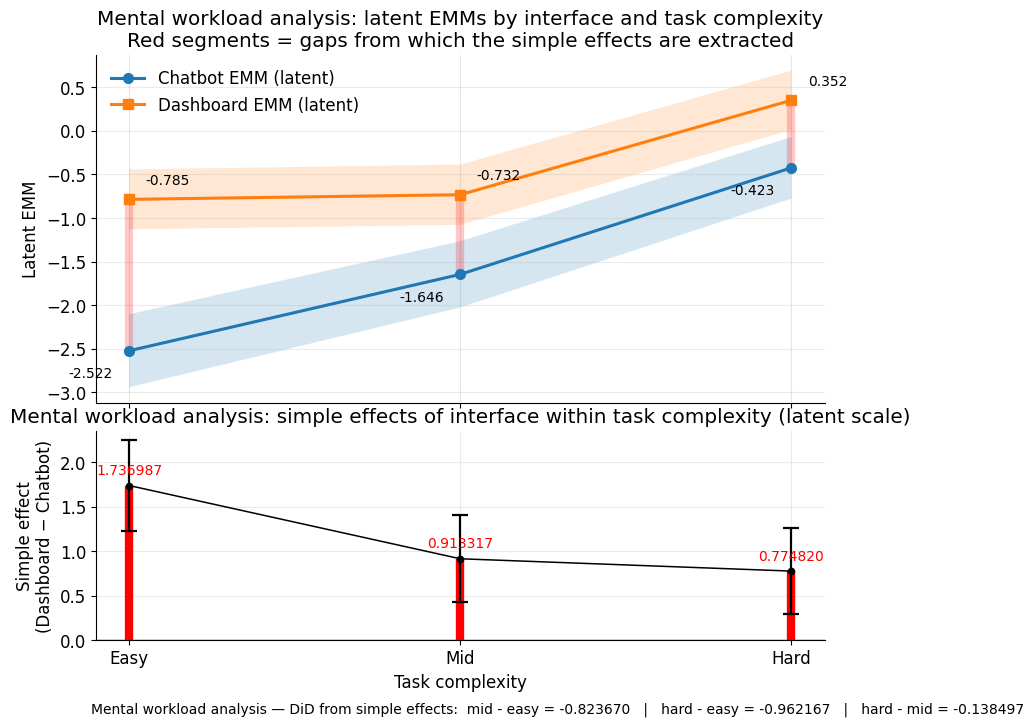

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# SETTINGS
# ============================================================
SAVE_FIG = False
OUTPUT_PATH = "mental_workload_analysis_latent_emms_and_simple_effects.png"

# ============================================================
# DATA
# ============================================================
complexity = ["Easy", "Mid", "Hard"]
x = np.arange(len(complexity))

# ------------------------------------------------------------
# TOP PANEL: latent EMMs (section 8a / 8c)
# ------------------------------------------------------------
chatbot_emm  = np.array([-2.522327, -1.645629, -0.423309])
chatbot_low  = np.array([-2.941285, -2.025781, -0.776946])
chatbot_high = np.array([-2.103370, -1.265477, -0.069672])

dashboard_emm  = np.array([-0.785341, -0.732312,  0.351511])
dashboard_low  = np.array([-1.128471, -1.078277,  0.011759])
dashboard_high = np.array([-0.442210, -0.386348,  0.691262])

# ------------------------------------------------------------
# BOTTOM PANEL: simple effects (section 4, latent scale)
# ------------------------------------------------------------
simple_effects = np.array([1.736987, 0.913317, 0.774820])
simple_low     = np.array([1.226041, 0.424610, 0.290733])
simple_high    = np.array([2.247932, 1.402024, 1.258907])

# ------------------------------------------------------------
# DiD values (section 5)
# ------------------------------------------------------------
did_text = (
    "Mental workload analysis — DiD from simple effects:  "
    "mid - easy = -0.823670   |   "
    "hard - easy = -0.962167   |   "
    "hard - mid = -0.138497"
)

# ============================================================
# ERROR BARS FOR SIMPLE EFFECTS ONLY
# ============================================================
simple_yerr = np.vstack([
    simple_effects - simple_low,
    simple_high - simple_effects
])

# ============================================================
# STYLE
# ============================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
})

# ============================================================
# FIGURE
# ============================================================
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(9.4, 7.6),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.2], "hspace": 0.10}
)

# ============================================================
# TOP PANEL: EMMs with shaded CIs
# ============================================================
ax1.fill_between(
    x, chatbot_low, chatbot_high,
    alpha=0.18,
    zorder=1
)
ax1.fill_between(
    x, dashboard_low, dashboard_high,
    alpha=0.18,
    zorder=1
)

# Red vertical segments = cellwise dashboard - chatbot gap
for xi, yc, yd in zip(x, chatbot_emm, dashboard_emm):
    ax1.vlines(
        xi, yc, yd,
        color="red",
        linewidth=6,
        alpha=0.22,
        zorder=2
    )

ax1.plot(
    x, chatbot_emm,
    marker="o",
    linewidth=2.2,
    markersize=7,
    label="Chatbot EMM (latent)",
    zorder=3
)
ax1.plot(
    x, dashboard_emm,
    marker="s",
    linewidth=2.2,
    markersize=7,
    label="Dashboard EMM (latent)",
    zorder=3
)

for xi in x:
    ax1.axvline(xi, color="0.90", linewidth=0.8, zorder=0)
    ax2.axvline(xi, color="0.92", linewidth=0.8, zorder=0)

for xi, yc, yd in zip(x, chatbot_emm, dashboard_emm):
    ax1.text(xi - 0.05, yc - 0.18, f"{yc:.3f}", ha="right", va="top", fontsize=10)
    ax1.text(xi + 0.05, yd + 0.14, f"{yd:.3f}", ha="left", va="bottom", fontsize=10)

ax1.set_ylabel("Latent EMM")
ax1.set_title(
    "Mental workload analysis: latent EMMs by interface and task complexity\n"
    "Red segments = gaps from which the simple effects are extracted"
)
ax1.legend(frameon=False, loc="upper left")
ax1.yaxis.grid(True, alpha=0.25)
ax1.margins(x=0.08)

# ============================================================
# BOTTOM PANEL: SIMPLE EFFECTS + whisker CIs
# ============================================================
ax2.axhline(0, color="0.25", linewidth=1.0)

for xi, yi in zip(x, simple_effects):
    ax2.vlines(
        xi, 0, yi,
        color="red",
        linewidth=6,
        alpha=1.0,
        zorder=2
    )

ax2.errorbar(
    x, simple_effects,
    yerr=simple_yerr,
    fmt="none",
    ecolor="black",
    elinewidth=1.6,
    capsize=6,
    capthick=1.6,
    zorder=3
)

ax2.plot(
    x, simple_effects,
    color="black",
    linewidth=1.1,
    marker="o",
    markersize=4.5,
    zorder=4
)

for xi, yi in zip(x, simple_effects):
    ax2.text(
        xi, yi + 0.09,
        f"{yi:.6f}",
        color="red",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax2.set_ylabel("Simple effect\n(Dashboard − Chatbot)")
ax2.set_xlabel("Task complexity")
ax2.set_xticks(x, complexity)
ax2.set_title("Mental workload analysis: simple effects of interface within task complexity (latent scale)")
ax2.yaxis.grid(True, alpha=0.25)
ax2.set_ylim(0, 2.35)

fig.text(
    0.12, 0.01,
    did_text,
    ha="left",
    va="bottom",
    fontsize=10
)

fig.tight_layout(rect=[0, 0.04, 1, 1])

# ============================================================
# OUTPUT
# ============================================================
if SAVE_FIG:
    fig.savefig(OUTPUT_PATH, dpi=220, bbox_inches="tight")
    print(f"Saved: {OUTPUT_PATH}")
else:
    plt.show()